<a href="https://colab.research.google.com/github/hawa1983/Capstone_Network/blob/main/ibx_capstone_v8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAPSTONE NOTEBOOK OUTLINE

## 1. Title & Overview



# NYC Subway Ridership & IBX Impact Analysis

## Capstone Project

### Author: Fomba Kassoh  
### Course: DATA 698 / Capstone  
### Date: March 18, 2026

## Project Overview

This project analyzes the determinants of NYC subway ridership at the station-complex level and applies predictive modeling and clustering techniques to evaluate potential impacts of the Interborough Express (IBX).

## Research Objectives

- Identify key drivers of subway ridership
- Quantify the role of transit accessibility, demographics, and built environment
- Develop predictive models for ridership
- Classify station typologies using unsupervised learning
- Apply findings to IBX corridor analysis

# Section A — Station Catchment Area Construction (0.5-Mile Buffers)

## **Purpose:**
Create a unified transit stops dataset by merging GTFS and IBX stop data, enriching it with official MTA station complex information, and generating fallback “self-defined” complexes for IBX stops not found in the official data.


In [11]:
# =========================================================
# GTFS + IBX + Station Complex Integration Utility
#
# Purpose:
#   Downloads the official GTFS stops file and an IBX stop coordinate file
#   from GitHub, normalizes their structure, merges them into a single
#   unified stops dataset, and appends official MTA station complex info.
#
# Key Features:
#   • Automatically converts GitHub "blob" URLs to raw file URLs.
#   • Validates that downloaded content is not HTML.
#   • Loads text/CSV files into pandas DataFrames.
#   • Normalizes latitude, longitude, and location_type fields.
#   • Appends IBX stops to the primary GTFS stops dataset.
#   • Resolves duplicate stop_id values (IBX entries override original).
#   • Merges stop_id -> station_complex_id crosswalk from attached MTA file.
#   • For IBX stops not found in the official complex file, creates a
#     self-contained station-complex record using the IBX stop's own fields.
#
# Data Sources:
#   - GTFS stops.txt (main system stops)
#   - IBX stop coordinates file (custom/extension stops)
#   - Attached MTA Subway Stations and Complexes CSV
#
# Processing Steps:
#   1. Convert GitHub blob links to raw URLs when necessary.
#   2. Download and parse CSV content into pandas.
#   3. Enforce numeric formatting for stop_lat and stop_lon.
#   4. Standardize location_type (default = 0 if missing).
#   5. Concatenate GTFS + IBX datasets and remove duplicate stop_id entries.
#   6. Load station complex file and explode GTFS Stop IDs into one stop_id per row.
#   7. Merge station complex metadata into combined stops file.
#   8. For unmatched IBX stops, assign stop_id as station_complex_id and
#      use stop attributes as complex attributes.
#   9. Export merged result to "stops_with_ibx_and_complex.csv".
#
# Output:
#   stops_with_ibx_and_complex.csv
#
# Notes:
#   - Duplicate stop_ids retain the last occurrence (IBX overrides GTFS).
#   - Official subway stops use MTA Complex ID where available.
#   - IBX stops become their own station complex when no official complex exists.
#   - station_complex_id will therefore be mixed-type (numeric for MTA subway
#     complexes, string for IBX self-defined complexes).
# =========================================================

from __future__ import annotations

import re
from io import StringIO

import requests
import pandas as pd


def github_blob_to_raw(url: str) -> str:
    """
    Convert a standard GitHub 'blob' URL into a raw content URL.
    """
    m = re.match(r"^https?://github\.com/([^/]+)/([^/]+)/blob/([^/]+)/(.*)$", url)
    if not m:
        return url

    org, repo, branch, path = m.groups()
    return f"https://raw.githubusercontent.com/{org}/{repo}/{branch}/{path}"


def read_text_csv(url: str, *, timeout: int = 60) -> pd.DataFrame:
    """
    Download a CSV/text file from a URL and load it into a pandas DataFrame.
    """
    raw_url = github_blob_to_raw(url)
    r = requests.get(raw_url, timeout=timeout)
    r.raise_for_status()

    head = r.text[:2000].lstrip().lower()
    if head.startswith("<!doctype html") or "<html" in head[:200]:
        raise ValueError(
            "URL did not resolve to raw text content (looks like HTML). "
            "Use a raw.githubusercontent.com URL."
        )

    return pd.read_csv(
        StringIO(r.text),
        sep=",",
        encoding="utf-8",
        on_bad_lines="warn",
        engine="c",
        low_memory=False,
    )


# ----------------------------
# Load GTFS and IBX stop files
# ----------------------------

stops_df = read_text_csv(
    "https://github.com/hawa1983/Capstone/blob/main/stops.txt"
)

ibx_df = read_text_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ibx%20stops%20coordinates.txt"
)

# Attached MTA station complex crosswalk
complex_file_path = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/MTA_Subway_Stations_and_Complexes.csv"
complex_df = pd.read_csv(complex_file_path)


# ----------------------------
# Normalize GTFS + IBX Fields
# ----------------------------

for df in (stops_df, ibx_df):
    df["stop_id"] = df["stop_id"].astype(str).str.strip()
    df["stop_name"] = df["stop_name"].astype(str).str.strip()

    df["stop_lat"] = pd.to_numeric(df["stop_lat"], errors="coerce")
    df["stop_lon"] = pd.to_numeric(df["stop_lon"], errors="coerce")

    if "location_type" in df.columns:
        df["location_type"] = (
            pd.to_numeric(df["location_type"], errors="coerce")
            .fillna(0)
            .astype(int)
        )
    else:
        df["location_type"] = 0


# Keep a set of IBX stop_ids so we can identify them after merging
ibx_stop_ids = set(ibx_df["stop_id"].astype(str).str.strip())


# ----------------------------
# Merge GTFS + IBX Stops
# ----------------------------

combined_stops = pd.concat([stops_df, ibx_df], ignore_index=True)

combined_stops_df = (
    combined_stops
    .drop_duplicates(subset=["stop_id"], keep="last")
    .reset_index(drop=True)
)


# ----------------------------
# Build official stop_id -> station_complex_id crosswalk
# ----------------------------

complex_cols = [
    "Complex ID",
    "Stop Name",
    "Display Name",
    "Constituent Station Names",
    "Station IDs",
    "GTFS Stop IDs",
    "Borough",
    "CBD",
    "Daytime Routes",
    "Structure Type",
    "Latitude",
    "Longitude",
    "ADA",
    "ADA Notes",
]

complex_xwalk = complex_df[complex_cols].copy()

complex_xwalk = complex_xwalk.rename(columns={
    "Complex ID": "station_complex_id",
    "Stop Name": "complex_stop_name",
    "Display Name": "complex_display_name",
    "Constituent Station Names": "constituent_station_names",
    "Station IDs": "station_ids",
    "GTFS Stop IDs": "gtfs_stop_ids",
    "Borough": "borough",
    "CBD": "cbd",
    "Daytime Routes": "daytime_routes",
    "Structure Type": "structure_type",
    "Latitude": "complex_latitude",
    "Longitude": "complex_longitude",
    "ADA": "ada",
    "ADA Notes": "ada_notes",
})

complex_xwalk["station_complex_id"] = pd.to_numeric(
    complex_xwalk["station_complex_id"], errors="coerce"
)

complex_xwalk["gtfs_stop_ids"] = complex_xwalk["gtfs_stop_ids"].astype(str).str.strip()
complex_xwalk["stop_id"] = complex_xwalk["gtfs_stop_ids"].str.split(r"\s*;\s*")
complex_xwalk = complex_xwalk.explode("stop_id")

complex_xwalk["stop_id"] = complex_xwalk["stop_id"].astype(str).str.strip()

complex_xwalk = complex_xwalk[
    complex_xwalk["stop_id"].notna() &
    (complex_xwalk["stop_id"] != "") &
    (complex_xwalk["stop_id"].str.lower() != "nan")
].copy()

complex_xwalk = (
    complex_xwalk
    .drop_duplicates(subset=["stop_id"], keep="first")
    .reset_index(drop=True)
)

complex_xwalk = complex_xwalk[
    [
        "stop_id",
        "station_complex_id",
        "complex_stop_name",
        "complex_display_name",
        "constituent_station_names",
        "station_ids",
        "borough",
        "cbd",
        "daytime_routes",
        "structure_type",
        "complex_latitude",
        "complex_longitude",
        "ada",
        "ada_notes",
    ]
]


# ----------------------------
# Merge official station complex info into stops
# ----------------------------

combined_stops_with_complex_df = combined_stops_df.merge(
    complex_xwalk,
    on="stop_id",
    how="left",
    validate="m:1"
)


# ----------------------------
# Identify IBX rows
# ----------------------------

combined_stops_with_complex_df["is_ibx"] = (
    combined_stops_with_complex_df["stop_id"].isin(ibx_stop_ids)
)


# ----------------------------
# For IBX stops missing official complex info,
# use the stop's own fields as its station complex
# ----------------------------

ibx_mask = (
    combined_stops_with_complex_df["is_ibx"] &
    combined_stops_with_complex_df["station_complex_id"].isna()
)

# station_complex_id becomes the IBX stop_id
combined_stops_with_complex_df.loc[ibx_mask, "station_complex_id"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_id"].astype(str)
)

# use stop-level naming as complex-level naming
combined_stops_with_complex_df.loc[ibx_mask, "complex_stop_name"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_name"]
)
combined_stops_with_complex_df.loc[ibx_mask, "complex_display_name"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_name"]
)
combined_stops_with_complex_df.loc[ibx_mask, "constituent_station_names"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_name"]
)
combined_stops_with_complex_df.loc[ibx_mask, "station_ids"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_id"]
)

# use stop coordinates as complex coordinates
combined_stops_with_complex_df.loc[ibx_mask, "complex_latitude"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_lat"]
)
combined_stops_with_complex_df.loc[ibx_mask, "complex_longitude"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_lon"]
)

# optional defaults for other complex fields
combined_stops_with_complex_df.loc[ibx_mask, "daytime_routes"] = (
    combined_stops_with_complex_df.loc[ibx_mask, "stop_id"]
)
combined_stops_with_complex_df.loc[ibx_mask, "structure_type"] = "IBX"
combined_stops_with_complex_df.loc[ibx_mask, "ada_notes"] = (
    "Synthetic station complex created from IBX stop attributes"
)

# If cbd/ada/borough are missing for IBX, leave them as NaN unless you want defaults
# Example defaults:
# combined_stops_with_complex_df.loc[ibx_mask, "cbd"] = 0
# combined_stops_with_complex_df.loc[ibx_mask, "ada"] = 0


# ----------------------------
# Final cleanup
# ----------------------------

# Convert to object so numeric subway complex IDs and string IBX IDs can coexist
combined_stops_with_complex_df["station_complex_id"] = (
    combined_stops_with_complex_df["station_complex_id"].astype(object)
)

# Optional: create a unified station-complex name field
combined_stops_with_complex_df["station_complex_name"] = (
    combined_stops_with_complex_df["complex_display_name"]
    .fillna(combined_stops_with_complex_df["complex_stop_name"])
    .fillna(combined_stops_with_complex_df["stop_name"])
)

# Optional: create a single lat/lon for complex geometry
combined_stops_with_complex_df["station_complex_lat"] = (
    pd.to_numeric(combined_stops_with_complex_df["complex_latitude"], errors="coerce")
)
combined_stops_with_complex_df["station_complex_lon"] = (
    pd.to_numeric(combined_stops_with_complex_df["complex_longitude"], errors="coerce")
)


# ----------------------------
# Save Final File
# ----------------------------

output_file = "stops_with_ibx_and_complex.csv"
combined_stops_with_complex_df.to_csv(output_file, index=False)

print(f"File saved as: {output_file}")

print("\nRow count:", len(combined_stops_with_complex_df))
print("Unique stop_id count:", combined_stops_with_complex_df["stop_id"].nunique())
print(
    "Stops matched to official station_complex_id:",
    combined_stops_with_complex_df.loc[
        ~combined_stops_with_complex_df["is_ibx"], "station_complex_id"
    ].notna().sum()
)
print(
    "IBX stops assigned self station_complex_id:",
    combined_stops_with_complex_df.loc[
        combined_stops_with_complex_df["is_ibx"], "station_complex_id"
    ].notna().sum()
)

display(combined_stops_with_complex_df.tail(25))

File saved as: stops_with_ibx_and_complex.csv

Row count: 1516
Unique stop_id count: 1516
Stops matched to official station_complex_id: 496
IBX stops assigned self station_complex_id: 19


/tmp/ipykernel_35713/2370345122.py:263: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['IBX_1' 'IBX_2' 'IBX_3' 'IBX_4' 'IBX_5' 'IBX_6' 'IBX_7' 'IBX_8' 'IBX_9'
 'IBX_10' 'IBX_11' 'IBX_12' 'IBX_13' 'IBX_14' 'IBX_15' 'IBX_16' 'IBX_17'
 'IBX_18' 'IBX_19']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_stops_with_complex_df.loc[ibx_mask, "station_complex_id"] = (


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,station_complex_id,complex_stop_name,complex_display_name,constituent_station_names,...,daytime_routes,structure_type,complex_latitude,complex_longitude,ada,ada_notes,is_ibx,station_complex_name,station_complex_lat,station_complex_lon
1491,S30,Tompkinsville,40.636949,-74.074835,1,NaN,502.0,Tompkinsville,Tompkinsville (SIR),Tompkinsville,...,SIR,At Grade,40.636949,-74.074835,0.0,NaN,False,Tompkinsville (SIR),40.636949,-74.074835
1492,S30N,Tompkinsville,40.636949,-74.074835,0,S30,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Tompkinsville,NaN,NaN
1493,S30S,Tompkinsville,40.636949,-74.074835,0,S30,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,Tompkinsville,NaN,NaN
1494,S31,St George,40.643748,-74.073643,1,NaN,501.0,St George,St George (SIR),St George,...,SIR,Open Cut,40.643748,-74.073643,1.0,NaN,False,St George (SIR),40.643748,-74.073643
1495,S31N,St George,40.643748,-74.073643,0,S31,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,St George,NaN,NaN
1496,S31S,St George,40.643748,-74.073643,0,S31,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,St George,NaN,NaN
1497,IBX_1,Roosevelt Avenue,40.746500,-73.891000,1,NaN,IBX_1,Roosevelt Avenue,Roosevelt Avenue,Roosevelt Avenue,...,IBX_1,IBX,40.746500,-73.891000,NaN,Synthetic station complex created from IBX sto...,True,Roosevelt Avenue,40.746500,-73.891000
1498,IBX_2,Grand Avenue,40.728900,-73.889700,1,NaN,IBX_2,Grand Avenue,Grand Avenue,Grand Avenue,...,IBX_2,IBX,40.728900,-73.889700,NaN,Synthetic station complex created from IBX sto...,True,Grand Avenue,40.728900,-73.889700
1499,IBX_3,Eliot Avenue,40.725500,-73.879200,1,NaN,IBX_3,Eliot Avenue,Eliot Avenue,Eliot Avenue,...,IBX_3,IBX,40.725500,-73.879200,NaN,Synthetic station complex created from IBX sto...,True,Eliot Avenue,40.725500,-73.879200
1500,IBX_4,Metropolitan Avenue,40.711900,-73.889600,1,NaN,IBX_4,Metropolitan Avenue,Metropolitan Avenue,Metropolitan Avenue,...,IBX_4,IBX,40.711900,-73.889600,NaN,Synthetic station complex created from IBX sto...,True,Metropolitan Avenue,40.711900,-73.889600


## Filtering GTFS Stations from the Combined Stops Dataset

**Purpose:**

Create a station complex–level dataset by collapsing the merged stops file to one unique row per `station_complex_id`, retaining representative complex attributes for use in complex-level ridership analysis.



In [12]:
# =========================================================
# Station Complex-Level Extraction
#
# Purpose:
#   Collapse the GTFS + IBX stops dataset to one row per
#   station_complex_id for use with complex-level ridership.
#
# Methodology:
#   1. Ensure station_complex_id exists.
#   2. Select representative fields for the complex.
#   3. Drop duplicate complex records.
#
# Output:
#   station_complex_df
#     One row per station complex.
# =========================================================


# Ensure station_complex_id exists
if "station_complex_id" not in combined_stops_with_complex_df.columns:
    raise ValueError("station_complex_id column not found.")


# Select representative fields
complex_cols = [
    "station_complex_id",
    "station_complex_name",
    "station_complex_lat",
    "station_complex_lon",
    "borough",
    "daytime_routes",
    "structure_type",
    "ada",
    "cbd"
]

# Keep only columns that actually exist
complex_cols = [c for c in complex_cols if c in combined_stops_with_complex_df.columns]


# Create station complex dataset
station_complex_df = (
    combined_stops_with_complex_df[complex_cols]
    .drop_duplicates(subset=["station_complex_id"])
    .reset_index(drop=True)
)


# Display complex-level dataset
display(station_complex_df)


# Optional diagnostics
print("Number of station complexes:", len(station_complex_df))
print("Unique station_complex_id:", station_complex_df["station_complex_id"].nunique())

,station_complex_id,station_complex_name,station_complex_lat,station_complex_lon,borough,daytime_routes,structure_type,ada,cbd
0,293.0,Van Cortlandt Park-242 St (1),40.889248,-73.898583,Bx,1,Elevated,0.0,False
1,NaN,Van Cortlandt Park-242 St,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,294.0,238 St (1),40.884667,-73.900870,Bx,1,Elevated,0.0,False
3,295.0,231 St (1),40.878856,-73.904834,Bx,1,Elevated,1.0,False
4,296.0,Marble Hill-225 St (1),40.874561,-73.909831,M,1,Elevated,0.0,False
...,...,...,...,...,...,...,...,...,...
460,IBX_15,McDonald Avenue,40.625500,-73.977700,NaN,IBX_15,IBX,NaN,NaN
461,IBX_16,New Utrecht Avenue,40.620900,-73.990300,NaN,IBX_16,IBX,NaN,NaN
462,IBX_17,8 Avenue,40.637200,-74.001700,NaN,IBX_17,IBX,NaN,NaN
463,IBX_18,4 Avenue,40.645200,-74.011300,NaN,IBX_18,IBX,NaN,NaN


Number of station complexes: 465
Unique station_complex_id: 464


## Validating and Cleaning GTFS Stop Coordinates

**Purpose:**

Validate and clean station complex coordinates by enforcing required latitude and longitude fields, converting them to numeric format, removing missing or out-of-range values, and producing a geospatially reliable complex-level dataset for mapping and spatial analysis.


In [13]:
# =========================================================
# Station Complex Coordinate Validation & Cleaning
#
# Purpose:
#   Ensures all station complexes in the complex-level dataset
#   contain valid geographic coordinates suitable for
#   spatial analysis and mapping.
#
# Validation Steps:
#
#   1. Required Column Check
#      - Verifies presence of:
#           • station_complex_lat (latitude)
#           • station_complex_lon (longitude)
#      - Raises a ValueError if either column is missing.
#
#   2. Numeric Conversion
#      - Converts station_complex_lat and station_complex_lon
#        to numeric types.
#      - Invalid or malformed values are coerced to NaN.
#
#   3. Geographic Bounds Validation
#      - Latitude must be within [-90, 90]
#      - Longitude must be within [-180, 180]
#      - Rows failing these checks (or containing NaN) are flagged.
#
#   4. Row Filtering
#      - Removes rows with:
#           • Missing coordinates
#           • Non-numeric values
#           • Out-of-range latitude/longitude
#      - Produces a clean complex-level DataFrame ready for
#        geospatial processing.
#
# Output:
#   station_complex_df (cleaned)
#
# Notes:
#   - Prevents downstream spatial errors (buffer creation, projections, joins).
#   - Ensures coordinate integrity before geometry construction.
#   - Designed for reproducible transit network preprocessing.
# =========================================================


# --------------------------------------------
# Validate Required Coordinate Columns
# --------------------------------------------

# Define the set of required coordinate columns.
required = {"station_complex_lat", "station_complex_lon"}

# Determine whether any required columns are missing.
missing = required - set(station_complex_df.columns)

# If any required columns are missing, raise an error.
if missing:
    raise ValueError(f"Missing required columns: {missing}")


# --------------------------------------------
# Convert Coordinates to Numeric
# --------------------------------------------

# Convert complex latitude and longitude to numeric.
# Invalid values are coerced to NaN.
station_complex_df["station_complex_lat"] = pd.to_numeric(
    station_complex_df["station_complex_lat"], errors="coerce"
)
station_complex_df["station_complex_lon"] = pd.to_numeric(
    station_complex_df["station_complex_lon"], errors="coerce"
)


# --------------------------------------------
# Validate Geographic Bounds
# --------------------------------------------

# Latitude must be between -90 and 90.
# Longitude must be between -180 and 180.
valid = (
    station_complex_df["station_complex_lat"].between(-90, 90)
    & station_complex_df["station_complex_lon"].between(-180, 180)
)


# --------------------------------------------
# Filter Out Invalid Rows
# --------------------------------------------

# Keep only rows with valid coordinates.
station_complex_df = station_complex_df.loc[valid].copy()


# --------------------------------------------
# Display Cleaned Dataset
# --------------------------------------------

display(station_complex_df)

,station_complex_id,station_complex_name,station_complex_lat,station_complex_lon,borough,daytime_routes,structure_type,ada,cbd
0,293.0,Van Cortlandt Park-242 St (1),40.889248,-73.898583,Bx,1,Elevated,0.0,False
2,294.0,238 St (1),40.884667,-73.900870,Bx,1,Elevated,0.0,False
3,295.0,231 St (1),40.878856,-73.904834,Bx,1,Elevated,1.0,False
4,296.0,Marble Hill-225 St (1),40.874561,-73.909831,M,1,Elevated,0.0,False
5,297.0,215 St (1),40.869444,-73.915279,M,1,Elevated,0.0,False
...,...,...,...,...,...,...,...,...,...
460,IBX_15,McDonald Avenue,40.625500,-73.977700,NaN,IBX_15,IBX,NaN,NaN
461,IBX_16,New Utrecht Avenue,40.620900,-73.990300,NaN,IBX_16,IBX,NaN,NaN
462,IBX_17,8 Avenue,40.637200,-74.001700,NaN,IBX_17,IBX,NaN,NaN
463,IBX_18,4 Avenue,40.645200,-74.011300,NaN,IBX_18,IBX,NaN,NaN


## Station Complex GeoDataFrame Creation (WGS84)

**Purpose:**
Convert the cleaned station complex dataset into a GeoDataFrame with point geometries in WGS84, enabling spatial analysis, mapping, and downstream geospatial operations.



In [14]:
# =========================================================
# Station Complex GeoDataFrame Creation (WGS84)
#
# Purpose:
#   Converts validated station complex records into a GeoDataFrame
#   with spatial point geometry for geospatial analysis.
#
# Methodology:
#   1. Complex-Level Input
#      - Uses the cleaned station_complex_df dataset.
#      - Assumes one row per station_complex_id.
#      - Ensures coordinates have already passed validation checks.
#
#   2. Geometry Construction
#      - Uses GeoPandas points_from_xy():
#           • x = station_complex_lon (longitude)
#           • y = station_complex_lat (latitude)
#      - Assigns CRS = "EPSG:4326" (WGS84 geographic coordinate system).
#
#   3. GeoDataFrame Creation
#      - Wraps the station complex DataFrame into a GeoDataFrame.
#      - Adds a geometry column containing Point objects.
#
# Output:
#   station_complex_gdf
#     A GeoDataFrame of station complexes with valid spatial geometry.
#
# Notes:
#   - EPSG:4326 is appropriate for storage and visualization.
#   - For distance or buffer calculations, reproject to a projected CRS
#     (e.g., EPSG:2263 for NYC / NAD83 Long Island ft).
#   - Designed to support downstream spatial joins and buffer analysis.
# =========================================================

import geopandas as gpd

# --------------------------------------------
# Validate required coordinate columns
# --------------------------------------------

required = {"station_complex_lat", "station_complex_lon"}
missing = required - set(station_complex_df.columns)

if missing:
    raise ValueError(f"Missing required columns: {missing}")


# --------------------------------------------
# Ensure coordinates are numeric
# --------------------------------------------

station_complex_df["station_complex_lat"] = pd.to_numeric(
    station_complex_df["station_complex_lat"], errors="coerce"
)
station_complex_df["station_complex_lon"] = pd.to_numeric(
    station_complex_df["station_complex_lon"], errors="coerce"
)


# --------------------------------------------
# Keep only valid coordinates
# --------------------------------------------

valid = (
    station_complex_df["station_complex_lat"].between(-90, 90)
    & station_complex_df["station_complex_lon"].between(-180, 180)
)

station_complex_df = station_complex_df.loc[valid].copy()


# --------------------------------------------
# Convert to GeoDataFrame
# --------------------------------------------

station_complex_gdf = gpd.GeoDataFrame(
    station_complex_df,
    geometry=gpd.points_from_xy(
        station_complex_df["station_complex_lon"],
        station_complex_df["station_complex_lat"],
        crs="EPSG:4326"
    ),
)

# Display the spatial station complex dataset
display(station_complex_gdf)

,station_complex_id,station_complex_name,station_complex_lat,station_complex_lon,borough,daytime_routes,structure_type,ada,cbd,geometry
0,293.0,Van Cortlandt Park-242 St (1),40.889248,-73.898583,Bx,1,Elevated,0.0,False,POINT (-73.89858 40.88925)
2,294.0,238 St (1),40.884667,-73.900870,Bx,1,Elevated,0.0,False,POINT (-73.90087 40.88467)
3,295.0,231 St (1),40.878856,-73.904834,Bx,1,Elevated,1.0,False,POINT (-73.90483 40.87886)
4,296.0,Marble Hill-225 St (1),40.874561,-73.909831,M,1,Elevated,0.0,False,POINT (-73.90983 40.87456)
5,297.0,215 St (1),40.869444,-73.915279,M,1,Elevated,0.0,False,POINT (-73.91528 40.86944)
...,...,...,...,...,...,...,...,...,...,...
460,IBX_15,McDonald Avenue,40.625500,-73.977700,NaN,IBX_15,IBX,NaN,NaN,POINT (-73.9777 40.6255)
461,IBX_16,New Utrecht Avenue,40.620900,-73.990300,NaN,IBX_16,IBX,NaN,NaN,POINT (-73.9903 40.6209)
462,IBX_17,8 Avenue,40.637200,-74.001700,NaN,IBX_17,IBX,NaN,NaN,POINT (-74.0017 40.6372)
463,IBX_18,4 Avenue,40.645200,-74.011300,NaN,IBX_18,IBX,NaN,NaN,POINT (-74.0113 40.6452)


## Reprojecting Station Data to a Local Coordinate System

**Coordinate Reference System (CRS) Reprojection**

**Purpose:**
Reproject the station complex GeoDataFrame from WGS84 (EPSG:4326) to a projected CRS (EPSG:2263) to enable accurate distance, area, and spatial analysis using linear units (feet).



In [15]:
# ---------------------------------------------------------
# Reproject Station Complex GeoDataFrame to a Projected CRS
# ---------------------------------------------------------

# =========================================================
# Coordinate Reference System (CRS) Reprojection
#
# Purpose:
#   Converts station complex geometries from geographic
#   coordinates (latitude/longitude in degrees) to a projected
#   coordinate system suitable for accurate distance and
#   area calculations.
#
# Background:
#   - Original CRS: EPSG:4326 (WGS84)
#       • Units: Degrees
#       • Ideal for GPS and web mapping
#       • Not appropriate for linear distance measurement
#
#   - Target CRS: EPSG:2263
#       • NAD83 / New York Long Island (State Plane)
#       • Units: Feet
#       • Optimized for NYC spatial analysis
#
# Why Reproject?
#   Geographic CRS (degrees) distort distance calculations.
#   Projected CRS (feet/meters) provide linear measurement units,
#   making them appropriate for:
#       • Buffer creation (e.g., 0.5 mile radius)
#       • Distance-based joins
#       • Clustering analysis
#       • Local mapping accuracy
#
# Method:
#   Uses GeoDataFrame.to_crs() to transform geometry coordinates.
#   Attribute columns remain unchanged.
#
# Output:
#   station_complex_proj
#     Station complex GeoDataFrame projected to EPSG:2263 (feet).
#
# Notes:
#   - Always verify the source CRS before reprojecting.
#   - All subsequent spatial distance calculations should use
#     this projected CRS to ensure accuracy.
# =========================================================


# --------------------------------------------
# Verify CRS exists before reprojection
# --------------------------------------------

if station_complex_gdf.crs is None:
    raise ValueError(
        "station_complex_gdf has no CRS defined. "
        "Ensure CRS='EPSG:4326' when creating the GeoDataFrame."
    )


# --------------------------------------------
# Reproject to NYC State Plane (EPSG:2263)
# --------------------------------------------

station_complex_proj = station_complex_gdf.to_crs("EPSG:2263")


# After transformation:
# - Geometry coordinates are no longer latitude/longitude
# - Coordinates are projected X/Y values in feet
# - Attribute columns remain unchanged
# - Only geometry is mathematically transformed


# --------------------------------------------
# Display projected GeoDataFrame
# --------------------------------------------

display(station_complex_proj)


# Optional diagnostics
print("Original CRS:", station_complex_gdf.crs)
print("Projected CRS:", station_complex_proj.crs)
print("Number of station complexes:", len(station_complex_proj))

,station_complex_id,station_complex_name,station_complex_lat,station_complex_lon,borough,daytime_routes,structure_type,ada,cbd,geometry
0,293.0,Van Cortlandt Park-242 St (1),40.889248,-73.898583,Bx,1,Elevated,0.0,False,POINT (1012291.156 263271.208)
2,294.0,238 St (1),40.884667,-73.900870,Bx,1,Elevated,0.0,False,POINT (1011660.704 261601.442)
3,295.0,231 St (1),40.878856,-73.904834,Bx,1,Elevated,1.0,False,POINT (1010566.908 259483.047)
4,296.0,Marble Hill-225 St (1),40.874561,-73.909831,M,1,Elevated,0.0,False,POINT (1009186.665 257916.747)
5,297.0,215 St (1),40.869444,-73.915279,M,1,Elevated,0.0,False,POINT (1007681.798 256050.919)
...,...,...,...,...,...,...,...,...,...,...
460,IBX_15,McDonald Avenue,40.625500,-73.977700,NaN,IBX_15,IBX,NaN,NaN,POINT (990440.272 167163.683)
461,IBX_16,New Utrecht Avenue,40.620900,-73.990300,NaN,IBX_16,IBX,NaN,NaN,POINT (986942.815 165487.143)
462,IBX_17,8 Avenue,40.637200,-74.001700,NaN,IBX_17,IBX,NaN,NaN,POINT (983778.179 171425.523)
463,IBX_18,4 Avenue,40.645200,-74.011300,NaN,IBX_18,IBX,NaN,NaN,POINT (981114.151 174340.339)


Original CRS: EPSG:4326
Projected CRS: EPSG:2263
Number of station complexes: 464


## NYC Block Group Boundary Preparation (TIGER/Line 2020)

**Purpose:**
Prepare New York City Census block group boundaries by downloading 2020 TIGER/Line shapefiles, filtering to the five boroughs, and reprojecting them to match the station complex CRS for accurate spatial joins, buffer analysis, and other geospatial operations.


In [16]:
# =========================================================
# NYC Block Group Boundary Preparation (TIGER/Line 2020)
#
# Purpose:
#   Downloads and prepares U.S. Census TIGER/Line 2020 Block Group
#   boundary geometries for New York City to support spatial joins
#   and station complex buffer analysis.
#
# Data Source:
#   U.S. Census Bureau – TIGER/Line Shapefiles (2020)
#   Geography: Block Groups (BG)
#   State: New York (FIPS = 36)
#
# Processing Steps:
#
#   1. Load Statewide Block Groups
#      - Reads NY block groups directly from the TIGER 2020
#        zipped shapefile URL using GeoPandas.
#      - Validates row count, CRS, and schema.
#
#   2. Filter to NYC Counties
#      - Keeps only five borough counties using COUNTYFP:
#            005 = Bronx
#            047 = Kings (Brooklyn)
#            061 = New York (Manhattan)
#            081 = Queens
#            085 = Richmond (Staten Island)
#      - Ensures STATEFP == "36" (New York State).
#
#   3. Reproject to Match Station Complex CRS
#      - Converts geometries to the same projected CRS as
#        station_complex_proj (typically EPSG:2263 – NAD83 /
#        NY Long Island, feet).
#      - Required for:
#            • Buffer analysis
#            • Spatial overlays
#            • Distance-based joins
#
# Outputs:
#   bg_nyc        → NYC block groups in original CRS
#   bg_nyc_proj   → NYC block groups projected to match
#                   station complex CRS
#
# Notes:
#   - Always ensure CRS alignment before spatial operations.
#   - Using a projected CRS (feet/meters) prevents distortion
#     in area and distance calculations.
#   - TIGER 2020 boundaries align with ACS 2020 5-year data.
# =========================================================

import geopandas as gpd
import pandas as pd

# ---------------------------------------------------------
# 1) Load 2020 TIGER/Line Block Groups for New York State
# ---------------------------------------------------------

tiger_bg_ny_url = "https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_36_bg.zip"

bg_ny = gpd.read_file(tiger_bg_ny_url)

# Quick validation
print("Loaded rows:", len(bg_ny))
print("CRS:", bg_ny.crs)
print("Columns:", list(bg_ny.columns))


# ---------------------------------------------------------
# 2) Filter to NYC (Five Borough Counties) using COUNTYFP
# ---------------------------------------------------------

nyc_countyfps = {"005", "047", "061", "081", "085"}

state_col = "STATEFP" if "STATEFP" in bg_ny.columns else "STATEFP20"
county_col = "COUNTYFP" if "COUNTYFP" in bg_ny.columns else "COUNTYFP20"

bg_nyc = bg_ny.loc[
    (bg_ny[state_col].astype(str) == "36") &
    (bg_ny[county_col].astype(str).isin(nyc_countyfps))
].copy()

print("NYC block groups:", len(bg_nyc))


# ---------------------------------------------------------
# 3) Reproject to match station complex CRS
# ---------------------------------------------------------

if station_complex_proj.crs is None:
    raise ValueError(
        "station_complex_proj has no CRS defined. "
        "Make sure it was created from station_complex_gdf.to_crs(...)."
    )

bg_nyc_proj = bg_nyc.to_crs(station_complex_proj.crs)


# ---------------------------------------------------------
# Preview outputs
# ---------------------------------------------------------

display(bg_nyc.head())
display(bg_nyc_proj.head())

print("Original BG CRS:", bg_nyc.crs)
print("Projected BG CRS:", bg_nyc_proj.crs)

Loaded rows: 16070
CRS: EPSG:4269
Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'BLKGRPCE', 'GEOID', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']
NYC block groups: 6807


,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
24,36,061,023900,1,360610239001,Block Group 1,G5030,S,27517,0,+40.8322236,-073.9404112,"POLYGON ((-73.94112 40.83166, -73.94088 40.832..."
25,36,061,013900,1,360610139001,Block Group 1,G5030,S,23621,0,+40.7688543,-073.9868884,"POLYGON ((-73.98806 40.76979, -73.98666 40.769..."
26,36,061,007800,2,360610078002,Block Group 2,G5030,S,33890,0,+40.7471571,-073.9756186,"POLYGON ((-73.97673 40.74763, -73.97635 40.748..."
27,36,061,008900,1,360610089001,Block Group 1,G5030,S,20377,0,+40.7443158,-074.0010568,"POLYGON ((-74.00226 40.74521, -73.99942 40.744..."
28,36,061,008900,4,360610089004,Block Group 4,G5030,S,42006,0,+40.7458221,-074.0036736,"POLYGON ((-74.00511 40.7464, -74.00465 40.7470..."


,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
24,36,061,023900,1,360610239001,Block Group 1,G5030,S,27517,0,+40.8322236,-073.9404112,"POLYGON ((1000544.606 242277.459, 1000609.46 2..."
25,36,061,013900,1,360610139001,Block Group 1,G5030,S,23621,0,+40.7688543,-073.9868884,"POLYGON ((987556.436 219732.621, 987946.195 21..."
26,36,061,007800,2,360610078002,Block Group 2,G5030,S,33890,0,+40.7471571,-073.9756186,"POLYGON ((990696.33 211658.547, 990801.847 211..."
27,36,061,008900,1,360610089001,Block Group 1,G5030,S,20377,0,+40.7443158,-074.0010568,"POLYGON ((983622.385 210775.651, 984410.163 21..."
28,36,061,008900,4,360610089004,Block Group 4,G5030,S,42006,0,+40.7458221,-074.0036736,"POLYGON ((982834.912 211211.061, 982960.722 21..."


Original BG CRS: EPSG:4269
Projected BG CRS: EPSG:2263


## Estimate Population Within 0.5 Miles of Each Station Complex (Area-Weighted Method)

**Purpose:**

Estimate the population within a 0.5-mile radius of each station complex by creating buffers, intersecting them with NYC Census block groups, and applying area-weighted ACS 2020 population counts to generate buffer-level population, density, and ranking measures.






In [17]:
# =========================================================
# Station Complex 0.5-Mile Buffer Population (ACS 2020)
# + NYC Block Group Intersections
#
# Purpose:
#   Builds 0.5-mile buffers around station complexes, intersects
#   those buffers with NYC Census Block Groups (TIGER/Line 2020),
#   and estimates the population within each station complex buffer
#   using area-weighting.
#
# Data Sources:
#   1) TIGER/Line 2020 Block Groups (New York State; filtered to NYC counties)
#      - Geometry provider: U.S. Census Bureau TIGER/Line
#      - URL: tl_2020_36_bg.zip (NY block groups)
#   2) ACS 2020 5-Year table downloaded from data.census.gov
#      - Table: B01003 (Total Population)
#      - Column used: B01003_001E
#      - Source file: GitHub raw CSV
#
# Key Assumptions:
#   - Population is uniformly distributed within each block group polygon.
#     The share of a block group’s population inside a station complex buffer
#     is approximated by the share of the block group’s area inside the buffer.
#
# Workflow Summary:
#   0) Preconditions
#      - Requires station_complex_proj: station complex points in a projected
#        CRS (e.g., EPSG:2263) with columns:
#           station_complex_id, station_complex_name, geometry
#
#   1) Load TIGER/Line 2020 NY Block Groups
#   2) Filter to NYC (Five Borough Counties by COUNTYFP)
#   3) Reproject Block Groups to match station_complex_proj CRS
#   4) Load ACS population for NYC Block Groups from GitHub raw CSV
#   5) Clean ACS GEOIDs and population field
#   6) Merge population onto NYC Block Group geometries and compute BG area
#   7) Build 0.5-mile station complex buffers (2,640 feet)
#   8) Intersect station complex buffers with block groups
#   9) Compute area_ratio and area-weighted population within each buffer:
#        pop_within = population * (intersect_area / bg_area)
#  10) Derive complex metrics:
#        - population_0p5mi: total estimated population within buffer
#        - pop_density_0p5mi: people per square mile within the buffer
#        - pop_rank: rank of station complexes by population_0p5mi
#
# Outputs:
#   - station_complex_buffers (GeoDataFrame):
#       Includes geometry buffers + population_0p5mi,
#       pop_density_0p5mi, pop_rank
#   - station_complex_bg_detail (GeoDataFrame):
#       Buffer–BG intersection records for reuse in later
#       area-weighted features
#
# Saved Files:
#   - station_complex_population_analysis_0p5mi.csv
#   - station_complex_blockgroup_detail_0p5mi.csv
#
# Notes:
#   - CRS alignment is critical. Buffering and area computations are performed
#     in the station_complex_proj CRS (typically EPSG:2263, feet).
#   - For very large station sets, gpd.overlay can be computationally heavy.
# =========================================================

import geopandas as gpd
import pandas as pd
import numpy as np

# -----------------------------
# User config
# -----------------------------
ACS_YEAR = 2020
STATEFP = "36"
NYC_COUNTYFPS = ["005", "047", "061", "081", "085"]

FT_PER_MILE = 5280.0
BUFFER_DIST_FT = 0.5 * FT_PER_MILE   # 2,640 feet
SQFT_PER_SQMI = FT_PER_MILE ** 2

TIGER_BG_NY_URL = "https://www2.census.gov/geo/tiger/TIGER2020/BG/tl_2020_36_bg.zip"
ACS_CSV_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ACSDT5Y2020.B01003-Data.csv"

# -----------------------------
# 0) Preconditions
# -----------------------------
if "station_complex_proj" not in globals():
    raise NameError(
        "station_complex_proj is not defined. You need a GeoDataFrame named "
        "station_complex_proj with columns "
        "['station_complex_id','station_complex_name','geometry'] "
        "and a projected CRS (e.g., EPSG:2263)."
    )

required_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing = required_cols - set(station_complex_proj.columns)
if missing:
    raise ValueError(
        f"station_complex_proj is missing required columns: {sorted(missing)}"
    )

if station_complex_proj.crs is None:
    raise ValueError(
        "station_complex_proj.crs is None. Set a projected CRS "
        "(ideally EPSG:2263) before buffering."
    )

# -----------------------------
# 1) Load TIGER block groups for NY (2020)
# -----------------------------
bg_ny = gpd.read_file(TIGER_BG_NY_URL)
print("Loaded TIGER BG rows:", len(bg_ny))
print("TIGER CRS:", bg_ny.crs)

state_col = "STATEFP" if "STATEFP" in bg_ny.columns else "STATEFP20"
county_col = "COUNTYFP" if "COUNTYFP" in bg_ny.columns else "COUNTYFP20"
geoid_col = "GEOID" if "GEOID" in bg_ny.columns else ("GEOID20" if "GEOID20" in bg_ny.columns else None)

if geoid_col is None:
    raise ValueError(
        "Could not find GEOID column in TIGER BG file "
        "(expected GEOID or GEOID20)."
    )

# -----------------------------
# 2) Filter to NYC block groups
# -----------------------------
bg_nyc = bg_ny.loc[
    (bg_ny[state_col].astype(str) == STATEFP) &
    (bg_ny[county_col].astype(str).isin(NYC_COUNTYFPS))
].copy()

print("NYC TIGER BG rows:", len(bg_nyc))

# -----------------------------
# 3) Reproject BGs to match station complex CRS
# -----------------------------
bg_nyc_proj = bg_nyc.to_crs(station_complex_proj.crs)
print("Reprojected NYC BG CRS:", bg_nyc_proj.crs)

bg_nyc_proj["GEOID"] = bg_nyc_proj[geoid_col].astype(str).str.zfill(12)

# -----------------------------
# 4) Load ACS population from GitHub raw CSV
# -----------------------------
acs_raw = pd.read_csv(ACS_CSV_URL, dtype={"GEO_ID": str})

print("Raw ACS rows:", len(acs_raw))
print("Raw ACS columns:", list(acs_raw.columns[:10]))

required_acs_cols = {"GEO_ID", "B01003_001E"}
missing_acs_cols = required_acs_cols - set(acs_raw.columns)
if missing_acs_cols:
    raise ValueError(
        f"ACS CSV is missing required columns: {sorted(missing_acs_cols)}"
    )

# -----------------------------
# 5) Clean ACS GEOIDs and population field
# -----------------------------
acs_raw["GEOID"] = (
    acs_raw["GEO_ID"]
    .astype(str)
    .str.replace("1500000US", "", regex=False)
    .str.zfill(12)
)

acs_raw["population"] = pd.to_numeric(
    acs_raw["B01003_001E"],
    errors="coerce"
).fillna(0)

# Keep only NYC block groups based on county FIPS embedded in GEOID
acs_pop = acs_raw.loc[
    acs_raw["GEOID"].str[:2].eq(STATEFP) &
    acs_raw["GEOID"].str[2:5].isin(NYC_COUNTYFPS),
    ["GEOID", "population"]
].drop_duplicates(subset=["GEOID"]).copy()

print("Cleaned ACS BG pop rows (NYC only):", len(acs_pop))

# -----------------------------
# 6) Build bg_pop (BG geometry + population)
# -----------------------------
bg_pop = bg_nyc_proj.merge(acs_pop, on="GEOID", how="left")
bg_pop["population"] = bg_pop["population"].fillna(0)

bg_pop["bg_area"] = bg_pop.geometry.area
bg_pop = bg_pop.loc[bg_pop["bg_area"] > 0].copy()

print("bg_pop rows (NYC BGs with geometry):", len(bg_pop))
print("bg_pop population > 0 share:", (bg_pop["population"] > 0).mean())

# -----------------------------
# 7) Build 0.5-mile station complex buffers
# -----------------------------
station_complex_buffers = station_complex_proj[
    ["station_complex_id", "station_complex_name", "geometry"]
].copy()

station_complex_buffers = station_complex_buffers.dropna(subset=["geometry"]).copy()
station_complex_buffers = station_complex_buffers.loc[
    ~station_complex_buffers.geometry.is_empty
].copy()

station_complex_buffers["geometry"] = (
    station_complex_buffers.geometry.buffer(BUFFER_DIST_FT)
)

# -----------------------------
# 8) Intersect buffers with BGs
# -----------------------------
intersections = gpd.overlay(
    station_complex_buffers,
    bg_pop[["GEOID", "population", "bg_area", "geometry"]],
    how="intersection"
)

print("Intersections rows:", len(intersections))

# -----------------------------
# 9) Area-weighted population within buffer
# -----------------------------
intersections["intersect_area"] = intersections.geometry.area

intersections["area_ratio"] = np.where(
    intersections["bg_area"] > 0,
    intersections["intersect_area"] / intersections["bg_area"],
    0.0
).astype(float).clip(0, 1)

intersections["pop_within"] = (
    intersections["population"] * intersections["area_ratio"]
)

pop_by_complex = (
    intersections.groupby(
        ["station_complex_id", "station_complex_name"],
        as_index=False
    )["pop_within"]
    .sum()
    .round()
    .astype({"pop_within": int})
    .rename(columns={"pop_within": "population_0p5mi"})
)

station_complex_buffers = station_complex_buffers.merge(
    pop_by_complex,
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

station_complex_buffers["population_0p5mi"] = (
    station_complex_buffers["population_0p5mi"].fillna(0).astype(int)
)

# -----------------------------
# 10) Derived metrics + ranking
# -----------------------------
station_complex_buffers["buffer_area_sqmi"] = (
    station_complex_buffers.geometry.area / SQFT_PER_SQMI
)

station_complex_buffers["pop_density_0p5mi"] = (
    station_complex_buffers["population_0p5mi"]
    .div(station_complex_buffers["buffer_area_sqmi"].replace({0: np.nan}))
    .round(0)
    .fillna(0)
    .astype(int)
)

station_complex_buffers["pop_rank"] = (
    station_complex_buffers["population_0p5mi"]
    .rank(ascending=False, method="min")
    .astype(int)
)

station_complex_buffers_sorted = station_complex_buffers.sort_values(
    "population_0p5mi",
    ascending=False
)

print("\nTop 10 station complexes by population within 0.5 miles:")
display(
    station_complex_buffers_sorted[
        [
            "station_complex_id",
            "station_complex_name",
            "population_0p5mi",
            "pop_density_0p5mi",
            "pop_rank"
        ]
    ].head(10)
)

# -----------------------------
# 11) Preserve BG detail table for later features
# -----------------------------
station_complex_bg_detail = intersections.copy()

detail_cols = [c for c in [
    "station_complex_id",
    "station_complex_name",
    "GEOID",
    "population",
    "bg_area",
    "intersect_area",
    "area_ratio",
    "pop_within"
] if c in station_complex_bg_detail.columns]

display(station_complex_bg_detail[detail_cols].tail())

# -----------------------------
# 12) Save outputs
# -----------------------------
station_complex_buffers.drop(columns="geometry").to_csv(
    "station_complex_population_analysis_0p5mi.csv",
    index=False
)

station_complex_bg_detail.drop(columns="geometry").to_csv(
    "station_complex_blockgroup_detail_0p5mi.csv",
    index=False
)

print("\nSaved: station_complex_population_analysis_0p5mi.csv")
print("Saved: station_complex_blockgroup_detail_0p5mi.csv")

Loaded TIGER BG rows: 16070
TIGER CRS: EPSG:4269
NYC TIGER BG rows: 6807
Reprojected NYC BG CRS: EPSG:2263
Raw ACS rows: 6807
Raw ACS columns: ['GEO_ID', 'NAME', 'B01003_001E', 'B01003_001M']
Cleaned ACS BG pop rows (NYC only): 6807
bg_pop rows (NYC BGs with geometry): 6807
bg_pop population > 0 share: 0.9390333480240929
Intersections rows: 20743

Top 10 station complexes by population within 0.5 miles:


,station_complex_id,station_complex_name,population_0p5mi,pop_density_0p5mi,pop_rank
394,476.0,86 St (Q),113553,144813,1
136,397.0,"86 St (4,5,6)",89122,113656,2
393,477.0,72 St (Q),84913,108288,3
242,218.0,"167 St (B,D)",81967,104531,4
238,214.0,"182-183 Sts (B,D)",81855,104389,5
353,118.0,3 Av (L),81669,104151,6
354,119.0,1 Av (L),81605,104070,7
237,213.0,"Fordham Rd (B,D)",81477,103907,8
395,475.0,96 St (Q),81396,103803,9
98,383.0,183 St (4),81244,103609,10


,station_complex_id,station_complex_name,GEOID,population,bg_area,intersect_area,area_ratio,pop_within
20738,IBX_19,Brooklyn Army Terminal,360470022003,940,1.031276e+06,8.673770e+04,0.084107,79.060772
20739,IBX_19,Brooklyn Army Terminal,360470030002,620,4.768618e+05,1.429062e+04,0.029968,18.580190
20740,IBX_19,Brooklyn Army Terminal,360470030001,925,7.091931e+05,5.502170e+05,0.775835,717.647586
20741,IBX_19,Brooklyn Army Terminal,360470022001,1038,1.293441e+06,1.308070e+05,0.101131,104.974005
20742,IBX_19,Brooklyn Army Terminal,360470034001,874,3.747025e+06,2.976980e+06,0.794491,694.385557



Saved: station_complex_population_analysis_0p5mi.csv
Saved: station_complex_blockgroup_detail_0p5mi.csv


# Section B — Independent Variable Data Collection

## **1. Station Area Built Environment, Accessibility, and Socioeconomic Features**

**Purpose:**

Quantify the physical, mobility, and demographic characteristics surrounding each station complex within a 0.5-mile buffer to capture key factors influencing transit demand and ridership.


### *Urban Variable 1: Population Within 0.5 Mile of Station Complexes*

**Purpose:**
Compute the total estimated population within a 0.5-mile buffer of each station complex by area-weighting ACS block group population and aggregating the weighted counts to the station complex level.


In [18]:
# =========================================================
# Urban Variable 1: Population within 0.5 mile (already built)
# Source: ACS 5-year B01003 Total Population (block group)
# Method: Area-weighted allocation using station_complex_bg_detail area_ratio
# =========================================================

# =========================================================
# Urban Variable 1: Population Within 0.5 Mile of Each Station Complex
#
# Purpose:
#   Computes the total residential population within a 0.5-mile buffer
#   of each station complex using ACS 5-year block group population estimates.
#
# Data Source:
#   American Community Survey (ACS) 5-Year Estimates, Table B01003
#   - Variable: B01003_001E (Total Population)
#   - Geography: Census Block Groups (NYC counties only)
#
# Methodology:
#   Area-weighted allocation of block group population to station complex buffers:
#     1) Intersect station complex buffer polygons with NYC block group polygons.
#     2) For each intersected piece, compute area_ratio:
#          area_ratio = intersect_area / block_group_area
#     3) Allocate population proportionally:
#          pop_within = population * area_ratio
#     4) Aggregate allocated population to the station complex level:
#          population_0p5mi = Σ(pop_within) across all intersecting BG pieces
#
# Preconditions / Required Inputs:
#   - station_complex_bg_detail:
#       Must contain station_complex_id, station_complex_name,
#       GEOID, population, area_ratio
#       (generated from overlay(station_complex_buffers, bg_pop))
#   - station_complex_buffers:
#       Station complex buffer polygons keyed by station_complex_id
#       and station_complex_name
#
# Output:
#   station_complex_buffers["population_0p5mi"]
#
# Notes:
#   - This approach assumes population is uniformly distributed within each
#     block group polygon (standard practice for areal interpolation).
#   - If population_0p5mi already exists in station_complex_buffers, this block
#     can be used as a deterministic recomputation / validation.
# =========================================================


# 1) Validate required columns exist
required_cols = {"station_complex_id", "station_complex_name", "population", "area_ratio"}
missing = required_cols - set(station_complex_bg_detail.columns)

if missing:
    raise ValueError(f"station_complex_bg_detail missing columns: {missing}")


# 2) Recompute pop_within from stored block-group population and area weights
station_complex_bg_detail["pop_within"] = (
    station_complex_bg_detail["population"] *
    station_complex_bg_detail["area_ratio"]
)


# 3) Aggregate to station complex level
pop_by_complex = (
    station_complex_bg_detail
    .groupby(["station_complex_id", "station_complex_name"])["pop_within"]
    .sum()
    .round()
    .astype(int)
    .reset_index()
    .rename(columns={"pop_within": "population_0p5mi"})
)


# 4) Attach back to station_complex_buffers
station_complex_buffers = (
    station_complex_buffers
    .drop(columns=["population_0p5mi"], errors="ignore")
    .merge(
        pop_by_complex,
        on=["station_complex_id", "station_complex_name"],
        how="left"
    )
)

station_complex_buffers["population_0p5mi"] = (
    station_complex_buffers["population_0p5mi"]
    .fillna(0)
    .astype(int)
)


# 5) Preview results
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", "population_0p5mi"]
    ].head()
)


# # 6) Save full feature table
# FULL_CSV = "nyc_station_complex_features_full.csv"

# station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
#     FULL_CSV,
#     index=False
# )

# print(f"💾 Saved CSV → {FULL_CSV}")

,station_complex_id,station_complex_name,population_0p5mi
0,293.0,Van Cortlandt Park-242 St (1),16751
1,294.0,238 St (1),30765
2,295.0,231 St (1),43760
3,296.0,Marble Hill-225 St (1),38704
4,297.0,215 St (1),29362


💾 Saved CSV → nyc_station_complex_features_full.csv


## Network Distance Table Construction (One-Time Preprocessing)

In [20]:
!pip install osmnx networkx geopandas rtree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.5 MB/s eta 0:00:00


In [21]:
# =========================================================
# Network Distance Table Construction (One-Time Preprocessing)
# Block Group Centroids -> Station Complex Centroids
#
# Purpose:
#   Builds a reusable origin-destination distance table containing
#   shortest-path walking distance from each NYC census block group
#   centroid to each reachable station complex centroid.
#
# Preconditions:
#   - station_complex_proj exists and is a projected GeoDataFrame
#     with columns:
#         station_complex_id, station_complex_name, geometry
#   - bg_pop exists and is a projected GeoDataFrame
#     with columns:
#         GEOID, population, geometry
#
# Methodology:
#   1) Convert block groups to centroids
#   2) Convert station complexes to centroids
#   3) Download/project the OSM walking network
#   4) Snap BG centroids and station centroids to nearest network nodes
#   5) Run bounded one-to-many Dijkstra search from each station node
#   6) Keep only BG nodes reachable within MAX_DIST_MI
#   7) Expand matches back to GEOID level
#   8) Save a long-format BG -> station distance table
#
# Output:
#   bg_station_network_distances.csv
#
# Notes:
#   - This is a one-time preprocessing step.
#   - Later sections should LOAD this file and apply:
#       * full weight through 0.5 miles
#       * decay after 0.5 miles
#       * normalization across competing stations
#   - Do not rerun unless inputs or assumptions change.
# =========================================================

# !pip install osmnx networkx

import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
import networkx as nx

# ---------------------------------------------------------
# 1) User settings
# ---------------------------------------------------------
NETWORK_PLACE = "New York City, New York, USA"
MAX_DIST_MI = 1.0
MAX_DIST_M = MAX_DIST_MI * 1609.34
OUTPUT_CSV = "bg_station_network_distances.csv"

# ---------------------------------------------------------
# 2) Validate required inputs
# ---------------------------------------------------------
required_station_cols = {"station_complex_id", "station_complex_name", "geometry"}
required_bg_cols = {"GEOID", "population", "geometry"}

missing_station = required_station_cols - set(station_complex_proj.columns)
missing_bg = required_bg_cols - set(bg_pop.columns)

if missing_station:
    raise ValueError(f"station_complex_proj missing columns: {missing_station}")

if missing_bg:
    raise ValueError(f"bg_pop missing columns: {missing_bg}")

if not isinstance(station_complex_proj, gpd.GeoDataFrame):
    raise TypeError("station_complex_proj must be a GeoDataFrame")

if not isinstance(bg_pop, gpd.GeoDataFrame):
    raise TypeError("bg_pop must be a GeoDataFrame")

if station_complex_proj.crs is None:
    raise ValueError("station_complex_proj has no CRS defined")

if bg_pop.crs is None:
    raise ValueError("bg_pop has no CRS defined")

# ---------------------------------------------------------
# 3) Ensure BG CRS matches station CRS
# ---------------------------------------------------------
if bg_pop.crs != station_complex_proj.crs:
    bg_pop = bg_pop.to_crs(station_complex_proj.crs)

# ---------------------------------------------------------
# 4) Prepare block group centroids
# ---------------------------------------------------------
bg_centroids = bg_pop[["GEOID", "population", "geometry"]].copy()
bg_centroids["geometry"] = bg_centroids.geometry.centroid

# ---------------------------------------------------------
# 5) Prepare station complex centroids
# ---------------------------------------------------------
station_centroids = station_complex_proj[
    ["station_complex_id", "station_complex_name", "geometry"]
].copy()

station_centroids["geometry"] = station_centroids.geometry.centroid
station_centroids["station_complex_id"] = station_centroids["station_complex_id"].astype(str)

# ---------------------------------------------------------
# 6) Download/project OSM walking network
# ---------------------------------------------------------
print("Downloading OSM walking network...")
G = ox.graph_from_place(NETWORK_PLACE, network_type="walk")
G = ox.project_graph(G)

graph_crs = G.graph["crs"]
print("OSM graph CRS:", graph_crs)

# Reproject origins/destinations to graph CRS
bg_centroids = bg_centroids.to_crs(graph_crs)
station_centroids = station_centroids.to_crs(graph_crs)

# ---------------------------------------------------------
# 7) Extract centroid coordinates
# ---------------------------------------------------------
bg_centroids["x"] = bg_centroids.geometry.x
bg_centroids["y"] = bg_centroids.geometry.y

station_centroids["x"] = station_centroids.geometry.x
station_centroids["y"] = station_centroids.geometry.y

# ---------------------------------------------------------
# 8) Snap centroids to nearest network nodes
# ---------------------------------------------------------
print("Snapping block group centroids to nearest network nodes...")
bg_centroids["orig_node"] = ox.distance.nearest_nodes(
    G,
    X=bg_centroids["x"].to_numpy(),
    Y=bg_centroids["y"].to_numpy()
)

print("Snapping station complex centroids to nearest network nodes...")
station_centroids["dest_node"] = ox.distance.nearest_nodes(
    G,
    X=station_centroids["x"].to_numpy(),
    Y=station_centroids["y"].to_numpy()
)

# ---------------------------------------------------------
# 9) Run bounded one-to-many Dijkstra from each station
# ---------------------------------------------------------
print("Running bounded one-to-many shortest paths from each station complex...")

bg_node_lookup = bg_centroids[["GEOID", "population", "orig_node"]].copy()
reachable_parts = []

station_centroids_iter = station_centroids.reset_index(drop=True)

for i, row in station_centroids_iter.iterrows():
    station_id = row["station_complex_id"]
    station_name = row["station_complex_name"]
    dest_node = row["dest_node"]

    lengths = nx.single_source_dijkstra_path_length(
        G,
        source=dest_node,
        cutoff=MAX_DIST_M,
        weight="length"
    )

    if not lengths:
        continue

    lengths_df = pd.DataFrame({
        "orig_node": list(lengths.keys()),
        "network_dist_m": list(lengths.values())
    })

    matched = lengths_df.merge(
        bg_node_lookup,
        on="orig_node",
        how="inner"
    )

    if matched.empty:
        continue

    matched["station_complex_id"] = station_id
    matched["station_complex_name"] = station_name

    reachable_parts.append(
        matched[
            [
                "GEOID",
                "population",
                "orig_node",
                "station_complex_id",
                "station_complex_name",
                "network_dist_m"
            ]
        ].copy()
    )

    if (i + 1) % 25 == 0 or (i + 1) == len(station_centroids_iter):
        print(f"Processed {i + 1:,} of {len(station_centroids_iter):,} station complexes")

if not reachable_parts:
    raise ValueError("No reachable BG-station pairs were found within the distance cutoff.")

# ---------------------------------------------------------
# 10) Combine reachable pairs into final distance table
# ---------------------------------------------------------
bg_station_dist = pd.concat(reachable_parts, ignore_index=True)

bg_station_dist["network_dist_mi"] = bg_station_dist["network_dist_m"] / 1609.34

bg_station_dist = bg_station_dist.loc[
    bg_station_dist["network_dist_mi"] <= MAX_DIST_MI
].copy()

bg_station_dist = bg_station_dist[
    [
        "GEOID",
        "population",
        "station_complex_id",
        "station_complex_name",
        "orig_node",
        "network_dist_m",
        "network_dist_mi",
    ]
].copy()

bg_station_dist = bg_station_dist.drop_duplicates().reset_index(drop=True)

# ---------------------------------------------------------
# 11) Preview + diagnostics
# ---------------------------------------------------------
print("\nDistance table preview:")
display(bg_station_dist.head())

print("Rows:", len(bg_station_dist))
print("Unique block groups:", bg_station_dist["GEOID"].nunique())
print("Unique station complexes:", bg_station_dist["station_complex_id"].nunique())
print("Distance summary (miles):")
print(bg_station_dist["network_dist_mi"].describe())

# ---------------------------------------------------------
# 12) Save reusable distance table
# ---------------------------------------------------------
bg_station_dist.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved distance table -> {OUTPUT_CSV}")

OSM graph CRS: EPSG:32618
Snapping block group centroids to nearest network nodes...
Snapping station complex centroids to nearest network nodes...
Running bounded one-to-many shortest paths from each station complex...
Processed 25 of 464 station complexes
Processed 50 of 464 station complexes
Processed 75 of 464 station complexes
Processed 100 of 464 station complexes
Processed 125 of 464 station complexes
Processed 150 of 464 station complexes
Processed 175 of 464 station complexes
Processed 200 of 464 station complexes
Processed 225 of 464 station complexes
Processed 250 of 464 station complexes
Processed 275 of 464 station complexes
Processed 300 of 464 station complexes
Processed 325 of 464 station complexes
Processed 350 of 464 station complexes
Processed 375 of 464 station complexes
Processed 400 of 464 station complexes
Processed 425 of 464 station complexes
Processed 450 of 464 station complexes
Processed 464 of 464 station complexes

Distance table preview:


,GEOID,population,station_complex_id,station_complex_name,orig_node,network_dist_m,network_dist_mi
0,360050285003,396,293.0,Van Cortlandt Park-242 St (1),1580041189,203.521802,0.126463
1,360050285004,1435,293.0,Van Cortlandt Park-242 St (1),13146730911,540.268130,0.335708
2,360050285002,484,293.0,Van Cortlandt Park-242 St (1),1580125499,569.139966,0.353648
3,360050335003,1123,293.0,Van Cortlandt Park-242 St (1),42754001,690.741015,0.429208
4,360050279006,1823,293.0,Van Cortlandt Park-242 St (1),11537772687,783.111860,0.486604


Rows: 40539
Unique block groups: 5732
Unique station complexes: 464
Distance summary (miles):
count    40539.000000
mean         0.615718
std          0.276512
min          0.000000
25%          0.439226
50%          0.675945
75%          0.838411
max          0.999978
Name: network_dist_mi, dtype: float64

Saved distance table -> bg_station_network_distances.csv


## Urban Variable: Network-Based Population Accessibility

In [24]:
# =========================================================
# Urban Variable: Network-Based Population Accessibility
# Source: ACS 5-year B01003 Total Population (block group)
# Method: Network walking distance + post-0.5 mile decay +
#         normalization across competing station complexes
# =========================================================

# =========================================================
# Urban Variable: Population Accessibility (Post-0.5 Mile Decay)
#
# Purpose:
#   Computes a network-based residential population accessibility measure
#   for each station complex using block group population, shortest-path
#   walking distance, and competitive allocation across nearby stations.
#
# Data Source:
#   - ACS 5-Year Estimates, Table B01003
#       Variable: Total Population
#   - Precomputed BG -> Station Complex network distance table
#       File/DataFrame: bg_station_dist
#
# Methodology:
#   1) Use the precomputed network walking distance from each block group
#      centroid to each reachable station complex centroid.
#   2) Assign full accessibility weight to distances <= 0.5 miles.
#   3) Apply linear decay for distances between 0.5 and 1.0 miles.
#   4) Drop pairs beyond 1.0 mile.
#   5) Normalize weights within each block group (GEOID) so that each
#      block group's population is distributed across competing stations
#      without double counting.
#   6) Aggregate allocated population to the station-complex level.
#
# Preconditions / Required Inputs:
#   - bg_station_dist:
#       Must contain:
#         GEOID, population, station_complex_id,
#         station_complex_name, network_dist_mi
#   - station_complex_buffers:
#       Must contain:
#         station_complex_id, station_complex_name
#
# Output:
#   station_complex_buffers["population_access_network"]
#
# Notes:
#   - This variable complements, rather than replaces, population_0p5mi.
#   - population_0p5mi remains the buffer-based benchmark.
#   - population_access_network is the network-based alternative.
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1) Validate required inputs
# ---------------------------------------------------------
required_dist_cols = {
    "GEOID",
    "population",
    "station_complex_id",
    "station_complex_name",
    "network_dist_mi"
}
missing = required_dist_cols - set(bg_station_dist.columns)

if missing:
    raise ValueError(f"bg_station_dist missing columns: {missing}")

required_station_cols = {"station_complex_id", "station_complex_name"}
missing_station = required_station_cols - set(station_complex_buffers.columns)

if missing_station:
    raise ValueError(f"station_complex_buffers missing columns: {missing_station}")

# ---------------------------------------------------------
# 2) Copy and standardize types
# ---------------------------------------------------------
dist_df = bg_station_dist.copy()

dist_df["station_complex_id"] = dist_df["station_complex_id"].astype(str)
station_complex_buffers["station_complex_id"] = station_complex_buffers["station_complex_id"].astype(str)

dist_df["population"] = pd.to_numeric(dist_df["population"], errors="coerce").fillna(0)
dist_df["network_dist_mi"] = pd.to_numeric(dist_df["network_dist_mi"], errors="coerce")

# Keep only valid distances within 1 mile
dist_df = dist_df.loc[
    dist_df["network_dist_mi"].notna() &
    (dist_df["network_dist_mi"] <= 1.0)
].copy()

# ---------------------------------------------------------
# 3) Piecewise decay weights
#    - full weight through 0.5 miles
#    - linear decay from 0.5 to 1.0 miles
# ---------------------------------------------------------
dist_df["raw_weight"] = np.where(
    dist_df["network_dist_mi"] <= 0.5,
    1.0,
    np.where(
        dist_df["network_dist_mi"] <= 1.0,
        (1.0 - dist_df["network_dist_mi"]) / (1.0 - 0.5),
        0.0
    )
)

dist_df = dist_df.loc[dist_df["raw_weight"] > 0].copy()

# ---------------------------------------------------------
# 4) Normalize weights within each block group
#    This prevents double counting.
# ---------------------------------------------------------
dist_df["weight_sum_bg"] = dist_df.groupby("GEOID")["raw_weight"].transform("sum")

dist_df = dist_df.loc[dist_df["weight_sum_bg"] > 0].copy()

dist_df["normalized_weight"] = (
    dist_df["raw_weight"] / dist_df["weight_sum_bg"]
)

# ---------------------------------------------------------
# 5) Allocate block group population across competing stations
# ---------------------------------------------------------
dist_df["pop_allocated"] = (
    dist_df["population"] * dist_df["normalized_weight"]
)

# ---------------------------------------------------------
# 6) Aggregate to station complex level
# ---------------------------------------------------------
pop_access_by_complex = (
    dist_df
    .groupby(["station_complex_id", "station_complex_name"], as_index=False)["pop_allocated"]
    .sum()
    .round()
    .rename(columns={"pop_allocated": "population_access_network"})
)

pop_access_by_complex["population_access_network"] = (
    pop_access_by_complex["population_access_network"].astype(int)
)

# ---------------------------------------------------------
# 7) Attach back to station_complex_buffers
# ---------------------------------------------------------
station_complex_buffers = (
    station_complex_buffers
    .drop(columns=["population_access_network"], errors="ignore")
    .merge(
        pop_access_by_complex,
        on=["station_complex_id", "station_complex_name"],
        how="left"
    )
)

station_complex_buffers["population_access_network"] = (
    station_complex_buffers["population_access_network"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# 8) Optional validation:
#    allocated population should sum back to original BG population
# ---------------------------------------------------------
bg_check = (
    dist_df
    .groupby("GEOID", as_index=False)
    .agg(
        population=("population", "first"),
        allocated_population=("pop_allocated", "sum")
    )
)

bg_check["difference"] = bg_check["population"] - bg_check["allocated_population"]

print("Allocation check summary:")
print(bg_check["difference"].describe())

# ---------------------------------------------------------
# 9) Preview results
# ---------------------------------------------------------
display(
    station_complex_buffers[
        [
            "station_complex_id",
            "station_complex_name",
            "population_0p5mi",
            "population_access_network"
        ]
    ].head()
)

Allocation check summary:
count    5.732000e+03
mean     9.248243e-16
std      9.060459e-14
min     -9.094947e-13
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.547474e-13
Name: difference, dtype: float64


,station_complex_id,station_complex_name,population_0p5mi,population_access_network
0,293.0,Van Cortlandt Park-242 St (1),16751,11547
1,294.0,238 St (1),30765,23858
2,295.0,231 St (1),43760,17617
3,296.0,Marble Hill-225 St (1),38704,16840
4,297.0,215 St (1),29362,10126


### *Urban Variable 2: Employment Within 0.5 Mile of Station Complexes*

Purpose:
Estimate employment accessibility for each station complex by counting the total number of jobs located within a 0.5-mile buffer using LODES workplace-area employment data matched to NYC Census block centroids.

In [26]:
# =========================================================
# Urban Variable 2: Network-Based Employment Accessibility
# (LODES WAC Jobs -> Block Group -> Station Complex)
#
# Purpose:
#   Computes a network-based employment accessibility measure for each
#   station complex using LODES workplace jobs aggregated to census
#   block groups, then allocated to station complexes using:
#     - precomputed BG -> station network distance
#     - full weight through 0.5 miles
#     - linear decay from 0.5 to 1.0 miles
#     - normalization across competing stations
#
# Why this version:
#   Replaces the simple 0.5-mile buffer jobs count with a network-based
#   accessibility measure that avoids double counting and better reflects
#   competition among nearby stations.
#
# Preconditions / Required Inputs:
#   - bg_station_dist:
#       Must contain:
#         GEOID, station_complex_id, station_complex_name, network_dist_mi
#   - station_complex_buffers:
#       Must contain:
#         station_complex_id, station_complex_name
#
# Output:
#   station_complex_buffers["jobs_access_network"]
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1) Settings
# ---------------------------------------------------------
LODES_YEAR = 2019
WAC_CSV_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ny_wac_S000_JT00_2019.csv"

if "NYC_COUNTYFPS" not in globals():
    NYC_COUNTYFPS = ["005", "047", "061", "081", "085"]

# ---------------------------------------------------------
# 2) Validate required inputs
# ---------------------------------------------------------
required_dist_cols = {
    "GEOID",
    "station_complex_id",
    "station_complex_name",
    "network_dist_mi"
}
missing_dist = required_dist_cols - set(bg_station_dist.columns)
if missing_dist:
    raise ValueError(f"bg_station_dist missing columns: {missing_dist}")

required_station_cols = {"station_complex_id", "station_complex_name"}
missing_station = required_station_cols - set(station_complex_buffers.columns)
if missing_station:
    raise ValueError(f"station_complex_buffers missing columns: {missing_station}")

# ---------------------------------------------------------
# 3) Load LODES workplace jobs and aggregate to block group
# ---------------------------------------------------------
wac = pd.read_csv(
    WAC_CSV_URL,
    dtype={"w_geocode": str}
)

required_wac_cols = {"w_geocode", "C000"}
missing_wac = required_wac_cols - set(wac.columns)
if missing_wac:
    raise ValueError(f"WAC CSV missing required columns: {missing_wac}")

wac = wac[["w_geocode", "C000"]].rename(
    columns={"w_geocode": "block_geoid", "C000": "jobs"}
)

wac["block_geoid"] = wac["block_geoid"].astype(str).str.zfill(15)
wac["jobs"] = pd.to_numeric(wac["jobs"], errors="coerce").fillna(0)

# Keep only NYC workplace blocks
wac = wac.loc[
    wac["block_geoid"].str[:2].eq("36") &
    wac["block_geoid"].str[2:5].isin(NYC_COUNTYFPS)
].copy()

# Convert block GEOID -> block group GEOID (first 12 chars)
wac["GEOID"] = wac["block_geoid"].str[:12]

jobs_bg = (
    wac.groupby("GEOID", as_index=False)["jobs"]
    .sum()
    .rename(columns={"jobs": "jobs_bg"})
)

print("NYC block groups with workplace jobs:", len(jobs_bg))
print("Total jobs across NYC BGs:", int(jobs_bg["jobs_bg"].sum()))

# ---------------------------------------------------------
# 4) Merge BG jobs onto precomputed BG-station distance table
# ---------------------------------------------------------
dist_df = bg_station_dist.copy()
dist_df["GEOID"] = dist_df["GEOID"].astype(str)
dist_df["station_complex_id"] = dist_df["station_complex_id"].astype(str)
station_complex_buffers["station_complex_id"] = station_complex_buffers["station_complex_id"].astype(str)

dist_df["network_dist_mi"] = pd.to_numeric(dist_df["network_dist_mi"], errors="coerce")

dist_df = dist_df.merge(
    jobs_bg,
    on="GEOID",
    how="left"
)

dist_df["jobs_bg"] = pd.to_numeric(dist_df["jobs_bg"], errors="coerce").fillna(0)

# Keep only valid distances within 1 mile
dist_df = dist_df.loc[
    dist_df["network_dist_mi"].notna() &
    (dist_df["network_dist_mi"] <= 1.0)
].copy()

# ---------------------------------------------------------
# 5) Piecewise decay weights
#    - full weight through 0.5 miles
#    - linear decay from 0.5 to 1.0 miles
# ---------------------------------------------------------
dist_df["raw_weight"] = np.where(
    dist_df["network_dist_mi"] <= 0.5,
    1.0,
    np.where(
        dist_df["network_dist_mi"] <= 1.0,
        (1.0 - dist_df["network_dist_mi"]) / (1.0 - 0.5),
        0.0
    )
)

dist_df = dist_df.loc[dist_df["raw_weight"] > 0].copy()

# ---------------------------------------------------------
# 6) Normalize within each block group to avoid double counting
# ---------------------------------------------------------
dist_df["weight_sum_bg"] = dist_df.groupby("GEOID")["raw_weight"].transform("sum")
dist_df = dist_df.loc[dist_df["weight_sum_bg"] > 0].copy()

dist_df["normalized_weight"] = dist_df["raw_weight"] / dist_df["weight_sum_bg"]

# ---------------------------------------------------------
# 7) Allocate block-group jobs across competing stations
# ---------------------------------------------------------
dist_df["jobs_allocated"] = dist_df["jobs_bg"] * dist_df["normalized_weight"]

# ---------------------------------------------------------
# 8) Aggregate to station complex level
# ---------------------------------------------------------
jobs_access_by_complex = (
    dist_df
    .groupby(["station_complex_id", "station_complex_name"], as_index=False)["jobs_allocated"]
    .sum()
    .round()
    .rename(columns={"jobs_allocated": "jobs_access_network"})
)

jobs_access_by_complex["jobs_access_network"] = (
    jobs_access_by_complex["jobs_access_network"].astype(int)
)

# ---------------------------------------------------------
# 9) Attach back to station_complex_buffers
# ---------------------------------------------------------
station_complex_buffers = (
    station_complex_buffers
    .drop(columns=["jobs_access_network"], errors="ignore")
    .merge(
        jobs_access_by_complex,
        on=["station_complex_id", "station_complex_name"],
        how="left"
    )
)

station_complex_buffers["jobs_access_network"] = (
    station_complex_buffers["jobs_access_network"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# 10) Optional validation:
#     allocated jobs should sum back to original BG jobs
# ---------------------------------------------------------
bg_check_jobs = (
    dist_df
    .groupby("GEOID", as_index=False)
    .agg(
        jobs_bg=("jobs_bg", "first"),
        allocated_jobs=("jobs_allocated", "sum")
    )
)

bg_check_jobs["difference"] = bg_check_jobs["jobs_bg"] - bg_check_jobs["allocated_jobs"]

print("Jobs allocation check summary:")
print(bg_check_jobs["difference"].describe())

# ---------------------------------------------------------
# 11) Display output
# ---------------------------------------------------------
preview_cols = [
    "station_complex_id",
    "station_complex_name",
    "jobs_0p5mi",
    "jobs_access_network"
]

preview_cols = [c for c in preview_cols if c in station_complex_buffers.columns]

display(
    station_complex_buffers
    .sort_values("jobs_access_network", ascending=False)[preview_cols]
    .head(10)
)

display(station_complex_buffers["jobs_access_network"].describe())

# ---------------------------------------------------------
# 12) Save output
# ---------------------------------------------------------
JOBS_CSV = f"nyc_station_complex_jobs_access_network_lodes{LODES_YEAR}.csv"

station_complex_buffers[
    ["station_complex_id", "station_complex_name", "jobs_access_network"]
].to_csv(JOBS_CSV, index=False)

print(f"Saved CSV -> {JOBS_CSV}")

NYC block groups with workplace jobs: 6494
Total jobs across NYC BGs: 4603106
Jobs allocation check summary:
count    5.732000e+03
mean     1.426885e-15
std      1.509727e-13
min     -3.637979e-12
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.637979e-12
Name: difference, dtype: float64


,station_complex_id,station_complex_name,jobs_access_network
169,609.0,"42 St-Bryant Pk/5 Av (7,B,D,F,M)",84068
141,610.0,"Grand Central-42 St (4,5,6,7,S)",78744
24,611.0,"Times Sq-42 St/Port Authority Bus Terminal (1,...",72379
245,225.0,"47-50 Sts-Rockefeller Ctr (B,D,F,M)",70103
140,612.0,"Lexington Av/51-53 Sts (6,E,F)",65027
404,10.0,"49 St (N,R,W)",64152
142,403.0,33 St (6),63272
246,607.0,"34 St-Herald Sq (B,D,F,M,N,Q,R,W)",63187
274,276.0,"5 Av/53 St (E,F)",61410
23,316.0,50 St (1),56863


,jobs_access_network
count,464.000000
mean,9157.163793
std,12615.065806
min,307.000000
25%,2996.000000
50%,4610.500000
75%,8921.000000
max,84068.000000


Saved CSV -> nyc_station_complex_jobs_access_network_lodes2019.csv


### *Urban Variable 3: Land Use Mix Diversity Within 0.5 Mile of Station Complexes*

**Purpose:**

Measure the diversity of land uses surrounding each station complex within a 0.5-mile buffer by calculating entropy- and concentration-based indices from MapPLUTO parcel land use categories, using area-weighted parcel intersections.


In [28]:
# =========================================================
# Urban Variable 3: Land Use Mix Diversity Within 0.5 Mile
# - Station Complex Version
#
# Purpose:
#   Measures the diversity of land uses surrounding each station complex
#   within a 0.5-mile buffer using MapPLUTO parcel land-use classes.
#
# Why this remains buffer-based:
#   - Land use mix is a station-area built environment characteristic.
#   - It is intended to describe the surrounding urban context of the
#     station, not to allocate people or jobs across competing stations.
#   - Therefore, a fixed station buffer remains the appropriate method.
#
# Modeling-friendly outputs:
#   - landuse_entropy_0p5mi           : Shannon entropy H = -Σ p ln(p)
#   - landuse_entropy_relative_0p5mi  : H / ln(K), where K = #categories
#   - landuse_simpson_0p5mi           : 1 - Σ p^2
#   - landuse_k_categories_0p5mi      : K
#
# Requires:
#   - station_complex_buffers GeoDataFrame with:
#       ["station_complex_id", "station_complex_name", "geometry"]
#     where geometry is the 0.5-mile station complex buffer polygon
#     in projected CRS (EPSG:2263 recommended)
#
# Notes:
#   - Uses exact parcel-buffer intersection area
#   - Geometry repair is applied only to invalid parcels
#   - ArcGIS pagination supported
# =========================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import requests
from shapely.errors import GEOSException
from concurrent.futures import ThreadPoolExecutor, as_completed
import json
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# -----------------------------
# Config
# -----------------------------
MAPPLUTO_LAYER_URL = "https://a841-dotweb01.nyc.gov/arcgis/rest/services/GAZETTEER/MapPLUTO/MapServer/0/query"

OUT_H  = "landuse_entropy_0p5mi"
OUT_HR = "landuse_entropy_relative_0p5mi"
OUT_S  = "landuse_simpson_0p5mi"
OUT_K  = "landuse_k_categories_0p5mi"

LANDUSE_FIELD_CANDIDATES = ["LandUse", "LANDUSE", "landuse"]

PAGE_SIZE = 2000
TIMEOUT = 180

USE_PARALLEL = True
MAX_WORKERS = 6

SIMPLIFY_TOL_FT = 0.0

DEBUG = True
def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# -----------------------------
# Requests session with retries
# -----------------------------
def _make_session() -> requests.Session:
    s = requests.Session()
    retry = Retry(
        total=6,
        backoff_factor=0.6,
        status_forcelist=(429, 500, 502, 503, 504),
        allowed_methods=frozenset(["GET", "POST"])
    )
    adapter = HTTPAdapter(
        max_retries=retry,
        pool_connections=MAX_WORKERS,
        pool_maxsize=MAX_WORKERS
    )
    s.mount("http://", adapter)
    s.mount("https://", adapter)
    s.headers.update({"User-Agent": "landuse-entropy-script/1.0"})
    return s

SESSION = _make_session()

# -----------------------------
# Shapely geometry repair
# -----------------------------
try:
    from shapely import make_valid
except Exception:
    try:
        from shapely.validation import make_valid
    except Exception:
        make_valid = None

def safe_make_valid(geom):
    if geom is None:
        return None
    if getattr(geom, "is_empty", True):
        return None

    if make_valid is not None:
        try:
            g2 = make_valid(geom)
            if g2 is None or g2.is_empty:
                return None
            return g2
        except Exception:
            pass

    try:
        g2 = geom.buffer(0)
        if g2 is None or g2.is_empty:
            return None
        return g2
    except GEOSException:
        return None

# -----------------------------
# ArcGIS query helpers
# -----------------------------
def _arcgis_query_page(
    *,
    session: requests.Session,
    url: str,
    geometry_esrijson: dict,
    where: str,
    out_fields: str,
    in_sr: int,
    out_sr: int,
    offset: int,
    page_size: int,
    timeout: int
):
    params = {
        "where": where,
        "outFields": out_fields,
        "f": "geojson",
        "returnGeometry": "true",
        "geometryType": "esriGeometryPolygon",
        "spatialRel": "esriSpatialRelIntersects",
        "inSR": in_sr,
        "outSR": out_sr,
        "resultOffset": offset,
        "resultRecordCount": page_size,
        "orderByFields": "OBJECTID",
        "geometry": json.dumps(geometry_esrijson),
    }

    r = session.get(url, params=params, timeout=timeout)
    r.raise_for_status()
    return r.json()

def _geom_to_esri_rings(polygon_geom, in_sr: int) -> dict | None:
    if polygon_geom is None or polygon_geom.is_empty:
        return None

    if SIMPLIFY_TOL_FT and SIMPLIFY_TOL_FT > 0:
        try:
            polygon_geom = polygon_geom.simplify(
                SIMPLIFY_TOL_FT,
                preserve_topology=True
            )
        except Exception:
            pass

    gj = polygon_geom.__geo_interface__
    gtype = gj.get("type")

    if gtype == "MultiPolygon":
        try:
            polygon_geom = polygon_geom.unary_union
        except Exception:
            pass
        gj = polygon_geom.__geo_interface__
        gtype = gj.get("type")

    rings = None
    if gtype == "Polygon":
        rings = gj["coordinates"]
    elif gtype == "MultiPolygon":
        rings = []
        for poly_coords in gj["coordinates"]:
            rings.extend(poly_coords)
    else:
        try:
            pg = polygon_geom.buffer(0)
            gj2 = pg.__geo_interface__
            if gj2.get("type") == "Polygon":
                rings = gj2["coordinates"]
            elif gj2.get("type") == "MultiPolygon":
                rings = []
                for poly_coords in gj2["coordinates"]:
                    rings.extend(poly_coords)
        except Exception:
            rings = None

    if not rings:
        return None

    return {"rings": rings, "spatialReference": {"wkid": int(in_sr)}}

def fetch_arcgis_geojson_by_polygon(
    *,
    session: requests.Session,
    url: str,
    polygon_geom,
    where: str = "1=1",
    out_fields: str = "LandUse",
    in_sr: int = 2263,
    out_sr: int = 2263,
    page_size: int = 2000,
    timeout: int = 180
) -> gpd.GeoDataFrame:
    esri_geom = _geom_to_esri_rings(polygon_geom, in_sr=in_sr)
    if esri_geom is None:
        return gpd.GeoDataFrame({"geometry": []}, geometry="geometry", crs=f"EPSG:{out_sr}")

    all_features = []
    offset = 0

    while True:
        resp = _arcgis_query_page(
            session=session,
            url=url,
            geometry_esrijson=esri_geom,
            where=where,
            out_fields=out_fields,
            in_sr=in_sr,
            out_sr=out_sr,
            offset=offset,
            page_size=page_size,
            timeout=timeout,
        )

        feats = resp.get("features", []) or []
        all_features.extend(feats)

        exceeded = bool(resp.get("exceededTransferLimit", False))
        if (len(feats) < page_size and not exceeded) or len(feats) == 0:
            break
        offset += page_size

    if not all_features:
        return gpd.GeoDataFrame({"geometry": []}, geometry="geometry", crs=f"EPSG:{out_sr}")

    gdf = gpd.GeoDataFrame.from_features(all_features)

    if gdf.crs is None:
        gdf = gdf.set_crs(f"EPSG:{out_sr}", allow_override=True)
    else:
        try:
            gdf = gdf.to_crs(f"EPSG:{out_sr}")
        except Exception:
            gdf = gdf.set_crs(f"EPSG:{out_sr}", allow_override=True)

    return gdf

# -----------------------------
# Diversity metrics per station complex
# -----------------------------
def compute_diversity_for_complex(
    station_complex_id,
    station_complex_name: str,
    buffer_geom,
    complex_crs
):
    if buffer_geom is None or buffer_geom.is_empty:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    epsg = int(complex_crs.to_epsg()) if complex_crs and complex_crs.to_epsg() else 2263

    pluto_raw = fetch_arcgis_geojson_by_polygon(
        session=SESSION,
        url=MAPPLUTO_LAYER_URL,
        polygon_geom=buffer_geom,
        where="1=1",
        out_fields="LandUse",
        in_sr=epsg,
        out_sr=epsg,
        page_size=PAGE_SIZE,
        timeout=TIMEOUT,
    )

    if pluto_raw.empty:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    landuse_field = next(
        (c for c in LANDUSE_FIELD_CANDIDATES if c in pluto_raw.columns),
        None
    )
    if landuse_field is None:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    pluto = pluto_raw[[landuse_field, "geometry"]].copy()
    pluto = pluto.loc[pluto.geometry.notna() & ~pluto.geometry.is_empty].copy()
    if pluto.empty:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    try:
        invalid_mask = ~pluto.geometry.is_valid
        if invalid_mask.any():
            pluto.loc[invalid_mask, "geometry"] = (
                pluto.loc[invalid_mask, "geometry"].apply(safe_make_valid)
            )
            pluto = pluto.loc[
                pluto.geometry.notna() & ~pluto.geometry.is_empty
            ].copy()
            if pluto.empty:
                return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0
    except Exception:
        pass

    if pluto.crs != complex_crs:
        pluto = (
            pluto.set_crs(complex_crs, allow_override=True)
            if pluto.crs is None
            else pluto.to_crs(complex_crs)
        )

    try:
        piece_area = pluto.geometry.intersection(buffer_geom).area
    except Exception:
        buf2 = safe_make_valid(buffer_geom)
        if buf2 is None or buf2.is_empty:
            return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0
        piece_area = pluto.geometry.intersection(buf2).area

    pluto = pluto.assign(piece_area=piece_area)
    pluto = pluto.loc[pluto["piece_area"] > 0].copy()
    if pluto.empty:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    area_by_use = (
        pluto.groupby(landuse_field, dropna=True)["piece_area"]
        .sum()
        .reset_index()
    )

    total = float(area_by_use["piece_area"].sum())
    if total <= 0:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    p = (area_by_use["piece_area"].values / total).astype(float)
    p = p[p > 0]

    K = int(len(p))
    if K == 0:
        return station_complex_id, station_complex_name, 0.0, 0.0, 0.0, 0

    H = float(-(p * np.log(p)).sum())
    H_rel = float(H / np.log(K)) if K >= 2 else 0.0
    simpson = float(1.0 - np.sum(p ** 2))

    return station_complex_id, station_complex_name, H, H_rel, simpson, K

# -----------------------------
# Run end-to-end
# -----------------------------
if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

if station_complex_buffers.crs is None:
    raise ValueError(
        "station_complex_buffers must have a CRS (EPSG:2263 recommended)."
    )

required_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing = required_cols - set(station_complex_buffers.columns)
if missing:
    raise ValueError(f"station_complex_buffers missing required columns: {missing}")

complexes = station_complex_buffers[
    ["station_complex_id", "station_complex_name", "geometry"]
].drop_duplicates().copy()

complexes = complexes.loc[
    complexes.geometry.notna() & ~complexes.geometry.is_empty
].copy()

_log(f"Station complexes to process: {len(complexes):,}")
_log(f"Parallel: {USE_PARALLEL} | workers={MAX_WORKERS}")

results = []

if USE_PARALLEL:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futs = []
        for row in complexes.itertuples(index=False):
            futs.append(ex.submit(
                compute_diversity_for_complex,
                row.station_complex_id,
                str(row.station_complex_name),
                row.geometry,
                station_complex_buffers.crs
            ))
        for i, f in enumerate(as_completed(futs), 1):
            results.append(f.result())
            if DEBUG and i % 25 == 0:
                _log(f"  done {i}/{len(futs)}")
else:
    for i, row in enumerate(complexes.itertuples(index=False), 1):
        results.append(compute_diversity_for_complex(
            row.station_complex_id,
            str(row.station_complex_name),
            row.geometry,
            station_complex_buffers.crs
        ))
        if DEBUG and i % 25 == 0:
            _log(f"  done {i}/{len(complexes)}")

div_df = pd.DataFrame(
    results,
    columns=[
        "station_complex_id",
        "station_complex_name",
        OUT_H,
        OUT_HR,
        OUT_S,
        OUT_K
    ]
)

station_complex_buffers = station_complex_buffers.drop(
    columns=[OUT_H, OUT_HR, OUT_S, OUT_K],
    errors="ignore"
)

station_complex_buffers = station_complex_buffers.merge(
    div_df,
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

station_complex_buffers[OUT_H] = (
    station_complex_buffers[OUT_H].fillna(0.0).astype(float)
)
station_complex_buffers[OUT_HR] = (
    station_complex_buffers[OUT_HR].fillna(0.0).astype(float)
)
station_complex_buffers[OUT_S] = (
    station_complex_buffers[OUT_S].fillna(0.0).astype(float)
)
station_complex_buffers[OUT_K] = (
    station_complex_buffers[OUT_K].fillna(0).astype(int)
)

_log("Urban Variable 3 complete.")

display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_H, OUT_HR, OUT_S, OUT_K]
    ].head()
)

display(
    station_complex_buffers.sort_values(OUT_H, ascending=False)[
        ["station_complex_id", "station_complex_name", OUT_H, OUT_HR, OUT_S, OUT_K]
    ].head(10)
)

Station complexes to process: 464
Parallel: True | workers=6
  done 25/464
  done 50/464
  done 75/464
  done 100/464
  done 125/464
  done 150/464
  done 175/464
  done 200/464
  done 225/464
  done 250/464
  done 275/464
  done 300/464
  done 325/464
  done 350/464
  done 375/464
  done 400/464
  done 425/464
  done 450/464
Urban Variable 3 complete.


,station_complex_id,station_complex_name,landuse_entropy_0p5mi,landuse_entropy_relative_0p5mi,landuse_simpson_0p5mi,landuse_k_categories_0p5mi
0,293.0,Van Cortlandt Park-242 St (1),1.576416,0.657417,0.682475,11
1,294.0,238 St (1),2.035868,0.849023,0.839955,11
2,295.0,231 St (1),2.042202,0.851665,0.841080,11
3,296.0,Marble Hill-225 St (1),2.241516,0.934785,0.878314,11
4,297.0,215 St (1),2.047248,0.853769,0.832655,11


,station_complex_id,station_complex_name,landuse_entropy_0p5mi,landuse_entropy_relative_0p5mi,landuse_simpson_0p5mi,landuse_k_categories_0p5mi
124,371.0,Hunts Point Av (6),2.334339,0.973495,0.898107,11
297,278.0,"Jamaica Center-Parsons/Archer (E,J,Z)",2.292630,0.956101,0.887705,11
123,370.0,Whitlock Av (6),2.271875,0.947446,0.885177,11
239,215.0,"Tremont Av (B,D)",2.249045,0.937925,0.882446,11
3,296.0,Marble Hill-225 St (1),2.241516,0.934785,0.878314,11
366,133.0,Atlantic Av (L),2.239937,0.934126,0.880706,11
207,185.0,Liberty Av (C),2.216882,0.924512,0.876107,11
108,442.0,Eastchester-Dyre Av (5),2.212051,0.922497,0.877933,11
444,501.0,St George (SIR),2.205897,0.919931,0.878591,11
298,279.0,"Sutphin Blvd-Archer Av-JFK Airport (E,J,Z)",2.190964,0.913703,0.870758,11


### *Urban Variable 4: Street Intersection Density Within 0.5 Mile of Station Complexes*

**Purpose:**
Measure street network connectivity around each station complex by counting physical street intersections within a 0.5-mile buffer and computing intersection density as intersections per square mile.


In [30]:
# =========================================================
# Urban Variable 4: Street Intersection Density Within 0.5 Mile
# (LION Nodes)
# - Station Complex Version
# =========================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import geopandas as gpd
import pandas as pd
import numpy as np
import fiona

# ---------------------------------------------------------
# 0) Preconditions
# ---------------------------------------------------------
if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing = required_cols - set(station_complex_buffers.columns)

if missing:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing)}"
    )

if station_complex_buffers.crs is None:
    raise ValueError(
        "station_complex_buffers.crs is None. Use a projected CRS "
        "(ideally EPSG:2263) before spatial joins."
    )

# ---------------------------------------------------------
# 1) Locate LION geodatabase
# ---------------------------------------------------------
# Option A: already extracted folder in Drive
lion_gdb_path = "/content/drive/MyDrive/capstone/lion.gdb"

# Option B: zipped file in Drive
lion_zip_path = "/content/drive/MyDrive/capstone/lion.zip"
lion_unzip_dir = "/content/lion_unzipped"

if os.path.exists(lion_gdb_path):
    print(f"Using existing geodatabase folder: {lion_gdb_path}")

elif os.path.exists(lion_zip_path):
    print(f"Found zip file: {lion_zip_path}")
    os.makedirs(lion_unzip_dir, exist_ok=True)

    # unzip into local Colab storage
    !unzip -o "{lion_zip_path}" -d "{lion_unzip_dir}"

    extracted_gdb = os.path.join(lion_unzip_dir, "lion.gdb")
    if not os.path.exists(extracted_gdb):
        raise FileNotFoundError(
            f"Expected extracted geodatabase not found at: {extracted_gdb}"
        )

    lion_gdb_path = extracted_gdb
    print(f"Using extracted geodatabase: {lion_gdb_path}")

else:
    print("Files in /content/drive/MyDrive/capstone:")
    print(os.listdir("/content/drive/MyDrive/capstone"))
    raise FileNotFoundError(
        "Could not find either lion.gdb or lion.zip in /content/drive/MyDrive/capstone"
    )

# ---------------------------------------------------------
# 2) Confirm available layers
# ---------------------------------------------------------
layers = fiona.listlayers(lion_gdb_path)
print("Available layers:", layers)

if "node" not in layers:
    raise ValueError(
        f"'node' layer not found in geodatabase. Available layers: {layers}"
    )

# ---------------------------------------------------------
# 3) Load LION nodes
# ---------------------------------------------------------
lion_nodes = gpd.read_file(lion_gdb_path, layer="node")

print("Loaded nodes:", len(lion_nodes))
print("CRS:", lion_nodes.crs)

# Remove virtual intersections when field exists
if "VIntersect" in lion_nodes.columns:
    lion_nodes = lion_nodes.loc[
        lion_nodes["VIntersect"] != "VirtualIntersection"
    ].copy()

print("Physical intersections:", len(lion_nodes))

# ---------------------------------------------------------
# 4) Align CRS to station complex buffers
# ---------------------------------------------------------
lion_nodes = lion_nodes.to_crs(station_complex_buffers.crs)

# ---------------------------------------------------------
# 5) Spatial join: nodes within each station complex buffer
# ---------------------------------------------------------
nodes_join = gpd.sjoin(
    lion_nodes[["geometry"]],
    station_complex_buffers[["station_complex_id", "station_complex_name", "geometry"]],
    how="inner",
    predicate="within",
)

# Count nodes per station complex
node_counts = (
    nodes_join.groupby("station_complex_id")
    .size()
    .rename("intersection_count_0p5mi")
)

# ---------------------------------------------------------
# 6) Compute buffer area (sq mi) if needed
# ---------------------------------------------------------
SQFT_PER_SQMI = 5280.0 ** 2

if "buffer_area_sqmi" not in station_complex_buffers.columns:
    station_complex_buffers["buffer_area_sqmi"] = (
        station_complex_buffers.geometry.area / SQFT_PER_SQMI
    )

# ---------------------------------------------------------
# 7) Overwrite (or create) intersection columns WITHOUT merge
# ---------------------------------------------------------
for col in ["intersection_count_0p5mi", "intersection_density_0p5mi"]:
    if col in station_complex_buffers.columns:
        station_complex_buffers = station_complex_buffers.drop(columns=[col])

station_complex_buffers = station_complex_buffers.join(
    node_counts,
    on="station_complex_id"
)

station_complex_buffers["intersection_count_0p5mi"] = (
    station_complex_buffers["intersection_count_0p5mi"]
    .fillna(0)
    .astype(int)
)

station_complex_buffers["intersection_density_0p5mi"] = (
    station_complex_buffers["intersection_count_0p5mi"]
    / station_complex_buffers["buffer_area_sqmi"]
).replace([np.inf, -np.inf], 0).fillna(0)

# ---------------------------------------------------------
# 8) Preview + summary
# ---------------------------------------------------------
display(
    station_complex_buffers[
        [
            "station_complex_id",
            "station_complex_name",
            "intersection_count_0p5mi",
            "intersection_density_0p5mi"
        ]
    ].head()
)

display(station_complex_buffers["intersection_density_0p5mi"].describe())

# ---------------------------------------------------------
# 9) Save output
# ---------------------------------------------------------
OUT_CSV = "nyc_station_complex_intersection_density_0p5mi.csv"

station_complex_buffers[
    [
        "station_complex_id",
        "station_complex_name",
        "intersection_count_0p5mi",
        "intersection_density_0p5mi"
    ]
].to_csv(OUT_CSV, index=False)

print(f"💾 Saved CSV → {OUT_CSV}")

Mounted at /content/drive
Using existing geodatabase folder: /content/drive/MyDrive/capstone/lion.gdb
Available layers: ['node', 'node_stname', 'altnames', 'lion']
Loaded nodes: 139493
CRS: EPSG:2263
Physical intersections: 135669


,station_complex_id,station_complex_name,intersection_count_0p5mi,intersection_density_0p5mi
0,293.0,Van Cortlandt Park-242 St (1),371,473.131534
1,294.0,238 St (1),445,567.502784
2,295.0,231 St (1),483,615.963696
3,296.0,Marble Hill-225 St (1),437,557.300487
4,297.0,215 St (1),269,343.052245


,intersection_density_0p5mi
count,464.000000
mean,503.092537
std,221.299548
min,124.978141
25%,337.951096
50%,465.479811
75%,620.427201
max,1309.719908


💾 Saved CSV → nyc_station_complex_intersection_density_0p5mi.csv


### *Urban Variable 5: Bike Share Stations Within 0.5 Mile of Station Complexes*

**Purpose:**

Measure micromobility access near each station complex by counting the number of Citi Bike dock stations located within a 0.5-mile buffer.


In [31]:
# =========================================================
# Urban Variable 5: Bike Share Stations Within 0.5 Mile
# (Citi Bike Docks) - Station Complex Version
#
# Purpose:
#   Measures micromobility access near each station complex by counting
#   the number of Citi Bike dock stations located within a 0.5-mile
#   station complex buffer.
#
# Why this remains buffer-based:
#   - Citi Bike dock count is a station-area amenity measure.
#   - It describes the local micromobility environment around the station.
#   - It is not a demand-allocation variable, so it should not use the
#     network-decay allocation framework.
#
# Data Source:
#   Citi Bike GBFS Feed (General Bikeshare Feed Specification)
#   - Endpoint: station_information.json
#   - Provides dock station metadata and coordinates (lat/lon)
#
# Methodology:
#   1) Download Citi Bike station locations from the GBFS endpoint
#   2) Convert station records into a GeoDataFrame:
#        - Point geometry from (lon, lat) in EPSG:4326
#        - Reproject to match station_complex_buffers CRS
#   3) Spatial join: identify Citi Bike stations whose point geometry
#      falls within each station complex buffer polygon
#   4) Aggregate counts per station complex:
#        citibike_count_0p5mi = number of dock stations within the buffer
#   5) Attach counts back onto station_complex_buffers
#
# Preconditions / Required Inputs:
#   - station_complex_buffers:
#       GeoDataFrame with columns:
#         station_complex_id, station_complex_name, geometry
#       geometry must be 0.5-mile buffer polygons in a projected CRS
#
# Output:
#   station_complex_buffers["citibike_count_0p5mi"]
# =========================================================

import geopandas as gpd
import pandas as pd
import requests

# ---------------------------------------------------------
# 0) Preconditions
# ---------------------------------------------------------
if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing = required_cols - set(station_complex_buffers.columns)

if missing:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing)}"
    )

if station_complex_buffers.crs is None:
    raise ValueError(
        "station_complex_buffers.crs is None. Use a projected CRS "
        "(ideally EPSG:2263) before spatial joins."
    )

station_complex_buffers = station_complex_buffers.copy()
station_complex_buffers["station_complex_id"] = (
    station_complex_buffers["station_complex_id"].astype(str)
)

# ---------------------------------------------------------
# 1) Download Citi Bike station locations
# ---------------------------------------------------------
gbfs_url = "https://gbfs.citibikenyc.com/gbfs/en/station_information.json"

session = requests.Session()
session.headers.update({"User-Agent": "capstone-citibike-script/1.0"})

r = session.get(gbfs_url, timeout=60)
r.raise_for_status()
data = r.json()

if "data" not in data or "stations" not in data["data"]:
    raise ValueError("Unexpected GBFS response structure: missing data['stations'].")

citibike_stations = pd.DataFrame(data["data"]["stations"])

required_cb_cols = {"station_id", "name", "lat", "lon"}
missing_cb = required_cb_cols - set(citibike_stations.columns)
if missing_cb:
    raise ValueError(f"Citi Bike feed missing required columns: {sorted(missing_cb)}")

# ---------------------------------------------------------
# 2) Build GeoDataFrame in WGS84, then project to buffer CRS
# ---------------------------------------------------------
citibike_stations["lat"] = pd.to_numeric(citibike_stations["lat"], errors="coerce")
citibike_stations["lon"] = pd.to_numeric(citibike_stations["lon"], errors="coerce")

citibike_stations = citibike_stations.dropna(subset=["lat", "lon"]).copy()

cb = gpd.GeoDataFrame(
    citibike_stations,
    geometry=gpd.points_from_xy(
        citibike_stations["lon"],
        citibike_stations["lat"]
    ),
    crs="EPSG:4326",
)

cb = cb.to_crs(station_complex_buffers.crs)

# ---------------------------------------------------------
# 3) Spatial join: Citi Bike stations within station complex buffers
# ---------------------------------------------------------
cb_join = gpd.sjoin(
    cb[["station_id", "name", "geometry"]],
    station_complex_buffers[["station_complex_id", "station_complex_name", "geometry"]],
    how="inner",
    predicate="within",
)

# ---------------------------------------------------------
# 4) Count Citi Bike stations per station complex buffer
# ---------------------------------------------------------
cb_counts = (
    cb_join.groupby("station_complex_id")
    .size()
    .rename("citibike_count_0p5mi")
    .reset_index()
)

cb_counts["station_complex_id"] = cb_counts["station_complex_id"].astype(str)

# ---------------------------------------------------------
# 5) Safely attach counts back to station_complex_buffers
# ---------------------------------------------------------
if "citibike_count_0p5mi" in station_complex_buffers.columns:
    station_complex_buffers = station_complex_buffers.drop(columns=["citibike_count_0p5mi"])

station_complex_buffers = station_complex_buffers.merge(
    cb_counts,
    on="station_complex_id",
    how="left"
)

station_complex_buffers["citibike_count_0p5mi"] = (
    station_complex_buffers["citibike_count_0p5mi"]
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# 6) Preview output
# ---------------------------------------------------------
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", "citibike_count_0p5mi"]
    ].head()
)

display(station_complex_buffers["citibike_count_0p5mi"].describe())

# ---------------------------------------------------------
# 7) Save output
# ---------------------------------------------------------
CB_CSV = "nyc_station_complex_citibike_counts_0p5mi.csv"

station_complex_buffers[
    ["station_complex_id", "station_complex_name", "citibike_count_0p5mi"]
].to_csv(CB_CSV, index=False)

print(f"💾 Saved CSV → {CB_CSV}")

,station_complex_id,station_complex_name,citibike_count_0p5mi
0,293.0,Van Cortlandt Park-242 St (1),9
1,294.0,238 St (1),18
2,295.0,231 St (1),21
3,296.0,Marble Hill-225 St (1),18
4,297.0,215 St (1),13


,citibike_count_0p5mi
count,464.000000
mean,15.303879
std,12.613387
min,0.000000
25%,0.000000
50%,18.000000
75%,24.000000
max,43.000000


💾 Saved CSV → nyc_station_complex_citibike_counts_0p5mi.csv


### *Urban Variable 6: Household Vehicle Access and Median Household Income Within 0.5 Mile of Station Complexes*

**Purpose:**

Estimate neighborhood socioeconomic conditions around each station complex by calculating the percentage of households without a vehicle and the area-weighted median household income within a 0.5-mile buffer using ACS 2020 block group data.


In [33]:
# =========================================================
# Urban Variable 6: Network-Based % Households with No Vehicle
# + Network-Based Median Household Income
#
# Data Source:
#   ACS 2020 5-Year Summary File (Sequence-Based)
#   Table B08201 – Household Size by Vehicles Available
#   Table B19013 – Median Household Income
#   Geography: New York State (Block Groups Only)
#
# Network-Based Definitions:
#   - pct_hh_no_vehicle_access_network:
#       Percentage of households accessible to each station complex
#       that report zero vehicles available, using network distance,
#       post-0.5-mile decay, and competitive allocation.
#
#   - median_hh_income_access_network:
#       Household-weighted median household income accessible to each
#       station complex, using the same network allocation framework.
#
# Methodology:
#   1. Deterministically parse ACS sequence lookup to identify the
#      correct sequence number and start position for B08201 and B19013.
#   2. Extract NYC block group records only.
#   3. Merge BG-level ACS values onto the precomputed BG -> station
#      network distance table (bg_station_dist).
#   4. Apply piecewise network weights:
#        - full weight through 0.5 miles
#        - linear decay from 0.5 to 1.0 miles
#   5. Normalize weights within each BG (GEOID) to avoid double counting.
#   6. Allocate households, no-vehicle households, and household-weighted
#      income across competing station complexes.
#   7. Aggregate to station-complex-level summary measures.
#
# Output:
#   station_complex_buffers["pct_hh_no_vehicle_access_network"]
#   station_complex_buffers["median_hh_income_access_network"]
# =========================================================

import os
import io
import re
import time
import zipfile
import hashlib
import requests
import pandas as pd
import numpy as np

# -----------------------------
# Config
# -----------------------------
ACS_ENDYEAR = 2020
STATE_FIPS = "36"
STATE_ABBR = "ny"

# Variable 1: No-vehicle households
TABLE_NO_VEH = "B08201"
LINE_TOTAL = 1
LINE_NO_VEH = 2
OUT_NO_VEH = "pct_hh_no_vehicle_access_network"

# Variable 2: Median household income
TABLE_INC = "B19013"
LINE_MED_INC = 1
OUT_INC = "median_hh_income_access_network"

WORKDIR = "./acs_sf_cache"
os.makedirs(WORKDIR, exist_ok=True)

NY_ZIP_URL = (
    "https://www2.census.gov/programs-surveys/acs/summary_file/2020/data/5_year_by_state/"
    "NewYork_Tracts_Block_Groups_Only.zip"
)
LOOKUP_URL = (
    "https://www2.census.gov/programs-surveys/acs/summary_file/2020/documentation/user_tools/"
    "ACS_5yr_Seq_Table_Number_Lookup.txt"
)

NY_ZIP_PATH = os.path.join(WORKDIR, "NewYork_Tracts_Block_Groups_Only_2020.zip")

DEBUG = True
CACHE_VERSION = "v12_network_access_b08201_b19013_2020_nyc_bg_station_complex"

# Optional: if you've manually downloaded the ACS zip already,
# set ACS_LOCAL_ZIP_OVERRIDE to that local/Drive path and the code will use it.
ACS_LOCAL_ZIP_OVERRIDE = None
# Example:
# ACS_LOCAL_ZIP_OVERRIDE = "/content/drive/MyDrive/capstone/NewYork_Tracts_Block_Groups_Only_2020.zip"


def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)


def _cache_path(table_id: str):
    key = f"{ACS_ENDYEAR}|{table_id}|{STATE_FIPS}|{CACHE_VERSION}"
    h = hashlib.md5(key.encode("utf-8")).hexdigest()[:10]
    return os.path.join(WORKDIR, f"acs{ACS_ENDYEAR}_{STATE_ABBR}_bg_{table_id}_{h}.parquet")


def normalize_nyc_counties(nyc_countyfps, state_fips="36"):
    out = set()
    for c in nyc_countyfps:
        s = re.sub(r"\D", "", str(c).strip())
        if len(s) == 3:
            out.add(state_fips + s)
        elif len(s) == 5:
            out.add(s)
        else:
            out.add(state_fips + s[-3:].zfill(3))
    return out


if "NYC_COUNTYFPS" in globals():
    NYC_COUNTIES = normalize_nyc_counties(NYC_COUNTYFPS, STATE_FIPS)
else:
    NYC_COUNTIES = normalize_nyc_counties(["005", "047", "061", "081", "085"], STATE_FIPS)

_log(f"NYC_COUNTIES (normalized) = {sorted(NYC_COUNTIES)}")


def clean_geoid12(x) -> str:
    s = re.sub(r"\D", "", str(x) if x is not None else "")
    if len(s) >= 12:
        s = s[-12:]
    else:
        s = s.zfill(12)
    return s


def download_if_missing(url: str, path: str, chunk=1024 * 1024, max_retries=5, sleep_seconds=3):
    """
    Download a file with retries and zip validation.
    If a partial/corrupt file exists, remove it and retry.
    """
    if os.path.exists(path) and os.path.getsize(path) > 0:
        try:
            with zipfile.ZipFile(path, "r") as z:
                bad = z.testzip()
                if bad is None:
                    _log(f"Using cached valid zip: {path}")
                    return
                _log(f"Cached zip appears corrupted at member: {bad}. Redownloading.")
        except Exception:
            _log(f"Cached file is not a valid zip. Redownloading: {path}")

        try:
            os.remove(path)
        except Exception:
            pass

    last_err = None

    for attempt in range(1, max_retries + 1):
        try:
            _log(f"Downloading (attempt {attempt}/{max_retries}): {url}")

            with requests.get(url, stream=True, timeout=(30, 300)) as r:
                r.raise_for_status()

                tmp_path = path + ".part"
                with open(tmp_path, "wb") as f:
                    for part in r.iter_content(chunk_size=chunk):
                        if part:
                            f.write(part)

            with zipfile.ZipFile(tmp_path, "r") as z:
                bad = z.testzip()
                if bad is not None:
                    raise RuntimeError(f"Downloaded zip failed validation at member: {bad}")

            os.replace(tmp_path, path)
            _log(f"Saved valid zip: {path} ({os.path.getsize(path)/1e6:.1f} MB)")
            return

        except Exception as e:
            last_err = e
            _log(f"Download failed on attempt {attempt}: {e}")

            for p in [path + ".part"]:
                if os.path.exists(p):
                    try:
                        os.remove(p)
                    except Exception:
                        pass

            if attempt < max_retries:
                _log(f"Retrying in {sleep_seconds} seconds...")
                time.sleep(sleep_seconds)

    raise RuntimeError(f"Failed to download after {max_retries} attempts: {last_err}")


def sniff_delimiter(sample: bytes) -> str:
    text = sample.decode("latin-1", errors="replace")
    candidates = [",", "\t", "|"]
    best = ","
    best_cols = 0
    first = text.splitlines()[0] if text.splitlines() else ""
    for d in candidates:
        cols = len(first.split(d)) if first else 0
        if cols > best_cols:
            best_cols = cols
            best = d
    return best


def read_lookup_from_web(url: str) -> pd.DataFrame:
    _log(f"Fetching lookup from web: {url}")
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    raw = r.content
    sep = sniff_delimiter(raw[:2000])
    _log(f"Lookup delimiter guessed as: {repr(sep)}")
    df = pd.read_csv(io.BytesIO(raw), sep=sep, header=None, dtype=str, encoding="latin-1", engine="python")
    df = df.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))
    _log(f"Lookup loaded: {len(df):,} rows, {df.shape[1]} cols")
    return df


def find_file_in_zip(z: zipfile.ZipFile, predicate, label="file") -> str:
    for name in z.namelist():
        if predicate(name):
            return name
    raise RuntimeError(f"No matching {label} found in zip.")


def read_csv_from_zip(z: zipfile.ZipFile, member: str, usecols=None, header=None, nrows=None) -> pd.DataFrame:
    raw = z.read(member)
    sep = sniff_delimiter(raw[:2000])
    return pd.read_csv(
        io.BytesIO(raw),
        sep=sep,
        header=header,
        dtype=str,
        encoding="latin-1",
        engine="python",
        usecols=usecols,
        nrows=nrows,
    )


def get_ncols_in_member(z: zipfile.ZipFile, member: str) -> int:
    one = read_csv_from_zip(z, member, usecols=None, header=None, nrows=1)
    return int(one.shape[1])


def read_geo_from_zip_auto(z: zipfile.ZipFile, member: str) -> pd.DataFrame:
    raw = z.read(member)
    sep = sniff_delimiter(raw[:2000])

    df0 = pd.read_csv(io.BytesIO(raw), sep=sep, header=0, dtype=str, encoding="latin-1", engine="python")
    cols = [str(c).strip().upper() for c in df0.columns]
    useful = any(c in ("GEO_ID", "GEOID", "LOGRECNO") for c in cols) or any("LOGREC" in c for c in cols)
    if useful:
        df0.columns = [str(c).strip() for c in df0.columns]
        return df0

    df = pd.read_csv(io.BytesIO(raw), sep=sep, header=None, dtype=str, encoding="latin-1", engine="python")
    df.columns = list(range(df.shape[1]))
    return df


def build_bg_geoid_from_geofile(geo_df: pd.DataFrame) -> pd.DataFrame:
    g = geo_df.copy()

    if not isinstance(g.columns[0], (int, np.integer)):
        cols_upper = {str(c).strip().upper(): c for c in g.columns}

        def pick(*names):
            for n in names:
                if n in cols_upper:
                    return cols_upper[n]
            return None

        logrec = pick("LOGRECNO") or next((cols_upper[k] for k in cols_upper if "LOGREC" in k), None)
        geoid_src = pick("GEO_ID", "GEOID")
        if logrec is None or geoid_src is None:
            raise RuntimeError("Geo: could not find LOGRECNO and GEO_ID/GEOID.")

        s = g[geoid_src].astype(str).str.strip()
        geoid12 = s.str.extract(r"US(36\d{10})", expand=False)
        out = pd.DataFrame({"LOGRECNO": g[logrec].astype(str).str.strip(), "GEOID": geoid12}).dropna(subset=["GEOID"])
        out = out[out["GEOID"].str.fullmatch(r"36\d{10}", na=False)].drop_duplicates()
        if out.empty:
            raise RuntimeError("Geo: headered GEO_ID present, but no US36########## extracted.")
        return out

    g.columns = list(range(g.shape[1]))

    def logrec_score(col):
        s = g[col].astype(str).str.strip()
        return (s.str.fullmatch(r"\d+").mean(), s.nunique())

    scores = {c: logrec_score(c) for c in g.columns}
    logrec_col = sorted(scores, key=lambda c: (scores[c][0], scores[c][1]), reverse=True)[0]

    best_col, best_hits = None, 0
    for c in g.columns:
        s = g[c].astype(str).str.strip()
        hits = s.str.contains(r"US36\d{10}", regex=True, na=False).sum()
        if hits > best_hits:
            best_hits, best_col = hits, c
    if best_col is None or best_hits < 100:
        raise RuntimeError("Geo headerless: couldn't find US36########## column.")

    geoid12 = g[best_col].astype(str).str.strip().str.extract(r"US(36\d{10})", expand=False)
    out = pd.DataFrame({"LOGRECNO": g[logrec_col].astype(str).str.strip(), "GEOID": geoid12}).dropna(subset=["GEOID"])
    out = out[out["GEOID"].str.fullmatch(r"36\d{10}", na=False)].drop_duplicates()
    if out.empty:
        raise RuntimeError("Geo headerless: extracted no NY BG GEOIDs.")
    return out


# =========================================================
# B08201 helpers
# =========================================================
def get_seq_startpos_cells_from_cells_row(lookup_df: pd.DataFrame, table_id: str):
    tt = lookup_df[lookup_df.apply(lambda r: r.astype(str).str.upper().eq(table_id.upper()).any(), axis=1)].copy()
    if tt.empty:
        raise RuntimeError(f"Table {table_id} not found in lookup.")

    header = tt[tt.apply(lambda r: r.astype(str).str.contains("CELLS", case=False, na=False).any(), axis=1)]
    if header.empty:
        raise RuntimeError(f"Found rows for {table_id} but none contained 'CELLS'.")

    hr = header.iloc[0].tolist()

    seq = None
    for v in hr:
        if isinstance(v, str) and re.fullmatch(r"\d{1,4}", v.strip()):
            seq = v.strip().zfill(4)
            break
    if seq is None:
        raise RuntimeError(f"Could not parse sequence for {table_id} from CELLS row.")

    cells_idx, cells_val = None, None
    for i, v in enumerate(hr):
        if isinstance(v, str) and "CELLS" in v.upper():
            cells_idx, cells_val = i, v
            break

    m = re.search(r"(\d+)\s*CELLS", str(cells_val), flags=re.I)
    if not m:
        raise RuntimeError(f"Could not parse cells count from '{cells_val}' for {table_id}.")
    cells = int(m.group(1))

    startpos = None
    for j in range(cells_idx - 1, -1, -1):
        v = hr[j]
        if isinstance(v, str) and v.strip().isdigit():
            startpos = int(v.strip())
            break
    if startpos is None:
        raise RuntimeError(f"Could not parse startpos for {table_id} from CELLS row.")

    _log(f"Lookup parse (CELLS-row): table={table_id} seq={seq} startpos={startpos} cells={cells}")
    return seq, startpos, cells


def detect_offset_pair_on_nyc_bg(est_sample_with_logrec: pd.DataFrame,
                                geo_key: pd.DataFrame,
                                base_total_col: int,
                                base_part_col: int,
                                window: int = 120):
    s = est_sample_with_logrec.copy()
    s["LOGRECNO"] = s["LOGRECNO"].astype(str).str.strip()

    m = geo_key.merge(s, on="LOGRECNO", how="inner")
    m["county_prefix"] = m["GEOID"].astype(str).str[:5]
    m = m[m["county_prefix"].isin(NYC_COUNTIES)].copy()

    _log(f"Offset detect subset: merged NYC rows={len(m):,} (from sample)")
    cols = [c for c in m.columns if isinstance(c, (int, np.integer))]
    X = m[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    candidates = []
    for off in range(-window, window + 1):
        tc = base_total_col + off
        pc = base_part_col + off
        if tc not in X.columns or pc not in X.columns:
            continue

        total = X[tc].to_numpy()
        part = X[pc].to_numpy()

        total_pos = (total > 0).mean()
        if total_pos < 0.80:
            continue

        bad = ((total > 0) & (part > total)).mean()
        share = np.divide(part.astype(float), total.astype(float),
                          out=np.zeros_like(total, dtype=float), where=total > 0)

        near_one = (share > 0.95).mean()
        near_zero = (share < 0.001).mean()

        score = (3.0 * total_pos) - (20.0 * bad) - (2.0 * near_one) - (0.25 * near_zero)
        candidates.append((score, bad, total_pos, near_one, near_zero, tc, pc, off))

    if not candidates:
        raise RuntimeError("Offset detect (pair): no viable candidates.")

    candidates.sort(reverse=True, key=lambda x: x[0])
    top = candidates[:10]

    _log("Offset detect (pair): top candidates (score, bad, total_pos, near_one, near_zero, total_col, part_col, offset):")
    for i, row in enumerate(top, 1):
        score, bad, total_pos, near_one, near_zero, tc, pc, off = row
        _log(f"  {i}. score={score:.4f}, bad={bad:.4%}, total_pos={total_pos:.2%}, "
             f"near_one={near_one:.2%}, near_zero={near_zero:.2%}, Tcol={tc}, Pcol={pc}, off={off:+d}")

    best = top[0]
    _, _, _, _, _, tc, pc, off = best
    _log(f"Selected columns: total_col={tc} (offset {off:+d}), part_col={pc}")
    return tc, pc, off


def extract_b08201_pair_counts(lookup_df, ny_zip_path, geo_key):
    cache_path = _cache_path(TABLE_NO_VEH)
    if os.path.exists(cache_path):
        _log(f"Loading cached extract: {cache_path}")
        return pd.read_parquet(cache_path)

    seq4, startpos, _cells = get_seq_startpos_cells_from_cells_row(lookup_df, TABLE_NO_VEH)

    ID_COLS_ASSUMED = 6
    cell_total = startpos + (LINE_TOTAL - 1)
    cell_part = startpos + (LINE_NO_VEH - 1)
    base_total_col = ID_COLS_ASSUMED + (cell_total - 1)
    base_part_col = ID_COLS_ASSUMED + (cell_part - 1)

    _log(f"{TABLE_NO_VEH} base cols: total={base_total_col}, part={base_part_col} (seq={seq4})")

    with zipfile.ZipFile(ny_zip_path, "r") as z:
        est_member = find_file_in_zip(
            z,
            lambda n: (
                re.search(r"(^|/)(e).*" + STATE_ABBR + r".*\.(csv|txt)$", n, flags=re.I) is not None
                and seq4 in os.path.basename(n)
            ),
            label=f"estimate sequence file for {TABLE_NO_VEH}",
        )
        _log(f"{TABLE_NO_VEH} estimate member: {est_member}")

        ncols = read_csv_from_zip(z, est_member, usecols=None, header=None, nrows=1).shape[1]
        scan_max = min(ncols, 260)

        sample_n = 60000
        LOGREC_COL = 5
        usecols_sample = [LOGREC_COL] + list(range(0, scan_max))

        _log(f"Reading sample for {TABLE_NO_VEH}...")
        est_sample = read_csv_from_zip(z, est_member, usecols=usecols_sample, header=None, nrows=sample_n)
        est_sample = est_sample.rename(columns={LOGREC_COL: "LOGRECNO"})

        total_col, part_col, _ = detect_offset_pair_on_nyc_bg(
            est_sample_with_logrec=est_sample,
            geo_key=geo_key,
            base_total_col=base_total_col,
            base_part_col=base_part_col,
            window=120,
        )

        usecols_final = sorted(set([LOGREC_COL, total_col, part_col]))
        _log(f"Reading FINAL cols for {TABLE_NO_VEH}: {usecols_final}")
        est_df = read_csv_from_zip(z, est_member, usecols=usecols_final, header=None)

    est_df = est_df.rename(columns={5: "LOGRECNO", total_col: "hh_total", part_col: "hh_no_vehicle"})
    est_df["LOGRECNO"] = est_df["LOGRECNO"].astype(str).str.strip()

    merged = geo_key.merge(est_df, on="LOGRECNO", how="inner")
    merged["county_prefix"] = merged["GEOID"].astype(str).str[:5]
    merged = merged[merged["county_prefix"].isin(NYC_COUNTIES)].copy()

    merged["hh_total"] = pd.to_numeric(merged["hh_total"], errors="coerce").fillna(0)
    merged["hh_no_vehicle"] = pd.to_numeric(merged["hh_no_vehicle"], errors="coerce").fillna(0)

    out = merged[["GEOID", "hh_total", "hh_no_vehicle"]].copy()
    out["GEOID"] = out["GEOID"].map(clean_geoid12)

    out.to_parquet(cache_path, index=False)
    _log(f"Cached {TABLE_NO_VEH} to: {cache_path}")
    return out


# =========================================================
# B19013 helpers
# =========================================================
def get_seq_startpos_cells_robust(lookup_df: pd.DataFrame, table_id: str):
    tid = table_id.upper().strip()

    mask = None
    for c in lookup_df.columns:
        s = lookup_df[c].astype(str).str.upper().str.strip()
        m = (s == tid)
        mask = m if mask is None else (mask | m)

    tt = lookup_df[mask].copy()
    if tt.empty:
        raise RuntimeError(f"Table {table_id} not found in lookup.")

    tt = tt.apply(lambda col: col.map(lambda x: x.strip() if isinstance(x, str) else x))

    header = tt[tt.apply(lambda r: r.astype(str).str.contains("CELLS", case=False, na=False).any(), axis=1)]
    if not header.empty:
        hr = header.iloc[0].tolist()

        seq = None
        for v in hr:
            if isinstance(v, str) and re.fullmatch(r"\d{1,4}", v.strip()):
                seq = v.strip().zfill(4)
                break
        if seq is None:
            raise RuntimeError(f"Could not parse seq for {table_id} from CELLS row.")

        cells_idx, cells_val = None, None
        for i, v in enumerate(hr):
            if isinstance(v, str) and "CELLS" in v.upper():
                cells_idx, cells_val = i, v
                break

        m = re.search(r"(\d+)\s*CELLS", str(cells_val), flags=re.I)
        if not m:
            raise RuntimeError(f"Could not parse cells count from '{cells_val}' for {table_id}.")
        cells = int(m.group(1))

        startpos = None
        for j in range(cells_idx - 1, -1, -1):
            v = hr[j]
            if isinstance(v, str) and v.strip().isdigit():
                startpos = int(v.strip())
                break
        if startpos is None:
            raise RuntimeError(f"Could not parse startpos for {table_id} from CELLS row.")

        _log(f"Lookup parse (CELLS-row): table={table_id} seq={seq} startpos={startpos} cells={cells}")
        return seq, startpos, cells

    tt_str = tt.astype(str)

    numeric_cols = {}
    for c in tt_str.columns:
        vals = tt_str[c].str.strip()
        nums = pd.to_numeric(vals.where(vals.str.fullmatch(r"\d+"), np.nan), errors="coerce")
        numeric_cols[c] = nums

    seq_candidates = []
    for c, nums in numeric_cols.items():
        x = nums.dropna().astype(int)
        x = x[(x >= 1) & (x <= 9999)]
        if len(x) == 0:
            continue
        mode = int(x.mode().iloc[0])
        freq = int((x == mode).sum())
        seq_candidates.append((freq, mode, c))

    if not seq_candidates:
        raise RuntimeError(f"Fallback lookup parse failed to find seq for {table_id}.")
    seq_candidates.sort(reverse=True, key=lambda t: t[0])
    seq4 = str(seq_candidates[0][1]).zfill(4)
    seq_col = seq_candidates[0][2]
    seq_val = int(seq4)

    line_col = None
    line_best = None
    for c, nums in numeric_cols.items():
        x = nums.dropna().astype(int)
        small = x[(x >= 1) & (x <= 300)]
        if len(small) == 0:
            continue
        score = (1 if (small == 1).any() else 0, -small.nunique(), len(small))
        if line_best is None or score > line_best:
            line_best = score
            line_col = c

    if line_col is not None:
        mx = pd.to_numeric(tt_str[line_col], errors="coerce").max()
        cells = int(mx) if np.isfinite(mx) and mx > 0 else int(len(tt))
    else:
        cells = int(len(tt))

    all_pos = []
    exclude_max = max(3, int(cells) + 2)
    for c, nums in numeric_cols.items():
        if c == seq_col:
            continue
        x = nums.dropna().astype(int)
        x = x[(x >= 1) & (x <= 500)]
        x = x[(x != seq_val) & (x > exclude_max)]
        all_pos.extend(x.tolist())

    if not all_pos:
        raise RuntimeError(f"Fallback lookup parse failed to find startpos for {table_id}.")
    startpos = int(pd.Series(all_pos).mode().iloc[0])

    _log(f"Lookup parse (fallback): table={table_id} seq={seq4} startpos={startpos} cells={cells}")
    return seq4, startpos, cells


def _first_valid_offsets(window: int):
    yield 0
    for k in range(1, window + 1):
        yield +k
        yield -k


def extract_b19013_bg_income_deterministic(lookup_df, ny_zip_path, geo_key, value_col="median_hh_income",
                                          scan_window: int = 80,
                                          min_finite_share: float = 0.80):
    cache_path = _cache_path(TABLE_INC)
    if os.path.exists(cache_path):
        _log(f"Loading cached extract: {cache_path}")
        return pd.read_parquet(cache_path)

    seq4, startpos, cells = get_seq_startpos_cells_robust(lookup_df, TABLE_INC)
    if cells != 1:
        _log(f"{TABLE_INC} lookup reports cells={cells} (expected 1). Continuing anyway.")

    ID_COLS_ASSUMED = 6
    base_value_col_idx = ID_COLS_ASSUMED + (startpos - 1)

    with zipfile.ZipFile(ny_zip_path, "r") as z:
        est_member = find_file_in_zip(
            z,
            lambda n: (
                re.search(r"(^|/)(e).*" + STATE_ABBR + r".*\.(csv|txt)$", n, flags=re.I) is not None
                and seq4 in os.path.basename(n)
            ),
            label=f"estimate sequence file for {TABLE_INC} (seq={seq4})",
        )
        _log(f"{TABLE_INC} estimate member: {est_member}")

        ncols = get_ncols_in_member(z, est_member)
        _log(f"{TABLE_INC} ncols in file: {ncols}")

        LOGREC_COL = 5
        lo = max(0, base_value_col_idx - scan_window)
        hi = min(ncols - 1, base_value_col_idx + scan_window)

        cols = [LOGREC_COL] + list(range(lo, hi + 1))
        cols = sorted(set(c for c in cols if 0 <= c < ncols))

        _log(f"Reading band for {TABLE_INC}: LOGRECNO + cols[{lo}..{hi}] (clamped to ncols={ncols})")
        band = read_csv_from_zip(z, est_member, usecols=cols, header=None)

    band = band.rename(columns={LOGREC_COL: "LOGRECNO"})
    band["LOGRECNO"] = band["LOGRECNO"].astype(str).str.strip()

    merged = geo_key.merge(band, on="LOGRECNO", how="inner")
    merged["county_prefix"] = merged["GEOID"].astype(str).str[:5]
    merged = merged[merged["county_prefix"].isin(NYC_COUNTIES)].copy()
    merged["GEOID"] = merged["GEOID"].map(clean_geoid12)

    chosen_col = None
    chosen_off = None

    for off in _first_valid_offsets(scan_window):
        c = base_value_col_idx + off
        if c < lo or c > hi:
            continue
        if c not in merged.columns:
            continue

        v = pd.to_numeric(merged[c], errors="coerce").to_numpy()
        if len(v) == 0:
            continue
        finite_share = np.isfinite(v).mean()
        if finite_share < min_finite_share:
            continue

        med = np.nanmedian(v)
        p95 = np.nanpercentile(v, 95)

        if (10_000 <= med <= 200_000) and (p95 <= 500_000) and (np.nanmean(v > 0) > 0.80):
            chosen_col = c
            chosen_off = off
            break

    if chosen_col is None:
        raise RuntimeError(
            f"{TABLE_INC} deterministic scan failed: no column in base±{scan_window} passed sanity. "
            f"(seq={seq4}, startpos={startpos}, base_value_col_idx={base_value_col_idx}, band=[{lo}..{hi}], ncols={ncols})"
        )

    _log(f"{TABLE_INC} selected deterministic column: {chosen_col} (offset {chosen_off:+d} from base {base_value_col_idx})")

    out = merged[["GEOID", chosen_col]].copy()
    out = out.rename(columns={chosen_col: value_col})
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")

    out.to_parquet(cache_path, index=False)
    _log(f"Cached {TABLE_INC} to: {cache_path}")
    return out


def purge_old_b19013_caches(workdir="./acs_sf_cache"):
    removed = 0
    for fn in os.listdir(workdir):
        if "acs2020_ny_bg_B19013_" in fn and fn.endswith(".parquet"):
            os.remove(os.path.join(workdir, fn))
            removed += 1
    if removed:
        _log(f"Removed {removed} old B19013 cache files.")


# =========================================================
# Preconditions for network allocation
# =========================================================
if "bg_station_dist" not in globals():
    raise NameError(
        "bg_station_dist is not defined. Build/load the BG -> station network distance table first."
    )

required_dist_cols = {
    "GEOID",
    "station_complex_id",
    "station_complex_name",
    "network_dist_mi"
}
missing_dist = required_dist_cols - set(bg_station_dist.columns)
if missing_dist:
    raise ValueError(f"bg_station_dist missing required columns: {missing_dist}")

if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_station_cols = {"station_complex_id", "station_complex_name"}
missing_station = required_station_cols - set(station_complex_buffers.columns)
if missing_station:
    raise ValueError(f"station_complex_buffers missing columns: {missing_station}")


# =========================================================
# Run ACS extraction
# =========================================================
if ACS_LOCAL_ZIP_OVERRIDE is not None:
    if not os.path.exists(ACS_LOCAL_ZIP_OVERRIDE):
        raise FileNotFoundError(f"ACS_LOCAL_ZIP_OVERRIDE not found: {ACS_LOCAL_ZIP_OVERRIDE}")
    NY_ZIP_PATH = ACS_LOCAL_ZIP_OVERRIDE
    _log(f"Using local ACS zip override: {NY_ZIP_PATH}")
else:
    download_if_missing(NY_ZIP_URL, NY_ZIP_PATH)

lookup = read_lookup_from_web(LOOKUP_URL)

with zipfile.ZipFile(NY_ZIP_PATH, "r") as z:
    geo_member = find_file_in_zip(
        z,
        lambda n: re.search(r"(^|/)(g).*" + STATE_ABBR + r".*\.(csv|txt)$", n, flags=re.I) is not None,
        label="geography file",
    )
    _log(f"Geography member: {geo_member}")
    _log("Reading geography file...")
    geo_df = read_geo_from_zip_auto(z, geo_member)
    geo_key = build_bg_geoid_from_geofile(geo_df)
    _log(f"Geography BG rows: {len(geo_key):,}")

bg_noveh = extract_b08201_pair_counts(lookup, NY_ZIP_PATH, geo_key)

purge_old_b19013_caches(WORKDIR)
bg_income = extract_b19013_bg_income_deterministic(
    lookup, NY_ZIP_PATH, geo_key,
    value_col="median_hh_income",
    scan_window=80,
    min_finite_share=0.80
)

_log("BG-level B19013 median_hh_income summary:")
print(bg_income["median_hh_income"].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))

# =========================================================
# Merge BG-level ACS values onto network distance table
# =========================================================
dist_df = bg_station_dist.copy()
dist_df["GEOID"] = dist_df["GEOID"].map(clean_geoid12)
dist_df["station_complex_id"] = dist_df["station_complex_id"].astype(str)

station_complex_buffers = station_complex_buffers.copy()
station_complex_buffers["station_complex_id"] = station_complex_buffers["station_complex_id"].astype(str)

dist_df["network_dist_mi"] = pd.to_numeric(dist_df["network_dist_mi"], errors="coerce")

dist_df = dist_df.merge(bg_noveh, on="GEOID", how="left")
dist_df = dist_df.merge(bg_income, on="GEOID", how="left")

_log(f"Merge match rate hh_total: {dist_df['hh_total'].notna().mean():.2%}")
_log(f"Merge match rate median income: {dist_df['median_hh_income'].notna().mean():.2%}")

dist_df[["hh_total", "hh_no_vehicle"]] = dist_df[["hh_total", "hh_no_vehicle"]].fillna(0)
dist_df["median_hh_income"] = pd.to_numeric(dist_df["median_hh_income"], errors="coerce")

# Keep only valid distances within 1 mile
dist_df = dist_df.loc[
    dist_df["network_dist_mi"].notna() &
    (dist_df["network_dist_mi"] <= 1.0)
].copy()

# =========================================================
# Piecewise weights:
#   - full weight through 0.5 miles
#   - linear decay from 0.5 to 1.0 miles
# =========================================================
dist_df["raw_weight"] = np.where(
    dist_df["network_dist_mi"] <= 0.5,
    1.0,
    np.where(
        dist_df["network_dist_mi"] <= 1.0,
        (1.0 - dist_df["network_dist_mi"]) / (1.0 - 0.5),
        0.0
    )
)

dist_df = dist_df.loc[dist_df["raw_weight"] > 0].copy()

# Normalize within each BG to avoid double counting
dist_df["weight_sum_bg"] = dist_df.groupby("GEOID")["raw_weight"].transform("sum")
dist_df = dist_df.loc[dist_df["weight_sum_bg"] > 0].copy()

dist_df["normalized_weight"] = dist_df["raw_weight"] / dist_df["weight_sum_bg"]

# =========================================================
# Allocate households and household-weighted income
# =========================================================
dist_df["hh_total_alloc"] = dist_df["hh_total"] * dist_df["normalized_weight"]
dist_df["hh_no_vehicle_alloc"] = dist_df["hh_no_vehicle"] * dist_df["normalized_weight"]

# Income weighted by households, then allocated
dist_df["income_x_hh"] = dist_df["median_hh_income"] * dist_df["hh_total"]
dist_df["income_x_hh_alloc"] = dist_df["income_x_hh"] * dist_df["normalized_weight"]

# =========================================================
# Aggregate to station-complex level
# =========================================================
agg = dist_df.groupby(["station_complex_id", "station_complex_name"], as_index=False).agg(
    hh_total_alloc=("hh_total_alloc", "sum"),
    hh_no_vehicle_alloc=("hh_no_vehicle_alloc", "sum"),
    income_x_hh_alloc=("income_x_hh_alloc", "sum"),
)

agg[OUT_NO_VEH] = np.where(
    agg["hh_total_alloc"] > 0,
    100.0 * agg["hh_no_vehicle_alloc"] / agg["hh_total_alloc"],
    np.nan,
)

agg[OUT_INC] = np.where(
    agg["hh_total_alloc"] > 0,
    agg["income_x_hh_alloc"] / agg["hh_total_alloc"],
    np.nan,
)

agg[OUT_NO_VEH] = agg[OUT_NO_VEH].clip(lower=0, upper=100)

_log(f"Station-complex-level {OUT_NO_VEH} summary:")
print(agg[OUT_NO_VEH].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))

_log(f"Station-complex-level {OUT_INC} summary:")
print(agg[OUT_INC].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))

# =========================================================
# Attach back to station_complex_buffers
# =========================================================
for c in [OUT_NO_VEH, OUT_INC]:
    station_complex_buffers = station_complex_buffers.drop(columns=[c], errors="ignore")

station_complex_buffers = station_complex_buffers.merge(
    agg[["station_complex_id", "station_complex_name", OUT_NO_VEH, OUT_INC]],
    on=["station_complex_id", "station_complex_name"],
    how="left",
)

_log("Behavioral network-access variables complete.")
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_NO_VEH, OUT_INC]
    ].head()
)

# =========================================================
# Validation
# =========================================================
bg_check = dist_df.groupby("GEOID", as_index=False).agg(
    hh_total=("hh_total", "first"),
    hh_total_alloc=("hh_total_alloc", "sum"),
)

bg_check["difference"] = bg_check["hh_total"] - bg_check["hh_total_alloc"]

_log("Household allocation check summary:")
print(bg_check["difference"].describe())

# =========================================================
# Save BG extracts
# =========================================================
BG_NOVEH_CSV = os.path.join(WORKDIR, "acs2020_ny_bg_pct_no_vehicle.csv")
BG_INCOME_CSV = os.path.join(WORKDIR, "acs2020_ny_bg_median_income.csv")

bg_noveh.to_csv(BG_NOVEH_CSV, index=False)
bg_income.to_csv(BG_INCOME_CSV, index=False)

_log(f"Saved BG no-vehicle CSV -> {BG_NOVEH_CSV}")
_log(f"Saved BG income CSV -> {BG_INCOME_CSV}")

NYC_COUNTIES (normalized) = ['36005', '36047', '36061', '36081', '36085']
Cached file is not a valid zip. Redownloading: ./acs_sf_cache/NewYork_Tracts_Block_Groups_Only_2020.zip
Download failed on attempt 1: ('Connection broken: IncompleteRead(226388789 bytes read, 52338673 more expected)', IncompleteRead(226388789 bytes read, 52338673 more expected))
Retrying in 3 seconds...
Saved valid zip: ./acs_sf_cache/NewYork_Tracts_Block_Groups_Only_2020.zip (278.7 MB)
Fetching lookup from web: https://www2.census.gov/programs-surveys/acs/summary_file/2020/documentation/user_tools/ACS_5yr_Seq_Table_Number_Lookup.txt
Lookup delimiter guessed as: ','
Lookup loaded: 30,327 rows, 9 cols
Geography member: g20205ny.csv
Reading geography file...
Geography BG rows: 18,534
Lookup parse (CELLS-row): table=B08201 seq=0027 startpos=75 cells=30
B08201 base cols: total=80, part=81 (seq=0027)
B08201 estimate member: e20205ny0027000.txt
Reading sample for B08201...
Offset detect subset: merged NYC rows=6,807 (f

,station_complex_id,station_complex_name,pct_hh_no_vehicle_access_network,median_hh_income_access_network
0,293.0,Van Cortlandt Park-242 St (1),35.649138,81859.885901
1,294.0,238 St (1),35.971678,84209.778431
2,295.0,231 St (1),24.607418,55388.146948
3,296.0,Marble Hill-225 St (1),20.055179,51752.812058
4,297.0,215 St (1),13.799231,59406.069164


Household allocation check summary:
count    5.732000e+03
mean     8.246486e-16
std      4.416472e-14
min     -4.547474e-13
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.547474e-13
Name: difference, dtype: float64
Saved BG no-vehicle CSV -> ./acs_sf_cache/acs2020_ny_bg_pct_no_vehicle.csv
Saved BG income CSV -> ./acs_sf_cache/acs2020_ny_bg_median_income.csv


### *Urban Variable 7: Commute Mode Shares Within 0.5 Mile of Station Complexes*

**Purpose:**
Estimate neighborhood travel behavior around each station complex by calculating area-weighted commute mode shares within a 0.5-mile buffer using ACS block group data, including transit, car, walking, bicycling, work-from-home, taxicab, and other means of travel.


In [34]:
# =========================================================
# Urban Variable 7: Network-Based Commute Mode Shares
# + Competitive Allocation
#
# Data Source:
#   American Community Survey (ACS) 2020 5-Year
#   Table B08301 – Means of Transportation to Work
#   Geography: NYC Census Block Groups
#   Source file: GitHub raw CSV
#
# Network-Based Definitions:
#   - pct_transit_access_network
#   - pct_car_truck_van_access_network
#   - pct_walked_access_network
#   - pct_bicycle_access_network
#   - pct_wfh_access_network
#   - pct_taxicab_access_network
#   - pct_other_means_access_network
#
# Methodology:
#   1. Load ACS B08301 block-group commute counts.
#   2. Restrict to NYC block groups only.
#   3. Merge BG-level commute counts onto the precomputed
#      BG -> station network distance table (bg_station_dist).
#   4. Apply piecewise network weights:
#        - full weight through 0.5 miles
#        - linear decay from 0.5 to 1.0 miles
#   5. Normalize weights within each BG (GEOID) to avoid
#      double counting across competing station complexes.
#   6. Allocate workers and mode-specific commuters across
#      station complexes using normalized network weights.
#   7. Aggregate allocated counts to the station-complex level.
#   8. Convert allocated counts into station-complex-level
#      network-access commute mode shares.
#
# Preconditions / Required Inputs:
#   - bg_station_dist:
#       Must include:
#         GEOID, station_complex_id, station_complex_name, network_dist_mi
#   - station_complex_buffers:
#       Must include:
#         station_complex_id, station_complex_name
#
# Output:
#   Adds the 7 network-based commute mode share columns to
#   station_complex_buffers
# =========================================================

import pandas as pd
import numpy as np

# -----------------------------
# Config
# -----------------------------
ACS_YEAR = 2020
ACS_B08301_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ACSDT5Y2020.B08301-Data.csv"
OUTPUT_CSV = "nyc_station_complex_commute_modes_access_network.csv"
DEBUG = True

OUT_TRANSIT = "pct_transit_access_network"
OUT_CAR = "pct_car_truck_van_access_network"
OUT_WALK = "pct_walked_access_network"
OUT_BIKE = "pct_bicycle_access_network"
OUT_WFH = "pct_wfh_access_network"
OUT_TAXI = "pct_taxicab_access_network"
OUT_OTHER = "pct_other_means_access_network"

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# -----------------------------
# Preconditions
# -----------------------------
if "bg_station_dist" not in globals():
    raise NameError(
        "bg_station_dist is not defined. Build/load the BG -> station network distance table first."
    )

required_dist_cols = {
    "GEOID",
    "station_complex_id",
    "station_complex_name",
    "network_dist_mi",
}
missing_dist = required_dist_cols - set(bg_station_dist.columns)
if missing_dist:
    raise ValueError(f"bg_station_dist is missing required columns: {sorted(missing_dist)}")

if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_buffers = {"station_complex_id", "station_complex_name"}
missing_buffers = required_buffers - set(station_complex_buffers.columns)
if missing_buffers:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing_buffers)}"
    )

if "NYC_COUNTYFPS" in globals():
    county_list = sorted([str(c).zfill(3) for c in NYC_COUNTYFPS])
else:
    county_list = ["005", "047", "061", "081", "085"]

# -----------------------------
# 1) Load ACS B08301 from GitHub
# -----------------------------
_log(f"Loading ACS B08301 ({ACS_YEAR} 5-Year) from: {ACS_B08301_URL}")
acs = pd.read_csv(ACS_B08301_URL, dtype={"GEO_ID": str})

required_cols = {
    "GEO_ID",
    "B08301_001E",  # total workers
    "B08301_003E",  # car, truck, van
    "B08301_010E",  # transit
    "B08301_016E",  # taxicab
    "B08301_018E",  # bicycle
    "B08301_019E",  # walked
    "B08301_020E",  # other means
    "B08301_021E",  # worked from home
}
missing_acs = required_cols - set(acs.columns)
if missing_acs:
    raise ValueError(f"ACS B08301 CSV is missing required columns: {sorted(missing_acs)}")

# -----------------------------
# 2) Build BG-level commute table
# -----------------------------
mode_bg = acs.copy()

mode_bg["GEOID"] = (
    mode_bg["GEO_ID"]
    .astype(str)
    .str.replace("1500000US", "", regex=False)
    .str.zfill(12)
)

mode_bg = mode_bg.loc[
    mode_bg["GEOID"].str[:2].eq("36") &
    mode_bg["GEOID"].str[2:5].isin(county_list)
].copy()

mode_bg["workers_total"] = pd.to_numeric(mode_bg["B08301_001E"], errors="coerce").fillna(0)
mode_bg["car_truck_van"] = pd.to_numeric(mode_bg["B08301_003E"], errors="coerce").fillna(0)
mode_bg["transit"] = pd.to_numeric(mode_bg["B08301_010E"], errors="coerce").fillna(0)
mode_bg["taxicab"] = pd.to_numeric(mode_bg["B08301_016E"], errors="coerce").fillna(0)
mode_bg["bicycle"] = pd.to_numeric(mode_bg["B08301_018E"], errors="coerce").fillna(0)
mode_bg["walked"] = pd.to_numeric(mode_bg["B08301_019E"], errors="coerce").fillna(0)
mode_bg["other_means"] = pd.to_numeric(mode_bg["B08301_020E"], errors="coerce").fillna(0)
mode_bg["worked_from_home"] = pd.to_numeric(mode_bg["B08301_021E"], errors="coerce").fillna(0)

mode_bg = mode_bg[
    [
        "GEOID",
        "workers_total",
        "car_truck_van",
        "transit",
        "taxicab",
        "bicycle",
        "walked",
        "other_means",
        "worked_from_home",
    ]
].drop_duplicates(subset=["GEOID"])

_log(f"Loaded NYC BG rows: {len(mode_bg):,}")

bad_transit = ((mode_bg["workers_total"] > 0) & (mode_bg["transit"] > mode_bg["workers_total"])).mean()
_log(f"QA: BG transit > total workers share = {bad_transit:.3%}")

# -----------------------------
# 3) Merge BG commute counts onto network distance table
# -----------------------------
dist_df = bg_station_dist.copy()

dist_df["GEOID"] = dist_df["GEOID"].astype(str).str.zfill(12)
dist_df["station_complex_id"] = dist_df["station_complex_id"].astype(str)
dist_df["network_dist_mi"] = pd.to_numeric(dist_df["network_dist_mi"], errors="coerce")

station_complex_buffers = station_complex_buffers.copy()
station_complex_buffers["station_complex_id"] = station_complex_buffers["station_complex_id"].astype(str)

dist_df = dist_df.merge(mode_bg, on="GEOID", how="left")

count_cols = [
    "workers_total",
    "car_truck_van",
    "transit",
    "taxicab",
    "bicycle",
    "walked",
    "other_means",
    "worked_from_home",
]
dist_df[count_cols] = dist_df[count_cols].fillna(0)

_log(f"Merge match rate workers_total: {dist_df['workers_total'].notna().mean():.2%}")

# Keep only valid distances within 1 mile
dist_df = dist_df.loc[
    dist_df["network_dist_mi"].notna() &
    (dist_df["network_dist_mi"] <= 1.0)
].copy()

# -----------------------------
# 4) Piecewise network weights
#    - full weight through 0.5 miles
#    - linear decay from 0.5 to 1.0 miles
# -----------------------------
dist_df["raw_weight"] = np.where(
    dist_df["network_dist_mi"] <= 0.5,
    1.0,
    np.where(
        dist_df["network_dist_mi"] <= 1.0,
        (1.0 - dist_df["network_dist_mi"]) / 0.5,
        0.0
    )
)

dist_df = dist_df.loc[dist_df["raw_weight"] > 0].copy()

# Normalize within each BG to avoid double counting
dist_df["weight_sum_bg"] = dist_df.groupby("GEOID")["raw_weight"].transform("sum")
dist_df = dist_df.loc[dist_df["weight_sum_bg"] > 0].copy()
dist_df["normalized_weight"] = dist_df["raw_weight"] / dist_df["weight_sum_bg"]

# -----------------------------
# 5) Allocate workers and commute modes
# -----------------------------
dist_df["workers_total_alloc"] = dist_df["workers_total"] * dist_df["normalized_weight"]
dist_df["car_truck_van_alloc"] = dist_df["car_truck_van"] * dist_df["normalized_weight"]
dist_df["transit_alloc"] = dist_df["transit"] * dist_df["normalized_weight"]
dist_df["taxicab_alloc"] = dist_df["taxicab"] * dist_df["normalized_weight"]
dist_df["bicycle_alloc"] = dist_df["bicycle"] * dist_df["normalized_weight"]
dist_df["walked_alloc"] = dist_df["walked"] * dist_df["normalized_weight"]
dist_df["other_means_alloc"] = dist_df["other_means"] * dist_df["normalized_weight"]
dist_df["worked_from_home_alloc"] = dist_df["worked_from_home"] * dist_df["normalized_weight"]

# -----------------------------
# 6) Aggregate to station complexes
# -----------------------------
agg = dist_df.groupby(
    ["station_complex_id", "station_complex_name"],
    as_index=False
).agg(
    workers_total_alloc=("workers_total_alloc", "sum"),
    car_truck_van_alloc=("car_truck_van_alloc", "sum"),
    transit_alloc=("transit_alloc", "sum"),
    taxicab_alloc=("taxicab_alloc", "sum"),
    bicycle_alloc=("bicycle_alloc", "sum"),
    walked_alloc=("walked_alloc", "sum"),
    other_means_alloc=("other_means_alloc", "sum"),
    worked_from_home_alloc=("worked_from_home_alloc", "sum"),
)

# -----------------------------
# 7) Compute network-based commute mode shares
# -----------------------------
share_map = {
    "car_truck_van_alloc": OUT_CAR,
    "transit_alloc": OUT_TRANSIT,
    "taxicab_alloc": OUT_TAXI,
    "bicycle_alloc": OUT_BIKE,
    "walked_alloc": OUT_WALK,
    "other_means_alloc": OUT_OTHER,
    "worked_from_home_alloc": OUT_WFH,
}

pct_cols = []

for num_col, outcol in share_map.items():
    agg[outcol] = np.where(
        agg["workers_total_alloc"] > 0,
        100.0 * agg[num_col] / agg["workers_total_alloc"],
        np.nan
    )
    agg[outcol] = (
        pd.to_numeric(agg[outcol], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .clip(lower=0, upper=100)
    )
    pct_cols.append(outcol)

_log("Station-complex-level network-based commute mode share summary:")
display(agg[pct_cols].describe())

_log("Station-complex-level network-based WFH share summary:")
print(
    agg[OUT_WFH].describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

# -----------------------------
# 8) Merge into station_complex_buffers
# -----------------------------
for c in pct_cols:
    station_complex_buffers = station_complex_buffers.drop(columns=[c], errors="ignore")

station_complex_buffers = station_complex_buffers.merge(
    agg[["station_complex_id", "station_complex_name"] + pct_cols],
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

_log("Network-based commute mode share variables complete.")
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name"] + pct_cols
    ].head()
)
display(station_complex_buffers[pct_cols].describe())

print("Added network-based columns:")
for c in pct_cols:
    print(f" - {c}")

# -----------------------------
# 9) Validation
# -----------------------------
bg_check = dist_df.groupby("GEOID", as_index=False).agg(
    workers_total=("workers_total", "first"),
    workers_total_alloc=("workers_total_alloc", "sum"),
)

bg_check["difference"] = bg_check["workers_total"] - bg_check["workers_total_alloc"]

_log("Worker allocation check summary:")
print(bg_check["difference"].describe())

# -----------------------------
# 10) Save output
# -----------------------------
station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    OUTPUT_CSV,
    index=False
)

print(f"Saved station-complex-level CSV -> {OUTPUT_CSV}")

Loading ACS B08301 (2020 5-Year) from: https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ACSDT5Y2020.B08301-Data.csv
Loaded NYC BG rows: 6,807
QA: BG transit > total workers share = 0.000%
Merge match rate workers_total: 100.00%
Station-complex-level network-based commute mode share summary:


,pct_car_truck_van_access_network,pct_transit_access_network,pct_taxicab_access_network,pct_bicycle_access_network,pct_walked_access_network,pct_other_means_access_network,pct_wfh_access_network
count,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000
mean,17.999737,55.675516,1.211240,1.520763,11.106962,0.767258,7.927994
std,13.586976,11.408929,1.081246,1.294779,8.527902,0.413245,3.912871
min,2.952039,24.895574,0.000000,0.000000,1.076083,0.000000,0.872665
25%,7.140444,48.789971,0.465262,0.510091,5.463430,0.483493,4.784082
50%,14.909643,58.741182,0.847538,1.165582,8.207877,0.667105,6.843812
75%,23.937588,65.090926,1.435388,2.189679,12.611819,0.958994,11.153507
max,63.934072,76.250158,5.298471,6.556362,43.096564,2.596809,18.160709


Station-complex-level network-based WFH share summary:
count    464.000000
mean       7.927994
std        3.912871
min        0.872665
1%         2.246200
5%         2.857894
10%        3.521870
25%        4.784082
50%        6.843812
75%       11.153507
90%       13.613118
95%       15.062125
99%       17.171165
max       18.160709
Name: pct_wfh_access_network, dtype: float64
Network-based commute mode share variables complete.


,station_complex_id,station_complex_name,pct_car_truck_van_access_network,pct_transit_access_network,pct_taxicab_access_network,pct_bicycle_access_network,pct_walked_access_network,pct_other_means_access_network,pct_wfh_access_network
0,293.0,Van Cortlandt Park-242 St (1),31.552517,47.544580,1.082874,0.318553,7.001992,0.805858,7.571542
1,294.0,238 St (1),30.182777,47.990164,1.511997,0.568019,5.784740,1.132016,7.015901
2,295.0,231 St (1),20.405483,58.596416,1.387533,1.314499,6.640499,1.758672,5.645252
3,296.0,Marble Hill-225 St (1),16.557364,63.303288,1.136933,1.346063,6.622814,1.654474,5.678077
4,297.0,215 St (1),10.366780,64.142852,1.279135,0.413749,10.672126,1.134028,8.137796


,pct_car_truck_van_access_network,pct_transit_access_network,pct_taxicab_access_network,pct_bicycle_access_network,pct_walked_access_network,pct_other_means_access_network,pct_wfh_access_network
count,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000
mean,17.999737,55.675516,1.211240,1.520763,11.106962,0.767258,7.927994
std,13.586976,11.408929,1.081246,1.294779,8.527902,0.413245,3.912871
min,2.952039,24.895574,0.000000,0.000000,1.076083,0.000000,0.872665
25%,7.140444,48.789971,0.465262,0.510091,5.463430,0.483493,4.784082
50%,14.909643,58.741182,0.847538,1.165582,8.207877,0.667105,6.843812
75%,23.937588,65.090926,1.435388,2.189679,12.611819,0.958994,11.153507
max,63.934072,76.250158,5.298471,6.556362,43.096564,2.596809,18.160709


Added network-based columns:
 - pct_car_truck_van_access_network
 - pct_transit_access_network
 - pct_taxicab_access_network
 - pct_bicycle_access_network
 - pct_walked_access_network
 - pct_other_means_access_network
 - pct_wfh_access_network
Worker allocation check summary:
count    5.732000e+03
mean     8.246486e-16
std      4.416472e-14
min     -4.547474e-13
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.547474e-13
Name: difference, dtype: float64
Saved station-complex-level CSV -> nyc_station_complex_commute_modes_access_network.csv


### *Urban Variable 9: Median Household Income Within 0.5 Mile of Station Complexes*

**Purpose:**

Approximate median household income within each station complex catchment by computing a household-weighted average of block group median incomes inside a 0.5-mile buffer using ACS data.


In [35]:
# =========================================================
# Urban Variable 9: Network-Based Household-Weighted
# Average of Block Group Median Household Income
# (Station Complex Access Catchment)
#
# Purpose:
#   Approximates household income accessible to each station complex
#   using a network-based catchment model. Because medians do not
#   aggregate exactly across geographies, this variable is computed as
#   a household-weighted average of Block Group median household incomes
#   after network-based competitive allocation.
#
# Data Source:
#   American Community Survey (ACS) 2020 5-Year
#   - B19013_001E: Median household income (dollars), Block Group level
#   - B11001_001E: Total households (used as weights)
#   - Source files: GitHub raw CSVs
#
# Network-Based Methodology:
#   1) Load BG-level median household income and total households
#   2) Restrict to NYC block groups only
#   3) Merge BG-level ACS data onto the precomputed
#      BG -> station network distance table (bg_station_dist)
#   4) Apply piecewise network weights:
#        - full weight through 0.5 miles
#        - linear decay from 0.5 to 1.0 miles
#   5) Normalize weights within each BG to avoid double counting
#      across competing station complexes
#   6) Allocate households and household-weighted BG median income
#      across reachable stations
#   7) Aggregate to station-complex level
#
# Important Caveat:
#   This is NOT a true median household income for the station catchment.
#   It is a network-access, household-weighted average of BG medians.
#
# Output:
#   station_complex_buffers["avg_bg_median_hh_income_access_network"]
# =========================================================

import numpy as np
import pandas as pd

# -----------------------------
# Config
# -----------------------------
ACS_YEAR = 2020
MED_INC_VAR = "B19013_001E"
HH_VAR = "B11001_001E"
OUT_COL = "avg_bg_median_hh_income_access_network"

MED_INC_CSV_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ACSDT5Y2020.B19013-Data.csv"
HH_CSV_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ACSDT5Y2020.B11001-Data.csv"
OUTPUT_CSV = "nyc_station_complex_income_access_network.csv"
DEBUG = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# -----------------------------
# Preconditions
# -----------------------------
if "bg_station_dist" not in globals():
    raise NameError(
        "bg_station_dist is not defined. Build/load the BG -> station network distance table first."
    )

required_dist_cols = {
    "GEOID",
    "station_complex_id",
    "station_complex_name",
    "network_dist_mi",
}
missing_dist = required_dist_cols - set(bg_station_dist.columns)
if missing_dist:
    raise ValueError(
        f"bg_station_dist is missing required columns: {sorted(missing_dist)}"
    )

if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_buffers = {"station_complex_id", "station_complex_name"}
missing_buffers = required_buffers - set(station_complex_buffers.columns)
if missing_buffers:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing_buffers)}"
    )

if "NYC_COUNTYFPS" in globals():
    county_list = sorted([str(c).zfill(3) for c in NYC_COUNTYFPS])
else:
    county_list = ["005", "047", "061", "081", "085"]

# -----------------------------
# 1) Load median income table
# -----------------------------
_log(f"Loading ACS B19013 ({ACS_YEAR} 5-Year) from: {MED_INC_CSV_URL}")
inc = pd.read_csv(MED_INC_CSV_URL, dtype={"GEO_ID": str})

required_inc_cols = {"GEO_ID", MED_INC_VAR}
missing_inc_cols = required_inc_cols - set(inc.columns)
if missing_inc_cols:
    raise ValueError(
        f"Income CSV is missing required columns: {sorted(missing_inc_cols)}"
    )

inc["GEOID"] = (
    inc["GEO_ID"]
    .astype(str)
    .str.replace("1500000US", "", regex=False)
    .str.zfill(12)
)

inc["median_income_bg"] = pd.to_numeric(inc[MED_INC_VAR], errors="coerce")

inc = inc.loc[
    inc["GEOID"].str[:2].eq("36") &
    inc["GEOID"].str[2:5].isin(county_list),
    ["GEOID", "median_income_bg"]
].drop_duplicates(subset=["GEOID"]).copy()

# -----------------------------
# 2) Load household-count table
# -----------------------------
_log(f"Loading ACS B11001 ({ACS_YEAR} 5-Year) from: {HH_CSV_URL}")
hh = pd.read_csv(HH_CSV_URL, dtype={"GEO_ID": str})

required_hh_cols = {"GEO_ID", HH_VAR}
missing_hh_cols = required_hh_cols - set(hh.columns)
if missing_hh_cols:
    raise ValueError(
        f"Household CSV is missing required columns: {sorted(missing_hh_cols)}"
    )

hh["GEOID"] = (
    hh["GEO_ID"]
    .astype(str)
    .str.replace("1500000US", "", regex=False)
    .str.zfill(12)
)

hh["hh_total"] = pd.to_numeric(hh[HH_VAR], errors="coerce")

hh = hh.loc[
    hh["GEOID"].str[:2].eq("36") &
    hh["GEOID"].str[2:5].isin(county_list),
    ["GEOID", "hh_total"]
].drop_duplicates(subset=["GEOID"]).copy()

# -----------------------------
# 3) Merge BG income + households
# -----------------------------
bg_income = inc.merge(hh, on="GEOID", how="inner")

bg_income = bg_income[
    bg_income["median_income_bg"].notna() &
    bg_income["hh_total"].notna()
].copy()

bg_income = bg_income[
    (bg_income["median_income_bg"] > 0) &
    (bg_income["hh_total"] > 0)
].copy()

# Optional guardrail
bg_income["median_income_bg"] = bg_income["median_income_bg"].clip(lower=1, upper=500000)

_log("BG-level median income summary:")
print(
    bg_income["median_income_bg"].describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

# -----------------------------
# 4) Merge onto network distance table
# -----------------------------
dist_df = bg_station_dist.copy()
dist_df["GEOID"] = dist_df["GEOID"].astype(str).str.zfill(12)
dist_df["station_complex_id"] = dist_df["station_complex_id"].astype(str)
dist_df["network_dist_mi"] = pd.to_numeric(dist_df["network_dist_mi"], errors="coerce")

station_complex_buffers = station_complex_buffers.copy()
station_complex_buffers["station_complex_id"] = station_complex_buffers["station_complex_id"].astype(str)

dist_df = dist_df.merge(bg_income, on="GEOID", how="left")

_log(f"Merge match rate hh_total: {dist_df['hh_total'].notna().mean():.2%}")
_log(f"Merge match rate median_income_bg: {dist_df['median_income_bg'].notna().mean():.2%}")

# Keep only valid distances within 1 mile
dist_df = dist_df.loc[
    dist_df["network_dist_mi"].notna() &
    (dist_df["network_dist_mi"] <= 1.0)
].copy()

# Exclude BG-station rows missing income or households
dist_df = dist_df[
    dist_df["hh_total"].notna() &
    dist_df["median_income_bg"].notna() &
    (dist_df["hh_total"] > 0) &
    (dist_df["median_income_bg"] > 0)
].copy()

# -----------------------------
# 5) Piecewise network weights
#    - full weight through 0.5 miles
#    - linear decay from 0.5 to 1.0 miles
# -----------------------------
dist_df["raw_weight"] = np.where(
    dist_df["network_dist_mi"] <= 0.5,
    1.0,
    np.where(
        dist_df["network_dist_mi"] <= 1.0,
        (1.0 - dist_df["network_dist_mi"]) / 0.5,
        0.0
    )
)

dist_df = dist_df.loc[dist_df["raw_weight"] > 0].copy()

# Normalize within each BG to avoid double counting
dist_df["weight_sum_bg"] = dist_df.groupby("GEOID")["raw_weight"].transform("sum")
dist_df = dist_df.loc[dist_df["weight_sum_bg"] > 0].copy()
dist_df["normalized_weight"] = dist_df["raw_weight"] / dist_df["weight_sum_bg"]

# -----------------------------
# 6) Allocate households and income
# -----------------------------
dist_df["hh_total_alloc"] = dist_df["hh_total"] * dist_df["normalized_weight"]

# Household-weighted BG median income, then allocated
dist_df["income_x_hh"] = dist_df["median_income_bg"] * dist_df["hh_total"]
dist_df["income_x_hh_alloc"] = dist_df["income_x_hh"] * dist_df["normalized_weight"]

# -----------------------------
# 7) Aggregate to station-complex level
# -----------------------------
agg = dist_df.groupby(
    ["station_complex_id", "station_complex_name"],
    as_index=False
).agg(
    hh_total_alloc=("hh_total_alloc", "sum"),
    income_x_hh_alloc=("income_x_hh_alloc", "sum"),
)

agg[OUT_COL] = np.where(
    agg["hh_total_alloc"] > 0,
    agg["income_x_hh_alloc"] / agg["hh_total_alloc"],
    np.nan
)

agg[OUT_COL] = agg[OUT_COL].round(0)

_log(f"Station-complex-level {OUT_COL} summary:")
print(
    agg[OUT_COL].describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

# -----------------------------
# 8) Merge into station_complex_buffers
# -----------------------------
station_complex_buffers = station_complex_buffers.drop(columns=[OUT_COL], errors="ignore")

station_complex_buffers = station_complex_buffers.merge(
    agg[["station_complex_id", "station_complex_name", OUT_COL]],
    on=["station_complex_id", "station_complex_name"],
    how="left",
)

station_complex_buffers[OUT_COL] = pd.to_numeric(
    station_complex_buffers[OUT_COL], errors="coerce"
)

# -----------------------------
# 9) Validation
# -----------------------------
bg_check = dist_df.groupby("GEOID", as_index=False).agg(
    hh_total=("hh_total", "first"),
    hh_total_alloc=("hh_total_alloc", "sum"),
)

bg_check["difference"] = bg_check["hh_total"] - bg_check["hh_total_alloc"]

_log("Household allocation check summary:")
print(bg_check["difference"].describe())

# -----------------------------
# 10) Preview + sanity check
# -----------------------------
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_COL]
    ].head()
)

print("Sanity check (station-complex-level):")
print(
    station_complex_buffers[OUT_COL].describe(
        percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]
    )
)
print("Missing share:", station_complex_buffers[OUT_COL].isna().mean())

# -----------------------------
# 11) Save output
# -----------------------------
station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    OUTPUT_CSV,
    index=False
)

print(f"Saved CSV -> {OUTPUT_CSV}")

Loading ACS B19013 (2020 5-Year) from: https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ACSDT5Y2020.B19013-Data.csv
Loading ACS B11001 (2020 5-Year) from: https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ACSDT5Y2020.B11001-Data.csv
BG-level median income summary:
count      5637.000000
mean      78771.660812
std       41833.991565
min        7181.000000
1%        13418.680000
5%        22838.600000
10%       32255.000000
25%       49659.000000
50%       71667.000000
75%       98750.000000
90%      136314.200000
95%      162964.000000
99%      213172.600000
max      248842.000000
Name: median_income_bg, dtype: float64
Merge match rate hh_total: 82.61%
Merge match rate median_income_bg: 82.61%
Station-complex-level avg_bg_median_hh_income_access_network summary:
count       464.000000
mean      80261.510776
std       34624.254418
min       26968.000000
1%        30260.690000
5%        35643.200000
10%       41266.400000
25%       57058.750000
50%    

,station_complex_id,station_complex_name,avg_bg_median_hh_income_access_network
0,293.0,Van Cortlandt Park-242 St (1),77016.0
1,294.0,238 St (1),85469.0
2,295.0,231 St (1),54883.0
3,296.0,Marble Hill-225 St (1),53493.0
4,297.0,215 St (1),58328.0


Sanity check (station-complex-level):
count       464.000000
mean      80261.510776
std       34624.254418
min       26968.000000
1%        30260.690000
5%        35643.200000
10%       41266.400000
25%       57058.750000
50%       69784.500000
75%       99406.500000
90%      137022.200000
95%      143506.350000
99%      176003.280000
max      182546.000000
Name: avg_bg_median_hh_income_access_network, dtype: float64
Missing share: 0.0
Saved CSV -> nyc_station_complex_income_access_network.csv


## **2. Connectivity and Multimodal Access Around Station Complexes**




### *Connectivity Variable 1: Number of Connecting Bus Routes Within 0.5 Mile of Station Complexes*

**Purpose:**

Measure multimodal connectivity at each station complex by counting the number of unique bus routes accessible within a 0.5-mile buffer, capturing the extent to which subway stations are integrated with the surrounding bus network.


In [36]:
# =========================================================
# Connectivity Variable 1: Number of Unique Connecting Bus Routes
# (Network-Based Station Complex Access Catchment)
#
# Purpose:
#   Measures multimodal connectivity by counting how many DISTINCT bus routes
#   are accessible within each station complex's network-based access catchment.
#
# Data Source:
#   - Precomputed BG -> station complex network distance table
#   - MTA Bus GTFS static feeds:
#       gtfs_bx.zip, gtfs_b.zip, gtfs_m.zip, gtfs_q.zip,
#       gtfs_si.zip, gtfs_busco.zip
#
# Network-Based Methodology:
#   1) Start from bg_station_dist
#   2) Apply piecewise network weights:
#        - full weight through 0.5 miles
#        - linear decay from 0.5 to 1.0 miles
#   3) Normalize weights within each BG to avoid double counting
#      across competing station complexes
#   4) Keep BG-station pairs with positive network access weight
#   5) Download/cache GTFS bus feeds locally
#   6) Extract bus stops from GTFS and spatially join them to Census
#      Block Groups to identify which BG contains each bus stop
#   7) For those bus stop_ids, map stop_id -> route_id by:
#        - reading trips.txt (trip_id -> route_id)
#        - streaming stop_times.txt in chunks (trip_id, stop_id)
#        - joining trip_id -> route_id
#        - deduplicating (bus_stop_id, route_id)
#   8) Map BG-level accessible bus routes to station complexes through
#      the network-based BG catchment
#   9) Count distinct route_id per station complex
#
# Output:
#   station_complex_buffers["bus_routes_access_network"]
#
# Preconditions:
#   - bg_station_dist:
#       GEOID, station_complex_id, station_complex_name, network_dist_mi
#   - bg_pop:
#       GEOID, geometry
#   - station_complex_buffers:
#       station_complex_id, station_complex_name, geometry
# =========================================================

import os
import zipfile
import requests
import pandas as pd
import geopandas as gpd
import numpy as np

# -----------------------------
# Config
# -----------------------------
WORKDIR = "./gtfs_cache"
os.makedirs(WORKDIR, exist_ok=True)

BUS_GTFS_URLS = [
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_bx.zip",
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_b.zip",
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_m.zip",
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_q.zip",
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_si.zip",
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_busco.zip",
]

OUT_COL = "bus_routes_access_network"
DEBUG = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# -----------------------------
# Preconditions
# -----------------------------
if "bg_station_dist" not in globals():
    raise NameError(
        "bg_station_dist is not defined. Build/load the BG -> station network distance table first."
    )

required_dist_cols = {
    "GEOID",
    "station_complex_id",
    "station_complex_name",
    "network_dist_mi",
}
missing_dist = required_dist_cols - set(bg_station_dist.columns)
if missing_dist:
    raise ValueError(
        f"bg_station_dist is missing required columns: {sorted(missing_dist)}"
    )

if "bg_pop" not in globals():
    raise NameError(
        "bg_pop is not defined. Load the Census Block Group polygons before running this block."
    )

required_bg_cols = {"GEOID", "geometry"}
missing_bg = required_bg_cols - set(bg_pop.columns)
if missing_bg:
    raise ValueError(
        f"bg_pop is missing required columns: {sorted(missing_bg)}"
    )

if not isinstance(bg_pop, gpd.GeoDataFrame):
    raise TypeError("bg_pop must be a GeoDataFrame")

if bg_pop.crs is None:
    raise ValueError("bg_pop.crs is None. Use a projected CRS before spatial joins.")

if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_station_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing_station = required_station_cols - set(station_complex_buffers.columns)
if missing_station:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing_station)}"
    )

if not isinstance(station_complex_buffers, gpd.GeoDataFrame):
    raise TypeError("station_complex_buffers must be a GeoDataFrame")

if station_complex_buffers.crs is None:
    raise ValueError(
        "station_complex_buffers.crs is None. Use a projected CRS before spatial joins."
    )

# -----------------------------
# Download (cached)
# -----------------------------
def download_gtfs_zip(url: str, out_dir: str, chunk=1024 * 1024) -> str:
    base = url.split("?")[0]
    fname = os.path.join(out_dir, os.path.basename(base) or "gtfs_bus.zip")

    if os.path.exists(fname) and os.path.getsize(fname) > 0:
        _log(f"Using cached GTFS zip: {fname}")
        return fname

    _log(f"Downloading GTFS: {url}")
    with requests.get(url, stream=True, timeout=300) as r:
        r.raise_for_status()
        with open(fname, "wb") as f:
            for part in r.iter_content(chunk_size=chunk):
                if part:
                    f.write(part)

    _log(f"Saved: {fname} ({os.path.getsize(fname)/1e6:.1f} MB)")
    return fname

gtfs_zip_paths = [download_gtfs_zip(u, WORKDIR) for u in BUS_GTFS_URLS]
_log(f"Ready GTFS zips: {len(gtfs_zip_paths)}")

# -----------------------------
# Helpers
# -----------------------------
def _read_gtfs_csv(z: zipfile.ZipFile, name: str, usecols=None, dtype=None) -> pd.DataFrame:
    with z.open(name) as f:
        return pd.read_csv(f, usecols=usecols, dtype=dtype)

def _iter_gtfs_csv_chunks(z: zipfile.ZipFile, name: str, usecols=None, dtype=None, chunksize=600_000):
    with z.open(name) as f:
        for chunk in pd.read_csv(f, usecols=usecols, dtype=dtype, chunksize=chunksize):
            yield chunk

def _to_bg_crs_points(df_stops: pd.DataFrame, target_crs) -> gpd.GeoDataFrame:
    gdf = gpd.GeoDataFrame(
        df_stops,
        geometry=gpd.points_from_xy(df_stops["stop_lon"], df_stops["stop_lat"]),
        crs="EPSG:4326"
    )
    return gdf.to_crs(target_crs)

# -----------------------------
# 1) Build network-based station catchment BG table
# -----------------------------
dist_df = bg_station_dist.copy()
dist_df["GEOID"] = dist_df["GEOID"].astype(str).str.zfill(12)
dist_df["station_complex_id"] = dist_df["station_complex_id"].astype(str)
dist_df["network_dist_mi"] = pd.to_numeric(dist_df["network_dist_mi"], errors="coerce")

dist_df = dist_df.loc[
    dist_df["network_dist_mi"].notna() &
    (dist_df["network_dist_mi"] <= 1.0)
].copy()

# Piecewise weights
dist_df["raw_weight"] = np.where(
    dist_df["network_dist_mi"] <= 0.5,
    1.0,
    np.where(
        dist_df["network_dist_mi"] <= 1.0,
        (1.0 - dist_df["network_dist_mi"]) / 0.5,
        0.0
    )
)

dist_df = dist_df.loc[dist_df["raw_weight"] > 0].copy()

# Normalize within BG
dist_df["weight_sum_bg"] = dist_df.groupby("GEOID")["raw_weight"].transform("sum")
dist_df = dist_df.loc[dist_df["weight_sum_bg"] > 0].copy()
dist_df["normalized_weight"] = dist_df["raw_weight"] / dist_df["weight_sum_bg"]

# Keep accessible BG -> station pairs
catchment_bg = dist_df[
    ["GEOID", "station_complex_id", "station_complex_name", "normalized_weight"]
].drop_duplicates()

_log(f"Accessible BG-station pairs: {len(catchment_bg):,}")
_log(f"Unique accessible BGs: {catchment_bg['GEOID'].nunique():,}")

# -----------------------------
# 2) Prepare block group polygons
# -----------------------------
bg_shapes = bg_pop[["GEOID", "geometry"]].copy()
bg_shapes["GEOID"] = bg_shapes["GEOID"].astype(str).str.zfill(12)

# -----------------------------
# 3) Load all bus stops + trip-to-route mappings
# -----------------------------
all_stops = []
feed_trip_to_route = []

for zp in gtfs_zip_paths:
    _log(f"Processing GTFS zip: {zp}")
    with zipfile.ZipFile(zp, "r") as z:
        names = set(z.namelist())
        needed = {"stops.txt", "trips.txt", "stop_times.txt"}
        missing = needed - names
        if missing:
            raise RuntimeError(f"{os.path.basename(zp)} missing required files: {missing}")

        stops = _read_gtfs_csv(
            z,
            "stops.txt",
            usecols=["stop_id", "stop_lat", "stop_lon"],
            dtype={"stop_id": str, "stop_lat": float, "stop_lon": float}
        ).rename(columns={"stop_id": "bus_stop_id"})

        stops["bus_stop_id"] = stops["bus_stop_id"].astype(str)

        stops_gdf = _to_bg_crs_points(stops, bg_shapes.crs)
        all_stops.append(stops_gdf[["bus_stop_id", "geometry"]])

        trips = _read_gtfs_csv(
            z,
            "trips.txt",
            usecols=["trip_id", "route_id"],
            dtype={"trip_id": str, "route_id": str}
        ).dropna().drop_duplicates()

        feed_trip_to_route.append(trips)

stops_all = pd.concat(all_stops, ignore_index=True).drop_duplicates(subset=["bus_stop_id"])
stops_all = gpd.GeoDataFrame(stops_all, geometry="geometry", crs=bg_shapes.crs)
_log(f"Unique bus stops loaded: {len(stops_all):,}")

# -----------------------------
# 4) Spatially join bus stops to block groups
# -----------------------------
stop_bg = gpd.sjoin(
    stops_all,
    bg_shapes[["GEOID", "geometry"]],
    how="inner",
    predicate="within"
)

stop_bg = stop_bg[["bus_stop_id", "GEOID"]].drop_duplicates()
_log(f"Bus stop -> BG matches: {len(stop_bg):,}")

if stop_bg.empty:
    station_out = station_complex_buffers[
        ["station_complex_id", "station_complex_name"]
    ].drop_duplicates().copy()
    station_out[OUT_COL] = 0

    station_complex_buffers = station_complex_buffers.drop(columns=[OUT_COL], errors="ignore")
    station_complex_buffers = station_complex_buffers.merge(
        station_out,
        on=["station_complex_id", "station_complex_name"],
        how="left"
    )
    station_complex_buffers[OUT_COL] = station_complex_buffers[OUT_COL].fillna(0).astype(int)

    display(station_complex_buffers[["station_complex_id", "station_complex_name", OUT_COL]].head())
    print(station_complex_buffers[OUT_COL].describe())
else:
    # -----------------------------
    # 5) Keep only bus stops in accessible BGs
    # -----------------------------
    accessible_geoids = set(catchment_bg["GEOID"].unique().tolist())
    stop_bg = stop_bg[stop_bg["GEOID"].isin(accessible_geoids)].copy()

    _log(f"Bus stops in accessible BGs: {len(stop_bg):,}")

    if stop_bg.empty:
        station_out = station_complex_buffers[
            ["station_complex_id", "station_complex_name"]
        ].drop_duplicates().copy()
        station_out[OUT_COL] = 0
    else:
        target_stop_ids = set(stop_bg["bus_stop_id"].unique().tolist())
        _log(f"Target bus stop_ids to map -> routes: {len(target_stop_ids):,}")

        # -----------------------------
        # 6) Map bus_stop_id -> route_id using stop_times + trips
        # -----------------------------
        stop_route_pairs = []

        for zp, trips in zip(gtfs_zip_paths, feed_trip_to_route):
            with zipfile.ZipFile(zp, "r") as z:
                _log(f"Mapping bus_stop_id -> route_id (chunked): {os.path.basename(zp)}")
                trip_to_route = trips.set_index("trip_id")["route_id"]

                for chunk in _iter_gtfs_csv_chunks(
                    z,
                    "stop_times.txt",
                    usecols=["trip_id", "stop_id"],
                    dtype={"trip_id": str, "stop_id": str},
                    chunksize=600_000
                ):
                    chunk = chunk[chunk["stop_id"].isin(target_stop_ids)]
                    if chunk.empty:
                        continue

                    chunk["route_id"] = chunk["trip_id"].map(trip_to_route)
                    chunk = chunk.dropna(subset=["route_id"])[["stop_id", "route_id"]]
                    if chunk.empty:
                        continue

                    stop_route_pairs.append(chunk.drop_duplicates())

        if not stop_route_pairs:
            station_out = station_complex_buffers[
                ["station_complex_id", "station_complex_name"]
            ].drop_duplicates().copy()
            station_out[OUT_COL] = 0
        else:
            stop_routes_all = pd.concat(stop_route_pairs, ignore_index=True).drop_duplicates()
            stop_routes_all = stop_routes_all.rename(columns={"stop_id": "bus_stop_id"})
            _log(f"Unique (bus_stop_id, route_id) pairs: {len(stop_routes_all):,}")

            # -----------------------------
            # 7) Map accessible BG bus routes to station complexes
            # -----------------------------
            bg_routes = stop_bg.merge(stop_routes_all, on="bus_stop_id", how="left")
            bg_routes = bg_routes.dropna(subset=["route_id"])[["GEOID", "route_id"]].drop_duplicates()

            catchment_routes = catchment_bg.merge(bg_routes, on="GEOID", how="inner")
            catchment_routes = catchment_routes[
                ["station_complex_id", "station_complex_name", "route_id"]
            ].drop_duplicates()

            station_out = (
                catchment_routes.groupby(
                    ["station_complex_id", "station_complex_name"]
                )["route_id"]
                .nunique()
                .reset_index(name=OUT_COL)
            )

        # -----------------------------
        # 8) Merge into station_complex_buffers
        # -----------------------------
    station_complex_buffers = station_complex_buffers.drop(columns=[OUT_COL], errors="ignore")
    station_complex_buffers["station_complex_id"] = station_complex_buffers["station_complex_id"].astype(str)

    station_out["station_complex_id"] = station_out["station_complex_id"].astype(str)

    station_complex_buffers = station_complex_buffers.merge(
        station_out,
        on=["station_complex_id", "station_complex_name"],
        how="left"
    )

    station_complex_buffers[OUT_COL] = station_complex_buffers[OUT_COL].fillna(0).astype(int)

    _log("Connectivity Variable 1 complete.")
    display(
        station_complex_buffers[
            ["station_complex_id", "station_complex_name", OUT_COL]
        ].head()
    )
    print(station_complex_buffers[OUT_COL].describe())

# -----------------------------
# 9) Save output
# -----------------------------
OUTPUT_CSV = "nyc_station_complex_bus_routes_access_network.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    OUTPUT_CSV,
    index=False
)

print(f"Saved CSV -> {OUTPUT_CSV}")

Saved: ./gtfs_cache/gtfs_bx.zip (9.7 MB)
Saved: ./gtfs_cache/gtfs_b.zip (19.8 MB)
Saved: ./gtfs_cache/gtfs_m.zip (9.6 MB)
Saved: ./gtfs_cache/gtfs_q.zip (6.8 MB)
Saved: ./gtfs_cache/gtfs_si.zip (7.9 MB)
Saved: ./gtfs_cache/gtfs_busco.zip (9.9 MB)
Ready GTFS zips: 6
Accessible BG-station pairs: 40,539
Unique accessible BGs: 5,732
Processing GTFS zip: ./gtfs_cache/gtfs_bx.zip
Processing GTFS zip: ./gtfs_cache/gtfs_b.zip
Processing GTFS zip: ./gtfs_cache/gtfs_m.zip
Processing GTFS zip: ./gtfs_cache/gtfs_q.zip
Processing GTFS zip: ./gtfs_cache/gtfs_si.zip
Processing GTFS zip: ./gtfs_cache/gtfs_busco.zip
Unique bus stops loaded: 13,499
Bus stop -> BG matches: 13,428
Bus stops in accessible BGs: 11,076
Target bus stop_ids to map -> routes: 11,076
Mapping bus_stop_id -> route_id (chunked): gtfs_bx.zip
Mapping bus_stop_id -> route_id (chunked): gtfs_b.zip
Mapping bus_stop_id -> route_id (chunked): gtfs_m.zip
Mapping bus_stop_id -> route_id (chunked): gtfs_q.zip
Mapping bus_stop_id -> route_id 

,station_complex_id,station_complex_name,bus_routes_access_network
0,293.0,Van Cortlandt Park-242 St (1),11
1,294.0,238 St (1),11
2,295.0,231 St (1),16
3,296.0,Marble Hill-225 St (1),16
4,297.0,215 St (1),12


count    464.000000
mean      24.204741
std       20.793417
min        3.000000
25%       12.000000
50%       15.000000
75%       27.000000
max       92.000000
Name: bus_routes_access_network, dtype: float64
Saved CSV -> nyc_station_complex_bus_routes_access_network.csv


### *Connectivity Variable 2: Number of Connecting Subway Lines Within 0.5 Mile of Station Complexes*

**Purpose:**
Measure rail connectivity around each station complex by counting the number of distinct subway service lines with at least one platform stop located within a 0.5-mile buffer.


In [37]:
# =========================================================
# Connectivity Variable 2: Number of Connecting Subway Lines
# (Network-Based Station Complex Access Catchment)
#
# Purpose:
#   Quantifies rail connectivity by counting how many DISTINCT subway
#   service lines (e.g., A, 1, F) are accessible within each station
#   complex's network-based access catchment.
#
# Data Source:
#   - Precomputed BG -> station complex network distance table
#   - MTA Subway GTFS static feed
#     Feed URL: https://rrgtfsfeeds.s3.amazonaws.com/gtfs_subway.zip
#
# Network-Based Methodology:
#   1) Start from bg_station_dist
#   2) Apply piecewise network weights:
#        - full weight through 0.5 miles
#        - linear decay from 0.5 to 1.0 miles
#   3) Normalize weights within each BG to avoid double counting
#      across competing station complexes
#   4) Keep BG-station pairs with positive network access weight
#   5) Download/cache the Subway GTFS zip locally
#   6) Read GTFS platform stops and spatially join them to Census
#      Block Groups to identify which BG contains each subway stop
#   7) Map subway stop_id -> route_short_name using:
#        - stop_times.txt
#        - trips.txt
#        - routes.txt
#   8) Map BG-level accessible subway lines to station complexes
#      through the network-based BG catchment
#   9) Count distinct route_short_name per station complex
#
# Output:
#   station_complex_buffers["subway_lines_access_network"]
#
# Preconditions:
#   - bg_station_dist:
#       GEOID, station_complex_id, station_complex_name, network_dist_mi
#   - bg_pop:
#       GEOID, geometry
#   - station_complex_buffers:
#       station_complex_id, station_complex_name, geometry
# =========================================================

import os
import zipfile
import requests
import pandas as pd
import geopandas as gpd
import numpy as np

# -----------------------------
# Config
# -----------------------------
WORKDIR = "./gtfs_cache"
os.makedirs(WORKDIR, exist_ok=True)

SUBWAY_GTFS_URL = "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_subway.zip"
GTFS_ZIP_PATH = os.path.join(WORKDIR, "gtfs_subway.zip")

OUT_COL = "subway_lines_access_network"
DEBUG = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# -----------------------------
# Preconditions
# -----------------------------
if "bg_station_dist" not in globals():
    raise NameError(
        "bg_station_dist is not defined. Build/load the BG -> station network distance table first."
    )

required_dist_cols = {
    "GEOID",
    "station_complex_id",
    "station_complex_name",
    "network_dist_mi",
}
missing_dist = required_dist_cols - set(bg_station_dist.columns)
if missing_dist:
    raise ValueError(
        f"bg_station_dist is missing required columns: {sorted(missing_dist)}"
    )

if "bg_pop" not in globals():
    raise NameError(
        "bg_pop is not defined. Load the Census Block Group polygons before running this block."
    )

required_bg_cols = {"GEOID", "geometry"}
missing_bg = required_bg_cols - set(bg_pop.columns)
if missing_bg:
    raise ValueError(
        f"bg_pop is missing required columns: {sorted(missing_bg)}"
    )

if not isinstance(bg_pop, gpd.GeoDataFrame):
    raise TypeError("bg_pop must be a GeoDataFrame")

if bg_pop.crs is None:
    raise ValueError("bg_pop.crs is None. Use a projected CRS before spatial joins.")

if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_station_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing_station = required_station_cols - set(station_complex_buffers.columns)
if missing_station:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing_station)}"
    )

if not isinstance(station_complex_buffers, gpd.GeoDataFrame):
    raise TypeError("station_complex_buffers must be a GeoDataFrame")

if station_complex_buffers.crs is None:
    raise ValueError(
        "station_complex_buffers.crs is None. Use a projected CRS before spatial joins."
    )

# -----------------------------
# Download (cached)
# -----------------------------
def download_if_missing(url: str, path: str, chunk=1024 * 1024):
    if os.path.exists(path) and os.path.getsize(path) > 0:
        _log(f"Using cached subway GTFS zip: {path}")
        return

    _log(f"Downloading subway GTFS: {url}")
    r = requests.get(url, stream=True, timeout=300)
    r.raise_for_status()

    with open(path, "wb") as f:
        for part in r.iter_content(chunk_size=chunk):
            if part:
                f.write(part)

    _log(f"Saved: {path} ({os.path.getsize(path)/1e6:.1f} MB)")

# -----------------------------
# Helpers
# -----------------------------
def _read_gtfs_csv(z: zipfile.ZipFile, name: str, usecols=None, dtype=None) -> pd.DataFrame:
    with z.open(name) as f:
        return pd.read_csv(f, usecols=usecols, dtype=dtype)

def _iter_gtfs_csv_chunks(z: zipfile.ZipFile, name: str, usecols=None, dtype=None, chunksize=800_000):
    with z.open(name) as f:
        for chunk in pd.read_csv(f, usecols=usecols, dtype=dtype, chunksize=chunksize):
            yield chunk

def _to_bg_crs_points(df_stops: pd.DataFrame, target_crs) -> gpd.GeoDataFrame:
    gdf = gpd.GeoDataFrame(
        df_stops,
        geometry=gpd.points_from_xy(df_stops["stop_lon"], df_stops["stop_lat"]),
        crs="EPSG:4326"
    )
    return gdf.to_crs(target_crs)

# -----------------------------
# 1) Build network-based station catchment BG table
# -----------------------------
dist_df = bg_station_dist.copy()
dist_df["GEOID"] = dist_df["GEOID"].astype(str).str.zfill(12)
dist_df["station_complex_id"] = dist_df["station_complex_id"].astype(str)
dist_df["network_dist_mi"] = pd.to_numeric(dist_df["network_dist_mi"], errors="coerce")

dist_df = dist_df.loc[
    dist_df["network_dist_mi"].notna() &
    (dist_df["network_dist_mi"] <= 1.0)
].copy()

dist_df["raw_weight"] = np.where(
    dist_df["network_dist_mi"] <= 0.5,
    1.0,
    np.where(
        dist_df["network_dist_mi"] <= 1.0,
        (1.0 - dist_df["network_dist_mi"]) / 0.5,
        0.0
    )
)

dist_df = dist_df.loc[dist_df["raw_weight"] > 0].copy()

dist_df["weight_sum_bg"] = dist_df.groupby("GEOID")["raw_weight"].transform("sum")
dist_df = dist_df.loc[dist_df["weight_sum_bg"] > 0].copy()
dist_df["normalized_weight"] = dist_df["raw_weight"] / dist_df["weight_sum_bg"]

catchment_bg = dist_df[
    ["GEOID", "station_complex_id", "station_complex_name", "normalized_weight"]
].drop_duplicates()

_log(f"Accessible BG-station pairs: {len(catchment_bg):,}")
_log(f"Unique accessible BGs: {catchment_bg['GEOID'].nunique():,}")

# -----------------------------
# 2) Prepare block group polygons
# -----------------------------
bg_shapes = bg_pop[["GEOID", "geometry"]].copy()
bg_shapes["GEOID"] = bg_shapes["GEOID"].astype(str).str.zfill(12)

# -----------------------------
# 3) Download subway GTFS
# -----------------------------
download_if_missing(SUBWAY_GTFS_URL, GTFS_ZIP_PATH)

# -----------------------------
# 4) Read subway stops + route mappings
# -----------------------------
with zipfile.ZipFile(GTFS_ZIP_PATH, "r") as z:
    names = set(z.namelist())
    needed = {"stops.txt", "stop_times.txt", "trips.txt", "routes.txt"}
    missing = needed - names
    if missing:
        raise RuntimeError(f"GTFS zip missing required files: {missing}")

    stops = _read_gtfs_csv(
        z,
        "stops.txt",
        usecols=["stop_id", "stop_lat", "stop_lon", "location_type", "parent_station"],
        dtype={
            "stop_id": str,
            "stop_lat": float,
            "stop_lon": float,
            "location_type": str,
            "parent_station": str,
        }
    )

    lt = stops["location_type"].fillna("").astype(str).str.strip()
    platform_mask = (lt == "") | (lt == "0")
    stops = stops.loc[platform_mask, ["stop_id", "stop_lat", "stop_lon"]].copy()

    stops = stops.rename(columns={"stop_id": "subway_stop_id"})
    stops["subway_stop_id"] = stops["subway_stop_id"].astype(str)

    stops_gdf = _to_bg_crs_points(stops, bg_shapes.crs)
    stops_gdf = stops_gdf[["subway_stop_id", "geometry"]]
    _log(f"Subway platform stops loaded: {len(stops_gdf):,}")

    # -----------------------------
    # 5) Spatially join subway stops to block groups
    # -----------------------------
    stop_bg = gpd.sjoin(
        stops_gdf,
        bg_shapes[["GEOID", "geometry"]],
        how="inner",
        predicate="within"
    )

    stop_bg = stop_bg[["subway_stop_id", "GEOID"]].drop_duplicates()
    _log(f"Subway stop -> BG matches: {len(stop_bg):,}")

    if stop_bg.empty:
        station_out = station_complex_buffers[
            ["station_complex_id", "station_complex_name"]
        ].drop_duplicates().copy()
        station_out[OUT_COL] = 0
    else:
        accessible_geoids = set(catchment_bg["GEOID"].unique().tolist())
        stop_bg = stop_bg[stop_bg["GEOID"].isin(accessible_geoids)].copy()
        _log(f"Subway stops in accessible BGs: {len(stop_bg):,}")

        if stop_bg.empty:
            station_out = station_complex_buffers[
                ["station_complex_id", "station_complex_name"]
            ].drop_duplicates().copy()
            station_out[OUT_COL] = 0
        else:
            target_stop_ids = set(stop_bg["subway_stop_id"].unique().tolist())
            _log(f"Target subway_stop_ids to map -> lines: {len(target_stop_ids):,}")

            routes = _read_gtfs_csv(
                z,
                "routes.txt",
                usecols=["route_id", "route_short_name"],
                dtype={"route_id": str, "route_short_name": str}
            ).dropna()

            routes["route_short_name"] = routes["route_short_name"].astype(str).str.strip()
            route_id_to_name = routes.set_index("route_id")["route_short_name"]

            trips = _read_gtfs_csv(
                z,
                "trips.txt",
                usecols=["trip_id", "route_id"],
                dtype={"trip_id": str, "route_id": str}
            ).dropna().drop_duplicates()
            trip_to_route = trips.set_index("trip_id")["route_id"]

            stop_line_pairs = []
            _log("Mapping subway_stop_id -> line (chunked stop_times)...")

            for chunk in _iter_gtfs_csv_chunks(
                z,
                "stop_times.txt",
                usecols=["trip_id", "stop_id"],
                dtype={"trip_id": str, "stop_id": str},
                chunksize=800_000
            ):
                chunk = chunk.rename(columns={"stop_id": "subway_stop_id"})
                chunk = chunk[chunk["subway_stop_id"].isin(target_stop_ids)]
                if chunk.empty:
                    continue

                chunk["route_id"] = chunk["trip_id"].map(trip_to_route)
                chunk = chunk.dropna(subset=["route_id"])

                chunk["line"] = chunk["route_id"].map(route_id_to_name)
                chunk = chunk.dropna(subset=["line"])

                stop_line_pairs.append(
                    chunk[["subway_stop_id", "line"]].drop_duplicates()
                )

            if not stop_line_pairs:
                station_out = station_complex_buffers[
                    ["station_complex_id", "station_complex_name"]
                ].drop_duplicates().copy()
                station_out[OUT_COL] = 0
            else:
                stop_lines = pd.concat(stop_line_pairs, ignore_index=True).drop_duplicates()
                _log(f"Unique (subway_stop_id, line) pairs: {len(stop_lines):,}")

                # -----------------------------
                # 6) Map accessible BG subway lines to station complexes
                # -----------------------------
                bg_lines = stop_bg.merge(stop_lines, on="subway_stop_id", how="left")
                bg_lines = bg_lines.dropna(subset=["line"])[["GEOID", "line"]].drop_duplicates()

                catchment_lines = catchment_bg.merge(bg_lines, on="GEOID", how="inner")
                catchment_lines = catchment_lines[
                    ["station_complex_id", "station_complex_name", "line"]
                ].drop_duplicates()

                station_out = (
                    catchment_lines.groupby(
                        ["station_complex_id", "station_complex_name"]
                    )["line"]
                    .nunique()
                    .reset_index(name=OUT_COL)
                )

# -----------------------------
# 7) Merge into station_complex_buffers
# -----------------------------
station_complex_buffers = station_complex_buffers.drop(columns=[OUT_COL], errors="ignore")
station_complex_buffers["station_complex_id"] = station_complex_buffers["station_complex_id"].astype(str)

station_out["station_complex_id"] = station_out["station_complex_id"].astype(str)

station_complex_buffers = station_complex_buffers.merge(
    station_out,
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

station_complex_buffers[OUT_COL] = station_complex_buffers[OUT_COL].fillna(0).astype(int)

_log("Connectivity Variable 2 complete.")
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_COL]
    ].tail()
)
print(station_complex_buffers[OUT_COL].describe())

# -----------------------------
# 8) Save output
# -----------------------------
OUTPUT_CSV = "nyc_station_complex_subway_lines_access_network.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    OUTPUT_CSV,
    index=False
)

print(f"Saved CSV -> {OUTPUT_CSV}")

Accessible BG-station pairs: 40,539
Unique accessible BGs: 5,732
Saved: ./gtfs_cache/gtfs_subway.zip (5.6 MB)
Subway platform stops loaded: 992
Subway stop -> BG matches: 992
Subway stops in accessible BGs: 988
Target subway_stop_ids to map -> lines: 988
Mapping subway_stop_id -> line (chunked stop_times)...
Unique (subway_stop_id, line) pairs: 2,011
Connectivity Variable 2 complete.


,station_complex_id,station_complex_name,subway_lines_access_network
459,IBX_15,McDonald Avenue,4
460,IBX_16,New Utrecht Avenue,4
461,IBX_17,8 Avenue,4
462,IBX_18,4 Avenue,4
463,IBX_19,Brooklyn Army Terminal,3


count    464.000000
mean       7.206897
std        6.068390
min        0.000000
25%        3.000000
50%        5.000000
75%        9.000000
max       23.000000
Name: subway_lines_access_network, dtype: float64
Saved CSV -> nyc_station_complex_subway_lines_access_network.csv


### *Connectivity Variable 3: Number of Connecting Commuter Rail Lines Within 0.5 Mile of Station Complexes*

**Purpose:**

Measure regional rail connectivity around each station complex by counting the number of distinct commuter rail lines with at least one platform stop located within a 0.5-mile buffer.


In [38]:
# =========================================================
# Connectivity Variable 3: Number of Connecting Commuter Rail Lines
# (Network-Based Station Complex Access Catchment)
#
# Purpose:
#   Measures regional rail connectivity by counting how many DISTINCT
#   commuter-rail service line labels are accessible within each
#   station complex's network-based access catchment.
#
# Data Sources:
#   - Precomputed BG -> station complex network distance table
#   - GTFS static feeds:
#       * LIRR (MTA):        https://rrgtfsfeeds.s3.amazonaws.com/gtfslirr.zip
#       * Metro-North (MTA): https://rrgtfsfeeds.s3.amazonaws.com/gtfsmnr.zip
#       * PATH (optional):   http://gtfs-source-feeds.transit.land/path-nj-us.zip
#       * NJ Transit Rail:   https://www.njtransit.com/sites/default/files/gtfs/rail/google_transit.zip
#
# Network-Based Methodology:
#   1) Start from bg_station_dist
#   2) Apply piecewise network weights:
#        - full weight through 0.5 miles
#        - linear decay from 0.5 to 1.0 miles
#   3) Normalize weights within each BG to avoid double counting
#      across competing station complexes
#   4) Keep BG-station pairs with positive network access weight
#   5) Download + cache commuter rail GTFS feeds locally
#   6) Read commuter GTFS stops and spatially join them to Census
#      Block Groups to identify which BG contains each stop
#   7) Map commuter stop_id -> line label using:
#        - stop_times.txt
#        - trips.txt
#        - routes.txt
#   8) Map BG-level accessible commuter lines to station complexes
#      through the network-based BG catchment
#   9) Count distinct line labels per station complex
#
# Outputs:
#   - station_complex_buffers["commuter_lines_access_network"] : int
#   - commuter_stops_all : GeoDataFrame of all commuter GTFS stop points
#       (projected), returned for reuse in other connectivity variables
#
# Preconditions:
#   - bg_station_dist:
#       GEOID, station_complex_id, station_complex_name, network_dist_mi
#   - bg_pop:
#       GEOID, geometry
#   - station_complex_buffers:
#       station_complex_id, station_complex_name, geometry
# =========================================================

import os
import zipfile
import requests
import pandas as pd
import geopandas as gpd
import numpy as np

# -----------------------------
# Config
# -----------------------------
WORKDIR = "./gtfs_cache"
os.makedirs(WORKDIR, exist_ok=True)

GTFS_URLS = [
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfslirr.zip",
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfsmnr.zip",
    "http://gtfs-source-feeds.transit.land/path-nj-us.zip",
    "https://www.njtransit.com/sites/default/files/gtfs/rail/google_transit.zip",
]

OUT_COL = "commuter_lines_access_network"
DEBUG = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# -----------------------------
# Preconditions
# -----------------------------
if "bg_station_dist" not in globals():
    raise NameError(
        "bg_station_dist is not defined. Build/load the BG -> station network distance table first."
    )

required_dist_cols = {
    "GEOID",
    "station_complex_id",
    "station_complex_name",
    "network_dist_mi",
}
missing_dist = required_dist_cols - set(bg_station_dist.columns)
if missing_dist:
    raise ValueError(
        f"bg_station_dist is missing required columns: {sorted(missing_dist)}"
    )

if "bg_pop" not in globals():
    raise NameError(
        "bg_pop is not defined. Load the Census Block Group polygons before running this block."
    )

required_bg_cols = {"GEOID", "geometry"}
missing_bg = required_bg_cols - set(bg_pop.columns)
if missing_bg:
    raise ValueError(
        f"bg_pop is missing required columns: {sorted(missing_bg)}"
    )

if not isinstance(bg_pop, gpd.GeoDataFrame):
    raise TypeError("bg_pop must be a GeoDataFrame")

if bg_pop.crs is None:
    raise ValueError("bg_pop.crs is None. Use a projected CRS before spatial joins.")

if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_station_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing_station = required_station_cols - set(station_complex_buffers.columns)
if missing_station:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing_station)}"
    )

if not isinstance(station_complex_buffers, gpd.GeoDataFrame):
    raise TypeError("station_complex_buffers must be a GeoDataFrame")

if station_complex_buffers.crs is None:
    raise ValueError(
        "station_complex_buffers.crs is None. Use a projected CRS before spatial joins."
    )

# -----------------------------
# Download helper
# -----------------------------
def download_if_missing(url: str, out_dir: str, chunk=1024 * 1024) -> str:
    fname = os.path.join(out_dir, os.path.basename(url.split("?")[0]) or "gtfs.zip")

    if os.path.exists(fname) and os.path.getsize(fname) > 0:
        _log(f"Using cached GTFS zip: {fname}")
        return fname

    _log(f"Downloading GTFS: {url}")
    r = requests.get(url, stream=True, timeout=300, allow_redirects=True)
    r.raise_for_status()

    with open(fname, "wb") as f:
        for part in r.iter_content(chunk_size=chunk):
            if part:
                f.write(part)

    _log(f"Saved: {fname} ({os.path.getsize(fname)/1e6:.1f} MB)")
    return fname

# -----------------------------
# GTFS helpers
# -----------------------------
def _read_header_cols(z: zipfile.ZipFile, name: str):
    return pd.read_csv(z.open(name), nrows=0).columns

def _read_gtfs_csv(z: zipfile.ZipFile, name: str, usecols=None, dtype=None) -> pd.DataFrame:
    with z.open(name) as f:
        return pd.read_csv(f, usecols=usecols, dtype=dtype)

def _iter_gtfs_csv_chunks(z: zipfile.ZipFile, name: str, usecols=None, dtype=None, chunksize=700_000):
    with z.open(name) as f:
        for chunk in pd.read_csv(f, usecols=usecols, dtype=dtype, chunksize=chunksize):
            yield chunk

def _to_bg_crs_points(df_stops: pd.DataFrame, target_crs) -> gpd.GeoDataFrame:
    gdf = gpd.GeoDataFrame(
        df_stops,
        geometry=gpd.points_from_xy(df_stops["stop_lon"], df_stops["stop_lat"]),
        crs="EPSG:4326"
    )
    return gdf.to_crs(target_crs)

def _platform_stop_filter(stops: pd.DataFrame) -> pd.DataFrame:
    """
    Keep platform-level stops (location_type blank/0) when present.
    Some commuter rail feeds may omit location_type; in that case keep all.
    """
    if "location_type" not in stops.columns:
        return stops
    lt = stops["location_type"].fillna("").astype(str).str.strip()
    return stops[(lt == "") | (lt == "0")].copy()

# -----------------------------
# 1) Build network-based station catchment BG table
# -----------------------------
dist_df = bg_station_dist.copy()
dist_df["GEOID"] = dist_df["GEOID"].astype(str).str.zfill(12)
dist_df["station_complex_id"] = dist_df["station_complex_id"].astype(str)
dist_df["network_dist_mi"] = pd.to_numeric(dist_df["network_dist_mi"], errors="coerce")

dist_df = dist_df.loc[
    dist_df["network_dist_mi"].notna() &
    (dist_df["network_dist_mi"] <= 1.0)
].copy()

dist_df["raw_weight"] = np.where(
    dist_df["network_dist_mi"] <= 0.5,
    1.0,
    np.where(
        dist_df["network_dist_mi"] <= 1.0,
        (1.0 - dist_df["network_dist_mi"]) / 0.5,
        0.0
    )
)

dist_df = dist_df.loc[dist_df["raw_weight"] > 0].copy()

dist_df["weight_sum_bg"] = dist_df.groupby("GEOID")["raw_weight"].transform("sum")
dist_df = dist_df.loc[dist_df["weight_sum_bg"] > 0].copy()
dist_df["normalized_weight"] = dist_df["raw_weight"] / dist_df["weight_sum_bg"]

catchment_bg = dist_df[
    ["GEOID", "station_complex_id", "station_complex_name", "normalized_weight"]
].drop_duplicates()

_log(f"Accessible BG-station pairs: {len(catchment_bg):,}")
_log(f"Unique accessible BGs: {catchment_bg['GEOID'].nunique():,}")

# -----------------------------
# 2) Prepare BG polygons
# -----------------------------
bg_shapes = bg_pop[["GEOID", "geometry"]].copy()
bg_shapes["GEOID"] = bg_shapes["GEOID"].astype(str).str.zfill(12)

# -----------------------------
# 3) Core function
# -----------------------------
def compute_commuter_lines_for_station_complex_catchments(
    station_complex_buffers: gpd.GeoDataFrame,
    catchment_bg: pd.DataFrame,
    bg_shapes: gpd.GeoDataFrame,
    gtfs_zip_paths: list
):
    """
    Returns:
      counts_df: DataFrame with
        ["station_complex_id","station_complex_name", OUT_COL]
      stops_all: GeoDataFrame with
        ["gtfs_stop_id","feed","geometry"] for all feeds
        (projected to bg CRS)
    """
    empty_counts = station_complex_buffers[
        ["station_complex_id", "station_complex_name"]
    ].drop_duplicates().copy()
    empty_counts[OUT_COL] = 0

    empty_stops = gpd.GeoDataFrame(
        {"gtfs_stop_id": [], "feed": []},
        geometry=[],
        crs=bg_shapes.crs
    )

    if not gtfs_zip_paths:
        return empty_counts, empty_stops

    stops_all_list = []
    feed_meta = []  # (zip_path, route_id_to_line, trip_to_route)

    for zp in gtfs_zip_paths:
        _log(f"Processing: {zp}")
        try:
            with zipfile.ZipFile(zp, "r") as z:
                names = set(z.namelist())
                needed = {"stops.txt", "trips.txt", "stop_times.txt", "routes.txt"}
                missing = needed - names
                if missing:
                    raise RuntimeError(f"Missing files: {missing}")

                # -------- stops --------
                stops_cols = _read_header_cols(z, "stops.txt")
                stop_usecols = [
                    c for c in ["stop_id", "stop_lat", "stop_lon", "location_type", "parent_station"]
                    if c in stops_cols
                ]

                stops = _read_gtfs_csv(z, "stops.txt", usecols=stop_usecols, dtype=str)
                stops["stop_lat"] = pd.to_numeric(stops["stop_lat"], errors="coerce")
                stops["stop_lon"] = pd.to_numeric(stops["stop_lon"], errors="coerce")
                stops = stops.dropna(subset=["stop_lat", "stop_lon"])

                stops = _platform_stop_filter(stops)
                stops = stops.rename(columns={"stop_id": "gtfs_stop_id"}).copy()
                stops["gtfs_stop_id"] = stops["gtfs_stop_id"].astype(str)

                stops_gdf = _to_bg_crs_points(
                    stops[["gtfs_stop_id", "stop_lat", "stop_lon"]],
                    bg_shapes.crs
                )
                feed_name = os.path.basename(zp)
                stops_gdf["feed"] = feed_name
                stops_all_list.append(stops_gdf[["gtfs_stop_id", "feed", "geometry"]])

                # -------- routes --------
                routes_cols = _read_header_cols(z, "routes.txt")
                route_usecols = [c for c in ["route_id", "route_short_name", "route_long_name"] if c in routes_cols]

                routes = _read_gtfs_csv(z, "routes.txt", usecols=route_usecols, dtype=str)
                routes = routes.dropna(subset=["route_id"]).drop_duplicates()

                if "route_short_name" in routes.columns:
                    routes["line"] = routes["route_short_name"].astype(str).str.strip()
                elif "route_long_name" in routes.columns:
                    routes["line"] = routes["route_long_name"].astype(str).str.strip()
                else:
                    routes["line"] = routes["route_id"].astype(str)

                routes["line"] = routes["line"].replace(r"^\s*$", np.nan, regex=True)
                route_id_to_line = routes.set_index("route_id")["line"]

                # -------- trips --------
                trips = _read_gtfs_csv(
                    z,
                    "trips.txt",
                    usecols=["trip_id", "route_id"],
                    dtype=str
                ).dropna().drop_duplicates()

                trip_to_route = trips.set_index("trip_id")["route_id"]

                feed_meta.append((zp, route_id_to_line, trip_to_route))

        except Exception as e:
            _log(f"Skipping feed (could not read): {zp} :: {type(e).__name__}: {e}")

    if not stops_all_list:
        return empty_counts, empty_stops

    stops_all = pd.concat(stops_all_list, ignore_index=True).drop_duplicates(subset=["gtfs_stop_id", "feed"])
    stops_all = gpd.GeoDataFrame(stops_all, geometry="geometry", crs=bg_shapes.crs)
    _log(f"GTFS platform stops loaded (all feeds): {len(stops_all):,}")

    # -----------------------------
    # 4) Spatially join all commuter stops to BGs
    # -----------------------------
    stop_bg = gpd.sjoin(
        stops_all,
        bg_shapes[["GEOID", "geometry"]],
        how="inner",
        predicate="within"
    )

    need = {"GEOID", "gtfs_stop_id", "feed"}
    if not need.issubset(set(stop_bg.columns)):
        _log("sjoin columns:")
        _log(str(sorted(stop_bg.columns)))
        raise RuntimeError(f"sjoin missing expected columns: {need}")

    stop_bg = stop_bg[["GEOID", "gtfs_stop_id", "feed"]].drop_duplicates()
    _log(f"GTFS stop -> BG matches: {len(stop_bg):,}")

    if stop_bg.empty:
        return empty_counts, stops_all

    accessible_geoids = set(catchment_bg["GEOID"].unique().tolist())
    stop_bg = stop_bg[stop_bg["GEOID"].isin(accessible_geoids)].copy()
    _log(f"GTFS stops in accessible BGs: {len(stop_bg):,}")

    if stop_bg.empty:
        return empty_counts, stops_all

    # -----------------------------
    # 5) Map gtfs_stop_id -> line, chunking stop_times per feed
    # -----------------------------
    stop_line_pairs_all = []

    for (zp, route_id_to_line, trip_to_route) in feed_meta:
        feed_name = os.path.basename(zp)
        target_stop_ids = set(
            stop_bg.loc[stop_bg["feed"] == feed_name, "gtfs_stop_id"].unique().tolist()
        )
        if not target_stop_ids:
            continue

        _log(f"Mapping stop_id -> line (chunked): {feed_name} | target stops: {len(target_stop_ids):,}")

        with zipfile.ZipFile(zp, "r") as z:
            for chunk in _iter_gtfs_csv_chunks(
                z,
                "stop_times.txt",
                usecols=["trip_id", "stop_id"],
                dtype=str,
                chunksize=700_000
            ):
                chunk = chunk.rename(columns={"stop_id": "gtfs_stop_id"})
                chunk = chunk[chunk["gtfs_stop_id"].isin(target_stop_ids)]
                if chunk.empty:
                    continue

                chunk["route_id"] = chunk["trip_id"].map(trip_to_route)
                chunk = chunk.dropna(subset=["route_id"])

                chunk["line"] = chunk["route_id"].map(route_id_to_line)
                chunk = chunk.dropna(subset=["line"])

                out = chunk[["gtfs_stop_id", "line"]].drop_duplicates()
                out["feed"] = feed_name
                stop_line_pairs_all.append(out)

    if not stop_line_pairs_all:
        return empty_counts, stops_all

    stop_lines = pd.concat(stop_line_pairs_all, ignore_index=True).drop_duplicates()
    _log(f"Unique (gtfs_stop_id, line, feed) pairs: {len(stop_lines):,}")

    # -----------------------------
    # 6) BG -> line and station catchment -> line
    # -----------------------------
    bg_lines = stop_bg.merge(stop_lines, on=["gtfs_stop_id", "feed"], how="left")
    bg_lines = bg_lines.dropna(subset=["line"])[["GEOID", "line"]].drop_duplicates()

    catchment_lines = catchment_bg.merge(bg_lines, on="GEOID", how="inner")
    catchment_lines = catchment_lines[
        ["station_complex_id", "station_complex_name", "line"]
    ].drop_duplicates()

    counts = (
        catchment_lines.groupby(["station_complex_id", "station_complex_name"])["line"]
        .nunique()
        .reset_index(name=OUT_COL)
    )

    base = station_complex_buffers[
        ["station_complex_id", "station_complex_name"]
    ].drop_duplicates()

    counts = base.merge(
        counts,
        on=["station_complex_id", "station_complex_name"],
        how="left"
    )
    counts[OUT_COL] = counts[OUT_COL].fillna(0).astype(int)

    return counts, stops_all

# -----------------------------
# 4) Download feeds
# -----------------------------
gtfs_zip_paths = []
for u in GTFS_URLS:
    try:
        gtfs_zip_paths.append(download_if_missing(u, WORKDIR))
    except Exception as e:
        _log(f"Could not download {u} :: {type(e).__name__}: {e}")

# -----------------------------
# 5) Run
# -----------------------------
commuter_counts, commuter_stops_all = compute_commuter_lines_for_station_complex_catchments(
    station_complex_buffers=station_complex_buffers,
    catchment_bg=catchment_bg,
    bg_shapes=bg_shapes,
    gtfs_zip_paths=gtfs_zip_paths
)

station_complex_buffers = station_complex_buffers.drop(columns=[OUT_COL], errors="ignore")
station_complex_buffers["station_complex_id"] = station_complex_buffers["station_complex_id"].astype(str)
commuter_counts["station_complex_id"] = commuter_counts["station_complex_id"].astype(str)

station_complex_buffers = station_complex_buffers.merge(
    commuter_counts,
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

station_complex_buffers[OUT_COL] = station_complex_buffers[OUT_COL].fillna(0).astype(int)

_log("Connectivity Variable 3 complete (network-based).")
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_COL]
    ].head()
)
print(station_complex_buffers[OUT_COL].describe())

print("Commuter stops available for reuse:", len(commuter_stops_all))

# -----------------------------
# 6) Save output
# -----------------------------
OUTPUT_CSV = "nyc_station_complex_commuter_lines_access_network.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    OUTPUT_CSV,
    index=False
)

print(f"Saved CSV -> {OUTPUT_CSV}")

Accessible BG-station pairs: 40,539
Unique accessible BGs: 5,732
Saved: ./gtfs_cache/gtfslirr.zip (2.0 MB)
Saved: ./gtfs_cache/gtfsmnr.zip (3.8 MB)
Could not download http://gtfs-source-feeds.transit.land/path-nj-us.zip :: HTTPError: 401 Client Error: Unauthorized for url: https://gtfs-source-feeds.transit.land/path-nj-us.zip
Could not download https://www.njtransit.com/sites/default/files/gtfs/rail/google_transit.zip :: HTTPError: 404 Client Error: Not Found for url: https://www.njtransit.com/sites/default/files/gtfs/rail/google_transit.zip
Processing: ./gtfs_cache/gtfslirr.zip
Processing: ./gtfs_cache/gtfsmnr.zip
GTFS platform stops loaded (all feeds): 241
GTFS stop -> BG matches: 44
GTFS stops in accessible BGs: 26
Mapping stop_id -> line (chunked): gtfslirr.zip | target stops: 14
Mapping stop_id -> line (chunked): gtfsmnr.zip | target stops: 12
Unique (gtfs_stop_id, line, feed) pairs: 101
Connectivity Variable 3 complete (network-based).


,station_complex_id,station_complex_name,commuter_lines_access_network
0,293.0,Van Cortlandt Park-242 St (1),0
1,294.0,238 St (1),1
2,295.0,231 St (1),1
3,296.0,Marble Hill-225 St (1),1
4,297.0,215 St (1),1


count    464.000000
mean       1.825431
std        3.505275
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       12.000000
Name: commuter_lines_access_network, dtype: float64
Commuter stops available for reuse: 241
Saved CSV -> nyc_station_complex_commuter_lines_access_network.csv


### *Connectivity Variable 4: Distance to Nearest Commuter Rail or PATH Stop*

**Purpose:**

Measure regional rail accessibility for each station complex by calculating the straight-line distance to the nearest commuter rail or PATH stop, expressed in both feet and miles.


In [43]:
# =========================================================
# Connectivity Variable 4: Network Distance to Nearest
# Commuter Rail / PATH Stop (1-Mile Cutoff, Fast Version)
# - Station Complex Version
#
# Purpose:
#   Measures regional rail accessibility by computing the SHORTEST-PATH
#   walking-network distance from each station complex to the nearest
#   commuter rail / PATH stop, subject to a 1-mile network cutoff.
#
# Sources:
#   - commuter_stops_all produced by Connectivity Variable 3
#   - OSM walking network
#
# Interpretation:
#   - Smaller distance -> stronger regional connectivity
#   - Larger distance -> weaker integration with commuter rail network
#   - 0 distance indicates co-located or directly adjacent facilities
#   - NaN means no commuter/PATH stop is reachable within 1 mile
#
# Units:
#   - Primary output: feet
#   - Secondary output: miles
#
# Method:
#   1) Convert each station complex to a representative point
#   2) Reproject station points and commuter stop points to the OSM
#      walking network CRS
#   3) Snap station points and commuter stop points to nearest OSM nodes
#   4) Run ONE multi-source shortest-path search from all commuter/PATH stop nodes
#      with a 1-mile cutoff
#   5) Look up the nearest commuter/PATH network distance for each station node
#   6) Attach feet, miles, and within-1-mile flag to station_complex_buffers
#
# Outputs Added to station_complex_buffers:
#   - dist_to_commuter_stop_ft_network
#   - dist_to_commuter_stop_mi_network
#   - has_commuter_stop_within_1mi_network
#
# Requires:
#   - station_complex_buffers: GeoDataFrame with
#       ["station_complex_id", "station_complex_name", "geometry"]
#   - commuter_stops_all: GeoDataFrame with point geometries
#   - Optional existing walking network graph G
#     If G is not already defined, this block downloads the NYC walk graph
# =========================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx

DEBUG = True

OUT_FT = "dist_to_commuter_stop_ft_network"
OUT_MI = "dist_to_commuter_stop_mi_network"
OUT_FLAG = "has_commuter_stop_within_1mi_network"

FEET_PER_MILE = 5280.0
METERS_TO_FEET = 3.28084
MILES_TO_METERS = 1609.34

NETWORK_PLACE = "New York City, New York, USA"
MAX_DIST_MI = 1.0
MAX_DIST_M = MAX_DIST_MI * MILES_TO_METERS

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

def normalize_complex_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

def compute_nearest_commuter_network_distance_for_station_complexes(
    station_complex_buffers: gpd.GeoDataFrame,
    commuter_stops_all: gpd.GeoDataFrame,
    G=None,
    max_dist_m: float = MAX_DIST_M
) -> pd.DataFrame:
    # -----------------------------
    # Checks
    # -----------------------------
    for col in ["station_complex_id", "station_complex_name", "geometry"]:
        if col not in station_complex_buffers.columns:
            raise ValueError(f"station_complex_buffers missing required column: {col}")

    if not isinstance(station_complex_buffers, gpd.GeoDataFrame):
        raise TypeError("station_complex_buffers must be a GeoDataFrame.")

    if station_complex_buffers.crs is None:
        raise ValueError("station_complex_buffers.crs is None.")

    if commuter_stops_all is None or len(commuter_stops_all) == 0:
        raise ValueError(
            "commuter_stops_all is empty. Re-run Connectivity Variable 3 first."
        )

    if not isinstance(commuter_stops_all, gpd.GeoDataFrame):
        raise TypeError("commuter_stops_all must be a GeoDataFrame.")

    if commuter_stops_all.crs is None:
        raise ValueError("commuter_stops_all.crs is None.")

    # -----------------------------
    # Build / reuse walking network
    # -----------------------------
    if G is None:
        if "G" in globals():
            _log("Using existing global walking network graph: G")
            G = globals()["G"]
        else:
            _log("Downloading OSM walking network...")
            G = ox.graph_from_place(NETWORK_PLACE, network_type="walk")
            G = ox.project_graph(G)

    graph_crs = G.graph["crs"]
    _log(f"OSM graph CRS: {graph_crs}")

    # -----------------------------
    # Prepare station complex points
    # -----------------------------
    station_pts = station_complex_buffers[
        ["station_complex_id", "station_complex_name", "geometry"]
    ].drop_duplicates().copy()

    station_pts["station_complex_id"] = station_pts["station_complex_id"].apply(normalize_complex_id)
    station_pts["station_complex_name"] = station_pts["station_complex_name"].astype(str).str.strip()
    station_pts["geometry"] = station_pts.geometry.representative_point()

    station_pts = gpd.GeoDataFrame(
        station_pts,
        geometry="geometry",
        crs=station_complex_buffers.crs
    ).to_crs(graph_crs)

    # -----------------------------
    # Prepare commuter stop points
    # -----------------------------
    commuter_pts = commuter_stops_all[["geometry"]].drop_duplicates().copy()
    commuter_pts = gpd.GeoDataFrame(
        commuter_pts,
        geometry="geometry",
        crs=commuter_stops_all.crs
    ).to_crs(graph_crs)

    if commuter_pts.empty:
        raise ValueError("No commuter stop geometries available after deduplication.")

    # -----------------------------
    # Extract coordinates
    # -----------------------------
    station_pts["x"] = station_pts.geometry.x
    station_pts["y"] = station_pts.geometry.y

    commuter_pts["x"] = commuter_pts.geometry.x
    commuter_pts["y"] = commuter_pts.geometry.y

    _log(f"Station complexes: {len(station_pts):,}")
    _log(f"Unique commuter/PATH stops: {len(commuter_pts):,}")

    # -----------------------------
    # Snap to nearest OSM nodes
    # -----------------------------
    _log("Snapping station complex points to nearest walking-network nodes...")
    station_pts["orig_node"] = ox.distance.nearest_nodes(
        G,
        X=station_pts["x"].to_numpy(),
        Y=station_pts["y"].to_numpy()
    )

    _log("Snapping commuter/PATH stop points to nearest walking-network nodes...")
    commuter_pts["dest_node"] = ox.distance.nearest_nodes(
        G,
        X=commuter_pts["x"].to_numpy(),
        Y=commuter_pts["y"].to_numpy()
    )

    commuter_nodes = set(commuter_pts["dest_node"].dropna().tolist())
    if len(commuter_nodes) == 0:
        raise ValueError("No commuter stop nodes could be mapped onto the walking network.")

    _log(f"Unique commuter/PATH destination nodes: {len(commuter_nodes):,}")

    # -----------------------------
    # ONE multi-source Dijkstra with 1-mile cutoff
    # -----------------------------
    _log(f"Running one multi-source Dijkstra from commuter/PATH nodes with {MAX_DIST_MI:.1f}-mile cutoff...")
    dist_to_commuter = nx.multi_source_dijkstra_path_length(
        G,
        sources=list(commuter_nodes),
        cutoff=max_dist_m,
        weight="length"
    )

    _log(f"Reachable graph nodes within cutoff from any commuter/PATH stop: {len(dist_to_commuter):,}")

    # -----------------------------
    # Lookup nearest network distance for each station node
    # -----------------------------
    unique_station_nodes = station_pts[["orig_node"]].drop_duplicates().copy()

    unique_station_nodes["dist_m"] = unique_station_nodes["orig_node"].map(
        lambda n: dist_to_commuter.get(n, np.nan)
    )

    unique_station_nodes[OUT_FT] = unique_station_nodes["dist_m"] * METERS_TO_FEET
    unique_station_nodes[OUT_MI] = unique_station_nodes[OUT_FT] / FEET_PER_MILE
    unique_station_nodes[OUT_FLAG] = unique_station_nodes["dist_m"].notna().astype(int)

    station_pts = station_pts.merge(
        unique_station_nodes[["orig_node", OUT_FT, OUT_MI, OUT_FLAG]],
        on="orig_node",
        how="left"
    )

    dist_df = station_pts[
        ["station_complex_id", "station_complex_name", OUT_FT, OUT_MI, OUT_FLAG]
    ].drop_duplicates()

    return dist_df

# -----------------------------
# Run
# -----------------------------
dist_df = compute_nearest_commuter_network_distance_for_station_complexes(
    station_complex_buffers=station_complex_buffers,
    commuter_stops_all=commuter_stops_all
)

# -----------------------------
# Overwrite-safe attach
# -----------------------------
for col in [OUT_FT, OUT_MI, OUT_FLAG]:
    if col in station_complex_buffers.columns:
        station_complex_buffers = station_complex_buffers.drop(columns=[col])

station_complex_buffers["station_complex_id"] = (
    station_complex_buffers["station_complex_id"].apply(normalize_complex_id)
)
station_complex_buffers["station_complex_name"] = (
    station_complex_buffers["station_complex_name"].astype(str).str.strip()
)

dist_df["station_complex_id"] = dist_df["station_complex_id"].apply(normalize_complex_id)
dist_df["station_complex_name"] = dist_df["station_complex_name"].astype(str).str.strip()

station_complex_buffers = station_complex_buffers.merge(
    dist_df,
    on=["station_complex_id", "station_complex_name"],
    how="left"
)

# Keep NaN for distance if nothing is reachable within 1 mile
station_complex_buffers[OUT_FT] = pd.to_numeric(
    station_complex_buffers[OUT_FT], errors="coerce"
)
station_complex_buffers[OUT_MI] = pd.to_numeric(
    station_complex_buffers[OUT_MI], errors="coerce"
)

station_complex_buffers[OUT_FLAG] = (
    pd.to_numeric(station_complex_buffers[OUT_FLAG], errors="coerce")
    .fillna(0)
    .astype(int)
)

_log("Connectivity Variable 4 complete (network-based nearest commuter/PATH distance with 1-mile cutoff).")
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_FT, OUT_MI, OUT_FLAG]
    ].head()
)
display(station_complex_buffers[[OUT_FT, OUT_MI]].describe())
print(station_complex_buffers[OUT_FLAG].value_counts(dropna=False))

# -----------------------------
# Save output
# -----------------------------
OUTPUT_CSV = "nyc_station_complex_nearest_commuter_distance_network.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    OUTPUT_CSV,
    index=False
)

print(f"Saved CSV -> {OUTPUT_CSV}")


Using existing global walking network graph: G
OSM graph CRS: EPSG:32618
Station complexes: 464
Unique commuter/PATH stops: 241
Snapping station complex points to nearest walking-network nodes...
Snapping commuter/PATH stop points to nearest walking-network nodes...
Unique commuter/PATH destination nodes: 85
Running one multi-source Dijkstra from commuter/PATH nodes with 1.0-mile cutoff...
Reachable graph nodes within cutoff from any commuter/PATH stop: 78,241
Connectivity Variable 4 complete (network-based nearest commuter/PATH distance with 1-mile cutoff).


,station_complex_id,station_complex_name,dist_to_commuter_stop_ft_network,dist_to_commuter_stop_mi_network,has_commuter_stop_within_1mi_network
0,293,Van Cortlandt Park-242 St (1),NaN,NaN,0
1,294,238 St (1),4876.125597,0.923509,1
2,295,231 St (1),2659.894090,0.503768,1
3,296,Marble Hill-225 St (1),1449.111861,0.274453,1
4,297,215 St (1),3882.449770,0.735312,1


,dist_to_commuter_stop_ft_network,dist_to_commuter_stop_mi_network
count,147.000000,147.000000
mean,3197.215736,0.605533
std,1363.864681,0.258308
min,22.693073,0.004298
25%,2355.639043,0.446144
50%,3426.871659,0.649029
75%,4240.249225,0.803078
max,5231.579573,0.990829


has_commuter_stop_within_1mi_network
0    317
1    147
Name: count, dtype: int64
Saved CSV -> nyc_station_complex_nearest_commuter_distance_network.csv


### *Connectivity Variable X: IBX Transfer Opportunities to Subway Stations*

**Purpose:**

Measure how well each proposed IBX stop connects to the existing subway network by counting the number of nearby subway stations accessible within short walking distances (0.10 and 0.25 miles), capturing the strength of transfer accessibility and multimodal integration.


In [44]:
# =========================================================
# Connectivity Variable 5: IBX Transfer Opportunities to Existing Subway
# (Network-Based, Fast Version)
#
# Purpose:
#   Measures potential transfer opportunities between proposed IBX
#   station complexes and existing NYC subway station complexes using
#   WALKING-NETWORK distance rather than straight-line proximity.
#
#   For each IBX station complex, the script counts how many EXISTING
#   subway station complexes fall within two network-distance thresholds:
#
#       • 0.25 miles walking distance
#       • 0.10 miles walking distance
#
# Interpretation:
#   - Higher counts indicate stronger integration between IBX and the
#     existing subway network
#   - A value of 0 means the IBX station complex does not have a nearby
#     subway transfer within the specified network threshold
#
# Data Source:
#   Derived from station_complex_buffers and the OSM walking network
#
# Network-Based Methodology:
#   1) Identify IBX station complexes using station_complex_id prefix ("IBX_")
#   2) Separate IBX complexes and existing subway complexes
#   3) Convert station complex polygons to representative points
#   4) Reproject points to the OSM walking network CRS
#   5) Snap IBX points and subway points to nearest walking-network nodes
#   6) For each IBX node, run bounded shortest-path search
#   7) Count unique subway station complexes reachable within:
#        - 0.25 miles
#        - 0.10 miles
#   8) Merge results back to station_complex_buffers
#
# Required Inputs:
#   station_complex_buffers:
#       GeoDataFrame with columns:
#         - station_complex_id
#         - station_complex_name
#         - geometry
#
# Optional Input:
#   G:
#       Existing projected OSM walking network graph. If absent,
#       this block downloads and projects the NYC walking network
#
# Outputs Added to station_complex_buffers:
#   - transfer_subway_station_complexes_0p25mi_network
#   - transfer_subway_station_complexes_0p10mi_network
#
# Notes:
#   - representative_point() is used instead of centroid
#   - This counts station COMPLEXES rather than individual GTFS stops
#   - Only IBX stations receive non-zero values; existing subway stations
#     will have zeros for these fields
# =========================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx

DEBUG = True
NETWORK_PLACE = "New York City, New York, USA"

OUT_25 = "transfer_subway_station_complexes_0p25mi_network"
OUT_10 = "transfer_subway_station_complexes_0p10mi_network"

MILES_TO_METERS = 1609.34
R_0P25_MI_M = 0.25 * MILES_TO_METERS
R_0P10_MI_M = 0.10 * MILES_TO_METERS

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

def normalize_complex_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

# ---------------------------------------------------------
# 1) Preconditions
# ---------------------------------------------------------
if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing = required_cols - set(station_complex_buffers.columns)
if missing:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing)}"
    )

if not isinstance(station_complex_buffers, gpd.GeoDataFrame):
    raise TypeError("station_complex_buffers must be a GeoDataFrame")

if station_complex_buffers.crs is None:
    raise ValueError("station_complex_buffers.crs is None.")

# ---------------------------------------------------------
# 2) Build / reuse OSM walking network
# ---------------------------------------------------------
if "G" in globals():
    _log("Using existing global walking network graph: G")
    G = globals()["G"]
else:
    _log("Downloading OSM walking network...")
    G = ox.graph_from_place(NETWORK_PLACE, network_type="walk")
    G = ox.project_graph(G)

graph_crs = G.graph["crs"]
_log(f"OSM graph CRS: {graph_crs}")

# ---------------------------------------------------------
# 3) Identify IBX and existing subway complexes
# ---------------------------------------------------------
station_complex_buffers["station_complex_id"] = (
    station_complex_buffers["station_complex_id"].apply(normalize_complex_id)
)
station_complex_buffers["station_complex_name"] = (
    station_complex_buffers["station_complex_name"].astype(str).str.strip()
)

is_ibx = station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_")

subway_complexes = station_complex_buffers.loc[
    ~is_ibx, ["station_complex_id", "station_complex_name", "geometry"]
].copy()

ibx_complexes = station_complex_buffers.loc[
    is_ibx, ["station_complex_id", "station_complex_name", "geometry"]
].copy()

# ---------------------------------------------------------
# 4) Convert polygons to representative points
# ---------------------------------------------------------
subway_pts = subway_complexes.copy()
subway_pts["geometry"] = subway_pts.geometry.representative_point()
subway_pts = gpd.GeoDataFrame(subway_pts, geometry="geometry", crs=station_complex_buffers.crs)

ibx_pts = ibx_complexes.copy()
ibx_pts["geometry"] = ibx_pts.geometry.representative_point()
ibx_pts = gpd.GeoDataFrame(ibx_pts, geometry="geometry", crs=station_complex_buffers.crs)

# ---------------------------------------------------------
# 5) Handle case with no IBX stations
# ---------------------------------------------------------
station_complex_buffers = station_complex_buffers.drop(columns=[OUT_25, OUT_10], errors="ignore")

if ibx_pts.empty:
    _log("No IBX station complexes found. Returning zero counts.")
    station_complex_buffers[OUT_25] = 0
    station_complex_buffers[OUT_10] = 0

else:
    # ---------------------------------------------------------
    # 6) Reproject to graph CRS
    # ---------------------------------------------------------
    ibx_pts = ibx_pts.to_crs(graph_crs)
    subway_pts = subway_pts.to_crs(graph_crs)

    # ---------------------------------------------------------
    # 7) Extract coordinates and snap to walking-network nodes
    # ---------------------------------------------------------
    ibx_pts["x"] = ibx_pts.geometry.x
    ibx_pts["y"] = ibx_pts.geometry.y

    subway_pts["x"] = subway_pts.geometry.x
    subway_pts["y"] = subway_pts.geometry.y

    _log("Snapping IBX station points to nearest walking-network nodes...")
    ibx_pts["orig_node"] = ox.distance.nearest_nodes(
        G,
        X=ibx_pts["x"].to_numpy(),
        Y=ibx_pts["y"].to_numpy()
    )

    _log("Snapping subway station points to nearest walking-network nodes...")
    subway_pts["dest_node"] = ox.distance.nearest_nodes(
        G,
        X=subway_pts["x"].to_numpy(),
        Y=subway_pts["y"].to_numpy()
    )

    subway_node_lookup = subway_pts[
        ["station_complex_id", "station_complex_name", "dest_node"]
    ].drop_duplicates()

    # node -> set of subway station complexes
    node_to_subway_ids = (
        subway_node_lookup.groupby("dest_node")["station_complex_id"]
        .apply(set)
        .to_dict()
    )

    subway_dest_nodes = set(node_to_subway_ids.keys())

    if len(subway_dest_nodes) == 0:
        _log("No subway destination nodes found. Returning zero counts.")
        station_complex_buffers[OUT_25] = 0
        station_complex_buffers[OUT_10] = 0
    else:
        _log(f"IBX station complexes: {len(ibx_pts):,}")
        _log(f"Subway station complexes: {len(subway_pts):,}")
        _log(f"Unique subway destination nodes: {len(subway_dest_nodes):,}")

        # ---------------------------------------------------------
        # 8) Count reachable subway station complexes by threshold
        # ---------------------------------------------------------
        results = []

        ibx_iter = ibx_pts.reset_index(drop=True)

        for i, row in ibx_iter.iterrows():
            ibx_id = row["station_complex_id"]
            orig_node = row["orig_node"]

            lengths_025 = nx.single_source_dijkstra_path_length(
                G,
                source=orig_node,
                cutoff=R_0P25_MI_M,
                weight="length"
            )

            lengths_010 = nx.single_source_dijkstra_path_length(
                G,
                source=orig_node,
                cutoff=R_0P10_MI_M,
                weight="length"
            )

            reachable_nodes_025 = subway_dest_nodes.intersection(lengths_025.keys())
            reachable_nodes_010 = subway_dest_nodes.intersection(lengths_010.keys())

            subway_025 = set()
            for node in reachable_nodes_025:
                subway_025.update(node_to_subway_ids[node])

            subway_010 = set()
            for node in reachable_nodes_010:
                subway_010.update(node_to_subway_ids[node])

            results.append({
                "station_complex_id": ibx_id,
                OUT_25: len(subway_025),
                OUT_10: len(subway_010),
            })

            if (i + 1) % 10 == 0 or (i + 1) == len(ibx_iter):
                _log(f"Processed {i + 1:,} of {len(ibx_iter):,} IBX station complexes")

        transfer_counts = pd.DataFrame(results)

        # ---------------------------------------------------------
        # 9) Merge back into station_complex_buffers
        # ---------------------------------------------------------
        transfer_counts["station_complex_id"] = (
            transfer_counts["station_complex_id"].apply(normalize_complex_id)
        )

        station_complex_buffers = station_complex_buffers.merge(
            transfer_counts,
            on="station_complex_id",
            how="left"
        )

        station_complex_buffers[OUT_25] = (
            pd.to_numeric(station_complex_buffers[OUT_25], errors="coerce")
            .fillna(0)
            .astype(int)
        )

        station_complex_buffers[OUT_10] = (
            pd.to_numeric(station_complex_buffers[OUT_10], errors="coerce")
            .fillna(0)
            .astype(int)
        )

# ---------------------------------------------------------
# 10) Ensure columns exist for all cases
# ---------------------------------------------------------
if OUT_25 not in station_complex_buffers.columns:
    station_complex_buffers[OUT_25] = 0

if OUT_10 not in station_complex_buffers.columns:
    station_complex_buffers[OUT_10] = 0

station_complex_buffers[OUT_25] = station_complex_buffers[OUT_25].astype(int)
station_complex_buffers[OUT_10] = station_complex_buffers[OUT_10].astype(int)

# ---------------------------------------------------------
# 11) Preview
# ---------------------------------------------------------
display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_25, OUT_10]
    ].tail(19)
)

print("IBX complexes:", int(is_ibx.sum()))
print("Subway complexes:", int((~is_ibx).sum()))
print("Output summary:")
print(station_complex_buffers[[OUT_25, OUT_10]].describe())

# ---------------------------------------------------------
# 12) Save output
# ---------------------------------------------------------
OUTPUT_CSV = "nyc_station_complex_ibx_subway_transfer_counts_network.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    OUTPUT_CSV,
    index=False
)

print(f"Saved CSV -> {OUTPUT_CSV}")

Using existing global walking network graph: G
OSM graph CRS: EPSG:32618
Snapping IBX station points to nearest walking-network nodes...
Snapping subway station points to nearest walking-network nodes...
IBX station complexes: 19
Subway station complexes: 445
Unique subway destination nodes: 424
Processed 10 of 19 IBX station complexes
Processed 19 of 19 IBX station complexes


,station_complex_id,station_complex_name,transfer_subway_station_complexes_0p25mi_network,transfer_subway_station_complexes_0p10mi_network
445,IBX_1,Roosevelt Avenue,1,1
446,IBX_2,Grand Avenue,0,0
447,IBX_3,Eliot Avenue,0,0
448,IBX_4,Metropolitan Avenue,1,1
449,IBX_5,Myrtle Avenue,1,1
450,IBX_6,Wilson Avenue,1,0
451,IBX_7,Atlantic Avenue,1,0
452,IBX_8,Sutter Avenue,1,1
453,IBX_9,Livonia Avenue,1,0
454,IBX_10,Linden Blvd,0,0


IBX complexes: 19
Subway complexes: 445
Output summary:
       transfer_subway_station_complexes_0p25mi_network  \
count                                        464.000000   
mean                                           0.023707   
std                                            0.152299   
min                                            0.000000   
25%                                            0.000000   
50%                                            0.000000   
75%                                            0.000000   
max                                            1.000000   

       transfer_subway_station_complexes_0p10mi_network  
count                                        464.000000  
mean                                           0.017241  
std                                            0.130310  
min                                            0.000000  
25%                                            0.000000  
50%                                            0.000000  
75%   

### *Connectivity Variable 6: Distance to Nearest Subway Station Complex (IBX Only)*

**Purpose:**

Measure transfer accessibility for proposed IBX station complexes by calculating the straight-line distance to the nearest existing subway station complex, providing a continuous indicator of how easily riders can connect to the subway network.


In [45]:
# =========================================================
# Connectivity Variable 6: Network Distance from IBX Station Complex
# to Nearest Existing Subway Station Complex
## =========================================================
# Connectivity Variable 6: Network Distance from IBX Station Complex
# to Nearest Existing Subway Station Complex
# (1-Mile Cutoff, Fast Version)
#
# Purpose:
#   Measures how close each proposed IBX station complex is to the
#   nearest existing NYC subway station complex using WALKING-NETWORK
#   distance rather than straight-line distance.
#
#   This provides a continuous transfer-connectivity variable that
#   complements the count-based measures:
#       • transfer_subway_station_complexes_0p25mi_network
#       • transfer_subway_station_complexes_0p10mi_network
#
# Interpretation:
#   - Smaller distance -> stronger potential transfer integration
#   - Larger distance  -> weaker transfer connectivity
#   - 0 ft indicates co-located or directly adjacent facilities
#   - NaN means no existing subway station complex is reachable
#     within 1 mile of walking-network distance
#
# Network-Based Methodology:
#   1) Identify IBX station complexes using station_complex_id prefix ("IBX_")
#   2) Separate IBX and existing subway station complexes
#   3) Convert both to representative points
#   4) Reproject points to the OSM walking network CRS
#   5) Snap both IBX and subway points to nearest walking-network nodes
#   6) Run ONE multi-source shortest-path search from all subway nodes
#      with a 1-mile cutoff
#   7) Look up the nearest subway distance for each IBX station node
#   8) Convert distance to feet and miles
#   9) Merge results back into station_complex_buffers
#
# Required Inputs:
#   - station_complex_buffers:
#       GeoDataFrame with station_complex_id, station_complex_name, geometry
#   - Optional G:
#       Existing projected OSM walking network graph. If absent,
#       this block downloads and projects the NYC walking network
#
# Outputs Added to station_complex_buffers:
#   - dist_to_subway_station_complex_ft_network
#   - dist_to_subway_station_complex_mi_network
#   - has_subway_station_complex_within_1mi_network
#
# Notes:
#   - Only IBX station complexes get meaningful distance values
#   - Non-IBX station complexes are set to 0 for consistency
#   - For IBX stations, NaN distance means no subway complex was
#     reachable within the 1-mile cutoff
# =========================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx

DEBUG = True
NETWORK_PLACE = "New York City, New York, USA"

OUT_FT = "dist_to_subway_station_complex_ft_network"
OUT_MI = "dist_to_subway_station_complex_mi_network"
OUT_FLAG = "has_subway_station_complex_within_1mi_network"

METERS_TO_FEET = 3.28084
FEET_PER_MILE = 5280.0
MILES_TO_METERS = 1609.34

MAX_DIST_MI = 1.0
MAX_DIST_M = MAX_DIST_MI * MILES_TO_METERS

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

def normalize_complex_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

def compute_nearest_subway_network_distance_for_ibx(
    station_complex_buffers: gpd.GeoDataFrame,
    G=None,
    max_dist_m: float = MAX_DIST_M
) -> pd.DataFrame:
    # ---------------------------------------------------------
    # 1) Preconditions
    # ---------------------------------------------------------
    for col in ["station_complex_id", "station_complex_name", "geometry"]:
        if col not in station_complex_buffers.columns:
            raise ValueError(f"station_complex_buffers missing required column: {col}")

    if not isinstance(station_complex_buffers, gpd.GeoDataFrame):
        raise TypeError("station_complex_buffers must be a GeoDataFrame")

    if station_complex_buffers.crs is None:
        raise ValueError("station_complex_buffers.crs is None.")

    # ---------------------------------------------------------
    # 2) Build / reuse OSM walking network
    # ---------------------------------------------------------
    if G is None:
        if "G" in globals():
            _log("Using existing global walking network graph: G")
            G = globals()["G"]
        else:
            _log("Downloading OSM walking network...")
            G = ox.graph_from_place(NETWORK_PLACE, network_type="walk")
            G = ox.project_graph(G)

    graph_crs = G.graph["crs"]
    _log(f"OSM graph CRS: {graph_crs}")

    # ---------------------------------------------------------
    # 3) Identify IBX and existing subway complexes
    # ---------------------------------------------------------
    scb = station_complex_buffers.copy()
    scb["station_complex_id"] = scb["station_complex_id"].apply(normalize_complex_id)
    scb["station_complex_name"] = scb["station_complex_name"].astype(str).str.strip()

    is_ibx = scb["station_complex_id"].astype(str).str.startswith("IBX_")

    ibx_complexes = scb.loc[
        is_ibx, ["station_complex_id", "station_complex_name", "geometry"]
    ].copy()

    subway_complexes = scb.loc[
        ~is_ibx, ["station_complex_id", "station_complex_name", "geometry"]
    ].copy()

    if ibx_complexes.empty:
        _log("No IBX station complexes found.")
        return pd.DataFrame(columns=["station_complex_id", OUT_FT, OUT_MI, OUT_FLAG])

    if subway_complexes.empty:
        _log("No existing subway station complexes found.")
        out = ibx_complexes[["station_complex_id"]].copy()
        out[OUT_FT] = np.nan
        out[OUT_MI] = np.nan
        out[OUT_FLAG] = 0
        return out

    # ---------------------------------------------------------
    # 4) Convert polygons to representative points
    # ---------------------------------------------------------
    ibx_pts = ibx_complexes.copy()
    ibx_pts["geometry"] = ibx_pts.geometry.representative_point()
    ibx_pts = gpd.GeoDataFrame(ibx_pts, geometry="geometry", crs=scb.crs)

    subway_pts = subway_complexes.copy()
    subway_pts["geometry"] = subway_pts.geometry.representative_point()
    subway_pts = gpd.GeoDataFrame(subway_pts, geometry="geometry", crs=scb.crs)

    # ---------------------------------------------------------
    # 5) Reproject to graph CRS
    # ---------------------------------------------------------
    ibx_pts = ibx_pts.to_crs(graph_crs)
    subway_pts = subway_pts.to_crs(graph_crs)

    # ---------------------------------------------------------
    # 6) Extract coordinates and snap to walking-network nodes
    # ---------------------------------------------------------
    ibx_pts["x"] = ibx_pts.geometry.x
    ibx_pts["y"] = ibx_pts.geometry.y

    subway_pts["x"] = subway_pts.geometry.x
    subway_pts["y"] = subway_pts.geometry.y

    _log("Snapping IBX station points to nearest walking-network nodes...")
    ibx_pts["orig_node"] = ox.distance.nearest_nodes(
        G,
        X=ibx_pts["x"].to_numpy(),
        Y=ibx_pts["y"].to_numpy()
    )

    _log("Snapping subway station points to nearest walking-network nodes...")
    subway_pts["dest_node"] = ox.distance.nearest_nodes(
        G,
        X=subway_pts["x"].to_numpy(),
        Y=subway_pts["y"].to_numpy()
    )

    subway_nodes = set(subway_pts["dest_node"].dropna().tolist())
    if len(subway_nodes) == 0:
        raise ValueError("No subway nodes could be mapped onto the walking network.")

    _log(f"IBX station complexes: {len(ibx_pts):,}")
    _log(f"Subway station complexes: {len(subway_pts):,}")
    _log(f"Unique subway destination nodes: {len(subway_nodes):,}")

    # ---------------------------------------------------------
    # 7) ONE multi-source Dijkstra with 1-mile cutoff
    # ---------------------------------------------------------
    _log(f"Running one multi-source Dijkstra from subway nodes with {MAX_DIST_MI:.1f}-mile cutoff...")
    dist_to_subway = nx.multi_source_dijkstra_path_length(
        G,
        sources=list(subway_nodes),
        cutoff=max_dist_m,
        weight="length"
    )

    _log(f"Reachable graph nodes within cutoff from any subway complex: {len(dist_to_subway):,}")

    # ---------------------------------------------------------
    # 8) Lookup nearest subway distance for each IBX station node
    # ---------------------------------------------------------
    unique_ibx_nodes = ibx_pts[["orig_node"]].drop_duplicates().copy()
    unique_ibx_nodes["dist_m"] = unique_ibx_nodes["orig_node"].map(
        lambda n: dist_to_subway.get(n, np.nan)
    )

    unique_ibx_nodes[OUT_FT] = unique_ibx_nodes["dist_m"] * METERS_TO_FEET
    unique_ibx_nodes[OUT_MI] = unique_ibx_nodes[OUT_FT] / FEET_PER_MILE
    unique_ibx_nodes[OUT_FLAG] = unique_ibx_nodes["dist_m"].notna().astype(int)

    ibx_pts = ibx_pts.merge(
        unique_ibx_nodes[["orig_node", OUT_FT, OUT_MI, OUT_FLAG]],
        on="orig_node",
        how="left"
    )

    out = ibx_pts[["station_complex_id", OUT_FT, OUT_MI, OUT_FLAG]].drop_duplicates()

    return out

# ---------------------------------------------------------
# 9) Run
# ---------------------------------------------------------
dist_df = compute_nearest_subway_network_distance_for_ibx(
    station_complex_buffers=station_complex_buffers
)

# ---------------------------------------------------------
# 10) Merge nearest-distance outputs back to station_complex_buffers
# ---------------------------------------------------------
station_complex_buffers = station_complex_buffers.drop(
    columns=[OUT_FT, OUT_MI, OUT_FLAG],
    errors="ignore"
)

station_complex_buffers["station_complex_id"] = (
    station_complex_buffers["station_complex_id"].apply(normalize_complex_id)
)
station_complex_buffers["station_complex_name"] = (
    station_complex_buffers["station_complex_name"].astype(str).str.strip()
)

if not dist_df.empty:
    dist_df["station_complex_id"] = dist_df["station_complex_id"].apply(normalize_complex_id)

station_complex_buffers = station_complex_buffers.merge(
    dist_df,
    on="station_complex_id",
    how="left"
)

is_ibx = station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_")

# Non-IBX stations get 0 for consistency
station_complex_buffers.loc[~is_ibx, OUT_FT] = 0.0
station_complex_buffers.loc[~is_ibx, OUT_MI] = 0.0
station_complex_buffers.loc[~is_ibx, OUT_FLAG] = 0

# Keep NaN for IBX stations with no subway reachable within 1 mile
station_complex_buffers[OUT_FT] = pd.to_numeric(
    station_complex_buffers[OUT_FT], errors="coerce"
)
station_complex_buffers[OUT_MI] = pd.to_numeric(
    station_complex_buffers[OUT_MI], errors="coerce"
)
station_complex_buffers[OUT_FLAG] = (
    pd.to_numeric(station_complex_buffers[OUT_FLAG], errors="coerce")
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# 11) Preview IBX transfer distances
# ---------------------------------------------------------
ibx_preview = station_complex_buffers.loc[
    is_ibx,
    [
        "station_complex_id",
        "station_complex_name",
        OUT_FT,
        OUT_MI,
        OUT_FLAG
    ]
].sort_values(OUT_FT, na_position="last")

print("Nearest subway station complex network distances for IBX stations:")
display(ibx_preview.head(20))

# ---------------------------------------------------------
# 12) Summary statistics
# ---------------------------------------------------------
print("Distance summary (feet, network):")
display(station_complex_buffers[OUT_FT].describe())

print("Distance summary (miles, network):")
display(station_complex_buffers[OUT_MI].describe())

print("Within-1-mile subway flag summary:")
print(station_complex_buffers[OUT_FLAG].value_counts(dropna=False))

# ---------------------------------------------------------
# 13) Save updated station-level dataset
# ---------------------------------------------------------
OUTPUT_CSV = "nyc_station_complex_ibx_nearest_subway_distance_network.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    OUTPUT_CSV,
    index=False
)

print(f"Saved CSV -> {OUTPUT_CSV}")
# Purpose:
#   Measures how close each proposed IBX station complex is to the
#   nearest existing NYC subway station complex using WALKING-NETWORK
#   distance rather than straight-line distance.
#
#   This provides a continuous transfer-connectivity variable that
#   complements the count-based measures:
#       • transfer_subway_station_complexes_0p25mi_network
#       • transfer_subway_station_complexes_0p10mi_network
#
# Interpretation:
#   - Smaller distance -> stronger potential transfer integration
#   - Larger distance  -> weaker transfer connectivity
#   - 0 ft indicates co-located or directly adjacent facilities
#
# Network-Based Methodology:
#   1) Identify IBX station complexes using station_complex_id prefix ("IBX_")
#   2) Separate IBX and existing subway station complexes
#   3) Convert both to representative points
#   4) Reproject points to the OSM walking network CRS
#   5) Snap both IBX and subway points to nearest walking-network nodes
#   6) For each IBX node, compute shortest-path walking distance to the
#      nearest subway station complex node
#   7) Convert distance to feet and miles
#   8) Merge results back into station_complex_buffers
#
# Required Inputs:
#   - station_complex_buffers:
#       GeoDataFrame with station_complex_id, station_complex_name, geometry
#   - Optional G:
#       Existing projected OSM walking network graph. If absent,
#       this block downloads and projects the NYC walking network.
#
# Outputs Added to station_complex_buffers:
#   - dist_to_subway_station_complex_ft_network
#   - dist_to_subway_station_complex_mi_network
#
# Notes:
#   - Only IBX station complexes receive non-zero values.
#   - Non-IBX station complexes are set to 0 for consistency.
# =========================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx

DEBUG = True
NETWORK_PLACE = "New York City, New York, USA"

OUT_FT = "dist_to_subway_station_complex_ft_network"
OUT_MI = "dist_to_subway_station_complex_mi_network"

METERS_TO_FEET = 3.28084
FEET_PER_MILE = 5280.0

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# ---------------------------------------------------------
# 1) Preconditions
# ---------------------------------------------------------
if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing = required_cols - set(station_complex_buffers.columns)
if missing:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing)}"
    )

if not isinstance(station_complex_buffers, gpd.GeoDataFrame):
    raise TypeError("station_complex_buffers must be a GeoDataFrame")

if station_complex_buffers.crs is None:
    raise ValueError("station_complex_buffers.crs is None.")

# ---------------------------------------------------------
# 2) Build / reuse OSM walking network
# ---------------------------------------------------------
if "G" in globals():
    _log("Using existing global walking network graph: G")
    G = globals()["G"]
else:
    _log("Downloading OSM walking network...")
    G = ox.graph_from_place(NETWORK_PLACE, network_type="walk")
    G = ox.project_graph(G)

graph_crs = G.graph["crs"]
_log(f"OSM graph CRS: {graph_crs}")

# ---------------------------------------------------------
# 3) Identify IBX and existing subway complexes
# ---------------------------------------------------------
is_ibx = station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_")

ibx_complexes = station_complex_buffers.loc[
    is_ibx, ["station_complex_id", "station_complex_name", "geometry"]
].copy()

subway_complexes = station_complex_buffers.loc[
    ~is_ibx, ["station_complex_id", "station_complex_name", "geometry"]
].copy()

# ---------------------------------------------------------
# 4) Convert polygons to representative points
# ---------------------------------------------------------
ibx_pts = ibx_complexes.copy()
ibx_pts["geometry"] = ibx_pts.geometry.representative_point()
ibx_pts = gpd.GeoDataFrame(ibx_pts, geometry="geometry", crs=station_complex_buffers.crs)

subway_pts = subway_complexes.copy()
subway_pts["geometry"] = subway_pts.geometry.representative_point()
subway_pts = gpd.GeoDataFrame(subway_pts, geometry="geometry", crs=station_complex_buffers.crs)

# ---------------------------------------------------------
# 5) Handle case with no IBX or no subway stations
# ---------------------------------------------------------
station_complex_buffers = station_complex_buffers.drop(columns=[OUT_FT, OUT_MI], errors="ignore")

if ibx_pts.empty or subway_pts.empty:
    _log("No IBX complexes or no subway complexes found. Writing zeros.")
    station_complex_buffers[OUT_FT] = 0.0
    station_complex_buffers[OUT_MI] = 0.0

else:
    # ---------------------------------------------------------
    # 6) Reproject to graph CRS
    # ---------------------------------------------------------
    ibx_pts = ibx_pts.to_crs(graph_crs)
    subway_pts = subway_pts.to_crs(graph_crs)

    # ---------------------------------------------------------
    # 7) Extract coordinates and snap to walking-network nodes
    # ---------------------------------------------------------
    ibx_pts["x"] = ibx_pts.geometry.x
    ibx_pts["y"] = ibx_pts.geometry.y

    subway_pts["x"] = subway_pts.geometry.x
    subway_pts["y"] = subway_pts.geometry.y

    _log("Snapping IBX station points to nearest walking-network nodes...")
    ibx_pts["orig_node"] = ox.distance.nearest_nodes(
        G,
        X=ibx_pts["x"].to_numpy(),
        Y=ibx_pts["y"].to_numpy()
    )

    _log("Snapping subway station points to nearest walking-network nodes...")
    subway_pts["dest_node"] = ox.distance.nearest_nodes(
        G,
        X=subway_pts["x"].to_numpy(),
        Y=subway_pts["y"].to_numpy()
    )

    subway_nodes = set(subway_pts["dest_node"].dropna().tolist())
    if len(subway_nodes) == 0:
        raise ValueError("No subway nodes could be mapped onto the walking network.")

    _log(f"IBX station complexes: {len(ibx_pts):,}")
    _log(f"Subway station complexes: {len(subway_pts):,}")
    _log(f"Unique subway destination nodes: {len(subway_nodes):,}")

    # ---------------------------------------------------------
    # 8) Compute nearest subway station complex network distance
    # ---------------------------------------------------------
    results = []

    ibx_iter = ibx_pts.reset_index(drop=True)

    for i, row in ibx_iter.iterrows():
        ibx_id = row["station_complex_id"]
        ibx_name = row["station_complex_name"]
        orig_node = row["orig_node"]

        lengths = nx.single_source_dijkstra_path_length(
            G,
            source=orig_node,
            weight="length"
        )

        reachable_subway_nodes = subway_nodes.intersection(lengths.keys())

        if reachable_subway_nodes:
            min_dist_m = min(lengths[node] for node in reachable_subway_nodes)
        else:
            min_dist_m = np.nan

        results.append({
            "station_complex_id": ibx_id,
            OUT_FT: min_dist_m * METERS_TO_FEET if pd.notna(min_dist_m) else np.nan
        })

        if (i + 1) % 10 == 0 or (i + 1) == len(ibx_iter):
            _log(f"Processed {i + 1:,} of {len(ibx_iter):,} IBX station complexes")

    nearest_subway = pd.DataFrame(results)
    nearest_subway[OUT_MI] = nearest_subway[OUT_FT] / FEET_PER_MILE

    # ---------------------------------------------------------
    # 9) Merge nearest-distance outputs back to station_complex_buffers
    # ---------------------------------------------------------
    station_complex_buffers["station_complex_id"] = station_complex_buffers["station_complex_id"].astype(str)
    nearest_subway["station_complex_id"] = nearest_subway["station_complex_id"].astype(str)

    station_complex_buffers = station_complex_buffers.merge(
        nearest_subway,
        on="station_complex_id",
        how="left"
    )

    # Fill non-IBX stations with 0 for consistency
    station_complex_buffers[OUT_FT] = station_complex_buffers[OUT_FT].fillna(0.0)
    station_complex_buffers[OUT_MI] = station_complex_buffers[OUT_MI].fillna(0.0)

# ---------------------------------------------------------
# 10) Preview IBX transfer distances
# ---------------------------------------------------------
ibx_preview = station_complex_buffers.loc[
    station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_"),
    [
        "station_complex_id",
        "station_complex_name",
        OUT_FT,
        OUT_MI
    ]
].sort_values(OUT_FT)

print("Nearest subway station complex network distances for IBX stations:")
display(ibx_preview.head(20))

# ---------------------------------------------------------
# 11) Summary statistics
# ---------------------------------------------------------
print("Distance summary (feet, network):")
display(station_complex_buffers[OUT_FT].describe())

print("Distance summary (miles, network):")
display(station_complex_buffers[OUT_MI].describe())

# ---------------------------------------------------------
# 12) Save updated station-level dataset
# ---------------------------------------------------------
OUTPUT_CSV = "nyc_station_complex_ibx_nearest_subway_distance_network.csv"

station_complex_buffers.drop(columns="geometry", errors="ignore").to_csv(
    OUTPUT_CSV,
    index=False
)

print(f"Saved CSV -> {OUTPUT_CSV}")

Using existing global walking network graph: G
OSM graph CRS: EPSG:32618
Snapping IBX station points to nearest walking-network nodes...
Snapping subway station points to nearest walking-network nodes...
IBX station complexes: 19
Subway station complexes: 445
Unique subway destination nodes: 424
Running one multi-source Dijkstra from subway nodes with 1.0-mile cutoff...
Reachable graph nodes within cutoff from any subway complex: 181,301
Nearest subway station complex network distances for IBX stations:


,station_complex_id,station_complex_name,dist_to_subway_station_complex_ft_network,dist_to_subway_station_complex_mi_network,has_subway_station_complex_within_1mi_network
452,IBX_8,Sutter Avenue,0.000000,0.000000,1
460,IBX_16,New Utrecht Avenue,43.933344,0.008321,1
457,IBX_13,Flatbush–Nostrand,129.511835,0.024529,1
448,IBX_4,Metropolitan Avenue,173.131957,0.032790,1
445,IBX_1,Roosevelt Avenue,247.081244,0.046796,1
449,IBX_5,Myrtle Avenue,361.794891,0.068522,1
458,IBX_14,East 16 Street,378.088212,0.071608,1
459,IBX_15,McDonald Avenue,476.826625,0.090308,1
450,IBX_6,Wilson Avenue,545.151478,0.103248,1
453,IBX_9,Livonia Avenue,757.584238,0.143482,1


Distance summary (feet, network):


,dist_to_subway_station_complex_ft_network
count,463.000000
mean,61.692972
std,468.147250
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,4828.262763


Distance summary (miles, network):


...

Distance summary (feet, network):


,dist_to_subway_station_complex_ft_network
count,464.000000
mean,73.072260
std,527.987708
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,5341.682660


Distance summary (miles, network):


,dist_to_subway_station_complex_mi_network
count,464.000000
mean,0.013839
std,0.099998
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.011682


Saved CSV -> nyc_station_complex_ibx_nearest_subway_distance_network.csv


### *IBX Service Assumptions: Station-Complex Planning Inputs*

**Purpose:**

Attach planned service characteristics for proposed IBX station complexes—such as terminal status, assumed train frequency, and planned transfer counts—to the master station complex dataset without overwriting previously computed values for existing subway stations.


In [46]:
# =========================================================
# IBX Service Assumptions: Merge Station-Complex-Level Planning Inputs
# into station_complex_buffers
#
# Purpose:
#   Attach a deterministic planning-assumptions table for proposed IBX
#   station complexes to the master station_complex_buffers dataset so
#   IBX complexes carry consistent assumed service inputs alongside the
#   observed GTFS-based and spatially derived variables already computed
#   for existing station complexes.
#
# Why This Block Exists:
#   - Existing subway station complexes already have observed service,
#     connectivity, and accessibility attributes derived from GTFS,
#     network distance, and spatial analysis
#   - Proposed IBX station complexes do not yet have observed GTFS service
#   - This block fills that gap by attaching deterministic planning
#     assumptions for IBX_* rows only
#
# What This Adds (IBX station complexes only):
#   - is_ibx_planned
#       1 for proposed IBX station complexes, else 0
#   - is_terminal
#       1 if the IBX station complex is a terminal, else 0
#   - peak_trains_per_hour
#       Assumed peak-direction train frequency (tph)
#   - midday_trains_per_hour
#       Assumed midday frequency (tph)
#   - planned_transfer_count
#       Planned number of transfer opportunities
#   - subway_lines_serving_station
#       Derived IBX proxy = 1 + planned_transfer_count
#       Interpreted as: IBX line + planned transfer opportunities
#
# Merge Logic:
#   1) Build a deterministic assumptions table keyed by station_complex_id
#   2) Ensure target columns exist in station_complex_buffers
#   3) Merge assumptions with suffixes to avoid collisions
#   4) Fill values ONLY for IBX_* rows and only where the main field is missing
#   5) Drop temporary helper columns
#
# Required Inputs:
#   - station_complex_buffers must contain:
#       * station_complex_id
#       * station_complex_name (recommended for preview)
#
# Output:
#   - station_complex_buffers updated in-place with IBX planning fields
#     populated for IBX station complexes only
# =========================================================

import pandas as pd
import numpy as np

DEBUG = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

def normalize_complex_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

# ---------------------------------------------------------
# 1) Preconditions
# ---------------------------------------------------------
if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_cols = {"station_complex_id"}
missing = required_cols - set(station_complex_buffers.columns)
if missing:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing)}"
    )

# ---------------------------------------------------------
# 2) Create deterministic IBX assumptions table
# ---------------------------------------------------------
ibx_assumptions = pd.DataFrame(
    [
        ("IBX_1",  "Roosevelt Avenue",       1, 12.0, 6.0, 5),
        ("IBX_2",  "Grand Avenue",           0, 12.0, 6.0, 0),
        ("IBX_3",  "Eliot Avenue",           0, 12.0, 6.0, 0),
        ("IBX_4",  "Metropolitan Avenue",    0, 12.0, 6.0, 1),
        ("IBX_5",  "Myrtle Avenue",          0, 12.0, 6.0, 0),
        ("IBX_6",  "Wilson Avenue",          0, 12.0, 6.0, 1),
        ("IBX_7",  "Atlantic Avenue",        0, 12.0, 6.0, 5),
        ("IBX_8",  "Sutter Avenue",          0, 12.0, 6.0, 1),
        ("IBX_9",  "Livonia Avenue",         0, 12.0, 6.0, 2),
        ("IBX_10", "Linden Blvd",            0, 12.0, 6.0, 0),
        ("IBX_11", "Remsen Avenue",          0, 12.0, 6.0, 0),
        ("IBX_12", "Utica Avenue",           0, 12.0, 6.0, 0),
        ("IBX_13", "Flatbush–Nostrand Av",   0, 12.0, 6.0, 4),
        ("IBX_14", "East 16 Street",         0, 12.0, 6.0, 2),
        ("IBX_15", "McDonald Avenue",        0, 12.0, 6.0, 1),
        ("IBX_16", "New Utrecht Avenue",     0, 12.0, 6.0, 2),
        ("IBX_17", "8 Avenue",               0, 12.0, 6.0, 1),
        ("IBX_18", "4 Avenue",               0, 12.0, 6.0, 1),
        ("IBX_19", "Brooklyn Army Terminal", 1, 12.0, 6.0, 0),
    ],
    columns=[
        "station_complex_id",
        "ibx_planning_name",
        "is_terminal",
        "peak_trains_per_hour",
        "midday_trains_per_hour",
        "planned_transfer_count",
    ]
)

ibx_assumptions["station_complex_id"] = (
    ibx_assumptions["station_complex_id"].apply(normalize_complex_id)
)

# Planned-IBX marker
ibx_assumptions["is_ibx_planned"] = 1

# Optional derived proxy used for compatibility with the rest of the pipeline
ibx_assumptions["subway_lines_serving_station"] = (
    1 + ibx_assumptions["planned_transfer_count"]
)

svc_cols = [
    "is_ibx_planned",
    "is_terminal",
    "peak_trains_per_hour",
    "midday_trains_per_hour",
    "planned_transfer_count",
    "subway_lines_serving_station",
]

# ---------------------------------------------------------
# 3) Basic QA on assumptions table
# ---------------------------------------------------------
if ibx_assumptions["station_complex_id"].duplicated().any():
    dupes = ibx_assumptions.loc[
        ibx_assumptions["station_complex_id"].duplicated(),
        "station_complex_id"
    ].tolist()
    raise ValueError(f"Duplicate IBX station_complex_id values found: {dupes}")

_log(f"IBX assumption rows: {len(ibx_assumptions):,}")

# ---------------------------------------------------------
# 4) Standardize station_complex_buffers key
# ---------------------------------------------------------
station_complex_buffers["station_complex_id"] = (
    station_complex_buffers["station_complex_id"].apply(normalize_complex_id)
)

if "station_complex_name" in station_complex_buffers.columns:
    station_complex_buffers["station_complex_name"] = (
        station_complex_buffers["station_complex_name"].astype(str).str.strip()
    )

# ---------------------------------------------------------
# 5) Ensure base columns exist in station_complex_buffers
# ---------------------------------------------------------
for c in svc_cols:
    if c not in station_complex_buffers.columns:
        station_complex_buffers[c] = np.nan

# Non-IBX default for marker
station_complex_buffers["is_ibx_planned"] = pd.to_numeric(
    station_complex_buffers["is_ibx_planned"], errors="coerce"
).fillna(0)

# ---------------------------------------------------------
# 6) Merge assumption fields onto station_complex_buffers
# ---------------------------------------------------------
station_complex_buffers = station_complex_buffers.merge(
    ibx_assumptions[["station_complex_id"] + svc_cols],
    on="station_complex_id",
    how="left",
    suffixes=("", "_ibx")
)

# ---------------------------------------------------------
# 7) Fill only for IBX rows, without overwriting existing values
# ---------------------------------------------------------
is_ibx = station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_")

for c in svc_cols:
    c_ibx = f"{c}_ibx"
    if c_ibx in station_complex_buffers.columns:
        station_complex_buffers.loc[is_ibx, c] = (
            station_complex_buffers.loc[is_ibx, c]
            .fillna(station_complex_buffers.loc[is_ibx, c_ibx])
        )

# ---------------------------------------------------------
# 8) Drop helper columns
# ---------------------------------------------------------
drop_cols = [f"{c}_ibx" for c in svc_cols if f"{c}_ibx" in station_complex_buffers.columns]
station_complex_buffers = station_complex_buffers.drop(columns=drop_cols)

# ---------------------------------------------------------
# 9) Typing cleanup
# ---------------------------------------------------------
int_like_cols = [
    "is_ibx_planned",
    "is_terminal",
    "planned_transfer_count",
    "subway_lines_serving_station",
]
for c in int_like_cols:
    if c in station_complex_buffers.columns:
        station_complex_buffers[c] = (
            pd.to_numeric(station_complex_buffers[c], errors="coerce")
            .fillna(0 if c == "is_ibx_planned" else np.nan)
        )

float_like_cols = ["peak_trains_per_hour", "midday_trains_per_hour"]
for c in float_like_cols:
    if c in station_complex_buffers.columns:
        station_complex_buffers[c] = pd.to_numeric(
            station_complex_buffers[c], errors="coerce"
        )

# ---------------------------------------------------------
# 10) Optional preview
# ---------------------------------------------------------
preview_cols = ["station_complex_id"]
if "station_complex_name" in station_complex_buffers.columns:
    preview_cols.append("station_complex_name")
preview_cols += svc_cols

_log("IBX planning assumptions merged.")
display(
    station_complex_buffers.loc[
        station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_"),
        preview_cols
    ].head(20)
)

print(
    "IBX rows in station_complex_buffers:",
    int(station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_").sum())
)

print("Preview summary:")
print(
    station_complex_buffers.loc[
        station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_"),
        svc_cols
    ].describe(include="all")
)

IBX assumption rows: 19
IBX planning assumptions merged.


,station_complex_id,station_complex_name,is_ibx_planned,is_terminal,peak_trains_per_hour,midday_trains_per_hour,planned_transfer_count,subway_lines_serving_station
445,IBX_1,Roosevelt Avenue,0.0,1.0,12.0,6.0,5.0,6.0
446,IBX_2,Grand Avenue,0.0,0.0,12.0,6.0,0.0,1.0
447,IBX_3,Eliot Avenue,0.0,0.0,12.0,6.0,0.0,1.0
448,IBX_4,Metropolitan Avenue,0.0,0.0,12.0,6.0,1.0,2.0
449,IBX_5,Myrtle Avenue,0.0,0.0,12.0,6.0,0.0,1.0
450,IBX_6,Wilson Avenue,0.0,0.0,12.0,6.0,1.0,2.0
451,IBX_7,Atlantic Avenue,0.0,0.0,12.0,6.0,5.0,6.0
452,IBX_8,Sutter Avenue,0.0,0.0,12.0,6.0,1.0,2.0
453,IBX_9,Livonia Avenue,0.0,0.0,12.0,6.0,2.0,3.0
454,IBX_10,Linden Blvd,0.0,0.0,12.0,6.0,0.0,1.0


IBX rows in station_complex_buffers: 19
Preview summary:
       is_ibx_planned  is_terminal  peak_trains_per_hour  \
count            19.0    19.000000                  19.0   
mean              0.0     0.105263                  12.0   
std               0.0     0.315302                   0.0   
min               0.0     0.000000                  12.0   
25%               0.0     0.000000                  12.0   
50%               0.0     0.000000                  12.0   
75%               0.0     0.000000                  12.0   
max               0.0     1.000000                  12.0   

       midday_trains_per_hour  planned_transfer_count  \
count                    19.0               19.000000   
mean                      6.0                1.368421   
std                       0.0                1.640140   
min                       6.0                0.000000   
25%                       6.0                0.000000   
50%                       6.0                1.000000   
75%

### *Combined Transit Service Variables (Subway GTFS + IBX)*

**Purpose:**

Create unified station-complex-level transit service measures by combining observed subway GTFS service metrics with deterministic IBX operating assumptions, producing consistent indicators of frequency, line availability, and terminal status across both existing subway and proposed IBX station complexes.


In [47]:
# =========================================================
# COMBINED TRANSIT SERVICE VARIABLES (Subway GTFS + IBX)
# - Station Complex Version
# - Updated / Capstone-Ready
#
# Purpose:
#   Compute observed subway service metrics from the MTA Subway GTFS feed
#   at the station-complex level, merge them into station_complex_buffers,
#   and then apply deterministic planning overrides for proposed IBX
#   station complexes so IBX rows have complete service inputs.
#
# Observed Subway Outputs Added:
#   - peak_tph_bidir
#       Distinct trips serving station complex during 08:00-08:59,
#       both directions combined
#   - peak_tph_perdir
#       Mean of per-direction distinct trips during 08:00-08:59,
#       when direction_id exists
#   - midday_tph_bidir
#       Distinct trips serving station complex during 13:00-13:59,
#       both directions combined
#   - midday_tph_perdir
#       Mean of per-direction distinct trips during 13:00-13:59,
#       when direction_id exists
#   - subway_lines_serving_station
#       Distinct route_short_name (fallback: route_long_name, else route_id)
#       serving station complex on a representative weekday
#   - is_terminal_subway
#       Inferred primary terminal flag by route(+direction), with
#       short-turn filtering
#
# IBX Override Logic:
#   For station_complex_id values starting with "IBX_":
#   - peak_tph_bidir      = 24
#   - peak_tph_perdir     = 12
#   - midday_tph_bidir    = 12
#   - midday_tph_perdir   = 6
#   - subway_lines_serving_station
#         = 1 + planned_transfer_count, if available
#         = 1 otherwise
#   - is_terminal_subway
#         = is_terminal, if available
#   - is_ibx_planned
#         = 1 for IBX rows, else 0
#
# Key Implementation Notes:
#   - TPH uses departure_time when available, else arrival_time
#   - TPH de-dupes on (trip_id, parent_station, hour)
#   - Per-direction TPH uses direction_id when present
#   - stop_id -> parent_station mapping is robust:
#       blank parent_station defaults to stop_id
#   - Representative weekday is chosen after applying calendar exceptions
#   - Terminal inference is vectorized and filters low-frequency short turns
#
# Required Inputs:
#   - station_complex_buffers with at least:
#       station_complex_id, station_complex_name
#   - Optional for IBX overrides:
#       planned_transfer_count, is_terminal
# =========================================================

import os
import zipfile
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# -----------------------------
# Config
# -----------------------------
WORKDIR = "./gtfs_cache"
os.makedirs(WORKDIR, exist_ok=True)

GTFS_SUBWAY_URLS = [
    "https://rrgtfsfeeds.s3.amazonaws.com/gtfs_subway.zip",
    "http://web.mta.info/developers/data/nyct/subway/google_transit.zip",
]
GTFS_ZIP_PATH = os.path.join(WORKDIR, "gtfs_subway.zip")

PEAK_HOUR = 8
MIDDAY_HOUR = 13

# Terminal inference settings
TERMINAL_MODE_TOP_K = 1
TERMINAL_MIN_SHARE = 0.05

# Representative weekday settings
MIN_ACTIVE_SERVICE_IDS = 20
MAX_WEEKDAY_TRIES = 40

# IBX defaults (both directions combined)
DEFAULT_IBX_PEAK_TPH_BIDIR = 24.0
DEFAULT_IBX_MIDDAY_TPH_BIDIR = 12.0
DEFAULT_IBX_PEAK_TPH_PERDIR = DEFAULT_IBX_PEAK_TPH_BIDIR / 2.0
DEFAULT_IBX_MIDDAY_TPH_PERDIR = DEFAULT_IBX_MIDDAY_TPH_BIDIR / 2.0

DEBUG = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

def normalize_complex_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

# -----------------------------
# Preconditions
# -----------------------------
if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_station_cols = {"station_complex_id", "station_complex_name"}
missing_station_cols = required_station_cols - set(station_complex_buffers.columns)
if missing_station_cols:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing_station_cols)}"
    )

station_complex_buffers["station_complex_id"] = (
    station_complex_buffers["station_complex_id"].apply(normalize_complex_id)
)
station_complex_buffers["station_complex_name"] = (
    station_complex_buffers["station_complex_name"].astype(str).str.strip()
)

# Ensure IBX marker exists
if "is_ibx_planned" not in station_complex_buffers.columns:
    station_complex_buffers["is_ibx_planned"] = 0

# -----------------------------
# Download helper
# -----------------------------
def download_first_working(urls, out_path, chunk=1024 * 1024):
    if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
        _log(f"Using cached GTFS zip: {out_path}")
        return out_path

    last_err = None
    for url in urls:
        try:
            _log(f"Downloading subway GTFS: {url}")
            r = requests.get(url, stream=True, timeout=300, allow_redirects=True)
            r.raise_for_status()

            with open(out_path, "wb") as f:
                for part in r.iter_content(chunk_size=chunk):
                    if part:
                        f.write(part)

            _log(f"Saved: {out_path} ({os.path.getsize(out_path)/1e6:.1f} MB)")
            return out_path

        except Exception as e:
            last_err = e
            _log(f"Failed: {url} :: {type(e).__name__}: {e}")

    raise RuntimeError(f"Could not download any subway GTFS feed. Last error: {last_err}")

# -----------------------------
# Calendar / service helpers
# -----------------------------
def _yyyymmdd(dt: datetime) -> int:
    return int(dt.strftime("%Y%m%d"))

def _parse_yyyymmdd(n: int) -> datetime:
    return datetime.strptime(str(int(n)), "%Y%m%d")

def _weekday_name(dt: datetime) -> str:
    return ["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"][dt.weekday()]

def _service_ids_active_on_date(calendar_df: pd.DataFrame,
                                calendar_dates_df: pd.DataFrame | None,
                                target_date_yyyymmdd: int) -> set[str]:
    c = calendar_df.copy()

    for col in ["start_date", "end_date"]:
        c[col] = pd.to_numeric(c[col], errors="coerce")

    c = c.dropna(subset=["start_date", "end_date"]).copy()
    c["start_date"] = c["start_date"].astype(int)
    c["end_date"] = c["end_date"].astype(int)

    dt = _parse_yyyymmdd(target_date_yyyymmdd)
    dow = _weekday_name(dt)

    base = c[
        (c["start_date"] <= target_date_yyyymmdd) &
        (c["end_date"] >= target_date_yyyymmdd)
    ].copy()

    if dow in base.columns:
        base = base[base[dow].astype(str) == "1"]

    active = set(base["service_id"].astype(str).unique())

    if calendar_dates_df is not None and not calendar_dates_df.empty:
        cd = calendar_dates_df.copy()
        cd["date"] = pd.to_numeric(cd["date"], errors="coerce")
        cd = cd.dropna(subset=["date"]).copy()
        cd["date"] = cd["date"].astype(int)

        ex = cd[cd["date"] == target_date_yyyymmdd]
        if not ex.empty:
            adds = set(ex.loc[ex["exception_type"].astype(str) == "1", "service_id"].astype(str))
            rems = set(ex.loc[ex["exception_type"].astype(str) == "2", "service_id"].astype(str))
            active |= adds
            active -= rems

    return active

def choose_representative_weekday(calendar_df: pd.DataFrame,
                                  calendar_dates_df: pd.DataFrame | None,
                                  min_active_service_ids: int = 20,
                                  max_weekday_tries: int = 40) -> int:
    c = calendar_df.copy()

    for col in ["start_date", "end_date"]:
        c[col] = pd.to_numeric(c[col], errors="coerce")

    c = c.dropna(subset=["start_date", "end_date"]).copy()
    c["start_date"] = c["start_date"].astype(int)
    c["end_date"] = c["end_date"].astype(int)

    overall_start = c["start_date"].min()
    overall_end = c["end_date"].max()

    start_dt = _parse_yyyymmdd(overall_start)
    end_dt = _parse_yyyymmdd(overall_end)

    mid_dt = start_dt + (end_dt - start_dt) / 2
    while mid_dt.weekday() != 0:
        mid_dt += timedelta(days=1)

    tries = 0
    dt = mid_dt

    while tries < max_weekday_tries and dt <= end_dt:
        if dt.weekday() < 5:
            d = _yyyymmdd(dt)
            active = _service_ids_active_on_date(calendar_df, calendar_dates_df, d)
            if len(active) >= min_active_service_ids:
                return d
            tries += 1
        dt += timedelta(days=1)

    dt = start_dt
    while dt <= end_dt:
        if dt.weekday() < 5:
            return _yyyymmdd(dt)
        dt += timedelta(days=1)

    return int(overall_start)

# -----------------------------
# Time parsing
# -----------------------------
def hour_from_gtfs_time(t: str):
    if t is None:
        return None
    s = str(t).strip()
    if not s or s.lower() == "nan":
        return None
    try:
        return int(s.split(":")[0])
    except Exception:
        return None

# -----------------------------
# Core compute
# -----------------------------
def compute_subway_service_variables_fast(
    gtfs_zip_path: str,
    peak_hour: int = 8,
    midday_hour: int = 13,
    terminal_mode_top_k: int = 1,
    terminal_min_share: float = 0.05,
    min_active_service_ids: int = 20,
    max_weekday_tries: int = 40,
) -> pd.DataFrame:

    with zipfile.ZipFile(gtfs_zip_path, "r") as z:
        needed = {"stops.txt", "stop_times.txt", "trips.txt", "routes.txt", "calendar.txt"}
        missing = needed - set(z.namelist())
        if missing:
            raise RuntimeError(f"GTFS zip missing required files: {missing}")

        calendar = pd.read_csv(z.open("calendar.txt"), dtype=str)
        cal_dates = (
            pd.read_csv(z.open("calendar_dates.txt"), dtype=str)
            if "calendar_dates.txt" in z.namelist()
            else None
        )

        target_date = choose_representative_weekday(
            calendar_df=calendar,
            calendar_dates_df=cal_dates,
            min_active_service_ids=min_active_service_ids,
            max_weekday_tries=max_weekday_tries,
        )
        _log(f"Representative weekday date: {target_date}")

        active_services = _service_ids_active_on_date(calendar, cal_dates, target_date)
        _log(f"Active service_ids on that date: {len(active_services):,}")

        # -----------------------------
        # routes: route_id -> line label
        # -----------------------------
        routes = pd.read_csv(
            z.open("routes.txt"),
            dtype=str,
            usecols=lambda c: c in {"route_id", "route_short_name", "route_long_name"}
        )

        routes["route_id"] = routes["route_id"].astype(str).str.strip()

        if "route_short_name" in routes.columns:
            routes["line"] = routes["route_short_name"].astype(str).str.strip()
        elif "route_long_name" in routes.columns:
            routes["line"] = routes["route_long_name"].astype(str).str.strip()
        else:
            routes["line"] = routes["route_id"].astype(str)

        routes["line"] = routes["line"].replace(r"^\s*$", np.nan, regex=True)
        route_to_line = routes.set_index("route_id")["line"]

        # -----------------------------
        # stops: stop_id -> parent_station
        # blank parent_station defaults to stop_id
        # -----------------------------
        stops = pd.read_csv(
            z.open("stops.txt"),
            dtype=str,
            usecols=lambda c: c in {"stop_id", "parent_station"}
        )

        stops["stop_id"] = stops["stop_id"].astype(str).str.strip()
        stops["parent_station"] = stops["parent_station"].fillna("").astype(str).str.strip()
        stops["parent_station"] = np.where(
            stops["parent_station"] == "",
            stops["stop_id"],
            stops["parent_station"]
        )
        stop_to_parent = stops.set_index("stop_id")["parent_station"]

        # -----------------------------
        # trips
        # -----------------------------
        trips_cols = pd.read_csv(z.open("trips.txt"), nrows=0).columns.tolist()
        trip_usecols = [c for c in ["trip_id", "service_id", "route_id", "direction_id"] if c in trips_cols]

        trips = pd.read_csv(z.open("trips.txt"), dtype=str, usecols=trip_usecols)
        trips["trip_id"] = trips["trip_id"].astype(str).str.strip()
        trips["service_id"] = trips["service_id"].astype(str).str.strip()
        trips["route_id"] = trips["route_id"].astype(str).str.strip()

        trips = trips[
            trips["service_id"].isin(active_services)
        ].dropna(subset=["trip_id", "route_id"]).copy()

        _log(f"Trips active on representative weekday: {len(trips):,}")

        trip_to_route = trips.set_index("trip_id")["route_id"]
        has_direction = "direction_id" in trips.columns
        trip_to_dir = (
            trips.set_index("trip_id")["direction_id"].astype(str).str.strip()
            if has_direction else None
        )
        active_trip_ids = set(trips["trip_id"].unique().tolist())

        # -----------------------------
        # stop_times
        # -----------------------------
        st_cols = pd.read_csv(z.open("stop_times.txt"), nrows=0).columns.tolist()
        time_col = "departure_time" if "departure_time" in st_cols else (
            "arrival_time" if "arrival_time" in st_cols else None
        )

        if time_col is None:
            raise RuntimeError("stop_times.txt missing both departure_time and arrival_time.")

        usecols = ["trip_id", "stop_id", "stop_sequence", time_col]
        stop_times = pd.read_csv(z.open("stop_times.txt"), dtype=str, usecols=usecols)

        stop_times["trip_id"] = stop_times["trip_id"].astype(str).str.strip()
        stop_times = stop_times[stop_times["trip_id"].isin(active_trip_ids)].copy()
        _log(f"stop_times rows on active trips: {len(stop_times):,}")

        stop_times["stop_id"] = stop_times["stop_id"].astype(str).str.strip()
        stop_times["stop_sequence"] = pd.to_numeric(stop_times["stop_sequence"], errors="coerce")
        stop_times = stop_times.dropna(subset=["stop_sequence"]).copy()
        stop_times["stop_sequence"] = stop_times["stop_sequence"].astype(int)

        stop_times["parent_station"] = stop_times["stop_id"].map(stop_to_parent)
        stop_times["route_id"] = stop_times["trip_id"].map(trip_to_route)
        stop_times["line"] = stop_times["route_id"].map(route_to_line)

        # -----------------------------
        # subway lines serving station complex
        # -----------------------------
        line_df = (
            stop_times.dropna(subset=["parent_station", "line"])[["parent_station", "line"]]
            .drop_duplicates()
        )

        lines_by_parent = (
            line_df.groupby("parent_station")["line"]
            .nunique()
            .rename("subway_lines_serving_station")
            .reset_index()
        )

        # -----------------------------
        # Peak / midday tph
        # -----------------------------
        stop_times["hour"] = stop_times[time_col].map(hour_from_gtfs_time)
        stop_times = stop_times.dropna(subset=["hour", "parent_station", "trip_id"]).copy()
        stop_times["hour"] = stop_times["hour"].astype(int)

        tph = stop_times.loc[
            stop_times["hour"].isin([peak_hour, midday_hour]),
            ["trip_id", "parent_station", "hour"]
        ].drop_duplicates(subset=["trip_id", "parent_station", "hour"])

        if has_direction:
            tph["direction_id"] = tph["trip_id"].map(trip_to_dir)
        else:
            tph["direction_id"] = np.nan

        tph_bidir = (
            tph.groupby(["parent_station", "hour"])["trip_id"]
            .nunique()
            .rename("tph_bidir")
            .reset_index()
        )

        if has_direction:
            tph_dir = (
                tph.dropna(subset=["direction_id"])
                .groupby(["parent_station", "hour", "direction_id"])["trip_id"]
                .nunique()
                .rename("tph_dir")
                .reset_index()
            )

            tph_perdir = (
                tph_dir.groupby(["parent_station", "hour"])["tph_dir"]
                .mean()
                .rename("tph_perdir")
                .reset_index()
            )
        else:
            tph_perdir = pd.DataFrame(columns=["parent_station", "hour", "tph_perdir"])

        def _pivot_hour(df, value_col, peak_col, midday_col):
            if df.empty:
                return pd.DataFrame(columns=["parent_station", peak_col, midday_col])

            pv = (
                df.pivot_table(index="parent_station", columns="hour", values=value_col, aggfunc="first")
                .reset_index()
            )
            pv = pv.rename(columns={peak_hour: peak_col, midday_hour: midday_col})

            if peak_col not in pv.columns:
                pv[peak_col] = 0.0
            if midday_col not in pv.columns:
                pv[midday_col] = 0.0

            return pv[["parent_station", peak_col, midday_col]]

        tph_bidir_p = _pivot_hour(tph_bidir, "tph_bidir", "peak_tph_bidir", "midday_tph_bidir")
        tph_perdir_p = _pivot_hour(tph_perdir, "tph_perdir", "peak_tph_perdir", "midday_tph_perdir")

        # -----------------------------
        # Terminal inference
        # -----------------------------
        st_min_idx = stop_times.groupby("trip_id")["stop_sequence"].idxmin()
        st_max_idx = stop_times.groupby("trip_id")["stop_sequence"].idxmax()

        starts = stop_times.loc[st_min_idx, ["trip_id", "stop_id"]].rename(columns={"stop_id": "start_stop_id"})
        ends = stop_times.loc[st_max_idx, ["trip_id", "stop_id"]].rename(columns={"stop_id": "end_stop_id"})

        ep = starts.merge(ends, on="trip_id", how="inner")
        ep["route_id"] = ep["trip_id"].map(trip_to_route)
        ep["direction_id"] = ep["trip_id"].map(trip_to_dir) if has_direction else "NA"
        ep["start_parent"] = ep["start_stop_id"].map(stop_to_parent)
        ep["end_parent"] = ep["end_stop_id"].map(stop_to_parent)
        ep = ep.dropna(subset=["route_id", "start_parent", "end_parent"]).copy()

        terminal_parents = set()

        if not ep.empty:
            for (route_id, direction_id), g in ep.groupby(["route_id", "direction_id"]):
                n = len(g)
                if n == 0:
                    continue

                s_counts = g["start_parent"].value_counts()
                e_counts = g["end_parent"].value_counts()

                s_keep = s_counts[s_counts >= terminal_min_share * n].head(terminal_mode_top_k).index.tolist()
                e_keep = e_counts[e_counts >= terminal_min_share * n].head(terminal_mode_top_k).index.tolist()

                terminal_parents.update(s_keep)
                terminal_parents.update(e_keep)

        terminals_df = pd.DataFrame({"parent_station": sorted(terminal_parents)})
        terminals_df["is_terminal_subway"] = 1

        # -----------------------------
        # Assemble output
        # -----------------------------
        out = tph_bidir_p.merge(tph_perdir_p, on="parent_station", how="outer")
        out = out.merge(lines_by_parent, on="parent_station", how="outer")
        out = out.merge(terminals_df, on="parent_station", how="left")

        out["peak_tph_bidir"] = pd.to_numeric(out.get("peak_tph_bidir"), errors="coerce").fillna(0).astype(float)
        out["midday_tph_bidir"] = pd.to_numeric(out.get("midday_tph_bidir"), errors="coerce").fillna(0).astype(float)

        if has_direction:
            out["peak_tph_perdir"] = pd.to_numeric(out.get("peak_tph_perdir"), errors="coerce")
            out["midday_tph_perdir"] = pd.to_numeric(out.get("midday_tph_perdir"), errors="coerce")
        else:
            out["peak_tph_perdir"] = np.nan
            out["midday_tph_perdir"] = np.nan

        out["subway_lines_serving_station"] = pd.to_numeric(
            out.get("subway_lines_serving_station"), errors="coerce"
        ).fillna(0).astype(int)

        out["is_terminal_subway"] = pd.to_numeric(
            out.get("is_terminal_subway"), errors="coerce"
        ).fillna(0).astype(int)

        return out

# -----------------------------
# Run GTFS service computation
# -----------------------------
gtfs_zip_path = download_first_working(GTFS_SUBWAY_URLS, GTFS_ZIP_PATH)

svc = compute_subway_service_variables_fast(
    gtfs_zip_path=gtfs_zip_path,
    peak_hour=PEAK_HOUR,
    midday_hour=MIDDAY_HOUR,
    terminal_mode_top_k=TERMINAL_MODE_TOP_K,
    terminal_min_share=TERMINAL_MIN_SHARE,
    min_active_service_ids=MIN_ACTIVE_SERVICE_IDS,
    max_weekday_tries=MAX_WEEKDAY_TRIES,
)

# -----------------------------
# Merge into station_complex_buffers
# -----------------------------
cols_to_drop = [
    "peak_tph_bidir",
    "peak_tph_perdir",
    "midday_tph_bidir",
    "midday_tph_perdir",
    "subway_lines_serving_station",
    "is_terminal_subway",
]

station_complex_buffers = station_complex_buffers.drop(columns=cols_to_drop, errors="ignore")

station_complex_buffers = station_complex_buffers.merge(
    svc,
    left_on="station_complex_id",
    right_on="parent_station",
    how="left"
).drop(columns=["parent_station"], errors="ignore")

# -----------------------------
# Fill observed subway (non-IBX) missing values
# -----------------------------
station_complex_buffers["peak_tph_bidir"] = (
    pd.to_numeric(station_complex_buffers["peak_tph_bidir"], errors="coerce")
    .fillna(0)
    .astype(float)
)

station_complex_buffers["midday_tph_bidir"] = (
    pd.to_numeric(station_complex_buffers["midday_tph_bidir"], errors="coerce")
    .fillna(0)
    .astype(float)
)

station_complex_buffers["subway_lines_serving_station"] = (
    pd.to_numeric(station_complex_buffers["subway_lines_serving_station"], errors="coerce")
    .fillna(0)
    .astype(int)
)

station_complex_buffers["is_terminal_subway"] = (
    pd.to_numeric(station_complex_buffers["is_terminal_subway"], errors="coerce")
    .fillna(0)
    .astype(int)
)

if "peak_tph_perdir" in station_complex_buffers.columns:
    station_complex_buffers["peak_tph_perdir"] = pd.to_numeric(
        station_complex_buffers["peak_tph_perdir"], errors="coerce"
    ).astype(float)

if "midday_tph_perdir" in station_complex_buffers.columns:
    station_complex_buffers["midday_tph_perdir"] = pd.to_numeric(
        station_complex_buffers["midday_tph_perdir"], errors="coerce"
    ).astype(float)

# -----------------------------
# IBX fill / overrides
# -----------------------------
is_ibx = station_complex_buffers["station_complex_id"].astype(str).str.startswith("IBX_")

# Planned IBX flag
station_complex_buffers.loc[is_ibx, "is_ibx_planned"] = 1
station_complex_buffers.loc[~is_ibx, "is_ibx_planned"] = (
    pd.to_numeric(station_complex_buffers.loc[~is_ibx, "is_ibx_planned"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# bidirectional tph
station_complex_buffers.loc[is_ibx, "peak_tph_bidir"] = DEFAULT_IBX_PEAK_TPH_BIDIR
station_complex_buffers.loc[is_ibx, "midday_tph_bidir"] = DEFAULT_IBX_MIDDAY_TPH_BIDIR

# per-direction tph
station_complex_buffers.loc[is_ibx, "peak_tph_perdir"] = DEFAULT_IBX_PEAK_TPH_PERDIR
station_complex_buffers.loc[is_ibx, "midday_tph_perdir"] = DEFAULT_IBX_MIDDAY_TPH_PERDIR

# lines serving station for IBX
if "planned_transfer_count" in station_complex_buffers.columns:
    ptc = pd.to_numeric(station_complex_buffers["planned_transfer_count"], errors="coerce")
    station_complex_buffers.loc[is_ibx, "subway_lines_serving_station"] = (
        1 + ptc.loc[is_ibx].fillna(0).astype(int)
    )
else:
    station_complex_buffers.loc[is_ibx, "subway_lines_serving_station"] = 1

# terminal override for IBX
if "is_terminal" in station_complex_buffers.columns:
    station_complex_buffers.loc[is_ibx, "is_terminal_subway"] = (
        pd.to_numeric(station_complex_buffers.loc[is_ibx, "is_terminal"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

# Final typing
station_complex_buffers["is_ibx_planned"] = (
    pd.to_numeric(station_complex_buffers["is_ibx_planned"], errors="coerce")
    .fillna(0)
    .astype(int)
)
station_complex_buffers["subway_lines_serving_station"] = (
    pd.to_numeric(station_complex_buffers["subway_lines_serving_station"], errors="coerce")
    .fillna(0)
    .astype(int)
)
station_complex_buffers["is_terminal_subway"] = (
    pd.to_numeric(station_complex_buffers["is_terminal_subway"], errors="coerce")
    .fillna(0)
    .astype(int)
)

_log("Combined subway GTFS service variables + IBX overrides merged into station_complex_buffers.")

# -----------------------------
# Preview
# -----------------------------
display_cols = [
    "station_complex_id",
    "station_complex_name",
    "is_ibx_planned",
    "peak_tph_bidir",
    "peak_tph_perdir",
    "midday_tph_bidir",
    "midday_tph_perdir",
    "subway_lines_serving_station",
    "is_terminal_subway",
]

existing = [c for c in display_cols if c in station_complex_buffers.columns]

display(station_complex_buffers[existing].tail(25))
print(station_complex_buffers[existing].describe(include="all"))

Using cached GTFS zip: ./gtfs_cache/gtfs_subway.zip
Representative weekday date: 20260302
Active service_ids on that date: 1
Trips active on representative weekday: 8,498
stop_times rows on active trips: 238,548
Combined subway GTFS service variables + IBX overrides merged into station_complex_buffers.


,station_complex_id,station_complex_name,is_ibx_planned,peak_tph_bidir,peak_tph_perdir,midday_tph_bidir,midday_tph_perdir,subway_lines_serving_station,is_terminal_subway
439,506,Old Town (SIR),0,0.0,NaN,0.0,NaN,0,0
440,505,Grasmere (SIR),0,13.0,6.5,16.0,8.0,1,0
441,504,Clifton (SIR),0,13.0,6.5,15.0,7.5,1,0
442,503,Stapleton (SIR),0,13.0,6.5,14.0,7.0,1,0
443,502,Tompkinsville (SIR),0,13.0,6.5,15.0,7.5,1,0
444,501,St George (SIR),0,14.0,7.0,15.0,7.5,1,1
445,IBX_1,Roosevelt Avenue,1,24.0,12.0,12.0,6.0,6,1
446,IBX_2,Grand Avenue,1,24.0,12.0,12.0,6.0,1,0
447,IBX_3,Eliot Avenue,1,24.0,12.0,12.0,6.0,1,0
448,IBX_4,Metropolitan Avenue,1,24.0,12.0,12.0,6.0,2,0


       station_complex_id station_complex_name  is_ibx_planned  \
count                 464                  464      464.000000   
unique                464                  464             NaN   
top                 IBX_3         Eliot Avenue             NaN   
freq                    1                    1             NaN   
mean                  NaN                  NaN        0.040948   
std                   NaN                  NaN        0.198384   
min                   NaN                  NaN        0.000000   
25%                   NaN                  NaN        0.000000   
50%                   NaN                  NaN        0.000000   
75%                   NaN                  NaN        0.000000   
max                   NaN                  NaN        1.000000   

        peak_tph_bidir  peak_tph_perdir  midday_tph_bidir  midday_tph_perdir  \
count       464.000000       138.000000        464.000000         138.000000   
unique             NaN              NaN        

## **3. Anchor Variables: Station Area Amenity and Landmark Adjacency**

### *Anchor Variables: Station Area Amenity and Landmark Adjacency*

**Purpose:**

Measure the presence and concentration of major destination and amenity anchors around each station complex—including universities, hospitals, stadiums, cultural institutions, and major parks—within fixed walking-distance radii to capture place-based trip generators and local accessibility context.


In [50]:
# =========================================================
# ANCHOR VARIABLES (LOCAL ADJACENCY MEASURES)
# - Station Complex Version
#
# Purpose:
#   Construct station-area anchor / amenity variables capturing
#   immediate neighborhood context around each station complex.
#
# Conceptual Distinction:
#   Unlike network-based accessibility variables (e.g., population
#   access), these measures intentionally capture LOCAL adjacency
#   rather than distributed catchment accessibility.
#
#   These variables answer:
#       “What important destinations are directly near this station?”
#
#   Not:
#       “What destinations are reachable through the network?”
#
# Methodology:
#   - Use representative points for each station complex
#   - Construct Euclidean buffers (0.10, 0.25, 0.50 miles)
#   - Perform spatial joins with NYC facility and parks datasets
#   - Generate binary flags and counts depending on feature type
#
# Why Point Buffers (Not Network Allocation):
#   - Anchor amenities are discrete, place-based features
#   - They are not “shared” across stations like population or jobs
#   - Network allocation would obscure interpretability
#
# Outputs added to station_complex_buffers:
#
#   Universities:
#     - has_university_0p25mi
#     - has_university_0p5mi
#
#   Hospitals:
#     - has_hospital_0p25mi
#     - has_hospital_0p5mi
#
#   Stadiums / arenas:
#     - has_stadium_0p1mi
#
#   Cultural anchors:
#     - cultural_count_0p25mi
#     - cultural_count_0p5mi
#     - cultural_count_0p25mi_capped10
#     - cultural_count_0p5mi_capped10
#     - has_cultural_0p25mi
#     - has_cultural_0p5mi
#
#   Major parks (>= 50 acres):
#     - adjacent_major_park_0p25mi
#     - adjacent_major_park_0p5mi
#
# Data Sources:
#   - NYC DCP Facilities Database (Socrata GeoJSON)
#   - NYC Parks Properties (Socrata GeoJSON)
#
# Required Inputs:
#   - station_complex_buffers GeoDataFrame with:
#       ["station_complex_id", "station_complex_name", "geometry"]
#   - station_complex_buffers must be in a projected CRS
#     (EPSG:2263 recommended)
#
# Notes:
#   - These variables complement network-based accessibility measures
#     (e.g., population_access_network)
#   - Together, they capture both:
#         (1) surrounding demand
#         (2) local destination intensity
# =========================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import requests
from shapely.geometry import shape

DEBUG = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# ---------------------------------------------------------
# 1) Validate station_complex_buffers
# ---------------------------------------------------------
if "station_complex_buffers" not in globals():
    raise NameError(
        "station_complex_buffers is not defined. Create/load it before running this block."
    )

required_cols = {"station_complex_id", "station_complex_name", "geometry"}
missing = required_cols - set(station_complex_buffers.columns)
if missing:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing)}"
    )

if not isinstance(station_complex_buffers, gpd.GeoDataFrame):
    raise TypeError("station_complex_buffers must be a GeoDataFrame")

if station_complex_buffers.crs is None:
    raise ValueError(
        "station_complex_buffers.crs is None. Please project "
        "station_complex_buffers to a projected CRS (e.g., EPSG:2263)."
    )

# Optional warning if CRS is geographic
if getattr(station_complex_buffers.crs, "is_geographic", False):
    raise ValueError(
        "station_complex_buffers is in a geographic CRS. Reproject to a projected CRS "
        "(e.g., EPSG:2263) before running this block."
    )

# Standardize station ID type
station_complex_buffers = station_complex_buffers.copy()
station_complex_buffers["station_complex_id"] = (
    station_complex_buffers["station_complex_id"].astype(str)
)

# ---------------------------------------------------------
# 2) Config
# ---------------------------------------------------------
FEET_PER_MILE = 5280.0
ACRE_TO_SQFT = 43560.0

R_UNIV = [0.25, 0.50]
R_HOSP = [0.25, 0.50]
R_CULT = [0.25, 0.50]
R_PARK = [0.25, 0.50]
R_STAD = 0.10

ALL_RADII = sorted(set(R_UNIV + R_HOSP + R_CULT + R_PARK + [R_STAD]))

CULT_GROUPS = {
    "CULTURAL INSTITUTIONS",
    "HISTORICAL SITES",
    # "LIBRARIES",
}

CULT_CAP = 10

FAC_URL = "https://data.cityofnewyork.us/resource/ji82-xba5.geojson"
PARKS_URL = "https://data.cityofnewyork.us/resource/enfh-gkve.geojson"

# ---------------------------------------------------------
# 3) Helpers
# ---------------------------------------------------------
def radius_to_suffix(r_miles: float) -> str:
    s = str(r_miles).replace(".", "p")
    return f"{s}mi"

def norm_upper(s):
    return s.astype(str).str.strip().str.upper()

def socrata_paged(url, limit=50000, where=None, select=None, timeout=120):
    """
    Generic Socrata downloader with paging support.
    Works for GeoJSON feature responses and JSON row-list responses.
    """
    offset = 0
    rows = []

    while True:
        params = {"$limit": limit, "$offset": offset}
        if where:
            params["$where"] = where
        if select:
            params["$select"] = select

        r = requests.get(url, params=params, timeout=timeout)
        r.raise_for_status()
        js = r.json()

        if isinstance(js, dict) and "features" in js:
            feats = js.get("features", [])
            if not feats:
                break
            rows.extend(feats)
            _log(f"Loaded {len(feats):,} features (offset={offset:,})")
            if len(feats) < limit:
                break

        elif isinstance(js, list):
            if not js:
                break
            rows.extend(js)
            _log(f"Loaded {len(js):,} rows (offset={offset:,})")
            if len(js) < limit:
                break

        else:
            raise ValueError("Unexpected Socrata response format.")

        offset += limit

    return rows

def facilities_to_gdf(features):
    props = []
    geoms = []

    for f in features:
        p = f.get("properties", {}) if isinstance(f, dict) else {}
        g = f.get("geometry", None) if isinstance(f, dict) else None
        props.append(p)
        geoms.append(shape(g) if g else None)

    df = pd.DataFrame(props)
    gdf = gpd.GeoDataFrame(df, geometry=geoms, crs="EPSG:4326")

    # If all geometries are missing, try lon/lat fallback
    if gdf.geometry.isna().all():
        lon_col = next((c for c in gdf.columns if c.lower() == "longitude"), None)
        lat_col = next((c for c in gdf.columns if c.lower() == "latitude"), None)

        if lon_col and lat_col:
            gdf[lon_col] = pd.to_numeric(gdf[lon_col], errors="coerce")
            gdf[lat_col] = pd.to_numeric(gdf[lat_col], errors="coerce")
            gdf = gdf.dropna(subset=[lon_col, lat_col]).copy()

            gdf = gpd.GeoDataFrame(
                gdf.drop(columns=["geometry"], errors="ignore"),
                geometry=gpd.points_from_xy(gdf[lon_col], gdf[lat_col]),
                crs="EPSG:4326"
            )
        else:
            raise ValueError(
                "Facilities dataset has no geometry and no longitude/latitude fallback."
            )

    gdf = gdf.dropna(subset=["geometry"]).copy()
    return gdf

def parks_to_gdf(features):
    props = []
    geoms = []

    for f in features:
        p = f.get("properties", {}) if isinstance(f, dict) else {}
        g = f.get("geometry", None) if isinstance(f, dict) else None
        props.append(p)
        geoms.append(shape(g) if g else None)

    parks = gpd.GeoDataFrame(pd.DataFrame(props), geometry=geoms, crs="EPSG:4326")
    parks = parks.dropna(subset=["geometry"]).copy()
    return parks

def to_point_gdf(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Convert non-point geometries to representative points.
    """
    out = gdf.copy()
    geom_types = set(out.geometry.geom_type.dropna().unique())

    if geom_types.issubset({"Point", "MultiPoint"}):
        return out

    out["geometry"] = out.geometry.representative_point()
    return out

def build_station_buffers(station_points: gpd.GeoDataFrame, radii_miles):
    """
    Precompute station buffers once for reuse.
    """
    buffers = {}
    for r in radii_miles:
        radius_ft = r * FEET_PER_MILE
        buf = station_points[["station_complex_id", "geometry"]].copy()
        buf["geometry"] = buf.geometry.buffer(radius_ft)
        buffers[r] = gpd.GeoDataFrame(buf, geometry="geometry", crs=station_points.crs)
    return buffers

def flag_within_radius(points_gdf, station_buffers, radii_miles, prefix, base_df):
    """
    Create binary indicator for whether at least one feature falls within
    each station buffer radius.
    """
    out = base_df.copy()
    points = points_gdf[["geometry"]].dropna(subset=["geometry"]).copy()

    for r in radii_miles:
        out_col = f"{prefix}_{radius_to_suffix(r)}"
        buf = station_buffers[r]

        sj = gpd.sjoin(
            points,
            buf[["station_complex_id", "geometry"]],
            how="inner",
            predicate="intersects"
        )

        hit_ids = set(sj["station_complex_id"].astype(str).unique())
        out = out.drop(columns=[out_col], errors="ignore")
        out[out_col] = out["station_complex_id"].astype(str).isin(hit_ids).astype(int)

        _log(f"{out_col}: flagged={int(out[out_col].sum())} (radius={r}mi)")

    return out

def count_within_radius(points_gdf, station_buffers, radii_miles, prefix, base_df):
    """
    Count features within each station buffer radius.
    """
    out = base_df.copy()
    points = points_gdf[["geometry"]].dropna(subset=["geometry"]).copy()

    for r in radii_miles:
        out_col = f"{prefix}_{radius_to_suffix(r)}"
        buf = station_buffers[r]

        sj = gpd.sjoin(
            points,
            buf[["station_complex_id", "geometry"]],
            how="inner",
            predicate="intersects"
        )

        counts = sj.groupby("station_complex_id").size()
        out = out.drop(columns=[out_col], errors="ignore")
        out[out_col] = out["station_complex_id"].map(counts).fillna(0).astype(int)

        _log(
            f"{out_col}: mean={out[out_col].mean():.2f}, "
            f"max={int(out[out_col].max())} (radius={r}mi)"
        )

    return out

# ---------------------------------------------------------
# 4) Station representative points + precomputed buffers
# ---------------------------------------------------------
station_pts = station_complex_buffers[
    ["station_complex_id", "station_complex_name", "geometry"]
].drop_duplicates().copy()

station_pts["geometry"] = station_pts.geometry.representative_point()
station_pts = gpd.GeoDataFrame(
    station_pts,
    geometry="geometry",
    crs=station_complex_buffers.crs
)

station_buffers = build_station_buffers(station_pts, ALL_RADII)

# ---------------------------------------------------------
# 5) Load Facilities dataset
# ---------------------------------------------------------
_log("Loading DCP Facilities Database (paged)...")
fac_feats = socrata_paged(FAC_URL, limit=50000)
fac = facilities_to_gdf(fac_feats)
_log(f"Facilities loaded with geometry: {len(fac):,}")

fac = fac.to_crs(station_complex_buffers.crs)

for c in ["facgroup", "facsubgrp", "facname"]:
    if c not in fac.columns:
        raise ValueError(
            f"Expected column '{c}' not found in facilities. "
            f"Available columns include: {list(fac.columns)[:50]}"
        )

fac["FACGROUP_U"] = norm_upper(fac["facgroup"])
fac["FACSUBGRP_U"] = norm_upper(fac["facsubgrp"])
fac["FACNAME_L"] = fac["facname"].astype(str).str.strip().str.lower()

# Deduplicate facility records where possible
dedup_subset = [c for c in ["facname", "facgroup", "facsubgrp", "geometry"] if c in fac.columns]
fac = fac.drop_duplicates(subset=dedup_subset).copy()
_log(f"Facilities after deduplication: {len(fac):,}")

# ---------------------------------------------------------
# 6) Universities / colleges
# ---------------------------------------------------------
univ = fac[
    (fac["FACGROUP_U"] == "HIGHER EDUCATION") &
    (fac["FACSUBGRP_U"] == "COLLEGES OR UNIVERSITIES")
].copy()

univ_pts = to_point_gdf(univ)

station_complex_buffers = flag_within_radius(
    points_gdf=univ_pts,
    station_buffers=station_buffers,
    radii_miles=R_UNIV,
    prefix="has_university",
    base_df=station_complex_buffers
)

# ---------------------------------------------------------
# 7) Hospitals
# ---------------------------------------------------------
hosp = fac[
    (fac["FACGROUP_U"] == "HEALTH CARE") &
    (fac["FACSUBGRP_U"] == "HOSPITALS AND CLINICS") &
    (fac["FACNAME_L"].str.contains("hospital", na=False))
].copy()

hosp_pts = to_point_gdf(hosp)

station_complex_buffers = flag_within_radius(
    points_gdf=hosp_pts,
    station_buffers=station_buffers,
    radii_miles=R_HOSP,
    prefix="has_hospital",
    base_df=station_complex_buffers
)

# ---------------------------------------------------------
# 8) Stadiums / arenas
# ---------------------------------------------------------
major_venues = pd.DataFrame(
    [
        ("Yankee Stadium", 40.829643, -73.926175),
        ("Citi Field", 40.757088, -73.845821),
        ("Madison Square Garden", 40.750504, -73.993439),
        ("Barclays Center", 40.682650, -73.975370),
        ("USTA Billie Jean King / Arthur Ashe", 40.749824, -73.847147),
    ],
    columns=["venue", "lat", "lon"]
)

venues_gdf = gpd.GeoDataFrame(
    major_venues,
    geometry=gpd.points_from_xy(major_venues["lon"], major_venues["lat"]),
    crs="EPSG:4326"
).to_crs(station_complex_buffers.crs)

station_complex_buffers = flag_within_radius(
    points_gdf=venues_gdf,
    station_buffers=station_buffers,
    radii_miles=[R_STAD],
    prefix="has_stadium",
    base_df=station_complex_buffers
)

# ---------------------------------------------------------
# 9) Cultural anchors
# ---------------------------------------------------------
cult = fac[fac["FACGROUP_U"].isin(CULT_GROUPS)].copy()
cult_pts = to_point_gdf(cult)

station_complex_buffers = count_within_radius(
    points_gdf=cult_pts,
    station_buffers=station_buffers,
    radii_miles=R_CULT,
    prefix="cultural_count",
    base_df=station_complex_buffers
)

for r in R_CULT:
    base = radius_to_suffix(r)
    raw_col = f"cultural_count_{base}"
    bin_col = f"has_cultural_{base}"
    cap_col = f"cultural_count_{base}_capped{CULT_CAP}"
    log_col = f"cultural_count_{base}_log1p"

    station_complex_buffers = station_complex_buffers.drop(
        columns=[bin_col, cap_col, log_col],
        errors="ignore"
    )

    station_complex_buffers[bin_col] = (
        station_complex_buffers[raw_col] > 0
    ).astype(int)

    station_complex_buffers[cap_col] = (
        station_complex_buffers[raw_col].clip(upper=CULT_CAP).astype(int)
    )

    station_complex_buffers[log_col] = np.log1p(
        station_complex_buffers[raw_col]
    )

    _log(f"{bin_col}, {cap_col}, and {log_col} created from {raw_col}")

# ---------------------------------------------------------
# 10) Major park adjacency (>= 50 acres)
# ---------------------------------------------------------
_log("Loading NYC Parks Properties (paged)...")
park_feats = socrata_paged(PARKS_URL, limit=50000)
parks = parks_to_gdf(park_feats)
_log(f"Parks loaded with geometry: {len(parks):,}")

parks = parks.to_crs(station_complex_buffers.crs)

parks["area_sqft"] = parks.geometry.area
parks_big = parks[parks["area_sqft"] >= 50 * ACRE_TO_SQFT].copy()
_log(f"Major parks (>=50 acres): {len(parks_big):,}")

for r in R_PARK:
    out_col = f"adjacent_major_park_{radius_to_suffix(r)}"
    buf = station_buffers[r]

    sj = gpd.sjoin(
        buf[["station_complex_id", "geometry"]],
        parks_big[["geometry"]],
        how="inner",
        predicate="intersects"
    )

    hit_ids = set(sj["station_complex_id"].astype(str).unique())

    station_complex_buffers = station_complex_buffers.drop(columns=[out_col], errors="ignore")
    station_complex_buffers[out_col] = (
        station_complex_buffers["station_complex_id"].astype(str).isin(hit_ids).astype(int)
    )

    _log(f"{out_col}: flagged={int(station_complex_buffers[out_col].sum())} (radius={r}mi)")

# ---------------------------------------------------------
# 11) Preview + diagnostics
# ---------------------------------------------------------
cols_preview = [
    "station_complex_id", "station_complex_name",
    "has_university_0p25mi", "has_university_0p5mi",
    "has_hospital_0p25mi", "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p25mi", "cultural_count_0p25mi_capped10", "cultural_count_0p25mi_log1p", "has_cultural_0p25mi",
    "cultural_count_0p5mi", "cultural_count_0p5mi_capped10", "cultural_count_0p5mi_log1p", "has_cultural_0p5mi",
    "adjacent_major_park_0p25mi", "adjacent_major_park_0p5mi",
]

existing = [c for c in cols_preview if c in station_complex_buffers.columns]

_log("Anchor variables complete.")
display(station_complex_buffers[existing].tail(40))

print("\nSanity checks:")
print("Stations with university nearby (0.25 mi):", int(station_complex_buffers["has_university_0p25mi"].sum()))
print("Stations with university nearby (0.50 mi):", int(station_complex_buffers["has_university_0p5mi"].sum()))
print("Stations with hospital nearby (0.25 mi):", int(station_complex_buffers["has_hospital_0p25mi"].sum()))
print("Stations with hospital nearby (0.50 mi):", int(station_complex_buffers["has_hospital_0p5mi"].sum()))
print("Stations with stadium nearby (0.10 mi):", int(station_complex_buffers["has_stadium_0p1mi"].sum()))
print("Stations adjacent to major park (0.25 mi):", int(station_complex_buffers["adjacent_major_park_0p25mi"].sum()))
print("Stations adjacent to major park (0.50 mi):", int(station_complex_buffers["adjacent_major_park_0p5mi"].sum()))

print("\nCultural raw (0.25mi):")
print(station_complex_buffers["cultural_count_0p25mi"].describe())

print("\nCultural capped (0.25mi):")
print(station_complex_buffers["cultural_count_0p25mi_capped10"].describe())

print("\nCultural binary (0.25mi):")
print(station_complex_buffers["has_cultural_0p25mi"].value_counts(dropna=False))

print("\nCultural raw (0.5mi):")
print(station_complex_buffers["cultural_count_0p5mi"].describe())

print("\nCultural capped (0.5mi):")
print(station_complex_buffers["cultural_count_0p5mi_capped10"].describe())

print("\nCultural binary (0.5mi):")
print(station_complex_buffers["has_cultural_0p5mi"].value_counts(dropna=False))

Loading DCP Facilities Database (paged)...
Loaded 34,708 features (offset=0)
Facilities loaded with geometry: 34,708
Facilities after deduplication: 33,724
has_university_0p25mi: flagged=84 (radius=0.25mi)
has_university_0p5mi: flagged=179 (radius=0.5mi)
has_hospital_0p25mi: flagged=32 (radius=0.25mi)
has_hospital_0p5mi: flagged=101 (radius=0.5mi)
has_stadium_0p1mi: flagged=1 (radius=0.1mi)
cultural_count_0p25mi: mean=8.30, max=79 (radius=0.25mi)
cultural_count_0p5mi: mean=28.19, max=209 (radius=0.5mi)
has_cultural_0p25mi, cultural_count_0p25mi_capped10, and cultural_count_0p25mi_log1p created from cultural_count_0p25mi
has_cultural_0p5mi, cultural_count_0p5mi_capped10, and cultural_count_0p5mi_log1p created from cultural_count_0p5mi
Loading NYC Parks Properties (paged)...
Loaded 2,058 features (offset=0)
Parks loaded with geometry: 2,058
Major parks (>=50 acres): 95
adjacent_major_park_0p25mi: flagged=88 (radius=0.25mi)
adjacent_major_park_0p5mi: flagged=157 (radius=0.5mi)
Anchor vari

,station_complex_id,station_complex_name,has_university_0p25mi,has_university_0p5mi,has_hospital_0p25mi,has_hospital_0p5mi,has_stadium_0p1mi,cultural_count_0p25mi,cultural_count_0p25mi_capped10,cultural_count_0p25mi_log1p,has_cultural_0p25mi,cultural_count_0p5mi,cultural_count_0p5mi_capped10,cultural_count_0p5mi_log1p,has_cultural_0p5mi,adjacent_major_park_0p25mi,adjacent_major_park_0p5mi
424,522,Tottenville (SIR),0,0,0,0,0,0,0,0.000000,0,0,0,0.000000,0,0,0
425,523,Arthur Kill (SIR),0,0,0,0,0,0,0,0.000000,0,0,0,0.000000,0,0,1
426,519,Richmond Valley (SIR),0,0,0,0,0,0,0,0.000000,0,0,0,0.000000,0,1,1
427,518,Pleasant Plains (SIR),0,0,0,0,0,0,0,0.000000,0,0,0,0.000000,0,0,1
428,517,Prince's Bay (SIR),0,0,0,0,0,1,1,0.693147,1,1,1,0.693147,1,1,1
429,516,Huguenot (SIR),0,0,0,0,0,0,0,0.000000,0,0,0,0.000000,0,1,1
430,515,Annadale (SIR),0,0,0,0,0,0,0,0.000000,0,0,0,0.000000,0,0,1
431,514,Eltingville (SIR),0,0,0,0,0,2,2,1.098612,1,2,2,1.098612,1,0,1
432,513,Great Kills (SIR),0,0,0,0,0,0,0,0.000000,0,0,0,0.000000,0,0,0
433,512,Bay Terrace (SIR),0,0,0,0,0,0,0,0.000000,0,0,0,0.000000,0,0,1



Sanity checks:
Stations with university nearby (0.25 mi): 84
Stations with university nearby (0.50 mi): 179
Stations with hospital nearby (0.25 mi): 32
Stations with hospital nearby (0.50 mi): 101
Stations with stadium nearby (0.10 mi): 1
Stations adjacent to major park (0.25 mi): 88
Stations adjacent to major park (0.50 mi): 157

Cultural raw (0.25mi):
count    464.000000
mean       8.301724
std       13.825647
min        0.000000
25%        0.000000
50%        2.000000
75%        8.000000
max       79.000000
Name: cultural_count_0p25mi, dtype: float64

Cultural capped (0.25mi):
count    464.000000
mean       3.853448
std        3.916525
min        0.000000
25%        0.000000
50%        2.000000
75%        8.000000
max       10.000000
Name: cultural_count_0p25mi_capped10, dtype: float64

Cultural binary (0.25mi):
has_cultural_0p25mi
1    344
0    120
Name: count, dtype: int64

Cultural raw (0.5mi):
count    464.00000
mean      28.19181
std       44.26847
min        0.00000
25%      

## **4. Transit Service Variables**

### *Transit Service Variable 1: Peak Subway Trips per Hour*

**Purpose:**

Computes scheduled subway service frequency at each station complex using GTFS stop_times and trips during the AM peak period.

In [51]:
# =========================================================
# Transit Service Variable 1: Peak Subway Trips per Hour
# - Station Complex Version
#
# Category:
#   Transit Service / Network Supply Variables
#
# Purpose:
#   Compute scheduled subway service frequency at each station complex
#   during the AM peak period using MTA Subway GTFS stop_times, trips,
#   and routes.
#
# Important GTFS Note:
#   GTFS stop_times stop_id values often include directional suffixes
#   (e.g., 627N / 627S), while the station-complex crosswalk uses
#   base stop IDs (e.g., 627). This block standardizes both before merge.
#
# Methodology:
#   1) Load the station-complex crosswalk
#   2) Read stop_times.txt, trips.txt, and routes.txt from the GTFS zip
#   3) Restrict GTFS trips to subway routes only
#   4) Convert GTFS directional stop IDs to base stop IDs
#   5) Convert GTFS times to seconds
#   6) Filter stop_times to the AM peak window
#   7) Map stop_id_base -> station_complex_id
#   8) Count DISTINCT trips serving each station complex in the window
#   9) Divide by the number of hours in the peak window
#  10) Merge results back to station_complex_buffers
#
# Required Inputs:
#   - GTFS_ZIP_PATH
#   - station_complex_buffers with:
#       station_complex_id, station_complex_name
#
# Output:
#   station_complex_buffers["subway_trips_per_hour_am_peak"]
#
# Notes:
#   - This is a scheduled-service measure, not an observed service measure
#   - One trip is counted once per station complex within the peak window
#   - Because stop_id_base collapses directional suffixes, service is
#     measured at the station-complex/base-stop level
# =========================================================

import os
import zipfile
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1) User settings
# ---------------------------------------------------------
PEAK_START = "07:00:00"
PEAK_END = "10:00:00"

STATION_COMPLEX_URL = (
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/"
    "MTA_Subway_Stations_and_Complexes.csv"
)

OUT_COL = "subway_trips_per_hour_am_peak"
DEBUG = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# ---------------------------------------------------------
# 2) Helpers
# ---------------------------------------------------------
def hms_to_seconds(x):
    """
    Converts HH:MM:SS to seconds since midnight.
    Supports GTFS times beyond 24:00:00.
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    try:
        h, m, s = map(int, x.split(":"))
        return h * 3600 + m * 60 + s
    except Exception:
        return np.nan

def normalize_complex_id(x):
    """
    Converts values like 293.0 -> '293'
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

def normalize_stop_base(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().upper()

def base_stop_id(x):
    """
    Converts GTFS directional stop IDs to base stop IDs.
    Examples:
      627N -> 627
      627S -> 627
      A12N -> A12
      A12S -> A12
      140  -> 140
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()

    if len(s) >= 2 and s[-1] in {"N", "S", "E", "W"}:
        return s[:-1]

    return s

peak_start_sec = hms_to_seconds(PEAK_START)
peak_end_sec = hms_to_seconds(PEAK_END)

if pd.isna(peak_start_sec) or pd.isna(peak_end_sec):
    raise ValueError("Invalid PEAK_START or PEAK_END time.")

if peak_end_sec <= peak_start_sec:
    raise ValueError("PEAK_END must be later than PEAK_START.")

PEAK_HOURS = (peak_end_sec - peak_start_sec) / 3600.0

# ---------------------------------------------------------
# 3) Validate required objects
# ---------------------------------------------------------
needed_objects = ["GTFS_ZIP_PATH", "station_complex_buffers"]
for obj in needed_objects:
    if obj not in globals():
        raise NameError(f"Required object '{obj}' is not defined.")

if not os.path.exists(GTFS_ZIP_PATH):
    raise FileNotFoundError(f"GTFS zip not found: {GTFS_ZIP_PATH}")

required_station_cols = {"station_complex_id", "station_complex_name"}
missing_station_cols = required_station_cols - set(station_complex_buffers.columns)
if missing_station_cols:
    raise ValueError(
        f"station_complex_buffers is missing required columns: {sorted(missing_station_cols)}"
    )

# Work on a copy
station_complex_buffers = station_complex_buffers.copy()
station_complex_buffers["station_complex_id"] = (
    station_complex_buffers["station_complex_id"].apply(normalize_complex_id)
)
station_complex_buffers["station_complex_name"] = (
    station_complex_buffers["station_complex_name"].astype(str).str.strip()
)

# ---------------------------------------------------------
# 4) Build stop_to_complex crosswalk
# ---------------------------------------------------------
_log("Loading station-complex crosswalk...")

complex_df = pd.read_csv(STATION_COMPLEX_URL, dtype=str)
complex_df.columns = [c.strip() for c in complex_df.columns]

required_complex_cols = {"Complex ID", "Stop Name", "Display Name", "GTFS Stop IDs"}
missing_complex_cols = required_complex_cols - set(complex_df.columns)
if missing_complex_cols:
    raise ValueError(
        f"Station complex CSV missing columns: {sorted(missing_complex_cols)}"
    )

complex_df["station_complex_name"] = complex_df["Display Name"].fillna("").str.strip()
complex_df.loc[
    complex_df["station_complex_name"].eq(""),
    "station_complex_name"
] = complex_df["Stop Name"].fillna("").str.strip()

complex_df["GTFS Stop IDs"] = complex_df["GTFS Stop IDs"].fillna("").str.strip()
complex_df["stop_id_list"] = (
    complex_df["GTFS Stop IDs"]
    .str.replace(",", " ", regex=False)
    .str.split()
)

stop_to_complex = (
    complex_df[["Complex ID", "station_complex_name", "stop_id_list"]]
    .explode("stop_id_list")
    .rename(columns={
        "Complex ID": "station_complex_id",
        "stop_id_list": "stop_id_base"
    })
    .copy()
)

stop_to_complex["station_complex_id"] = (
    stop_to_complex["station_complex_id"].apply(normalize_complex_id)
)
stop_to_complex["station_complex_name"] = (
    stop_to_complex["station_complex_name"].astype(str).str.strip()
)
stop_to_complex["stop_id_base"] = (
    stop_to_complex["stop_id_base"].apply(normalize_stop_base)
)

stop_to_complex = stop_to_complex[
    stop_to_complex["stop_id_base"].notna() &
    stop_to_complex["stop_id_base"].ne("") &
    stop_to_complex["station_complex_id"].notna() &
    stop_to_complex["station_complex_id"].ne("")
].drop_duplicates().reset_index(drop=True)

if stop_to_complex.empty:
    raise ValueError("stop_to_complex crosswalk is empty after processing.")

# ---------------------------------------------------------
# 5) Read GTFS files from zip
# ---------------------------------------------------------
_log("Reading GTFS files...")

with zipfile.ZipFile(GTFS_ZIP_PATH, "r") as z:
    needed_files = {"stop_times.txt", "trips.txt", "routes.txt"}
    zip_files = set(z.namelist())
    missing_files = needed_files - zip_files
    if missing_files:
        raise FileNotFoundError(f"GTFS zip missing files: {sorted(missing_files)}")

    stop_times = pd.read_csv(
        z.open("stop_times.txt"),
        dtype={
            "trip_id": str,
            "arrival_time": str,
            "departure_time": str,
            "stop_id": str
        }
    )

    trips = pd.read_csv(
        z.open("trips.txt"),
        dtype={
            "route_id": str,
            "service_id": str,
            "trip_id": str,
            "direction_id": str
        }
    )

    routes = pd.read_csv(
        z.open("routes.txt"),
        dtype={"route_id": str, "route_type": str}
    )

# ---------------------------------------------------------
# 6) Keep subway routes only
# ---------------------------------------------------------
STANDARD_SUBWAY_ROUTE_IDS = {
    "1", "2", "3", "4", "5", "6", "7",
    "A", "B", "C", "D", "E", "F", "G",
    "J", "L", "M", "N", "Q", "R", "S",
    "W", "Z", "GS", "FS", "H", "SI"
}

routes["route_id"] = routes["route_id"].astype(str).str.strip().str.upper()
trips["route_id"] = trips["route_id"].astype(str).str.strip().str.upper()
trips["trip_id"] = trips["trip_id"].astype(str).str.strip()

if "route_type" in routes.columns:
    routes["route_type_num"] = pd.to_numeric(routes["route_type"], errors="coerce")
    subway_routes = routes.loc[
        routes["route_type_num"] == 1,
        ["route_id"]
    ].drop_duplicates().copy()

    if subway_routes.empty:
        subway_routes = routes.loc[
            routes["route_id"].isin(STANDARD_SUBWAY_ROUTE_IDS),
            ["route_id"]
        ].drop_duplicates().copy()
else:
    subway_routes = routes.loc[
        routes["route_id"].isin(STANDARD_SUBWAY_ROUTE_IDS),
        ["route_id"]
    ].drop_duplicates().copy()

if subway_routes.empty:
    raise ValueError("No subway routes were identified from GTFS routes.txt.")

trips_subway = trips.merge(subway_routes, on="route_id", how="inner").copy()

if trips_subway.empty:
    raise ValueError("No GTFS trips remained after filtering to subway routes.")

# ---------------------------------------------------------
# 7) Merge stop_times with subway trips
# ---------------------------------------------------------
stop_times["trip_id"] = stop_times["trip_id"].astype(str).str.strip()
stop_times["stop_id"] = stop_times["stop_id"].astype(str).str.strip().str.upper()

st_subway = stop_times.merge(
    trips_subway[["trip_id", "route_id"]],
    on="trip_id",
    how="inner"
).copy()

if st_subway.empty:
    raise ValueError("No stop_times matched subway trips.")

# ---------------------------------------------------------
# 8) Create base stop ID and filter to AM peak
# ---------------------------------------------------------
time_col = "departure_time" if "departure_time" in st_subway.columns else "arrival_time"
if time_col not in st_subway.columns:
    raise ValueError("GTFS stop_times is missing both departure_time and arrival_time.")

st_subway["stop_id_base"] = st_subway["stop_id"].apply(base_stop_id)
st_subway["time_sec"] = st_subway[time_col].apply(hms_to_seconds)

st_subway = st_subway[
    st_subway["trip_id"].notna() &
    st_subway["trip_id"].ne("") &
    st_subway["stop_id_base"].notna() &
    st_subway["stop_id_base"].ne("") &
    st_subway["time_sec"].notna()
].copy()

st_peak_all = st_subway[
    (st_subway["time_sec"] >= peak_start_sec) &
    (st_subway["time_sec"] < peak_end_sec)
].copy()

if st_peak_all.empty:
    raise ValueError("No GTFS stop_times fell within the AM peak window.")

# ---------------------------------------------------------
# 9) Map base stop ID to station complex
# ---------------------------------------------------------
st_peak = st_peak_all.merge(
    stop_to_complex[["station_complex_id", "station_complex_name", "stop_id_base"]],
    on="stop_id_base",
    how="left"
).copy()

matched_base_stop_ids = st_peak.loc[
    st_peak["station_complex_id"].notna(), "stop_id_base"
].nunique()

total_base_stop_ids_peak = st_peak_all["stop_id_base"].nunique()

st_peak = st_peak.dropna(subset=["station_complex_id"]).copy()

if st_peak.empty:
    raise ValueError("No AM peak stop events matched the station-complex crosswalk.")

# ---------------------------------------------------------
# 10) Count DISTINCT trips serving each station complex
# ---------------------------------------------------------
# One trip counted once per complex within the peak window
trip_complex = (
    st_peak[["trip_id", "station_complex_id", "station_complex_name"]]
    .drop_duplicates()
    .copy()
)

peak_trips_by_complex = (
    trip_complex
    .groupby(["station_complex_id", "station_complex_name"], as_index=False)
    .agg(peak_distinct_trips=("trip_id", "nunique"))
)

# ---------------------------------------------------------
# 11) Convert to trips per hour
# ---------------------------------------------------------
peak_trips_by_complex[OUT_COL] = (
    peak_trips_by_complex["peak_distinct_trips"] / PEAK_HOURS
).round(2)

peak_trips_by_complex = peak_trips_by_complex[
    ["station_complex_id", "station_complex_name", "peak_distinct_trips", OUT_COL]
].copy()

# ---------------------------------------------------------
# 12) Merge back to station_complex_buffers
# ---------------------------------------------------------
peak_merge = peak_trips_by_complex[["station_complex_id", OUT_COL]].copy()

station_complex_buffers = (
    station_complex_buffers
    .drop(columns=[OUT_COL], errors="ignore")
    .merge(
        peak_merge,
        on="station_complex_id",
        how="left"
    )
)

station_complex_buffers[OUT_COL] = (
    pd.to_numeric(station_complex_buffers[OUT_COL], errors="coerce")
    .fillna(0)
)

# ---------------------------------------------------------
# 13) Diagnostics
# ---------------------------------------------------------
total_complexes_with_service = peak_trips_by_complex["station_complex_id"].nunique()

print("Peak trips diagnostics:")
print("peak window:", f"{PEAK_START} to {PEAK_END}")
print("peak hours:", PEAK_HOURS)
print("time column used:", time_col)

print("\nCrosswalk:")
print("stop_to_complex rows:", len(stop_to_complex))
print("unique stop_id_base in crosswalk:", stop_to_complex["stop_id_base"].nunique())
print("unique station complexes in crosswalk:", stop_to_complex["station_complex_id"].nunique())

print("\nGTFS shapes:")
print("stop_times:", stop_times.shape)
print("trips:", trips.shape)
print("routes:", routes.shape)
print("subway routes:", subway_routes.shape)
print("subway trips retained:", trips_subway.shape)
print("subway stop_time rows:", st_subway.shape)
print("peak stop_time rows before crosswalk merge:", st_peak_all.shape)
print("peak stop_time rows after crosswalk merge:", st_peak.shape)
print("distinct trip-complex pairs:", trip_complex.shape)

print("\nMatch diagnostics:")
print("unique base stop_ids in AM peak:", total_base_stop_ids_peak)
print("matched base stop_ids:", matched_base_stop_ids)
print(
    "match rate:",
    round(matched_base_stop_ids / total_base_stop_ids_peak * 100, 2)
    if total_base_stop_ids_peak > 0 else 0,
    "%"
)

print("\nOutput diagnostics:")
print("station complexes with computed service:", total_complexes_with_service)
print(station_complex_buffers[OUT_COL].describe())

# ---------------------------------------------------------
# 14) Preview
# ---------------------------------------------------------
display(stop_to_complex.head(10))

display(peak_trips_by_complex.head(10))

display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_COL]
    ].head(20)
)

Loading station-complex crosswalk...
Reading GTFS files...
Peak trips diagnostics:
peak window: 07:00:00 to 10:00:00
peak hours: 3.0
time column used: departure_time

Crosswalk:
stop_to_complex rows: 496
unique stop_id_base in crosswalk: 496
unique station complexes in crosswalk: 445

GTFS shapes:
stop_times: (562755, 5)
trips: (20310, 6)
routes: (29, 11)
subway routes: (28, 1)
subway trips retained: (19969, 6)
subway stop_time rows: (556039, 8)
peak stop_time rows before crosswalk merge: (80808, 8)
peak stop_time rows after crosswalk merge: (68520, 10)
distinct trip-complex pairs: (68520, 3)

Match diagnostics:
unique base stop_ids in AM peak: 475
matched base stop_ids: 424
match rate: 89.26 %

Output diagnostics:
station complexes with computed service: 424
count    464.000000
mean      49.224073
std       27.207768
min        0.000000
25%       35.917500
50%       44.165000
75%       61.415000
max      141.670000
Name: subway_trips_per_hour_am_peak, dtype: float64


,station_complex_id,station_complex_name,stop_id_base
0,398,77 St (6),627
1,399,68 St-Hunter College (6),628
2,403,33 St (6),632
3,404,28 St (6),633
4,405,23 St-Baruch College (6),634
5,407,Astor Pl (6),636
6,409,Spring St (6),638
7,413,"Wall St (4,5)",419
8,414,"Bowling Green (4,5)",420
9,416,Wakefield-241 St (2),201


,station_complex_id,station_complex_name,peak_distinct_trips,subway_trips_per_hour_am_peak
0,1,"Astoria-Ditmars Blvd (N,W)",135,45.00
1,10,"49 St (N,R,W)",248,82.67
2,100,"Hewes St (M,J)",180,60.00
3,101,"Marcy Av (M,J,Z)",206,68.67
4,103,"Bowery (J,Z)",110,36.67
5,107,"Broad St (J,Z)",111,37.00
6,108,Middle Village-Metropolitan Av (M),109,36.33
7,109,Fresh Pond Rd (M),108,36.00
8,110,Forest Av (M),108,36.00
9,111,Seneca Av (M),109,36.33


,station_complex_id,station_complex_name,subway_trips_per_hour_am_peak
0,293,Van Cortlandt Park-242 St (1),43.33
1,294,238 St (1),46.33
2,295,231 St (1),45.67
3,296,Marble Hill-225 St (1),46.33
4,297,215 St (1),46.33
5,298,207 St (1),47.00
6,299,Dyckman St (1),46.67
7,300,191 St (1),47.00
8,301,181 St (1),46.33
9,605,"168 St-Washington Hts (1,A,C)",71.67


### *Transit Service Variable 2: Average AM Peak Headway*

**Purpose:**

Computes average scheduled headway at each station complex during the AM peak using GTFS stop_times.

In [52]:
# =========================================================
# Transit Service Variable 2: Average AM Peak Headway
# - Station Complex Version
#
# Category:
#   Transit Service / Network Supply Variables
#
# Purpose:
#   Compute average scheduled AM peak headway at each station complex
#   using GTFS stop_times-based arrival events.
#
# Methodology:
#   1) Start from AM peak stop arrivals by base stop_id
#   2) Sort arrivals within each base stop
#   3) Compute time gaps between consecutive arrivals
#   4) Keep only positive, reasonable headways
#   5) Compute median headway by base stop
#   6) Map base stops to station complexes
#   7) Aggregate stop-level median headways to the station-complex level
#      using the median across mapped base stops
#   8) Attach the final result back to station_complex_buffers
#
# Required Inputs:
#   - st_peak from the GTFS peak-frequency block
#       Must include:
#         stop_id_base
#         and either arrival_sec or time_sec
#   - stop_to_complex with:
#       stop_id_base, station_complex_id, station_complex_name
#   - station_complex_buffers with:
#       station_complex_id, station_complex_name
#
# Output:
#   station_complex_buffers["avg_headway_min_am_peak"]
#
# Interpretation:
#   - Lower values indicate more frequent AM peak service
#   - Higher values indicate less frequent AM peak service
#
# Notes:
#   - Median is used for robustness at both the stop and complex level
#   - Because stop_id_base collapses directional suffixes (e.g., N/S),
#     this measure reflects combined-direction stop arrivals
#   - This is a scheduled-service measure, not an observed real-time measure
# =========================================================

import pandas as pd
import numpy as np

DEBUG = True
OUT_COL = "avg_headway_min_am_peak"
MAX_HEADWAY_SEC = 3600  # keep only headways <= 60 minutes

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# ---------------------------------------------------------
# 1) Validate required objects
# ---------------------------------------------------------
needed_objects = ["st_peak", "stop_to_complex", "station_complex_buffers"]
for obj in needed_objects:
    if obj not in globals():
        raise NameError(f"Required object '{obj}' is not defined.")

required_st_peak = {"stop_id_base"}
required_crosswalk = {"stop_id_base", "station_complex_id", "station_complex_name"}
required_station = {"station_complex_id", "station_complex_name"}

missing = required_st_peak - set(st_peak.columns)
if missing:
    raise ValueError(f"st_peak is missing required columns: {sorted(missing)}")

if not ({"arrival_sec"} <= set(st_peak.columns) or {"time_sec"} <= set(st_peak.columns)):
    raise ValueError("st_peak must contain either 'arrival_sec' or 'time_sec'.")

missing = required_crosswalk - set(stop_to_complex.columns)
if missing:
    raise ValueError(f"stop_to_complex is missing required columns: {sorted(missing)}")

missing = required_station - set(station_complex_buffers.columns)
if missing:
    raise ValueError(f"station_complex_buffers is missing required columns: {sorted(missing)}")

# ---------------------------------------------------------
# 2) Helper functions
# ---------------------------------------------------------
def normalize_complex_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

def normalize_stop_base(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().upper()

# ---------------------------------------------------------
# 3) Standardize copies and choose time column
# ---------------------------------------------------------
st_peak_use = st_peak.copy()
stop_to_complex_use = stop_to_complex.copy()
station_complex_buffers = station_complex_buffers.copy()

time_col = "arrival_sec" if "arrival_sec" in st_peak_use.columns else "time_sec"
_log(f"Using time column: {time_col}")

st_peak_use["stop_id_base"] = st_peak_use["stop_id_base"].apply(normalize_stop_base)
st_peak_use[time_col] = pd.to_numeric(st_peak_use[time_col], errors="coerce")

stop_to_complex_use = stop_to_complex_use[
    ["stop_id_base", "station_complex_id", "station_complex_name"]
].copy()

stop_to_complex_use["stop_id_base"] = stop_to_complex_use["stop_id_base"].apply(normalize_stop_base)
stop_to_complex_use["station_complex_id"] = stop_to_complex_use["station_complex_id"].apply(normalize_complex_id)
stop_to_complex_use["station_complex_name"] = (
    stop_to_complex_use["station_complex_name"].astype(str).str.strip()
)

station_complex_buffers["station_complex_id"] = (
    station_complex_buffers["station_complex_id"].apply(normalize_complex_id)
)
station_complex_buffers["station_complex_name"] = (
    station_complex_buffers["station_complex_name"].astype(str).str.strip()
)

# Drop duplicate crosswalk rows to avoid duplicate mapping inflation
stop_to_complex_use = stop_to_complex_use.drop_duplicates()

# ---------------------------------------------------------
# 4) Keep valid stop-time rows
# ---------------------------------------------------------
st_peak_valid = st_peak_use[
    st_peak_use["stop_id_base"].notna() &
    st_peak_use["stop_id_base"].ne("") &
    st_peak_use[time_col].notna()
].copy()

if st_peak_valid.empty:
    raise ValueError("No valid AM peak stop-time rows were found after filtering.")

# Optional de-duplication:
# if the same stop/time appears multiple times, collapse exact duplicates
st_peak_valid = st_peak_valid.drop_duplicates(subset=["stop_id_base", time_col]).copy()

# Sort for within-stop headway computation
st_peak_valid = st_peak_valid.sort_values(["stop_id_base", time_col]).reset_index(drop=True)

# ---------------------------------------------------------
# 5) Compute within-stop headways
# ---------------------------------------------------------
st_peak_valid["prev_time_sec"] = (
    st_peak_valid.groupby("stop_id_base")[time_col].shift(1)
)

st_peak_valid["headway_sec"] = (
    st_peak_valid[time_col] - st_peak_valid["prev_time_sec"]
)

headways = st_peak_valid[
    st_peak_valid["headway_sec"].notna() &
    (st_peak_valid["headway_sec"] > 0) &
    (st_peak_valid["headway_sec"] <= MAX_HEADWAY_SEC)
].copy()

if headways.empty:
    raise ValueError("No valid headways were computed. Check st_peak input and AM peak filtering.")

# ---------------------------------------------------------
# 6) Summarize headway by base stop
# ---------------------------------------------------------
headway_by_stop = (
    headways
    .groupby("stop_id_base", as_index=False)
    .agg(
        median_headway_sec=("headway_sec", "median"),
        mean_headway_sec=("headway_sec", "mean"),
        n_headways=("headway_sec", "size")
    )
)

headway_by_stop["headway_min"] = headway_by_stop["median_headway_sec"] / 60.0
headway_by_stop["headway_min"] = headway_by_stop["headway_min"].round(2)

# ---------------------------------------------------------
# 7) Map base stops to station complexes
# ---------------------------------------------------------
headway_stop_mapped = headway_by_stop.merge(
    stop_to_complex_use,
    on="stop_id_base",
    how="left"
)

unmatched_stops = headway_stop_mapped["station_complex_id"].isna().sum()
if unmatched_stops > 0:
    _log(f"Unmatched base stops after crosswalk merge: {unmatched_stops:,}")

headway_stop_mapped = headway_stop_mapped.dropna(subset=["station_complex_id"]).copy()

if headway_stop_mapped.empty:
    raise ValueError("No stop-level headways could be mapped to station complexes.")

# ---------------------------------------------------------
# 8) Aggregate to station-complex level
# ---------------------------------------------------------
headway_by_complex = (
    headway_stop_mapped
    .groupby(["station_complex_id", "station_complex_name"], as_index=False)
    .agg(
        avg_headway_min_am_peak=("headway_min", "median"),
        n_base_stops_used=("stop_id_base", "nunique")
    )
)

headway_by_complex[OUT_COL] = pd.to_numeric(
    headway_by_complex["avg_headway_min_am_peak"], errors="coerce"
).round(2)

# Keep only final output column for merge
headway_merge = headway_by_complex[["station_complex_id", OUT_COL]].copy()

# ---------------------------------------------------------
# 9) Attach back to station_complex_buffers
# ---------------------------------------------------------
station_complex_buffers = (
    station_complex_buffers
    .drop(columns=[OUT_COL], errors="ignore")
    .merge(
        headway_merge,
        on="station_complex_id",
        how="left"
    )
)

station_complex_buffers[OUT_COL] = pd.to_numeric(
    station_complex_buffers[OUT_COL],
    errors="coerce"
)

# ---------------------------------------------------------
# 10) Diagnostics
# ---------------------------------------------------------
total_headway_stops = headway_by_stop["stop_id_base"].nunique()
matched_headway_stops = headway_stop_mapped["stop_id_base"].nunique()
total_complexes_with_headway = headway_by_complex["station_complex_id"].nunique()

print("Headway diagnostics:")
print("time column used:", time_col)
print("valid AM peak stop-time rows:", len(st_peak_valid))
print("headway rows retained:", len(headways))
print("unique base stop_ids with headways:", total_headway_stops)
print("matched base stop_ids:", matched_headway_stops)
print(
    "match rate:",
    round((matched_headway_stops / total_headway_stops) * 100, 2)
    if total_headway_stops > 0 else 0,
    "%"
)
print("station complexes with computed headway:", total_complexes_with_headway)

print("\nHeadway summary (minutes):")
print(station_complex_buffers[OUT_COL].describe())

# ---------------------------------------------------------
# 11) Preview
# ---------------------------------------------------------
display(
    headway_by_stop.head(10)
)

display(
    headway_by_complex.head(10)
)

display(
    station_complex_buffers[
        ["station_complex_id", "station_complex_name", OUT_COL]
    ].head(20)
)

Using time column: time_sec
Headway diagnostics:
time column used: time_sec
valid AM peak stop-time rows: 53982
headway rows retained: 53558
unique base stop_ids with headways: 424
matched base stop_ids: 424
match rate: 100.0 %
station complexes with computed headway: 424

Headway summary (minutes):
count    424.000000
mean       1.292453
std        0.542488
min        0.500000
25%        1.000000
50%        1.500000
75%        1.500000
max        6.500000
Name: avg_headway_min_am_peak, dtype: float64


,stop_id_base,median_headway_sec,mean_headway_sec,n_headways,headway_min
0,101,90.0,96.605505,109,1.50
1,103,75.0,86.854839,124,1.25
2,104,60.0,86.097561,123,1.00
3,106,60.0,90.504202,119,1.00
4,107,60.0,84.720000,125,1.00
5,108,60.0,88.278689,122,1.00
6,109,90.0,87.500000,120,1.50
7,110,60.0,87.786885,122,1.00
8,111,60.0,85.121951,123,1.00
9,113,90.0,95.357143,112,1.50


,station_complex_id,station_complex_name,avg_headway_min_am_peak,n_base_stops_used
0,1,"Astoria-Ditmars Blvd (N,W)",1.5,1
1,10,"49 St (N,R,W)",1.0,1
2,100,"Hewes St (M,J)",1.0,1
3,101,"Marcy Av (M,J,Z)",1.0,1
4,103,"Bowery (J,Z)",2.0,1
5,107,"Broad St (J,Z)",1.5,1
6,108,Middle Village-Metropolitan Av (M),1.5,1
7,109,Fresh Pond Rd (M),1.5,1
8,110,Forest Av (M),1.5,1
9,111,Seneca Av (M),1.5,1


,station_complex_id,station_complex_name,avg_headway_min_am_peak
0,293,Van Cortlandt Park-242 St (1),1.50
1,294,238 St (1),1.25
2,295,231 St (1),1.00
3,296,Marble Hill-225 St (1),1.00
4,297,215 St (1),1.00
5,298,207 St (1),1.00
6,299,Dyckman St (1),1.50
7,300,191 St (1),1.00
8,301,181 St (1),1.00
9,605,"168 St-Washington Hts (1,A,C)",1.00


In [55]:
# =========================================================
# Accessibility Variable: Line-Specific Scheduled Travel Time
# to Line-Specific Anchor Station Complex
# - Station Complex Version
# - Robust station_complex_id-based implementation
#
# Purpose:
#   Computes scheduled in-vehicle travel time from each station complex
#   to a line-specific destination anchor using GTFS stop_times.
#
# Interpretation:
#   - Lower values indicate faster scheduled same-line access to a key
#     Manhattan or line-relevant anchor complex
#   - This is a same-line in-vehicle travel-time proxy only
#   - No transfers are modeled
#
# Important Notes:
#   - Uses stop_id_base so directional GTFS stop IDs like 627N / 627S
#     map correctly to station-complex crosswalk stop IDs like 627
#   - Uses station_complex_id for anchor matching
#   - If a station complex is served by multiple lines, the block returns:
#       * travel_time_anchor_min : best (minimum) line-specific median time
#       * travel_time_anchor_avg : average across valid served lines
#       * n_lines_with_travel_time : number of lines contributing
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1) USER-EDITABLE LINE -> DESTINATION ANCHOR COMPLEX ID MAP
#    Replace placeholder IDs with true station_complex_id values
# ---------------------------------------------------------
LINE_DEST_COMPLEX_ID = {
    "1": "REPLACE_ME_TIMES_SQ_ID",
    "2": "REPLACE_ME_TIMES_SQ_ID",
    "3": "REPLACE_ME_TIMES_SQ_ID",
    "4": "REPLACE_ME_GRAND_CENTRAL_ID",
    "5": "REPLACE_ME_GRAND_CENTRAL_ID",
    "6": "REPLACE_ME_GRAND_CENTRAL_ID",
    "7": "REPLACE_ME_TIMES_SQ_ID",
    "A": "REPLACE_ME_PORT_AUTHORITY_ID",
    "C": "REPLACE_ME_PORT_AUTHORITY_ID",
    "E": "REPLACE_ME_PORT_AUTHORITY_ID",
    "B": "REPLACE_ME_BRYANT_PARK_ID",
    "D": "REPLACE_ME_BRYANT_PARK_ID",
    "F": "REPLACE_ME_BRYANT_PARK_ID",
    "M": "REPLACE_ME_BRYANT_PARK_ID",
    "N": "REPLACE_ME_TIMES_SQ_ID",
    "Q": "REPLACE_ME_TIMES_SQ_ID",
    "R": "REPLACE_ME_TIMES_SQ_ID",
    "W": "REPLACE_ME_TIMES_SQ_ID",
    "S": "REPLACE_ME_GRAND_CENTRAL_ID",
    "L": "REPLACE_ME_8AV_L_ID",
    "J": "REPLACE_ME_BROAD_ST_ID",
    "Z": "REPLACE_ME_BROAD_ST_ID",
    "G": "REPLACE_ME_COURT_SQ_ID",
}

# ---------------------------------------------------------
# 2) Optional time window
# ---------------------------------------------------------
USE_TIME_WINDOW = True
TIME_START = "06:30:00"
TIME_END = "10:00:00"

DEBUG = True

def _log(msg: str):
    if DEBUG:
        print(msg, flush=True)

# ---------------------------------------------------------
# 3) Helpers
# ---------------------------------------------------------
def hms_to_seconds(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if not s or s.lower() == "nan":
        return np.nan
    try:
        h, m, sec = map(int, s.split(":"))
        return h * 3600 + m * 60 + sec
    except Exception:
        return np.nan

def normalize_route_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if s in {"GS", "SHUTTLE"}:
        return "S"
    if s.endswith("X") and len(s) > 1 and s[0].isdigit():
        return s[0]
    return s

def normalize_complex_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

def base_stop_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if len(s) >= 2 and s[-1] in {"N", "S", "E", "W"}:
        return s[:-1]
    return s

# ---------------------------------------------------------
# 4) Validate required inputs
# ---------------------------------------------------------
needed_objects = [
    "stop_times",
    "trips",
    "routes",
    "stop_to_complex",
    "station_complex_lines",
    "station_complex_buffers",
]

for obj in needed_objects:
    if obj not in globals():
        raise NameError(f"Required object '{obj}' is not defined.")

required_stop_times = {"trip_id", "arrival_time", "stop_id", "stop_sequence"}
required_trips = {"trip_id", "route_id"}
required_routes = {"route_id"}
required_crosswalk = {"station_complex_id", "station_complex_name"}
required_station_lines = {"station_complex_id", "station_complex_name", "line"}

checks = [
    ("stop_times", stop_times, required_stop_times),
    ("trips", trips, required_trips),
    ("routes", routes, required_routes),
    ("stop_to_complex", stop_to_complex, required_crosswalk),
    ("station_complex_lines", station_complex_lines, required_station_lines),
]

for name, df_obj, required in checks:
    missing = required - set(df_obj.columns)
    if missing:
        raise ValueError(f"{name} missing columns: {sorted(missing)}")

# ---------------------------------------------------------
# 5) Prep stop_to_complex with stop_id_base
# ---------------------------------------------------------
stop_to_complex_use = stop_to_complex.copy()

if "stop_id_base" not in stop_to_complex_use.columns:
    if "stop_id" not in stop_to_complex_use.columns:
        raise ValueError(
            "stop_to_complex must contain either 'stop_id' or 'stop_id_base'."
        )
    stop_to_complex_use["stop_id_base"] = stop_to_complex_use["stop_id"].apply(base_stop_id)

stop_to_complex_use["stop_id_base"] = (
    stop_to_complex_use["stop_id_base"].astype(str).str.strip().str.upper()
)
stop_to_complex_use["station_complex_id"] = (
    stop_to_complex_use["station_complex_id"].apply(normalize_complex_id)
)
stop_to_complex_use["station_complex_name"] = (
    stop_to_complex_use["station_complex_name"].astype(str).str.strip()
)

stop_to_complex_use = stop_to_complex_use[
    ["stop_id_base", "station_complex_id", "station_complex_name"]
].drop_duplicates()

# ---------------------------------------------------------
# 6) Prep GTFS events
# ---------------------------------------------------------
stop_times_use = stop_times.copy()
trips_use = trips.copy()
routes_use = routes.copy()

stop_times_use["trip_id"] = stop_times_use["trip_id"].astype(str).str.strip()
stop_times_use["stop_id"] = stop_times_use["stop_id"].astype(str).str.strip().str.upper()
stop_times_use["stop_id_base"] = stop_times_use["stop_id"].apply(base_stop_id)
stop_times_use["arrival_sec"] = stop_times_use["arrival_time"].apply(hms_to_seconds)
stop_times_use["stop_sequence"] = pd.to_numeric(stop_times_use["stop_sequence"], errors="coerce")

trips_use["trip_id"] = trips_use["trip_id"].astype(str).str.strip()
trips_use["route_id"] = trips_use["route_id"].astype(str).str.strip().str.upper()

routes_use["route_id"] = routes_use["route_id"].astype(str).str.strip().str.upper()

gtfs_events = (
    stop_times_use[
        ["trip_id", "arrival_time", "arrival_sec", "stop_id", "stop_id_base", "stop_sequence"]
    ]
    .merge(trips_use[["trip_id", "route_id"]], on="trip_id", how="left")
    .merge(routes_use[["route_id"]].drop_duplicates(), on="route_id", how="left")
    .merge(stop_to_complex_use, on="stop_id_base", how="left")
    .copy()
)

gtfs_events["line"] = gtfs_events["route_id"].apply(normalize_route_id)

if USE_TIME_WINDOW:
    start_sec = hms_to_seconds(TIME_START)
    end_sec = hms_to_seconds(TIME_END)
    gtfs_events = gtfs_events[
        (gtfs_events["arrival_sec"] >= start_sec) &
        (gtfs_events["arrival_sec"] < end_sec)
    ].copy()

gtfs_events = gtfs_events[
    gtfs_events["station_complex_id"].notna() &
    gtfs_events["stop_sequence"].notna() &
    gtfs_events["arrival_sec"].notna()
].copy()

gtfs_events["station_complex_id"] = gtfs_events["station_complex_id"].apply(normalize_complex_id)
gtfs_events["station_complex_name"] = gtfs_events["station_complex_name"].astype(str).str.strip()
gtfs_events["stop_sequence"] = gtfs_events["stop_sequence"].astype(int)

# only keep lines for which anchors are defined
valid_anchor_lines = set(LINE_DEST_COMPLEX_ID.keys())
gtfs_events = gtfs_events[gtfs_events["line"].isin(valid_anchor_lines)].copy()

# ---------------------------------------------------------
# 7) Prep station-complex x line table
# ---------------------------------------------------------
station_complex_lines_use = station_complex_lines.copy()

station_complex_lines_use["station_complex_id"] = (
    station_complex_lines_use["station_complex_id"].apply(normalize_complex_id)
)
station_complex_lines_use["station_complex_name"] = (
    station_complex_lines_use["station_complex_name"].astype(str).str.strip()
)
station_complex_lines_use["line"] = (
    station_complex_lines_use["line"].astype(str).str.strip().str.upper()
)

station_complex_lines_use = station_complex_lines_use[
    station_complex_lines_use["line"].isin(valid_anchor_lines)
].drop_duplicates()

# ---------------------------------------------------------
# 8) Validate anchor IDs against GTFS events
# ---------------------------------------------------------
anchor_check = pd.DataFrame({
    "line": list(LINE_DEST_COMPLEX_ID.keys()),
    "anchor_station_complex_id": [normalize_complex_id(v) for v in LINE_DEST_COMPLEX_ID.values()],
})

anchor_presence = (
    anchor_check
    .merge(
        gtfs_events[["line", "station_complex_id", "station_complex_name"]].drop_duplicates(),
        left_on=["line", "anchor_station_complex_id"],
        right_on=["line", "station_complex_id"],
        how="left"
    )
)

missing_anchor_lines = (
    anchor_presence[anchor_presence["station_complex_id"].isna()]["line"]
    .drop_duplicates()
    .tolist()
)

if missing_anchor_lines:
    print("\nWarning: anchor complex IDs were not found in GTFS events for these lines:")
    print(sorted(missing_anchor_lines))

# ---------------------------------------------------------
# 9) Build line-specific travel time table
# ---------------------------------------------------------
results = []

for line, dest_complex_id in LINE_DEST_COMPLEX_ID.items():
    dest_complex_id = normalize_complex_id(dest_complex_id)

    line_events = gtfs_events[gtfs_events["line"] == line].copy()
    if line_events.empty:
        print(f"Skipping line {line}: no GTFS events found.")
        continue

    dest_events = line_events[
        line_events["station_complex_id"] == dest_complex_id
    ][
        ["trip_id", "station_complex_id", "station_complex_name", "stop_sequence", "arrival_sec"]
    ].copy()

    if dest_events.empty:
        print(f"Skipping line {line}: destination complex_id '{dest_complex_id}' not found on line.")
        continue

    dest_events = dest_events.rename(columns={
        "station_complex_id": "anchor_station_complex_id",
        "station_complex_name": "anchor_station_complex_name",
        "stop_sequence": "anchor_stop_sequence",
        "arrival_sec": "anchor_arrival_sec",
    })

    origin_events = line_events[
        ["trip_id", "station_complex_id", "station_complex_name", "stop_sequence", "arrival_sec"]
    ].copy()

    origin_events = origin_events.rename(columns={
        "stop_sequence": "origin_stop_sequence",
        "arrival_sec": "origin_arrival_sec",
    })

    od = origin_events.merge(dest_events, on="trip_id", how="inner")

    # Keep only same-trip cases where anchor occurs after origin
    od = od[
        od["anchor_stop_sequence"] > od["origin_stop_sequence"]
    ].copy()

    if od.empty:
        print(f"Skipping line {line}: no valid origin->anchor patterns found.")
        continue

    od["travel_time_min"] = (
        (od["anchor_arrival_sec"] - od["origin_arrival_sec"]) / 60.0
    )

    od = od[
        od["travel_time_min"].notna() &
        (od["travel_time_min"] >= 0) &
        (od["travel_time_min"] <= 180)
    ].copy()

    if od.empty:
        print(f"Skipping line {line}: no valid travel times after cleanup.")
        continue

    # one value per origin complex x trip
    od_trip_level = (
        od.groupby(
            [
                "station_complex_id",
                "station_complex_name",
                "anchor_station_complex_id",
                "anchor_station_complex_name",
                "trip_id",
            ],
            as_index=False
        )["travel_time_min"]
        .min()
    )

    # collapse to median by origin complex for this line
    line_result = (
        od_trip_level.groupby(
            [
                "station_complex_id",
                "station_complex_name",
                "anchor_station_complex_id",
                "anchor_station_complex_name",
            ],
            as_index=False
        )["travel_time_min"]
        .median()
    )

    line_result["line"] = line
    line_result = line_result.rename(columns={
        "travel_time_min": "travel_time_anchor_min_line"
    })

    line_result["travel_time_anchor_min_line"] = (
        line_result["travel_time_anchor_min_line"].round(2)
    )

    results.append(line_result)

if not results:
    raise ValueError(
        "No line-level travel times were computed. "
        "Check anchor complex IDs, crosswalk mapping, and route normalization."
    )

travel_time_by_complex_line = pd.concat(results, ignore_index=True)

# ---------------------------------------------------------
# 10) Keep only lines the complex actually serves
# ---------------------------------------------------------
travel_time_by_complex_line = (
    travel_time_by_complex_line
    .merge(
        station_complex_lines_use[
            ["station_complex_id", "line"]
        ].drop_duplicates(),
        on=["station_complex_id", "line"],
        how="inner"
    )
    .copy()
)

# ---------------------------------------------------------
# 11) Collapse to station-complex level
# ---------------------------------------------------------
travel_time_df = (
    travel_time_by_complex_line
    .groupby("station_complex_id", as_index=False)
    .agg(
        travel_time_anchor_min=("travel_time_anchor_min_line", "min"),
        travel_time_anchor_avg=("travel_time_anchor_min_line", "mean"),
        n_lines_with_travel_time=("line", "nunique"),
    )
)

travel_time_df["travel_time_anchor_min"] = (
    pd.to_numeric(travel_time_df["travel_time_anchor_min"], errors="coerce").round(2)
)
travel_time_df["travel_time_anchor_avg"] = (
    pd.to_numeric(travel_time_df["travel_time_anchor_avg"], errors="coerce").round(2)
)
travel_time_df["n_lines_with_travel_time"] = (
    pd.to_numeric(travel_time_df["n_lines_with_travel_time"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# ---------------------------------------------------------
# 12) Merge back to station_complex_buffers
# ---------------------------------------------------------
station_complex_buffers["station_complex_id"] = (
    station_complex_buffers["station_complex_id"].apply(normalize_complex_id)
)

station_complex_buffers = (
    station_complex_buffers
    .drop(
        columns=[
            "travel_time_anchor_min",
            "travel_time_anchor_avg",
            "n_lines_with_travel_time",
        ],
        errors="ignore"
    )
    .merge(
        travel_time_df,
        on="station_complex_id",
        how="left"
    )
)

# ---------------------------------------------------------
# 13) Preview outputs
# ---------------------------------------------------------
print("\nLine-level travel time table:")
display(
    travel_time_by_complex_line[
        [
            "station_complex_id",
            "station_complex_name",
            "line",
            "anchor_station_complex_id",
            "anchor_station_complex_name",
            "travel_time_anchor_min_line",
        ]
    ]
    .sort_values(["line", "travel_time_anchor_min_line"])
    .head(20)
)

print("\nCollapsed station-complex travel time table:")
display(
    travel_time_df.sort_values("travel_time_anchor_min").head(20)
)

print("\nMerged feature preview:")
preview_cols = [
    "station_complex_id",
    "travel_time_anchor_min",
    "travel_time_anchor_avg",
    "n_lines_with_travel_time",
]
if "station_complex_name" in station_complex_buffers.columns:
    preview_cols.insert(1, "station_complex_name")

display(
    station_complex_buffers[preview_cols].head(20)
)

NameError: Required object 'station_complex_lines' is not defined.

In [ ]:
# =========================================================
# Accessibility Variable: Line-Specific Scheduled Travel Time
# to Manhattan / 42nd-Street Anchor Station Complex
#
# Category:
#   Accessibility Variables
#
# Purpose:
#   Computes scheduled in-vehicle travel time from each station complex
#   to a line-specific destination anchor using GTFS stop_times.
#
# Notes:
#   - Uses stop_id_base so GTFS directional stop IDs like 627N/627S map
#     correctly to the station-complex crosswalk base stop IDs like 627.
#   - This is a scheduled same-line travel-time proxy only.
#   - No transfers are modeled.
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1) USER-EDITABLE LINE -> DESTINATION ANCHOR MAP
# ---------------------------------------------------------
LINE_DEST_COMPLEX = {
    "1": "Times Sq-42 St (1,2,3,7,N,Q,R,W)",
    "2": "Times Sq-42 St (1,2,3,7,N,Q,R,W)",
    "3": "Times Sq-42 St (1,2,3,7,N,Q,R,W)",
    "4": "Grand Central-42 St (4,5,6,7,S)",
    "5": "Grand Central-42 St (4,5,6,7,S)",
    "6": "Grand Central-42 St (4,5,6,7,S)",
    "7": "Times Sq-42 St (1,2,3,7,N,Q,R,W)",
    "A": "42 St-Port Authority Bus Terminal (A,C,E)",
    "C": "42 St-Port Authority Bus Terminal (A,C,E)",
    "E": "42 St-Port Authority Bus Terminal (A,C,E)",
    "B": "42 St-Bryant Park (B,D,F,M)",
    "D": "42 St-Bryant Park (B,D,F,M)",
    "F": "42 St-Bryant Park (B,D,F,M)",
    "M": "42 St-Bryant Park (B,D,F,M)",
    "N": "Times Sq-42 St (1,2,3,7,N,Q,R,W)",
    "Q": "Times Sq-42 St (1,2,3,7,N,Q,R,W)",
    "R": "Times Sq-42 St (1,2,3,7,N,Q,R,W)",
    "W": "Times Sq-42 St (1,2,3,7,N,Q,R,W)",
    "S": "Grand Central-42 St (4,5,6,7,S)",
    "L": "8 Av (L)",
    "J": "Broad St (J,Z)",
    "Z": "Broad St (J,Z)",
    "G": "Court Sq (E,G,M,7)"
}

# ---------------------------------------------------------
# 2) OPTIONAL TIME WINDOW
# ---------------------------------------------------------
USE_TIME_WINDOW = True
TIME_START = "06:30:00"
TIME_END   = "10:00:00"

# ---------------------------------------------------------
# 3) HELPERS
# ---------------------------------------------------------
def hms_to_seconds(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    h, m, s = map(int, x.split(":"))
    return h * 3600 + m * 60 + s

def normalize_route_id(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().upper()
    if x in {"GS", "SHUTTLE"}:
        return "S"
    if x.endswith("X") and len(x) > 1 and x[0].isdigit():
        return x[0]
    return x

def normalize_complex_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

def base_stop_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if len(s) >= 2 and s[-1] in {"N", "S", "E", "W"}:
        return s[:-1]
    return s

# ---------------------------------------------------------
# 4) VALIDATE REQUIRED INPUTS
# ---------------------------------------------------------
needed_objects = ["stop_times", "trips", "routes", "stop_to_complex", "station_complex_lines", "station_complex_buffers"]
for obj in needed_objects:
    if obj not in globals():
        raise NameError(f"Required object '{obj}' is not defined.")

required_stop_times = {"trip_id", "arrival_time", "stop_id", "stop_sequence"}
required_trips = {"trip_id", "route_id"}
required_routes = {"route_id"}
required_crosswalk = {"station_complex_id", "station_complex_name"}
required_station_lines = {"station_complex_id", "station_complex_name", "line"}

checks = [
    ("stop_times", stop_times, required_stop_times),
    ("trips", trips, required_trips),
    ("routes", routes, required_routes),
    ("stop_to_complex", stop_to_complex, required_crosswalk),
    ("station_complex_lines", station_complex_lines, required_station_lines),
]

for name, df_obj, required in checks:
    missing = required - set(df_obj.columns)
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

# ---------------------------------------------------------
# 5) PREP stop_to_complex WITH stop_id_base
# ---------------------------------------------------------
stop_to_complex_use = stop_to_complex.copy()

# Accept either stop_id or stop_id_base
if "stop_id_base" not in stop_to_complex_use.columns:
    if "stop_id" not in stop_to_complex_use.columns:
        raise ValueError("stop_to_complex must contain either 'stop_id' or 'stop_id_base'.")
    stop_to_complex_use["stop_id_base"] = stop_to_complex_use["stop_id"].apply(base_stop_id)

stop_to_complex_use["stop_id_base"] = stop_to_complex_use["stop_id_base"].astype(str).str.strip().str.upper()
stop_to_complex_use["station_complex_id"] = stop_to_complex_use["station_complex_id"].apply(normalize_complex_id)
stop_to_complex_use["station_complex_name"] = stop_to_complex_use["station_complex_name"].astype(str).str.strip()

stop_to_complex_use = stop_to_complex_use[
    ["stop_id_base", "station_complex_id", "station_complex_name"]
].drop_duplicates()

# ---------------------------------------------------------
# 6) PREP GTFS EVENTS
# ---------------------------------------------------------
stop_times_use = stop_times.copy()
trips_use = trips.copy()
routes_use = routes.copy()

stop_times_use["trip_id"] = stop_times_use["trip_id"].astype(str).str.strip()
stop_times_use["stop_id"] = stop_times_use["stop_id"].astype(str).str.strip().str.upper()
stop_times_use["stop_id_base"] = stop_times_use["stop_id"].apply(base_stop_id)

trips_use["trip_id"] = trips_use["trip_id"].astype(str).str.strip()
trips_use["route_id"] = trips_use["route_id"].astype(str).str.strip().str.upper()
routes_use["route_id"] = routes_use["route_id"].astype(str).str.strip().str.upper()

gtfs_events = (
    stop_times_use[["trip_id", "arrival_time", "stop_id", "stop_id_base", "stop_sequence"]]
    .merge(trips_use[["trip_id", "route_id"]], on="trip_id", how="left")
    .merge(routes_use[["route_id"]].drop_duplicates(), on="route_id", how="left")
    .merge(
        stop_to_complex_use,
        on="stop_id_base",
        how="left"
    )
    .copy()
)

gtfs_events["line"] = gtfs_events["route_id"].apply(normalize_route_id)
gtfs_events["arrival_sec"] = gtfs_events["arrival_time"].apply(hms_to_seconds)

if USE_TIME_WINDOW:
    start_sec = hms_to_seconds(TIME_START)
    end_sec = hms_to_seconds(TIME_END)
    gtfs_events = gtfs_events[
        (gtfs_events["arrival_sec"] >= start_sec) &
        (gtfs_events["arrival_sec"] < end_sec)
    ].copy()

gtfs_events = gtfs_events[
    gtfs_events["station_complex_id"].notna() &
    gtfs_events["line"].isin(LINE_DEST_COMPLEX.keys())
].copy()

gtfs_events["station_complex_id"] = gtfs_events["station_complex_id"].apply(normalize_complex_id)
gtfs_events["station_complex_name"] = gtfs_events["station_complex_name"].astype(str).str.strip()

# ---------------------------------------------------------
# 7) PREP STATION-COMPLEX x LINE TABLE
# ---------------------------------------------------------
station_complex_lines_use = station_complex_lines.copy()
station_complex_lines_use["station_complex_id"] = station_complex_lines_use["station_complex_id"].apply(normalize_complex_id)
station_complex_lines_use["station_complex_name"] = station_complex_lines_use["station_complex_name"].astype(str).str.strip()
station_complex_lines_use["line"] = station_complex_lines_use["line"].astype(str).str.strip().str.upper()

station_complex_lines_use = station_complex_lines_use[
    station_complex_lines_use["line"].isin(LINE_DEST_COMPLEX.keys())
].drop_duplicates()

# ---------------------------------------------------------
# 8) BUILD LINE-SPECIFIC TRAVEL TIME TABLE
# ---------------------------------------------------------
results = []

for line, dest_complex_name in LINE_DEST_COMPLEX.items():

    line_events = gtfs_events[gtfs_events["line"] == line].copy()
    if line_events.empty:
        print(f"Skipping line {line}: no GTFS events found.")
        continue

    dest_events = line_events[
        line_events["station_complex_name"] == dest_complex_name
    ][["trip_id", "station_complex_id", "station_complex_name", "stop_sequence", "arrival_sec"]].copy()

    if dest_events.empty:
        print(f"Skipping line {line}: destination '{dest_complex_name}' not found on line.")
        continue

    dest_events = dest_events.rename(columns={
        "station_complex_id": "anchor_station_complex_id",
        "station_complex_name": "anchor_station_complex_name",
        "stop_sequence": "anchor_stop_sequence",
        "arrival_sec": "anchor_arrival_sec"
    })

    origin_events = line_events[
        ["trip_id", "station_complex_id", "station_complex_name", "stop_sequence", "arrival_sec"]
    ].copy()

    origin_events = origin_events.rename(columns={
        "station_complex_id": "station_complex_id",
        "station_complex_name": "station_complex_name",
        "stop_sequence": "origin_stop_sequence",
        "arrival_sec": "origin_arrival_sec"
    })

    od = origin_events.merge(dest_events, on="trip_id", how="inner")

    od = od[
        od["anchor_stop_sequence"] > od["origin_stop_sequence"]
    ].copy()

    if od.empty:
        print(f"Skipping line {line}: no valid origin->anchor patterns found.")
        continue

    od["travel_time_min"] = (
        (od["anchor_arrival_sec"] - od["origin_arrival_sec"]) / 60.0
    )

    od = od[
        od["travel_time_min"].notna() &
        (od["travel_time_min"] >= 0) &
        (od["travel_time_min"] <= 180)
    ].copy()

    if od.empty:
        print(f"Skipping line {line}: no valid travel times after cleanup.")
        continue

    od_trip_level = (
        od.groupby(
            [
                "station_complex_id",
                "station_complex_name",
                "anchor_station_complex_id",
                "anchor_station_complex_name",
                "trip_id"
            ],
            as_index=False
        )["travel_time_min"]
        .min()
    )

    line_result = (
        od_trip_level.groupby(
            [
                "station_complex_id",
                "station_complex_name",
                "anchor_station_complex_id",
                "anchor_station_complex_name"
            ],
            as_index=False
        )["travel_time_min"]
        .median()
    )

    line_result["line"] = line
    line_result = line_result.rename(columns={
        "travel_time_min": "travel_time_anchor_min_line"
    })

    line_result["travel_time_anchor_min_line"] = (
        line_result["travel_time_anchor_min_line"].round(2)
    )

    results.append(line_result)

if not results:
    raise ValueError("No line-level travel times were computed. Check anchor names and GTFS route normalization.")

travel_time_by_complex_line = pd.concat(results, ignore_index=True)

# ---------------------------------------------------------
# 9) KEEP ONLY LINES THE COMPLEX ACTUALLY SERVES
# ---------------------------------------------------------
travel_time_by_complex_line = (
    travel_time_by_complex_line
    .merge(
        station_complex_lines_use[
            ["station_complex_id", "line"]
        ].drop_duplicates(),
        on=["station_complex_id", "line"],
        how="inner"
    )
    .copy()
)

# ---------------------------------------------------------
# 10) COLLAPSE TO STATION-COMPLEX LEVEL
# ---------------------------------------------------------
travel_time_df = (
    travel_time_by_complex_line
    .groupby("station_complex_id", as_index=False)
    .agg(
        travel_time_anchor_min=("travel_time_anchor_min_line", "min"),
        travel_time_anchor_avg=("travel_time_anchor_min_line", "mean"),
        n_lines_with_travel_time=("line", "nunique")
    )
)

travel_time_df["travel_time_anchor_avg"] = travel_time_df["travel_time_anchor_avg"].round(2)

# ---------------------------------------------------------
# 11) MERGE BACK TO STATION COMPLEX FEATURE TABLE
# ---------------------------------------------------------
def normalize_complex_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s

station_complex_buffers["station_complex_id"] = (
    station_complex_buffers["station_complex_id"].apply(normalize_complex_id)
)

station_complex_buffers = (
    station_complex_buffers
    .drop(
        columns=[
            "travel_time_anchor_min",
            "travel_time_anchor_avg",
            "n_lines_with_travel_time"
        ],
        errors="ignore"
    )
    .merge(
        travel_time_df,
        on="station_complex_id",
        how="left"
    )
)

# ---------------------------------------------------------
# 12) PREVIEW OUTPUTS
# ---------------------------------------------------------
print("\nLine-level travel time table:")
display(
    travel_time_by_complex_line[
        [
            "station_complex_id",
            "station_complex_name",
            "line",
            "anchor_station_complex_name",
            "travel_time_anchor_min_line"
        ]
    ].sort_values(["line", "travel_time_anchor_min_line"])
    .head(20)
)

print("\nCollapsed station-complex travel time table:")
display(
    travel_time_df.sort_values("travel_time_anchor_min").head(20)
)

print("\nMerged feature preview:")
display(
    station_complex_buffers[
        [
            "station_complex_id",
            "station_complex_name",
            "travel_time_anchor_min",
            "travel_time_anchor_avg",
            "n_lines_with_travel_time"
        ]
    ].head()
)

Skipping line 1: destination 'Times Sq-42 St (1,2,3,7,N,Q,R,W)' not found on line.
Skipping line 2: destination 'Times Sq-42 St (1,2,3,7,N,Q,R,W)' not found on line.
Skipping line 3: destination 'Times Sq-42 St (1,2,3,7,N,Q,R,W)' not found on line.
Skipping line 4: destination 'Grand Central-42 St (4,5,6,7,S)' not found on line.
Skipping line 5: destination 'Grand Central-42 St (4,5,6,7,S)' not found on line.
Skipping line 6: destination 'Grand Central-42 St (4,5,6,7,S)' not found on line.
Skipping line 7: destination 'Times Sq-42 St (1,2,3,7,N,Q,R,W)' not found on line.
Skipping line A: destination '42 St-Port Authority Bus Terminal (A,C,E)' not found on line.
Skipping line C: destination '42 St-Port Authority Bus Terminal (A,C,E)' not found on line.
Skipping line E: destination '42 St-Port Authority Bus Terminal (A,C,E)' not found on line.
Skipping line B: destination '42 St-Bryant Park (B,D,F,M)' not found on line.
Skipping line D: destination '42 St-Bryant Park (B,D,F,M)' not found

,station_complex_id,station_complex_name,line,anchor_station_complex_name,travel_time_anchor_min_line
7,628,"Fulton St (2,3,4,5,A,C,J,Z)",J,"Broad St (J,Z)",1.5
5,622,"Brooklyn Bridge-City Hall/Chambers St (4,5,6,J,Z)",J,"Broad St (J,Z)",3.0
2,103,"Bowery (J,Z)",J,"Broad St (J,Z)",6.0
6,625,"Delancey St-Essex St (F,M,J,Z)",J,"Broad St (J,Z)",7.5
1,101,"Marcy Av (M,J,Z)",J,"Broad St (J,Z)",15.0
0,100,"Hewes St (M,J)",J,"Broad St (J,Z)",16.0
26,99,"Lorimer St (M,J)",J,"Broad St (J,Z)",17.0
25,98,"Flushing Av (M,J)",J,"Broad St (J,Z)",18.5
24,97,"Myrtle Av (M,J,Z)",J,"Broad St (J,Z)",20.0
23,96,Kosciuszko St (J),J,"Broad St (J,Z)",21.5



Collapsed station-complex travel time table:


,station_complex_id,travel_time_anchor_min,travel_time_anchor_avg,n_lines_with_travel_time
7,628,1.5,1.50,2
5,622,3.0,3.00,2
2,103,6.0,6.25,2
6,625,7.5,7.75,2
1,101,15.0,15.25,2
0,100,16.0,16.00,1
26,99,17.0,17.00,1
25,98,18.5,18.50,1
24,97,19.5,19.75,2
23,96,21.5,21.50,1



Merged feature preview:


,station_complex_id,station_complex_name,travel_time_anchor_min,travel_time_anchor_avg,n_lines_with_travel_time
0,293,Van Cortlandt Park-242 St (1),NaN,NaN,NaN
1,294,238 St (1),NaN,NaN,NaN
2,295,231 St (1),NaN,NaN,NaN
3,296,Marble Hill-225 St (1),NaN,NaN,NaN
4,297,215 St (1),NaN,NaN,NaN


## Independent variables

In [57]:
# =========================================================
# EXTRACT MODEL-READY INDEPENDENT VARIABLES
# - Station Complex Version
#
# Purpose:
#   Prepare a clean feature matrix (X) from station_complex_buffers
#   for modeling, with optional filtering of non-feature columns.
#
# Steps:
#   1) Copy full dataset
#   2) Drop known redundant / problematic variables
#   3) Separate metadata vs feature variables
#   4) Handle infinities and missing values
#   5) Extract numeric feature set
#   6) Remove constant / low-variance features
#   7) Save outputs
# =========================================================

import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1) Copy dataset
# ---------------------------------------------------------
X_all = station_complex_buffers.copy()

# ---------------------------------------------------------
# 2) Drop redundant / problematic variables
# ---------------------------------------------------------
DROP_COLS = [
    "midday_tph_perdir",   # known redundant
    # add more if needed
]

X_all = X_all.drop(columns=DROP_COLS, errors="ignore")

# ---------------------------------------------------------
# 3) Separate metadata (non-features)
# ---------------------------------------------------------
META_COLS = [
    "station_complex_id",
    "station_complex_name",
    "latitude",
    "longitude",
    "geometry"
]

# Keep metadata separately (useful later)
X_meta = X_all[[c for c in META_COLS if c in X_all.columns]].copy()

# Remove metadata from feature set
X_features = X_all.drop(columns=[c for c in META_COLS if c in X_all.columns], errors="ignore")

# ---------------------------------------------------------
# 4) Replace infinite values
# ---------------------------------------------------------
X_features = X_features.replace([np.inf, -np.inf], np.nan)

# ---------------------------------------------------------
# 5) Numeric-only feature matrix
# ---------------------------------------------------------
X_numeric = X_features.select_dtypes(include=["number"]).copy()

# ---------------------------------------------------------
# 6) Handle missing values (simple default)
# ---------------------------------------------------------
# Option: median imputation (safe for most models)
X_numeric = X_numeric.fillna(X_numeric.median())

# ---------------------------------------------------------
# 7) Remove constant / near-constant columns
# ---------------------------------------------------------
nunique = X_numeric.nunique()

constant_cols = nunique[nunique <= 1].index.tolist()

if constant_cols:
    print("\nDropping constant columns:")
    for c in constant_cols:
        print(" -", c)

X_numeric = X_numeric.drop(columns=constant_cols, errors="ignore")

# ---------------------------------------------------------
# 8) Optional: remove extremely low-variance features
# ---------------------------------------------------------
LOW_VAR_THRESHOLD = 1e-6

var = X_numeric.var()
low_var_cols = var[var < LOW_VAR_THRESHOLD].index.tolist()

if low_var_cols:
    print("\nDropping low-variance columns:")
    for c in low_var_cols:
        print(" -", c)

X_numeric = X_numeric.drop(columns=low_var_cols, errors="ignore")

# ---------------------------------------------------------
# 9) Diagnostics
# ---------------------------------------------------------
print("\n==============================")
print("FEATURE EXTRACTION SUMMARY")
print("==============================")

print("Total original columns:", station_complex_buffers.shape[1])
print("Feature columns after cleaning:", X_numeric.shape[1])

print("\nFinal feature columns:")
for col in X_numeric.columns:
    print(col)

# ---------------------------------------------------------
# 10) Save outputs
# ---------------------------------------------------------
X_all.to_csv("station_complex_all_variables.csv", index=False)
X_numeric.to_csv("station_complex_features_numeric_clean.csv", index=False)

# ---------------------------------------------------------
# 11) Preview
# ---------------------------------------------------------
print("\nPreview (full data):")
display(X_all.head())

print("\nPreview (feature matrix):")
display(X_numeric.head())


Dropping constant columns:
 - peak_trains_per_hour
 - midday_trains_per_hour

Dropping low-variance columns:
 - buffer_area_sqmi

FEATURE EXTRACTION SUMMARY
Total original columns: 65
Feature columns after cleaning: 58

Final feature columns:
pop_density_0p5mi
pop_rank
population_0p5mi
population_access_network
jobs_access_network
landuse_entropy_0p5mi
landuse_entropy_relative_0p5mi
landuse_simpson_0p5mi
landuse_k_categories_0p5mi
intersection_count_0p5mi
intersection_density_0p5mi
citibike_count_0p5mi
pct_hh_no_vehicle_access_network
median_hh_income_access_network
pct_car_truck_van_access_network
pct_transit_access_network
pct_taxicab_access_network
pct_bicycle_access_network
pct_walked_access_network
pct_other_means_access_network
pct_wfh_access_network
avg_bg_median_hh_income_access_network
bus_routes_access_network
subway_lines_access_network
commuter_lines_access_network
dist_to_commuter_stop_ft_network
dist_to_commuter_stop_mi_network
has_commuter_stop_within_1mi_network
transf

,station_complex_id,station_complex_name,geometry,buffer_area_sqmi,pop_density_0p5mi,pop_rank,population_0p5mi,population_access_network,jobs_access_network,landuse_entropy_0p5mi,...,has_cultural_0p25mi,cultural_count_0p25mi_capped10,cultural_count_0p25mi_log1p,has_cultural_0p5mi,cultural_count_0p5mi_capped10,cultural_count_0p5mi_log1p,adjacent_major_park_0p25mi,adjacent_major_park_0p5mi,subway_trips_per_hour_am_peak,avg_headway_min_am_peak
0,293,Van Cortlandt Park-242 St (1),"POLYGON ((1014931.156 263271.208, 1014918.444 ...",0.784137,21362,411,16751,11547,4046,1.576416,...,1,1,0.693147,1,1,0.693147,1,1,43.33,1.50
1,294,238 St (1),"POLYGON ((1014300.704 261601.442, 1014287.992 ...",0.784137,39234,322,30765,23858,5524,2.035868,...,0,0,0.000000,1,4,1.609438,1,1,46.33,1.25
2,295,231 St (1),"POLYGON ((1013206.908 259483.047, 1013194.196 ...",0.784137,55807,189,43760,17617,2972,2.042202,...,1,1,0.693147,1,3,1.386294,0,0,45.67,1.00
3,296,Marble Hill-225 St (1),"POLYGON ((1011826.665 257916.747, 1011813.952 ...",0.784137,49359,237,38704,16840,4166,2.241516,...,1,1,0.693147,1,6,1.945910,0,1,46.33,1.00
4,297,215 St (1),"POLYGON ((1010321.798 256050.919, 1010309.086 ...",0.784137,37445,334,29362,10126,1540,2.047248,...,1,8,2.197225,1,10,2.772589,0,1,46.33,1.00



Preview (feature matrix):


,pop_density_0p5mi,pop_rank,population_0p5mi,population_access_network,jobs_access_network,landuse_entropy_0p5mi,landuse_entropy_relative_0p5mi,landuse_simpson_0p5mi,landuse_k_categories_0p5mi,intersection_count_0p5mi,...,has_cultural_0p25mi,cultural_count_0p25mi_capped10,cultural_count_0p25mi_log1p,has_cultural_0p5mi,cultural_count_0p5mi_capped10,cultural_count_0p5mi_log1p,adjacent_major_park_0p25mi,adjacent_major_park_0p5mi,subway_trips_per_hour_am_peak,avg_headway_min_am_peak
0,21362,411,16751,11547,4046,1.576416,0.657417,0.682475,11,371,...,1,1,0.693147,1,1,0.693147,1,1,43.33,1.50
1,39234,322,30765,23858,5524,2.035868,0.849023,0.839955,11,445,...,0,0,0.000000,1,4,1.609438,1,1,46.33,1.25
2,55807,189,43760,17617,2972,2.042202,0.851665,0.841080,11,483,...,1,1,0.693147,1,3,1.386294,0,0,45.67,1.00
3,49359,237,38704,16840,4166,2.241516,0.934785,0.878314,11,437,...,1,1,0.693147,1,6,1.945910,0,1,46.33,1.00
4,37445,334,29362,10126,1540,2.047248,0.853769,0.832655,11,269,...,1,8,2.197225,1,10,2.772589,0,1,46.33,1.00


## Data Imputation and Engineering

In [63]:
# =========================================================
# Station-Complex Imputation Toolkit for station_complex_buffers
# Updated with capstone recommendations
# =========================================================

import os
from dataclasses import dataclass, field
from datetime import datetime
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd

# Optional geo support
try:
    import geopandas as gpd
except Exception:
    gpd = None

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler


# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
@dataclass
class ImputationConfig:
    # Core semantics
    geometry_col: str = "geometry"
    id_cols: List[str] = field(default_factory=lambda: ["station_complex_id"])
    name_cols: List[str] = field(default_factory=lambda: ["station_complex_name"])
    target_cols: List[str] = field(default_factory=list)

    # Optional: explicit class overrides
    class_overrides: Dict[str, str] = field(default_factory=dict)

    # Optional: columns to never impute
    protected_cols: List[str] = field(default_factory=list)

    # Structural rules
    commuter_radius_miles: float = 1.0
    feet_per_mile: float = 5280.0
    has_commuter_col: str = "has_commuter_stop_within_1mi_network"

    # Deterministic service/access derivations
    use_deterministic_fills: bool = True

    # Headway handling
    headway_zero_tph_policy: str = "leave_na"   # leave_na | cap_constant | median
    headway_no_service_value: float = 999.0

    # Missing indicators
    add_missing_indicators: bool = True

    # Generic fills
    continuous_strategy: str = "median"   # median | mean
    categorical_strategy: str = "most_frequent"   # most_frequent | constant
    categorical_fill_value: str = "Unknown"
    binary_fill_value: int = 0
    count_fill_value: int = 0

    # Advanced options
    use_knn: bool = False
    knn_k: int = 5
    use_iterative: bool = False
    iterative_max_iter: int = 20
    iterative_random_state: int = 42

    # Output
    output_dir: str = "./imputation_outputs"
    save_csv: bool = True
    save_parquet: bool = True
    drive_dir: Optional[str] = None


# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------
def _is_geodataframe(df: Any) -> bool:
    return (gpd is not None) and isinstance(df, gpd.GeoDataFrame)


def _is_binary_numeric(s: pd.Series) -> bool:
    x = s.dropna()
    if x.empty:
        return False
    vals = set(x.unique().tolist())
    norm = set()
    for v in vals:
        try:
            fv = float(v)
            norm.add(int(fv) if float(fv).is_integer() else fv)
        except Exception:
            norm.add(v)
    return norm.issubset({0, 1, True, False})


def _is_nonneg_integer_like(s: pd.Series) -> bool:
    x = s.dropna()
    if x.empty:
        return False
    if pd.api.types.is_numeric_dtype(x) and (x < 0).any():
        return False
    if pd.api.types.is_integer_dtype(x):
        return True
    if pd.api.types.is_float_dtype(x):
        return np.all(np.isclose(x, np.round(x)))
    return False


def classify_columns(df: pd.DataFrame, cfg: ImputationConfig) -> Dict[str, str]:
    """
    Classify columns into:
      identifier, metadata, geometry, target,
      binary_flag, count, categorical, continuous_numeric, ordinal, leave_as_is
    """
    classes: Dict[str, str] = {}

    engineered_access_keywords = [
        "population_access_network",
        "jobs_access_network",
        "pct_hh_no_vehicle_access_network",
        "access_network",
        "exp_accessibility",
        "destination_attractiveness",
    ]

    for col in df.columns:
        if col in cfg.class_overrides:
            classes[col] = cfg.class_overrides[col]
            continue

        lname = col.lower()
        s = df[col]

        if col in cfg.protected_cols:
            classes[col] = "leave_as_is"
            continue

        if col == cfg.geometry_col or "geometry" in lname:
            classes[col] = "geometry"
            continue

        if (col in cfg.target_cols) or any(k in lname for k in ["ridership", "log_ridership", "target"]):
            classes[col] = "target"
            continue

        if col in cfg.id_cols:
            classes[col] = "identifier"
            continue

        if col in cfg.name_cols:
            classes[col] = "metadata"
            continue

        if any(k in lname for k in engineered_access_keywords):
            classes[col] = "continuous_numeric"
            continue

        if pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s):
            nun = s.nunique(dropna=True)
            classes[col] = "categorical" if nun <= 30 else "metadata"
            continue

        if _is_binary_numeric(s) or lname.startswith(("has_", "is_", "adjacent_")):
            classes[col] = "binary_flag"
            continue

        if "rank" in lname:
            classes[col] = "ordinal"
            continue

        if any(k in lname for k in ["count", "routes", "lines", "categories", "complexes"]) and _is_nonneg_integer_like(s):
            classes[col] = "count"
            continue

        classes[col] = "continuous_numeric"

    return classes


# ---------------------------------------------------------
# Audit table
# ---------------------------------------------------------
def build_audit_table(df: pd.DataFrame, classes: Dict[str, str]) -> pd.DataFrame:
    rows = []
    n = len(df)

    for col in df.columns:
        s = df[col]
        n_missing = int(s.isna().sum())
        pct_missing = float(n_missing / n * 100) if n else 0.0
        n_unique = int(s.nunique(dropna=True))
        uniq_ratio = float(n_unique / n) if n else 0.0

        row = {
            "column": col,
            "dtype": str(s.dtype),
            "class": classes.get(col, "unclassified"),
            "n_missing": n_missing,
            "pct_missing": pct_missing,
            "n_unique": n_unique,
            "unique_ratio": uniq_ratio
        }

        if pd.api.types.is_numeric_dtype(s):
            x = pd.to_numeric(s, errors="coerce")
            row.update({
                "min": float(np.nanmin(x.values)) if x.notna().any() else np.nan,
                "max": float(np.nanmax(x.values)) if x.notna().any() else np.nan,
                "mean": float(np.nanmean(x.values)) if x.notna().any() else np.nan,
                "std": float(np.nanstd(x.values)) if x.notna().any() else np.nan
            })

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .sort_values(["pct_missing", "column"], ascending=[False, True])
        .reset_index(drop=True)
    )


# ---------------------------------------------------------
# Plan builder
# ---------------------------------------------------------
def build_imputation_plan(df: pd.DataFrame, classes: Dict[str, str], cfg: ImputationConfig) -> pd.DataFrame:
    plan_rows = []

    structural_zero_prefixes = [
        "has_",
        "adjacent_",
        "bus_routes",
        "subway_lines",
        "commuter_lines",
        "citibike_count",
        "cultural_count",
    ]

    for col in df.columns:
        cls = classes[col]
        missing = int(df[col].isna().sum())
        pct = float(missing / len(df) * 100) if len(df) else 0.0

        method = "none"
        detail = ""
        priority = "low"

        if cls in {"geometry", "identifier", "metadata", "leave_as_is"}:
            method = "leave_as_is"

        elif cls == "target":
            method = "drop_rows_if_missing"
            detail = "drop rows where target is NA"
            priority = "high"

        else:
            if cfg.use_deterministic_fills:
                if col == "peak_tph_perdir" and "peak_tph_bidir" in df.columns:
                    method = "derived"
                    detail = "peak_tph_bidir / 2"
                    priority = "high"

                elif col == "midday_tph_perdir" and "midday_tph_bidir" in df.columns:
                    method = "derived"
                    detail = "midday_tph_bidir / 2"
                    priority = "high"

                elif col in {"dist_to_commuter_stop_mi_network", "dist_to_commuter_stop_ft_network"} and cfg.has_commuter_col in df.columns:
                    method = "threshold_if_no_commuter"
                    detail = (
                        f"if {cfg.has_commuter_col}==0, fill with radius "
                        f"({cfg.commuter_radius_miles} mi / {cfg.commuter_radius_miles * cfg.feet_per_mile:.0f} ft)"
                    )
                    priority = "high"

                elif col == "avg_headway_min_am_peak" and "subway_trips_per_hour_am_peak" in df.columns:
                    method = "derive_or_policy"
                    detail = f"if TPH>0, headway=60/TPH; else policy={cfg.headway_zero_tph_policy}"
                    priority = "high"

            if method == "none":
                lname = col.lower()

                if cls == "binary_flag":
                    method = "constant"
                    detail = str(cfg.binary_fill_value)
                    priority = "medium"

                elif cls == "count":
                    if any(p in lname for p in structural_zero_prefixes):
                        method = "constant"
                        detail = str(cfg.count_fill_value)
                    else:
                        method = "constant"
                        detail = str(cfg.count_fill_value)
                    priority = "medium"

                elif cls == "categorical":
                    method = cfg.categorical_strategy
                    detail = cfg.categorical_fill_value if cfg.categorical_strategy == "constant" else ""
                    priority = "medium"

                elif cls == "ordinal":
                    method = "median"
                    detail = "median(col)"
                    priority = "medium"

                elif cls == "continuous_numeric":
                    if cfg.use_knn:
                        method = "knn"
                        detail = f"k={cfg.knn_k} (scaled)"
                    elif cfg.use_iterative:
                        method = "iterative"
                        detail = f"max_iter={cfg.iterative_max_iter}"
                    else:
                        method = cfg.continuous_strategy
                        detail = f"{cfg.continuous_strategy}(col)"
                    priority = "medium"

        plan_rows.append({
            "column": col,
            "class": cls,
            "n_missing": missing,
            "pct_missing": pct,
            "method": method,
            "detail": detail,
            "priority": priority
        })

    return (
        pd.DataFrame(plan_rows)
        .sort_values(["pct_missing", "priority"], ascending=[False, True])
        .reset_index(drop=True)
    )


# ---------------------------------------------------------
# Apply plan
# ---------------------------------------------------------
def apply_imputation_plan(
    df: pd.DataFrame,
    classes: Dict[str, str],
    plan: pd.DataFrame,
    cfg: ImputationConfig
) -> Tuple[pd.DataFrame, pd.DataFrame, str]:

    df0 = df
    df_clean = df0.copy(deep=True)

    was_geo = _is_geodataframe(df0)
    geom_snapshot = None
    if cfg.geometry_col in df_clean.columns:
        geom_snapshot = df_clean[cfg.geometry_col].copy()

    df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

    change_rows = []

    # Missing indicators
    if cfg.add_missing_indicators:
        for col in df_clean.columns:
            if col in cfg.id_cols or col in cfg.name_cols or col == cfg.geometry_col:
                continue
            if col in cfg.target_cols:
                continue
            if df_clean[col].isna().any():
                df_clean[f"{col}__was_na"] = df_clean[col].isna().astype(int)

    # Deterministic fills
    if cfg.use_deterministic_fills:
        for perdir, bidir in [("peak_tph_perdir", "peak_tph_bidir"), ("midday_tph_perdir", "midday_tph_bidir")]:
            if perdir in df_clean.columns and bidir in df_clean.columns:
                m = df_clean[perdir].isna() & df_clean[bidir].notna()
                n_changed = int(m.sum())
                if n_changed:
                    df_clean.loc[m, perdir] = df_clean.loc[m, bidir] / 2.0
                change_rows.append({"column": perdir, "rule": f"derived:{bidir}/2", "cells_filled": n_changed})

        if cfg.has_commuter_col in df_clean.columns:
            if "dist_to_commuter_stop_mi_network" in df_clean.columns:
                m = df_clean["dist_to_commuter_stop_mi_network"].isna() & (df_clean[cfg.has_commuter_col] == 0)
                n_changed = int(m.sum())
                if n_changed:
                    df_clean.loc[m, "dist_to_commuter_stop_mi_network"] = cfg.commuter_radius_miles
                change_rows.append({"column": "dist_to_commuter_stop_mi_network", "rule": "threshold_if_no_commuter", "cells_filled": n_changed})

            if "dist_to_commuter_stop_ft_network" in df_clean.columns:
                m = df_clean["dist_to_commuter_stop_ft_network"].isna() & (df_clean[cfg.has_commuter_col] == 0)
                n_changed = int(m.sum())
                if n_changed:
                    df_clean.loc[m, "dist_to_commuter_stop_ft_network"] = cfg.commuter_radius_miles * cfg.feet_per_mile
                change_rows.append({"column": "dist_to_commuter_stop_ft_network", "rule": "threshold_if_no_commuter", "cells_filled": n_changed})

        if "avg_headway_min_am_peak" in df_clean.columns and "subway_trips_per_hour_am_peak" in df_clean.columns:
            m = df_clean["avg_headway_min_am_peak"].isna()
            n_changed = int(m.sum())

            if n_changed:
                tph = df_clean.loc[m, "subway_trips_per_hour_am_peak"]
                computed = pd.Series(np.nan, index=tph.index, dtype=float)
                computed.loc[tph > 0] = 60.0 / tph.loc[tph > 0]

                if cfg.headway_zero_tph_policy == "cap_constant":
                    computed.loc[tph <= 0] = cfg.headway_no_service_value
                elif cfg.headway_zero_tph_policy == "median":
                    med = df_clean["avg_headway_min_am_peak"].median(skipna=True)
                    computed.loc[tph <= 0] = med

                df_clean.loc[m, "avg_headway_min_am_peak"] = computed.values

            change_rows.append({
                "column": "avg_headway_min_am_peak",
                "rule": f"headway_policy:{cfg.headway_zero_tph_policy}",
                "cells_filled": n_changed
            })

    protected = set(cfg.id_cols + cfg.name_cols + [cfg.geometry_col] + cfg.target_cols + cfg.protected_cols)

    remaining_missing = df_clean.isna().sum()
    cols_need = remaining_missing[remaining_missing > 0].index.tolist()

    binary_cols = [c for c in cols_need if classes.get(c) == "binary_flag"]
    count_cols = [c for c in cols_need if classes.get(c) == "count"]
    cat_cols = [c for c in cols_need if classes.get(c) == "categorical"]
    ord_cols = [c for c in cols_need if classes.get(c) == "ordinal"]
    cont_cols = [c for c in cols_need if classes.get(c) == "continuous_numeric"]

    # Binary flags
    for c in binary_cols:
        if c in protected:
            continue
        m = df_clean[c].isna()
        n_changed = int(m.sum())
        if n_changed:
            df_clean.loc[m, c] = cfg.binary_fill_value
        change_rows.append({"column": c, "rule": f"binary_constant:{cfg.binary_fill_value}", "cells_filled": n_changed})

    # Counts
    for c in count_cols:
        if c in protected:
            continue
        m = df_clean[c].isna()
        n_changed = int(m.sum())
        if n_changed:
            df_clean.loc[m, c] = cfg.count_fill_value
        change_rows.append({"column": c, "rule": f"count_constant:{cfg.count_fill_value}", "cells_filled": n_changed})

    # Categoricals
    for c in cat_cols:
        if c in protected:
            continue
        if cfg.categorical_strategy == "most_frequent":
            fillv = df_clean[c].mode(dropna=True)
            fillv = fillv.iloc[0] if len(fillv) else cfg.categorical_fill_value
        else:
            fillv = cfg.categorical_fill_value

        m = df_clean[c].isna()
        n_changed = int(m.sum())
        if n_changed:
            df_clean.loc[m, c] = fillv
        change_rows.append({"column": c, "rule": f"categorical:{cfg.categorical_strategy}", "cells_filled": n_changed})

    # Ordinals: median only
    for c in ord_cols:
        if c in protected:
            continue
        m = df_clean[c].isna()
        n_changed = int(m.sum())
        if n_changed:
            fillv = float(df_clean[c].median(skipna=True))
            df_clean.loc[m, c] = fillv
        change_rows.append({"column": c, "rule": "ordinal_median", "cells_filled": n_changed})

    # Continuous: simple or advanced
    if cont_cols and not (cfg.use_knn or cfg.use_iterative):
        for c in cont_cols:
            if c in protected:
                continue
            m = df_clean[c].isna()
            n_changed = int(m.sum())
            if not n_changed:
                continue

            if cfg.continuous_strategy == "mean":
                fillv = float(df_clean[c].mean(skipna=True))
            else:
                fillv = float(df_clean[c].median(skipna=True))

            df_clean.loc[m, c] = fillv
            change_rows.append({"column": c, "rule": f"cont_{cfg.continuous_strategy}:{fillv}", "cells_filled": n_changed})

    if cont_cols and (cfg.use_knn or cfg.use_iterative):
        cols_adv = [c for c in cont_cols if c not in protected]
        X = df_clean[cols_adv].astype(float)

        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)

        if cfg.use_knn:
            imputer = KNNImputer(n_neighbors=cfg.knn_k)
        else:
            from sklearn.experimental import enable_iterative_imputer  # noqa: F401
            from sklearn.impute import IterativeImputer
            imputer = IterativeImputer(
                max_iter=cfg.iterative_max_iter,
                random_state=cfg.iterative_random_state
            )

        Xs_imp = imputer.fit_transform(Xs)
        X_imp = scaler.inverse_transform(Xs_imp)
        X_imp = pd.DataFrame(X_imp, columns=cols_adv, index=df_clean.index)

        for c in cols_adv:
            m = X[c].isna()
            n_changed = int(m.sum())
            if n_changed:
                df_clean.loc[m, c] = X_imp.loc[m, c]
            change_rows.append({"column": c, "rule": f"advanced:{imputer.__class__.__name__}", "cells_filled": n_changed})

    # Restore geometry
    if geom_snapshot is not None:
        df_clean[cfg.geometry_col] = geom_snapshot

    if was_geo and gpd is not None:
        df_clean = gpd.GeoDataFrame(df_clean, geometry=cfg.geometry_col, crs=df0.crs)

    # Validation
    for c in cfg.id_cols:
        if c in df_clean.columns:
            assert df_clean[c].isna().sum() == 0, f"Identifier column {c} has missing values after cleaning."

    if cfg.geometry_col in df0.columns:
        assert cfg.geometry_col in df_clean.columns, "Geometry column was dropped."
        assert df_clean[cfg.geometry_col].equals(geom_snapshot), "Geometry column changed during imputation."

    for t in cfg.target_cols:
        assert t in df_clean.columns, f"Target column missing: {t}"

    for col, cls in classes.items():
        if cls == "binary_flag" and col in df_clean.columns:
            vals = set(pd.Series(df_clean[col].dropna().unique()).astype(int).tolist())
            assert vals.issubset({0, 1}), f"Binary column {col} has non-binary values: {vals}"

    change_log = pd.DataFrame(change_rows)
    if not change_log.empty:
        change_log = change_log.groupby(["column", "rule"], as_index=False)["cells_filled"].sum()

    before_missing = df0.isna().sum().sum()
    after_missing = df_clean.isna().sum().sum()

    lines = []
    lines.append("# Imputation report")
    lines.append(f"- Rows: {len(df_clean):,}")
    lines.append(f"- Columns: {df_clean.shape[1]:,}")
    lines.append(f"- Missing cells before: {before_missing:,}")
    lines.append(f"- Missing cells after: {after_missing:,}")
    lines.append("")
    lines.append("## Column-level changes")

    if change_log.empty:
        lines.append("No imputations were applied.")
    else:
        for r in change_log.sort_values("cells_filled", ascending=False).itertuples(index=False):
            lines.append(f"- **{r.column}**: filled **{r.cells_filled:,}** cells via `{r.rule}`")

    report_md = "\n".join(lines)
    return df_clean, change_log, report_md


# ---------------------------------------------------------
# Save outputs
# ---------------------------------------------------------
def save_outputs(
    df_clean: pd.DataFrame,
    audit: pd.DataFrame,
    plan: pd.DataFrame,
    change_log: pd.DataFrame,
    report_md: str,
    cfg: ImputationConfig,
    basename: str
) -> Dict[str, str]:

    outdir = cfg.drive_dir if cfg.drive_dir else cfg.output_dir
    os.makedirs(outdir, exist_ok=True)
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    paths = {}

    if cfg.save_csv:
        paths["clean_csv"] = os.path.join(outdir, f"{basename}_clean__{stamp}.csv")
        df_clean.to_csv(paths["clean_csv"], index=False)

        paths["audit_csv"] = os.path.join(outdir, f"{basename}_audit__{stamp}.csv")
        audit.to_csv(paths["audit_csv"], index=False)

        paths["plan_csv"] = os.path.join(outdir, f"{basename}_imputation_plan__{stamp}.csv")
        plan.to_csv(paths["plan_csv"], index=False)

        paths["change_log_csv"] = os.path.join(outdir, f"{basename}_change_log__{stamp}.csv")
        change_log.to_csv(paths["change_log_csv"], index=False)

        paths["report_md"] = os.path.join(outdir, f"{basename}_imputation_report__{stamp}.md")
        with open(paths["report_md"], "w", encoding="utf-8") as f:
            f.write(report_md)

    if cfg.save_parquet:
        try:
            paths["clean_parquet"] = os.path.join(outdir, f"{basename}_clean__{stamp}.parquet")
            df_clean.to_parquet(paths["clean_parquet"], index=False)
        except Exception as e:
            print(f"[WARN] Could not write parquet: {e}")

    return paths


# ---------------------------------------------------------
# End-to-end runner
# ---------------------------------------------------------
def run_workflow(
    df_or_path: Union[pd.DataFrame, str],
    cfg: ImputationConfig,
    basename: str = "station_complex_buffers"
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, str, Dict[str, str]]:

    if isinstance(df_or_path, str):
        df = pd.read_csv(df_or_path)
    else:
        df = df_or_path.copy()

    classes = classify_columns(df, cfg)
    audit = build_audit_table(df, classes)
    plan = build_imputation_plan(df, classes, cfg)

    df_clean, change_log, report_md = apply_imputation_plan(df, classes, plan, cfg)

    if cfg.target_cols:
        before = len(df_clean)
        df_clean = df_clean.dropna(subset=cfg.target_cols).reset_index(drop=True)
        after = len(df_clean)
        report_md += f"\n\n## Target handling\n- Dropped {before-after} rows due to missing target(s): {cfg.target_cols}\n"

    paths = save_outputs(df_clean, audit, plan, change_log, report_md, cfg, basename)
    return df_clean, audit, plan, change_log, report_md, paths


# ---------------------------------------------------------
# Recommended config for your capstone
# ---------------------------------------------------------
cfg = ImputationConfig(
    output_dir="./imputation_outputs",
    drive_dir=None,
    continuous_strategy="median",
    use_knn=False,
    use_iterative=False,
    knn_k=5,
    headway_zero_tph_policy="leave_na",

    # Keep targets un-imputed
    target_cols=[],

    # Optional: protect columns you do not want touched
    protected_cols=[],

    # Optional: explicit class overrides for important new variables
    class_overrides={
        "population_access_network": "continuous_numeric",
        "jobs_access_network": "continuous_numeric",
        "pct_hh_no_vehicle_access_network": "continuous_numeric",
        "population_0p5mi": "continuous_numeric",
        "jobs_0p5mi": "continuous_numeric",
        "pop_rank": "ordinal",
    }
)

# Example run
df_clean, audit, plan, log, md, paths = run_workflow(
    df_or_path="https://raw.githubusercontent.com/hawa1983/Capstone_Network/refs/heads/main/station_independent_variables.csv",  # replace if needed
    cfg=cfg,
    basename="station_independent_variables"
)

print("Saved artifacts:")
for k, v in paths.items():
    print(k, "->", v)

print("\n---\n")
print(md[:1000], "...\n")

Saved artifacts:
clean_csv -> ./imputation_outputs/station_independent_variables_clean__20260321_041541.csv
audit_csv -> ./imputation_outputs/station_independent_variables_audit__20260321_041541.csv
plan_csv -> ./imputation_outputs/station_independent_variables_imputation_plan__20260321_041541.csv
change_log_csv -> ./imputation_outputs/station_independent_variables_change_log__20260321_041541.csv
report_md -> ./imputation_outputs/station_independent_variables_imputation_report__20260321_041541.md
clean_parquet -> ./imputation_outputs/station_independent_variables_clean__20260321_041541.parquet

---

# Imputation report
- Rows: 464
- Columns: 65
- Missing cells before: 1,326
- Missing cells after: 0

## Column-level changes
- **midday_tph_perdir**: filled **326** cells via `derived:midday_tph_bidir/2`
- **peak_tph_perdir**: filled **326** cells via `derived:peak_tph_bidir/2`
- **dist_to_commuter_stop_mi_network**: filled **317** cells via `threshold_if_no_commuter`
- **dist_to_commuter_

In [59]:
# =========================================================
# BUILD INDEPENDENT VARIABLE DATASET
# =========================================================

# Variables to exclude
exclude_vars = [
    # "is_terminal",
    # "peak_trains_per_hour",
    # "midday_trains_per_hour",
    # "planned_transfer_count",
    # "peak_tph_bidir",
    # "midday_tph_bidir",
    # "peak_tph_perdir",
    # "midday_tph_perdir"
]

# Copy dataframe
X = station_complex_buffers.copy()

# Drop excluded variables and geometry if present
X = X.drop(columns=exclude_vars + ["geometry"], errors="ignore")

# ---------------------------------------------------------
# CHECK DATASET
# ---------------------------------------------------------

print("\nIndependent variable dataset shape:")
print(X.shape)

print("\nColumns included:")
print(X.columns.tolist())

display(X.head())

# =========================================================
# SAVE DATASET
# =========================================================

X.to_csv("station_independent_variables.csv", index=False)
# X.to_parquet("station_independent_variables.parquet", index=False)

import os

SAVE_PATH = "./outputs"
os.makedirs(SAVE_PATH, exist_ok=True)

X.to_csv(f"{SAVE_PATH}/station_independent_variables.csv", index=False)

print("\nSaved files:")
print(" - station_independent_variables.csv")
print(" - station_independent_variables.parquet")


Independent variable dataset shape:
(464, 64)

Columns included:
['station_complex_id', 'station_complex_name', 'buffer_area_sqmi', 'pop_density_0p5mi', 'pop_rank', 'population_0p5mi', 'population_access_network', 'jobs_access_network', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_access_network', 'median_hh_income_access_network', 'pct_car_truck_van_access_network', 'pct_transit_access_network', 'pct_taxicab_access_network', 'pct_bicycle_access_network', 'pct_walked_access_network', 'pct_other_means_access_network', 'pct_wfh_access_network', 'avg_bg_median_hh_income_access_network', 'bus_routes_access_network', 'subway_lines_access_network', 'commuter_lines_access_network', 'dist_to_commuter_stop_ft_network', 'dist_to_commuter_stop_mi_network', 'has_commuter_stop_within_1mi_network', 'transfer_subway_station_complexe

,station_complex_id,station_complex_name,buffer_area_sqmi,pop_density_0p5mi,pop_rank,population_0p5mi,population_access_network,jobs_access_network,landuse_entropy_0p5mi,landuse_entropy_relative_0p5mi,...,has_cultural_0p25mi,cultural_count_0p25mi_capped10,cultural_count_0p25mi_log1p,has_cultural_0p5mi,cultural_count_0p5mi_capped10,cultural_count_0p5mi_log1p,adjacent_major_park_0p25mi,adjacent_major_park_0p5mi,subway_trips_per_hour_am_peak,avg_headway_min_am_peak
0,293,Van Cortlandt Park-242 St (1),0.784137,21362,411,16751,11547,4046,1.576416,0.657417,...,1,1,0.693147,1,1,0.693147,1,1,43.33,1.50
1,294,238 St (1),0.784137,39234,322,30765,23858,5524,2.035868,0.849023,...,0,0,0.000000,1,4,1.609438,1,1,46.33,1.25
2,295,231 St (1),0.784137,55807,189,43760,17617,2972,2.042202,0.851665,...,1,1,0.693147,1,3,1.386294,0,0,45.67,1.00
3,296,Marble Hill-225 St (1),0.784137,49359,237,38704,16840,4166,2.241516,0.934785,...,1,1,0.693147,1,6,1.945910,0,1,46.33,1.00
4,297,215 St (1),0.784137,37445,334,29362,10126,1540,2.047248,0.853769,...,1,8,2.197225,1,10,2.772589,0,1,46.33,1.00



Saved files:
 - station_independent_variables.csv
 - station_independent_variables.parquet


In [ ]:
station_complex_buffers.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 464 entries, 0 to 463
Data columns (total 57 columns):
 #   Column                                    Non-Null Count  Dtype   
---  ------                                    --------------  -----   
 0   station_complex_id                        464 non-null    object  
 1   station_complex_name                      464 non-null    object  
 2   geometry                                  464 non-null    geometry
 3   buffer_area_sqmi                          464 non-null    float64 
 4   pop_density_0p5mi                         464 non-null    int64   
 5   pop_rank                                  464 non-null    int64   
 6   population_0p5mi                          464 non-null    int64   
 7   jobs_0p5mi                                464 non-null    int64   
 8   landuse_entropy_0p5mi                     464 non-null    float64 
 9   landuse_entropy_relative_0p5mi            464 non-null    float64 
 10  landuse_simpson_0p

## Ridership data

In [58]:
"""
===============================================================================
NYC Subway Ridership Builder
STATION-COMPLEX LEVEL
POST-COVID ONLY (2023-2024)
TUESDAY-THURSDAY RIDERSHIP MEASURES
===============================================================================

PURPOSE
-------
This script builds three post-COVID ridership datasets for NYC Subway station
complexes using the NY State Open Data station-complex ridership source.

DATASETS CREATED
----------------
1. WEEKLY PANEL
   - One record per station_complex per week
   - Tuesday-Thursday average daily ridership within each week

2. ANNUAL STATION-YEAR DATASET
   - One record per station_complex per year
   - Average of weekly Tuesday-Thursday ridership within each year

3. CROSS-SECTIONAL STATION DATASET
   - One record per station_complex
   - Average of annual ridership across 2023-2024

KEY DESIGN CHOICES
------------------
- Post-COVID years only: 2023, 2024
- Tuesday-Thursday only
- Station-complex level only
- No pre-COVID turnstile processing
- No covid indicator
- Borough retained so Manhattan can be excluded later if needed
- Staten Island included if present in the source data

OUTPUT FILES
------------
1. ridership_panel_weekly_post_2023_2024.csv / .parquet
2. ridership_station_year_avg_post_2023_2024.csv / .parquet
3. ridership_station_avg_post_2023_2024.csv / .parquet

IMPORTANT NOTE
--------------
The post-COVID source is already available at the station_complex level, so no
station-to-complex crosswalk is needed.
===============================================================================
"""

import pandas as pd
import numpy as np
import requests
import io
import time
from pathlib import Path

# =========================================================
# SETTINGS
# =========================================================
DEBUG = True

def _log(msg):
    if DEBUG:
        print(msg, flush=True)

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept-Encoding": "gzip, deflate"
})

TIMEOUT = 180
MAX_RETRIES = 6
BACKOFF_BASE_SEC = 2.0

# Save directory
DRIVE_BASE = "/content/drive/MyDrive/capstone"

# Post-COVID years only
YEARS = [2023, 2024]

# Tuesday-Thursday only
TARGET_WEEKDAYS = [1, 2, 3]   # Tue=1, Wed=2, Thu=3

# Post-COVID station-complex ridership source
POST_BASE_URL = "https://data.ny.gov/resource/wujg-7c2s.csv"

# Output basenames
WEEKLY_BASENAME = "ridership_panel_weekly_post_2023_2024"
ANNUAL_BASENAME = "ridership_station_year_avg_post_2023_2024"
STATION_AVG_BASENAME = "ridership_station_avg_post_2023_2024"

# =========================================================
# NETWORK HELPER
# =========================================================
def _request_csv(url: str, params: dict) -> pd.DataFrame:
    last_err = None

    for attempt in range(MAX_RETRIES):
        try:
            r = SESSION.get(url, params=params, timeout=TIMEOUT)

            if r.status_code in (429, 500, 502, 503, 504):
                sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
                _log(f"Retryable status {r.status_code}; sleeping {sleep_s:.1f}s")
                time.sleep(sleep_s)
                continue

            if 400 <= r.status_code < 500:
                r.raise_for_status()

            r.raise_for_status()
            return pd.read_csv(io.StringIO(r.text))

        except requests.HTTPError as e:
            last_err = e
            raise
        except Exception as e:
            last_err = e
            sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
            _log(f"Request failed on attempt {attempt+1}/{MAX_RETRIES}; sleeping {sleep_s:.1f}s")
            time.sleep(sleep_s)

    raise RuntimeError(f"Request failed after retries. Last error: {last_err}")

# =========================================================
# DAILY -> WEEKLY (TUESDAY-THURSDAY)
# =========================================================
def daily_to_weekly_twt(daily: pd.DataFrame, weekdays=TARGET_WEEKDAYS) -> pd.DataFrame:
    """
    Convert daily ridership to weekly Tuesday-Thursday average ridership.
    """
    out_cols = [
        "station_complex",
        "week_start",
        "week_of_year",
        "year",
        "ridership",
    ]

    if daily.empty:
        return pd.DataFrame(columns=out_cols)

    daily = daily.copy()
    daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
    daily["ridership"] = pd.to_numeric(daily["ridership"], errors="coerce")
    daily["station_complex"] = daily["station_complex"].astype(str).str.strip()

    daily = daily.dropna(subset=["date", "ridership", "station_complex"])
    daily = daily[daily["date"].dt.weekday.isin(weekdays)].copy()

    # Monday of each week
    daily["week_start"] = daily["date"] - pd.to_timedelta(daily["date"].dt.weekday, unit="D")

    weekly = (
        daily.groupby(["week_start", "station_complex"], as_index=False)["ridership"]
        .mean()
    )

    weekly["year"] = weekly["week_start"].dt.year
    weekly["week_of_year"] = weekly["week_start"].dt.isocalendar().week.astype(int)

    return (
        weekly[out_cols]
        .sort_values(["station_complex", "week_start"])
        .reset_index(drop=True)
    )

# =========================================================
# POST-COVID DAILY RIDERSHIP
# =========================================================
def fetch_daily_year_post(year: int) -> pd.DataFrame:
    """
    Pull already-aggregated daily ridership for a year from the post-COVID dataset.
    Group server-side to minimize data transfer.
    """
    start_iso = f"{year}-01-01"
    end_iso = f"{year+1}-01-01"

    params = {
        "$select": "date_trunc_ymd(transit_timestamp) AS date, station_complex, sum(ridership) AS ridership",
        "$where": (
            f"transit_timestamp >= '{start_iso}T00:00:00.000' "
            f"AND transit_timestamp < '{end_iso}T00:00:00.000'"
        ),
        "$group": "date, station_complex",
        "$limit": 500000
    }

    _log(f"POST {year}: fetching daily grouped ridership...")
    df = _request_csv(POST_BASE_URL, params)

    if df.empty:
        return pd.DataFrame(columns=["date", "station_complex", "ridership"])

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["ridership"] = pd.to_numeric(df["ridership"], errors="coerce")
    df["station_complex"] = df["station_complex"].astype(str).str.strip()
    df = df.dropna(subset=["date", "station_complex", "ridership"]).copy()

    return df[["date", "station_complex", "ridership"]]

# =========================================================
# STATION METADATA
# =========================================================
def fetch_station_metadata() -> pd.DataFrame:
    """
    Build station_complex-level metadata table from the post-COVID dataset.
    Includes Staten Island if present in the source data.
    """
    params = {
        "$select": "station_complex, station_complex_id, borough, latitude, longitude",
        "$limit": 500000
    }

    _log("Fetching station metadata from post-COVID source...")
    df = _request_csv(POST_BASE_URL, params)

    empty_cols = [
        "station_complex",
        "station_complex_id",
        "borough",
        "latitude",
        "longitude",
        "geometry"
    ]

    if df.empty:
        return pd.DataFrame(columns=empty_cols)

    df = df.dropna(subset=["station_complex"]).copy()
    df["station_complex"] = df["station_complex"].astype(str).str.strip()
    df["station_complex_id"] = pd.to_numeric(df.get("station_complex_id"), errors="coerce")

    if "borough" in df.columns:
        df["borough"] = df["borough"].astype(str).str.strip()
        df.loc[df["borough"].str.lower() == "nan", "borough"] = np.nan
        df.loc[df["borough"] == "", "borough"] = np.nan
    else:
        df["borough"] = np.nan

    df["latitude"] = pd.to_numeric(df.get("latitude"), errors="coerce")
    df["longitude"] = pd.to_numeric(df.get("longitude"), errors="coerce")

    df["geometry"] = np.where(
        df["latitude"].notna() & df["longitude"].notna(),
        "POINT (" + df["longitude"].astype(str) + " " + df["latitude"].astype(str) + ")",
        np.nan
    )

    meta = (
        df.groupby("station_complex", as_index=False)
        .agg(
            station_complex_id=("station_complex_id", lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
            borough=("borough", lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
            latitude=("latitude", lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
            longitude=("longitude", lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
            geometry=("geometry", lambda x: x.dropna().iloc[0] if len(x.dropna()) else np.nan),
        )
    )

    return meta

# =========================================================
# HELPERS FOR OUTPUT SHAPING
# =========================================================
def attach_metadata(df: pd.DataFrame, station_meta: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()

    out = df.copy()
    out["station_complex"] = out["station_complex"].astype(str).str.strip()

    merged = out.merge(
        station_meta,
        on="station_complex",
        how="left"
    )

    return merged

def finalize_weekly(df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "station_complex",
        "station_complex_id",
        "borough",
        "latitude",
        "longitude",
        "geometry",
        "week_start",
        "week_of_year",
        "year",
        "ridership",
    ]

    if df.empty:
        return pd.DataFrame(columns=cols)

    out = df.copy()

    for c in cols:
        if c not in out.columns:
            out[c] = np.nan

    out["station_complex"] = out["station_complex"].astype(str).str.strip()
    out["station_complex_id"] = pd.to_numeric(out["station_complex_id"], errors="coerce")
    out["latitude"] = pd.to_numeric(out["latitude"], errors="coerce")
    out["longitude"] = pd.to_numeric(out["longitude"], errors="coerce")
    out["week_start"] = pd.to_datetime(out["week_start"], errors="coerce")
    out["week_of_year"] = pd.to_numeric(out["week_of_year"], errors="coerce")
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out["ridership"] = pd.to_numeric(out["ridership"], errors="coerce")

    return (
        out[cols]
        .sort_values(["station_complex", "week_start"])
        .reset_index(drop=True)
    )

def finalize_annual(df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "station_complex",
        "station_complex_id",
        "borough",
        "latitude",
        "longitude",
        "geometry",
        "year",
        "annual_weekday_avg_ridership",
        "log_ridership",
    ]

    if df.empty:
        return pd.DataFrame(columns=cols)

    out = df.copy()

    for c in cols:
        if c not in out.columns:
            out[c] = np.nan

    out["station_complex"] = out["station_complex"].astype(str).str.strip()
    out["station_complex_id"] = pd.to_numeric(out["station_complex_id"], errors="coerce")
    out["latitude"] = pd.to_numeric(out["latitude"], errors="coerce")
    out["longitude"] = pd.to_numeric(out["longitude"], errors="coerce")
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out["annual_weekday_avg_ridership"] = pd.to_numeric(out["annual_weekday_avg_ridership"], errors="coerce")
    out["log_ridership"] = pd.to_numeric(out["log_ridership"], errors="coerce")

    return (
        out[cols]
        .sort_values(["station_complex", "year"])
        .reset_index(drop=True)
    )

def finalize_station_avg(df: pd.DataFrame) -> pd.DataFrame:
    cols = [
        "station_complex",
        "station_complex_id",
        "borough",
        "latitude",
        "longitude",
        "geometry",
        "avg_annual_ridership",
        "log_avg_ridership",
    ]

    if df.empty:
        return pd.DataFrame(columns=cols)

    out = df.copy()

    for c in cols:
        if c not in out.columns:
            out[c] = np.nan

    out["station_complex"] = out["station_complex"].astype(str).str.strip()
    out["station_complex_id"] = pd.to_numeric(out["station_complex_id"], errors="coerce")
    out["latitude"] = pd.to_numeric(out["latitude"], errors="coerce")
    out["longitude"] = pd.to_numeric(out["longitude"], errors="coerce")
    out["avg_annual_ridership"] = pd.to_numeric(out["avg_annual_ridership"], errors="coerce")
    out["log_avg_ridership"] = pd.to_numeric(out["log_avg_ridership"], errors="coerce")

    return (
        out[cols]
        .sort_values(["station_complex"])
        .reset_index(drop=True)
    )

def save_df_both(df: pd.DataFrame, basename: str, drive_base: str = DRIVE_BASE):
    """
    Save dataframe locally and to Google Drive as CSV and Parquet.
    """
    local_csv = f"{basename}.csv"
    local_parquet = f"{basename}.parquet"

    drive_csv = f"{drive_base}/{basename}.csv"
    drive_parquet = f"{drive_base}/{basename}.parquet"

    Path(drive_base).mkdir(parents=True, exist_ok=True)

    df.to_csv(local_csv, index=False)
    df.to_parquet(local_parquet, index=False)

    df.to_csv(drive_csv, index=False)
    df.to_parquet(drive_parquet, index=False)

    print(f"Saved local CSV     -> {local_csv}")
    print(f"Saved local Parquet -> {local_parquet}")
    print(f"Saved Drive CSV     -> {drive_csv}")
    print(f"Saved Drive Parquet -> {drive_parquet}")

# =========================================================
# BUILD DAILY DATA
# =========================================================
daily_all = []

for y in YEARS:
    daily_y = fetch_daily_year_post(y)
    daily_all.append(daily_y)

daily_all = pd.concat(daily_all, ignore_index=True) if daily_all else pd.DataFrame()
_log(f"Combined daily observations: {len(daily_all):,}")

# =========================================================
# BUILD WEEKLY PANEL
# =========================================================
ridership_panel_weekly_post = daily_to_weekly_twt(daily_all, weekdays=TARGET_WEEKDAYS)
_log(f"Combined weekly observations: {len(ridership_panel_weekly_post):,}")

# =========================================================
# ATTACH METADATA
# =========================================================
station_meta = fetch_station_metadata()
ridership_panel_weekly_post = attach_metadata(ridership_panel_weekly_post, station_meta)

# =========================================================
# FINALIZE WEEKLY
# =========================================================
ridership_panel_weekly_post = finalize_weekly(ridership_panel_weekly_post)
_log("Weekly post-COVID station-complex panel built successfully.")

# =========================================================
# QA CHECKS - WEEKLY PANEL
# =========================================================
print("\n================ WEEKLY PANEL QA CHECKS ================\n")
print("Unique station complexes:", ridership_panel_weekly_post["station_complex"].nunique())
print("Unique station_complex_id:", ridership_panel_weekly_post["station_complex_id"].nunique(dropna=True))

print("\nMissing metadata counts:")
print(
    ridership_panel_weekly_post[
        ["station_complex_id", "borough", "latitude", "longitude", "geometry"]
    ].isna().sum()
)

print("\nBorough counts:")
print(ridership_panel_weekly_post["borough"].value_counts(dropna=False))

print("\nYears in weekly panel:")
print(sorted(ridership_panel_weekly_post["year"].dropna().unique().tolist()))

# =========================================================
# SAVE WEEKLY PANEL
# =========================================================
save_df_both(ridership_panel_weekly_post, WEEKLY_BASENAME)

# =========================================================
# PREVIEW WEEKLY PANEL
# =========================================================
print("\n================ WEEKLY PREVIEW ================\n")
display(ridership_panel_weekly_post.head())

print("\nAverage Tuesday-Thursday weekly ridership by year:")
print(ridership_panel_weekly_post.groupby("year")["ridership"].mean())

print("\nAverage Tuesday-Thursday weekly ridership by borough:")
print(ridership_panel_weekly_post.groupby("borough")["ridership"].mean())

# =========================================================
# BUILD ANNUAL STATION-YEAR DATASET
# =========================================================
annual_station = (
    ridership_panel_weekly_post
    .groupby(["station_complex_id", "year"], as_index=False)
    .agg(
        annual_weekday_avg_ridership=("ridership", "mean"),
        station_complex=("station_complex", "first"),
        borough=("borough", "first"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        geometry=("geometry", "first")
    )
)

annual_station["log_ridership"] = np.log1p(
    annual_station["annual_weekday_avg_ridership"]
)

annual_station = finalize_annual(annual_station)

# =========================================================
# SAVE ANNUAL STATION-YEAR DATASET
# =========================================================
save_df_both(annual_station, ANNUAL_BASENAME)

print("\n================ ANNUAL STATION-YEAR PREVIEW ================\n")
display(annual_station.head())

print("\nAnnual station-year observations:", len(annual_station))
print("Unique stations in annual dataset:", annual_station["station_complex_id"].nunique(dropna=True))
print("Years in annual dataset:", sorted(annual_station["year"].dropna().unique().tolist()))

# =========================================================
# BUILD CROSS-SECTIONAL STATION DATASET
# =========================================================
station_avg = (
    annual_station
    .groupby("station_complex_id", as_index=False)
    .agg(
        avg_annual_ridership=("annual_weekday_avg_ridership", "mean"),
        station_complex=("station_complex", "first"),
        borough=("borough", "first"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        geometry=("geometry", "first")
    )
)

station_avg["log_avg_ridership"] = np.log1p(
    station_avg["avg_annual_ridership"]
)

station_avg = finalize_station_avg(station_avg)

# =========================================================
# SAVE CROSS-SECTIONAL STATION DATASET
# =========================================================
save_df_both(station_avg, STATION_AVG_BASENAME)

print("\n================ STATION-AVERAGE PREVIEW ================\n")
display(station_avg.head())

print("\nCross-sectional station observations:", len(station_avg))
print("Unique stations in cross-sectional dataset:", station_avg["station_complex_id"].nunique(dropna=True))

print("\nAverage cross-sectional ridership by borough:")
print(station_avg.groupby("borough")["avg_annual_ridership"].mean())

# =========================================================
# FILE SUMMARY
# =========================================================
print("\n================ FILES CREATED ================\n")
print("1. Weekly panel:")
print(f"   - {WEEKLY_BASENAME}.csv")
print(f"   - {WEEKLY_BASENAME}.parquet")

print("\n2. Annual station-year dataset:")
print(f"   - {ANNUAL_BASENAME}.csv")
print(f"   - {ANNUAL_BASENAME}.parquet")

print("\n3. Cross-sectional station-average dataset:")
print(f"   - {STATION_AVG_BASENAME}.csv")
print(f"   - {STATION_AVG_BASENAME}.parquet")

POST 2023: fetching daily grouped ridership...
POST 2024: fetching daily grouped ridership...
Combined daily observations: 312,334
Combined weekly observations: 44,934
Fetching station metadata from post-COVID source...
Weekly post-COVID station-complex panel built successfully.

================ WEEKLY PANEL QA CHECKS ================

Unique station complexes: 428
Unique station_complex_id: 426

Missing metadata counts:
station_complex_id    210
borough                 0
latitude                0
longitude               0
geometry                0
dtype: int64

Borough counts:
borough
Brooklyn         16376
Manhattan        12915
Queens            8293
Bronx             7140
Staten Island      210
Name: count, dtype: int64

Years in weekly panel:
[2023, 2024]
Saved local CSV     -> ridership_panel_weekly_post_2023_2024.csv
Saved local Parquet -> ridership_panel_weekly_post_2023_2024.parquet
Saved Drive CSV     -> /content/drive/MyDrive/capstone/ridership_panel_weekly_post_2023_2024.c

,station_complex,station_complex_id,borough,latitude,longitude,geometry,week_start,week_of_year,year,ridership
0,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-02,1,2023,15466.333333
1,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-09,2,2023,17666.000000
2,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-16,3,2023,17854.666667
3,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-23,4,2023,17981.000000
4,1 Av (L),119.0,Manhattan,40.730953,-73.98163,POINT (-73.98163 40.730953),2023-01-30,5,2023,17603.333333



Average Tuesday-Thursday weekly ridership by year:
year
2023    8843.683471
2024    9047.778361
Name: ridership, dtype: float64

Average Tuesday-Thursday weekly ridership by borough:
borough
Bronx             3951.478828
Brooklyn          5403.867927
Manhattan        17404.842147
Queens            7201.065236
Staten Island     3815.555556
Name: ridership, dtype: float64
Saved local CSV     -> ridership_station_year_avg_post_2023_2024.csv
Saved local Parquet -> ridership_station_year_avg_post_2023_2024.parquet
Saved Drive CSV     -> /content/drive/MyDrive/capstone/ridership_station_year_avg_post_2023_2024.csv
Saved Drive Parquet -> /content/drive/MyDrive/capstone/ridership_station_year_avg_post_2023_2024.parquet

================ ANNUAL STATION-YEAR PREVIEW ================



,station_complex,station_complex_id,borough,latitude,longitude,geometry,year,annual_weekday_avg_ridership,log_ridership
0,1 Av (L),119.0,Manhattan,40.730953,-73.981630,POINT (-73.98163 40.730953),2023,17737.403846,9.783487
1,1 Av (L),119.0,Manhattan,40.730953,-73.981630,POINT (-73.98163 40.730953),2024,19066.113208,9.855720
2,103 St (1),309.0,Manhattan,40.799446,-73.968376,POINT (-73.968376 40.799446),2023,8938.455128,9.098230
3,103 St (1),309.0,Manhattan,40.799446,-73.968376,POINT (-73.968376 40.799446),2024,8812.767296,9.084070
4,103 St (6),395.0,Manhattan,40.790600,-73.947480,POINT (-73.94748 40.7906),2023,8700.993590,9.071307



Annual station-year observations: 852
Unique stations in annual dataset: 426
Years in annual dataset: [2023, 2024]
Saved local CSV     -> ridership_station_avg_post_2023_2024.csv
Saved local Parquet -> ridership_station_avg_post_2023_2024.parquet
Saved Drive CSV     -> /content/drive/MyDrive/capstone/ridership_station_avg_post_2023_2024.csv
Saved Drive Parquet -> /content/drive/MyDrive/capstone/ridership_station_avg_post_2023_2024.parquet

================ STATION-AVERAGE PREVIEW ================



,station_complex,station_complex_id,borough,latitude,longitude,geometry,avg_annual_ridership,log_avg_ridership
0,1 Av (L),119.0,Manhattan,40.730953,-73.981630,POINT (-73.98163 40.730953),18401.758527,9.820256
1,103 St (1),309.0,Manhattan,40.799446,-73.968376,POINT (-73.968376 40.799446),8875.611212,9.091175
2,103 St (6),395.0,Manhattan,40.790600,-73.947480,POINT (-73.94748 40.7906),8480.911889,9.045691
3,"103 St (C,B)",156.0,Manhattan,40.796093,-73.961460,POINT (-73.96146 40.796093),3277.341014,8.095093
4,103 St-Corona Plaza (7),450.0,Queens,40.749866,-73.862700,POINT (-73.8627 40.749866),19936.477564,9.900357



Cross-sectional station observations: 426
Unique stations in cross-sectional dataset: 426

Average cross-sectional ridership by borough:
borough
Bronx             3952.302173
Brooklyn          5403.561281
Manhattan        17623.585415
Queens            7199.183625
Staten Island     3815.471577
Name: avg_annual_ridership, dtype: float64

================ FILES CREATED ================

1. Weekly panel:
   - ridership_panel_weekly_post_2023_2024.csv
   - ridership_panel_weekly_post_2023_2024.parquet

2. Annual station-year dataset:
   - ridership_station_year_avg_post_2023_2024.csv
   - ridership_station_year_avg_post_2023_2024.parquet

3. Cross-sectional station-average dataset:
   - ridership_station_avg_post_2023_2024.csv
   - ridership_station_avg_post_2023_2024.parquet


## Create Modeling and forecating datasets: Merge ridership and independent variables

In [ ]:
import pandas as pd

# =========================================================
# LOAD DATA
# =========================================================
RIDERSHIP_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_station_avg_post_2023_2024.csv"
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv"

ridership = pd.read_csv(RIDERSHIP_URL)
features = pd.read_csv(FEATURES_URL)

# =========================================================
# CLEAN KEYS
# =========================================================
ridership["station_complex_id"] = pd.to_numeric(ridership["station_complex_id"], errors="coerce")
features["station_complex_id"] = pd.to_numeric(features["station_complex_id"], errors="coerce")

# =========================================================
# 1. MODELING DATASET (INNER JOIN)
# =========================================================
model_df = ridership.merge(
    features,
    on="station_complex_id",
    how="inner"   # only common stations
)

print("\nModel dataset shape:", model_df.shape)

# =========================================================
# 2. FORECAST DATASET (FEATURES ONLY, NO RIDERSHIP)
# =========================================================

# Find stations NOT in ridership
ridership_ids = set(ridership["station_complex_id"].dropna())
features_ids = set(features["station_complex_id"].dropna())

forecast_ids = features_ids - ridership_ids

# Filter features
forecast_df = features[
    features["station_complex_id"].isin(forecast_ids)
].copy()

# ---------------------------------------------------------
# ADD EMPTY RIDERSHIP COLUMNS (MATCH MODEL DATASET)
# ---------------------------------------------------------
ridership_cols = [col for col in ridership.columns if col != "station_complex_id"]

for col in ridership_cols:
    forecast_df[col] = pd.NA

# ---------------------------------------------------------
# MATCH COLUMN ORDER
# ---------------------------------------------------------
forecast_df = forecast_df[model_df.columns]

print("\nForecast dataset shape:", forecast_df.shape)

# =========================================================
# SAVE OUTPUTS
# =========================================================
model_df.to_csv("modeling_dataset.csv", index=False)
model_df.to_parquet("modeling_dataset.parquet", index=False)

forecast_df.to_csv("forecast_dataset.csv", index=False)
forecast_df.to_parquet("forecast_dataset.parquet", index=False)

print("\nSaved files:")
print(" - modeling_dataset.csv / .parquet")
print(" - forecast_dataset.csv / .parquet")


Model dataset shape: (426, 56)

Forecast dataset shape: (19, 56)

Saved files:
 - modeling_dataset.csv / .parquet
 - forecast_dataset.csv / .parquet


# Unsupervised Modeling

## K-Means Clustering (Station Typology Based on Built Environment and Accessibility Characteristics)

Cluster Analysis of Station Complexes


## Purpose

This code performs **unsupervised clustering of station complexes** to identify groups of stations with similar surrounding built-environment, access, and socioeconomic characteristics. The goal is to create a **station typology** based on observed neighborhood and transportation context rather than on ridership.

In practical terms, the code asks:

> Which station complexes look similar to one another in terms of density, land use mix, jobs, street connectivity, transit access, nearby institutions, and local travel behavior?

This is useful for the capstone because it helps classify stations into meaningful types, which can then be used to:

* describe the transit environment around stations,
* compare IBX and non-IBX stations,
* support interpretation of ridership patterns,
* and provide a more structured basis for forecasting or policy discussion.

## Methodology

### Data input and preprocessing

The script first loads `station_independent_variables_final.csv` from GitHub into a pandas dataframe. This file contains station-level explanatory variables describing the area around each station complex.

It then converts `station_complex_id` to a string so IDs are handled consistently, especially because some IDs may be non-numeric, such as proposed IBX station identifiers.

Next, the code explicitly removes ridership variables if they exist:

* `annual_weekday_avg_ridership`
* `log_ridership`

This is important because the clustering is intended to be **unsupervised** and based only on explanatory characteristics, not on the dependent variable. Including ridership would bias the typology toward the outcome you may later want to explain.

### Feature selection

The code defines a large set of candidate variables covering several dimensions of station context:

* **Demographic and density measures**
  such as population, population density, household vehicle access, and income

* **Land-use diversity measures**
  such as entropy and Simpson diversity indices

* **Employment and activity intensity**
  such as nearby jobs and cultural destinations

* **Street network characteristics**
  such as intersection count and density

* **Multimodal transportation access**
  such as Citibike availability, bus routes, subway lines, commuter lines, and distance to commuter rail

* **Travel behavior indicators**
  such as mode share for transit, car, walking, bicycling, and work from home

* **Institutional and destination anchors**
  such as universities, hospitals, stadiums, and parks

The script then checks which of these variables are actually present in the data file. Any missing variables are reported, and only the available variables are used in clustering.

### Data preparation for clustering

The code subsets the dataframe to the selected features and removes rows with missing values using `dropna()`. This means only stations with complete information across all included variables are clustered.

A copy of the corresponding station records is stored in `df_plot` so cluster labels can later be attached back to station names and IDs.

### Standardization

The features are standardized using `StandardScaler`. This step rescales all variables to have mean 0 and standard deviation 1.

This is necessary because the variables are measured on very different scales. For example:

* population may be in the tens of thousands,
* entropy indices range roughly from 0 to 1,
* distance variables are in miles,
* and binary indicators take values of 0 or 1.

Without standardization, large-scale variables would dominate the clustering.

### K-means clustering

The code applies **K-means clustering** with:

* `n_clusters = 4`
* `random_state = 42`
* `n_init = 10`

K-means partitions the stations into 4 groups such that stations within the same cluster are as similar as possible in the standardized feature space, while stations in different clusters are as distinct as possible.

Each station receives a cluster label:

* Cluster 0
* Cluster 1
* Cluster 2
* Cluster 3

These labels are added to `df_plot`.

### Station-cluster membership table

The script then creates a table containing:

* `station_complex_name`
* `station_complex_id`
* `cluster`

This table is deduplicated and sorted, producing a clean station-to-cluster lookup.

It also flags IBX stations by checking whether `station_complex_id` begins with `"IBX_"`. A readable indicator column called `IBX_station` is created so IBX stations can be easily identified in the output.

This membership table is saved as:

* `station_clusters.csv`

### PCA visualization

To visualize the clustering results, the code uses **Principal Component Analysis (PCA)** to reduce the high-dimensional standardized feature space to two dimensions:

* Principal Component 1
* Principal Component 2

This does not affect the clustering itself. PCA is used only for visualization.

The script then plots the stations in two-dimensional PCA space, coloring them by cluster. This allows you to visually assess whether the clusters appear well separated or overlapping.

### PCA coordinate output

Finally, the code creates and saves a file containing:

* station name
* station ID
* cluster
* PCA coordinates (`PC1`, `PC2`)

This file is saved as:

* `station_clusters_pca.csv`

## Output

The code produces three main outputs.

### 1. Printed diagnostics in the console

The script prints:

* the list of features actually used,
* any features missing from the dataframe,
* the number of rows used for clustering,
* and the number of features used.

These outputs help verify that the clustering was run on the intended data.

### 2. Cluster membership file

The file `station_clusters.csv` contains the station typology assignment for each clustered station. Each row identifies a station and its assigned cluster, with an indicator for whether it is an IBX station.

This file can be used to:

* summarize the characteristics of each cluster,
* compare IBX stations with existing subway stations,
* and merge cluster labels into later modeling or mapping workflows.

### 3. PCA visualization and coordinate file

The PCA scatterplot shows the relative location of stations in reduced-dimensional space, with colors representing cluster membership.

The file `station_clusters_pca.csv` stores those PCA coordinates numerically, which is useful for:

* mapping,
* labeling stations,
* or creating cleaner plots later.


Features used:
['population_access_network', 'jobs_access_network', 'pct_hh_no_vehicle_access_network', 'median_hh_income_access_network', 'pct_transit_access_network', 'pct_walked_access_network', 'pct_wfh_access_network', 'population_0p5mi', 'landuse_entropy_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'bus_routes_access_network', 'subway_lines_access_network', 'commuter_lines_access_network', 'dist_to_commuter_stop_mi_network', 'has_commuter_stop_within_1mi_network', 'transfer_subway_station_complexes_0p25mi_network', 'dist_to_subway_station_complex_mi_network', 'peak_tph_bidir', 'subway_lines_serving_station', 'is_terminal_subway', 'has_university_0p5mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p5mi_capped10', 'adjacent_major_park_0p5mi', 'is_ibx_planned']

Rows used: 464
Features: 27


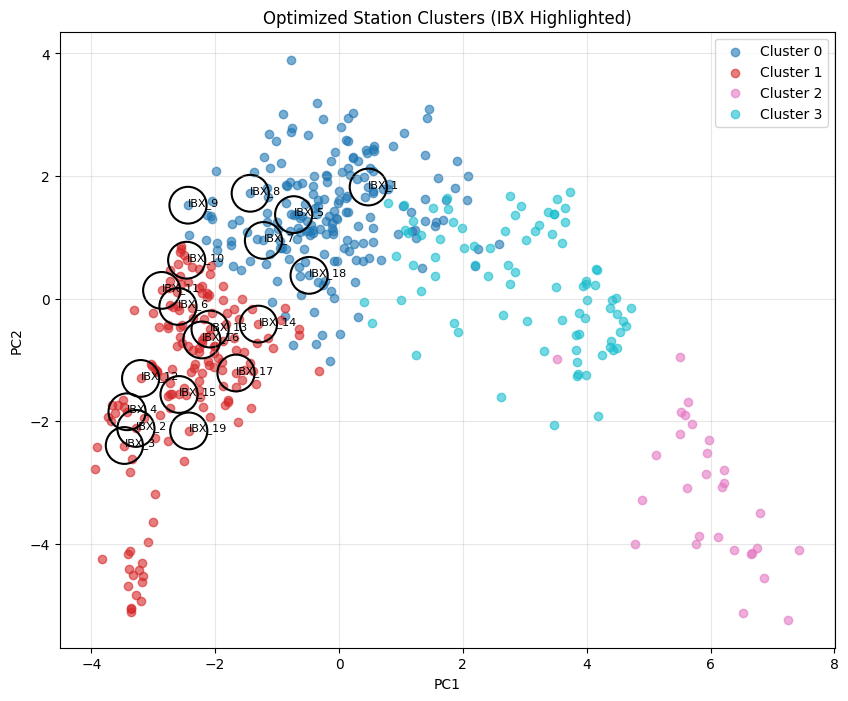

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone_Network/refs/heads/main/station_independent_variables_clean__20260321_041541.csv"
)

df["station_complex_id"] = df["station_complex_id"].astype(str)

# Remove ridership columns if present
df = df.drop(columns=[
    "annual_weekday_avg_ridership",
    "log_ridership"
], errors="ignore")

# =========================================================
# FINAL OPTIMIZED FEATURE SET (NON-REDUNDANT)
# =========================================================
features = [
    # Demand / accessibility
    "population_access_network",
    "jobs_access_network",
    "pct_hh_no_vehicle_access_network",
    "median_hh_income_access_network",
    "pct_transit_access_network",
    "pct_walked_access_network",
    "pct_wfh_access_network",

    # Contextual scale (keep ONLY one)
    "population_0p5mi",

    # Urban form
    "landuse_entropy_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",

    # Transit supply
    "bus_routes_access_network",
    "subway_lines_access_network",
    "commuter_lines_access_network",
    "dist_to_commuter_stop_mi_network",
    "has_commuter_stop_within_1mi_network",
    "transfer_subway_station_complexes_0p25mi_network",
    "dist_to_subway_station_complex_mi_network",
    "peak_tph_bidir",
    "tph_peak_to_midday_ratio",
    "subway_lines_serving_station",
    "is_terminal_subway",

    # Anchors
    "has_university_0p5mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p5mi",

    # IBX flag (NOT for clustering interpretation)
    "is_ibx_planned",
]

# Keep only existing columns
features_available = [f for f in features if f in df.columns]

print("Features used:")
print(features_available)

# =========================================================
# PREP DATA
# =========================================================
data = df[features_available].dropna().copy()
df_plot = df.loc[data.index].copy()

print("\nRows used:", len(data))
print("Features:", len(features_available))

# Separate IBX flag (do NOT include in scaling)
X = data.drop(columns=["is_ibx_planned"], errors="ignore")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================================
# K-MEANS CLUSTERING
# =========================================================
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_plot["cluster"] = clusters

# =========================================================
# CLUSTER MEMBERSHIP TABLE
# =========================================================
station_cluster_df = (
    df_plot[["station_complex_name", "station_complex_id", "cluster"]]
    .drop_duplicates()
    .sort_values(["cluster", "station_complex_name"])
)

station_cluster_df["is_ibx"] = (
    station_cluster_df["station_complex_id"]
    .str.startswith("IBX_", na=False)
)

station_cluster_df.to_csv("station_clusters.csv", index=False)

# =========================================================
# PCA
# =========================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot["PC1"] = X_pca[:, 0]
df_plot["PC2"] = X_pca[:, 1]
df_plot["is_ibx"] = df_plot["station_complex_id"].str.startswith("IBX_", na=False)

# =========================================================
# PLOT
# =========================================================
plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for cluster, color in zip(range(n_clusters), colors):
    mask = df_plot["cluster"] == cluster
    plt.scatter(
        df_plot.loc[mask, "PC1"],
        df_plot.loc[mask, "PC2"],
        label=f"Cluster {cluster}",
        color=color,
        alpha=0.6
    )

# Highlight IBX
ibx_points = df_plot[df_plot["is_ibx"]]
ax = plt.gca()

for _, row in ibx_points.iterrows():
    circle = Ellipse(
        (row["PC1"], row["PC2"]),
        width=0.6,
        height=0.6,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5
    )
    ax.add_patch(circle)

    plt.text(
        row["PC1"],
        row["PC2"],
        row["station_complex_id"],
        fontsize=8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Optimized Station Clusters (IBX Highlighted)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =========================================================
# SAVE PCA OUTPUT
# =========================================================
pca_df = df_plot[[
    "station_complex_name",
    "station_complex_id",
    "cluster",
    "is_ibx"
]].copy()

pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]

pca_df.to_csv("station_clusters_pca.csv", index=False)


Borough counts after merge:
borough
Brooklyn         156
Manhattan        121
Queens            79
Bronx             68
NaN               38
Staten Island      2
Name: count, dtype: int64

IBX count in feature table:
19

Features used:
['population_access_network', 'jobs_access_network', 'pct_hh_no_vehicle_access_network', 'median_hh_income_access_network', 'pct_transit_access_network', 'pct_walked_access_network', 'pct_wfh_access_network', 'population_0p5mi', 'landuse_entropy_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'bus_routes_access_network', 'subway_lines_access_network', 'commuter_lines_access_network', 'dist_to_commuter_stop_mi_network', 'has_commuter_stop_within_1mi_network', 'transfer_subway_station_complexes_0p25mi_network', 'peak_tph_bidir', 'tph_peak_to_midday_ratio', 'subway_lines_serving_station', 'is_terminal_subway', 'has_university_0p5mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p5mi_capped10', 'adjacent_major_park_0p5mi', 'is_i

,cluster,ibx_station_count
0,3,19


Saved: ibx_stations_by_borough.csv


,borough,ibx_station_count
0,NaN,19


Saved: ibx_cluster_borough_counts.csv


,cluster,borough,ibx_station_count
0,3,NaN,19


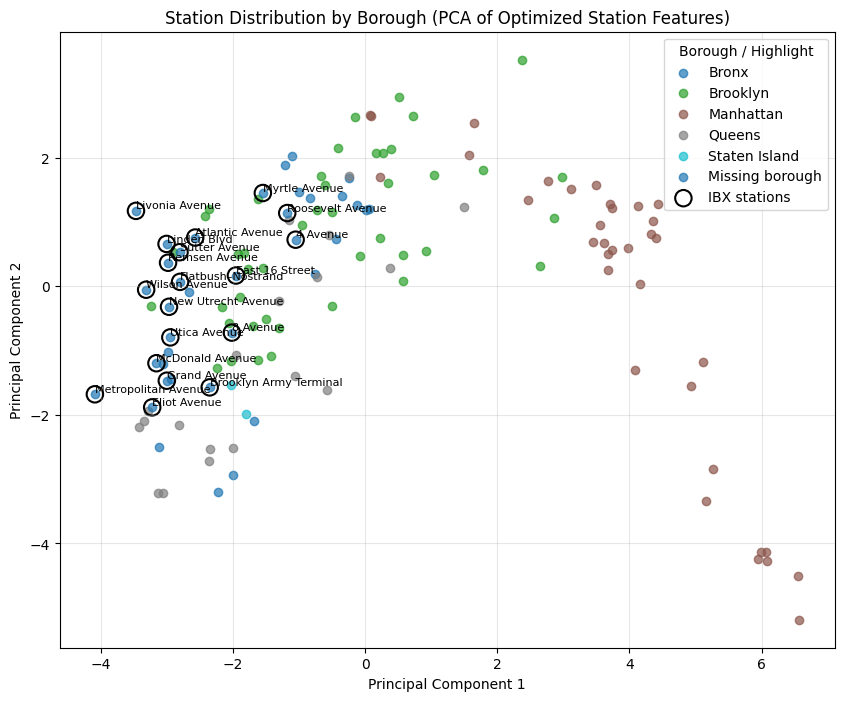

Saved: station_clusters_pca.csv
Saved: station_clusters_pca_loadings.csv


,PC1_loading,PC2_loading
subway_lines_access_network,0.330913,-0.029414
pct_wfh_access_network,0.310430,0.076864
pct_walked_access_network,0.309962,-0.145275
citibike_count_0p5mi,0.302825,0.192401
jobs_access_network,0.287093,-0.275733
cultural_count_0p5mi_capped10,0.274282,0.177597
bus_routes_access_network,0.270429,-0.255775
has_university_0p5mi,0.269926,0.039697
median_hh_income_access_network,0.263096,-0.041714
commuter_lines_access_network,0.154377,-0.236978


Saved: station_cluster_feature_means.csv


,population_access_network,jobs_access_network,pct_hh_no_vehicle_access_network,median_hh_income_access_network,pct_transit_access_network,pct_walked_access_network,pct_wfh_access_network,population_0p5mi,landuse_entropy_0p5mi,intersection_density_0p5mi,...,peak_tph_bidir,tph_peak_to_midday_ratio,subway_lines_serving_station,is_terminal_subway,has_university_0p5mi,has_hospital_0p5mi,has_stadium_0p1mi,cultural_count_0p5mi_capped10,adjacent_major_park_0p5mi,is_ibx_planned
cluster,,,,,,,,,,,,,,,,,,,,,
0,18121.917,4770.556,40.768,66316.050,44.641,7.685,4.915,24817.611,1.802,385.881,...,25.667,1.196,2.306,0.139,0.083,0.167,0.00,2.861,0.472,0.0
1,10832.030,30843.606,6.091,128969.530,47.949,26.959,12.634,49931.364,1.665,618.978,...,29.394,1.175,1.758,0.030,0.970,0.485,0.00,10.000,0.121,0.0
2,14984.680,4759.340,15.318,69399.657,64.552,8.659,7.727,44462.080,1.943,591.912,...,36.260,1.242,2.220,0.040,0.320,0.220,0.02,7.560,0.140,0.0
3,14256.000,3421.053,28.059,59535.794,56.030,8.348,5.105,31664.684,1.677,409.837,...,24.000,2.000,2.368,0.105,0.105,0.158,0.00,3.474,0.211,1.0


In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

RIDERSHIP_URL = "https://raw.githubusercontent.com/hawa1983/Capstone_Network/refs/heads/main/ridership_station_avg_post_2023_2024.csv"
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone_Network/refs/heads/main/station_independent_variables_clean__20260321_041541.csv"

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(FEATURES_URL)
ridership = pd.read_csv(RIDERSHIP_URL)

df["station_complex_id"] = df["station_complex_id"].astype(str).str.strip()
ridership["station_complex_id"] = ridership["station_complex_id"].astype(str).str.strip()

# Keep one borough per station_complex_id from ridership
borough_lookup = (
    ridership[["station_complex_id", "borough"]]
    .dropna(subset=["station_complex_id", "borough"])
    .drop_duplicates(subset=["station_complex_id"])
    .copy()
)

# Merge borough into feature table
df = df.merge(
    borough_lookup,
    on="station_complex_id",
    how="left"
)

print("\nBorough counts after merge:")
print(df["borough"].value_counts(dropna=False))

# Remove ridership columns explicitly if present
df = df.drop(columns=[
    "annual_weekday_avg_ridership",
    "log_ridership"
], errors="ignore")

# =========================================================
# DEFINE IBX FLAG
# Use is_ibx_planned, not station_complex_id prefix
# =========================================================
if "is_ibx_planned" in df.columns:
    df["is_ibx"] = df["is_ibx_planned"].fillna(0).astype(int).eq(1)
else:
    df["is_ibx"] = False

print("\nIBX count in feature table:")
print(df["is_ibx"].sum())

# =========================================================
# OPTIONAL: CREATE PEAK / MIDDAY SERVICE RATIO
# Only if both columns exist
# =========================================================
if {"peak_tph_bidir", "midday_tph_bidir"}.issubset(df.columns):
    denom = df["midday_tph_bidir"].replace(0, np.nan)
    df["tph_peak_to_midday_ratio"] = df["peak_tph_bidir"] / denom

# =========================================================
# FINAL OPTIMIZED FEATURE LIST (READY FOR CLUSTERING)
# =========================================================
features_optimized = [
    # -----------------------------------------------------
    # 1. DEMAND / SOCIOECONOMIC ACCESS (NETWORK-BASED)
    # -----------------------------------------------------
    "population_access_network",
    "jobs_access_network",
    "pct_hh_no_vehicle_access_network",
    "median_hh_income_access_network",
    "pct_transit_access_network",
    "pct_walked_access_network",
    "pct_wfh_access_network",

    # -----------------------------------------------------
    # 2. CORE SCALE / INTENSITY
    # -----------------------------------------------------
    "population_0p5mi",

    # -----------------------------------------------------
    # 3. BUILT ENVIRONMENT / URBAN FORM
    # -----------------------------------------------------
    "landuse_entropy_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",

    # -----------------------------------------------------
    # 4. TRANSIT SUPPLY / NETWORK STRUCTURE
    # -----------------------------------------------------
    "bus_routes_access_network",
    "subway_lines_access_network",
    "commuter_lines_access_network",
    "dist_to_commuter_stop_mi_network",
    "has_commuter_stop_within_1mi_network",
    "transfer_subway_station_complexes_0p25mi_network",
    "peak_tph_bidir",
    "tph_peak_to_midday_ratio",
    "subway_lines_serving_station",
    "is_terminal_subway",

    # -----------------------------------------------------
    # 5. ANCHORS / DESTINATION ATTRACTORS
    # -----------------------------------------------------
    "has_university_0p5mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p5mi",

    # -----------------------------------------------------
    # 6. PLANNING STATUS
    # -----------------------------------------------------
    "is_ibx_planned",
]

features_available = [f for f in features_optimized if f in df.columns]
features_missing = [f for f in features_optimized if f not in df.columns]

print("\nFeatures used:")
print(features_available)

if features_missing:
    print("\nMissing features not found in dataframe:")
    print(features_missing)

# =========================================================
# PREP DATA
# =========================================================
data = df[features_available].copy()

# Drop rows with any missing selected features
data = data.dropna().copy()
df_plot = df.loc[data.index].copy()

print("\nRows used for clustering:", len(data))
print("Number of features used:", len(features_available))
print("IBX rows used in clustering:", int(df_plot["is_ibx"].sum()))

# =========================================================
# STANDARDIZE
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# =========================================================
# K-MEANS CLUSTERING
# =========================================================
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_plot["cluster"] = clusters

# =========================================================
# STATION-CLUSTER MEMBERSHIP TABLE
# =========================================================
station_cluster_df = (
    df_plot[
        [
            "station_complex_name",
            "station_complex_id",
            "borough",
            "cluster",
            "is_ibx"
        ]
    ]
    .dropna(subset=["cluster"])
    .drop_duplicates()
    .sort_values(["cluster", "station_complex_name"])
    .copy()
)

station_cluster_df["IBX_station"] = station_cluster_df["is_ibx"].map({
    True: "IBX",
    False: ""
})

station_cluster_df.to_csv("station_clusters.csv", index=False)
print("\nSaved: station_clusters.csv")

# =========================================================
# IBX COUNT BY CLUSTER
# =========================================================
ibx_cluster_counts = (
    station_cluster_df[station_cluster_df["is_ibx"]]
    .groupby("cluster")["station_complex_id"]
    .count()
    .reset_index()
    .rename(columns={"station_complex_id": "ibx_station_count"})
    .sort_values("cluster")
)

ibx_cluster_counts.to_csv("ibx_stations_by_cluster.csv", index=False)
print("Saved: ibx_stations_by_cluster.csv")
display(ibx_cluster_counts)

# =========================================================
# IBX COUNT BY BOROUGH
# =========================================================
ibx_by_borough = (
    station_cluster_df[station_cluster_df["is_ibx"]]
    .groupby("borough", dropna=False)["station_complex_id"]
    .count()
    .reset_index()
    .rename(columns={"station_complex_id": "ibx_station_count"})
    .sort_values("ibx_station_count", ascending=False)
)

ibx_by_borough.to_csv("ibx_stations_by_borough.csv", index=False)
print("Saved: ibx_stations_by_borough.csv")
display(ibx_by_borough)

# =========================================================
# IBX COUNT BY CLUSTER AND BOROUGH
# =========================================================
ibx_cluster_borough = (
    station_cluster_df[station_cluster_df["is_ibx"]]
    .groupby(["cluster", "borough"], dropna=False)["station_complex_id"]
    .count()
    .reset_index()
    .rename(columns={"station_complex_id": "ibx_station_count"})
    .sort_values(["cluster", "ibx_station_count"], ascending=[True, False])
)

ibx_cluster_borough.to_csv("ibx_cluster_borough_counts.csv", index=False)
print("Saved: ibx_cluster_borough_counts.csv")
display(ibx_cluster_borough)

# =========================================================
# PCA VISUALIZATION (COLOR BY BOROUGH + LABEL IBX)
# =========================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot["PC1"] = X_pca[:, 0]
df_plot["PC2"] = X_pca[:, 1]

plt.figure(figsize=(10, 8))

boroughs = sorted(df_plot["borough"].dropna().unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(boroughs)))

for borough, color in zip(boroughs, colors):
    mask = df_plot["borough"] == borough
    plt.scatter(
        df_plot.loc[mask, "PC1"],
        df_plot.loc[mask, "PC2"],
        label=borough,
        color=color,
        alpha=0.7
    )

# Missing borough points
missing_mask = df_plot["borough"].isna()
if missing_mask.any():
    plt.scatter(
        df_plot.loc[missing_mask, "PC1"],
        df_plot.loc[missing_mask, "PC2"],
        label="Missing borough",
        alpha=0.7
    )

# Overlay IBX stations
ibx_points = df_plot[df_plot["is_ibx"]].copy()

if not ibx_points.empty:
    plt.scatter(
        ibx_points["PC1"],
        ibx_points["PC2"],
        s=140,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        label="IBX stations"
    )

    for _, row in ibx_points.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            row["station_complex_name"],
            fontsize=8,
            ha="left",
            va="bottom"
        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Station Distribution by Borough (PCA of Optimized Station Features)")
plt.legend(title="Borough / Highlight")
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# SAVE PCA COORDINATES
# =========================================================
pca_df = df_plot[
    ["station_complex_name", "station_complex_id", "borough", "cluster", "is_ibx"]
].copy()
pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]

pca_df.to_csv("station_clusters_pca.csv", index=False)
print("Saved: station_clusters_pca.csv")

# =========================================================
# OPTIONAL: PCA LOADINGS FOR INTERPRETATION
# =========================================================
loadings = pd.DataFrame(
    pca.components_.T,
    index=features_available,
    columns=["PC1_loading", "PC2_loading"]
).sort_values("PC1_loading", ascending=False)

loadings.to_csv("station_clusters_pca_loadings.csv", index=True)
print("Saved: station_clusters_pca_loadings.csv")
display(loadings)

# =========================================================
# OPTIONAL: QUICK CLUSTER SUMMARY
# =========================================================
cluster_summary = (
    df_plot.groupby("cluster")[features_available]
    .mean()
    .round(3)
)

cluster_summary.to_csv("station_cluster_feature_means.csv", index=True)
print("Saved: station_cluster_feature_means.csv")
display(cluster_summary)

## Combined plots


Borough counts after merge:
borough
Brooklyn         156
Manhattan        121
Queens            79
Bronx             68
NaN               38
Staten Island      2
Name: count, dtype: int64

IBX count in full feature table:
19

Features used:
['population_access_network', 'jobs_access_network', 'pct_hh_no_vehicle_access_network', 'median_hh_income_access_network', 'pct_transit_access_network', 'pct_walked_access_network', 'pct_wfh_access_network', 'population_0p5mi', 'landuse_entropy_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'bus_routes_access_network', 'subway_lines_access_network', 'commuter_lines_access_network', 'dist_to_commuter_stop_mi_network', 'has_commuter_stop_within_1mi_network', 'transfer_subway_station_complexes_0p25mi_network', 'dist_to_subway_station_complex_mi_network', 'peak_tph_bidir', 'tph_peak_to_midday_ratio', 'subway_lines_serving_station', 'is_terminal_subway', 'has_university_0p5mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0

,cluster,ibx_count,total_stations,ibx_share
0,0,0,10,0.000000
1,1,13,48,0.270833
2,2,6,54,0.111111
3,3,0,26,0.000000


Saved: ibx_stations_by_borough.csv


,borough,ibx_station_count
0,NaN,19


Saved: ibx_cluster_borough_counts.csv


,cluster,borough,ibx_station_count
0,1,NaN,13
1,2,NaN,6


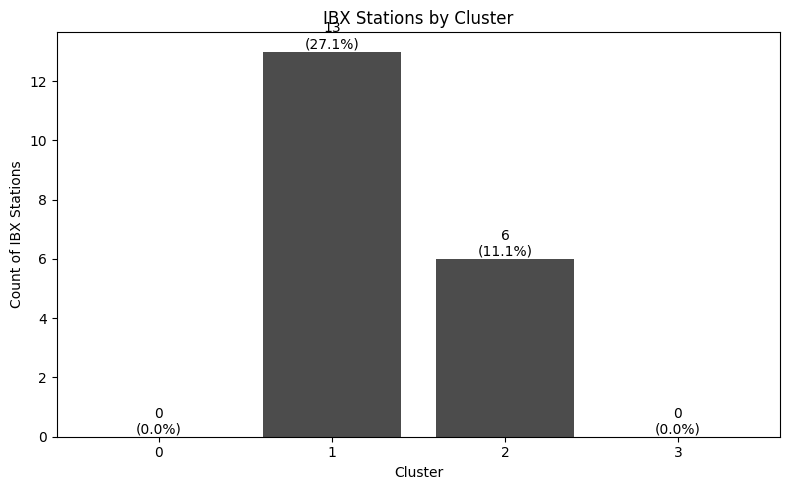

Saved: cluster_borough_counts.csv

Cluster x Borough counts:
borough_plot  Bronx  Brooklyn  Manhattan  Missing  Queens  Staten Island
cluster                                                                 
0                 0         0         10        0       0              0
1                 5        14          0       16      11              2
2                11        26          3        6       8              0
3                 0         4         22        0       0              0
Saved: cluster_borough_shares.csv

Cluster x Borough shares:
borough_plot  Bronx  Brooklyn  Manhattan  Missing  Queens  Staten Island
cluster                                                                 
0             0.000     0.000      1.000    0.000   0.000          0.000
1             0.104     0.292      0.000    0.333   0.229          0.042
2             0.204     0.481      0.056    0.111   0.148          0.000
3             0.000     0.154      0.846    0.000   0.000          0.000


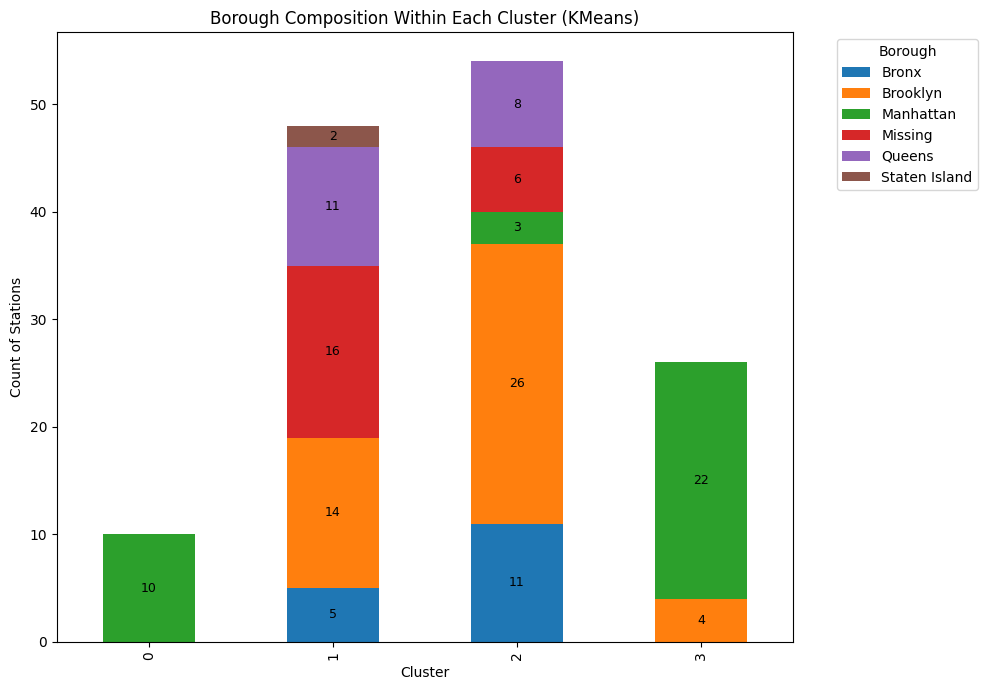

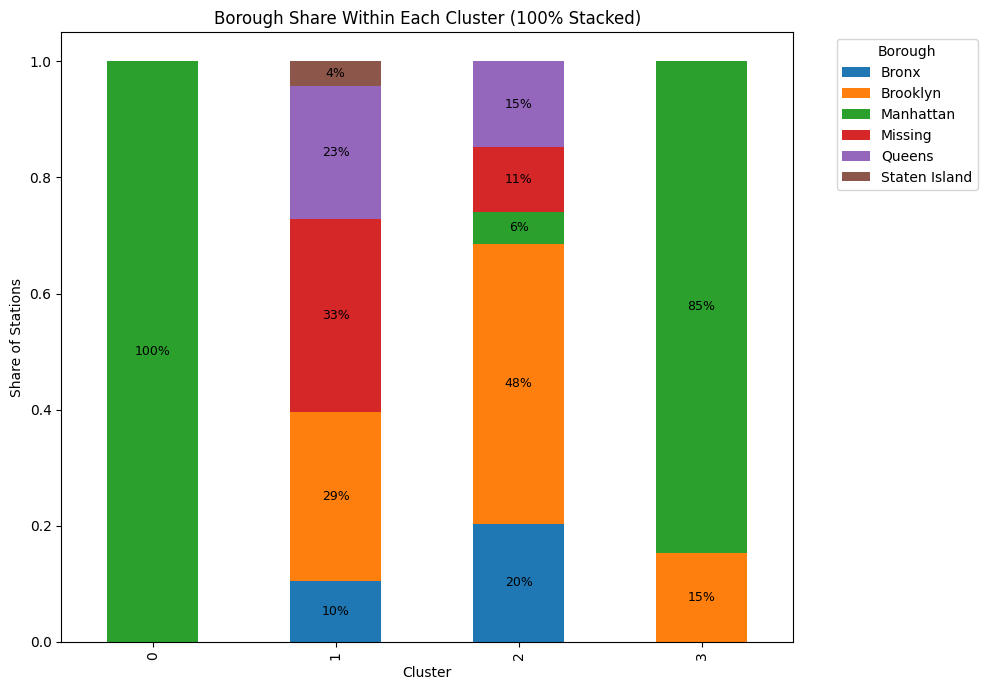

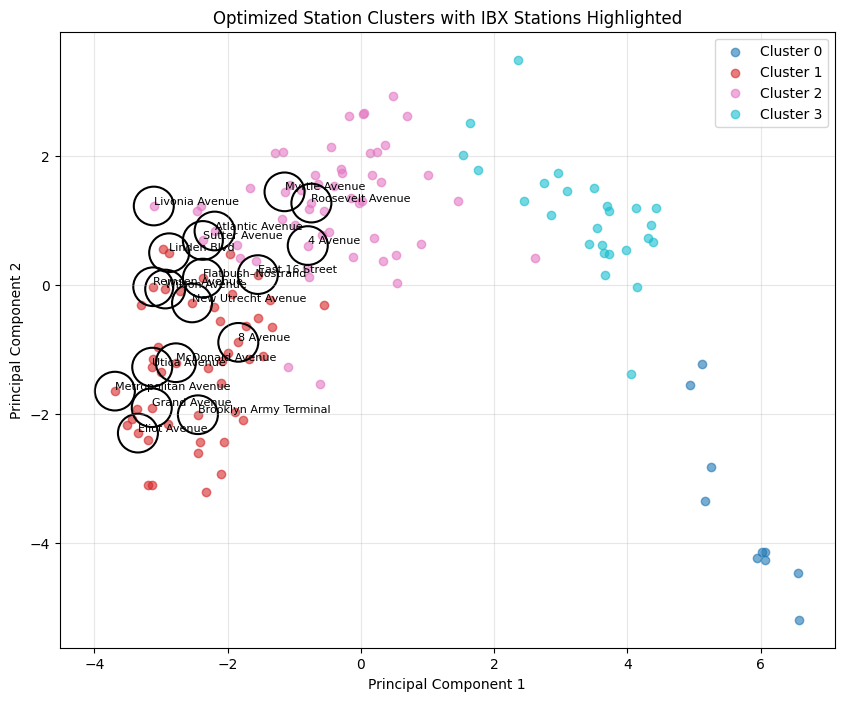

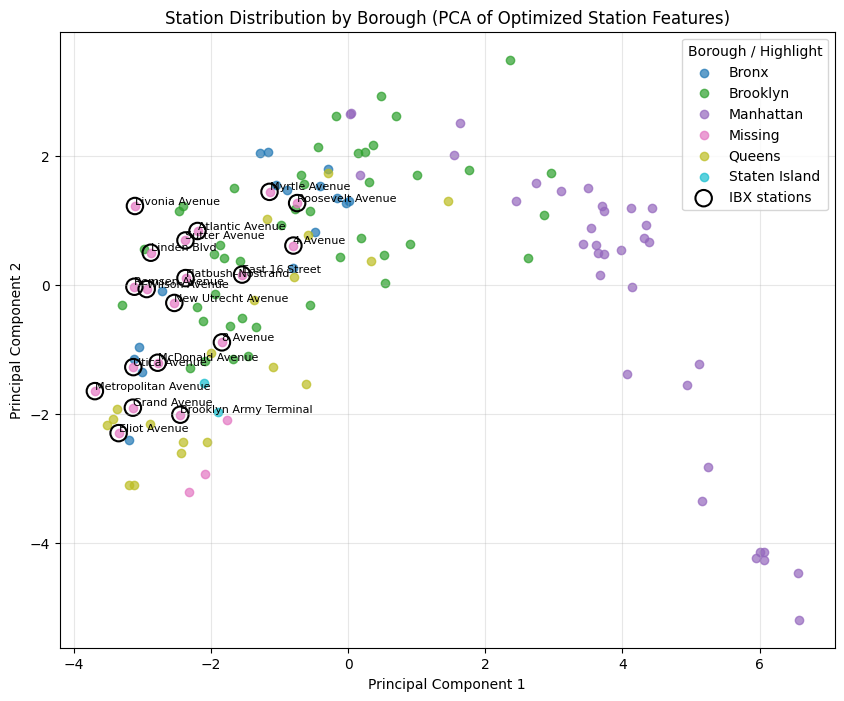

Saved: station_clusters_pca.csv
Saved: station_clusters_pca_loadings.csv


,PC1_loading,PC2_loading
subway_lines_access_network,0.334169,-0.032639
pct_walked_access_network,0.313180,-0.150012
pct_wfh_access_network,0.311791,0.070039
citibike_count_0p5mi,0.304996,0.190638
jobs_access_network,0.289098,-0.276788
cultural_count_0p5mi_capped10,0.276377,0.175524
has_university_0p5mi,0.272265,0.039115
bus_routes_access_network,0.271569,-0.258424
median_hh_income_access_network,0.264095,-0.049131
commuter_lines_access_network,0.157457,-0.226364


Saved: station_cluster_feature_means.csv


,population_access_network,jobs_access_network,pct_hh_no_vehicle_access_network,median_hh_income_access_network,pct_transit_access_network,pct_walked_access_network,pct_wfh_access_network,population_0p5mi,landuse_entropy_0p5mi,intersection_density_0p5mi,...,dist_to_subway_station_complex_mi_network,peak_tph_bidir,tph_peak_to_midday_ratio,subway_lines_serving_station,is_terminal_subway,has_university_0p5mi,has_hospital_0p5mi,has_stadium_0p1mi,cultural_count_0p5mi_capped10,adjacent_major_park_0p5mi
cluster,,,,,,,,,,,,,,,,,,,,,
0,10616.600,58423.200,5.868,128425.116,39.598,35.723,12.766,39001.700,1.458,364.477,...,0.000,26.500,1.048,1.500,0.000,1.000,0.200,0.000,10.000,0.300
1,17259.104,4308.875,38.289,65318.824,46.796,7.878,4.970,24621.021,1.736,374.669,...,0.120,25.667,1.420,2.125,0.104,0.104,0.146,0.000,2.604,0.438
2,14546.500,4465.148,16.698,66673.451,64.793,7.947,7.193,44241.111,1.941,551.514,...,0.012,32.222,1.310,2.296,0.074,0.278,0.259,0.019,7.259,0.130
3,11916.538,17706.538,6.517,124023.623,51.559,22.821,12.405,54040.615,1.771,780.378,...,0.000,35.615,1.251,2.154,0.038,0.885,0.500,0.000,10.000,0.038


In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse

RIDERSHIP_URL = "https://raw.githubusercontent.com/hawa1983/Capstone_Network/refs/heads/main/ridership_station_avg_post_2023_2024.csv"
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone_Network/refs/heads/main/station_independent_variables_clean__20260321_041541.csv"

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(FEATURES_URL)
ridership = pd.read_csv(RIDERSHIP_URL)

df["station_complex_id"] = df["station_complex_id"].astype(str).str.strip()
ridership["station_complex_id"] = ridership["station_complex_id"].astype(str).str.strip()

# Remove ridership columns explicitly if present in features file
df = df.drop(columns=[
    "annual_weekday_avg_ridership",
    "log_ridership"
], errors="ignore")

# =========================================================
# MERGE BOROUGH FROM RIDERSHIP FILE
# =========================================================
borough_lookup = (
    ridership[["station_complex_id", "borough"]]
    .dropna(subset=["station_complex_id", "borough"])
    .drop_duplicates(subset=["station_complex_id"])
    .copy()
)

df = df.merge(
    borough_lookup,
    on="station_complex_id",
    how="left"
)

print("\nBorough counts after merge:")
print(df["borough"].value_counts(dropna=False))

# =========================================================
# DEFINE IBX FLAG
# Prefer is_ibx_planned if available; otherwise fall back to ID prefix
# =========================================================
if "is_ibx_planned" in df.columns:
    df["is_ibx"] = df["is_ibx_planned"].fillna(0).astype(int).eq(1)
else:
    df["is_ibx"] = df["station_complex_id"].str.startswith("IBX_", na=False)

print("\nIBX count in full feature table:")
print(int(df["is_ibx"].sum()))

# =========================================================
# OPTIONAL: CREATE PEAK / MIDDAY SERVICE RATIO
# =========================================================
if {"peak_tph_bidir", "midday_tph_bidir"}.issubset(df.columns):
    denom = df["midday_tph_bidir"].replace(0, np.nan)
    df["tph_peak_to_midday_ratio"] = df["peak_tph_bidir"] / denom

# =========================================================
# FINAL OPTIMIZED FEATURE SET (NON-REDUNDANT)
# =========================================================
features = [
    # Demand / accessibility
    "population_access_network",
    "jobs_access_network",
    "pct_hh_no_vehicle_access_network",
    "median_hh_income_access_network",
    "pct_transit_access_network",
    "pct_walked_access_network",
    "pct_wfh_access_network",

    # Contextual scale
    "population_0p5mi",

    # Built environment / urban form
    "landuse_entropy_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",

    # Transit supply / network structure
    "bus_routes_access_network",
    "subway_lines_access_network",
    "commuter_lines_access_network",
    "dist_to_commuter_stop_mi_network",
    "has_commuter_stop_within_1mi_network",
    "transfer_subway_station_complexes_0p25mi_network",
    "dist_to_subway_station_complex_mi_network",
    "peak_tph_bidir",
    "tph_peak_to_midday_ratio",
    "subway_lines_serving_station",
    "is_terminal_subway",

    # Anchors / amenities
    "has_university_0p5mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p5mi",

    # Planning status
    "is_ibx_planned",
]

features_available = [f for f in features if f in df.columns]
features_missing = [f for f in features if f not in df.columns]

print("\nFeatures used:")
print(features_available)

if features_missing:
    print("\nMissing features not found in dataframe:")
    print(features_missing)

# =========================================================
# PREP DATA
# =========================================================
data = df[features_available].dropna().copy()
df_plot = df.loc[data.index].copy()

print("\nRows used for clustering:", len(data))
print("Number of features used:", len(features_available))
print("IBX rows used in clustering:", int(df_plot["is_ibx"].sum()))

# Exclude IBX flag from clustering inputs; keep for interpretation only
X = data.drop(columns=["is_ibx_planned"], errors="ignore")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================================
# K-MEANS CLUSTERING
# =========================================================
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_plot["cluster"] = kmeans.fit_predict(X_scaled)

# =========================================================
# STATION-CLUSTER MEMBERSHIP TABLE
# =========================================================
station_cluster_df = (
    df_plot[
        [
            "station_complex_name",
            "station_complex_id",
            "borough",
            "cluster",
            "is_ibx"
        ]
    ]
    .drop_duplicates()
    .sort_values(["cluster", "station_complex_name"])
    .copy()
)

station_cluster_df["IBX_station"] = station_cluster_df["is_ibx"].map({
    True: "IBX",
    False: ""
})

station_cluster_df.to_csv("station_clusters.csv", index=False)
print("\nSaved: station_clusters.csv")

# =========================================================
# IBX COUNT BY CLUSTER
# =========================================================
all_clusters = pd.Series(0, index=sorted(df_plot["cluster"].unique()))

ibx_cluster_counts = (
    df_plot[df_plot["is_ibx"]]
    .groupby("cluster")["station_complex_id"]
    .count()
)

ibx_cluster_counts = all_clusters.add(ibx_cluster_counts, fill_value=0).astype(int)

cluster_totals = df_plot.groupby("cluster")["station_complex_id"].count()
ibx_share = (ibx_cluster_counts / cluster_totals).fillna(0)

ibx_cluster_summary = pd.DataFrame({
    "cluster": ibx_cluster_counts.index,
    "ibx_count": ibx_cluster_counts.values,
    "total_stations": cluster_totals.reindex(ibx_cluster_counts.index).values.astype(int),
    "ibx_share": ibx_share.reindex(ibx_cluster_counts.index).values
})

ibx_cluster_summary.to_csv("ibx_cluster_summary.csv", index=False)
print("Saved: ibx_cluster_summary.csv")
display(ibx_cluster_summary)

# =========================================================
# IBX COUNT BY BOROUGH
# =========================================================
ibx_by_borough = (
    station_cluster_df[station_cluster_df["is_ibx"]]
    .groupby("borough", dropna=False)["station_complex_id"]
    .count()
    .reset_index()
    .rename(columns={"station_complex_id": "ibx_station_count"})
    .sort_values("ibx_station_count", ascending=False)
)

ibx_by_borough.to_csv("ibx_stations_by_borough.csv", index=False)
print("Saved: ibx_stations_by_borough.csv")
display(ibx_by_borough)

# =========================================================
# IBX COUNT BY CLUSTER AND BOROUGH
# =========================================================
ibx_cluster_borough = (
    station_cluster_df[station_cluster_df["is_ibx"]]
    .groupby(["cluster", "borough"], dropna=False)["station_complex_id"]
    .count()
    .reset_index()
    .rename(columns={"station_complex_id": "ibx_station_count"})
    .sort_values(["cluster", "ibx_station_count"], ascending=[True, False])
)

ibx_cluster_borough.to_csv("ibx_cluster_borough_counts.csv", index=False)
print("Saved: ibx_cluster_borough_counts.csv")
display(ibx_cluster_borough)

# =========================================================
# IBX BAR CHART: COUNT + SHARE BY CLUSTER
# =========================================================
plt.figure(figsize=(8, 5))

bars = plt.bar(
    ibx_cluster_summary["cluster"].astype(str),
    ibx_cluster_summary["ibx_count"],
    color="black",
    alpha=0.7
)

plt.xlabel("Cluster")
plt.ylabel("Count of IBX Stations")
plt.title("IBX Stations by Cluster")

for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = ibx_cluster_summary.loc[i, "ibx_share"] * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# =========================================================
# STACKED BAR CHART: BOROUGH COUNTS WITHIN EACH CLUSTER
# =========================================================
df_plot["borough_plot"] = df_plot["borough"].fillna("Missing")

cluster_borough_counts = (
    df_plot
    .groupby(["cluster", "borough_plot"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

cluster_borough_counts.to_csv("cluster_borough_counts.csv")
print("Saved: cluster_borough_counts.csv")

print("\nCluster x Borough counts:")
print(cluster_borough_counts)

cluster_borough_share = cluster_borough_counts.div(
    cluster_borough_counts.sum(axis=1),
    axis=0
).fillna(0)

cluster_borough_share.to_csv("cluster_borough_shares.csv")
print("Saved: cluster_borough_shares.csv")

print("\nCluster x Borough shares:")
print(cluster_borough_share.round(3))

ax = cluster_borough_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 7)
)

ax.set_xlabel("Cluster")
ax.set_ylabel("Count of Stations")
ax.set_title("Borough Composition Within Each Cluster (KMeans)")
ax.legend(title="Borough", bbox_to_anchor=(1.05, 1), loc="upper left")

for i, cluster in enumerate(cluster_borough_counts.index):
    cumulative_height = 0

    for borough in cluster_borough_counts.columns:
        count = cluster_borough_counts.loc[cluster, borough]

        if count > 0:
            y = cumulative_height + count / 2
            ax.text(
                i,
                y,
                str(int(count)),
                ha="center",
                va="center",
                fontsize=9
            )

        cumulative_height += count

plt.tight_layout()
plt.show()

# Optional proportional stacked chart
ax = cluster_borough_share.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 7)
)

ax.set_xlabel("Cluster")
ax.set_ylabel("Share of Stations")
ax.set_title("Borough Share Within Each Cluster (100% Stacked)")
ax.legend(title="Borough", bbox_to_anchor=(1.05, 1), loc="upper left")

for i, cluster in enumerate(cluster_borough_share.index):
    cumulative_height = 0

    for borough in cluster_borough_share.columns:
        share = cluster_borough_share.loc[cluster, borough]

        if share > 0.03:
            y = cumulative_height + share / 2
            ax.text(
                i,
                y,
                f"{share:.0%}",
                ha="center",
                va="center",
                fontsize=9
            )

        cumulative_height += share

plt.tight_layout()
plt.show()

# =========================================================
# PCA VISUALIZATION WITH IBX LABELS
# =========================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot["PC1"] = X_pca[:, 0]
df_plot["PC2"] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for cluster, color in zip(range(n_clusters), colors):
    mask = df_plot["cluster"] == cluster
    plt.scatter(
        df_plot.loc[mask, "PC1"],
        df_plot.loc[mask, "PC2"],
        label=f"Cluster {cluster}",
        color=color,
        alpha=0.6
    )

ibx_points = df_plot[df_plot["is_ibx"]].copy()
ax = plt.gca()

for _, row in ibx_points.iterrows():
    circle = Ellipse(
        (row["PC1"], row["PC2"]),
        width=0.6,
        height=0.6,
        angle=0,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5
    )
    ax.add_patch(circle)

    plt.text(
        row["PC1"],
        row["PC2"],
        str(row["station_complex_name"]),
        fontsize=8,
        ha="left",
        va="bottom"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Optimized Station Clusters with IBX Stations Highlighted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# PCA BY BOROUGH
# =========================================================
plt.figure(figsize=(10, 8))

boroughs = sorted(df_plot["borough_plot"].dropna().unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(boroughs)))

for borough, color in zip(boroughs, colors):
    mask = df_plot["borough_plot"] == borough
    plt.scatter(
        df_plot.loc[mask, "PC1"],
        df_plot.loc[mask, "PC2"],
        label=borough,
        color=color,
        alpha=0.7
    )

if not ibx_points.empty:
    plt.scatter(
        ibx_points["PC1"],
        ibx_points["PC2"],
        s=140,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        label="IBX stations"
    )

    for _, row in ibx_points.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            str(row["station_complex_name"]),
            fontsize=8,
            ha="left",
            va="bottom"
        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Station Distribution by Borough (PCA of Optimized Station Features)")
plt.legend(title="Borough / Highlight")
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# SAVE PCA COORDINATES
# =========================================================
pca_df = df_plot[
    ["station_complex_name", "station_complex_id", "borough", "cluster", "is_ibx"]
].copy()
pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]

pca_df.to_csv("station_clusters_pca.csv", index=False)
print("Saved: station_clusters_pca.csv")

# =========================================================
# PCA LOADINGS FOR INTERPRETATION
# =========================================================
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=["PC1_loading", "PC2_loading"]
).sort_values("PC1_loading", ascending=False)

loadings.to_csv("station_clusters_pca_loadings.csv", index=True)
print("Saved: station_clusters_pca_loadings.csv")
display(loadings)

# =========================================================
# CLUSTER FEATURE MEANS
# =========================================================
cluster_summary = (
    df_plot.groupby("cluster")[X.columns]
    .mean()
    .round(3)
)

cluster_summary.to_csv("station_cluster_feature_means.csv", index=True)
print("Saved: station_cluster_feature_means.csv")
display(cluster_summary)

In [76]:
corr = df[features_available].corr()

# Find highly correlated pairs
high_corr = (
    corr.abs()
    .stack()
    .reset_index()
)

high_corr.columns = ["var1", "var2", "corr"]

high_corr = high_corr[
    (high_corr["var1"] != high_corr["var2"]) &
    (high_corr["corr"] > 0.85)
].sort_values("corr", ascending=False)

print(high_corr.head(20))

                                 var1                              var2  \
311                 pop_density_0p5mi                  population_0p5mi   
287                  population_0p5mi                 pop_density_0p5mi   
127  pct_car_truck_van_access_network  pct_hh_no_vehicle_access_network   
55   pct_hh_no_vehicle_access_network  pct_car_truck_van_access_network   
521                    peak_tph_bidir                  midday_tph_bidir   
545                  midday_tph_bidir                    peak_tph_bidir   

         corr  
311  1.000000  
287  1.000000  
127  0.995257  
55   0.995257  
521  0.977541  
545  0.977541  


# Identify which cluster the IBX stations are in


IBX summary by cluster:


,cluster,ibx_count,total_stations,ibx_share
0,0,6,194,0.030928
1,1,13,157,0.082803
2,2,0,29,0.000000
3,3,0,84,0.000000


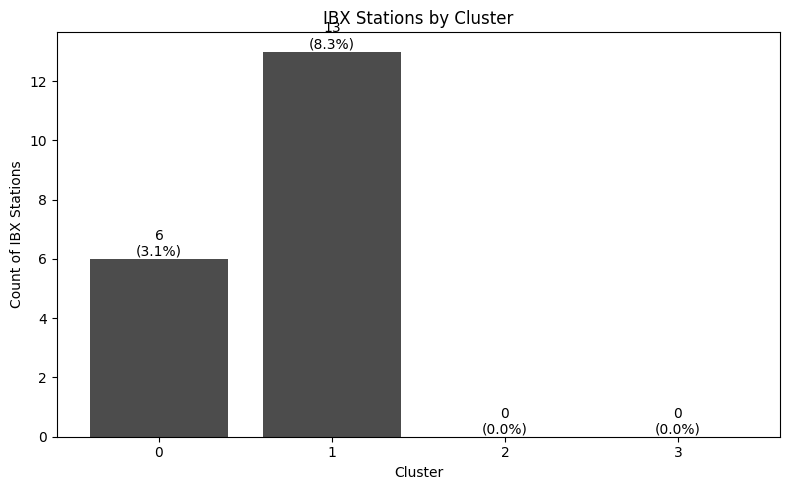

In [80]:
# =========================================================
# IBX BAR CHART: COUNT + SHARE BY CLUSTER
# =========================================================

# Ensure IBX flag exists
df_plot["is_ibx"] = df_plot["station_complex_id"].str.startswith("IBX_", na=False)

# ---------------------------------------------------------
# 1) IBX COUNT BY CLUSTER
# ---------------------------------------------------------
ibx_cluster_counts = (
    df_plot[df_plot["is_ibx"]]
    .groupby("cluster")["station_complex_id"]
    .count()
)

# Ensure all clusters appear
all_clusters = pd.Series(
    0, index=sorted(df_plot["cluster"].unique())
)

ibx_cluster_counts = all_clusters.add(ibx_cluster_counts, fill_value=0)

# ---------------------------------------------------------
# 2) TOTAL STATIONS BY CLUSTER (for share)
# ---------------------------------------------------------
cluster_totals = df_plot.groupby("cluster")["station_complex_id"].count()

# Share of IBX in each cluster
ibx_share = (ibx_cluster_counts / cluster_totals).fillna(0)

# ---------------------------------------------------------
# 3) CREATE SUMMARY TABLE
# ---------------------------------------------------------
ibx_summary = pd.DataFrame({
    "cluster": ibx_cluster_counts.index,
    "ibx_count": ibx_cluster_counts.values.astype(int),
    "total_stations": cluster_totals.values.astype(int),
    "ibx_share": ibx_share.values
})

# Save CSV (for your paper)
ibx_summary.to_csv("ibx_cluster_summary.csv", index=False)

print("\nIBX summary by cluster:")
display(ibx_summary)

# ---------------------------------------------------------
# 4) PLOT BAR CHART
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))

bars = plt.bar(
    ibx_summary["cluster"].astype(str),
    ibx_summary["ibx_count"],
    color="black",
    alpha=0.7
)

plt.xlabel("Cluster")
plt.ylabel("Count of IBX Stations")
plt.title("IBX Stations by Cluster")

# Annotate with count + percentage
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = ibx_summary.loc[i, "ibx_share"] * 100

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

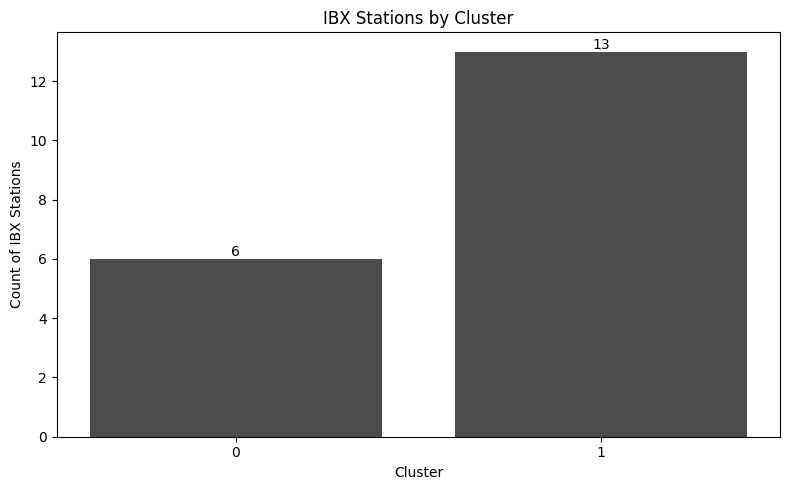

In [79]:
# =========================================================
# IBX BAR CHART: COUNT BY CLUSTER
# =========================================================

# Compute IBX counts by cluster
ibx_cluster_counts = (
    df_plot[df_plot["station_complex_id"].str.startswith("IBX_")]
    .groupby("cluster")["station_complex_id"]
    .count()
    .sort_index()
)

# print("\nIBX counts by cluster:")
# print(ibx_cluster_counts)

# Plot bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    ibx_cluster_counts.index.astype(str),
    ibx_cluster_counts.values,
    color="black",
    alpha=0.7
)

plt.xlabel("Cluster")
plt.ylabel("Count of IBX Stations")
plt.title("IBX Stations by Cluster")

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### **Built Environment Similarity of IBX Stations to Existing Subway Stations**

**IBX Forecasting Interpretation and Modeling Implications**

**1. IBX is overwhelmingly a “Cluster 2 project”**

**Evidence**
15 / 19 IBX stations are in Cluster 2 (about 79%)
Cluster 2 composition: Brooklyn (80), Queens (41), Bronx (33), minimal Staten Island (2), no Manhattan

**Interpretation**
IBX is fundamentally designed to serve outer-borough, cross-borough environments, not Manhattan

**Forecasting implication**
Your primary ridership model should be calibrated on Cluster 2 stations
This is the core training population and where IBX demand will behave most predictably

**2. IBX avoids Manhattan-type environments (Cluster 1)**

**Evidence**
Cluster 1 is 100% Manhattan (68 stations)
0 IBX stations

**Interpretation**
IBX does not operate in high-density, Manhattan-style transit ecosystems

**Forecasting implication**
Do not use Manhattan stations as benchmarks
They will overestimate ridership

**3. IBX includes a few transfer-heavy or higher-connectivity nodes (Cluster 0)**

**Evidence**
3 IBX stations in Cluster 0
Cluster 0 spans multiple boroughs with high Brooklyn presence (76), some Manhattan presence (53), and strong diversity

**Interpretation**
These are likely major transfer or network-integration stations

**Forecasting implication**
These stations will have higher ridership than typical IBX stops and act as demand amplifiers
Consider adding a hub or transfer adjustment factor or modeling them separately

**4. One outlier (Cluster 3)**

**Evidence**
Only 1 IBX station (Brooklyn Army Terminal)
Cluster 3 is very small and sparse

**Interpretation**
This reflects a non-typical, low-density or specialized land-use environment

**Forecasting implication**
A standard model will likely misestimate this station
Treat separately using a scenario-based estimate or a conservative adjustment

**5. Borough does not equal behavior**

**Evidence**
Clusters are not cleanly borough-based
Cluster 2 mixes Brooklyn, Queens, and Bronx

**Interpretation**
Built environment factors such as density, jobs, and connectivity matter more than geography

**Forecasting implication**
The model should rely on features rather than borough indicators as primary drivers

**6. IBX is a network gap filler**

**Combined insight**
IBX avoids Manhattan, concentrates in Cluster 2, includes a few hubs in Cluster 0, and has one outlier in Cluster 3

**Interpretation**
IBX is designed to connect similar outer-borough environments laterally rather than serving radial Manhattan demand

**7. Final forecasting strategy**

**Recommended modeling approach**

**Core model**
Train on Cluster 2 stations only or heavily weight them

**Adjustments**
Apply upward adjustments for Cluster 0 transfer hubs
Treat Cluster 3 as a special case

**Suggested write-up**

The clustering results indicate that IBX stations are predominantly located within a single station typology characterized by outer-borough, mixed-use environments. As a result, ridership forecasts should be anchored to observed patterns within this cluster, while avoiding reliance on Manhattan-based stations, which exhibit fundamentally different demand dynamics. A small number of IBX stations fall into higher-connectivity clusters, suggesting localized ridership uplift, while one outlier station requires separate treatment due to its unique built environment context.

**8. One-line takeaway**

IBX ridership should be forecast using outer-borough cluster behavior, not system-wide averages



# Hierarchical Clustering

This shows how stations group together in a hierarchy.

# t-SNE / UMAP Visualization

These show nonlinear structure in the data.

**t-SNE**

Features used:
['population_access_network', 'jobs_access_network', 'pct_hh_no_vehicle_access_network', 'median_hh_income_access_network', 'pct_transit_access_network', 'pct_walked_access_network', 'pct_wfh_access_network', 'population_0p5mi', 'landuse_entropy_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'bus_routes_access_network', 'subway_lines_access_network', 'commuter_lines_access_network', 'dist_to_commuter_stop_mi_network', 'has_commuter_stop_within_1mi_network', 'transfer_subway_station_complexes_0p25mi_network', 'dist_to_subway_station_complex_mi_network', 'peak_tph_bidir', 'tph_peak_to_midday_ratio', 'subway_lines_serving_station', 'is_terminal_subway', 'has_university_0p5mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p5mi_capped10', 'adjacent_major_park_0p5mi', 'is_ibx_planned']

Rows used for clustering: 138
Number of features used before dropping IBX flag: 28
IBX rows used: 19

Saved: station_clusters_tsne.csv


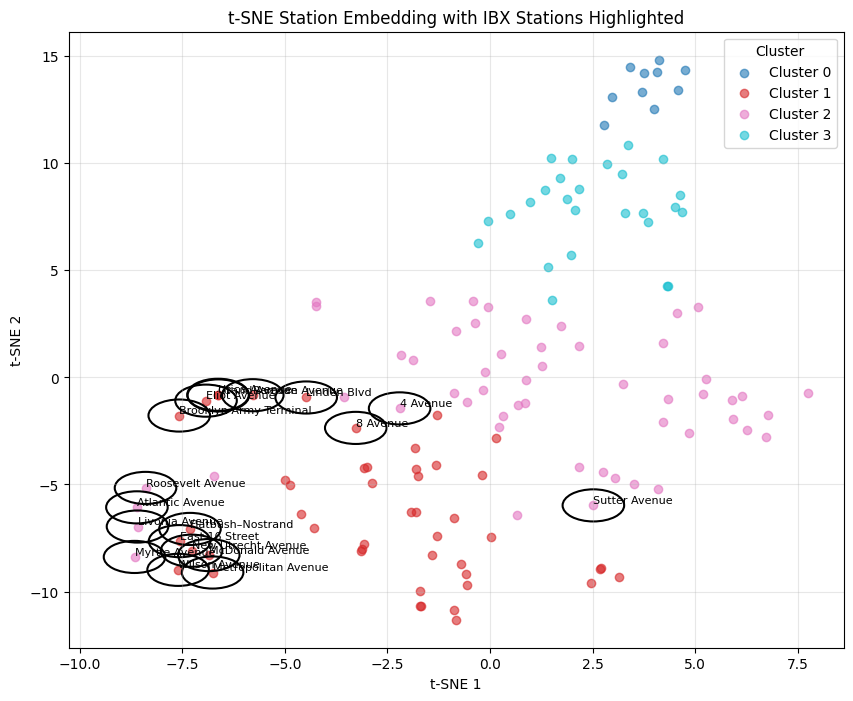

Saved: station_clusters_tsne_coordinates.csv


In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from matplotlib.patches import Ellipse

# =========================================================
# LOAD DATA
# =========================================================
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone_Network/refs/heads/main/station_independent_variables_clean__20260321_041541.csv"

df = pd.read_csv(FEATURES_URL)

df["station_complex_id"] = df["station_complex_id"].astype(str).str.strip()

# Remove ridership columns if present
df = df.drop(columns=[
    "annual_weekday_avg_ridership",
    "log_ridership"
], errors="ignore")

# =========================================================
# DEFINE IBX FLAG
# Prefer is_ibx_planned if available
# =========================================================
if "is_ibx_planned" in df.columns:
    df["is_ibx"] = df["is_ibx_planned"].fillna(0).astype(int).eq(1)
else:
    df["is_ibx"] = df["station_complex_id"].str.startswith("IBX_", na=False)

# =========================================================
# OPTIONAL: CREATE PEAK / MIDDAY SERVICE RATIO
# =========================================================
if {"peak_tph_bidir", "midday_tph_bidir"}.issubset(df.columns):
    denom = df["midday_tph_bidir"].replace(0, np.nan)
    df["tph_peak_to_midday_ratio"] = df["peak_tph_bidir"] / denom

# =========================================================
# FINAL OPTIMIZED FEATURE SET
# =========================================================
features = [
    # Demand / accessibility
    "population_access_network",
    "jobs_access_network",
    "pct_hh_no_vehicle_access_network",
    "median_hh_income_access_network",
    "pct_transit_access_network",
    "pct_walked_access_network",
    "pct_wfh_access_network",

    # Contextual scale
    "population_0p5mi",

    # Built environment / urban form
    "landuse_entropy_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",

    # Transit supply / network structure
    "bus_routes_access_network",
    "subway_lines_access_network",
    "commuter_lines_access_network",
    "dist_to_commuter_stop_mi_network",
    "has_commuter_stop_within_1mi_network",
    "transfer_subway_station_complexes_0p25mi_network",
    "dist_to_subway_station_complex_mi_network",
    "peak_tph_bidir",
    "tph_peak_to_midday_ratio",
    "subway_lines_serving_station",
    "is_terminal_subway",

    # Anchors / amenities
    "has_university_0p5mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p5mi",

    # Keep for reference but exclude from clustering inputs below
    "is_ibx_planned",
]

# Keep only features that exist
features_available = [f for f in features if f in df.columns]
features_missing = [f for f in features if f not in df.columns]

print("Features used:")
print(features_available)

if features_missing:
    print("\nMissing features not found in dataframe:")
    print(features_missing)

# =========================================================
# PREP DATA
# =========================================================
data = df[features_available].dropna().copy()
df_plot = df.loc[data.index].copy()

print("\nRows used for clustering:", len(data))
print("Number of features used before dropping IBX flag:", len(features_available))
print("IBX rows used:", int(df_plot["is_ibx"].sum()))

# Exclude IBX planning flag from clustering inputs
X = data.drop(columns=["is_ibx_planned"], errors="ignore")

# =========================================================
# SCALE + CLUSTER
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_plot["cluster"] = clusters

# =========================================================
# t-SNE
# =========================================================
tsne = TSNE(
    n_components=2,
    random_state=42,
    init="pca",
    learning_rate="auto",
    perplexity=30
)
X_tsne = tsne.fit_transform(X_scaled)

df_plot["TSNE1"] = X_tsne[:, 0]
df_plot["TSNE2"] = X_tsne[:, 1]

# =========================================================
# SAVE CLUSTER MEMBERSHIP
# =========================================================
station_cluster_df = (
    df_plot[
        [
            "station_complex_name",
            "station_complex_id",
            "cluster",
            "is_ibx"
        ]
    ]
    .drop_duplicates()
    .sort_values(["cluster", "station_complex_name"])
    .copy()
)

station_cluster_df.to_csv("station_clusters_tsne.csv", index=False)
print("\nSaved: station_clusters_tsne.csv")

# =========================================================
# PLOT CLUSTERS + HIGHLIGHT IBX
# =========================================================
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

plt.figure(figsize=(10, 8))
ax = plt.gca()

# Plot all stations by cluster
for cluster, color in zip(range(n_clusters), colors):
    mask = df_plot["cluster"] == cluster
    plt.scatter(
        df_plot.loc[mask, "TSNE1"],
        df_plot.loc[mask, "TSNE2"],
        label=f"Cluster {cluster}",
        color=color,
        alpha=0.6
    )

# Overlay IBX stations with circular highlight
ibx_points = df_plot[df_plot["is_ibx"]].copy()

for _, row in ibx_points.iterrows():
    circle = Ellipse(
        (row["TSNE1"], row["TSNE2"]),
        width=1.5,
        height=1.5,
        angle=0,
        edgecolor="black",
        facecolor="none",
        linewidth=1.5
    )
    ax.add_patch(circle)

    plt.text(
        row["TSNE1"],
        row["TSNE2"],
        str(row["station_complex_name"]),
        fontsize=8,
        ha="left",
        va="bottom"
    )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Station Embedding with IBX Stations Highlighted")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# SAVE t-SNE COORDINATES
# =========================================================
tsne_df = df_plot[
    ["station_complex_name", "station_complex_id", "cluster", "is_ibx"]
].copy()
tsne_df["TSNE1"] = X_tsne[:, 0]
tsne_df["TSNE2"] = X_tsne[:, 1]

tsne_df.to_csv("station_clusters_tsne_coordinates.csv", index=False)
print("Saved: station_clusters_tsne_coordinates.csv")


Borough counts after merge:
borough
Brooklyn         156
Manhattan        121
Queens            79
Bronx             68
NaN               38
Staten Island      2
Name: count, dtype: int64

IBX count in feature table:
19

Features used:
['population_access_network', 'jobs_access_network', 'pct_hh_no_vehicle_access_network', 'median_hh_income_access_network', 'pct_transit_access_network', 'pct_walked_access_network', 'pct_wfh_access_network', 'population_0p5mi', 'landuse_entropy_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'bus_routes_access_network', 'subway_lines_access_network', 'commuter_lines_access_network', 'dist_to_commuter_stop_mi_network', 'has_commuter_stop_within_1mi_network', 'transfer_subway_station_complexes_0p25mi_network', 'dist_to_subway_station_complex_mi_network', 'peak_tph_bidir', 'tph_peak_to_midday_ratio', 'subway_lines_serving_station', 'is_terminal_subway', 'has_university_0p5mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p5mi_

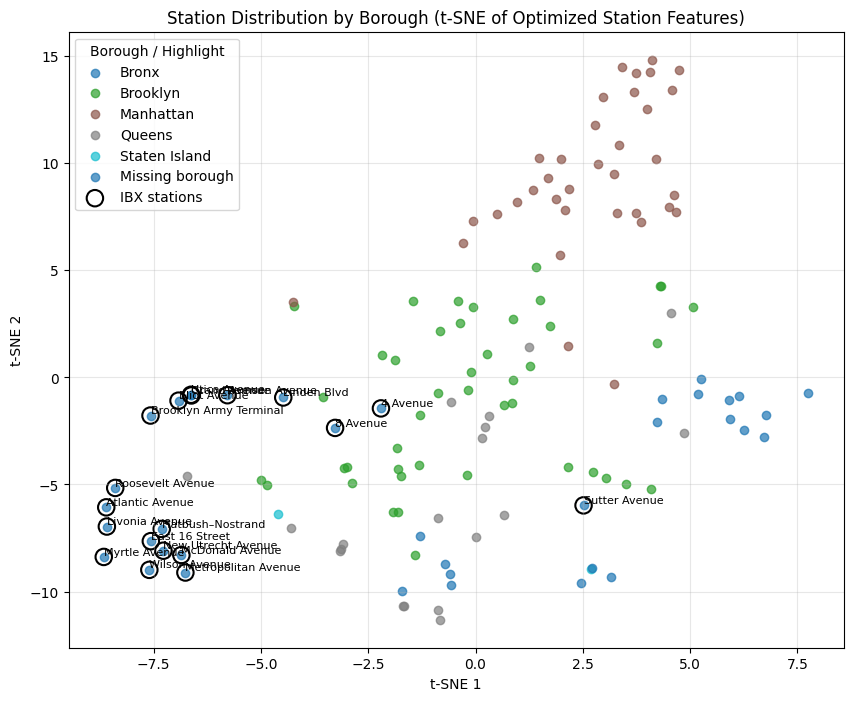

Saved: station_clusters_tsne.csv


In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

RIDERSHIP_URL = "https://raw.githubusercontent.com/hawa1983/Capstone_Network/refs/heads/main/ridership_station_avg_post_2023_2024.csv"
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone_Network/refs/heads/main/station_independent_variables_clean__20260321_041541.csv"

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(FEATURES_URL)
ridership = pd.read_csv(RIDERSHIP_URL)

df["station_complex_id"] = df["station_complex_id"].astype(str).str.strip()
ridership["station_complex_id"] = ridership["station_complex_id"].astype(str).str.strip()

# Keep one borough per station_complex_id from ridership
borough_lookup = (
    ridership[["station_complex_id", "borough"]]
    .dropna(subset=["station_complex_id", "borough"])
    .drop_duplicates(subset=["station_complex_id"])
    .copy()
)

# Merge borough into feature table
df = df.merge(
    borough_lookup,
    on="station_complex_id",
    how="left"
)

print("\nBorough counts after merge:")
print(df["borough"].value_counts(dropna=False))

# Remove ridership columns explicitly if present
df = df.drop(columns=[
    "annual_weekday_avg_ridership",
    "log_ridership"
], errors="ignore")

# =========================================================
# DEFINE IBX FLAG
# =========================================================
if "is_ibx_planned" in df.columns:
    df["is_ibx"] = df["is_ibx_planned"].fillna(0).astype(int).eq(1)
else:
    df["is_ibx"] = df["station_complex_id"].str.startswith("IBX_", na=False)

print("\nIBX count in feature table:")
print(int(df["is_ibx"].sum()))

# =========================================================
# OPTIONAL: CREATE PEAK / MIDDAY SERVICE RATIO
# =========================================================
if {"peak_tph_bidir", "midday_tph_bidir"}.issubset(df.columns):
    denom = df["midday_tph_bidir"].replace(0, np.nan)
    df["tph_peak_to_midday_ratio"] = df["peak_tph_bidir"] / denom

# =========================================================
# OPTIMIZED FEATURES FOR UNSUPERVISED MODELING
# =========================================================
features = [
    # Demand / accessibility
    "population_access_network",
    "jobs_access_network",
    "pct_hh_no_vehicle_access_network",
    "median_hh_income_access_network",
    "pct_transit_access_network",
    "pct_walked_access_network",
    "pct_wfh_access_network",

    # Contextual scale
    "population_0p5mi",

    # Built environment / urban form
    "landuse_entropy_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",

    # Transit supply / network structure
    "bus_routes_access_network",
    "subway_lines_access_network",
    "commuter_lines_access_network",
    "dist_to_commuter_stop_mi_network",
    "has_commuter_stop_within_1mi_network",
    "transfer_subway_station_complexes_0p25mi_network",
    "dist_to_subway_station_complex_mi_network",
    "peak_tph_bidir",
    "tph_peak_to_midday_ratio",
    "subway_lines_serving_station",
    "is_terminal_subway",

    # Anchors / amenities
    "has_university_0p5mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p5mi",

    # Keep for reference only; excluded from clustering matrix below
    "is_ibx_planned",
]

features_available = [f for f in features if f in df.columns]
features_missing = [f for f in features if f not in df.columns]

print("\nFeatures used:")
print(features_available)

if features_missing:
    print("\nMissing features not found in dataframe:")
    print(features_missing)

# =========================================================
# PREP DATA
# =========================================================
data = df[features_available].dropna().copy()
df_plot = df.loc[data.index].copy()

print("\nRows used for clustering:", len(data))
print("Number of features used before dropping IBX flag:", len(features_available))
print("IBX rows used:", int(df_plot["is_ibx"].sum()))

# Exclude IBX planning flag from clustering inputs
X = data.drop(columns=["is_ibx_planned"], errors="ignore")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================================
# K-MEANS CLUSTERING
# =========================================================
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_plot["cluster"] = clusters

# =========================================================
# STATION-CLUSTER MEMBERSHIP TABLE
# =========================================================
station_cluster_df = (
    df_plot[["station_complex_name", "station_complex_id", "borough", "cluster", "is_ibx"]]
    .dropna(subset=["cluster"])
    .drop_duplicates()
    .sort_values(["cluster", "station_complex_name"])
    .copy()
)

station_cluster_df["IBX_station"] = station_cluster_df["is_ibx"].map({
    True: "IBX",
    False: ""
})

station_cluster_df.to_csv("station_clusters.csv", index=False)
print("\nSaved: station_clusters.csv")

# =========================================================
# t-SNE VISUALIZATION (COLOR BY BOROUGH + LABEL IBX)
# =========================================================
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    init="pca",
    learning_rate="auto"
)
X_tsne = tsne.fit_transform(X_scaled)

df_plot["TSNE1"] = X_tsne[:, 0]
df_plot["TSNE2"] = X_tsne[:, 1]

plt.figure(figsize=(10, 8))

boroughs = sorted(df_plot["borough"].dropna().unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(boroughs)))

# Plot all stations by borough
for borough, color in zip(boroughs, colors):
    mask = df_plot["borough"] == borough
    plt.scatter(
        df_plot.loc[mask, "TSNE1"],
        df_plot.loc[mask, "TSNE2"],
        label=borough,
        color=color,
        alpha=0.7
    )

# Show stations with missing borough
missing_mask = df_plot["borough"].isna()
if missing_mask.any():
    plt.scatter(
        df_plot.loc[missing_mask, "TSNE1"],
        df_plot.loc[missing_mask, "TSNE2"],
        label="Missing borough",
        alpha=0.7
    )

# Overlay IBX stations with circle outline
ibx_points = df_plot[df_plot["is_ibx"]].copy()

if not ibx_points.empty:
    plt.scatter(
        ibx_points["TSNE1"],
        ibx_points["TSNE2"],
        s=140,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        label="IBX stations"
    )

    for _, row in ibx_points.iterrows():
        plt.text(
            row["TSNE1"],
            row["TSNE2"],
            str(row["station_complex_name"]),
            fontsize=8,
            ha="left",
            va="bottom"
        )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Station Distribution by Borough (t-SNE of Optimized Station Features)")
plt.legend(title="Borough / Highlight")
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# SAVE t-SNE COORDINATES
# =========================================================
tsne_df = df_plot[
    ["station_complex_name", "station_complex_id", "borough", "cluster", "is_ibx"]
].copy()
tsne_df["TSNE1"] = X_tsne[:, 0]
tsne_df["TSNE2"] = X_tsne[:, 1]

tsne_df.to_csv("station_clusters_tsne.csv", index=False)
print("Saved: station_clusters_tsne.csv")


Cluster x Borough counts:
borough_plot  Bronx  Brooklyn  Manhattan  Missing  Queens  Staten Island
cluster                                                                 
0                 0         0         10        0       0              0
1                 5        14          0       16      11              2
2                11        26          3        6       8              0
3                 0         4         22        0       0              0

Cluster x Borough shares:
borough_plot  Bronx  Brooklyn  Manhattan  Missing  Queens  Staten Island
cluster                                                                 
0             0.000     0.000      1.000    0.000   0.000          0.000
1             0.104     0.292      0.000    0.333   0.229          0.042
2             0.204     0.481      0.056    0.111   0.148          0.000
3             0.000     0.154      0.846    0.000   0.000          0.000


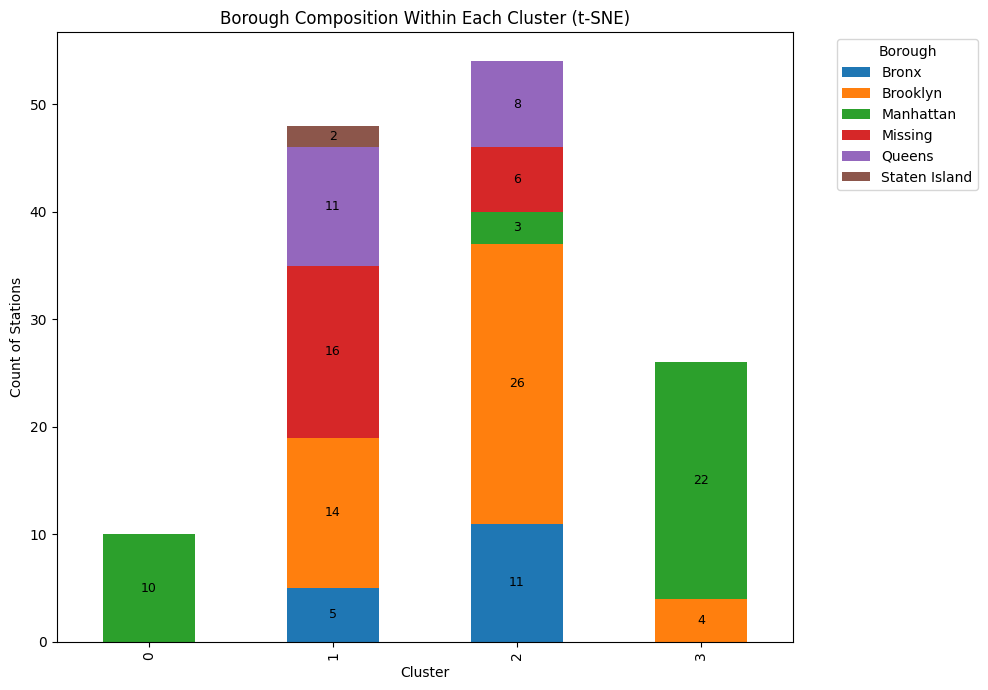

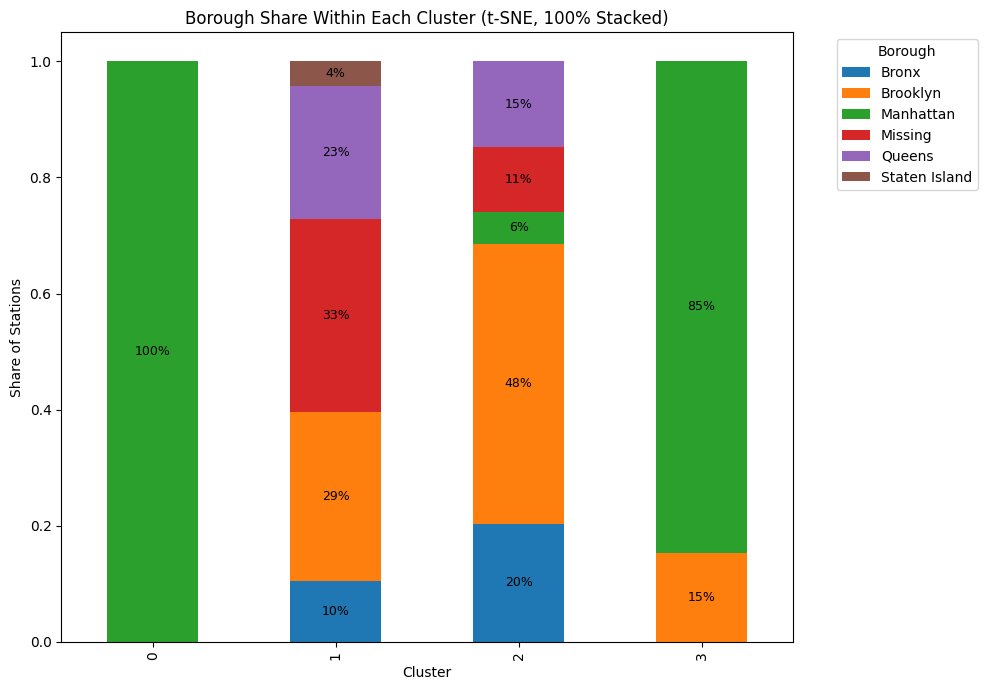

In [87]:
# =========================================================
# STACKED BAR CHART: BOROUGH COUNTS WITHIN EACH CLUSTER
# Updated for t-SNE workflow with borough merge + missing handling
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1) Validate required columns
# ---------------------------------------------------------
required_cols = {"cluster", "borough"}
missing = required_cols - set(df_plot.columns)
if missing:
    raise ValueError(f"df_plot is missing required columns: {missing}")

# Label missing boroughs explicitly
df_plot["borough_plot"] = df_plot["borough"].fillna("Missing")

# ---------------------------------------------------------
# 2) Count station complexes by cluster and borough
# ---------------------------------------------------------
cluster_borough_counts = (
    df_plot
    .groupby(["cluster", "borough_plot"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Save counts table
cluster_borough_counts.to_csv("tsne_cluster_borough_counts.csv")

print("\nCluster x Borough counts:")
print(cluster_borough_counts)

# ---------------------------------------------------------
# 3) Compute within-cluster shares
# ---------------------------------------------------------
cluster_borough_share = cluster_borough_counts.div(
    cluster_borough_counts.sum(axis=1),
    axis=0
).fillna(0)

# Save shares table
cluster_borough_share.to_csv("tsne_cluster_borough_shares.csv")

print("\nCluster x Borough shares:")
print(cluster_borough_share.round(3))

# ---------------------------------------------------------
# 4) Stacked count chart
# ---------------------------------------------------------
ax = cluster_borough_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 7)
)

ax.set_xlabel("Cluster")
ax.set_ylabel("Count of Stations")
ax.set_title("Borough Composition Within Each Cluster (t-SNE)")
ax.legend(title="Borough", bbox_to_anchor=(1.05, 1), loc="upper left")

# Annotate each stack segment with counts
for i, cluster in enumerate(cluster_borough_counts.index):
    cumulative_height = 0

    for borough in cluster_borough_counts.columns:
        count = cluster_borough_counts.loc[cluster, borough]

        if count > 0:
            y = cumulative_height + count / 2
            ax.text(
                i,
                y,
                str(int(count)),
                ha="center",
                va="center",
                fontsize=9
            )

        cumulative_height += count

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5) Optional 100% stacked chart for proportional comparison
# ---------------------------------------------------------
ax = cluster_borough_share.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 7)
)

ax.set_xlabel("Cluster")
ax.set_ylabel("Share of Stations")
ax.set_title("Borough Share Within Each Cluster (t-SNE, 100% Stacked)")
ax.legend(title="Borough", bbox_to_anchor=(1.05, 1), loc="upper left")

# Annotate larger share segments with percentages
for i, cluster in enumerate(cluster_borough_share.index):
    cumulative_height = 0

    for borough in cluster_borough_share.columns:
        share = cluster_borough_share.loc[cluster, borough]

        if share > 0.03:
            y = cumulative_height + share / 2
            ax.text(
                i,
                y,
                f"{share:.0%}",
                ha="center",
                va="center",
                fontsize=9
            )

        cumulative_height += share

plt.tight_layout()
plt.show()

## Hierarchical Clustering


Borough counts after merge:
borough
Brooklyn         156
Manhattan        121
Queens            79
Bronx             68
NaN               38
Staten Island      2
Name: count, dtype: int64

IBX count in feature table:
19

Features used:
['population_access_network', 'jobs_access_network', 'pct_hh_no_vehicle_access_network', 'median_hh_income_access_network', 'pct_transit_access_network', 'pct_walked_access_network', 'pct_wfh_access_network', 'population_0p5mi', 'landuse_entropy_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'bus_routes_access_network', 'subway_lines_access_network', 'commuter_lines_access_network', 'dist_to_commuter_stop_mi_network', 'has_commuter_stop_within_1mi_network', 'transfer_subway_station_complexes_0p25mi_network', 'dist_to_subway_station_complex_mi_network', 'peak_tph_bidir', 'tph_peak_to_midday_ratio', 'subway_lines_serving_station', 'is_terminal_subway', 'has_university_0p5mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p5mi_

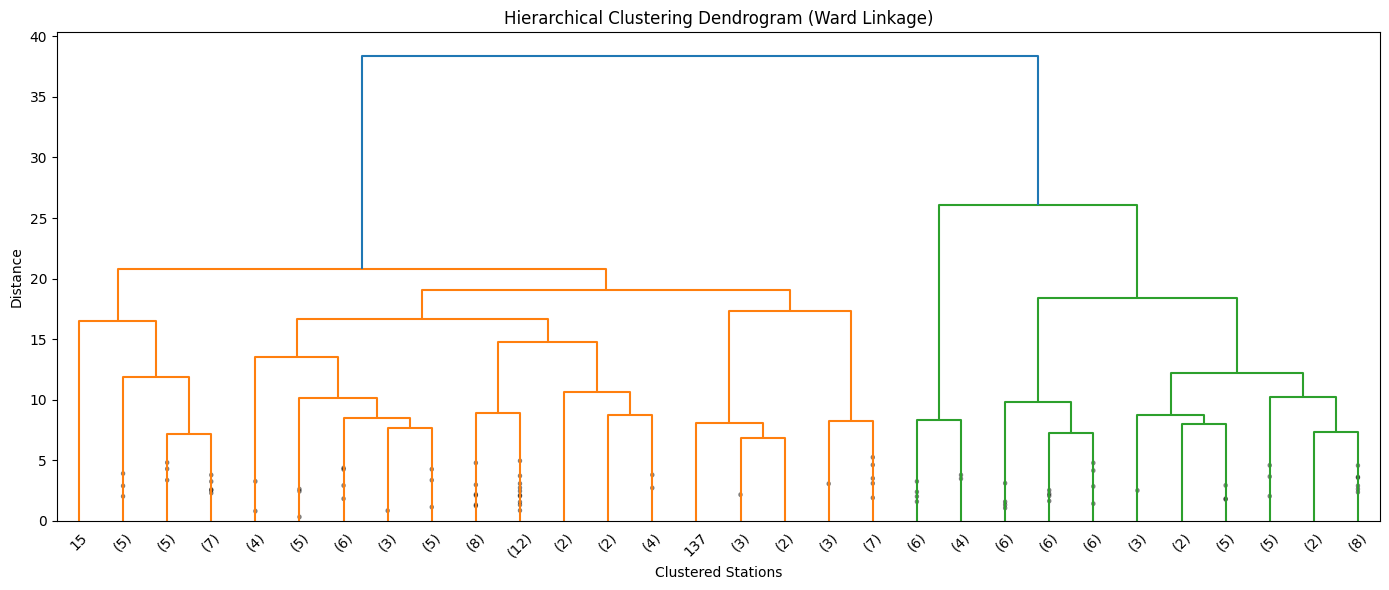


Saved: station_clusters_hierarchical.csv


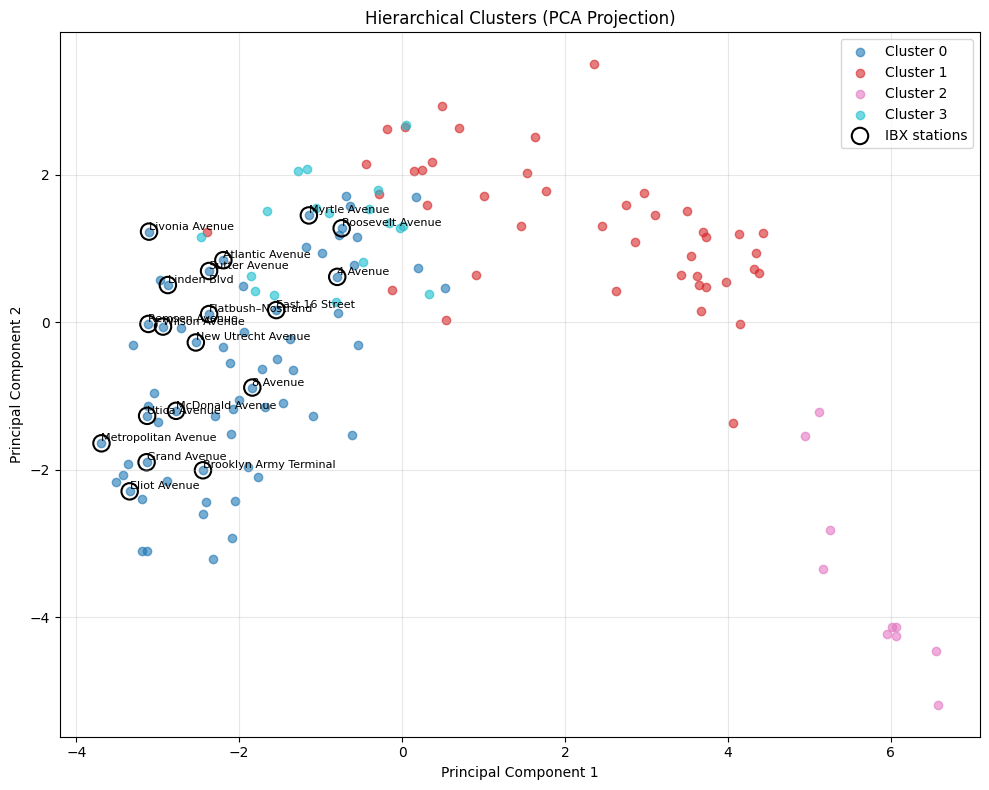

Saved: hierarchical_cluster_borough_counts.csv

Cluster x Borough counts:
borough_plot  Bronx  Brooklyn  Manhattan  Missing  Queens  Staten Island
cluster                                                                 
0                 5        21          1       22      16              2
1                 0        18         23        0       2              0
2                 0         0         10        0       0              0
3                11         5          1        0       1              0
Saved: ibx_hierarchical_cluster_summary.csv


,cluster,ibx_count,total_stations,ibx_share
0,0,19,67,0.283582
1,1,0,43,0.000000
2,2,0,10,0.000000
3,3,0,18,0.000000


Saved: station_clusters_hierarchical_pca.csv
Saved: hierarchical_cluster_feature_means.csv


,population_access_network,jobs_access_network,pct_hh_no_vehicle_access_network,median_hh_income_access_network,pct_transit_access_network,pct_walked_access_network,pct_wfh_access_network,population_0p5mi,landuse_entropy_0p5mi,intersection_density_0p5mi,...,dist_to_subway_station_complex_mi_network,peak_tph_bidir,tph_peak_to_midday_ratio,subway_lines_serving_station,is_terminal_subway,has_university_0p5mi,has_hospital_0p5mi,has_stadium_0p1mi,cultural_count_0p5mi_capped10,adjacent_major_park_0p5mi
cluster,,,,,,,,,,,,,,,,,,,,,
0,16448.657,4384.776,33.067,64793.133,51.042,8.118,5.419,30690.418,1.767,396.824,...,0.096,25.343,1.431,2.194,0.134,0.104,0.134,0.000,3.940,0.328
1,11699.767,12739.674,8.563,114700.956,57.025,16.772,11.736,45399.884,1.832,669.852,...,0.000,39.349,1.271,2.279,0.023,0.674,0.465,0.000,9.814,0.093
2,10616.600,58423.200,5.868,128425.116,39.598,35.723,12.766,39001.700,1.458,364.477,...,0.000,26.500,1.048,1.500,0.000,1.000,0.200,0.000,10.000,0.300
3,17701.556,3707.111,18.071,38166.839,67.427,7.531,4.545,53746.222,2.058,703.604,...,0.000,28.222,1.162,2.056,0.000,0.389,0.278,0.056,5.056,0.167


In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

RIDERSHIP_URL = "https://raw.githubusercontent.com/hawa1983/Capstone_Network/refs/heads/main/ridership_station_avg_post_2023_2024.csv"
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone_Network/refs/heads/main/station_independent_variables_clean__20260321_041541.csv"

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(FEATURES_URL)
ridership = pd.read_csv(RIDERSHIP_URL)

df["station_complex_id"] = df["station_complex_id"].astype(str).str.strip()
ridership["station_complex_id"] = ridership["station_complex_id"].astype(str).str.strip()

# Remove ridership columns explicitly if present
df = df.drop(columns=[
    "annual_weekday_avg_ridership",
    "log_ridership"
], errors="ignore")

# =========================================================
# MERGE BOROUGH
# =========================================================
borough_lookup = (
    ridership[["station_complex_id", "borough"]]
    .dropna(subset=["station_complex_id", "borough"])
    .drop_duplicates(subset=["station_complex_id"])
    .copy()
)

df = df.merge(
    borough_lookup,
    on="station_complex_id",
    how="left"
)

print("\nBorough counts after merge:")
print(df["borough"].value_counts(dropna=False))

# =========================================================
# DEFINE IBX FLAG
# =========================================================
if "is_ibx_planned" in df.columns:
    df["is_ibx"] = df["is_ibx_planned"].fillna(0).astype(int).eq(1)
else:
    df["is_ibx"] = df["station_complex_id"].str.startswith("IBX_", na=False)

print("\nIBX count in feature table:")
print(int(df["is_ibx"].sum()))

# =========================================================
# OPTIONAL: CREATE PEAK / MIDDAY SERVICE RATIO
# =========================================================
if {"peak_tph_bidir", "midday_tph_bidir"}.issubset(df.columns):
    denom = df["midday_tph_bidir"].replace(0, np.nan)
    df["tph_peak_to_midday_ratio"] = df["peak_tph_bidir"] / denom

# =========================================================
# OPTIMIZED FEATURE SET
# =========================================================
features = [
    # Demand / accessibility
    "population_access_network",
    "jobs_access_network",
    "pct_hh_no_vehicle_access_network",
    "median_hh_income_access_network",
    "pct_transit_access_network",
    "pct_walked_access_network",
    "pct_wfh_access_network",

    # Contextual scale
    "population_0p5mi",

    # Built environment / urban form
    "landuse_entropy_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",

    # Transit supply / network structure
    "bus_routes_access_network",
    "subway_lines_access_network",
    "commuter_lines_access_network",
    "dist_to_commuter_stop_mi_network",
    "has_commuter_stop_within_1mi_network",
    "transfer_subway_station_complexes_0p25mi_network",
    "dist_to_subway_station_complex_mi_network",
    "peak_tph_bidir",
    "tph_peak_to_midday_ratio",
    "subway_lines_serving_station",
    "is_terminal_subway",

    # Anchors / amenities
    "has_university_0p5mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p5mi",

    # Keep for reference only; exclude from clustering below
    "is_ibx_planned",
]

features_available = [f for f in features if f in df.columns]
features_missing = [f for f in features if f not in df.columns]

print("\nFeatures used:")
print(features_available)

if features_missing:
    print("\nMissing features not found in dataframe:")
    print(features_missing)

# =========================================================
# PREP DATA
# =========================================================
data = df[features_available].dropna().copy()
df_plot = df.loc[data.index].copy()

print("\nRows used for clustering:", len(data))
print("Number of features used before dropping IBX flag:", len(features_available))
print("IBX rows used:", int(df_plot["is_ibx"].sum()))

# Exclude IBX planning flag from clustering inputs
X = data.drop(columns=["is_ibx_planned"], errors="ignore")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================================
# HIERARCHICAL CLUSTERING
# =========================================================
n_clusters = 4

hc = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric="euclidean",
    linkage="ward"
)

df_plot["cluster"] = hc.fit_predict(X_scaled)

# =========================================================
# DENDROGRAM
# =========================================================
# For the dendrogram, use scipy linkage on the scaled data
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Clustered Stations")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# =========================================================
# CLUSTER MEMBERSHIP TABLE
# =========================================================
station_cluster_df = (
    df_plot[
        [
            "station_complex_name",
            "station_complex_id",
            "borough",
            "cluster",
            "is_ibx"
        ]
    ]
    .drop_duplicates()
    .sort_values(["cluster", "station_complex_name"])
    .copy()
)

station_cluster_df["IBX_station"] = station_cluster_df["is_ibx"].map({
    True: "IBX",
    False: ""
})

station_cluster_df.to_csv("station_clusters_hierarchical.csv", index=False)
print("\nSaved: station_clusters_hierarchical.csv")

# =========================================================
# PCA VISUALIZATION FOR HIERARCHICAL CLUSTERS
# =========================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot["PC1"] = X_pca[:, 0]
df_plot["PC2"] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for cluster, color in zip(range(n_clusters), colors):
    mask = df_plot["cluster"] == cluster
    plt.scatter(
        df_plot.loc[mask, "PC1"],
        df_plot.loc[mask, "PC2"],
        label=f"Cluster {cluster}",
        color=color,
        alpha=0.6
    )

# Highlight IBX stations
ibx_points = df_plot[df_plot["is_ibx"]].copy()

if not ibx_points.empty:
    plt.scatter(
        ibx_points["PC1"],
        ibx_points["PC2"],
        s=140,
        facecolors="none",
        edgecolors="black",
        linewidths=1.5,
        label="IBX stations"
    )

    for _, row in ibx_points.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            str(row["station_complex_name"]),
            fontsize=8,
            ha="left",
            va="bottom"
        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clusters (PCA Projection)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# BOROUGH COUNTS WITHIN EACH HIERARCHICAL CLUSTER
# =========================================================
df_plot["borough_plot"] = df_plot["borough"].fillna("Missing")

cluster_borough_counts = (
    df_plot
    .groupby(["cluster", "borough_plot"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

cluster_borough_counts.to_csv("hierarchical_cluster_borough_counts.csv")
print("Saved: hierarchical_cluster_borough_counts.csv")

print("\nCluster x Borough counts:")
print(cluster_borough_counts)

# =========================================================
# IBX COUNT BY CLUSTER
# =========================================================
all_clusters = pd.Series(0, index=sorted(df_plot["cluster"].unique()))

ibx_cluster_counts = (
    df_plot[df_plot["is_ibx"]]
    .groupby("cluster")["station_complex_id"]
    .count()
)

ibx_cluster_counts = all_clusters.add(ibx_cluster_counts, fill_value=0).astype(int)

cluster_totals = df_plot.groupby("cluster")["station_complex_id"].count()
ibx_share = (ibx_cluster_counts / cluster_totals).fillna(0)

ibx_cluster_summary = pd.DataFrame({
    "cluster": ibx_cluster_counts.index,
    "ibx_count": ibx_cluster_counts.values,
    "total_stations": cluster_totals.reindex(ibx_cluster_counts.index).values.astype(int),
    "ibx_share": ibx_share.reindex(ibx_cluster_counts.index).values
})

ibx_cluster_summary.to_csv("ibx_hierarchical_cluster_summary.csv", index=False)
print("Saved: ibx_hierarchical_cluster_summary.csv")
display(ibx_cluster_summary)

# =========================================================
# SAVE PCA COORDINATES
# =========================================================
pca_df = df_plot[
    ["station_complex_name", "station_complex_id", "borough", "cluster", "is_ibx"]
].copy()
pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]

pca_df.to_csv("station_clusters_hierarchical_pca.csv", index=False)
print("Saved: station_clusters_hierarchical_pca.csv")

# =========================================================
# CLUSTER FEATURE MEANS
# =========================================================
cluster_summary = (
    df_plot.groupby("cluster")[X.columns]
    .mean()
    .round(3)
)

cluster_summary.to_csv("hierarchical_cluster_feature_means.csv", index=True)
print("Saved: hierarchical_cluster_feature_means.csv")
display(cluster_summary)

# Supervised Modeling

## Construction of OD-Based Accessibility Measures

This step constructs gravity-based accessibility measures using exponential distance decay to approximate origin-destination (OD) effects. These variables quantify the level of employment and destination opportunities reachable from each station and are incorporated as predictors in the ridership model.

In [ ]:
import pandas as pd
import numpy as np

# =========================================================
# LOAD DATA
# =========================================================
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv"

df = pd.read_csv(FEATURES_URL)
df["station_complex_id"] = df["station_complex_id"].astype(str).str.strip()

# =========================================================
# SETTINGS
# =========================================================
lambda_val = 0.5  # moderate exponential decay

# =========================================================
# CHOOSE COORDINATE COLUMNS
# =========================================================
if {"longitude", "latitude"}.issubset(df.columns):
    lon_col = "longitude"
    lat_col = "latitude"
elif {"lon", "lat"}.issubset(df.columns):
    lon_col = "lon"
    lat_col = "lat"
else:
    raise ValueError(
        "No longitude/latitude columns found in station_independent_variables_final.csv. "
        "Add coordinates first or update lon_col/lat_col to match your file."
    )

# =========================================================
# HAVERSINE DISTANCE FUNCTION (MILES)
# =========================================================
def haversine_miles(lon1, lat1, lon2, lat2):
    R = 3958.756

    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

# =========================================================
# MAIN OD PROXY: JOBS WITH EXPONENTIAL DECAY
# OD_jobs_i = sum_j jobs_j * exp(-lambda * d_ij), j != i
# =========================================================
main_required = ["jobs_0p5mi", lon_col, lat_col]
missing_main = [c for c in main_required if c not in df.columns]
if missing_main:
    raise ValueError(f"Missing required columns for main OD proxy: {missing_main}")

df_main = df.dropna(subset=["jobs_0p5mi", lon_col, lat_col]).copy()

coords_main = df_main[[lon_col, lat_col]].to_numpy(dtype=float)
jobs = df_main["jobs_0p5mi"].to_numpy(dtype=float)

n_main = len(df_main)
od_jobs_exp = np.zeros(n_main, dtype=float)

for i in range(n_main):
    lon_i, lat_i = coords_main[i]

    dists = haversine_miles(
        lon_i,
        lat_i,
        coords_main[:, 0],
        coords_main[:, 1]
    )

    dists[i] = np.nan
    weights = np.exp(-lambda_val * dists)

    od_jobs_exp[i] = np.nansum(jobs * weights)

df_main["od_jobs_exp_accessibility"] = od_jobs_exp
df_main["log_od_jobs_exp_accessibility"] = np.log1p(df_main["od_jobs_exp_accessibility"])

# =========================================================
# SENSITIVITY OD PROXY: COMPOSITE DESTINATION ATTRACTIVENESS
# Composite_j * exp(-lambda * d_ij)
# =========================================================
candidate_cols = [
    "jobs_0p5mi",
    "population_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "cultural_count_0p5mi_capped10",
    "has_university_0p5mi",
    "has_hospital_0p5mi"
]

available_cols = [c for c in candidate_cols if c in df.columns]
if len(available_cols) == 0:
    raise ValueError("No destination attractiveness columns found for sensitivity OD proxy.")

df_sens = df.dropna(subset=[lon_col, lat_col]).copy()

attr = df_sens[available_cols].copy().fillna(0)

# Standardize each component
for col in available_cols:
    mean_val = attr[col].mean()
    std_val = attr[col].std(ddof=0)

    if std_val == 0 or pd.isna(std_val):
        attr[col + "_z"] = 0
    else:
        attr[col + "_z"] = (attr[col] - mean_val) / std_val

z_cols = [c + "_z" for c in available_cols]
df_sens["destination_attractiveness_index"] = attr[z_cols].sum(axis=1)

coords_sens = df_sens[[lon_col, lat_col]].to_numpy(dtype=float)
attractiveness = df_sens["destination_attractiveness_index"].to_numpy(dtype=float)

n_sens = len(df_sens)
od_composite_exp = np.zeros(n_sens, dtype=float)

for i in range(n_sens):
    lon_i, lat_i = coords_sens[i]

    dists = haversine_miles(
        lon_i,
        lat_i,
        coords_sens[:, 0],
        coords_sens[:, 1]
    )

    dists[i] = np.nan
    weights = np.exp(-lambda_val * dists)

    od_composite_exp[i] = np.nansum(attractiveness * weights)

df_sens["od_composite_exp_accessibility"] = od_composite_exp

min_val = df_sens["od_composite_exp_accessibility"].min()
if min_val <= 0:
    df_sens["log_od_composite_exp_accessibility"] = np.log1p(
        df_sens["od_composite_exp_accessibility"] - min_val + 1
    )
else:
    df_sens["log_od_composite_exp_accessibility"] = np.log1p(
        df_sens["od_composite_exp_accessibility"]
    )

# =========================================================
# MERGE BOTH PROXIES BACK TO MASTER FILE
# =========================================================
df_out = df.merge(
    df_main[[
        "station_complex_id",
        "od_jobs_exp_accessibility",
        "log_od_jobs_exp_accessibility"
    ]],
    on="station_complex_id",
    how="left"
)

df_out = df_out.merge(
    df_sens[[
        "station_complex_id",
        "destination_attractiveness_index",
        "od_composite_exp_accessibility",
        "log_od_composite_exp_accessibility"
    ]],
    on="station_complex_id",
    how="left"
)

# =========================================================
# SAVE UPDATED FILE
# =========================================================
output_file = "station_independent_variables_with_od_proxies.csv"
df_out.to_csv(output_file, index=False)

print("Saved file:")
print(output_file)

print("\nNew OD proxy columns added:")
print([
    "od_jobs_exp_accessibility",
    "log_od_jobs_exp_accessibility",
    "destination_attractiveness_index",
    "od_composite_exp_accessibility",
    "log_od_composite_exp_accessibility"
])

print("\nPreview:")
print(
    df_out[[
        "station_complex_id",
        "station_complex_name",
        "od_jobs_exp_accessibility",
        "od_composite_exp_accessibility"
    ]].head(10).to_string(index=False)
)

Saved file:
station_independent_variables_with_od_proxies.csv

New OD proxy columns added:
['od_jobs_exp_accessibility', 'log_od_jobs_exp_accessibility', 'destination_attractiveness_index', 'od_composite_exp_accessibility', 'log_od_composite_exp_accessibility']

Preview:
station_complex_id          station_complex_name  od_jobs_exp_accessibility  od_composite_exp_accessibility
               293 Van Cortlandt Park-242 St (1)              286709.303714                      -19.845129
               294                    238 St (1)              325071.230247                      -20.154804
               295                    231 St (1)              380762.648189                      -15.584936
               296        Marble Hill-225 St (1)              425145.956505                      -13.565271
               297                    215 St (1)              485413.126332                       -8.411072
               298                    207 St (1)              544431.182402     

## OD Accessibility Patterns: IBX vs Existing Stations

In [ ]:
print(df_out["od_jobs_exp_accessibility"].describe())
print(df_out["od_composite_exp_accessibility"].describe())

count    4.640000e+02
mean     2.473448e+06
std      2.633539e+06
min      3.981017e+03
25%      5.821334e+05
50%      1.283487e+06
75%      3.504352e+06
max      9.402269e+06
Name: od_jobs_exp_accessibility, dtype: float64
count    464.000000
mean      44.889122
std      128.982468
min      -95.651478
25%      -44.505585
50%      -11.440849
75%      112.125783
max      353.223807
Name: od_composite_exp_accessibility, dtype: float64


In [ ]:
df_out["is_ibx"] = df_out["station_complex_id"].str.startswith("IBX_")

print(df_out.groupby("is_ibx")[[
    "od_jobs_exp_accessibility",
    "od_composite_exp_accessibility"
]].mean())

        od_jobs_exp_accessibility  od_composite_exp_accessibility
is_ibx                                                           
False                2.528902e+06                       49.167515
True                 1.174643e+06                      -55.315348


IBX stations exhibit substantially lower accessibility to employment and destination opportunities relative to existing stations, indicating that the corridor primarily serves lower-access outer-borough environments. This reinforces the importance of incorporating network-based accessibility measures in ridership forecasting.

## Clustering and Feature Engineering with OD-Enhanced Variables

This step incorporates OD-based accessibility measures, applies clustering to identify station typologies, and generates transformed and interaction variables to enhance model readiness and capture nonlinear relationships in ridership prediction.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

RIDERSHIP_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_station_avg_post_2023_2024.csv"
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_with_od_proxies.csv"

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv(FEATURES_URL)
ridership = pd.read_csv(RIDERSHIP_URL)

df["station_complex_id"] = df["station_complex_id"].astype(str).str.strip()
ridership["station_complex_id"] = ridership["station_complex_id"].astype(str).str.strip()

print("Features rows:", len(df))
print("Ridership rows:", len(ridership))

# =========================================================
# 2. MERGE BOROUGH INTO FEATURES
# =========================================================
borough_lookup = (
    ridership[["station_complex_id", "borough"]]
    .dropna()
    .drop_duplicates(subset=["station_complex_id"])
)

df = df.merge(
    borough_lookup,
    on="station_complex_id",
    how="left"
)

print("\nBorough coverage:")
print(df["borough"].value_counts(dropna=False))

# =========================================================
# 3. DEFINE FEATURES
#    Include main OD proxy for primary workflow.
#    Keep sensitivity proxy available in the dataset, but do
#    not include it in the main clustering/training feature set.
# =========================================================
features = [
    "population_0p5mi",
    "pop_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",
    "jobs_0p5mi",
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
    "log_od_jobs_exp_accessibility"
]

features_available = [f for f in features if f in df.columns]
features_missing = [f for f in features if f not in df.columns]

print("\nFeatures available for clustering/model prep:")
print(features_available)

if features_missing:
    print("\nRequested features missing from dataframe:")
    print(features_missing)

# =========================================================
# 4. CLEAN + PREP FOR CLUSTERING
# =========================================================
data = df[features_available].dropna().copy()
df_plot = df.loc[data.index].copy()

print("\nRows used for clustering:", len(df_plot))

# Flag IBX
df_plot["is_ibx"] = df_plot["station_complex_id"].str.startswith("IBX_", na=False)

# =========================================================
# 5. SCALE + KMEANS
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_plot["cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster sizes:")
print(df_plot["cluster"].value_counts().sort_index())

print("\nIBX by cluster:")
print(df_plot.groupby("cluster")["is_ibx"].sum())

# =========================================================
# 6. MERGE RIDERSHIP INTO df_plot
# =========================================================
ridership_keep = ridership[[
    "station_complex_id",
    "avg_annual_ridership",
    "log_avg_ridership"
]]

df_model = df_plot.merge(
    ridership_keep,
    on="station_complex_id",
    how="left"
)

print("\nRows after ridership merge:", len(df_model))

# =========================================================
# 7. TRAINING DATA (CLUSTER 2)
# =========================================================
train_df = df_model[
    (df_model["cluster"] == 2) &
    (df_model["log_avg_ridership"].notna())
].copy()

print("\nTraining rows:", len(train_df))

# =========================================================
# 8. IBX DATA (PREDICTION SET)
# =========================================================
ibx_df = df_model[df_model["is_ibx"]].copy()

print("\nIBX rows:", len(ibx_df))
print("\nIBX by cluster:")
print(ibx_df["cluster"].value_counts().sort_index())

# =========================================================
# 9. FEATURE ENGINEERING
#    Log transforms + interaction terms
#    No model fitting here.
# =========================================================
for col in ["jobs_0p5mi", "population_0p5mi", "pop_density_0p5mi"]:
    if col in train_df.columns:
        train_df[f"log_{col}"] = np.log1p(train_df[col])
    if col in ibx_df.columns:
        ibx_df[f"log_{col}"] = np.log1p(ibx_df[col])

def add_interactions(df_in):
    df_out = df_in.copy()
    df_out["jobs_x_transit"] = df_out["jobs_0p5mi"] * df_out["pct_transit_0p5mi"]
    df_out["density_x_no_vehicle"] = df_out["pop_density_0p5mi"] * df_out["pct_hh_no_vehicle_0p5mi"]
    df_out["jobs_x_bus"] = df_out["jobs_0p5mi"] * df_out["bus_routes_0p5mi"]
    return df_out

train_df = add_interactions(train_df)
ibx_df = add_interactions(ibx_df)

engineered_features = [
    "log_jobs_0p5mi",
    "log_population_0p5mi",
    "log_pop_density_0p5mi",
    "jobs_x_transit",
    "density_x_no_vehicle",
    "jobs_x_bus"
]

features_model = features_available + engineered_features

print("\nNumber of model-prep features:", len(features_model))
print("\nEngineered features added:")
print(engineered_features)

# =========================================================
# 10. OPTIONAL SENSITIVITY FEATURE SET
#     This uses the composite OD proxy instead of the main OD proxy.
# =========================================================
features_sensitivity = [
    f for f in features_available
    if f != "log_od_jobs_exp_accessibility"
]

if "log_od_composite_exp_accessibility" in df.columns:
    features_sensitivity = features_sensitivity + ["log_od_composite_exp_accessibility"]

features_model_sensitivity = features_sensitivity + engineered_features

print("\nNumber of sensitivity-model features:", len(features_model_sensitivity))
print("\nSensitivity OD feature included:",
      "log_od_composite_exp_accessibility" in features_model_sensitivity)

# =========================================================
# 11. FINAL CHECKS
# =========================================================
print("\nColumns available in df_model:")
print(df_model.columns.tolist())

print("\nColumns available in train_df:")
print(train_df.columns.tolist())

print("\nColumns available in ibx_df:")
print(ibx_df.columns.tolist())

# Keep IBX rows with complete model features
ibx_pred_df = ibx_df.dropna(subset=features_model).copy()

print("\nIBX rows with complete main-model features:", len(ibx_pred_df))

# Keep IBX rows with complete sensitivity-model features
ibx_pred_df_sensitivity = ibx_df.dropna(subset=features_model_sensitivity).copy()

print("IBX rows with complete sensitivity-model features:", len(ibx_pred_df_sensitivity))

# =========================================================
# 12. SAVE CLEAN DATASETS
# =========================================================
df_model.to_csv("full_dataset_with_clusters_od.csv", index=False)
train_df.to_csv("training_cluster2_with_od_interactions.csv", index=False)
ibx_df.to_csv("ibx_prediction_set_with_od_interactions.csv", index=False)
ibx_pred_df.to_csv("ibx_prediction_set_complete_main_features.csv", index=False)
ibx_pred_df_sensitivity.to_csv("ibx_prediction_set_complete_sensitivity_features.csv", index=False)

print("\nSaved:")
print(" - full_dataset_with_clusters_od.csv")
print(" - training_cluster2_with_od_interactions.csv")
print(" - ibx_prediction_set_with_od_interactions.csv")
print(" - ibx_prediction_set_complete_main_features.csv")
print(" - ibx_prediction_set_complete_sensitivity_features.csv")

Features rows: 464
Ridership rows: 426

Borough coverage:
borough
Brooklyn         156
Manhattan        121
Queens            79
Bronx             68
NaN               38
Staten Island      2
Name: count, dtype: int64

Features available for clustering/model prep:
['population_0p5mi', 'pop_density_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi_approx', 'pct_transit_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_walked_0p5mi', 'pct_bicycle_0p5mi', 'pct_taxicab_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_mi', 'has_university_0p25mi', 'has_university_0p5mi', 'has_hospital_0p25mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p25mi', 'cultural_count_0p5mi', 'cultural_cou

## **Train–Test Split Strategy**

The supervised modeling dataset was restricted to stations within Cluster 2 to ensure alignment with IBX-relevant built environment characteristics. A random 80/20 train–test split was applied, where 80% of the observations were used to train the model and 20% were held out for evaluation.

A random split was selected because the modeling task is a regression problem with a continuous outcome variable (ridership), and there is no categorical structure requiring stratification. This approach preserves the natural variation in the data while enabling unbiased performance evaluation on unseen observations.

IBX stations were excluded from the training and testing process and retained as a separate prediction set, ensuring that model performance is assessed independently from the final forecasting application.


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

RIDERSHIP_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_station_avg_post_2023_2024.csv"
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv"

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv(FEATURES_URL)
ridership = pd.read_csv(RIDERSHIP_URL)

df["station_complex_id"] = df["station_complex_id"].astype(str).str.strip()
ridership["station_complex_id"] = ridership["station_complex_id"].astype(str).str.strip()

print("Features rows:", len(df))
print("Ridership rows:", len(ridership))

# =========================================================
# 2. MERGE BOROUGH INTO FEATURES
# =========================================================
borough_lookup = (
    ridership[["station_complex_id", "borough"]]
    .dropna()
    .drop_duplicates(subset=["station_complex_id"])
)

df = df.merge(
    borough_lookup,
    on="station_complex_id",
    how="left"
)

print("\nBorough coverage:")
print(df["borough"].value_counts(dropna=False))

# =========================================================
# 3. DEFINE FEATURES
# =========================================================
features = [
    "population_0p5mi",
    "pop_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",
    "jobs_0p5mi",
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
]

features_available = [f for f in features if f in df.columns]

# =========================================================
# 4. CLEAN + PREP FOR CLUSTERING
# =========================================================
data = df[features_available].dropna().copy()
df_plot = df.loc[data.index].copy()

print("\nRows used for clustering:", len(df_plot))

# Flag IBX
df_plot["is_ibx"] = df_plot["station_complex_id"].str.startswith("IBX_", na=False)

# =========================================================
# 5. SCALE + KMEANS
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_plot["cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster sizes:")
print(df_plot["cluster"].value_counts().sort_index())

print("\nIBX by cluster:")
print(df_plot.groupby("cluster")["is_ibx"].sum())

# =========================================================
# 6. MERGE RIDERSHIP INTO df_plot
# =========================================================
ridership_keep = ridership[[
    "station_complex_id",
    "avg_annual_ridership",
    "log_avg_ridership"
]]

df_model = df_plot.merge(
    ridership_keep,
    on="station_complex_id",
    how="left"
)

print("\nRows after ridership merge:", len(df_model))

# =========================================================
# 7. TRAINING DATA (CLUSTER 2)
# =========================================================
train_df = df_model[
    (df_model["cluster"] == 2) &
    (df_model["log_avg_ridership"].notna())
].copy()

print("\nTraining rows:", len(train_df))

# =========================================================
# 8. IBX DATA (PREDICTION SET)
# =========================================================
ibx_df = df_model[df_model["is_ibx"]].copy()

print("\nIBX rows:", len(ibx_df))
print("\nIBX by cluster:")
print(ibx_df["cluster"].value_counts().sort_index())

# =========================================================
# 9. FINAL CHECKS
# =========================================================
print("\nColumns available:")
print(df_model.columns.tolist())

# =========================================================
# 10. SAVE CLEAN DATASETS
# =========================================================
df_model.to_csv("full_dataset_with_clusters.csv", index=False)
train_df.to_csv("training_cluster2.csv", index=False)
ibx_df.to_csv("ibx_prediction_set.csv", index=False)

print("\nSaved:")
print(" - full_dataset_with_clusters.csv")
print(" - training_cluster2.csv")
print(" - ibx_prediction_set.csv")

Features rows: 464
Ridership rows: 426

Borough coverage:
borough
Brooklyn         156
Manhattan        121
Queens            79
Bronx             68
NaN               38
Staten Island      2
Name: count, dtype: int64

Rows used for clustering: 464

Cluster sizes:
cluster
0    195
1     68
2    174
3     27
Name: count, dtype: int64

IBX by cluster:
cluster
0     3
1     0
2    15
3     1
Name: is_ibx, dtype: int64

Rows after ridership merge: 464

Training rows: 156

IBX rows: 19

IBX by cluster:
cluster
0     3
2    15
3     1
Name: count, dtype: int64

Columns available:
['station_complex_id', 'station_complex_name', 'buffer_area_sqmi', 'pop_density_0p5mi', 'pop_rank', 'population_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi', 'pct_workers_wfh_0p5mi', 'pct_car_tr

## **Supervised Modeling Approach**

The supervised modeling stage uses the prepared dataset generated from the clustering pipeline, specifically restricting the training sample to stations within Cluster 2. This ensures that the model is calibrated on environments most comparable to IBX station contexts.

The feature matrix consists of built environment and accessibility variables, while the dependent variable is specified as the log-transformed average annual ridership to address skewness and improve model stability.

The data are split into training (80%) and testing (20%) subsets using a random partition. This approach is appropriate for a continuous outcome variable and allows for unbiased evaluation on unseen observations.

An XGBoost regression model is then trained on the training subset to learn the relationship between station characteristics and ridership. Model performance is evaluated on the test set using R-squared, RMSE, and MAE, both on the log scale and after back-transformation to the original ridership scale.

IBX stations are excluded from the training and testing process and are instead used as a separate prediction set. The trained model is applied to these stations to generate ridership forecasts, with optional cluster-based adjustments applied to account for higher-connectivity nodes and outlier environments.


# Gradient Boosting: xgBoost

Training rows: 156
IBX rows: 19
IBX rows with complete features: 19

Train rows: 124
Test rows: 32

Model performance on log scale:
R-squared: 0.4081
RMSE (log): 0.6033
MAE  (log): 0.4593

Approximate performance on original ridership scale:
RMSE: 4,197.61
MAE : 2,278.48

Top 15 feature importances:
                           feature  importance
6                       jobs_0p5mi    0.095764
19                bus_routes_0p5mi    0.090291
13         pct_car_truck_van_0p5mi    0.084297
26              has_hospital_0p5mi    0.059703
21            commuter_lines_0p5mi    0.059055
0                 population_0p5mi    0.057656
1                pop_density_0p5mi    0.047319
10         pct_hh_no_vehicle_0p5mi    0.040045
30  cultural_count_0p25mi_capped10    0.037699
14                pct_walked_0p5mi    0.037668
22        dist_to_commuter_stop_mi    0.037437
7         intersection_count_0p5mi    0.034401
31   cultural_count_0p5mi_capped10    0.031773
18                   pct_wfh_0p5mi    0.0

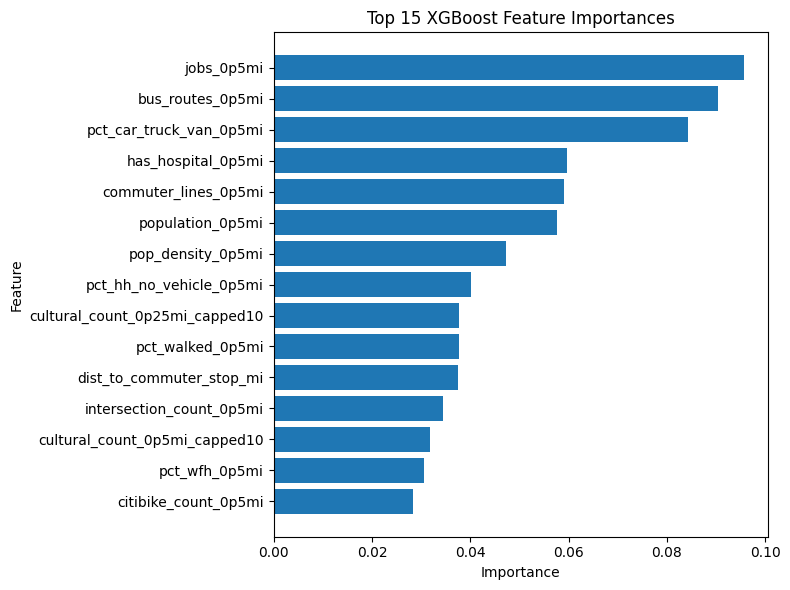


IBX predicted ridership:
       station_complex_name station_complex_id borough  cluster  \
462                4 Avenue             IBX_18     NaN        0   
449           Myrtle Avenue              IBX_5     NaN        0   
445        Roosevelt Avenue              IBX_1     NaN        0   
461                8 Avenue             IBX_17     NaN        2   
451         Atlantic Avenue              IBX_7     NaN        2   
458          East 16 Street             IBX_14     NaN        2   
447            Eliot Avenue              IBX_3     NaN        2   
457       Flatbush–Nostrand             IBX_13     NaN        2   
446            Grand Avenue              IBX_2     NaN        2   
454             Linden Blvd             IBX_10     NaN        2   
453          Livonia Avenue              IBX_9     NaN        2   
459         McDonald Avenue             IBX_15     NaN        2   
448     Metropolitan Avenue              IBX_4     NaN        2   
460      New Utrecht Avenue         

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# =========================================================
# ASSUMES THESE ALREADY EXIST FROM YOUR DATA-PREP STEP:
# - train_df
# - ibx_df
# - features_available
# =========================================================

# Keep IBX rows with complete feature data
ibx_pred_df = ibx_df.dropna(subset=features_available).copy()

print("Training rows:", len(train_df))
print("IBX rows:", len(ibx_df))
print("IBX rows with complete features:", len(ibx_pred_df))

# =========================================================
# 1. DEFINE X AND y
# =========================================================
X = train_df[features_available].copy()
y = train_df["log_avg_ridership"].copy()

# =========================================================
# 2. TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTrain rows:", len(X_train))
print("Test rows:", len(X_test))

# =========================================================
# 3. SUPERVISED MODEL: XGBOOST
# =========================================================
model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

# =========================================================
# 4. EVALUATE MODEL
# =========================================================
y_pred_log = model.predict(X_test)

r2 = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)

print("\nModel performance on log scale:")
print(f"R-squared: {r2:.4f}")
print(f"RMSE (log): {rmse_log:.4f}")
print(f"MAE  (log): {mae_log:.4f}")

# Back-transform for approximate interpretation
y_test_orig = np.exp(y_test)
y_pred_orig = np.exp(y_pred_log)

rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)

print("\nApproximate performance on original ridership scale:")
print(f"RMSE: {rmse_orig:,.2f}")
print(f"MAE : {mae_orig:,.2f}")

# =========================================================
# 5. FEATURE IMPORTANCE
# =========================================================
importance_df = pd.DataFrame({
    "feature": features_available,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 feature importances:")
print(importance_df.head(15))

plt.figure(figsize=(8, 6))
top_imp = importance_df.head(15).sort_values("importance")
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# =========================================================
# 6. PREDICT IBX RIDERSHIP
# =========================================================
X_ibx = ibx_pred_df[features_available].copy()
ibx_pred_df["pred_log_avg_ridership"] = model.predict(X_ibx)
ibx_pred_df["pred_avg_annual_ridership"] = np.exp(ibx_pred_df["pred_log_avg_ridership"])

# =========================================================
# 7. OPTIONAL CLUSTER-BASED ADJUSTMENTS
# =========================================================
ibx_pred_df["pred_avg_annual_ridership_adjusted"] = ibx_pred_df["pred_avg_annual_ridership"]

# Cluster 0 uplift
ibx_pred_df.loc[
    ibx_pred_df["cluster"] == 0,
    "pred_avg_annual_ridership_adjusted"
] = ibx_pred_df.loc[
    ibx_pred_df["cluster"] == 0,
    "pred_avg_annual_ridership"
] * 1.10

# Cluster 3 conservative adjustment
ibx_pred_df.loc[
    ibx_pred_df["cluster"] == 3,
    "pred_avg_annual_ridership_adjusted"
] = ibx_pred_df.loc[
    ibx_pred_df["cluster"] == 3,
    "pred_avg_annual_ridership"
] * 0.90

# =========================================================
# 8. FINAL OUTPUT TABLE
# =========================================================
ibx_results = ibx_pred_df[[
    "station_complex_name",
    "station_complex_id",
    "borough",
    "cluster",
    "pred_log_avg_ridership",
    "pred_avg_annual_ridership",
    "pred_avg_annual_ridership_adjusted"
]].sort_values(["cluster", "station_complex_name"])

print("\nIBX predicted ridership:")
print(ibx_results)

# =========================================================
# 9. SAVE OUTPUTS
# =========================================================
importance_df.to_csv("xgb_feature_importance.csv", index=False)
ibx_results.to_csv("ibx_ridership_predictions.csv", index=False)

print("\nSaved files:")
print(" - xgb_feature_importance.csv")
print(" - ibx_ridership_predictions.csv")

## Tune the Model

Training rows: 156
IBX rows: 19
IBX rows with complete features: 19

Train rows: 124
Test rows: 32

Cross-validation R-squared scores:
[ 0.33688563  0.22339222 -0.33820533  0.10262268  0.11846256]
Mean CV R-squared: 0.0886
Std CV R-squared:  0.2294

Test set performance on log scale:
R-squared: 0.4535
RMSE (log): 0.5797
MAE  (log): 0.4337

Approximate performance on original ridership scale:
RMSE: 4,206.70
MAE : 2,255.52

Top 15 feature importances:
                          feature  importance
19               bus_routes_0p5mi    0.101001
0                population_0p5mi    0.097332
6                      jobs_0p5mi    0.088237
13        pct_car_truck_van_0p5mi    0.084180
1               pop_density_0p5mi    0.072451
10        pct_hh_no_vehicle_0p5mi    0.044496
21           commuter_lines_0p5mi    0.037254
7        intersection_count_0p5mi    0.034876
9            citibike_count_0p5mi    0.034378
11  median_hh_income_0p5mi_approx    0.028985
12              pct_transit_0p5mi    0.0

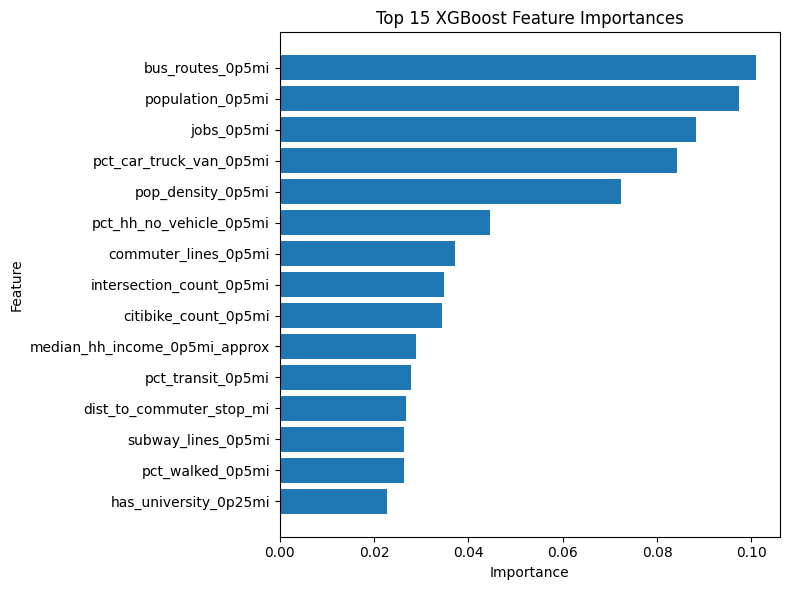


IBX predicted ridership:
       station_complex_name station_complex_id borough  cluster  \
462                4 Avenue             IBX_18     NaN        0   
449           Myrtle Avenue              IBX_5     NaN        0   
445        Roosevelt Avenue              IBX_1     NaN        0   
461                8 Avenue             IBX_17     NaN        2   
451         Atlantic Avenue              IBX_7     NaN        2   
458          East 16 Street             IBX_14     NaN        2   
447            Eliot Avenue              IBX_3     NaN        2   
457       Flatbush–Nostrand             IBX_13     NaN        2   
446            Grand Avenue              IBX_2     NaN        2   
454             Linden Blvd             IBX_10     NaN        2   
453          Livonia Avenue              IBX_9     NaN        2   
459         McDonald Avenue             IBX_15     NaN        2   
448     Metropolitan Avenue              IBX_4     NaN        2   
460      New Utrecht Avenue         

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# =========================================================
# ASSUMES THESE ALREADY EXIST FROM YOUR DATA-PREP STEP:
# - train_df
# - ibx_df
# - features_available
# =========================================================

# Keep IBX rows with complete feature data
ibx_pred_df = ibx_df.dropna(subset=features_available).copy()

print("Training rows:", len(train_df))
print("IBX rows:", len(ibx_df))
print("IBX rows with complete features:", len(ibx_pred_df))

# =========================================================
# 1. DEFINE X AND y
# =========================================================
X = train_df[features_available].copy()
y = train_df["log_avg_ridership"].copy()

# =========================================================
# 2. TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTrain rows:", len(X_train))
print("Test rows:", len(X_test))

# =========================================================
# 3. TUNED XGBOOST MODEL
# =========================================================
model = XGBRegressor(
    n_estimators=600,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1,
    objective="reg:squarederror",
    random_state=42
)

# =========================================================
# 4. CROSS-VALIDATION
# =========================================================
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\nCross-validation R-squared scores:")
print(cv_scores)
print(f"Mean CV R-squared: {cv_scores.mean():.4f}")
print(f"Std CV R-squared:  {cv_scores.std():.4f}")

# =========================================================
# 5. FIT FINAL MODEL
# =========================================================
model.fit(X_train, y_train)

# =========================================================
# 6. EVALUATE MODEL
# =========================================================
y_pred_log = model.predict(X_test)

r2 = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)

print("\nTest set performance on log scale:")
print(f"R-squared: {r2:.4f}")
print(f"RMSE (log): {rmse_log:.4f}")
print(f"MAE  (log): {mae_log:.4f}")

# Back-transform for approximate interpretation
y_test_orig = np.exp(y_test)
y_pred_orig = np.exp(y_pred_log)

rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)

print("\nApproximate performance on original ridership scale:")
print(f"RMSE: {rmse_orig:,.2f}")
print(f"MAE : {mae_orig:,.2f}")

# =========================================================
# 7. FEATURE IMPORTANCE
# =========================================================
importance_df = pd.DataFrame({
    "feature": features_available,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 feature importances:")
print(importance_df.head(15))

plt.figure(figsize=(8, 6))
top_imp = importance_df.head(15).sort_values("importance")
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# =========================================================
# 8. PREDICT IBX RIDERSHIP
# =========================================================
X_ibx = ibx_pred_df[features_available].copy()
ibx_pred_df["pred_log_avg_ridership"] = model.predict(X_ibx)
ibx_pred_df["pred_avg_annual_ridership"] = np.exp(ibx_pred_df["pred_log_avg_ridership"])

# =========================================================
# 9. OPTIONAL CLUSTER-BASED ADJUSTMENTS
# =========================================================
ibx_pred_df["pred_avg_annual_ridership_adjusted"] = ibx_pred_df["pred_avg_annual_ridership"]

# Cluster 0 uplift
ibx_pred_df.loc[
    ibx_pred_df["cluster"] == 0,
    "pred_avg_annual_ridership_adjusted"
] = ibx_pred_df.loc[
    ibx_pred_df["cluster"] == 0,
    "pred_avg_annual_ridership"
] * 1.10

# Cluster 3 conservative adjustment
ibx_pred_df.loc[
    ibx_pred_df["cluster"] == 3,
    "pred_avg_annual_ridership_adjusted"
] = ibx_pred_df.loc[
    ibx_pred_df["cluster"] == 3,
    "pred_avg_annual_ridership"
] * 0.90

# =========================================================
# 10. FINAL OUTPUT TABLE
# =========================================================
ibx_results = ibx_pred_df[[
    "station_complex_name",
    "station_complex_id",
    "borough",
    "cluster",
    "pred_log_avg_ridership",
    "pred_avg_annual_ridership",
    "pred_avg_annual_ridership_adjusted"
]].sort_values(["cluster", "station_complex_name"])

print("\nIBX predicted ridership:")
print(ibx_results)

# =========================================================
# 11. SAVE OUTPUTS
# =========================================================
importance_df.to_csv("xgb_feature_importance.csv", index=False)
ibx_results.to_csv("ibx_ridership_predictions.csv", index=False)

print("\nSaved files:")
print(" - xgb_feature_importance.csv")
print(" - ibx_ridership_predictions.csv")

## Add Interaction Terms and log-Transform some variable

Training rows: 156
IBX rows: 19
IBX rows with complete features: 19

Number of model features: 40

Train rows: 124
Test rows: 32

Cross-validation R-squared scores:
[ 0.1752579   0.09802962 -0.3331084   0.18439753  0.0128066 ]
Mean CV R-squared: 0.0275
Std CV R-squared:  0.1906

Test set performance on log scale:
R-squared: 0.4790
RMSE (log): 0.5660
MAE  (log): 0.4364

Approximate performance on original ridership scale:
RMSE: 3,986.14
MAE : 2,198.42

Top 15 feature importances:
                    feature  importance
1         pop_density_0p5mi    0.095112
0          population_0p5mi    0.073427
39               jobs_x_bus    0.072916
35     log_population_0p5mi    0.068185
6                jobs_0p5mi    0.057563
13  pct_car_truck_van_0p5mi    0.057498
37           jobs_x_transit    0.048757
19         bus_routes_0p5mi    0.045387
34           log_jobs_0p5mi    0.037747
12        pct_transit_0p5mi    0.028425
23    has_university_0p25mi    0.027430
26       has_hospital_0p5mi    0.022

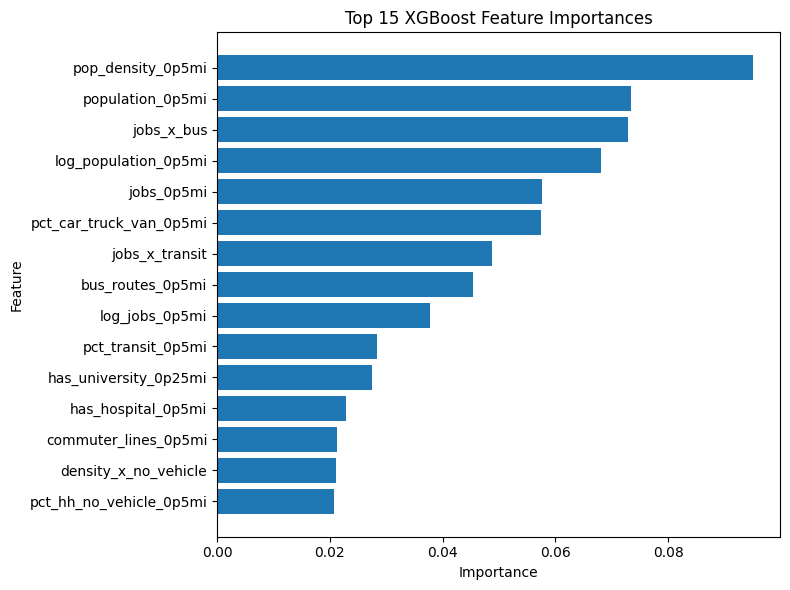


IBX predicted ridership:
       station_complex_name station_complex_id borough  cluster  \
462                4 Avenue             IBX_18     NaN        0   
449           Myrtle Avenue              IBX_5     NaN        0   
445        Roosevelt Avenue              IBX_1     NaN        0   
461                8 Avenue             IBX_17     NaN        2   
451         Atlantic Avenue              IBX_7     NaN        2   
458          East 16 Street             IBX_14     NaN        2   
447            Eliot Avenue              IBX_3     NaN        2   
457       Flatbush–Nostrand             IBX_13     NaN        2   
446            Grand Avenue              IBX_2     NaN        2   
454             Linden Blvd             IBX_10     NaN        2   
453          Livonia Avenue              IBX_9     NaN        2   
459         McDonald Avenue             IBX_15     NaN        2   
448     Metropolitan Avenue              IBX_4     NaN        2   
460      New Utrecht Avenue         

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# =========================================================
# ASSUMES THESE ALREADY EXIST FROM YOUR DATA-PREP STEP:
# - train_df
# - ibx_df
# - features_available
# =========================================================

# Keep IBX rows with complete feature data
ibx_pred_df = ibx_df.dropna(subset=features_available).copy()

print("Training rows:", len(train_df))
print("IBX rows:", len(ibx_df))
print("IBX rows with complete features:", len(ibx_pred_df))

# =========================================================
# 1. FEATURE ENGINEERING
#    Log transforms + interaction terms
# =========================================================
for col in ["jobs_0p5mi", "population_0p5mi", "pop_density_0p5mi"]:
    if col in train_df.columns:
        train_df[f"log_{col}"] = np.log1p(train_df[col])
    if col in ibx_pred_df.columns:
        ibx_pred_df[f"log_{col}"] = np.log1p(ibx_pred_df[col])

def add_interactions(df):
    df = df.copy()
    df["jobs_x_transit"] = df["jobs_0p5mi"] * df["pct_transit_0p5mi"]
    df["density_x_no_vehicle"] = df["pop_density_0p5mi"] * df["pct_hh_no_vehicle_0p5mi"]
    df["jobs_x_bus"] = df["jobs_0p5mi"] * df["bus_routes_0p5mi"]
    return df

train_df = add_interactions(train_df)
ibx_pred_df = add_interactions(ibx_pred_df)

engineered_features = [
    "log_jobs_0p5mi",
    "log_population_0p5mi",
    "log_pop_density_0p5mi",
    "jobs_x_transit",
    "density_x_no_vehicle",
    "jobs_x_bus"
]

features_model = features_available + engineered_features

print("\nNumber of model features:", len(features_model))

# =========================================================
# 2. DEFINE X AND y
# =========================================================
X = train_df[features_model].copy()
y = train_df["log_avg_ridership"].copy()

# =========================================================
# 3. TRAIN / TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTrain rows:", len(X_train))
print("Test rows:", len(X_test))

# =========================================================
# 4. TUNED XGBOOST MODEL
# =========================================================
model = XGBRegressor(
    n_estimators=600,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1,
    objective="reg:squarederror",
    random_state=42
)

# =========================================================
# 5. CROSS-VALIDATION
# =========================================================
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("\nCross-validation R-squared scores:")
print(cv_scores)
print(f"Mean CV R-squared: {cv_scores.mean():.4f}")
print(f"Std CV R-squared:  {cv_scores.std():.4f}")

# =========================================================
# 6. FIT FINAL MODEL
# =========================================================
model.fit(X_train, y_train)

# =========================================================
# 7. EVALUATE MODEL
# =========================================================
y_pred_log = model.predict(X_test)

r2 = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)

print("\nTest set performance on log scale:")
print(f"R-squared: {r2:.4f}")
print(f"RMSE (log): {rmse_log:.4f}")
print(f"MAE  (log): {mae_log:.4f}")

# Back-transform for approximate interpretation
y_test_orig = np.exp(y_test)
y_pred_orig = np.exp(y_pred_log)

rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)

print("\nApproximate performance on original ridership scale:")
print(f"RMSE: {rmse_orig:,.2f}")
print(f"MAE : {mae_orig:,.2f}")

# =========================================================
# 8. FEATURE IMPORTANCE
# =========================================================
importance_df = pd.DataFrame({
    "feature": features_model,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 feature importances:")
print(importance_df.head(15))

plt.figure(figsize=(8, 6))
top_imp = importance_df.head(15).sort_values("importance")
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# =========================================================
# 9. PREDICT IBX RIDERSHIP
# =========================================================
X_ibx = ibx_pred_df[features_model].copy()
ibx_pred_df["pred_log_avg_ridership"] = model.predict(X_ibx)
ibx_pred_df["pred_avg_annual_ridership"] = np.exp(ibx_pred_df["pred_log_avg_ridership"])

# =========================================================
# 10. OPTIONAL CLUSTER-BASED ADJUSTMENTS
# =========================================================
ibx_pred_df["pred_avg_annual_ridership_adjusted"] = ibx_pred_df["pred_avg_annual_ridership"]

# Cluster 0 uplift
ibx_pred_df.loc[
    ibx_pred_df["cluster"] == 0,
    "pred_avg_annual_ridership_adjusted"
] = ibx_pred_df.loc[
    ibx_pred_df["cluster"] == 0,
    "pred_avg_annual_ridership"
] * 1.10

# Cluster 3 conservative adjustment
ibx_pred_df.loc[
    ibx_pred_df["cluster"] == 3,
    "pred_avg_annual_ridership_adjusted"
] = ibx_pred_df.loc[
    ibx_pred_df["cluster"] == 3,
    "pred_avg_annual_ridership"
] * 0.90

# =========================================================
# 11. FINAL OUTPUT TABLE
# =========================================================
ibx_results = ibx_pred_df[[
    "station_complex_name",
    "station_complex_id",
    "borough",
    "cluster",
    "pred_log_avg_ridership",
    "pred_avg_annual_ridership",
    "pred_avg_annual_ridership_adjusted"
]].sort_values(["cluster", "station_complex_name"])

print("\nIBX predicted ridership:")
print(ibx_results)

# =========================================================
# 12. SAVE OUTPUTS
# =========================================================
importance_df.to_csv("xgb_feature_importance.csv", index=False)
ibx_results.to_csv("ibx_ridership_predictions.csv", index=False)

print("\nSaved files:")
print(" - xgb_feature_importance.csv")
print(" - ibx_ridership_predictions.csv")

## Full Model Training Using All Clusters (Including Manhattan Core Stations)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

RIDERSHIP_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_station_avg_post_2023_2024.csv"
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv"

# =========================================================
# 1. LOAD DATA
# =========================================================
df_features_all = pd.read_csv(FEATURES_URL)
df_ridership_all = pd.read_csv(RIDERSHIP_URL)

df_features_all["station_complex_id"] = df_features_all["station_complex_id"].astype(str).str.strip()
df_ridership_all["station_complex_id"] = df_ridership_all["station_complex_id"].astype(str).str.strip()

print("Features rows:", len(df_features_all))
print("Ridership rows:", len(df_ridership_all))

# =========================================================
# 2. MERGE BOROUGH INTO FEATURES
# =========================================================
borough_lookup_all = (
    df_ridership_all[["station_complex_id", "borough"]]
    .dropna()
    .drop_duplicates(subset=["station_complex_id"])
)

df_features_all = df_features_all.merge(
    borough_lookup_all,
    on="station_complex_id",
    how="left"
)

print("\nBorough coverage:")
print(df_features_all["borough"].value_counts(dropna=False))

# =========================================================
# 3. DEFINE FEATURES
# =========================================================
features = [
    "population_0p5mi",
    "pop_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",
    "jobs_0p5mi",
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
]

features_available_all = [f for f in features if f in df_features_all.columns]

# =========================================================
# 4. CLEAN + PREP FOR CLUSTERING
# =========================================================
data_all = df_features_all[features_available_all].dropna().copy()
df_cluster_all = df_features_all.loc[data_all.index].copy()

print("\nRows used for clustering:", len(df_cluster_all))

df_cluster_all["is_ibx"] = df_cluster_all["station_complex_id"].str.startswith("IBX_", na=False)

# =========================================================
# 5. SCALE + KMEANS
# =========================================================
scaler_all = StandardScaler()
X_scaled_all = scaler_all.fit_transform(data_all)

kmeans_all = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster_all["cluster"] = kmeans_all.fit_predict(X_scaled_all)

print("\nCluster sizes:")
print(df_cluster_all["cluster"].value_counts().sort_index())

print("\nIBX by cluster:")
print(df_cluster_all.groupby("cluster")["is_ibx"].sum())

# =========================================================
# 6. CLUSTER DIAGNOSTICS
# =========================================================
borough_by_cluster_all = (
    df_cluster_all.groupby("cluster")["borough"]
    .apply(lambda s: sorted(set(x for x in s.dropna())))
)

manhattan_only_clusters_all = [
    cl for cl, boroughs in borough_by_cluster_all.items()
    if len(boroughs) > 0 and set(boroughs) == {"Manhattan"}
]

print("\nBoroughs by cluster:")
for cl, boroughs in borough_by_cluster_all.items():
    print(f"Cluster {cl}: {boroughs}")

print(f"\nManhattan-only cluster(s): {manhattan_only_clusters_all}")

target_cluster_all = 2
centroids_all = kmeans_all.cluster_centers_

dist_matrix_all = cdist(centroids_all, centroids_all, metric="euclidean")
dist_matrix_all[target_cluster_all, target_cluster_all] = np.inf

additional_cluster_1_all = int(np.argmin(dist_matrix_all[target_cluster_all]))

candidate_clusters_all = [
    cl for cl in range(kmeans_all.n_clusters)
    if cl not in [target_cluster_all, additional_cluster_1_all]
    and cl not in manhattan_only_clusters_all
]

if len(candidate_clusters_all) > 0:
    additional_cluster_2_all = min(
        candidate_clusters_all,
        key=lambda cl: dist_matrix_all[target_cluster_all, cl]
    )
else:
    additional_cluster_2_all = None

selected_clusters_model2 = [target_cluster_all]
selected_clusters_model3 = [target_cluster_all, additional_cluster_1_all]

if additional_cluster_2_all is not None:
    selected_clusters_model4 = [
        target_cluster_all,
        additional_cluster_1_all,
        additional_cluster_2_all
    ]
else:
    selected_clusters_model4 = [
        target_cluster_all,
        additional_cluster_1_all
    ]

print(f"\nTarget cluster: {target_cluster_all}")
print(f"Nearest cluster to target: {additional_cluster_1_all}")
print(f"Extra non-Manhattan-only cluster: {additional_cluster_2_all}")
print(f"Model 2 clusters: {selected_clusters_model2}")
print(f"Model 3 clusters: {selected_clusters_model3}")
print(f"Model 4 clusters: {selected_clusters_model4}")

# =========================================================
# 7. MERGE RIDERSHIP
# =========================================================
ridership_keep_all = df_ridership_all[[
    "station_complex_id",
    "avg_annual_ridership",
    "log_avg_ridership"
]]

df_model_all = df_cluster_all.merge(
    ridership_keep_all,
    on="station_complex_id",
    how="left"
)

print("\nRows after ridership merge:", len(df_model_all))

# =========================================================
# 8. BUILD FOUR DATASETS
# =========================================================
# Dataset 1: cluster 2 only
train_df_m1 = df_model_all[
    (df_model_all["cluster"].isin(selected_clusters_model2)) &
    (df_model_all["log_avg_ridership"].notna())
].copy()

# Dataset 2: cluster 2 + nearest cluster
train_df_m2 = df_model_all[
    (df_model_all["cluster"].isin(selected_clusters_model3)) &
    (df_model_all["log_avg_ridership"].notna())
].copy()

# Dataset 3: cluster 2 + nearest + extra non-Manhattan-only cluster
train_df_m3 = df_model_all[
    (df_model_all["cluster"].isin(selected_clusters_model4)) &
    (df_model_all["log_avg_ridership"].notna())
].copy()

# Dataset 4: all clusters including Manhattan
train_df_m4 = df_model_all[
    df_model_all["log_avg_ridership"].notna()
].copy()

# Shared IBX prediction set
ibx_df_all = df_model_all[df_model_all["is_ibx"]].copy()

print("\nTraining rows by dataset:")
print(f"Dataset 1 (cluster 2 only): {len(train_df_m1)}")
print(f"Dataset 2 (cluster 2 + nearest): {len(train_df_m2)}")
print(f"Dataset 3 (cluster 2 + 2 non-Manhattan-focused): {len(train_df_m3)}")
print(f"Dataset 4 (all clusters incl. Manhattan): {len(train_df_m4)}")
print(f"IBX rows: {len(ibx_df_all)}")

# =========================================================
# 9. SAVE FOUR DATASETS
# =========================================================
df_model_all.to_csv("full_dataset_with_clusters_consolidated.csv", index=False)
train_df_m1.to_csv("training_dataset_model1_cluster2_only.csv", index=False)
train_df_m2.to_csv("training_dataset_model2_cluster2_plus_nearest.csv", index=False)
train_df_m3.to_csv("training_dataset_model3_cluster2_plus_2clusters_no_manhattan_only.csv", index=False)
train_df_m4.to_csv("training_dataset_model4_all_clusters_including_manhattan.csv", index=False)
ibx_df_all.to_csv("ibx_prediction_set_consolidated.csv", index=False)

# =========================================================
# 10. FEATURE ENGINEERING HELPER
# =========================================================
def engineer_features(df, base_features):
    df = df.copy()

    for col in ["jobs_0p5mi", "population_0p5mi", "pop_density_0p5mi"]:
        if col in df.columns:
            df[f"log_{col}"] = np.log1p(df[col])

    if {"jobs_0p5mi", "pct_transit_0p5mi"}.issubset(df.columns):
        df["jobs_x_transit"] = df["jobs_0p5mi"] * df["pct_transit_0p5mi"]

    if {"pop_density_0p5mi", "pct_hh_no_vehicle_0p5mi"}.issubset(df.columns):
        df["density_x_no_vehicle"] = df["pop_density_0p5mi"] * df["pct_hh_no_vehicle_0p5mi"]

    if {"jobs_0p5mi", "bus_routes_0p5mi"}.issubset(df.columns):
        df["jobs_x_bus"] = df["jobs_0p5mi"] * df["bus_routes_0p5mi"]

    engineered_features = [
        "log_jobs_0p5mi",
        "log_population_0p5mi",
        "log_pop_density_0p5mi",
        "jobs_x_transit",
        "density_x_no_vehicle",
        "jobs_x_bus"
    ]

    features_model = [col for col in (base_features + engineered_features) if col in df.columns]
    return df, features_model

# =========================================================
# 11. MODEL RUNNER
# =========================================================
def run_xgb_pipeline(train_df, ibx_df, base_features, model_label, random_state=42):
    train_df_eng, features_model = engineer_features(train_df, base_features)
    ibx_df_eng, features_model_ibx = engineer_features(ibx_df, base_features)

    features_model_final = [col for col in features_model if col in features_model_ibx]

    train_df_eng = train_df_eng.dropna(subset=features_model_final + ["log_avg_ridership"]).copy()
    ibx_df_eng = ibx_df_eng.dropna(subset=features_model_final).copy()

    print(f"\n{'=' * 60}")
    print(f"{model_label}")
    print(f"{'=' * 60}")
    print("Training rows:", len(train_df_eng))
    print("IBX rows:", len(ibx_df))
    print("IBX rows with complete features:", len(ibx_df_eng))
    print("Number of model features:", len(features_model_final))

    X = train_df_eng[features_model_final].copy()
    y = train_df_eng["log_avg_ridership"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=random_state
    )

    print("Train rows:", len(X_train))
    print("Test rows:", len(X_test))

    model = XGBRegressor(
        n_estimators=600,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1,
        objective="reg:squarederror",
        random_state=random_state
    )

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    mae_log = mean_absolute_error(y_test, y_pred_log)

    y_test_orig = np.exp(y_test)
    y_pred_orig = np.exp(y_pred_log)

    rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)

    importance_df = pd.DataFrame({
        "feature": features_model_final,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    X_ibx = ibx_df_eng[features_model_final].copy()
    ibx_df_eng["pred_log_avg_ridership"] = model.predict(X_ibx)
    ibx_df_eng["pred_avg_annual_ridership"] = np.exp(ibx_df_eng["pred_log_avg_ridership"])

    ibx_df_eng["pred_avg_annual_ridership_adjusted"] = ibx_df_eng["pred_avg_annual_ridership"]

    # optional same adjustments as before
    ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 0,
        "pred_avg_annual_ridership_adjusted"
    ] = ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 0,
        "pred_avg_annual_ridership"
    ] * 1.10

    ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 3,
        "pred_avg_annual_ridership_adjusted"
    ] = ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 3,
        "pred_avg_annual_ridership"
    ] * 0.90

    ibx_results = ibx_df_eng[[
        "station_complex_name",
        "station_complex_id",
        "borough",
        "cluster",
        "pred_log_avg_ridership",
        "pred_avg_annual_ridership",
        "pred_avg_annual_ridership_adjusted"
    ]].sort_values(["cluster", "station_complex_name"])

    return {
        "model": model,
        "features_model": features_model_final,
        "cv_scores": cv_scores,
        "r2_log": r2_log,
        "rmse_log": rmse_log,
        "mae_log": mae_log,
        "rmse_orig": rmse_orig,
        "mae_orig": mae_orig,
        "importance_df": importance_df,
        "ibx_results": ibx_results,
        "train_rows": len(train_df_eng),
        "test_rows": len(X_test)
    }

# =========================================================
# 12. RUN FOUR MODELS
# =========================================================
results_m1 = run_xgb_pipeline(
    train_df=train_df_m1,
    ibx_df=ibx_df_all,
    base_features=features_available_all,
    model_label="MODEL 1: Cluster 2 Only"
)

results_m2 = run_xgb_pipeline(
    train_df=train_df_m2,
    ibx_df=ibx_df_all,
    base_features=features_available_all,
    model_label="MODEL 2: Cluster 2 + Nearest Cluster"
)

results_m3 = run_xgb_pipeline(
    train_df=train_df_m3,
    ibx_df=ibx_df_all,
    base_features=features_available_all,
    model_label="MODEL 3: Cluster 2 + Two Additional Clusters (No Manhattan-only)"
)

results_m4 = run_xgb_pipeline(
    train_df=train_df_m4,
    ibx_df=ibx_df_all,
    base_features=features_available_all,
    model_label="MODEL 4: All Clusters Including Manhattan"
)

# =========================================================
# 13. UNIQUE METRIC OBJECTS
# =========================================================
r2_m1 = results_m1["r2_log"]
rmse_log_m1 = results_m1["rmse_log"]
mae_log_m1 = results_m1["mae_log"]
rmse_orig_m1 = results_m1["rmse_orig"]
mae_orig_m1 = results_m1["mae_orig"]
cv_scores_m1 = results_m1["cv_scores"]
cv_mean_m1 = cv_scores_m1.mean()
cv_std_m1 = cv_scores_m1.std()

r2_m2 = results_m2["r2_log"]
rmse_log_m2 = results_m2["rmse_log"]
mae_log_m2 = results_m2["mae_log"]
rmse_orig_m2 = results_m2["rmse_orig"]
mae_orig_m2 = results_m2["mae_orig"]
cv_scores_m2 = results_m2["cv_scores"]
cv_mean_m2 = cv_scores_m2.mean()
cv_std_m2 = cv_scores_m2.std()

r2_m3 = results_m3["r2_log"]
rmse_log_m3 = results_m3["rmse_log"]
mae_log_m3 = results_m3["mae_log"]
rmse_orig_m3 = results_m3["rmse_orig"]
mae_orig_m3 = results_m3["mae_orig"]
cv_scores_m3 = results_m3["cv_scores"]
cv_mean_m3 = cv_scores_m3.mean()
cv_std_m3 = cv_scores_m3.std()

r2_m4 = results_m4["r2_log"]
rmse_log_m4 = results_m4["rmse_log"]
mae_log_m4 = results_m4["mae_log"]
rmse_orig_m4 = results_m4["rmse_orig"]
mae_orig_m4 = results_m4["mae_orig"]
cv_scores_m4 = results_m4["cv_scores"]
cv_mean_m4 = cv_scores_m4.mean()
cv_std_m4 = cv_scores_m4.std()

# =========================================================
# 14. PERFORMANCE COMPARISON DATAFRAME
# =========================================================
performance_comparison_df = pd.DataFrame([
    {
        "model_name": "Model 1: Cluster 2 Only",
        "train_rows": results_m1["train_rows"],
        "test_rows": results_m1["test_rows"],
        "n_features": len(results_m1["features_model"]),
        "cv_mean_r2": cv_mean_m1,
        "cv_std_r2": cv_std_m1,
        "test_r2_log": r2_m1,
        "rmse_log": rmse_log_m1,
        "mae_log": mae_log_m1,
        "rmse_original": rmse_orig_m1,
        "mae_original": mae_orig_m1
    },
    {
        "model_name": "Model 2: Cluster 2 + Nearest",
        "train_rows": results_m2["train_rows"],
        "test_rows": results_m2["test_rows"],
        "n_features": len(results_m2["features_model"]),
        "cv_mean_r2": cv_mean_m2,
        "cv_std_r2": cv_std_m2,
        "test_r2_log": r2_m2,
        "rmse_log": rmse_log_m2,
        "mae_log": mae_log_m2,
        "rmse_original": rmse_orig_m2,
        "mae_original": mae_orig_m2
    },
    {
        "model_name": "Model 3: Cluster 2 + 2 Clusters No Manhattan-only",
        "train_rows": results_m3["train_rows"],
        "test_rows": results_m3["test_rows"],
        "n_features": len(results_m3["features_model"]),
        "cv_mean_r2": cv_mean_m3,
        "cv_std_r2": cv_std_m3,
        "test_r2_log": r2_m3,
        "rmse_log": rmse_log_m3,
        "mae_log": mae_log_m3,
        "rmse_original": rmse_orig_m3,
        "mae_original": mae_orig_m3
    },
    {
        "model_name": "Model 4: All Clusters Including Manhattan",
        "train_rows": results_m4["train_rows"],
        "test_rows": results_m4["test_rows"],
        "n_features": len(results_m4["features_model"]),
        "cv_mean_r2": cv_mean_m4,
        "cv_std_r2": cv_std_m4,
        "test_r2_log": r2_m4,
        "rmse_log": rmse_log_m4,
        "mae_log": mae_log_m4,
        "rmse_original": rmse_orig_m4,
        "mae_original": mae_orig_m4
    }
])

performance_comparison_df = performance_comparison_df.sort_values(
    by=["rmse_original", "mae_original"],
    ascending=[True, True]
).reset_index(drop=True)

print("\nPerformance comparison:")
print(performance_comparison_df)

# =========================================================
# 15. SAVE MODEL OUTPUTS
# =========================================================
results_m1["importance_df"].to_csv("xgb_feature_importance_model1.csv", index=False)
results_m2["importance_df"].to_csv("xgb_feature_importance_model2.csv", index=False)
results_m3["importance_df"].to_csv("xgb_feature_importance_model3.csv", index=False)
results_m4["importance_df"].to_csv("xgb_feature_importance_model4.csv", index=False)

results_m1["ibx_results"].to_csv("ibx_ridership_predictions_model1.csv", index=False)
results_m2["ibx_results"].to_csv("ibx_ridership_predictions_model2.csv", index=False)
results_m3["ibx_results"].to_csv("ibx_ridership_predictions_model3.csv", index=False)
results_m4["ibx_results"].to_csv("ibx_ridership_predictions_model4.csv", index=False)

performance_comparison_df.to_csv("model_performance_comparison.csv", index=False)

print("\nSaved files:")
print(" - full_dataset_with_clusters_consolidated.csv")
print(" - training_dataset_model1_cluster2_only.csv")
print(" - training_dataset_model2_cluster2_plus_nearest.csv")
print(" - training_dataset_model3_cluster2_plus_2clusters_no_manhattan_only.csv")
print(" - training_dataset_model4_all_clusters_including_manhattan.csv")
print(" - ibx_prediction_set_consolidated.csv")
print(" - xgb_feature_importance_model1.csv")
print(" - xgb_feature_importance_model2.csv")
print(" - xgb_feature_importance_model3.csv")
print(" - xgb_feature_importance_model4.csv")
print(" - ibx_ridership_predictions_model1.csv")
print(" - ibx_ridership_predictions_model2.csv")
print(" - ibx_ridership_predictions_model3.csv")
print(" - ibx_ridership_predictions_model4.csv")
print(" - model_performance_comparison.csv")

Features rows: 464
Ridership rows: 426

Borough coverage:
borough
Brooklyn         156
Manhattan        121
Queens            79
Bronx             68
NaN               38
Staten Island      2
Name: count, dtype: int64

Rows used for clustering: 464

Cluster sizes:
cluster
0    195
1     68
2    174
3     27
Name: count, dtype: int64

IBX by cluster:
cluster
0     3
1     0
2    15
3     1
Name: is_ibx, dtype: int64

Boroughs by cluster:
Cluster 0: ['Bronx', 'Brooklyn', 'Manhattan', 'Queens']
Cluster 1: ['Manhattan']
Cluster 2: ['Bronx', 'Brooklyn', 'Queens', 'Staten Island']
Cluster 3: ['Bronx', 'Queens']

Manhattan-only cluster(s): [1]

Target cluster: 2
Nearest cluster to target: 0
Extra non-Manhattan-only cluster: 3
Model 2 clusters: [2]
Model 3 clusters: [2, 0]
Model 4 clusters: [2, 0, 3]

Rows after ridership merge: 464

Training rows by dataset:
Dataset 1 (cluster 2 only): 156
Dataset 2 (cluster 2 + nearest): 348
Dataset 3 (cluster 2 + 2 non-Manhattan-focused): 358
Dataset 4 (all

In [ ]:
display(performance_comparison_df)

,model_name,train_rows,test_rows,n_features,cv_mean_r2,cv_std_r2,test_r2_log,rmse_log,mae_log,rmse_original,mae_original
0,Model 3: Cluster 2 + 2 Clusters No Manhattan-only,358,72,40,0.303698,0.124784,0.461351,0.546376,0.432311,3971.427818,2627.725717
1,Model 1: Cluster 2 Only,156,32,40,0.027477,0.190619,0.478964,0.566017,0.436425,3986.139526,2198.422694
2,Model 2: Cluster 2 + Nearest,348,70,40,0.324748,0.133934,0.491253,0.637761,0.468691,7009.663541,3703.493803
3,Model 4: All Clusters Including Manhattan,426,86,40,0.405836,0.062708,0.546463,0.671171,0.517545,18088.605119,7071.243035


# Ridership Modeling with Job-Based Accessibility Controls

Purpose

This step estimates ridership models using the OD-enhanced station dataset and applies them to forecast IBX station ridership. It compares alternative training sets based on cluster composition, evaluates model performance, and generates predicted ridership for IBX stations while preserving the variables and cluster structure created during data engineering.

## Ridership Modeling Using Job-Based OD Accessibility

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# =========================================================
# INPUT
# Assumes this file was created during data engineering:
#   full_dataset_with_clusters_od.csv
# =========================================================
DATA_PATH = "full_dataset_with_clusters_od.csv"

# =========================================================
# 1. LOAD OD-ENHANCED, CLUSTERED DATASET
# =========================================================
df_model_all = pd.read_csv(DATA_PATH)
df_model_all["station_complex_id"] = df_model_all["station_complex_id"].astype(str).str.strip()

print("Rows in modeling dataset:", len(df_model_all))

# Ensure IBX flag exists
if "is_ibx" not in df_model_all.columns:
    df_model_all["is_ibx"] = df_model_all["station_complex_id"].str.startswith("IBX_", na=False)

print("\nAvailable columns:")
print(df_model_all.columns.tolist())

# =========================================================
# 2. DEFINE BASE FEATURES
# Main specification uses the JOBS-based OD proxy
# =========================================================
base_features = [
    "population_0p5mi",
    "pop_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",
    "jobs_0p5mi",
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
    "log_od_jobs_exp_accessibility"
]

base_features_available = [f for f in base_features if f in df_model_all.columns]
base_features_missing = [f for f in base_features if f not in df_model_all.columns]

print("\nBase features available:")
print(base_features_available)

if base_features_missing:
    print("\nRequested base features missing:")
    print(base_features_missing)

# =========================================================
# 3. CLUSTER DIAGNOSTICS
# Uses existing cluster assignments from data engineering
# =========================================================
borough_by_cluster_all = (
    df_model_all.groupby("cluster")["borough"]
    .apply(lambda s: sorted(set(x for x in s.dropna())))
)

manhattan_only_clusters_all = [
    cl for cl, boroughs in borough_by_cluster_all.items()
    if len(boroughs) > 0 and set(boroughs) == {"Manhattan"}
]

print("\nBoroughs by cluster:")
for cl, boroughs in borough_by_cluster_all.items():
    print(f"Cluster {cl}: {boroughs}")

print(f"\nManhattan-only cluster(s): {manhattan_only_clusters_all}")

# Reconstruct centroids from available modeling features
centroid_data = df_model_all.dropna(subset=base_features_available + ["cluster"]).copy()

centroids_all = (
    centroid_data.groupby("cluster")[base_features_available]
    .mean()
    .sort_index()
    .to_numpy()
)

cluster_labels = sorted(centroid_data["cluster"].dropna().unique().tolist())
cluster_to_pos = {cl: i for i, cl in enumerate(cluster_labels)}

target_cluster_all = 2
if target_cluster_all not in cluster_to_pos:
    raise ValueError("Target cluster 2 not found in dataset.")

target_pos = cluster_to_pos[target_cluster_all]

dist_matrix_all = cdist(centroids_all, centroids_all, metric="euclidean")
dist_matrix_all[target_pos, target_pos] = np.inf

nearest_pos = int(np.argmin(dist_matrix_all[target_pos]))
additional_cluster_1_all = cluster_labels[nearest_pos]

candidate_clusters_all = [
    cl for cl in cluster_labels
    if cl not in [target_cluster_all, additional_cluster_1_all]
    and cl not in manhattan_only_clusters_all
]

if len(candidate_clusters_all) > 0:
    additional_cluster_2_all = min(
        candidate_clusters_all,
        key=lambda cl: dist_matrix_all[target_pos, cluster_to_pos[cl]]
    )
else:
    additional_cluster_2_all = None

selected_clusters_model1 = [target_cluster_all]
selected_clusters_model2 = [target_cluster_all, additional_cluster_1_all]

if additional_cluster_2_all is not None:
    selected_clusters_model3 = [
        target_cluster_all,
        additional_cluster_1_all,
        additional_cluster_2_all
    ]
else:
    selected_clusters_model3 = [
        target_cluster_all,
        additional_cluster_1_all
    ]

print(f"\nTarget cluster: {target_cluster_all}")
print(f"Nearest cluster to target: {additional_cluster_1_all}")
print(f"Extra non-Manhattan-only cluster: {additional_cluster_2_all}")
print(f"Model 1 clusters: {selected_clusters_model1}")
print(f"Model 2 clusters: {selected_clusters_model2}")
print(f"Model 3 clusters: {selected_clusters_model3}")
print("Model 4 clusters: all clusters including Manhattan")

# =========================================================
# 4. BUILD FOUR TRAINING DATASETS
# =========================================================
train_df_m1 = df_model_all[
    (df_model_all["cluster"].isin(selected_clusters_model1)) &
    (df_model_all["log_avg_ridership"].notna())
].copy()

train_df_m2 = df_model_all[
    (df_model_all["cluster"].isin(selected_clusters_model2)) &
    (df_model_all["log_avg_ridership"].notna())
].copy()

train_df_m3 = df_model_all[
    (df_model_all["cluster"].isin(selected_clusters_model3)) &
    (df_model_all["log_avg_ridership"].notna())
].copy()

train_df_m4 = df_model_all[
    df_model_all["log_avg_ridership"].notna()
].copy()

ibx_df_all = df_model_all[df_model_all["is_ibx"]].copy()

print("\nTraining rows by dataset:")
print(f"Model 1 (cluster 2 only): {len(train_df_m1)}")
print(f"Model 2 (cluster 2 + nearest): {len(train_df_m2)}")
print(f"Model 3 (cluster 2 + 2 non-Manhattan-focused): {len(train_df_m3)}")
print(f"Model 4 (all clusters incl. Manhattan): {len(train_df_m4)}")
print(f"IBX rows: {len(ibx_df_all)}")

# =========================================================
# 5. FEATURE ENGINEERING HELPER
# Only adds missing engineered columns; does not redo data engineering
# =========================================================
def ensure_engineered_features(df_in, base_features):
    df_out = df_in.copy()

    if "jobs_0p5mi" in df_out.columns and "log_jobs_0p5mi" not in df_out.columns:
        df_out["log_jobs_0p5mi"] = np.log1p(df_out["jobs_0p5mi"])

    if "population_0p5mi" in df_out.columns and "log_population_0p5mi" not in df_out.columns:
        df_out["log_population_0p5mi"] = np.log1p(df_out["population_0p5mi"])

    if "pop_density_0p5mi" in df_out.columns and "log_pop_density_0p5mi" not in df_out.columns:
        df_out["log_pop_density_0p5mi"] = np.log1p(df_out["pop_density_0p5mi"])

    if (
        {"jobs_0p5mi", "pct_transit_0p5mi"}.issubset(df_out.columns)
        and "jobs_x_transit" not in df_out.columns
    ):
        df_out["jobs_x_transit"] = df_out["jobs_0p5mi"] * df_out["pct_transit_0p5mi"]

    if (
        {"pop_density_0p5mi", "pct_hh_no_vehicle_0p5mi"}.issubset(df_out.columns)
        and "density_x_no_vehicle" not in df_out.columns
    ):
        df_out["density_x_no_vehicle"] = (
            df_out["pop_density_0p5mi"] * df_out["pct_hh_no_vehicle_0p5mi"]
        )

    if (
        {"jobs_0p5mi", "bus_routes_0p5mi"}.issubset(df_out.columns)
        and "jobs_x_bus" not in df_out.columns
    ):
        df_out["jobs_x_bus"] = df_out["jobs_0p5mi"] * df_out["bus_routes_0p5mi"]

    engineered_features = [
        "log_jobs_0p5mi",
        "log_population_0p5mi",
        "log_pop_density_0p5mi",
        "jobs_x_transit",
        "density_x_no_vehicle",
        "jobs_x_bus"
    ]

    features_model = [col for col in (base_features + engineered_features) if col in df_out.columns]
    return df_out, features_model

# =========================================================
# 6. MODEL RUNNER
# =========================================================
def run_xgb_pipeline(train_df, ibx_df, base_features, model_label, random_state=42):
    train_df_eng, features_model = ensure_engineered_features(train_df, base_features)
    ibx_df_eng, features_model_ibx = ensure_engineered_features(ibx_df, base_features)

    features_model_final = [col for col in features_model if col in features_model_ibx]

    train_df_eng = train_df_eng.dropna(subset=features_model_final + ["log_avg_ridership"]).copy()
    ibx_df_eng = ibx_df_eng.dropna(subset=features_model_final).copy()

    print(f"\n{'=' * 60}")
    print(model_label)
    print(f"{'=' * 60}")
    print("Training rows:", len(train_df_eng))
    print("IBX rows:", len(ibx_df))
    print("IBX rows with complete features:", len(ibx_df_eng))
    print("Number of model features:", len(features_model_final))

    X = train_df_eng[features_model_final].copy()
    y = train_df_eng["log_avg_ridership"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=random_state
    )

    print("Train rows:", len(X_train))
    print("Test rows:", len(X_test))

    model = XGBRegressor(
        n_estimators=600,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1,
        objective="reg:squarederror",
        random_state=random_state
    )

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    mae_log = mean_absolute_error(y_test, y_pred_log)

    y_test_orig = np.exp(y_test)
    y_pred_orig = np.exp(y_pred_log)

    rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)

    importance_df = pd.DataFrame({
        "feature": features_model_final,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    X_ibx = ibx_df_eng[features_model_final].copy()
    ibx_df_eng["pred_log_avg_ridership"] = model.predict(X_ibx)
    ibx_df_eng["pred_avg_annual_ridership"] = np.exp(ibx_df_eng["pred_log_avg_ridership"])

    ibx_df_eng["pred_avg_annual_ridership_adjusted"] = ibx_df_eng["pred_avg_annual_ridership"]

    # Same cluster-based adjustments
    ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 0,
        "pred_avg_annual_ridership_adjusted"
    ] = ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 0,
        "pred_avg_annual_ridership"
    ] * 1.10

    ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 3,
        "pred_avg_annual_ridership_adjusted"
    ] = ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 3,
        "pred_avg_annual_ridership"
    ] * 0.90

    ibx_results = ibx_df_eng[[
        "station_complex_name",
        "station_complex_id",
        "borough",
        "cluster",
        "pred_log_avg_ridership",
        "pred_avg_annual_ridership",
        "pred_avg_annual_ridership_adjusted"
    ]].sort_values(["cluster", "station_complex_name"])

    return {
        "model": model,
        "features_model": features_model_final,
        "cv_scores": cv_scores,
        "r2_log": r2_log,
        "rmse_log": rmse_log,
        "mae_log": mae_log,
        "rmse_orig": rmse_orig,
        "mae_orig": mae_orig,
        "importance_df": importance_df,
        "ibx_results": ibx_results,
        "train_rows": len(train_df_eng),
        "test_rows": len(X_test)
    }

# =========================================================
# 7. RUN FOUR MODELS
# =========================================================
results_m1 = run_xgb_pipeline(
    train_df=train_df_m1,
    ibx_df=ibx_df_all,
    base_features=base_features_available,
    model_label="MODEL 1: Cluster 2 Only"
)

results_m2 = run_xgb_pipeline(
    train_df=train_df_m2,
    ibx_df=ibx_df_all,
    base_features=base_features_available,
    model_label="MODEL 2: Cluster 2 + Nearest Cluster"
)

results_m3 = run_xgb_pipeline(
    train_df=train_df_m3,
    ibx_df=ibx_df_all,
    base_features=base_features_available,
    model_label="MODEL 3: Cluster 2 + Two Additional Clusters (No Manhattan-only)"
)

results_m4 = run_xgb_pipeline(
    train_df=train_df_m4,
    ibx_df=ibx_df_all,
    base_features=base_features_available,
    model_label="MODEL 4: All Clusters Including Manhattan"
)

# =========================================================
# 8. PERFORMANCE COMPARISON
# =========================================================
performance_comparison_df = pd.DataFrame([
    {
        "model_name": "Model 1: Cluster 2 Only",
        "train_rows": results_m1["train_rows"],
        "test_rows": results_m1["test_rows"],
        "n_features": len(results_m1["features_model"]),
        "cv_mean_r2": results_m1["cv_scores"].mean(),
        "cv_std_r2": results_m1["cv_scores"].std(),
        "test_r2_log": results_m1["r2_log"],
        "rmse_log": results_m1["rmse_log"],
        "mae_log": results_m1["mae_log"],
        "rmse_original": results_m1["rmse_orig"],
        "mae_original": results_m1["mae_orig"]
    },
    {
        "model_name": "Model 2: Cluster 2 + Nearest",
        "train_rows": results_m2["train_rows"],
        "test_rows": results_m2["test_rows"],
        "n_features": len(results_m2["features_model"]),
        "cv_mean_r2": results_m2["cv_scores"].mean(),
        "cv_std_r2": results_m2["cv_scores"].std(),
        "test_r2_log": results_m2["r2_log"],
        "rmse_log": results_m2["rmse_log"],
        "mae_log": results_m2["mae_log"],
        "rmse_original": results_m2["rmse_orig"],
        "mae_original": results_m2["mae_orig"]
    },
    {
        "model_name": "Model 3: Cluster 2 + 2 Clusters No Manhattan-only",
        "train_rows": results_m3["train_rows"],
        "test_rows": results_m3["test_rows"],
        "n_features": len(results_m3["features_model"]),
        "cv_mean_r2": results_m3["cv_scores"].mean(),
        "cv_std_r2": results_m3["cv_scores"].std(),
        "test_r2_log": results_m3["r2_log"],
        "rmse_log": results_m3["rmse_log"],
        "mae_log": results_m3["mae_log"],
        "rmse_original": results_m3["rmse_orig"],
        "mae_original": results_m3["mae_orig"]
    },
    {
        "model_name": "Model 4: All Clusters Including Manhattan",
        "train_rows": results_m4["train_rows"],
        "test_rows": results_m4["test_rows"],
        "n_features": len(results_m4["features_model"]),
        "cv_mean_r2": results_m4["cv_scores"].mean(),
        "cv_std_r2": results_m4["cv_scores"].std(),
        "test_r2_log": results_m4["r2_log"],
        "rmse_log": results_m4["rmse_log"],
        "mae_log": results_m4["mae_log"],
        "rmse_original": results_m4["rmse_orig"],
        "mae_original": results_m4["mae_orig"]
    }
]).sort_values(
    by=["rmse_original", "mae_original"],
    ascending=[True, True]
).reset_index(drop=True)

print("\nPerformance comparison:")
Display(performance_comparison_df)

# =========================================================
# 9. SAVE OUTPUTS
# =========================================================
results_m1["importance_df"].to_csv("xgb_feature_importance_model1_od.csv", index=False)
results_m2["importance_df"].to_csv("xgb_feature_importance_model2_od.csv", index=False)
results_m3["importance_df"].to_csv("xgb_feature_importance_model3_od.csv", index=False)
results_m4["importance_df"].to_csv("xgb_feature_importance_model4_od.csv", index=False)

results_m1["ibx_results"].to_csv("ibx_ridership_predictions_model1_od.csv", index=False)
results_m2["ibx_results"].to_csv("ibx_ridership_predictions_model2_od.csv", index=False)
results_m3["ibx_results"].to_csv("ibx_ridership_predictions_model3_od.csv", index=False)
results_m4["ibx_results"].to_csv("ibx_ridership_predictions_model4_od.csv", index=False)

performance_comparison_df.to_csv("model_performance_comparison_od.csv", index=False)

print("\nSaved files:")
print(" - xgb_feature_importance_model1_od.csv")
print(" - xgb_feature_importance_model2_od.csv")
print(" - xgb_feature_importance_model3_od.csv")
print(" - xgb_feature_importance_model4_od.csv")
print(" - ibx_ridership_predictions_model1_od.csv")
print(" - ibx_ridership_predictions_model2_od.csv")
print(" - ibx_ridership_predictions_model3_od.csv")
print(" - ibx_ridership_predictions_model4_od.csv")
print(" - model_performance_comparison_od.csv")

Rows in modeling dataset: 464

Available columns:
['station_complex_id', 'station_complex_name', 'latitude', 'longitude', 'buffer_area_sqmi', 'pop_density_0p5mi', 'pop_rank', 'population_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi', 'pct_workers_wfh_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_transit_0p5mi', 'pct_taxicab_0p5mi', 'pct_bicycle_0p5mi', 'pct_walked_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'median_hh_income_0p5mi_approx', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_ft', 'dist_to_commuter_stop_mi', 'transfer_subway_station_complexes_0p25mi', 'transfer_subway_station_complexes_0p10mi', 'dist_to_subway_station_complex_ft', 'dist_to_subway_station_complex_mi', 'subway_lines_serving_station', 'is_terminal_sub

### Incorporating OD-based accessibility measures resulted in modest improvements in predictive accuracy, particularly in models that include multiple non-Manhattan clusters. The largest gains were observed in expanded training sets, suggesting that accessibility effects are most informative when variation in network connectivity is present. The preferred specification remains the multi-cluster model excluding Manhattan, which achieves the best balance of accuracy and generalizability.

In [ ]:
display(performance_comparison_df)

,model_name,train_rows,test_rows,n_features,cv_mean_r2,cv_std_r2,test_r2_log,rmse_log,mae_log,rmse_original,mae_original
0,Model 3: Cluster 2 + 2 Clusters No Manhattan-only,358,72,41,0.307467,0.131350,0.456080,0.549042,0.435609,3935.674668,2577.489103
1,Model 2: Cluster 2 + Nearest,349,70,41,0.337367,0.121051,0.500095,0.585975,0.407403,5986.886599,2731.640830
2,Model 1: Cluster 2 Only,157,32,41,0.018620,0.159843,0.251040,0.750234,0.538202,6966.012708,2550.588521
3,Model 4: All Clusters Including Manhattan,426,86,41,0.404928,0.081419,0.563252,0.658631,0.507513,18003.314928,6964.109247


## Ridership Modeling Using Composite Accessibility Measures (Sensitivity Analysis)

A composite accessibility measure incorporating multiple destination attributes was tested as a sensitivity analysis. While it slightly improved model fit, it resulted in marginally higher prediction error. The jobs-based accessibility measure was retained as the preferred specification due to its stronger alignment with observed ridership patterns.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# =========================================================
# INPUT
# Assumes this file was created during data engineering:
#   full_dataset_with_clusters_od.csv
# =========================================================
DATA_PATH = "full_dataset_with_clusters_od.csv"

# =========================================================
# 1. LOAD OD-ENHANCED, CLUSTERED DATASET
# =========================================================
df_model_all = pd.read_csv(DATA_PATH)
df_model_all["station_complex_id"] = df_model_all["station_complex_id"].astype(str).str.strip()

print("Rows in modeling dataset:", len(df_model_all))

# Ensure IBX flag exists
if "is_ibx" not in df_model_all.columns:
    df_model_all["is_ibx"] = df_model_all["station_complex_id"].str.startswith("IBX_", na=False)

print("\nAvailable columns:")
print(df_model_all.columns.tolist())

# =========================================================
# 2. DEFINE BASE FEATURES
# Main specification uses the JOBS-based OD proxy
# =========================================================
base_features = [
    "population_0p5mi",
    "pop_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",
    "jobs_0p5mi",
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
    "log_od_composite_exp_accessibility"
    # "log_od_jobs_exp_accessibility"
]

base_features_available = [f for f in base_features if f in df_model_all.columns]
base_features_missing = [f for f in base_features if f not in df_model_all.columns]

print("\nBase features available:")
print(base_features_available)

if base_features_missing:
    print("\nRequested base features missing:")
    print(base_features_missing)

# =========================================================
# 3. CLUSTER DIAGNOSTICS
# Uses existing cluster assignments from data engineering
# =========================================================
borough_by_cluster_all = (
    df_model_all.groupby("cluster")["borough"]
    .apply(lambda s: sorted(set(x for x in s.dropna())))
)

manhattan_only_clusters_all = [
    cl for cl, boroughs in borough_by_cluster_all.items()
    if len(boroughs) > 0 and set(boroughs) == {"Manhattan"}
]

print("\nBoroughs by cluster:")
for cl, boroughs in borough_by_cluster_all.items():
    print(f"Cluster {cl}: {boroughs}")

print(f"\nManhattan-only cluster(s): {manhattan_only_clusters_all}")

# Reconstruct centroids from available modeling features
centroid_data = df_model_all.dropna(subset=base_features_available + ["cluster"]).copy()

centroids_all = (
    centroid_data.groupby("cluster")[base_features_available]
    .mean()
    .sort_index()
    .to_numpy()
)

cluster_labels = sorted(centroid_data["cluster"].dropna().unique().tolist())
cluster_to_pos = {cl: i for i, cl in enumerate(cluster_labels)}

target_cluster_all = 2
if target_cluster_all not in cluster_to_pos:
    raise ValueError("Target cluster 2 not found in dataset.")

target_pos = cluster_to_pos[target_cluster_all]

dist_matrix_all = cdist(centroids_all, centroids_all, metric="euclidean")
dist_matrix_all[target_pos, target_pos] = np.inf

nearest_pos = int(np.argmin(dist_matrix_all[target_pos]))
additional_cluster_1_all = cluster_labels[nearest_pos]

candidate_clusters_all = [
    cl for cl in cluster_labels
    if cl not in [target_cluster_all, additional_cluster_1_all]
    and cl not in manhattan_only_clusters_all
]

if len(candidate_clusters_all) > 0:
    additional_cluster_2_all = min(
        candidate_clusters_all,
        key=lambda cl: dist_matrix_all[target_pos, cluster_to_pos[cl]]
    )
else:
    additional_cluster_2_all = None

selected_clusters_model1 = [target_cluster_all]
selected_clusters_model2 = [target_cluster_all, additional_cluster_1_all]

if additional_cluster_2_all is not None:
    selected_clusters_model3 = [
        target_cluster_all,
        additional_cluster_1_all,
        additional_cluster_2_all
    ]
else:
    selected_clusters_model3 = [
        target_cluster_all,
        additional_cluster_1_all
    ]

print(f"\nTarget cluster: {target_cluster_all}")
print(f"Nearest cluster to target: {additional_cluster_1_all}")
print(f"Extra non-Manhattan-only cluster: {additional_cluster_2_all}")
print(f"Model 1 clusters: {selected_clusters_model1}")
print(f"Model 2 clusters: {selected_clusters_model2}")
print(f"Model 3 clusters: {selected_clusters_model3}")
print("Model 4 clusters: all clusters including Manhattan")

# =========================================================
# 4. BUILD FOUR TRAINING DATASETS
# =========================================================
train_df_m1 = df_model_all[
    (df_model_all["cluster"].isin(selected_clusters_model1)) &
    (df_model_all["log_avg_ridership"].notna())
].copy()

train_df_m2 = df_model_all[
    (df_model_all["cluster"].isin(selected_clusters_model2)) &
    (df_model_all["log_avg_ridership"].notna())
].copy()

train_df_m3 = df_model_all[
    (df_model_all["cluster"].isin(selected_clusters_model3)) &
    (df_model_all["log_avg_ridership"].notna())
].copy()

train_df_m4 = df_model_all[
    df_model_all["log_avg_ridership"].notna()
].copy()

ibx_df_all = df_model_all[df_model_all["is_ibx"]].copy()

print("\nTraining rows by dataset:")
print(f"Model 1 (cluster 2 only): {len(train_df_m1)}")
print(f"Model 2 (cluster 2 + nearest): {len(train_df_m2)}")
print(f"Model 3 (cluster 2 + 2 non-Manhattan-focused): {len(train_df_m3)}")
print(f"Model 4 (all clusters incl. Manhattan): {len(train_df_m4)}")
print(f"IBX rows: {len(ibx_df_all)}")

# =========================================================
# 5. FEATURE ENGINEERING HELPER
# Only adds missing engineered columns; does not redo data engineering
# =========================================================
def ensure_engineered_features(df_in, base_features):
    df_out = df_in.copy()

    if "jobs_0p5mi" in df_out.columns and "log_jobs_0p5mi" not in df_out.columns:
        df_out["log_jobs_0p5mi"] = np.log1p(df_out["jobs_0p5mi"])

    if "population_0p5mi" in df_out.columns and "log_population_0p5mi" not in df_out.columns:
        df_out["log_population_0p5mi"] = np.log1p(df_out["population_0p5mi"])

    if "pop_density_0p5mi" in df_out.columns and "log_pop_density_0p5mi" not in df_out.columns:
        df_out["log_pop_density_0p5mi"] = np.log1p(df_out["pop_density_0p5mi"])

    if (
        {"jobs_0p5mi", "pct_transit_0p5mi"}.issubset(df_out.columns)
        and "jobs_x_transit" not in df_out.columns
    ):
        df_out["jobs_x_transit"] = df_out["jobs_0p5mi"] * df_out["pct_transit_0p5mi"]

    if (
        {"pop_density_0p5mi", "pct_hh_no_vehicle_0p5mi"}.issubset(df_out.columns)
        and "density_x_no_vehicle" not in df_out.columns
    ):
        df_out["density_x_no_vehicle"] = (
            df_out["pop_density_0p5mi"] * df_out["pct_hh_no_vehicle_0p5mi"]
        )

    if (
        {"jobs_0p5mi", "bus_routes_0p5mi"}.issubset(df_out.columns)
        and "jobs_x_bus" not in df_out.columns
    ):
        df_out["jobs_x_bus"] = df_out["jobs_0p5mi"] * df_out["bus_routes_0p5mi"]

    engineered_features = [
        "log_jobs_0p5mi",
        "log_population_0p5mi",
        "log_pop_density_0p5mi",
        "jobs_x_transit",
        "density_x_no_vehicle",
        "jobs_x_bus"
    ]

    features_model = [col for col in (base_features + engineered_features) if col in df_out.columns]
    return df_out, features_model

# =========================================================
# 6. MODEL RUNNER
# =========================================================
def run_xgb_pipeline(train_df, ibx_df, base_features, model_label, random_state=42):
    train_df_eng, features_model = ensure_engineered_features(train_df, base_features)
    ibx_df_eng, features_model_ibx = ensure_engineered_features(ibx_df, base_features)

    features_model_final = [col for col in features_model if col in features_model_ibx]

    train_df_eng = train_df_eng.dropna(subset=features_model_final + ["log_avg_ridership"]).copy()
    ibx_df_eng = ibx_df_eng.dropna(subset=features_model_final).copy()

    print(f"\n{'=' * 60}")
    print(model_label)
    print(f"{'=' * 60}")
    print("Training rows:", len(train_df_eng))
    print("IBX rows:", len(ibx_df))
    print("IBX rows with complete features:", len(ibx_df_eng))
    print("Number of model features:", len(features_model_final))

    X = train_df_eng[features_model_final].copy()
    y = train_df_eng["log_avg_ridership"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=random_state
    )

    print("Train rows:", len(X_train))
    print("Test rows:", len(X_test))

    model = XGBRegressor(
        n_estimators=600,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1,
        objective="reg:squarederror",
        random_state=random_state
    )

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    mae_log = mean_absolute_error(y_test, y_pred_log)

    y_test_orig = np.exp(y_test)
    y_pred_orig = np.exp(y_pred_log)

    rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)

    importance_df = pd.DataFrame({
        "feature": features_model_final,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    X_ibx = ibx_df_eng[features_model_final].copy()
    ibx_df_eng["pred_log_avg_ridership"] = model.predict(X_ibx)
    ibx_df_eng["pred_avg_annual_ridership"] = np.exp(ibx_df_eng["pred_log_avg_ridership"])

    ibx_df_eng["pred_avg_annual_ridership_adjusted"] = ibx_df_eng["pred_avg_annual_ridership"]

    # Same cluster-based adjustments
    ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 0,
        "pred_avg_annual_ridership_adjusted"
    ] = ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 0,
        "pred_avg_annual_ridership"
    ] * 1.10

    ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 3,
        "pred_avg_annual_ridership_adjusted"
    ] = ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 3,
        "pred_avg_annual_ridership"
    ] * 0.90

    ibx_results = ibx_df_eng[[
        "station_complex_name",
        "station_complex_id",
        "borough",
        "cluster",
        "pred_log_avg_ridership",
        "pred_avg_annual_ridership",
        "pred_avg_annual_ridership_adjusted"
    ]].sort_values(["cluster", "station_complex_name"])

    return {
        "model": model,
        "features_model": features_model_final,
        "cv_scores": cv_scores,
        "r2_log": r2_log,
        "rmse_log": rmse_log,
        "mae_log": mae_log,
        "rmse_orig": rmse_orig,
        "mae_orig": mae_orig,
        "importance_df": importance_df,
        "ibx_results": ibx_results,
        "train_rows": len(train_df_eng),
        "test_rows": len(X_test)
    }

# =========================================================
# 7. RUN FOUR MODELS
# =========================================================
results_m1 = run_xgb_pipeline(
    train_df=train_df_m1,
    ibx_df=ibx_df_all,
    base_features=base_features_available,
    model_label="MODEL 1: Cluster 2 Only"
)

results_m2 = run_xgb_pipeline(
    train_df=train_df_m2,
    ibx_df=ibx_df_all,
    base_features=base_features_available,
    model_label="MODEL 2: Cluster 2 + Nearest Cluster"
)

results_m3 = run_xgb_pipeline(
    train_df=train_df_m3,
    ibx_df=ibx_df_all,
    base_features=base_features_available,
    model_label="MODEL 3: Cluster 2 + Two Additional Clusters (No Manhattan-only)"
)

results_m4 = run_xgb_pipeline(
    train_df=train_df_m4,
    ibx_df=ibx_df_all,
    base_features=base_features_available,
    model_label="MODEL 4: All Clusters Including Manhattan"
)

# =========================================================
# 8. PERFORMANCE COMPARISON
# =========================================================
performance_comparison_df = pd.DataFrame([
    {
        "model_name": "Model 1: Cluster 2 Only",
        "train_rows": results_m1["train_rows"],
        "test_rows": results_m1["test_rows"],
        "n_features": len(results_m1["features_model"]),
        "cv_mean_r2": results_m1["cv_scores"].mean(),
        "cv_std_r2": results_m1["cv_scores"].std(),
        "test_r2_log": results_m1["r2_log"],
        "rmse_log": results_m1["rmse_log"],
        "mae_log": results_m1["mae_log"],
        "rmse_original": results_m1["rmse_orig"],
        "mae_original": results_m1["mae_orig"]
    },
    {
        "model_name": "Model 2: Cluster 2 + Nearest",
        "train_rows": results_m2["train_rows"],
        "test_rows": results_m2["test_rows"],
        "n_features": len(results_m2["features_model"]),
        "cv_mean_r2": results_m2["cv_scores"].mean(),
        "cv_std_r2": results_m2["cv_scores"].std(),
        "test_r2_log": results_m2["r2_log"],
        "rmse_log": results_m2["rmse_log"],
        "mae_log": results_m2["mae_log"],
        "rmse_original": results_m2["rmse_orig"],
        "mae_original": results_m2["mae_orig"]
    },
    {
        "model_name": "Model 3: Cluster 2 + 2 Clusters No Manhattan-only",
        "train_rows": results_m3["train_rows"],
        "test_rows": results_m3["test_rows"],
        "n_features": len(results_m3["features_model"]),
        "cv_mean_r2": results_m3["cv_scores"].mean(),
        "cv_std_r2": results_m3["cv_scores"].std(),
        "test_r2_log": results_m3["r2_log"],
        "rmse_log": results_m3["rmse_log"],
        "mae_log": results_m3["mae_log"],
        "rmse_original": results_m3["rmse_orig"],
        "mae_original": results_m3["mae_orig"]
    },
    {
        "model_name": "Model 4: All Clusters Including Manhattan",
        "train_rows": results_m4["train_rows"],
        "test_rows": results_m4["test_rows"],
        "n_features": len(results_m4["features_model"]),
        "cv_mean_r2": results_m4["cv_scores"].mean(),
        "cv_std_r2": results_m4["cv_scores"].std(),
        "test_r2_log": results_m4["r2_log"],
        "rmse_log": results_m4["rmse_log"],
        "mae_log": results_m4["mae_log"],
        "rmse_original": results_m4["rmse_orig"],
        "mae_original": results_m4["mae_orig"]
    }
]).sort_values(
    by=["rmse_original", "mae_original"],
    ascending=[True, True]
).reset_index(drop=True)

print("\nPerformance comparison:")
print(performance_comparison_df)

# =========================================================
# 9. SAVE OUTPUTS
# =========================================================
results_m1["importance_df"].to_csv("xgb_feature_importance_model1_od.csv", index=False)
results_m2["importance_df"].to_csv("xgb_feature_importance_model2_od.csv", index=False)
results_m3["importance_df"].to_csv("xgb_feature_importance_model3_od.csv", index=False)
results_m4["importance_df"].to_csv("xgb_feature_importance_model4_od.csv", index=False)

results_m1["ibx_results"].to_csv("ibx_ridership_predictions_model1_od.csv", index=False)
results_m2["ibx_results"].to_csv("ibx_ridership_predictions_model2_od.csv", index=False)
results_m3["ibx_results"].to_csv("ibx_ridership_predictions_model3_od.csv", index=False)
results_m4["ibx_results"].to_csv("ibx_ridership_predictions_model4_od.csv", index=False)

performance_comparison_df.to_csv("model_performance_comparison_od.csv", index=False)

print("\nSaved files:")
print(" - xgb_feature_importance_model1_od.csv")
print(" - xgb_feature_importance_model2_od.csv")
print(" - xgb_feature_importance_model3_od.csv")
print(" - xgb_feature_importance_model4_od.csv")
print(" - ibx_ridership_predictions_model1_od.csv")
print(" - ibx_ridership_predictions_model2_od.csv")
print(" - ibx_ridership_predictions_model3_od.csv")
print(" - ibx_ridership_predictions_model4_od.csv")
print(" - model_performance_comparison_od.csv")

Rows in modeling dataset: 464

Available columns:
['station_complex_id', 'station_complex_name', 'latitude', 'longitude', 'buffer_area_sqmi', 'pop_density_0p5mi', 'pop_rank', 'population_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi', 'pct_workers_wfh_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_transit_0p5mi', 'pct_taxicab_0p5mi', 'pct_bicycle_0p5mi', 'pct_walked_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'median_hh_income_0p5mi_approx', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_ft', 'dist_to_commuter_stop_mi', 'transfer_subway_station_complexes_0p25mi', 'transfer_subway_station_complexes_0p10mi', 'dist_to_subway_station_complex_ft', 'dist_to_subway_station_complex_mi', 'subway_lines_serving_station', 'is_terminal_sub

In [ ]:
display(performance_comparison_df)

,model_name,train_rows,test_rows,n_features,cv_mean_r2,cv_std_r2,test_r2_log,rmse_log,mae_log,rmse_original,mae_original
0,Model 3: Cluster 2 + 2 Clusters No Manhattan-only,358,72,41,0.311725,0.121018,0.474419,0.539707,0.425812,3948.917570,2587.525060
1,Model 2: Cluster 2 + Nearest,349,70,41,0.337949,0.119669,0.491990,0.590706,0.411508,6057.579321,2776.254337
2,Model 1: Cluster 2 Only,157,32,41,0.025982,0.152824,0.265960,0.742723,0.518636,6832.130116,2477.451918
3,Model 4: All Clusters Including Manhattan,426,86,41,0.417257,0.063686,0.569201,0.654129,0.499357,17864.365058,6840.070854


### OD-Based Accessibility: Specification and Model Impact

The inclusion of OD-based accessibility measures resulted in modest changes in model performance. While slight improvements in prediction error were observed in models incorporating multiple clusters, overall gains were limited and not consistent across specifications. The job-based accessibility measure performed more reliably than the composite alternative, suggesting that employment concentration remains the dominant driver of destination attractiveness. Despite the limited impact on predictive accuracy, the OD proxy provides a theoretically grounded representation of network accessibility and is particularly relevant for modeling corridor-based systems such as IBX.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

RIDERSHIP_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_station_avg_post_2023_2024.csv"
FEATURES_URL = "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv"

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv(FEATURES_URL)
ridership = pd.read_csv(RIDERSHIP_URL)

df["station_complex_id"] = df["station_complex_id"].astype(str).str.strip()
ridership["station_complex_id"] = ridership["station_complex_id"].astype(str).str.strip()

print("Features rows:", len(df))
print("Ridership rows:", len(ridership))

# =========================================================
# 2. MERGE BOROUGH INTO FEATURES
# =========================================================
borough_lookup = (
    ridership[["station_complex_id", "borough"]]
    .dropna()
    .drop_duplicates(subset=["station_complex_id"])
)

df = df.merge(
    borough_lookup,
    on="station_complex_id",
    how="left"
)

print("\nBorough coverage:")
print(df["borough"].value_counts(dropna=False))

# =========================================================
# 3. DEFINE FEATURES
#    NO OD PROXIES INCLUDED
# =========================================================
features = [
    "population_0p5mi",
    "pop_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",
    "jobs_0p5mi",
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
]

features_available = [f for f in features if f in df.columns]
features_missing = [f for f in features if f not in df.columns]

print("\nFeatures available for clustering/model prep:")
print(features_available)

if features_missing:
    print("\nRequested features missing from dataframe:")
    print(features_missing)

# =========================================================
# 4. CLEAN + PREP FOR CLUSTERING
# =========================================================
data = df[features_available].dropna().copy()
df_plot = df.loc[data.index].copy()

print("\nRows used for clustering:", len(df_plot))

# Flag IBX
df_plot["is_ibx"] = df_plot["station_complex_id"].str.startswith("IBX_", na=False)

# =========================================================
# 5. SCALE + KMEANS
# =========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_plot["cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster sizes:")
print(df_plot["cluster"].value_counts().sort_index())

print("\nIBX by cluster:")
print(df_plot.groupby("cluster")["is_ibx"].sum())

# =========================================================
# 6. MERGE RIDERSHIP INTO df_plot
# =========================================================
ridership_keep = ridership[[
    "station_complex_id",
    "avg_annual_ridership",
    "log_avg_ridership"
]]

df_model = df_plot.merge(
    ridership_keep,
    on="station_complex_id",
    how="left"
)

print("\nRows after ridership merge:", len(df_model))

# =========================================================
# 7. TRAINING DATA (CLUSTER 2)
# =========================================================
train_df = df_model[
    (df_model["cluster"] == 2) &
    (df_model["log_avg_ridership"].notna())
].copy()

print("\nTraining rows:", len(train_df))

# =========================================================
# 8. IBX DATA (PREDICTION SET)
# =========================================================
ibx_df = df_model[df_model["is_ibx"]].copy()

print("\nIBX rows:", len(ibx_df))
print("\nIBX by cluster:")
print(ibx_df["cluster"].value_counts().sort_index())

# =========================================================
# 9. FEATURE ENGINEERING
#    Log transforms + interaction terms
#    No OD proxies
# =========================================================
for col in ["jobs_0p5mi", "population_0p5mi", "pop_density_0p5mi"]:
    if col in train_df.columns:
        train_df[f"log_{col}"] = np.log1p(train_df[col])
    if col in ibx_df.columns:
        ibx_df[f"log_{col}"] = np.log1p(ibx_df[col])

def add_interactions(df_in):
    df_out = df_in.copy()
    df_out["jobs_x_transit"] = df_out["jobs_0p5mi"] * df_out["pct_transit_0p5mi"]
    df_out["density_x_no_vehicle"] = df_out["pop_density_0p5mi"] * df_out["pct_hh_no_vehicle_0p5mi"]
    df_out["jobs_x_bus"] = df_out["jobs_0p5mi"] * df_out["bus_routes_0p5mi"]
    return df_out

train_df = add_interactions(train_df)
ibx_df = add_interactions(ibx_df)

engineered_features = [
    "log_jobs_0p5mi",
    "log_population_0p5mi",
    "log_pop_density_0p5mi",
    "jobs_x_transit",
    "density_x_no_vehicle",
    "jobs_x_bus"
]

features_model = features_available + engineered_features

print("\nNumber of model-prep features:", len(features_model))
print("\nEngineered features added:")
print(engineered_features)

# =========================================================
# 10. FINAL CHECKS
# =========================================================
print("\nColumns available in df_model:")
print(df_model.columns.tolist())

print("\nColumns available in train_df:")
print(train_df.columns.tolist())

print("\nColumns available in ibx_df:")
print(ibx_df.columns.tolist())

# Keep IBX rows with complete model features
ibx_pred_df = ibx_df.dropna(subset=features_model).copy()

print("\nIBX rows with complete model features:", len(ibx_pred_df))

# =========================================================
# 11. SAVE CLEAN DATASETS
# =========================================================
df_model.to_csv("full_dataset_with_clusters_consolidated.csv", index=False)
train_df.to_csv("training_cluster2_consolidated.csv", index=False)
ibx_df.to_csv("ibx_prediction_set_consolidated.csv", index=False)
ibx_pred_df.to_csv("ibx_prediction_set_complete_features_consolidated.csv", index=False)

print("\nSaved:")
print(" - full_dataset_with_clusters_consolidated.csv")
print(" - training_cluster2_consolidated.csv")
print(" - ibx_prediction_set_consolidated.csv")
print(" - ibx_prediction_set_complete_features_consolidated.csv")

Features rows: 464
Ridership rows: 426

Borough coverage:
borough
Brooklyn         156
Manhattan        121
Queens            79
Bronx             68
NaN               38
Staten Island      2
Name: count, dtype: int64

Features available for clustering/model prep:
['population_0p5mi', 'pop_density_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi_approx', 'pct_transit_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_walked_0p5mi', 'pct_bicycle_0p5mi', 'pct_taxicab_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_mi', 'has_university_0p25mi', 'has_university_0p5mi', 'has_hospital_0p25mi', 'has_hospital_0p5mi', 'has_stadium_0p1mi', 'cultural_count_0p25mi', 'cultural_count_0p5mi', 'cultural_cou

Rows in modeling dataset: 464

Available columns:
['station_complex_id', 'station_complex_name', 'latitude', 'longitude', 'buffer_area_sqmi', 'pop_density_0p5mi', 'pop_rank', 'population_0p5mi', 'landuse_entropy_0p5mi', 'landuse_entropy_relative_0p5mi', 'landuse_simpson_0p5mi', 'landuse_k_categories_0p5mi', 'jobs_0p5mi', 'intersection_count_0p5mi', 'intersection_density_0p5mi', 'citibike_count_0p5mi', 'pct_hh_no_vehicle_0p5mi', 'median_hh_income_0p5mi', 'pct_workers_wfh_0p5mi', 'pct_car_truck_van_0p5mi', 'pct_transit_0p5mi', 'pct_taxicab_0p5mi', 'pct_bicycle_0p5mi', 'pct_walked_0p5mi', 'pct_other_means_0p5mi', 'pct_wfh_0p5mi', 'median_hh_income_0p5mi_approx', 'bus_routes_0p5mi', 'subway_lines_0p5mi', 'commuter_lines_0p5mi', 'dist_to_commuter_stop_ft', 'dist_to_commuter_stop_mi', 'transfer_subway_station_complexes_0p25mi', 'transfer_subway_station_complexes_0p10mi', 'dist_to_subway_station_complex_ft', 'dist_to_subway_station_complex_mi', 'subway_lines_serving_station', 'is_terminal_sub

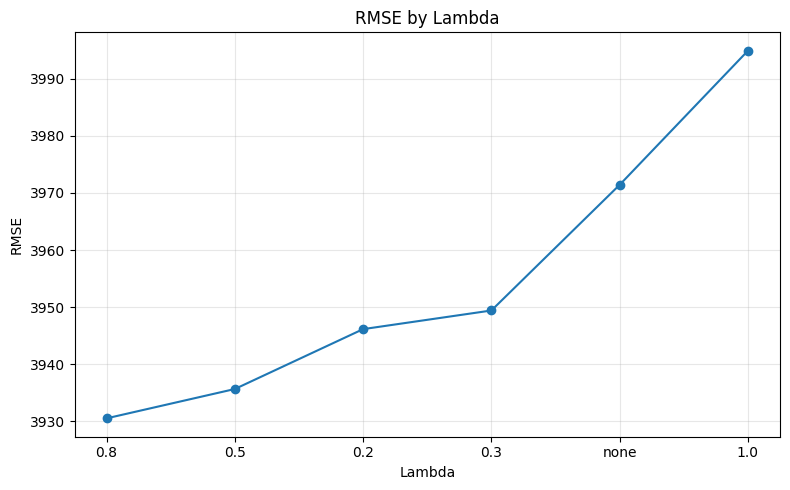

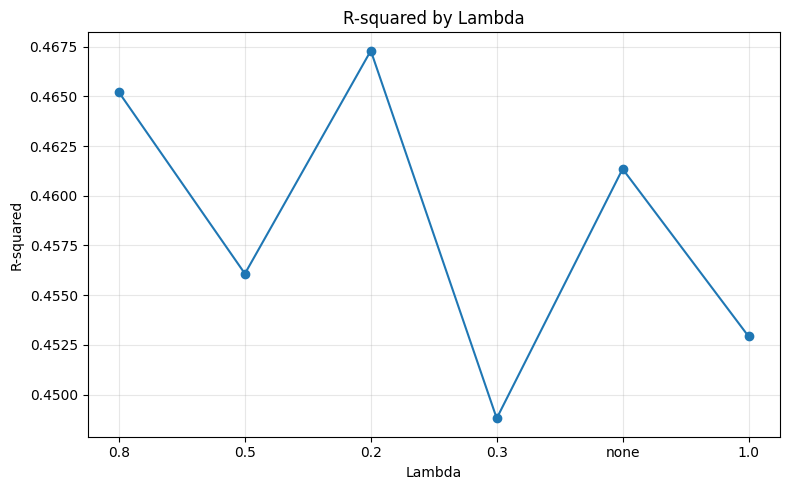

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# =========================================================
# INPUT
# Assumes this file was created during data engineering
# WITHOUT OD proxies:
#   full_dataset_with_clusters_consolidated.csv
# =========================================================
DATA_PATH = "full_dataset_with_clusters_consolidated.csv"

# =========================================================
# 1. LOAD CLUSTERED, RIDERSHIP-MERGED DATASET
# =========================================================
df_model_all = pd.read_csv(DATA_PATH)
df_model_all["station_complex_id"] = df_model_all["station_complex_id"].astype(str).str.strip()

print("Rows in modeling dataset:", len(df_model_all))

if "is_ibx" not in df_model_all.columns:
    df_model_all["is_ibx"] = df_model_all["station_complex_id"].str.startswith("IBX_", na=False)

print("\nAvailable columns:")
print(df_model_all.columns.tolist())

# =========================================================
# 2. CHOOSE COORDINATE COLUMNS
# =========================================================
if {"longitude", "latitude"}.issubset(df_model_all.columns):
    lon_col = "longitude"
    lat_col = "latitude"
elif {"lon", "lat"}.issubset(df_model_all.columns):
    lon_col = "lon"
    lat_col = "lat"
else:
    raise ValueError(
        "No longitude/latitude columns found in consolidated dataset. "
        "Add coordinates first or update lon_col/lat_col."
    )

# =========================================================
# 3. DEFINE BASE FEATURES (NO OD PROXY YET)
# =========================================================
base_features = [
    "population_0p5mi",
    "pop_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",
    "jobs_0p5mi",
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi"
]

base_features_available = [f for f in base_features if f in df_model_all.columns]
base_features_missing = [f for f in base_features if f not in df_model_all.columns]

print("\nBase features available:")
print(base_features_available)

if base_features_missing:
    print("\nRequested base features missing:")
    print(base_features_missing)

# =========================================================
# 4. CLUSTER DIAGNOSTICS
# Uses existing cluster assignments from data engineering
# =========================================================
borough_by_cluster_all = (
    df_model_all.groupby("cluster")["borough"]
    .apply(lambda s: sorted(set(x for x in s.dropna())))
)

manhattan_only_clusters_all = [
    cl for cl, boroughs in borough_by_cluster_all.items()
    if len(boroughs) > 0 and set(boroughs) == {"Manhattan"}
]

print("\nBoroughs by cluster:")
for cl, boroughs in borough_by_cluster_all.items():
    print(f"Cluster {cl}: {boroughs}")

print(f"\nManhattan-only cluster(s): {manhattan_only_clusters_all}")

# Reconstruct centroids using non-OD base features only
centroid_data = df_model_all.dropna(subset=base_features_available + ["cluster"]).copy()

centroids_all = (
    centroid_data.groupby("cluster")[base_features_available]
    .mean()
    .sort_index()
    .to_numpy()
)

cluster_labels = sorted(centroid_data["cluster"].dropna().unique().tolist())
cluster_to_pos = {cl: i for i, cl in enumerate(cluster_labels)}

target_cluster_all = 2
if target_cluster_all not in cluster_to_pos:
    raise ValueError("Target cluster 2 not found in dataset.")

target_pos = cluster_to_pos[target_cluster_all]

dist_matrix_all = cdist(centroids_all, centroids_all, metric="euclidean")
dist_matrix_all[target_pos, target_pos] = np.inf

nearest_pos = int(np.argmin(dist_matrix_all[target_pos]))
additional_cluster_1_all = cluster_labels[nearest_pos]

candidate_clusters_all = [
    cl for cl in cluster_labels
    if cl not in [target_cluster_all, additional_cluster_1_all]
    and cl not in manhattan_only_clusters_all
]

if len(candidate_clusters_all) > 0:
    additional_cluster_2_all = min(
        candidate_clusters_all,
        key=lambda cl: dist_matrix_all[target_pos, cluster_to_pos[cl]]
    )
else:
    additional_cluster_2_all = None

selected_clusters_model1 = [target_cluster_all]
selected_clusters_model2 = [target_cluster_all, additional_cluster_1_all]

if additional_cluster_2_all is not None:
    selected_clusters_model3 = [
        target_cluster_all,
        additional_cluster_1_all,
        additional_cluster_2_all
    ]
else:
    selected_clusters_model3 = [
        target_cluster_all,
        additional_cluster_1_all
    ]

print(f"\nTarget cluster: {target_cluster_all}")
print(f"Nearest cluster to target: {additional_cluster_1_all}")
print(f"Extra non-Manhattan-only cluster: {additional_cluster_2_all}")
print(f"Model 1 clusters: {selected_clusters_model1}")
print(f"Model 2 clusters: {selected_clusters_model2}")
print(f"Model 3 clusters: {selected_clusters_model3}")
print("Model 4 clusters: all clusters including Manhattan")

# =========================================================
# 5. BUILD FOUR TRAINING DATASETS
# =========================================================
train_df_m1 = df_model_all[
    (df_model_all["cluster"].isin(selected_clusters_model1)) &
    (df_model_all["log_avg_ridership"].notna())
].copy()

train_df_m2 = df_model_all[
    (df_model_all["cluster"].isin(selected_clusters_model2)) &
    (df_model_all["log_avg_ridership"].notna())
].copy()

train_df_m3 = df_model_all[
    (df_model_all["cluster"].isin(selected_clusters_model3)) &
    (df_model_all["log_avg_ridership"].notna())
].copy()

train_df_m4 = df_model_all[
    df_model_all["log_avg_ridership"].notna()
].copy()

ibx_df_all = df_model_all[df_model_all["is_ibx"]].copy()

print("\nTraining rows by dataset:")
print(f"Model 1 (cluster 2 only): {len(train_df_m1)}")
print(f"Model 2 (cluster 2 + nearest): {len(train_df_m2)}")
print(f"Model 3 (cluster 2 + 2 non-Manhattan-focused): {len(train_df_m3)}")
print(f"Model 4 (all clusters incl. Manhattan): {len(train_df_m4)}")
print(f"IBX rows: {len(ibx_df_all)}")

# =========================================================
# 6. HAVERSINE DISTANCE FUNCTION (MILES)
# =========================================================
def haversine_miles(lon1, lat1, lon2, lat2):
    R = 3958.756

    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

# =========================================================
# 7. BUILD OD PROXY FOR A GIVEN LAMBDA
# Uses full observed system in the consolidated dataset
# =========================================================
def add_od_proxy(df_in, lambda_val):
    df_out = df_in.copy()

    required_cols = ["jobs_0p5mi", lon_col, lat_col]
    missing_cols = [c for c in required_cols if c not in df_out.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns for OD proxy: {missing_cols}")

    od_source = df_out.dropna(subset=["jobs_0p5mi", lon_col, lat_col]).copy()

    coords = od_source[[lon_col, lat_col]].to_numpy(dtype=float)
    jobs = od_source["jobs_0p5mi"].to_numpy(dtype=float)

    n = len(od_source)
    od_vals = np.zeros(n, dtype=float)

    for i in range(n):
        lon_i, lat_i = coords[i]

        dists = haversine_miles(
            lon_i,
            lat_i,
            coords[:, 0],
            coords[:, 1]
        )

        dists[i] = np.nan
        weights = np.exp(-lambda_val * dists)

        od_vals[i] = np.nansum(jobs * weights)

    od_source["od_jobs_exp_accessibility"] = od_vals
    od_source["log_od_jobs_exp_accessibility"] = np.log1p(od_source["od_jobs_exp_accessibility"])

    df_out = df_out.merge(
        od_source[[
            "station_complex_id",
            "od_jobs_exp_accessibility",
            "log_od_jobs_exp_accessibility"
        ]],
        on="station_complex_id",
        how="left"
    )

    return df_out

# =========================================================
# 8. FEATURE ENGINEERING HELPER
# =========================================================
def ensure_engineered_features(df_in, base_features, use_od=False):
    df_out = df_in.copy()

    if "jobs_0p5mi" in df_out.columns and "log_jobs_0p5mi" not in df_out.columns:
        df_out["log_jobs_0p5mi"] = np.log1p(df_out["jobs_0p5mi"])

    if "population_0p5mi" in df_out.columns and "log_population_0p5mi" not in df_out.columns:
        df_out["log_population_0p5mi"] = np.log1p(df_out["population_0p5mi"])

    if "pop_density_0p5mi" in df_out.columns and "log_pop_density_0p5mi" not in df_out.columns:
        df_out["log_pop_density_0p5mi"] = np.log1p(df_out["pop_density_0p5mi"])

    if (
        {"jobs_0p5mi", "pct_transit_0p5mi"}.issubset(df_out.columns)
        and "jobs_x_transit" not in df_out.columns
    ):
        df_out["jobs_x_transit"] = df_out["jobs_0p5mi"] * df_out["pct_transit_0p5mi"]

    if (
        {"pop_density_0p5mi", "pct_hh_no_vehicle_0p5mi"}.issubset(df_out.columns)
        and "density_x_no_vehicle" not in df_out.columns
    ):
        df_out["density_x_no_vehicle"] = (
            df_out["pop_density_0p5mi"] * df_out["pct_hh_no_vehicle_0p5mi"]
        )

    if (
        {"jobs_0p5mi", "bus_routes_0p5mi"}.issubset(df_out.columns)
        and "jobs_x_bus" not in df_out.columns
    ):
        df_out["jobs_x_bus"] = df_out["jobs_0p5mi"] * df_out["bus_routes_0p5mi"]

    engineered_features = [
        "log_jobs_0p5mi",
        "log_population_0p5mi",
        "log_pop_density_0p5mi",
        "jobs_x_transit",
        "density_x_no_vehicle",
        "jobs_x_bus"
    ]

    features_model = base_features.copy()

    if use_od and "log_od_jobs_exp_accessibility" in df_out.columns:
        features_model = features_model + ["log_od_jobs_exp_accessibility"]

    features_model = [col for col in (features_model + engineered_features) if col in df_out.columns]
    return df_out, features_model

# =========================================================
# 9. MODEL RUNNER
# =========================================================
def run_xgb_pipeline(train_df, ibx_df, base_features, model_label, use_od=False, random_state=42):
    train_df_eng, features_model = ensure_engineered_features(train_df, base_features, use_od=use_od)
    ibx_df_eng, features_model_ibx = ensure_engineered_features(ibx_df, base_features, use_od=use_od)

    features_model_final = [col for col in features_model if col in features_model_ibx]

    train_df_eng = train_df_eng.dropna(subset=features_model_final + ["log_avg_ridership"]).copy()
    ibx_df_eng = ibx_df_eng.dropna(subset=features_model_final).copy()

    print(f"\n{'=' * 60}")
    print(model_label)
    print(f"{'=' * 60}")
    print("Training rows:", len(train_df_eng))
    print("IBX rows:", len(ibx_df))
    print("IBX rows with complete features:", len(ibx_df_eng))
    print("Number of model features:", len(features_model_final))

    X = train_df_eng[features_model_final].copy()
    y = train_df_eng["log_avg_ridership"].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=random_state
    )

    print("Train rows:", len(X_train))
    print("Test rows:", len(X_test))

    model = XGBRegressor(
        n_estimators=600,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1,
        objective="reg:squarederror",
        random_state=random_state
    )

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"
    )

    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    mae_log = mean_absolute_error(y_test, y_pred_log)

    y_test_orig = np.exp(y_test)
    y_pred_orig = np.exp(y_pred_log)

    rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)

    importance_df = pd.DataFrame({
        "feature": features_model_final,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    X_ibx = ibx_df_eng[features_model_final].copy()
    ibx_df_eng["pred_log_avg_ridership"] = model.predict(X_ibx)
    ibx_df_eng["pred_avg_annual_ridership"] = np.exp(ibx_df_eng["pred_log_avg_ridership"])

    ibx_df_eng["pred_avg_annual_ridership_adjusted"] = ibx_df_eng["pred_avg_annual_ridership"]

    ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 0,
        "pred_avg_annual_ridership_adjusted"
    ] = ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 0,
        "pred_avg_annual_ridership"
    ] * 1.10

    ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 3,
        "pred_avg_annual_ridership_adjusted"
    ] = ibx_df_eng.loc[
        ibx_df_eng["cluster"] == 3,
        "pred_avg_annual_ridership"
    ] * 0.90

    ibx_results = ibx_df_eng[[
        "station_complex_name",
        "station_complex_id",
        "borough",
        "cluster",
        "pred_log_avg_ridership",
        "pred_avg_annual_ridership",
        "pred_avg_annual_ridership_adjusted"
    ]].sort_values(["cluster", "station_complex_name"])

    return {
        "model": model,
        "features_model": features_model_final,
        "cv_scores": cv_scores,
        "r2_log": r2_log,
        "rmse_log": rmse_log,
        "mae_log": mae_log,
        "rmse_orig": rmse_orig,
        "mae_orig": mae_orig,
        "importance_df": importance_df,
        "ibx_results": ibx_results,
        "train_rows": len(train_df_eng),
        "test_rows": len(X_test)
    }

# =========================================================
# 10. GRID SEARCH FOR LAMBDA
# Uses Model 3 as the tuning specification
# Starts with baseline (no OD proxy)
# =========================================================
lambda_grid = [0.2, 0.3, 0.5, 0.8, 1.0]

grid_results = []

# Baseline: no OD
baseline_result = run_xgb_pipeline(
    train_df=train_df_m3,
    ibx_df=ibx_df_all,
    base_features=base_features_available,
    model_label="BASELINE (No OD Proxy) - Tuning on Model 3",
    use_od=False
)

grid_results.append({
    "lambda": "none",
    "use_od": False,
    "cv_mean_r2": baseline_result["cv_scores"].mean(),
    "cv_std_r2": baseline_result["cv_scores"].std(),
    "test_r2_log": baseline_result["r2_log"],
    "rmse_log": baseline_result["rmse_log"],
    "mae_log": baseline_result["mae_log"],
    "rmse_original": baseline_result["rmse_orig"],
    "mae_original": baseline_result["mae_orig"]
})

# Grid search over lambdas
for lam in lambda_grid:
    print(f"\n{'#' * 70}")
    print(f"GRID SEARCH: lambda = {lam}")
    print(f"{'#' * 70}")

    df_with_od = add_od_proxy(df_model_all, lam)

    train_df_grid = df_with_od[
        (df_with_od["cluster"].isin(selected_clusters_model3)) &
        (df_with_od["log_avg_ridership"].notna())
    ].copy()

    ibx_df_grid = df_with_od[df_with_od["is_ibx"]].copy()

    result = run_xgb_pipeline(
        train_df=train_df_grid,
        ibx_df=ibx_df_grid,
        base_features=base_features_available,
        model_label=f"GRID SEARCH MODEL 3 (lambda={lam})",
        use_od=True
    )

    grid_results.append({
        "lambda": lam,
        "use_od": True,
        "cv_mean_r2": result["cv_scores"].mean(),
        "cv_std_r2": result["cv_scores"].std(),
        "test_r2_log": result["r2_log"],
        "rmse_log": result["rmse_log"],
        "mae_log": result["mae_log"],
        "rmse_original": result["rmse_orig"],
        "mae_original": result["mae_orig"]
    })

grid_search_df = pd.DataFrame(grid_results).sort_values(
    by=["rmse_original", "mae_original"],
    ascending=[True, True]
).reset_index(drop=True)

print("\nGrid search results:")
print(grid_search_df)

best_row = grid_search_df.iloc[0]
best_lambda = None if best_row["lambda"] == "none" else float(best_row["lambda"])

print("\nBest lambda selection:")
print(best_row)

# =========================================================
# 11. PREP FINAL DATASET USING BEST LAMBDA
# =========================================================
if best_lambda is None:
    df_best = df_model_all.copy()
    use_od_best = False
else:
    df_best = add_od_proxy(df_model_all, best_lambda)
    use_od_best = True

train_df_m1_best = df_best[
    (df_best["cluster"].isin(selected_clusters_model1)) &
    (df_best["log_avg_ridership"].notna())
].copy()

train_df_m2_best = df_best[
    (df_best["cluster"].isin(selected_clusters_model2)) &
    (df_best["log_avg_ridership"].notna())
].copy()

train_df_m3_best = df_best[
    (df_best["cluster"].isin(selected_clusters_model3)) &
    (df_best["log_avg_ridership"].notna())
].copy()

train_df_m4_best = df_best[
    df_best["log_avg_ridership"].notna()
].copy()

ibx_df_best = df_best[df_best["is_ibx"]].copy()

# =========================================================
# 12. RUN FOUR FINAL MODELS WITH BEST LAMBDA
# =========================================================
results_m1 = run_xgb_pipeline(
    train_df=train_df_m1_best,
    ibx_df=ibx_df_best,
    base_features=base_features_available,
    model_label=f"MODEL 1: Cluster 2 Only | best_lambda={best_lambda}",
    use_od=use_od_best
)

results_m2 = run_xgb_pipeline(
    train_df=train_df_m2_best,
    ibx_df=ibx_df_best,
    base_features=base_features_available,
    model_label=f"MODEL 2: Cluster 2 + Nearest | best_lambda={best_lambda}",
    use_od=use_od_best
)

results_m3 = run_xgb_pipeline(
    train_df=train_df_m3_best,
    ibx_df=ibx_df_best,
    base_features=base_features_available,
    model_label=f"MODEL 3: Cluster 2 + Two Additional Clusters (No Manhattan-only) | best_lambda={best_lambda}",
    use_od=use_od_best
)

results_m4 = run_xgb_pipeline(
    train_df=train_df_m4_best,
    ibx_df=ibx_df_best,
    base_features=base_features_available,
    model_label=f"MODEL 4: All Clusters Including Manhattan | best_lambda={best_lambda}",
    use_od=use_od_best
)

# =========================================================
# 13. PERFORMANCE COMPARISON
# =========================================================
performance_comparison_df = pd.DataFrame([
    {
        "model_name": "Model 1: Cluster 2 Only",
        "best_lambda": best_lambda if best_lambda is not None else "none",
        "train_rows": results_m1["train_rows"],
        "test_rows": results_m1["test_rows"],
        "n_features": len(results_m1["features_model"]),
        "cv_mean_r2": results_m1["cv_scores"].mean(),
        "cv_std_r2": results_m1["cv_scores"].std(),
        "test_r2_log": results_m1["r2_log"],
        "rmse_log": results_m1["rmse_log"],
        "mae_log": results_m1["mae_log"],
        "rmse_original": results_m1["rmse_orig"],
        "mae_original": results_m1["mae_orig"]
    },
    {
        "model_name": "Model 2: Cluster 2 + Nearest",
        "best_lambda": best_lambda if best_lambda is not None else "none",
        "train_rows": results_m2["train_rows"],
        "test_rows": results_m2["test_rows"],
        "n_features": len(results_m2["features_model"]),
        "cv_mean_r2": results_m2["cv_scores"].mean(),
        "cv_std_r2": results_m2["cv_scores"].std(),
        "test_r2_log": results_m2["r2_log"],
        "rmse_log": results_m2["rmse_log"],
        "mae_log": results_m2["mae_log"],
        "rmse_original": results_m2["rmse_orig"],
        "mae_original": results_m2["mae_orig"]
    },
    {
        "model_name": "Model 3: Cluster 2 + 2 Clusters No Manhattan-only",
        "best_lambda": best_lambda if best_lambda is not None else "none",
        "train_rows": results_m3["train_rows"],
        "test_rows": results_m3["test_rows"],
        "n_features": len(results_m3["features_model"]),
        "cv_mean_r2": results_m3["cv_scores"].mean(),
        "cv_std_r2": results_m3["cv_scores"].std(),
        "test_r2_log": results_m3["r2_log"],
        "rmse_log": results_m3["rmse_log"],
        "mae_log": results_m3["mae_log"],
        "rmse_original": results_m3["rmse_orig"],
        "mae_original": results_m3["mae_orig"]
    },
    {
        "model_name": "Model 4: All Clusters Including Manhattan",
        "best_lambda": best_lambda if best_lambda is not None else "none",
        "train_rows": results_m4["train_rows"],
        "test_rows": results_m4["test_rows"],
        "n_features": len(results_m4["features_model"]),
        "cv_mean_r2": results_m4["cv_scores"].mean(),
        "cv_std_r2": results_m4["cv_scores"].std(),
        "test_r2_log": results_m4["r2_log"],
        "rmse_log": results_m4["rmse_log"],
        "mae_log": results_m4["mae_log"],
        "rmse_original": results_m4["rmse_orig"],
        "mae_original": results_m4["mae_orig"]
    }
]).sort_values(
    by=["rmse_original", "mae_original"],
    ascending=[True, True]
).reset_index(drop=True)

print("\nFinal performance comparison:")
print(performance_comparison_df)

# =========================================================
# 14. SAVE OUTPUTS
# =========================================================
grid_search_df.to_csv("lambda_grid_search_results.csv", index=False)

results_m1["importance_df"].to_csv("xgb_feature_importance_model1_best_lambda.csv", index=False)
results_m2["importance_df"].to_csv("xgb_feature_importance_model2_best_lambda.csv", index=False)
results_m3["importance_df"].to_csv("xgb_feature_importance_model3_best_lambda.csv", index=False)
results_m4["importance_df"].to_csv("xgb_feature_importance_model4_best_lambda.csv", index=False)

results_m1["ibx_results"].to_csv("ibx_ridership_predictions_model1_best_lambda.csv", index=False)
results_m2["ibx_results"].to_csv("ibx_ridership_predictions_model2_best_lambda.csv", index=False)
results_m3["ibx_results"].to_csv("ibx_ridership_predictions_model3_best_lambda.csv", index=False)
results_m4["ibx_results"].to_csv("ibx_ridership_predictions_model4_best_lambda.csv", index=False)

performance_comparison_df.to_csv("model_performance_comparison_best_lambda.csv", index=False)

print("\nSaved files:")
print(" - lambda_grid_search_results.csv")
print(" - xgb_feature_importance_model1_best_lambda.csv")
print(" - xgb_feature_importance_model2_best_lambda.csv")
print(" - xgb_feature_importance_model3_best_lambda.csv")
print(" - xgb_feature_importance_model4_best_lambda.csv")
print(" - ibx_ridership_predictions_model1_best_lambda.csv")
print(" - ibx_ridership_predictions_model2_best_lambda.csv")
print(" - ibx_ridership_predictions_model3_best_lambda.csv")
print(" - ibx_ridership_predictions_model4_best_lambda.csv")
print(" - model_performance_comparison_best_lambda.csv")

import matplotlib.pyplot as plt
import pandas as pd

# Make a plotting copy
plot_df = grid_search_df.copy()

# Convert lambda to string for clean labels
plot_df["lambda_label"] = plot_df["lambda"].astype(str)

# ---------------------------------------------------------
# RMSE PLOT
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(plot_df["lambda_label"], plot_df["rmse_original"], marker="o")
plt.xlabel("Lambda")
plt.ylabel("RMSE")
plt.title("RMSE by Lambda")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# R-SQUARED PLOT
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(plot_df["lambda_label"], plot_df["test_r2_log"], marker="o")
plt.xlabel("Lambda")
plt.ylabel("R-squared")
plt.title("R-squared by Lambda")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

# =========================================================
# ASSUMES:
# - train_df_v3
# - ibx_df_v3
# - features_available_v3
# =========================================================

# =========================================================
# 1. FEATURE ENGINEERING (IMPROVED)
# =========================================================
def engineer_features_v4(df):
    df = df.copy()

    # Core log transforms
    for col in ["jobs_0p5mi", "population_0p5mi", "pop_density_0p5mi",
                "median_hh_income_0p5mi_approx"]:
        if col in df.columns:
            df[f"log_{col}"] = np.log1p(df[col])

    # Interaction terms
    df["jobs_x_transit"] = df["jobs_0p5mi"] * df["pct_transit_0p5mi"]
    df["density_x_no_vehicle"] = df["pop_density_0p5mi"] * df["pct_hh_no_vehicle_0p5mi"]
    df["jobs_x_bus"] = df["jobs_0p5mi"] * df["bus_routes_0p5mi"]

    return df

train_df_v4 = engineer_features_v4(train_df_v3)
ibx_pred_df_v4 = engineer_features_v4(ibx_df_v3)

# =========================================================
# 2. REMOVE HIGHLY CORRELATED FEATURES
# =========================================================
def remove_correlated_features(df, features, threshold=0.90):
    corr_matrix = df[features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return [f for f in features if f not in to_drop]

engineered_features_v4 = [
    "log_jobs_0p5mi",
    "log_population_0p5mi",
    "log_pop_density_0p5mi",
    "log_median_hh_income_0p5mi_approx",
    "jobs_x_transit",
    "density_x_no_vehicle",
    "jobs_x_bus"
]

features_model_v4 = features_available_v3 + engineered_features_v4
features_model_v4 = [f for f in features_model_v4 if f in train_df_v4.columns]

# remove redundancy
features_model_v4 = remove_correlated_features(train_df_v4, features_model_v4)

print("Final number of features:", len(features_model_v4))

# =========================================================
# 3. DEFINE X AND y
# =========================================================
train_df_v4 = train_df_v4.dropna(subset=features_model_v4 + ["log_avg_ridership"])

X_v4 = train_df_v4[features_model_v4]
y_v4 = train_df_v4["log_avg_ridership"]

# =========================================================
# 4. STRATIFIED SPLIT (RIDERSHIP BINS)
# =========================================================
y_bins = pd.qcut(y_v4, q=5, labels=False, duplicates='drop')

X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
    X_v4,
    y_v4,
    test_size=0.20,
    stratify=y_bins,
    random_state=42
)

print("Train rows:", len(X_train_v4))
print("Test rows:", len(X_test_v4))

# =========================================================
# 5. HYPERPARAMETER TUNING (RANDOM SEARCH)
# =========================================================
param_dist = {
    "n_estimators": [300, 500, 700],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_alpha": [0, 0.5, 1],
    "reg_lambda": [1, 2, 3]
}

base_model = XGBRegressor(objective="reg:squarederror", random_state=42)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=25,
    scoring="r2",
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train_v4, y_train_v4)

best_model_v4 = search.best_estimator_

print("\nBest parameters:")
print(search.best_params_)

# =========================================================
# 6. CROSS-VALIDATION
# =========================================================
cv_scores_v4 = cross_val_score(best_model_v4, X_v4, y_v4, cv=5, scoring="r2")

print("\nCV Mean R²:", cv_scores_v4.mean())
print("CV Std:", cv_scores_v4.std())

# =========================================================
# 7. EVALUATE MODEL
# =========================================================
y_pred_log_v4 = best_model_v4.predict(X_test_v4)

r2_v4 = r2_score(y_test_v4, y_pred_log_v4)
rmse_log_v4 = np.sqrt(mean_squared_error(y_test_v4, y_pred_log_v4))
mae_log_v4 = mean_absolute_error(y_test_v4, y_pred_log_v4)

# back-transform
y_test_orig_v4 = np.exp(y_test_v4)
y_pred_orig_v4 = np.exp(y_pred_log_v4)

rmse_orig_v4 = np.sqrt(mean_squared_error(y_test_orig_v4, y_pred_orig_v4))
mae_orig_v4 = mean_absolute_error(y_test_orig_v4, y_pred_orig_v4)

print("\nTest Performance:")
print("R²:", r2_v4)
print("RMSE (log):", rmse_log_v4)
print("MAE (log):", mae_log_v4)
print("RMSE (orig):", rmse_orig_v4)
print("MAE (orig):", mae_orig_v4)

# =========================================================
# 8. FEATURE IMPORTANCE
# =========================================================
importance_df_v4 = pd.DataFrame({
    "feature": X_v4.columns,
    "importance": best_model_v4.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop features:")
print(importance_df_v4.head(15))

# =========================================================
# 9. IBX PREDICTIONS
# =========================================================
ibx_pred_df_v4 = ibx_pred_df_v4.dropna(subset=features_model_v4)

X_ibx_v4 = ibx_pred_df_v4[features_model_v4]

ibx_pred_df_v4["pred_log_avg_ridership"] = best_model_v4.predict(X_ibx_v4)
ibx_pred_df_v4["pred_avg_annual_ridership"] = np.exp(ibx_pred_df_v4["pred_log_avg_ridership"])

print("\nIBX predictions:")
print(ibx_pred_df_v4[[
    "station_complex_name",
    "pred_avg_annual_ridership"
]])

Final number of features: 30
Train rows: 340
Test rows: 86
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best parameters:
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

CV Mean R²: 0.4190690381693415
CV Std: 0.10187054104653465

Test Performance:
R²: 0.5838749960351386
RMSE (log): 0.6184858528231227
MAE (log): 0.48599203204808716
RMSE (orig): 7421.048814891402
MAE (orig): 4312.062815275272

Top features:
                           feature  importance
28                  log_jobs_0p5mi    0.157385
3                       jobs_0p5mi    0.140280
6          pct_hh_no_vehicle_0p5mi    0.095844
14                bus_routes_0p5mi    0.063319
24  cultural_count_0p25mi_capped10    0.043557
5             citibike_count_0p5mi    0.039031
8                pct_transit_0p5mi    0.034146
9                 pct_walked_0p5mi    0.030204
23           cultural_count_0p25mi    0.029050
13            

# Gradient Boosting Alternatives: LightGBM / CatBoost

## Data Preparation

In [ ]:
!pip install lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# =========================================================
# ASSUMES THESE ALREADY EXIST:
# - train_df_v3
# - ibx_df_v3
# - features_available_v3
# =========================================================

# =========================================================
# 1. FEATURE ENGINEERING
# =========================================================
def engineer_features_gbm(df):
    df = df.copy()

    for col in [
        "jobs_0p5mi",
        "population_0p5mi",
        "pop_density_0p5mi",
        "median_hh_income_0p5mi_approx"
    ]:
        if col in df.columns:
            df[f"log_{col}"] = np.log1p(df[col])

    if {"jobs_0p5mi", "pct_transit_0p5mi"}.issubset(df.columns):
        df["jobs_x_transit"] = df["jobs_0p5mi"] * df["pct_transit_0p5mi"]

    if {"pop_density_0p5mi", "pct_hh_no_vehicle_0p5mi"}.issubset(df.columns):
        df["density_x_no_vehicle"] = (
            df["pop_density_0p5mi"] * df["pct_hh_no_vehicle_0p5mi"]
        )

    if {"jobs_0p5mi", "bus_routes_0p5mi"}.issubset(df.columns):
        df["jobs_x_bus"] = df["jobs_0p5mi"] * df["bus_routes_0p5mi"]

    return df

train_df_gbm = engineer_features_gbm(train_df_v3.copy())
ibx_pred_df_gbm = engineer_features_gbm(ibx_df_v3.copy())

engineered_features_gbm = [
    "log_jobs_0p5mi",
    "log_population_0p5mi",
    "log_pop_density_0p5mi",
    "log_median_hh_income_0p5mi_approx",
    "jobs_x_transit",
    "density_x_no_vehicle",
    "jobs_x_bus"
]

features_model_gbm = [
    col for col in (features_available_v3 + engineered_features_gbm)
    if col in train_df_gbm.columns and col in ibx_pred_df_gbm.columns
]

# =========================================================
# 2. REMOVE HIGHLY CORRELATED FEATURES
# =========================================================
def remove_correlated_features(df, features, threshold=0.90):
    corr_matrix = df[features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return [f for f in features if f not in to_drop]

features_model_gbm = remove_correlated_features(
    train_df_gbm,
    features_model_gbm,
    threshold=0.90
)

print("Final number of gradient-boosting features:", len(features_model_gbm))

# =========================================================
# 3. CLEAN DATA
# =========================================================
train_df_gbm = train_df_gbm.dropna(subset=features_model_gbm + ["log_avg_ridership"]).copy()
ibx_pred_df_gbm = ibx_pred_df_gbm.dropna(subset=features_model_gbm).copy()

print("Training rows:", len(train_df_gbm))
print("IBX rows:", len(ibx_df_v3))
print("IBX rows with complete features:", len(ibx_pred_df_gbm))

# =========================================================
# 4. DEFINE X AND y
# =========================================================
X_gbm = train_df_gbm[features_model_gbm].copy()
y_gbm = train_df_gbm["log_avg_ridership"].copy()

# Stratified split by ridership bins
y_bins_gbm = pd.qcut(y_gbm, q=5, labels=False, duplicates="drop")

X_train_gbm, X_test_gbm, y_train_gbm, y_test_gbm = train_test_split(
    X_gbm,
    y_gbm,
    test_size=0.20,
    stratify=y_bins_gbm,
    random_state=42
)

print("\nTrain rows:", len(X_train_gbm))
print("Test rows:", len(X_test_gbm))

Final number of gradient-boosting features: 30
Training rows: 426
IBX rows: 19
IBX rows with complete features: 19

Train rows: 340
Test rows: 86


## LightGBM

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best LightGBM parameters:
{'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'num_leaves': 50, 'n_estimators': 500, 'min_child_samples': 5, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

LightGBM CV R-squared scores:
[0.42497701 0.48146154 0.51350195 0.20657629 0.20838395]
Mean CV R-squared: 0.3670
Std CV R-squared:  0.1333

LightGBM test set performance on log scale:
R-squared: 0.5560
RMSE (log): 0.6388
MAE  (log): 0.5027

LightGBM approximate performance on original ridership scale:
RMSE: 8,959.24
MAE : 4,656.09

Top 15 LightGBM feature importances:
                          feature  importance
13                  pct_wfh_0p5mi         275
4        intersection_count_0p5mi         229
10              pct_bicycle_0p5mi         195
0                population_0p5mi         194
3                      jobs_0p5mi         173
5            citibike_count_0p5mi         168
7   median_hh_income_0p5mi_approx 

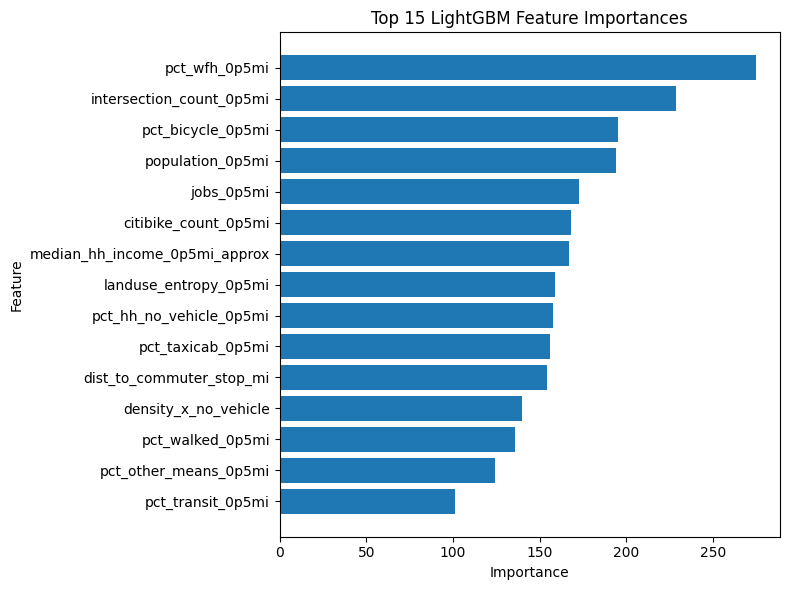


IBX predicted ridership (LightGBM):
       station_complex_name station_complex_id borough  cluster  \
462                4 Avenue             IBX_18     NaN        0   
449           Myrtle Avenue              IBX_5     NaN        0   
445        Roosevelt Avenue              IBX_1     NaN        0   
461                8 Avenue             IBX_17     NaN        2   
451         Atlantic Avenue              IBX_7     NaN        2   
458          East 16 Street             IBX_14     NaN        2   
447            Eliot Avenue              IBX_3     NaN        2   
457       Flatbush–Nostrand             IBX_13     NaN        2   
446            Grand Avenue              IBX_2     NaN        2   
454             Linden Blvd             IBX_10     NaN        2   
453          Livonia Avenue              IBX_9     NaN        2   
459         McDonald Avenue             IBX_15     NaN        2   
448     Metropolitan Avenue              IBX_4     NaN        2   
460      New Utrecht Aven

In [ ]:
# =========================================================
# LIGHTGBM REGRESSOR
# =========================================================
lgbm_base = LGBMRegressor(
    objective="regression",
    random_state=42,
    verbose=-1
)

param_dist_lgbm = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05],
    "max_depth": [-1, 3, 4, 5, 6],
    "num_leaves": [15, 31, 50, 70],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "min_child_samples": [5, 10, 20, 30],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [0, 0.5, 1.0, 2.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist_lgbm,
    n_iter=25,
    scoring="r2",
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

lgbm_search.fit(X_train_gbm, y_train_gbm)

best_lgbm_model = lgbm_search.best_estimator_

print("\nBest LightGBM parameters:")
print(lgbm_search.best_params_)

# Cross-validation
cv_scores_lgbm = cross_val_score(
    best_lgbm_model,
    X_gbm,
    y_gbm,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("\nLightGBM CV R-squared scores:")
print(cv_scores_lgbm)
print(f"Mean CV R-squared: {cv_scores_lgbm.mean():.4f}")
print(f"Std CV R-squared:  {cv_scores_lgbm.std():.4f}")

# Fit final model
best_lgbm_model.fit(X_train_gbm, y_train_gbm)

# Evaluate
y_pred_log_lgbm = best_lgbm_model.predict(X_test_gbm)

r2_lgbm = r2_score(y_test_gbm, y_pred_log_lgbm)
rmse_log_lgbm = np.sqrt(mean_squared_error(y_test_gbm, y_pred_log_lgbm))
mae_log_lgbm = mean_absolute_error(y_test_gbm, y_pred_log_lgbm)

print("\nLightGBM test set performance on log scale:")
print(f"R-squared: {r2_lgbm:.4f}")
print(f"RMSE (log): {rmse_log_lgbm:.4f}")
print(f"MAE  (log): {mae_log_lgbm:.4f}")

# Back-transform
y_test_orig_lgbm = np.exp(y_test_gbm)
y_pred_orig_lgbm = np.exp(y_pred_log_lgbm)

rmse_orig_lgbm = np.sqrt(mean_squared_error(y_test_orig_lgbm, y_pred_orig_lgbm))
mae_orig_lgbm = mean_absolute_error(y_test_orig_lgbm, y_pred_orig_lgbm)

print("\nLightGBM approximate performance on original ridership scale:")
print(f"RMSE: {rmse_orig_lgbm:,.2f}")
print(f"MAE : {mae_orig_lgbm:,.2f}")

# Feature importance
importance_df_lgbm = pd.DataFrame({
    "feature": X_gbm.columns,
    "importance": best_lgbm_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 LightGBM feature importances:")
print(importance_df_lgbm.head(15))

plt.figure(figsize=(8, 6))
top_imp_lgbm = importance_df_lgbm.head(15).sort_values("importance")
plt.barh(top_imp_lgbm["feature"], top_imp_lgbm["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 LightGBM Feature Importances")
plt.tight_layout()
plt.show()

# IBX predictions
X_ibx_lgbm = ibx_pred_df_gbm[features_model_gbm].copy()
ibx_pred_df_lgbm = ibx_pred_df_gbm.copy()

ibx_pred_df_lgbm["pred_log_avg_ridership_lgbm"] = best_lgbm_model.predict(X_ibx_lgbm)
ibx_pred_df_lgbm["pred_avg_annual_ridership_lgbm"] = np.exp(
    ibx_pred_df_lgbm["pred_log_avg_ridership_lgbm"]
)

ibx_results_lgbm = ibx_pred_df_lgbm[[
    "station_complex_name",
    "station_complex_id",
    "borough",
    "cluster",
    "pred_log_avg_ridership_lgbm",
    "pred_avg_annual_ridership_lgbm"
]].sort_values(["cluster", "station_complex_name"])

print("\nIBX predicted ridership (LightGBM):")
print(ibx_results_lgbm)

# Save
importance_df_lgbm.to_csv("lightgbm_feature_importance.csv", index=False)
ibx_results_lgbm.to_csv("ibx_ridership_predictions_lightgbm.csv", index=False)

print("\nSaved files:")
print(" - lightgbm_feature_importance.csv")
print(" - ibx_ridership_predictions_lightgbm.csv")

## CatBoost

In [ ]:
# !pip install lightgbm catboost

# =========================================================
# CATBOOST REGRESSOR
# =========================================================
catboost_base = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

param_dist_cat = {
    "iterations": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05],
    "depth": [3, 4, 5, 6, 8],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

catboost_search = RandomizedSearchCV(
    estimator=catboost_base,
    param_distributions=param_dist_cat,
    n_iter=20,
    scoring="r2",
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

catboost_search.fit(X_train_gbm, y_train_gbm)

best_catboost_model = catboost_search.best_estimator_

print("\nBest CatBoost parameters:")
print(catboost_search.best_params_)

# Cross-validation
cv_scores_cat = cross_val_score(
    best_catboost_model,
    X_gbm,
    y_gbm,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("\nCatBoost CV R-squared scores:")
print(cv_scores_cat)
print(f"Mean CV R-squared: {cv_scores_cat.mean():.4f}")
print(f"Std CV R-squared:  {cv_scores_cat.std():.4f}")

# Fit final model
best_catboost_model.fit(X_train_gbm, y_train_gbm)

# Evaluate
y_pred_log_cat = best_catboost_model.predict(X_test_gbm)

r2_cat = r2_score(y_test_gbm, y_pred_log_cat)
rmse_log_cat = np.sqrt(mean_squared_error(y_test_gbm, y_pred_log_cat))
mae_log_cat = mean_absolute_error(y_test_gbm, y_pred_log_cat)

print("\nCatBoost test set performance on log scale:")
print(f"R-squared: {r2_cat:.4f}")
print(f"RMSE (log): {rmse_log_cat:.4f}")
print(f"MAE  (log): {mae_log_cat:.4f}")

# Back-transform
y_test_orig_cat = np.exp(y_test_gbm)
y_pred_orig_cat = np.exp(y_pred_log_cat)

rmse_orig_cat = np.sqrt(mean_squared_error(y_test_orig_cat, y_pred_orig_cat))
mae_orig_cat = mean_absolute_error(y_test_orig_cat, y_pred_orig_cat)

print("\nCatBoost approximate performance on original ridership scale:")
print(f"RMSE: {rmse_orig_cat:,.2f}")
print(f"MAE : {mae_orig_cat:,.2f}")

# Feature importance
importance_df_cat = pd.DataFrame({
    "feature": X_gbm.columns,
    "importance": best_catboost_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 CatBoost feature importances:")
print(importance_df_cat.head(15))

plt.figure(figsize=(8, 6))
top_imp_cat = importance_df_cat.head(15).sort_values("importance")
plt.barh(top_imp_cat["feature"], top_imp_cat["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 CatBoost Feature Importances")
plt.tight_layout()
plt.show()

# IBX predictions
X_ibx_cat = ibx_pred_df_gbm[features_model_gbm].copy()
ibx_pred_df_cat = ibx_pred_df_gbm.copy()

ibx_pred_df_cat["pred_log_avg_ridership_catboost"] = best_catboost_model.predict(X_ibx_cat)
ibx_pred_df_cat["pred_avg_annual_ridership_catboost"] = np.exp(
    ibx_pred_df_cat["pred_log_avg_ridership_catboost"]
)

ibx_results_cat = ibx_pred_df_cat[[
    "station_complex_name",
    "station_complex_id",
    "borough",
    "cluster",
    "pred_log_avg_ridership_catboost",
    "pred_avg_annual_ridership_catboost"
]].sort_values(["cluster", "station_complex_name"])

print("\nIBX predicted ridership (CatBoost):")
print(ibx_results_cat)

# Save
importance_df_cat.to_csv("catboost_feature_importance.csv", index=False)
ibx_results_cat.to_csv("ibx_ridership_predictions_catboost.csv", index=False)

print("\nSaved files:")
print(" - catboost_feature_importance.csv")
print(" - ibx_ridership_predictions_catboost.csv")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


## Comparison table

In [ ]:
gradient_boosting_comparison_df = pd.DataFrame([
    {
        "model": "LightGBM",
        "cv_mean_r2": cv_scores_lgbm.mean(),
        "cv_std_r2": cv_scores_lgbm.std(),
        "test_r2_log": r2_lgbm,
        "rmse_log": rmse_log_lgbm,
        "mae_log": mae_log_lgbm,
        "rmse_original": rmse_orig_lgbm,
        "mae_original": mae_orig_lgbm
    },
    {
        "model": "CatBoost",
        "cv_mean_r2": cv_scores_cat.mean(),
        "cv_std_r2": cv_scores_cat.std(),
        "test_r2_log": r2_cat,
        "rmse_log": rmse_log_cat,
        "mae_log": mae_log_cat,
        "rmse_original": rmse_orig_cat,
        "mae_original": mae_orig_cat
    }
]).sort_values(by="rmse_original", ascending=True)

print(gradient_boosting_comparison_df)

gradient_boosting_comparison_df.to_csv("gradient_boosting_comparison.csv", index=False)
print("\nSaved: gradient_boosting_comparison.csv")

## Random Forest

The tuned Random Forest model achieved strong predictive performance, with a test R² of 0.587 and moderate cross-validation stability, indicating that nonlinear interactions among land use, accessibility, and socioeconomic variables are important for explaining station ridership.

Final number of RF features: 30
Training rows: 426
IBX rows: 19
IBX rows with complete features: 19

Train rows: 340
Test rows: 86
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best RF parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 12}

RF Cross-validation R-squared scores:
[0.41959321 0.47653057 0.55095065 0.29949093 0.33990034]
Mean CV R-squared: 0.4173
Std CV R-squared:  0.0908

RF Test set performance on log scale:
R-squared: 0.5873
RMSE (log): 0.6159
MAE  (log): 0.4723

RF Approximate performance on original ridership scale:
RMSE: 7,389.45
MAE : 4,232.97

Top 15 RF feature importances:
                          feature  importance
3                      jobs_0p5mi    0.209739
28                 log_jobs_0p5mi    0.194209
6         pct_hh_no_vehicle_0p5mi    0.142259
0                population_0p5mi    0.048493
8               pct_transit_0p5mi    0.041209
14               bus_routes_0p5mi    0.03

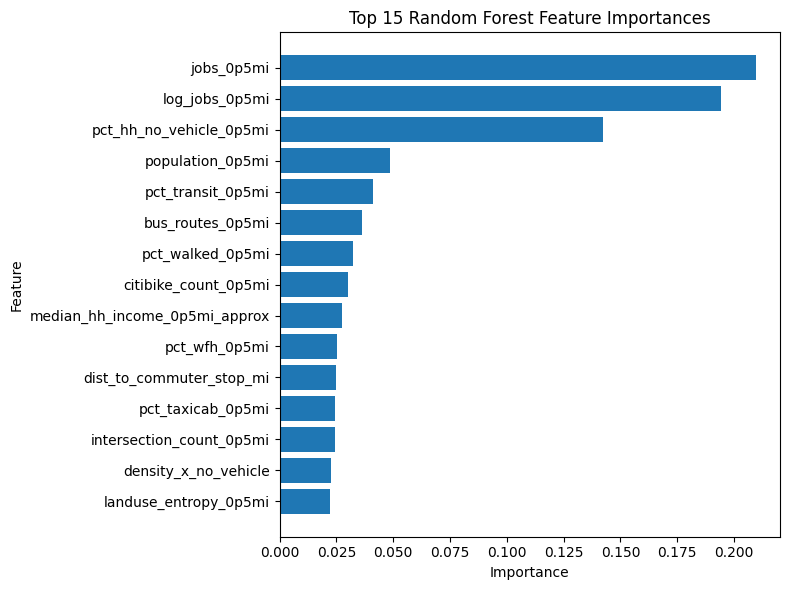


IBX predicted ridership (RF):
       station_complex_name station_complex_id borough  cluster  \
462                4 Avenue             IBX_18     NaN        0   
449           Myrtle Avenue              IBX_5     NaN        0   
445        Roosevelt Avenue              IBX_1     NaN        0   
461                8 Avenue             IBX_17     NaN        2   
451         Atlantic Avenue              IBX_7     NaN        2   
458          East 16 Street             IBX_14     NaN        2   
447            Eliot Avenue              IBX_3     NaN        2   
457       Flatbush–Nostrand             IBX_13     NaN        2   
446            Grand Avenue              IBX_2     NaN        2   
454             Linden Blvd             IBX_10     NaN        2   
453          Livonia Avenue              IBX_9     NaN        2   
459         McDonald Avenue             IBX_15     NaN        2   
448     Metropolitan Avenue              IBX_4     NaN        2   
460      New Utrecht Avenue    

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# ASSUMES THESE ALREADY EXIST FROM YOUR CURRENT SETUP:
# - train_df_v3
# - ibx_df_v3
# - features_available_v3
# =========================================================

# =========================================================
# 1. FEATURE ENGINEERING
# =========================================================
def engineer_features_rf(df):
    df = df.copy()

    for col in [
        "jobs_0p5mi",
        "population_0p5mi",
        "pop_density_0p5mi",
        "median_hh_income_0p5mi_approx"
    ]:
        if col in df.columns:
            df[f"log_{col}"] = np.log1p(df[col])

    if {"jobs_0p5mi", "pct_transit_0p5mi"}.issubset(df.columns):
        df["jobs_x_transit"] = df["jobs_0p5mi"] * df["pct_transit_0p5mi"]

    if {"pop_density_0p5mi", "pct_hh_no_vehicle_0p5mi"}.issubset(df.columns):
        df["density_x_no_vehicle"] = (
            df["pop_density_0p5mi"] * df["pct_hh_no_vehicle_0p5mi"]
        )

    if {"jobs_0p5mi", "bus_routes_0p5mi"}.issubset(df.columns):
        df["jobs_x_bus"] = df["jobs_0p5mi"] * df["bus_routes_0p5mi"]

    return df

train_df_rf = engineer_features_rf(train_df_v3.copy())
ibx_pred_df_rf = engineer_features_rf(ibx_df_v3.copy())

# =========================================================
# 2. DEFINE FEATURE SET
# =========================================================
engineered_features_rf = [
    "log_jobs_0p5mi",
    "log_population_0p5mi",
    "log_pop_density_0p5mi",
    "log_median_hh_income_0p5mi_approx",
    "jobs_x_transit",
    "density_x_no_vehicle",
    "jobs_x_bus"
]

features_model_rf = [
    col for col in (features_available_v3 + engineered_features_rf)
    if col in train_df_rf.columns and col in ibx_pred_df_rf.columns
]

# =========================================================
# 3. REMOVE HIGHLY CORRELATED FEATURES
# =========================================================
def remove_correlated_features(df, features, threshold=0.90):
    corr_matrix = df[features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return [f for f in features if f not in to_drop]

features_model_rf = remove_correlated_features(train_df_rf, features_model_rf, threshold=0.90)

print("Final number of RF features:", len(features_model_rf))

# =========================================================
# 4. CLEAN DATA
# =========================================================
train_df_rf = train_df_rf.dropna(subset=features_model_rf + ["log_avg_ridership"]).copy()
ibx_pred_df_rf = ibx_pred_df_rf.dropna(subset=features_model_rf).copy()

print("Training rows:", len(train_df_rf))
print("IBX rows:", len(ibx_df_v3))
print("IBX rows with complete features:", len(ibx_pred_df_rf))

# =========================================================
# 5. DEFINE X AND y
# =========================================================
X_rf = train_df_rf[features_model_rf].copy()
y_rf = train_df_rf["log_avg_ridership"].copy()

# Stratified split by ridership bins
y_bins_rf = pd.qcut(y_rf, q=5, labels=False, duplicates="drop")

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.20,
    stratify=y_bins_rf,
    random_state=42
)

print("\nTrain rows:", len(X_train_rf))
print("Test rows:", len(X_test_rf))

# =========================================================
# 6. RANDOMIZED SEARCH FOR RANDOM FOREST
# =========================================================
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist_rf = {
    "n_estimators": [200, 300, 500],
    "max_depth": [8, 12, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.8]
}

random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_rf.fit(X_train_rf, y_train_rf)

best_rf_model = random_search_rf.best_estimator_

print("\nBest RF parameters:")
print(random_search_rf.best_params_)

# =========================================================
# OPTIONAL: SMALLER GRID SEARCH ALTERNATIVE
# Uncomment this block if you want to use GridSearchCV instead
# =========================================================
# param_grid_rf = {
#     "n_estimators": [200, 300],
#     "max_depth": [8, 12, None],
#     "min_samples_split": [2, 5],
#     "min_samples_leaf": [1, 2],
#     "max_features": ["sqrt", 0.8]
# }
#
# grid_search_rf = GridSearchCV(
#     estimator=rf_base,
#     param_grid=param_grid_rf,
#     scoring="r2",
#     cv=5,
#     n_jobs=-1,
#     verbose=1
# )
#
# grid_search_rf.fit(X_train_rf, y_train_rf)
#
# best_rf_model = grid_search_rf.best_estimator_
#
# print("\nBest RF parameters:")
# print(grid_search_rf.best_params_)

# =========================================================
# 7. CROSS-VALIDATION
# =========================================================
cv_scores_rf = cross_val_score(
    best_rf_model,
    X_rf,
    y_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("\nRF Cross-validation R-squared scores:")
print(cv_scores_rf)
print(f"Mean CV R-squared: {cv_scores_rf.mean():.4f}")
print(f"Std CV R-squared:  {cv_scores_rf.std():.4f}")

# =========================================================
# 8. FIT FINAL MODEL
# =========================================================
best_rf_model.fit(X_train_rf, y_train_rf)

# =========================================================
# 9. EVALUATE MODEL
# =========================================================
y_pred_log_rf = best_rf_model.predict(X_test_rf)

r2_rf = r2_score(y_test_rf, y_pred_log_rf)
rmse_log_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_log_rf))
mae_log_rf = mean_absolute_error(y_test_rf, y_pred_log_rf)

print("\nRF Test set performance on log scale:")
print(f"R-squared: {r2_rf:.4f}")
print(f"RMSE (log): {rmse_log_rf:.4f}")
print(f"MAE  (log): {mae_log_rf:.4f}")

# Back-transform
y_test_orig_rf = np.exp(y_test_rf)
y_pred_orig_rf = np.exp(y_pred_log_rf)

rmse_orig_rf = np.sqrt(mean_squared_error(y_test_orig_rf, y_pred_orig_rf))
mae_orig_rf = mean_absolute_error(y_test_orig_rf, y_pred_orig_rf)

print("\nRF Approximate performance on original ridership scale:")
print(f"RMSE: {rmse_orig_rf:,.2f}")
print(f"MAE : {mae_orig_rf:,.2f}")

# =========================================================
# 10. FEATURE IMPORTANCE
# =========================================================
importance_df_rf = pd.DataFrame({
    "feature": features_model_rf,
    "importance": best_rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 RF feature importances:")
print(importance_df_rf.head(15))

plt.figure(figsize=(8, 6))
top_imp_rf = importance_df_rf.head(15).sort_values("importance")
plt.barh(top_imp_rf["feature"], top_imp_rf["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# =========================================================
# 11. PREDICT IBX RIDERSHIP
# =========================================================
X_ibx_rf = ibx_pred_df_rf[features_model_rf].copy()
ibx_pred_df_rf["pred_log_avg_ridership_rf"] = best_rf_model.predict(X_ibx_rf)
ibx_pred_df_rf["pred_avg_annual_ridership_rf"] = np.exp(
    ibx_pred_df_rf["pred_log_avg_ridership_rf"]
)

# Optional adjusted version
ibx_pred_df_rf["pred_avg_annual_ridership_adjusted_rf"] = (
    ibx_pred_df_rf["pred_avg_annual_ridership_rf"]
)

ibx_pred_df_rf.loc[
    ibx_pred_df_rf["cluster"] == 0,
    "pred_avg_annual_ridership_adjusted_rf"
] = ibx_pred_df_rf.loc[
    ibx_pred_df_rf["cluster"] == 0,
    "pred_avg_annual_ridership_rf"
] * 1.10

ibx_pred_df_rf.loc[
    ibx_pred_df_rf["cluster"] == 3,
    "pred_avg_annual_ridership_adjusted_rf"
] = ibx_pred_df_rf.loc[
    ibx_pred_df_rf["cluster"] == 3,
    "pred_avg_annual_ridership_rf"
] * 0.90

# =========================================================
# 12. FINAL OUTPUT TABLE
# =========================================================
ibx_results_rf = ibx_pred_df_rf[[
    "station_complex_name",
    "station_complex_id",
    "borough",
    "cluster",
    "pred_log_avg_ridership_rf",
    "pred_avg_annual_ridership_rf",
    "pred_avg_annual_ridership_adjusted_rf"
]].sort_values(["cluster", "station_complex_name"])

print("\nIBX predicted ridership (RF):")
print(ibx_results_rf)

# =========================================================
# 13. SAVE OUTPUTS
# =========================================================
importance_df_rf.to_csv("rf_feature_importance_gridsearch.csv", index=False)
ibx_results_rf.to_csv("ibx_ridership_predictions_rf_gridsearch.csv", index=False)

print("\nSaved files:")
print(" - rf_feature_importance_gridsearch.csv")
print(" - ibx_ridership_predictions_rf_gridsearch.csv")

# Regularized Linear Models: Lasso / Ridge / Elastic Net

**We include regularized linear models (Ridge, Lasso, and Elastic Net) as benchmark and interpretability tools alongside more complex machine learning approaches.** These models help address multicollinearity among predictors and reduce overfitting through penalization, while also providing clear, interpretable coefficients. In particular, Lasso enables feature selection by shrinking less important variables to zero, Ridge stabilizes coefficient estimates in the presence of correlated features, and Elastic Net balances both approaches. By comparing these models to tree-based methods, we can better understand the tradeoff between predictive performance and interpretability, and identify the key drivers of ridership in a more transparent way.


## Prepare Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# =========================================================
# ASSUMES THESE ALREADY EXIST:
# - train_df_v3
# - ibx_df_v3
# - features_available_v3
# =========================================================

# =========================================================
# 1. FEATURE ENGINEERING
# =========================================================
def engineer_features_linear(df):
    df = df.copy()

    for col in [
        "jobs_0p5mi",
        "population_0p5mi",
        "pop_density_0p5mi",
        "median_hh_income_0p5mi_approx"
    ]:
        if col in df.columns:
            df[f"log_{col}"] = np.log1p(df[col])

    if {"jobs_0p5mi", "pct_transit_0p5mi"}.issubset(df.columns):
        df["jobs_x_transit"] = df["jobs_0p5mi"] * df["pct_transit_0p5mi"]

    if {"pop_density_0p5mi", "pct_hh_no_vehicle_0p5mi"}.issubset(df.columns):
        df["density_x_no_vehicle"] = (
            df["pop_density_0p5mi"] * df["pct_hh_no_vehicle_0p5mi"]
        )

    if {"jobs_0p5mi", "bus_routes_0p5mi"}.issubset(df.columns):
        df["jobs_x_bus"] = df["jobs_0p5mi"] * df["bus_routes_0p5mi"]

    return df

train_df_lin = engineer_features_linear(train_df_v3.copy())
ibx_pred_df_lin = engineer_features_linear(ibx_df_v3.copy())

engineered_features_lin = [
    "log_jobs_0p5mi",
    "log_population_0p5mi",
    "log_pop_density_0p5mi",
    "log_median_hh_income_0p5mi_approx",
    "jobs_x_transit",
    "density_x_no_vehicle",
    "jobs_x_bus"
]

features_model_lin = [
    col for col in (features_available_v3 + engineered_features_lin)
    if col in train_df_lin.columns and col in ibx_pred_df_lin.columns
]

# =========================================================
# 2. REMOVE HIGHLY CORRELATED FEATURES
# =========================================================
def remove_correlated_features(df, features, threshold=0.90):
    corr_matrix = df[features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return [f for f in features if f not in to_drop]

features_model_lin = remove_correlated_features(
    train_df_lin,
    features_model_lin,
    threshold=0.90
)

print("Final number of linear-model features:", len(features_model_lin))

# =========================================================
# 3. CLEAN DATA
# =========================================================
train_df_lin = train_df_lin.dropna(subset=features_model_lin + ["log_avg_ridership"]).copy()
ibx_pred_df_lin = ibx_pred_df_lin.dropna(subset=features_model_lin).copy()

print("Training rows:", len(train_df_lin))
print("IBX rows:", len(ibx_df_v3))
print("IBX rows with complete features:", len(ibx_pred_df_lin))

# =========================================================
# 4. DEFINE X AND y
# =========================================================
X_lin = train_df_lin[features_model_lin].copy()
y_lin = train_df_lin["log_avg_ridership"].copy()

# Stratified split by ridership bins
y_bins_lin = pd.qcut(y_lin, q=5, labels=False, duplicates="drop")

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin,
    y_lin,
    test_size=0.20,
    stratify=y_bins_lin,
    random_state=42
)

print("\nTrain rows:", len(X_train_lin))
print("Test rows:", len(X_test_lin))

## Ridge Regression

In [ ]:
# =========================================================
# RIDGE REGRESSION
# =========================================================
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 50, 100, 200]
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

ridge_search.fit(X_train_lin, y_train_lin)

best_ridge_model = ridge_search.best_estimator_

print("\nBest Ridge parameters:")
print(ridge_search.best_params_)

# Cross-validation
cv_scores_ridge = cross_val_score(
    best_ridge_model,
    X_lin,
    y_lin,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("\nRidge CV R-squared scores:")
print(cv_scores_ridge)
print(f"Mean CV R-squared: {cv_scores_ridge.mean():.4f}")
print(f"Std CV R-squared:  {cv_scores_ridge.std():.4f}")

# Fit final model
best_ridge_model.fit(X_train_lin, y_train_lin)

# Evaluate
y_pred_log_ridge = best_ridge_model.predict(X_test_lin)

r2_ridge = r2_score(y_test_lin, y_pred_log_ridge)
rmse_log_ridge = np.sqrt(mean_squared_error(y_test_lin, y_pred_log_ridge))
mae_log_ridge = mean_absolute_error(y_test_lin, y_pred_log_ridge)

print("\nRidge test set performance on log scale:")
print(f"R-squared: {r2_ridge:.4f}")
print(f"RMSE (log): {rmse_log_ridge:.4f}")
print(f"MAE  (log): {mae_log_ridge:.4f}")

# Back-transform
y_test_orig_ridge = np.exp(y_test_lin)
y_pred_orig_ridge = np.exp(y_pred_log_ridge)

rmse_orig_ridge = np.sqrt(mean_squared_error(y_test_orig_ridge, y_pred_orig_ridge))
mae_orig_ridge = mean_absolute_error(y_test_orig_ridge, y_pred_orig_ridge)

print("\nRidge approximate performance on original ridership scale:")
print(f"RMSE: {rmse_orig_ridge:,.2f}")
print(f"MAE : {mae_orig_ridge:,.2f}")

# Coefficients
ridge_coefs = best_ridge_model.named_steps["model"].coef_
ridge_coef_df = pd.DataFrame({
    "feature": X_lin.columns,
    "coefficient": ridge_coefs,
    "abs_coefficient": np.abs(ridge_coefs)
}).sort_values("abs_coefficient", ascending=False)

print("\nTop 15 Ridge coefficients:")
print(ridge_coef_df.head(15))

# Plot
plt.figure(figsize=(8, 6))
top_ridge = ridge_coef_df.head(15).sort_values("coefficient")
plt.barh(top_ridge["feature"], top_ridge["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Ridge Coefficients")
plt.tight_layout()
plt.show()

# IBX predictions
X_ibx_ridge = ibx_pred_df_lin[features_model_lin].copy()
ibx_pred_df_ridge = ibx_pred_df_lin.copy()

ibx_pred_df_ridge["pred_log_avg_ridership_ridge"] = best_ridge_model.predict(X_ibx_ridge)
ibx_pred_df_ridge["pred_avg_annual_ridership_ridge"] = np.exp(
    ibx_pred_df_ridge["pred_log_avg_ridership_ridge"]
)

ibx_results_ridge = ibx_pred_df_ridge[[
    "station_complex_name",
    "station_complex_id",
    "borough",
    "cluster",
    "pred_log_avg_ridership_ridge",
    "pred_avg_annual_ridership_ridge"
]].sort_values(["cluster", "station_complex_name"])

print("\nIBX predicted ridership (Ridge):")
print(ibx_results_ridge)

# Save
ridge_coef_df.to_csv("ridge_coefficients.csv", index=False)
ibx_results_ridge.to_csv("ibx_ridership_predictions_ridge.csv", index=False)

print("\nSaved files:")
print(" - ridge_coefficients.csv")
print(" - ibx_ridership_predictions_ridge.csv")

## Lasso Regression

In [ ]:
# =========================================================
# LASSO REGRESSION
# =========================================================
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=20000))
])

lasso_param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
}

lasso_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

lasso_search.fit(X_train_lin, y_train_lin)

best_lasso_model = lasso_search.best_estimator_

print("\nBest Lasso parameters:")
print(lasso_search.best_params_)

# Cross-validation
cv_scores_lasso = cross_val_score(
    best_lasso_model,
    X_lin,
    y_lin,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("\nLasso CV R-squared scores:")
print(cv_scores_lasso)
print(f"Mean CV R-squared: {cv_scores_lasso.mean():.4f}")
print(f"Std CV R-squared:  {cv_scores_lasso.std():.4f}")

# Fit final model
best_lasso_model.fit(X_train_lin, y_train_lin)

# Evaluate
y_pred_log_lasso = best_lasso_model.predict(X_test_lin)

r2_lasso = r2_score(y_test_lin, y_pred_log_lasso)
rmse_log_lasso = np.sqrt(mean_squared_error(y_test_lin, y_pred_log_lasso))
mae_log_lasso = mean_absolute_error(y_test_lin, y_pred_log_lasso)

print("\nLasso test set performance on log scale:")
print(f"R-squared: {r2_lasso:.4f}")
print(f"RMSE (log): {rmse_log_lasso:.4f}")
print(f"MAE  (log): {mae_log_lasso:.4f}")

# Back-transform
y_test_orig_lasso = np.exp(y_test_lin)
y_pred_orig_lasso = np.exp(y_pred_log_lasso)

rmse_orig_lasso = np.sqrt(mean_squared_error(y_test_orig_lasso, y_pred_orig_lasso))
mae_orig_lasso = mean_absolute_error(y_test_orig_lasso, y_pred_orig_lasso)

print("\nLasso approximate performance on original ridership scale:")
print(f"RMSE: {rmse_orig_lasso:,.2f}")
print(f"MAE : {mae_orig_lasso:,.2f}")

# Coefficients
lasso_coefs = best_lasso_model.named_steps["model"].coef_
lasso_coef_df = pd.DataFrame({
    "feature": X_lin.columns,
    "coefficient": lasso_coefs,
    "abs_coefficient": np.abs(lasso_coefs)
}).sort_values("abs_coefficient", ascending=False)

print("\nTop 15 Lasso coefficients:")
print(lasso_coef_df.head(15))

print("\nNumber of non-zero Lasso coefficients:")
print((lasso_coef_df["coefficient"] != 0).sum())

# Plot
plt.figure(figsize=(8, 6))
top_lasso = lasso_coef_df.head(15).sort_values("coefficient")
plt.barh(top_lasso["feature"], top_lasso["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Lasso Coefficients")
plt.tight_layout()
plt.show()

# IBX predictions
X_ibx_lasso = ibx_pred_df_lin[features_model_lin].copy()
ibx_pred_df_lasso = ibx_pred_df_lin.copy()

ibx_pred_df_lasso["pred_log_avg_ridership_lasso"] = best_lasso_model.predict(X_ibx_lasso)
ibx_pred_df_lasso["pred_avg_annual_ridership_lasso"] = np.exp(
    ibx_pred_df_lasso["pred_log_avg_ridership_lasso"]
)

ibx_results_lasso = ibx_pred_df_lasso[[
    "station_complex_name",
    "station_complex_id",
    "borough",
    "cluster",
    "pred_log_avg_ridership_lasso",
    "pred_avg_annual_ridership_lasso"
]].sort_values(["cluster", "station_complex_name"])

print("\nIBX predicted ridership (Lasso):")
print(ibx_results_lasso)

# Save
lasso_coef_df.to_csv("lasso_coefficients.csv", index=False)
ibx_results_lasso.to_csv("ibx_ridership_predictions_lasso.csv", index=False)

print("\nSaved files:")
print(" - lasso_coefficients.csv")
print(" - ibx_ridership_predictions_lasso.csv")

## Elastic Net Regression

In [ ]:
# =========================================================
# ELASTIC NET REGRESSION
# =========================================================
enet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=20000))
])

enet_param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

enet_search = GridSearchCV(
    estimator=enet_pipeline,
    param_grid=enet_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

enet_search.fit(X_train_lin, y_train_lin)

best_enet_model = enet_search.best_estimator_

print("\nBest Elastic Net parameters:")
print(enet_search.best_params_)

# Cross-validation
cv_scores_enet = cross_val_score(
    best_enet_model,
    X_lin,
    y_lin,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("\nElastic Net CV R-squared scores:")
print(cv_scores_enet)
print(f"Mean CV R-squared: {cv_scores_enet.mean():.4f}")
print(f"Std CV R-squared:  {cv_scores_enet.std():.4f}")

# Fit final model
best_enet_model.fit(X_train_lin, y_train_lin)

# Evaluate
y_pred_log_enet = best_enet_model.predict(X_test_lin)

r2_enet = r2_score(y_test_lin, y_pred_log_enet)
rmse_log_enet = np.sqrt(mean_squared_error(y_test_lin, y_pred_log_enet))
mae_log_enet = mean_absolute_error(y_test_lin, y_pred_log_enet)

print("\nElastic Net test set performance on log scale:")
print(f"R-squared: {r2_enet:.4f}")
print(f"RMSE (log): {rmse_log_enet:.4f}")
print(f"MAE  (log): {mae_log_enet:.4f}")

# Back-transform
y_test_orig_enet = np.exp(y_test_lin)
y_pred_orig_enet = np.exp(y_pred_log_enet)

rmse_orig_enet = np.sqrt(mean_squared_error(y_test_orig_enet, y_pred_orig_enet))
mae_orig_enet = mean_absolute_error(y_test_orig_enet, y_pred_orig_enet)

print("\nElastic Net approximate performance on original ridership scale:")
print(f"RMSE: {rmse_orig_enet:,.2f}")
print(f"MAE : {mae_orig_enet:,.2f}")

# Coefficients
enet_coefs = best_enet_model.named_steps["model"].coef_
enet_coef_df = pd.DataFrame({
    "feature": X_lin.columns,
    "coefficient": enet_coefs,
    "abs_coefficient": np.abs(enet_coefs)
}).sort_values("abs_coefficient", ascending=False)

print("\nTop 15 Elastic Net coefficients:")
print(enet_coef_df.head(15))

print("\nNumber of non-zero Elastic Net coefficients:")
print((enet_coef_df["coefficient"] != 0).sum())

# Plot
plt.figure(figsize=(8, 6))
top_enet = enet_coef_df.head(15).sort_values("coefficient")
plt.barh(top_enet["feature"], top_enet["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Elastic Net Coefficients")
plt.tight_layout()
plt.show()

# IBX predictions
X_ibx_enet = ibx_pred_df_lin[features_model_lin].copy()
ibx_pred_df_enet = ibx_pred_df_lin.copy()

ibx_pred_df_enet["pred_log_avg_ridership_enet"] = best_enet_model.predict(X_ibx_enet)
ibx_pred_df_enet["pred_avg_annual_ridership_enet"] = np.exp(
    ibx_pred_df_enet["pred_log_avg_ridership_enet"]
)

ibx_results_enet = ibx_pred_df_enet[[
    "station_complex_name",
    "station_complex_id",
    "borough",
    "cluster",
    "pred_log_avg_ridership_enet",
    "pred_avg_annual_ridership_enet"
]].sort_values(["cluster", "station_complex_name"])

print("\nIBX predicted ridership (Elastic Net):")
print(ibx_results_enet)

# Save
enet_coef_df.to_csv("elastic_net_coefficients.csv", index=False)
ibx_results_enet.to_csv("ibx_ridership_predictions_elastic_net.csv", index=False)

print("\nSaved files:")
print(" - elastic_net_coefficients.csv")
print(" - ibx_ridership_predictions_elastic_net.csv")

## Comparison table across the three

In [ ]:
linear_model_comparison_df = pd.DataFrame([
    {
        "model": "Ridge",
        "cv_mean_r2": cv_scores_ridge.mean(),
        "cv_std_r2": cv_scores_ridge.std(),
        "test_r2_log": r2_ridge,
        "rmse_log": rmse_log_ridge,
        "mae_log": mae_log_ridge,
        "rmse_original": rmse_orig_ridge,
        "mae_original": mae_orig_ridge
    },
    {
        "model": "Lasso",
        "cv_mean_r2": cv_scores_lasso.mean(),
        "cv_std_r2": cv_scores_lasso.std(),
        "test_r2_log": r2_lasso,
        "rmse_log": rmse_log_lasso,
        "mae_log": mae_log_lasso,
        "rmse_original": rmse_orig_lasso,
        "mae_original": mae_orig_lasso
    },
    {
        "model": "Elastic Net",
        "cv_mean_r2": cv_scores_enet.mean(),
        "cv_std_r2": cv_scores_enet.std(),
        "test_r2_log": r2_enet,
        "rmse_log": rmse_log_enet,
        "mae_log": mae_log_enet,
        "rmse_original": rmse_orig_enet,
        "mae_original": mae_orig_enet
    }
]).sort_values(by="rmse_original", ascending=True)

print(linear_model_comparison_df)

linear_model_comparison_df.to_csv("linear_model_comparison.csv", index=False)
print("\nSaved: linear_model_comparison.csv")

# ## Generalized Linear Models: Poisson and Negative Binomial Regression for Ridership Prediction

Because annual ridership is nonnegative count data, Poisson and Negative Binomial GLMs were estimated as theoretically appropriate alternatives to tree-based machine learning models. Negative Binomial is especially suitable when ridership exhibits overdispersion.

## Prepare the Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# ASSUMES THESE ALREADY EXIST:
# - train_df_v3
# - ibx_df_v3
# - features_available_v3
# =========================================================

# =========================================================
# 1. FEATURE ENGINEERING
# =========================================================
def engineer_features_glm(df):
    df = df.copy()

    for col in [
        "jobs_0p5mi",
        "population_0p5mi",
        "pop_density_0p5mi",
        "median_hh_income_0p5mi_approx"
    ]:
        if col in df.columns:
            df[f"log_{col}"] = np.log1p(df[col])

    if {"jobs_0p5mi", "pct_transit_0p5mi"}.issubset(df.columns):
        df["jobs_x_transit"] = df["jobs_0p5mi"] * df["pct_transit_0p5mi"]

    if {"pop_density_0p5mi", "pct_hh_no_vehicle_0p5mi"}.issubset(df.columns):
        df["density_x_no_vehicle"] = (
            df["pop_density_0p5mi"] * df["pct_hh_no_vehicle_0p5mi"]
        )

    if {"jobs_0p5mi", "bus_routes_0p5mi"}.issubset(df.columns):
        df["jobs_x_bus"] = df["jobs_0p5mi"] * df["bus_routes_0p5mi"]

    return df

train_df_glm = engineer_features_glm(train_df_v3.copy())
ibx_pred_df_glm = engineer_features_glm(ibx_df_v3.copy())

engineered_features_glm = [
    "log_jobs_0p5mi",
    "log_population_0p5mi",
    "log_pop_density_0p5mi",
    "log_median_hh_income_0p5mi_approx",
    "jobs_x_transit",
    "density_x_no_vehicle",
    "jobs_x_bus"
]

features_model_glm = [
    col for col in (features_available_v3 + engineered_features_glm)
    if col in train_df_glm.columns and col in ibx_pred_df_glm.columns
]

# =========================================================
# 2. REMOVE HIGHLY CORRELATED FEATURES
# =========================================================
def remove_correlated_features(df, features, threshold=0.90):
    corr_matrix = df[features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return [f for f in features if f not in to_drop]

features_model_glm = remove_correlated_features(
    train_df_glm,
    features_model_glm,
    threshold=0.90
)

print("Final number of GLM features:", len(features_model_glm))

# =========================================================
# 3. CLEAN DATA
# =========================================================
# GLM count models should use original ridership, not log target
train_df_glm = train_df_glm.dropna(subset=features_model_glm + ["avg_annual_ridership"]).copy()
ibx_pred_df_glm = ibx_pred_df_glm.dropna(subset=features_model_glm).copy()

# Avoid zero or negative counts for log-link count models if needed
train_df_glm = train_df_glm[train_df_glm["avg_annual_ridership"] > 0].copy()

print("Training rows:", len(train_df_glm))
print("IBX rows:", len(ibx_df_v3))
print("IBX rows with complete features:", len(ibx_pred_df_glm))

# =========================================================
# 4. DEFINE X AND y
# =========================================================
X_glm = train_df_glm[features_model_glm].copy()
y_glm = train_df_glm["avg_annual_ridership"].copy()

# Stratified split by ridership bins
y_bins_glm = pd.qcut(y_glm, q=5, labels=False, duplicates="drop")

X_train_glm, X_test_glm, y_train_glm, y_test_glm = train_test_split(
    X_glm,
    y_glm,
    test_size=0.20,
    stratify=y_bins_glm,
    random_state=42
)

# Add intercept
X_train_glm_const = sm.add_constant(X_train_glm, has_constant="add")
X_test_glm_const = sm.add_constant(X_test_glm, has_constant="add")

print("\nTrain rows:", len(X_train_glm))
print("Test rows:", len(X_test_glm))

## Poisson Regression

In [ ]:
# =========================================================
# POISSON GLM
# =========================================================
poisson_model = sm.GLM(
    y_train_glm,
    X_train_glm_const,
    family=sm.families.Poisson()
)

poisson_results = poisson_model.fit()

print(poisson_results.summary())

# Predict on test set
y_pred_poisson = poisson_results.predict(X_test_glm_const)

# Clamp predictions to small positive values
y_pred_poisson = np.clip(y_pred_poisson, 1e-6, None)

# Evaluation
r2_poisson = r2_score(y_test_glm, y_pred_poisson)
rmse_poisson = np.sqrt(mean_squared_error(y_test_glm, y_pred_poisson))
mae_poisson = mean_absolute_error(y_test_glm, y_pred_poisson)

# Log-scale evaluation for comparison with your other models
y_test_log_poisson = np.log(y_test_glm)
y_pred_log_poisson = np.log(y_pred_poisson)

r2_log_poisson = r2_score(y_test_log_poisson, y_pred_log_poisson)
rmse_log_poisson = np.sqrt(mean_squared_error(y_test_log_poisson, y_pred_log_poisson))
mae_log_poisson = mean_absolute_error(y_test_log_poisson, y_pred_log_poisson)

print("\nPoisson test set performance on original scale:")
print(f"R-squared: {r2_poisson:.4f}")
print(f"RMSE: {rmse_poisson:,.2f}")
print(f"MAE : {mae_poisson:,.2f}")

print("\nPoisson approximate performance on log scale:")
print(f"R-squared (log): {r2_log_poisson:.4f}")
print(f"RMSE (log):      {rmse_log_poisson:.4f}")
print(f"MAE  (log):      {mae_log_poisson:.4f}")

# Coefficients
poisson_coef_df = pd.DataFrame({
    "feature": X_train_glm_const.columns,
    "coefficient": poisson_results.params.values,
    "abs_coefficient": np.abs(poisson_results.params.values),
    "p_value": poisson_results.pvalues.values
}).sort_values("abs_coefficient", ascending=False)

print("\nTop 15 Poisson coefficients:")
print(poisson_coef_df.head(15))

# Plot
plt.figure(figsize=(8, 6))
top_poisson = poisson_coef_df[poisson_coef_df["feature"] != "const"].head(15).sort_values("coefficient")
plt.barh(top_poisson["feature"], top_poisson["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Poisson GLM Coefficients")
plt.tight_layout()
plt.show()

# IBX predictions
X_ibx_poisson = ibx_pred_df_glm[features_model_glm].copy()
X_ibx_poisson_const = sm.add_constant(X_ibx_poisson, has_constant="add")

ibx_pred_df_poisson = ibx_pred_df_glm.copy()
ibx_pred_df_poisson["pred_avg_annual_ridership_poisson"] = poisson_results.predict(X_ibx_poisson_const)
ibx_pred_df_poisson["pred_log_avg_ridership_poisson"] = np.log(
    np.clip(ibx_pred_df_poisson["pred_avg_annual_ridership_poisson"], 1e-6, None)
)

ibx_results_poisson = ibx_pred_df_poisson[[
    "station_complex_name",
    "station_complex_id",
    "borough",
    "cluster",
    "pred_log_avg_ridership_poisson",
    "pred_avg_annual_ridership_poisson"
]].sort_values(["cluster", "station_complex_name"])

print("\nIBX predicted ridership (Poisson):")
print(ibx_results_poisson)

# Save
poisson_coef_df.to_csv("poisson_glm_coefficients.csv", index=False)
ibx_results_poisson.to_csv("ibx_ridership_predictions_poisson_glm.csv", index=False)

print("\nSaved files:")
print(" - poisson_glm_coefficients.csv")
print(" - ibx_ridership_predictions_poisson_glm.csv")

## Negative Binomial Regression

In [ ]:
# =========================================================
# NEGATIVE BINOMIAL GLM
# =========================================================
negbin_model = sm.GLM(
    y_train_glm,
    X_train_glm_const,
    family=sm.families.NegativeBinomial()
)

negbin_results = negbin_model.fit()

print(negbin_results.summary())

# Predict on test set
y_pred_negbin = negbin_results.predict(X_test_glm_const)

# Clamp predictions
y_pred_negbin = np.clip(y_pred_negbin, 1e-6, None)

# Evaluation
r2_negbin = r2_score(y_test_glm, y_pred_negbin)
rmse_negbin = np.sqrt(mean_squared_error(y_test_glm, y_pred_negbin))
mae_negbin = mean_absolute_error(y_test_glm, y_pred_negbin)

# Log-scale evaluation for comparison
y_test_log_negbin = np.log(y_test_glm)
y_pred_log_negbin = np.log(y_pred_negbin)

r2_log_negbin = r2_score(y_test_log_negbin, y_pred_log_negbin)
rmse_log_negbin = np.sqrt(mean_squared_error(y_test_log_negbin, y_pred_log_negbin))
mae_log_negbin = mean_absolute_error(y_test_log_negbin, y_pred_log_negbin)

print("\nNegative Binomial test set performance on original scale:")
print(f"R-squared: {r2_negbin:.4f}")
print(f"RMSE: {rmse_negbin:,.2f}")
print(f"MAE : {mae_negbin:,.2f}")

print("\nNegative Binomial approximate performance on log scale:")
print(f"R-squared (log): {r2_log_negbin:.4f}")
print(f"RMSE (log):      {rmse_log_negbin:.4f}")
print(f"MAE  (log):      {mae_log_negbin:.4f}")

# Coefficients
negbin_coef_df = pd.DataFrame({
    "feature": X_train_glm_const.columns,
    "coefficient": negbin_results.params.values,
    "abs_coefficient": np.abs(negbin_results.params.values),
    "p_value": negbin_results.pvalues.values
}).sort_values("abs_coefficient", ascending=False)

print("\nTop 15 Negative Binomial coefficients:")
print(negbin_coef_df.head(15))

# Plot
plt.figure(figsize=(8, 6))
top_negbin = negbin_coef_df[negbin_coef_df["feature"] != "const"].head(15).sort_values("coefficient")
plt.barh(top_negbin["feature"], top_negbin["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Negative Binomial GLM Coefficients")
plt.tight_layout()
plt.show()

# IBX predictions
X_ibx_negbin = ibx_pred_df_glm[features_model_glm].copy()
X_ibx_negbin_const = sm.add_constant(X_ibx_negbin, has_constant="add")

ibx_pred_df_negbin = ibx_pred_df_glm.copy()
ibx_pred_df_negbin["pred_avg_annual_ridership_negbin"] = negbin_results.predict(X_ibx_negbin_const)
ibx_pred_df_negbin["pred_log_avg_ridership_negbin"] = np.log(
    np.clip(ibx_pred_df_negbin["pred_avg_annual_ridership_negbin"], 1e-6, None)
)

ibx_results_negbin = ibx_pred_df_negbin[[
    "station_complex_name",
    "station_complex_id",
    "borough",
    "cluster",
    "pred_log_avg_ridership_negbin",
    "pred_avg_annual_ridership_negbin"
]].sort_values(["cluster", "station_complex_name"])

print("\nIBX predicted ridership (Negative Binomial):")
print(ibx_results_negbin)

# Save
negbin_coef_df.to_csv("negative_binomial_glm_coefficients.csv", index=False)
ibx_results_negbin.to_csv("ibx_ridership_predictions_negative_binomial_glm.csv", index=False)

print("\nSaved files:")
print(" - negative_binomial_glm_coefficients.csv")
print(" - ibx_ridership_predictions_negative_binomial_glm.csv")

## Optional overdispersion check

This helps justify Negative Binomial over Poisson.

In [ ]:
mean_ridership_glm = y_train_glm.mean()
var_ridership_glm = y_train_glm.var()

print("Mean ridership:", mean_ridership_glm)
print("Variance ridership:", var_ridership_glm)

if var_ridership_glm > mean_ridership_glm:
    print("Overdispersion detected: Negative Binomial is likely more appropriate than Poisson.")
else:
    print("Poisson may be adequate based on mean-variance comparison.")

## Comparison table

In [ ]:
glm_comparison_df = pd.DataFrame([
    {
        "model": "Poisson GLM",
        "test_r2_original": r2_poisson,
        "rmse_original": rmse_poisson,
        "mae_original": mae_poisson,
        "test_r2_log": r2_log_poisson,
        "rmse_log": rmse_log_poisson,
        "mae_log": mae_log_poisson
    },
    {
        "model": "Negative Binomial GLM",
        "test_r2_original": r2_negbin,
        "rmse_original": rmse_negbin,
        "mae_original": mae_negbin,
        "test_r2_log": r2_log_negbin,
        "rmse_log": rmse_log_negbin,
        "mae_log": mae_log_negbin
    }
]).sort_values(by="rmse_original", ascending=True)

print(glm_comparison_df)

glm_comparison_df.to_csv("glm_model_comparison.csv", index=False)
print("\nSaved: glm_model_comparison.csv")

## Advanced Modeling Extensions: Panel Data, Spatial Models, and Stacking Ensembles

In [ ]:
!pip install linearmodels

## Fixed Effects

A fixed effects panel model was estimated to control for unobserved station-specific differences and isolate within-station changes over time. This approach reduces bias from persistent structural differences, such as Manhattan versus non-Manhattan station characteristics, and provides stronger insight into how changes in local conditions relate to ridership.

In [ ]:
import pandas as pd
import numpy as np

from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# =========================================================
# ASSUMES YOU HAVE A PANEL DATAFRAME:
# panel_df
#
# REQUIRED COLUMNS:
# - station_complex_id
# - time_period   (year, month, or year-month)
# - ridership     (or avg_annual_ridership if repeated over time)
# - explanatory variables
# =========================================================

# Example feature list
panel_features = [
    "population_0p5mi",
    "pop_density_0p5mi",
    "jobs_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",
    "pct_transit_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi"
]

# Keep only available columns
panel_features = [f for f in panel_features if f in panel_df.columns]

# Optional log transforms
panel_df = panel_df.copy()
if "ridership" in panel_df.columns:
    panel_df = panel_df[panel_df["ridership"] > 0].copy()
    panel_df["log_ridership"] = np.log(panel_df["ridership"])

for col in ["jobs_0p5mi", "population_0p5mi", "pop_density_0p5mi", "median_hh_income_0p5mi_approx"]:
    if col in panel_df.columns:
        panel_df[f"log_{col}"] = np.log1p(panel_df[col])

engineered_panel_features = [
    "log_jobs_0p5mi",
    "log_population_0p5mi",
    "log_pop_density_0p5mi",
    "log_median_hh_income_0p5mi_approx"
]

panel_features_model = [f for f in (panel_features + engineered_panel_features) if f in panel_df.columns]

# Drop missing
panel_df_model = panel_df.dropna(subset=["station_complex_id", "time_period", "log_ridership"] + panel_features_model).copy()

# Set multi-index required by linearmodels
panel_df_model = panel_df_model.set_index(["station_complex_id", "time_period"])

# Define X and y
y_fe = panel_df_model["log_ridership"]
X_fe = panel_df_model[panel_features_model]
X_fe = sm.add_constant(X_fe)

# =========================================================
# FIXED EFFECTS MODEL
# entity_effects=True controls for station-specific differences
# time_effects=True controls for common time shocks
# =========================================================
fe_model = PanelOLS(
    y_fe,
    X_fe,
    entity_effects=True,
    time_effects=True,
    drop_absorbed=True
)

fe_results = fe_model.fit(cov_type="clustered", cluster_entity=True)

print(fe_results.summary)

# Optional coefficient table
fe_coef_df = pd.DataFrame({
    "feature": fe_results.params.index,
    "coefficient": fe_results.params.values
}).sort_values("coefficient", key=np.abs, ascending=False)

print("\nTop fixed effects coefficients:")
print(fe_coef_df.head(15))

## Spatial Modeling: Spatial Lag / Spatial Error

Spatial lag and spatial error models were estimated to account for the geographic dependence of transit ridership. Because nearby stations may influence one another through network connectivity, land use continuity, and shared travel markets, spatial econometric models provide a more realistic representation of urban transit systems than non-spatial models alone.

### 2A) Spatial Lag Model

In [ ]:
import pandas as pd
import numpy as np

from libpysal.weights import KNN
from spreg import ML_Lag

# =========================================================
# ASSUMES YOU HAVE:
# spatial_df with columns:
# - longitude
# - latitude
# - avg_annual_ridership
# - explanatory variables
# =========================================================

spatial_features = [
    "population_0p5mi",
    "pop_density_0p5mi",
    "jobs_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",
    "pct_transit_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi"
]

spatial_features = [f for f in spatial_features if f in spatial_df.columns]

spatial_df_model = spatial_df.dropna(
    subset=["longitude", "latitude", "avg_annual_ridership"] + spatial_features
).copy()

# Optional log transforms
spatial_df_model = spatial_df_model[spatial_df_model["avg_annual_ridership"] > 0].copy()
spatial_df_model["log_ridership"] = np.log(spatial_df_model["avg_annual_ridership"])

for col in ["jobs_0p5mi", "population_0p5mi", "pop_density_0p5mi"]:
    if col in spatial_df_model.columns:
        spatial_df_model[f"log_{col}"] = np.log1p(spatial_df_model[col])

engineered_spatial_features = [
    "log_jobs_0p5mi",
    "log_population_0p5mi",
    "log_pop_density_0p5mi"
]

spatial_features_model = [f for f in (spatial_features + engineered_spatial_features) if f in spatial_df_model.columns]

# y must be 2D array
y_spatial = spatial_df_model["log_ridership"].values.reshape((-1, 1))
X_spatial = spatial_df_model[spatial_features_model].values

# Build spatial weights matrix from nearest neighbors
coords = list(zip(spatial_df_model["longitude"], spatial_df_model["latitude"]))
w_knn = KNN.from_array(coords, k=5)
w_knn.transform = "r"

# Spatial Lag Model
slag_model = ML_Lag(
    y=y_spatial,
    x=X_spatial,
    w=w_knn,
    name_y="log_ridership",
    name_x=spatial_features_model
)

print(slag_model.summary)

### 2B) Spatial Error Model

In [ ]:
import pandas as pd
import numpy as np

from libpysal.weights import KNN
from spreg import ML_Error

# Reuse spatial_df_model, y_spatial, X_spatial, and w_knn if already created

serror_model = ML_Error(
    y=y_spatial,
    x=X_spatial,
    w=w_knn,
    name_y="log_ridership",
    name_x=spatial_features_model
)

print(serror_model.summary)

# Ensemble / Stacking Model

A stacking ensemble was estimated to combine the complementary strengths of tree-based and linear models. By integrating XGBoost, Random Forest, and Ridge regression within a single meta-learning framework, the stacked model aims to improve predictive performance beyond any individual model alone.

This combines:

XGBoost

Random Forest

Linear model

This is a strong “best of all worlds” approach.

You may use:

Ridge as the linear component

Ridge again as the meta-learner

In [ ]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

# =========================================================
# ASSUMES:
# - train_df_v3
# - ibx_df_v3
# - features_available_v3
# =========================================================

def engineer_features_stack(df):
    df = df.copy()

    for col in [
        "jobs_0p5mi",
        "population_0p5mi",
        "pop_density_0p5mi",
        "median_hh_income_0p5mi_approx"
    ]:
        if col in df.columns:
            df[f"log_{col}"] = np.log1p(df[col])

    if {"jobs_0p5mi", "pct_transit_0p5mi"}.issubset(df.columns):
        df["jobs_x_transit"] = df["jobs_0p5mi"] * df["pct_transit_0p5mi"]

    if {"pop_density_0p5mi", "pct_hh_no_vehicle_0p5mi"}.issubset(df.columns):
        df["density_x_no_vehicle"] = df["pop_density_0p5mi"] * df["pct_hh_no_vehicle_0p5mi"]

    if {"jobs_0p5mi", "bus_routes_0p5mi"}.issubset(df.columns):
        df["jobs_x_bus"] = df["jobs_0p5mi"] * df["bus_routes_0p5mi"]

    return df

train_df_stack = engineer_features_stack(train_df_v3.copy())
ibx_df_stack = engineer_features_stack(ibx_df_v3.copy())

engineered_features_stack = [
    "log_jobs_0p5mi",
    "log_population_0p5mi",
    "log_pop_density_0p5mi",
    "log_median_hh_income_0p5mi_approx",
    "jobs_x_transit",
    "density_x_no_vehicle",
    "jobs_x_bus"
]

features_model_stack = [
    col for col in (features_available_v3 + engineered_features_stack)
    if col in train_df_stack.columns and col in ibx_df_stack.columns
]

train_df_stack = train_df_stack.dropna(subset=features_model_stack + ["log_avg_ridership"]).copy()
ibx_df_stack = ibx_df_stack.dropna(subset=features_model_stack).copy()

X_stack = train_df_stack[features_model_stack].copy()
y_stack = train_df_stack["log_avg_ridership"].copy()

X_train_stack, X_test_stack, y_train_stack, y_test_stack = train_test_split(
    X_stack,
    y_stack,
    test_size=0.20,
    random_state=42
)

# Base learners
xgb_base_stack = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    objective="reg:squarederror",
    random_state=42
)

rf_base_stack = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

ridge_base_stack = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10))
])

# Meta learner
meta_model_stack = Ridge(alpha=1.0)

stack_model = StackingRegressor(
    estimators=[
        ("xgb", xgb_base_stack),
        ("rf", rf_base_stack),
        ("ridge", ridge_base_stack)
    ],
    final_estimator=meta_model_stack,
    passthrough=False,
    n_jobs=-1
)

# Cross-validation
cv_scores_stack = cross_val_score(
    stack_model,
    X_stack,
    y_stack,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Stacking CV R-squared scores:")
print(cv_scores_stack)
print(f"Mean CV R-squared: {cv_scores_stack.mean():.4f}")
print(f"Std CV R-squared:  {cv_scores_stack.std():.4f}")

# Fit final model
stack_model.fit(X_train_stack, y_train_stack)

# Evaluate
y_pred_log_stack = stack_model.predict(X_test_stack)

r2_stack = r2_score(y_test_stack, y_pred_log_stack)
rmse_log_stack = np.sqrt(mean_squared_error(y_test_stack, y_pred_log_stack))
mae_log_stack = mean_absolute_error(y_test_stack, y_pred_log_stack)

y_test_orig_stack = np.exp(y_test_stack)
y_pred_orig_stack = np.exp(y_pred_log_stack)

rmse_orig_stack = np.sqrt(mean_squared_error(y_test_orig_stack, y_pred_orig_stack))
mae_orig_stack = mean_absolute_error(y_test_orig_stack, y_pred_orig_stack)

print("\nStacking model performance:")
print(f"R-squared: {r2_stack:.4f}")
print(f"RMSE (log): {rmse_log_stack:.4f}")
print(f"MAE  (log): {mae_log_stack:.4f}")
print(f"RMSE (orig): {rmse_orig_stack:,.2f}")
print(f"MAE  (orig): {mae_orig_stack:,.2f}")

# IBX predictions
X_ibx_stack = ibx_df_stack[features_model_stack].copy()
ibx_df_stack["pred_log_avg_ridership_stack"] = stack_model.predict(X_ibx_stack)
ibx_df_stack["pred_avg_annual_ridership_stack"] = np.exp(
    ibx_df_stack["pred_log_avg_ridership_stack"]
)

ibx_results_stack = ibx_df_stack[[
    "station_complex_name",
    "station_complex_id",
    "borough",
    "cluster",
    "pred_log_avg_ridership_stack",
    "pred_avg_annual_ridership_stack"
]].sort_values(["cluster", "station_complex_name"])

print("\nIBX predicted ridership (Stacking):")
print(ibx_results_stack)

ibx_results_stack.to_csv("ibx_ridership_predictions_stacking.csv", index=False)
print("\nSaved: ibx_ridership_predictions_stacking.csv")

import pandas as pd
import numpy as np
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import statsmodels.api as sm

warnings.filterwarnings("ignore")

# =========================================================
# ASSUMES THESE ALREADY EXIST:
# - train_df_v3
# - ibx_df_v3
# - features_available_v3
# =========================================================

# =========================================================
# 1. FEATURE ENGINEERING
# =========================================================
def engineer_features_all_models(df):
    df = df.copy()

    for col in [
        "jobs_0p5mi",
        "population_0p5mi",
        "pop_density_0p5mi",
        "median_hh_income_0p5mi_approx"
    ]:
        if col in df.columns:
            df[f"log_{col}"] = np.log1p(df[col])

    if {"jobs_0p5mi", "pct_transit_0p5mi"}.issubset(df.columns):
        df["jobs_x_transit"] = df["jobs_0p5mi"] * df["pct_transit_0p5mi"]

    if {"pop_density_0p5mi", "pct_hh_no_vehicle_0p5mi"}.issubset(df.columns):
        df["density_x_no_vehicle"] = (
            df["pop_density_0p5mi"] * df["pct_hh_no_vehicle_0p5mi"]
        )

    if {"jobs_0p5mi", "bus_routes_0p5mi"}.issubset(df.columns):
        df["jobs_x_bus"] = df["jobs_0p5mi"] * df["bus_routes_0p5mi"]

    return df

# =========================================================
# 2. REMOVE HIGHLY CORRELATED FEATURES
# =========================================================
def remove_correlated_features(df, features, threshold=0.90):
    corr_matrix = df[features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return [f for f in features if f not in to_drop]

# =========================================================
# 3. PREP SHARED DATA
# =========================================================
train_df_all_models = engineer_features_all_models(train_df_v3.copy())
ibx_df_all_models = engineer_features_all_models(ibx_df_v3.copy())

engineered_features_all_models = [
    "log_jobs_0p5mi",
    "log_population_0p5mi",
    "log_pop_density_0p5mi",
    "log_median_hh_income_0p5mi_approx",
    "jobs_x_transit",
    "density_x_no_vehicle",
    "jobs_x_bus"
]

features_model_all = [
    col for col in (features_available_v3 + engineered_features_all_models)
    if col in train_df_all_models.columns and col in ibx_df_all_models.columns
]

features_model_all = remove_correlated_features(
    train_df_all_models,
    features_model_all,
    threshold=0.90
)

print("Final number of shared features:", len(features_model_all))

# For ML and linear models using log target
train_df_ml = train_df_all_models.dropna(
    subset=features_model_all + ["log_avg_ridership"]
).copy()

ibx_df_ml = ibx_df_all_models.dropna(
    subset=features_model_all
).copy()

# For GLM using original count target
train_df_glm_all = train_df_all_models.dropna(
    subset=features_model_all + ["avg_annual_ridership"]
).copy()

train_df_glm_all = train_df_glm_all[train_df_glm_all["avg_annual_ridership"] > 0].copy()

print("Training rows (ML/log target):", len(train_df_ml))
print("Training rows (GLM/count target):", len(train_df_glm_all))
print("IBX rows with complete features:", len(ibx_df_ml))

# Shared X/y for ML models
X_all = train_df_ml[features_model_all].copy()
y_all = train_df_ml["log_avg_ridership"].copy()

y_bins_all = pd.qcut(y_all, q=5, labels=False, duplicates="drop")

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    stratify=y_bins_all,
    random_state=42
)

X_ibx_all = ibx_df_ml[features_model_all].copy()

print("\nTrain rows:", len(X_train_all))
print("Test rows:", len(X_test_all))

# =========================================================
# 4. EVALUATION HELPERS
# =========================================================
def evaluate_log_model(model_name, fitted_model, X_test, y_test):
    y_pred_log = fitted_model.predict(X_test)

    r2_log = r2_score(y_test, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    mae_log = mean_absolute_error(y_test, y_pred_log)

    y_test_orig = np.exp(y_test)
    y_pred_orig = np.exp(y_pred_log)

    rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)

    return {
        "model": model_name,
        "test_r2_log": r2_log,
        "rmse_log": rmse_log,
        "mae_log": mae_log,
        "rmse_original": rmse_orig,
        "mae_original": mae_orig
    }

def evaluate_count_model(model_name, y_test_orig, y_pred_orig):
    y_pred_orig = np.clip(np.array(y_pred_orig), 1e-6, None)
    y_test_orig = np.array(y_test_orig)

    r2_orig = r2_score(y_test_orig, y_pred_orig)
    rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)

    y_test_log = np.log(y_test_orig)
    y_pred_log = np.log(y_pred_orig)

    r2_log = r2_score(y_test_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
    mae_log = mean_absolute_error(y_test_log, y_pred_log)

    return {
        "model": model_name,
        "test_r2_log": r2_log,
        "rmse_log": rmse_log,
        "mae_log": mae_log,
        "rmse_original": rmse_orig,
        "mae_original": mae_orig,
        "test_r2_original": r2_orig
    }

results_summary = []
ibx_predictions_summary = pd.DataFrame({
    "station_complex_name": ibx_df_ml["station_complex_name"].values,
    "station_complex_id": ibx_df_ml["station_complex_id"].values,
    "borough": ibx_df_ml["borough"].values,
    "cluster": ibx_df_ml["cluster"].values
})

# =========================================================
# 5. XGBOOST
# =========================================================
xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

xgb_param_dist = {
    "n_estimators": [300, 500, 700],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_alpha": [0, 0.5, 1],
    "reg_lambda": [1, 2, 3]
}

xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train_all, y_train_all)
best_xgb = xgb_search.best_estimator_

cv_scores_xgb = cross_val_score(best_xgb, X_all, y_all, cv=5, scoring="r2", n_jobs=-1)
best_xgb.fit(X_train_all, y_train_all)

xgb_metrics = evaluate_log_model("XGBoost", best_xgb, X_test_all, y_test_all)
xgb_metrics["cv_mean_r2"] = cv_scores_xgb.mean()
xgb_metrics["cv_std_r2"] = cv_scores_xgb.std()
results_summary.append(xgb_metrics)

ibx_predictions_summary["pred_xgboost"] = np.exp(best_xgb.predict(X_ibx_all))

# =========================================================
# 6. RANDOM FOREST
# =========================================================
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [None, 8, 12],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.8]
}

rf_search = GridSearchCV(
    rf_base,
    param_grid=rf_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train_all, y_train_all)
best_rf = rf_search.best_estimator_

cv_scores_rf = cross_val_score(best_rf, X_all, y_all, cv=5, scoring="r2", n_jobs=-1)
best_rf.fit(X_train_all, y_train_all)

rf_metrics = evaluate_log_model("Random Forest", best_rf, X_test_all, y_test_all)
rf_metrics["cv_mean_r2"] = cv_scores_rf.mean()
rf_metrics["cv_std_r2"] = cv_scores_rf.std()
results_summary.append(rf_metrics)

ibx_predictions_summary["pred_random_forest"] = np.exp(best_rf.predict(X_ibx_all))

# =========================================================
# 7. RIDGE
# =========================================================
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 50, 100]
}

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid=ridge_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)
ridge_search.fit(X_train_all, y_train_all)
best_ridge = ridge_search.best_estimator_

cv_scores_ridge = cross_val_score(best_ridge, X_all, y_all, cv=5, scoring="r2", n_jobs=-1)
best_ridge.fit(X_train_all, y_train_all)

ridge_metrics = evaluate_log_model("Ridge", best_ridge, X_test_all, y_test_all)
ridge_metrics["cv_mean_r2"] = cv_scores_ridge.mean()
ridge_metrics["cv_std_r2"] = cv_scores_ridge.std()
results_summary.append(ridge_metrics)

ibx_predictions_summary["pred_ridge"] = np.exp(best_ridge.predict(X_ibx_all))

# =========================================================
# 8. LASSO
# =========================================================
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=20000))
])

lasso_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5]
}

lasso_search = GridSearchCV(
    lasso_pipeline,
    param_grid=lasso_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)
lasso_search.fit(X_train_all, y_train_all)
best_lasso = lasso_search.best_estimator_

cv_scores_lasso = cross_val_score(best_lasso, X_all, y_all, cv=5, scoring="r2", n_jobs=-1)
best_lasso.fit(X_train_all, y_train_all)

lasso_metrics = evaluate_log_model("Lasso", best_lasso, X_test_all, y_test_all)
lasso_metrics["cv_mean_r2"] = cv_scores_lasso.mean()
lasso_metrics["cv_std_r2"] = cv_scores_lasso.std()
results_summary.append(lasso_metrics)

ibx_predictions_summary["pred_lasso"] = np.exp(best_lasso.predict(X_ibx_all))

# =========================================================
# 9. ELASTIC NET
# =========================================================
enet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=20000))
])

enet_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

enet_search = GridSearchCV(
    enet_pipeline,
    param_grid=enet_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)
enet_search.fit(X_train_all, y_train_all)
best_enet = enet_search.best_estimator_

cv_scores_enet = cross_val_score(best_enet, X_all, y_all, cv=5, scoring="r2", n_jobs=-1)
best_enet.fit(X_train_all, y_train_all)

enet_metrics = evaluate_log_model("Elastic Net", best_enet, X_test_all, y_test_all)
enet_metrics["cv_mean_r2"] = cv_scores_enet.mean()
enet_metrics["cv_std_r2"] = cv_scores_enet.std()
results_summary.append(enet_metrics)

ibx_predictions_summary["pred_elastic_net"] = np.exp(best_enet.predict(X_ibx_all))

# =========================================================
# 10. LIGHTGBM
# =========================================================
lgbm_base = LGBMRegressor(
    objective="regression",
    random_state=42,
    verbose=-1
)

lgbm_param_dist = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05],
    "max_depth": [-1, 3, 4, 5],
    "num_leaves": [15, 31, 50],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8],
    "min_child_samples": [5, 10, 20],
    "reg_alpha": [0, 0.1, 0.5],
    "reg_lambda": [0, 0.5, 1.0]
}

lgbm_search = RandomizedSearchCV(
    lgbm_base,
    param_distributions=lgbm_param_dist,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
lgbm_search.fit(X_train_all, y_train_all)
best_lgbm = lgbm_search.best_estimator_

cv_scores_lgbm = cross_val_score(best_lgbm, X_all, y_all, cv=5, scoring="r2", n_jobs=-1)
best_lgbm.fit(X_train_all, y_train_all)

lgbm_metrics = evaluate_log_model("LightGBM", best_lgbm, X_test_all, y_test_all)
lgbm_metrics["cv_mean_r2"] = cv_scores_lgbm.mean()
lgbm_metrics["cv_std_r2"] = cv_scores_lgbm.std()
results_summary.append(lgbm_metrics)

ibx_predictions_summary["pred_lightgbm"] = np.exp(best_lgbm.predict(X_ibx_all))

# =========================================================
# 11. CATBOOST
# =========================================================
cat_base = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

cat_param_dist = {
    "iterations": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05],
    "depth": [3, 4, 5, 6],
    "l2_leaf_reg": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

cat_search = RandomizedSearchCV(
    cat_base,
    param_distributions=cat_param_dist,
    n_iter=15,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
cat_search.fit(X_train_all, y_train_all)
best_cat = cat_search.best_estimator_

cv_scores_cat = cross_val_score(best_cat, X_all, y_all, cv=5, scoring="r2", n_jobs=-1)
best_cat.fit(X_train_all, y_train_all)

cat_metrics = evaluate_log_model("CatBoost", best_cat, X_test_all, y_test_all)
cat_metrics["cv_mean_r2"] = cv_scores_cat.mean()
cat_metrics["cv_std_r2"] = cv_scores_cat.std()
results_summary.append(cat_metrics)

ibx_predictions_summary["pred_catboost"] = np.exp(best_cat.predict(X_ibx_all))

# =========================================================
# 12. POISSON GLM
# =========================================================
X_glm_all = train_df_glm_all[features_model_all].copy()
y_glm_all = train_df_glm_all["avg_annual_ridership"].copy()

y_bins_glm_all = pd.qcut(y_glm_all, q=5, labels=False, duplicates="drop")

X_train_glm_all, X_test_glm_all, y_train_glm_all, y_test_glm_all = train_test_split(
    X_glm_all,
    y_glm_all,
    test_size=0.20,
    stratify=y_bins_glm_all,
    random_state=42
)

X_train_glm_const = sm.add_constant(X_train_glm_all, has_constant="add")
X_test_glm_const = sm.add_constant(X_test_glm_all, has_constant="add")
X_glm_const = sm.add_constant(X_glm_all, has_constant="add")

poisson_model = sm.GLM(
    y_train_glm_all,
    X_train_glm_const,
    family=sm.families.Poisson()
)
poisson_results = poisson_model.fit()

y_pred_poisson = poisson_results.predict(X_test_glm_const)
poisson_metrics = evaluate_count_model("Poisson GLM", y_test_glm_all, y_pred_poisson)
poisson_metrics["cv_mean_r2"] = np.nan
poisson_metrics["cv_std_r2"] = np.nan
results_summary.append(poisson_metrics)

X_ibx_glm_const = sm.add_constant(ibx_df_ml[features_model_all], has_constant="add")
ibx_predictions_summary["pred_poisson_glm"] = poisson_results.predict(X_ibx_glm_const)

# =========================================================
# 13. NEGATIVE BINOMIAL GLM
# =========================================================
negbin_model = sm.GLM(
    y_train_glm_all,
    X_train_glm_const,
    family=sm.families.NegativeBinomial()
)
negbin_results = negbin_model.fit()

y_pred_negbin = negbin_results.predict(X_test_glm_const)
negbin_metrics = evaluate_count_model("Negative Binomial GLM", y_test_glm_all, y_pred_negbin)
negbin_metrics["cv_mean_r2"] = np.nan
negbin_metrics["cv_std_r2"] = np.nan
results_summary.append(negbin_metrics)

ibx_predictions_summary["pred_negative_binomial_glm"] = negbin_results.predict(X_ibx_glm_const)

# =========================================================
# 14. STACKING
# =========================================================
xgb_base_stack = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    objective="reg:squarederror",
    random_state=42
)

rf_base_stack = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

ridge_base_stack = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10))
])

meta_model_stack = Ridge(alpha=1.0)

stack_model = StackingRegressor(
    estimators=[
        ("xgb", xgb_base_stack),
        ("rf", rf_base_stack),
        ("ridge", ridge_base_stack)
    ],
    final_estimator=meta_model_stack,
    passthrough=False,
    n_jobs=-1
)

cv_scores_stack = cross_val_score(
    stack_model,
    X_all,
    y_all,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

stack_model.fit(X_train_all, y_train_all)

stack_metrics = evaluate_log_model("Stacking Ensemble", stack_model, X_test_all, y_test_all)
stack_metrics["cv_mean_r2"] = cv_scores_stack.mean()
stack_metrics["cv_std_r2"] = cv_scores_stack.std()
results_summary.append(stack_metrics)

ibx_predictions_summary["pred_stacking"] = np.exp(stack_model.predict(X_ibx_all))

# =========================================================
# 15. FINAL COMPARISON TABLE
# =========================================================
all_model_comparison_df = pd.DataFrame(results_summary)

preferred_cols = [
    "model",
    "cv_mean_r2",
    "cv_std_r2",
    "test_r2_log",
    "rmse_log",
    "mae_log",
    "rmse_original",
    "mae_original"
]

extra_cols = [c for c in all_model_comparison_df.columns if c not in preferred_cols]
all_model_comparison_df = all_model_comparison_df[preferred_cols + extra_cols]

all_model_comparison_df = all_model_comparison_df.sort_values(
    by=["rmse_original", "mae_original"],
    ascending=[True, True]
).reset_index(drop=True)

print("\nCombined model comparison:")
print(all_model_comparison_df)

print("\nBest models by lowest original-scale RMSE:")
print(all_model_comparison_df[["model", "rmse_original", "mae_original", "test_r2_log"]].head(10))

# =========================================================
# 16. SAVE OUTPUTS
# =========================================================
all_model_comparison_df.to_csv("all_models_comparison_table.csv", index=False)
ibx_predictions_summary.to_csv("ibx_predictions_all_models.csv", index=False)

print("\nSaved files:")
print(" - all_models_comparison_table.csv")
print(" - ibx_predictions_all_models.csv")

## Multiple Linear Regression

### **Built Environment Similarity of IBX Stations to Existing Subway Stations**

Based on the **t-SNE cluster plot, borough-colored plot, and IBX overlay**, the IBX stations are **most similar to Brooklyn and Queens stations**.

### Evidence from the plots

**1. IBX overlay (red points)**
Most IBX stations appear in the **left and center-left regions** of the t-SNE space.

**2. Borough-colored t-SNE plot**
Those same regions are dominated by:

* **Brooklyn (green)**
* **Queens (gray)**

There are also a few nearby **Bronx (blue)** points, but fewer than Brooklyn/Queens.

**3. Cluster plot**
Most IBX stations fall in **Cluster 2**, which corresponds to the **moderate-density outer-borough station environments**—again largely Brooklyn and Queens.

### Interpretation

IBX stations resemble environments with:

* moderate residential density
* mixed residential–commercial land use
* strong bus connections
* moderate subway accessibility

These characteristics are typical of **Brooklyn and Queens subway corridors**, not the very high-intensity station environments in Manhattan.

### Concise conclusion

**IBX stations are most similar to Brooklyn and Queens stations, with some similarity to Bronx stations and little similarity to Manhattan stations.**

### Sentence suitable for your paper

> The t-SNE embedding shows that IBX stations cluster primarily within regions dominated by Brooklyn and Queens stations, indicating that the built environment characteristics of the IBX corridor most closely resemble moderate-density outer-borough transit environments rather than the high-intensity station environments typical of Manhattan.


## Hierarchical Clustering of Subway Stations Based on Built Environment Characteristics



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Load features file directly
df = pd.read_csv("https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv")

# Keep station_complex_id as string so IBX IDs are preserved
df["station_complex_id"] = df["station_complex_id"].astype(str)

# Drop ridership columns if they happen to exist
df = df.drop(columns=[
    "annual_weekday_avg_ridership",
    "log_ridership"
], errors="ignore")

# Features describing station environment
features = [
    "buffer_area_sqmi",
    "population_0p5mi",
    "pop_density_0p5mi",

    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",

    "jobs_0p5mi",

    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    "citibike_count_0p5mi",

    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi_approx",

    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",

    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
]

# Keep only rows with complete feature data
data = df[features].dropna().copy()

# Match original rows used in clustering
df_plot = df.loc[data.index].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# Hierarchical clustering
Z = linkage(X_scaled, method="ward")

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    truncate_mode="level",
    p=5
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Stations / Cluster Groups")
plt.ylabel("Distance")
plt.show()

### Interpretation of the Hierarchical Clustering Dendrogram

The dendrogram illustrates how subway stations group together based on similarities in their surrounding built environment and accessibility characteristics.

#### 1. Two broad station environment types

The dendrogram splits into **two major branches at a high linkage distance (~85)**, indicating that the dataset contains **two fundamentally different types of station environments**. Consistent with the **PCA and t-SNE visualizations**, this separation likely reflects a distinction between:

* **High-intensity urban stations**, characterized by high employment density, extensive multimodal connectivity, and mixed land uses, which are most common in Manhattan and major transit hubs.
* **Moderate- to lower-density stations**, typically located in outer-borough neighborhoods with lower employment density, fewer transit connections, and more residential land uses.

This large separation suggests that the built-environment characteristics surrounding subway stations vary substantially across the system.

#### 2. Subclusters within each major group

Within these two major branches, the dendrogram reveals several **smaller clusters forming at lower linkage distances (approximately 10–30)**. These clusters represent **more nuanced station typologies**, such as:

* moderate-density neighborhood stations
* mixed-use residential–commercial corridors
* major regional transit hubs
* peripheral or lower-density stations

Stations that merge at **very small linkage distances** share highly similar built-environment characteristics.

#### 3. Consistency with PCA, t-SNE, and K-means results

The hierarchical clustering results are consistent with the **four-cluster structure identified using K-means**, as well as the **distinct spatial groupings observed in the PCA and t-SNE embeddings**. Both dimensionality-reduction techniques reveal clear separations among groups of stations with similar built-environment profiles, suggesting that the clustering structure identified in the dendrogram reflects meaningful differences in station environments.

#### 4. Implications for IBX station environments

The PCA and t-SNE analyses show that **IBX stations tend to occupy regions of the feature space associated with moderate-density outer-borough stations**, rather than the high-intensity cluster dominated by Manhattan stations. This suggests that the built environments surrounding IBX stations are most similar to those found along existing **Brooklyn and Queens subway corridors**, with some similarity to stations in the Bronx.

---

### Concise sentence for the paper

> The hierarchical clustering dendrogram reveals two broad station environment types with several nested subclusters, consistent with the groupings observed in the PCA and t-SNE analyses. Together, these results indicate that subway stations can be organized into distinct built-environment typologies, with IBX stations most closely resembling moderate-density outer-borough station environments rather than high-intensity Manhattan stations.



# **Supervised Machine Learning Modeling**

## Random Forest Ridership Model

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(
"https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_model_dataset.csv"
)

df["station_complex_id"] = df["station_complex_id"].astype(str)

# =========================================================
# TARGET VARIABLE
# =========================================================
df["log_ridership"] = np.log1p(df["ridership"])

# =========================================================
# DROP UNUSED VARIABLES
# =========================================================
df = df.drop(columns=[

    # identifiers
    "station_complex",
    "station_complex_name",
    "geometry",
    "latitude",
    "longitude",

    # duplicate socioeconomic fields
    "median_hh_income_0p5mi_approx",
    "pct_workers_wfh_0p5mi"

], errors="ignore")

# =========================================================
# INDEPENDENT VARIABLES
# =========================================================
features = [

# ---------------------------------------------------------
# DEMOGRAPHICS / DENSITY
# ---------------------------------------------------------
"population_0p5mi",
"pop_density_0p5mi",

# ---------------------------------------------------------
# LAND USE MIX
# ---------------------------------------------------------
"landuse_entropy_0p5mi",
"landuse_entropy_relative_0p5mi",
"landuse_simpson_0p5mi",
"landuse_k_categories_0p5mi",

# ---------------------------------------------------------
# EMPLOYMENT
# ---------------------------------------------------------
"jobs_0p5mi",

# ---------------------------------------------------------
# STREET NETWORK / WALKABILITY
# ---------------------------------------------------------
"intersection_count_0p5mi",
"intersection_density_0p5mi",

# ---------------------------------------------------------
# BIKE ACCESS
# ---------------------------------------------------------
"citibike_count_0p5mi",

# ---------------------------------------------------------
# SOCIOECONOMIC / TRANSIT DEPENDENCY
# ---------------------------------------------------------
"pct_hh_no_vehicle_0p5mi",
"median_hh_income_0p5mi",

# ---------------------------------------------------------
# COMMUTE MODE SHARE
# ---------------------------------------------------------
"pct_transit_0p5mi",
"pct_car_truck_van_0p5mi",
"pct_walked_0p5mi",
"pct_bicycle_0p5mi",
"pct_taxicab_0p5mi",
"pct_other_means_0p5mi",
"pct_wfh_0p5mi",

# ---------------------------------------------------------
# TRANSIT ACCESSIBILITY
# ---------------------------------------------------------
"bus_routes_0p5mi",
"subway_lines_0p5mi",
"commuter_lines_0p5mi",
"dist_to_commuter_stop_mi",

# ---------------------------------------------------------
# ACTIVITY GENERATORS
# ---------------------------------------------------------
"has_university_0p25mi",
"has_university_0p5mi",
"has_hospital_0p25mi",
"has_hospital_0p5mi",
"has_stadium_0p1mi",

# ---------------------------------------------------------
# CULTURAL DESTINATIONS
# ---------------------------------------------------------
"cultural_count_0p25mi",
"cultural_count_0p5mi",
"cultural_count_0p25mi_capped10",
"cultural_count_0p5mi_capped10",

# ---------------------------------------------------------
# PARK ACCESS
# ---------------------------------------------------------
"adjacent_major_park_0p25mi",
"adjacent_major_park_0p5mi"

]

# keep only available columns
features = [f for f in features if f in df.columns]

# =========================================================
# MODEL DATA
# =========================================================
data = df.dropna(subset=features + ["log_ridership"]).copy()

X = data[features]
y = data["log_ridership"]
groups = data["station_complex_id"]

print("Observations used:", len(data))
print("Number of predictors:", len(features))

# =========================================================
# TRAIN / TEST SPLIT (BY STATION)
# =========================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# =========================================================
# RANDOM FOREST MODEL
# =========================================================
model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================================================
# PREDICTIONS
# =========================================================
y_pred = model.predict(X_test)

# =========================================================
# MODEL PERFORMANCE
# =========================================================
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\nModel Performance")
print("-------------------")
print("R²:", round(r2,3))
print("RMSE:", round(rmse,3))
print("MAE:", round(mae,3))

# =========================================================
# FEATURE IMPORTANCE
# =========================================================
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 Feature Importances")
print(importance.head(20))

## Newer with Manhattan Stations

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_model_dataset.csv"
)

df["station_complex_id"] = df["station_complex_id"].astype(str)

# =========================================================
# 2. CREATE LOG-TRANSFORMED TARGET
# =========================================================
df["log_ridership"] = np.log1p(df["ridership"])

# =========================================================
# 3. DROP UNUSED / NON-MODELING VARIABLES
# =========================================================
df = df.drop(columns=[

    # identifiers / labels
    "station_complex",
    "station_complex_name",

    # geometry / coordinates
    "geometry",
    "latitude",
    "longitude",

    # duplicate socioeconomic fields
    "median_hh_income_0p5mi_approx",
    "pct_workers_wfh_0p5mi"

], errors="ignore")

# =========================================================
# 4. DEFINE INDEPENDENT VARIABLES
# =========================================================
feature_cols = [

    # -----------------------------------------------------
    # DEMOGRAPHICS / DENSITY
    # -----------------------------------------------------
    "population_0p5mi",
    "pop_density_0p5mi",

    # -----------------------------------------------------
    # LAND USE MIX
    # -----------------------------------------------------
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",

    # -----------------------------------------------------
    # EMPLOYMENT
    # -----------------------------------------------------
    "jobs_0p5mi",

    # -----------------------------------------------------
    # STREET NETWORK / WALKABILITY
    # -----------------------------------------------------
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    # -----------------------------------------------------
    # BIKE ACCESS
    # -----------------------------------------------------
    "citibike_count_0p5mi",

    # -----------------------------------------------------
    # SOCIOECONOMIC / TRANSIT DEPENDENCY
    # -----------------------------------------------------
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi",

    # -----------------------------------------------------
    # COMMUTE MODE SHARE
    # -----------------------------------------------------
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    # -----------------------------------------------------
    # TRANSIT ACCESSIBILITY
    # -----------------------------------------------------
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_subway_station_complex_mi",

    # -----------------------------------------------------
    # ACTIVITY GENERATORS
    # -----------------------------------------------------
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    # -----------------------------------------------------
    # CULTURAL DESTINATIONS
    # -----------------------------------------------------
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    # -----------------------------------------------------
    # PARK ACCESS
    # -----------------------------------------------------
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",

    # -----------------------------------------------------
    # TIME / SEASONALITY
    # -----------------------------------------------------
    "week_of_year",
    "year"
]

# Keep only columns that actually exist
feature_cols = [col for col in feature_cols if col in df.columns]

target_col = "log_ridership"

print("Features used:")
print(feature_cols)

# =========================================================
# 5. PREP MODEL DATA
# =========================================================
data = df[feature_cols + [target_col, "ridership", "station_complex_id"]].dropna().copy()

X = data[feature_cols]
y = data[target_col]
groups = data["station_complex_id"]

print("\nObservations used:", len(data))
print("Number of predictors:", len(feature_cols))
print("Unique stations:", data["station_complex_id"].nunique())

# =========================================================
# 6. TRAIN / TEST SPLIT BY STATION
#    Prevents leakage across the same station over time
# =========================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("\nTrain observations:", len(X_train))
print("Test observations:", len(X_test))
print("Train stations:", groups.iloc[train_idx].nunique())
print("Test stations:", groups.iloc[test_idx].nunique())

# =========================================================
# 7. FAST FINAL RANDOM FOREST MODEL
#    Fixed hyperparameters to avoid expensive grid search
# =========================================================
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================================================
# 8. PREDICT ON TEST SET
# =========================================================
y_pred_log = model.predict(X_test)

# Convert predictions back to original ridership scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# =========================================================
# 9. EVALUATE MODEL
# =========================================================
r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_original = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("-------------------")
print(f"R² on log scale: {r2_log:.4f}")
print(f"RMSE on log scale: {rmse_log:.4f}")
print(f"MAE on log scale: {mae_log:.4f}")
print(f"R² on original scale: {r2_original:.4f}")
print(f"RMSE on original scale: {rmse_original:,.2f}")
print(f"MAE on original scale: {mae_original:,.2f}")

# =========================================================
# 10. FEATURE IMPORTANCE
# =========================================================
importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nTop 20 Feature Importances:")
print(importance.head(20))

importance.to_csv("rf_feature_importance.csv", header=["importance"])

# =========================================================
# 11. PREDICTED VS ACTUAL PLOT
# =========================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.5)

min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Random Forest: Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# =========================================================
# 12. FEATURE IMPORTANCE PLOT
# =========================================================
plt.figure(figsize=(10, 6))
importance.head(20).sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# =========================================================
# 13. SAVE PREDICTIONS
# =========================================================
results = X_test.copy()
results["actual_log_ridership"] = y_test.values
results["predicted_log_ridership"] = y_pred_log
results["actual_ridership"] = y_test_original.values
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_predictions.csv", index=False)

print("\nSaved files:")
print("- rf_feature_importance.csv")
print("- rf_predictions.csv")

## Without Manhattan Stations

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_model_dataset.csv"
)

# Remove Manhattan stations
df = df[df["borough"] != "Manhattan"].copy()

df["station_complex_id"] = df["station_complex_id"].astype(str)

# =========================================================
# 2. CREATE LOG-TRANSFORMED TARGET
# =========================================================
df["log_ridership"] = np.log1p(df["ridership"])

# =========================================================
# 3. DROP UNUSED / NON-MODELING VARIABLES
# =========================================================
df = df.drop(columns=[

    # identifiers / labels
    "station_complex",
    "station_complex_name",

    # geometry / coordinates
    "geometry",
    "latitude",
    "longitude",

    # duplicate socioeconomic fields
    "median_hh_income_0p5mi_approx",
    "pct_workers_wfh_0p5mi"

], errors="ignore")

# =========================================================
# 4. DEFINE INDEPENDENT VARIABLES
# =========================================================
feature_cols = [

    # -----------------------------------------------------
    # DEMOGRAPHICS / DENSITY
    # -----------------------------------------------------
    "population_0p5mi",
    "pop_density_0p5mi",

    # -----------------------------------------------------
    # LAND USE MIX
    # -----------------------------------------------------
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",

    # -----------------------------------------------------
    # EMPLOYMENT
    # -----------------------------------------------------
    "jobs_0p5mi",

    # -----------------------------------------------------
    # STREET NETWORK / WALKABILITY
    # -----------------------------------------------------
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    # -----------------------------------------------------
    # BIKE ACCESS
    # -----------------------------------------------------
    "citibike_count_0p5mi",

    # -----------------------------------------------------
    # SOCIOECONOMIC / TRANSIT DEPENDENCY
    # -----------------------------------------------------
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi",

    # -----------------------------------------------------
    # COMMUTE MODE SHARE
    # -----------------------------------------------------
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    # -----------------------------------------------------
    # TRANSIT ACCESSIBILITY
    # -----------------------------------------------------
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_subway_station_complex_mi",

    # -----------------------------------------------------
    # ACTIVITY GENERATORS
    # -----------------------------------------------------
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    # -----------------------------------------------------
    # CULTURAL DESTINATIONS
    # -----------------------------------------------------
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    # -----------------------------------------------------
    # PARK ACCESS
    # -----------------------------------------------------
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",

    # -----------------------------------------------------
    # TIME / SEASONALITY
    # -----------------------------------------------------
    "week_of_year",
    "year"
]

# Keep only columns that actually exist
feature_cols = [col for col in feature_cols if col in df.columns]

target_col = "log_ridership"

print("Features used:")
print(feature_cols)

# =========================================================
# 5. PREP MODEL DATA
# =========================================================
data = df[feature_cols + [target_col, "ridership", "station_complex_id"]].dropna().copy()

X = data[feature_cols]
y = data[target_col]
groups = data["station_complex_id"]

print("\nObservations used:", len(data))
print("Number of predictors:", len(feature_cols))
print("Unique stations:", data["station_complex_id"].nunique())

# =========================================================
# 6. TRAIN / TEST SPLIT BY STATION
#    Prevents leakage across the same station over time
# =========================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("\nTrain observations:", len(X_train))
print("Test observations:", len(X_test))
print("Train stations:", groups.iloc[train_idx].nunique())
print("Test stations:", groups.iloc[test_idx].nunique())

# =========================================================
# 7. FAST FINAL RANDOM FOREST MODEL
#    Fixed hyperparameters to avoid expensive grid search
# =========================================================
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================================================
# 8. PREDICT ON TEST SET
# =========================================================
y_pred_log = model.predict(X_test)

# Convert predictions back to original ridership scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# =========================================================
# 9. EVALUATE MODEL
# =========================================================
r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_original = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("-------------------")
print(f"R² on log scale: {r2_log:.4f}")
print(f"RMSE on log scale: {rmse_log:.4f}")
print(f"MAE on log scale: {mae_log:.4f}")
print(f"R² on original scale: {r2_original:.4f}")
print(f"RMSE on original scale: {rmse_original:,.2f}")
print(f"MAE on original scale: {mae_original:,.2f}")

# =========================================================
# 10. FEATURE IMPORTANCE
# =========================================================
importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nTop 20 Feature Importances:")
print(importance.head(20))

importance.to_csv("rf_feature_importance.csv", header=["importance"])

# =========================================================
# 11. PREDICTED VS ACTUAL PLOT
# =========================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.5)

min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Random Forest: Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# =========================================================
# 12. FEATURE IMPORTANCE PLOT
# =========================================================
plt.figure(figsize=(10, 6))
importance.head(20).sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# =========================================================
# 13. SAVE PREDICTIONS
# =========================================================
results = X_test.copy()
results["actual_log_ridership"] = y_test.values
results["predicted_log_ridership"] = y_pred_log
results["actual_ridership"] = y_test_original.values
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_predictions.csv", index=False)

print("\nSaved files:")
print("- rf_feature_importance.csv")
print("- rf_predictions.csv")

## RF with improvements

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_model_dataset.csv"
)

df["station_complex_id"] = df["station_complex_id"].astype(str)

# =========================================================
# 2. REMOVE MANHATTAN
# =========================================================
df = df[df["borough"] != "Manhattan"].copy()

# =========================================================
# 3. CREATE TARGET
# =========================================================
df["log_ridership"] = np.log1p(df["ridership"])

# =========================================================
# 4. DROP UNUSED VARIABLES
# =========================================================
df = df.drop(columns=[

    # identifiers / labels
    "station_complex",
    "station_complex_name",

    # geometry / coordinates
    "geometry",
    "latitude",
    "longitude",

    # duplicate socioeconomic fields
    "median_hh_income_0p5mi_approx",
    "pct_workers_wfh_0p5mi"

], errors="ignore")

# =========================================================
# 5. IMPROVEMENT 1:
#    ADD STATION TYPOLOGY CLUSTERS FROM EARLIER ANALYSIS
# =========================================================
cluster_source = pd.read_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/station_independent_variables_final.csv"
)

cluster_source["station_complex_id"] = cluster_source["station_complex_id"].astype(str)

# Use same built-environment features as clustering stage
cluster_features = [
    "buffer_area_sqmi",
    "population_0p5mi",
    "pop_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",
    "jobs_0p5mi",
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi",
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",
]

cluster_features = [c for c in cluster_features if c in cluster_source.columns]

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_data = cluster_source[["station_complex_id"] + cluster_features].dropna().copy()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_data[cluster_features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_data["station_cluster"] = kmeans.fit_predict(X_cluster)

df = df.merge(
    cluster_data[["station_complex_id", "station_cluster"]].drop_duplicates("station_complex_id"),
    on="station_complex_id",
    how="left"
)

# =========================================================
# 6. IMPROVEMENT 2:
#    REMOVE TIME VARIABLES (week_of_year, year)
# =========================================================
# Do not include week_of_year or year in the final feature list.

# =========================================================
# 7. IMPROVEMENT 3:
#    CREATE TRANSIT CONNECTIVITY FEATURES
# =========================================================
df["total_transit_routes_0p5mi"] = (
    df["bus_routes_0p5mi"].fillna(0)
    + df["subway_lines_0p5mi"].fillna(0)
    + df["commuter_lines_0p5mi"].fillna(0)
)

df["transfer_score"] = (
    df["transfer_subway_station_complexes_0p10mi"].fillna(0)
    + df["transfer_subway_station_complexes_0p25mi"].fillna(0)
)

# =========================================================
# 8. IMPROVEMENT 4:
#    REMOVE REDUNDANT LAND USE METRICS
# =========================================================
# Keep only landuse_entropy_relative_0p5mi from the land-use family.

# =========================================================
# 9. IMPROVEMENT 5:
#    LOG-TRANSFORM HEAVY-TAILED DENSITY VARIABLES
# =========================================================
df["log_jobs_0p5mi"] = np.log1p(df["jobs_0p5mi"])
df["log_population_0p5mi"] = np.log1p(df["population_0p5mi"])
df["log_pop_density_0p5mi"] = np.log1p(df["pop_density_0p5mi"])

# =========================================================
# 10. OPTIONAL STRUCTURAL LOCATION FEATURE
#     OUTER-BOROUGH MODELING BENEFITS FROM BOROUGH
# =========================================================
if "borough" in df.columns:
    borough_dummies = pd.get_dummies(df["borough"], prefix="borough", drop_first=True)
    df = pd.concat([df, borough_dummies], axis=1)

# =========================================================
# 11. DEFINE FINAL INDEPENDENT VARIABLES
# =========================================================
# =========================================================
# DEFINE FINAL INDEPENDENT VARIABLES
# =========================================================
feature_cols = [

    # -----------------------------------------------------
    # DENSITY / SCALE (LOG-TRANSFORMED)
    # -----------------------------------------------------
    "log_population_0p5mi",
    "log_pop_density_0p5mi",
    "log_jobs_0p5mi",

    # -----------------------------------------------------
    # LAND USE MIX
    # -----------------------------------------------------
    "landuse_entropy_relative_0p5mi",

    # -----------------------------------------------------
    # STREET NETWORK / WALKABILITY
    # -----------------------------------------------------
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    # -----------------------------------------------------
    # BIKE ACCESS
    # -----------------------------------------------------
    "citibike_count_0p5mi",

    # -----------------------------------------------------
    # SOCIOECONOMIC / TRANSIT DEPENDENCY
    # -----------------------------------------------------
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi",

    # -----------------------------------------------------
    # COMMUTE MODE SHARE
    # -----------------------------------------------------
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    # -----------------------------------------------------
    # TRANSIT ACCESSIBILITY
    # -----------------------------------------------------
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_subway_station_complex_mi",
    "total_transit_routes_0p5mi",
    "transfer_score",

    # -----------------------------------------------------
    # ACTIVITY GENERATORS
    # -----------------------------------------------------
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    # -----------------------------------------------------
    # CULTURAL DESTINATIONS
    # -----------------------------------------------------
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    # -----------------------------------------------------
    # PARK ACCESS
    # -----------------------------------------------------
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",

    # -----------------------------------------------------
    # STATION TYPOLOGY
    # -----------------------------------------------------
    "station_cluster"
]

# Add borough dummies if they exist
feature_cols += [c for c in df.columns if c.startswith("borough_")]

# Keep only available columns
feature_cols = [c for c in feature_cols if c in df.columns]

target_col = "log_ridership"

print("Features used:")
print(feature_cols)

# =========================================================
# 12. PREP MODEL DATA
# =========================================================
required_cols = feature_cols + [target_col, "ridership", "station_complex_id"]
data = df[required_cols].dropna().copy()

X = data[feature_cols]
y = data[target_col]
groups = data["station_complex_id"]

print("\nObservations used:", len(data))
print("Number of predictors:", len(feature_cols))
print("Unique stations:", data["station_complex_id"].nunique())

# =========================================================
# 13. TRAIN / TEST SPLIT BY STATION
# =========================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("\nTrain observations:", len(X_train))
print("Test observations:", len(X_test))
print("Train stations:", groups.iloc[train_idx].nunique())
print("Test stations:", groups.iloc[test_idx].nunique())

# =========================================================
# 14. FIT RANDOM FOREST
# =========================================================
model = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    min_samples_leaf=5,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# =========================================================
# 15. PREDICT
# =========================================================
y_pred_log = model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# =========================================================
# 16. EVALUATE
# =========================================================
r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_original = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("-------------------")
print(f"R² on log scale: {r2_log:.4f}")
print(f"RMSE on log scale: {rmse_log:.4f}")
print(f"MAE on log scale: {mae_log:.4f}")
print(f"R² on original scale: {r2_original:.4f}")
print(f"RMSE on original scale: {rmse_original:,.2f}")
print(f"MAE on original scale: {mae_original:,.2f}")

# =========================================================
# 17. FEATURE IMPORTANCE
# =========================================================
importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nTop 20 Feature Importances:")
print(importance.head(20))

importance.to_csv("rf_feature_importance_improved.csv", header=["importance"])

# =========================================================
# 18. PREDICTED VS ACTUAL PLOT
# =========================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.5)

min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Improved Random Forest: Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# =========================================================
# 19. FEATURE IMPORTANCE PLOT
# =========================================================
plt.figure(figsize=(10, 6))
importance.head(20).sort_values().plot(kind="barh")
plt.title("Improved Random Forest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# =========================================================
# 20. SAVE PREDICTIONS
# =========================================================
results = X_test.copy()
results["actual_log_ridership"] = y_test.values
results["predicted_log_ridership"] = y_pred_log
results["actual_ridership"] = y_test_original.values
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_predictions_improved.csv", index=False)

print("\nSaved files:")
print("- rf_feature_importance_improved.csv")
print("- rf_predictions_improved.csv")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, GroupKFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv(
    "https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_model_dataset.csv"
)

df["station_complex_id"] = df["station_complex_id"].astype(str)

# =========================================================
# 2. CREATE LOG-TRANSFORMED TARGET
# =========================================================
df["log_ridership"] = np.log1p(df["ridership"])

# =========================================================
# 3. DROP UNUSED / NON-MODELING VARIABLES
# =========================================================
df = df.drop(columns=[

    # identifiers / labels
    "station_complex",
    "station_complex_name",

    # geometry / coordinates
    "geometry",
    "latitude",
    "longitude",

    # duplicate socioeconomic fields requested to drop
    "median_hh_income_0p5mi_approx",
    "pct_workers_wfh_0p5mi"

], errors="ignore")

# =========================================================
# 4. DEFINE INDEPENDENT VARIABLES
# =========================================================
feature_cols = [

    # -----------------------------------------------------
    # DEMOGRAPHICS / DENSITY
    # -----------------------------------------------------
    "population_0p5mi",
    "pop_density_0p5mi",

    # -----------------------------------------------------
    # LAND USE MIX
    # -----------------------------------------------------
    "landuse_entropy_0p5mi",
    "landuse_entropy_relative_0p5mi",
    "landuse_simpson_0p5mi",
    "landuse_k_categories_0p5mi",

    # -----------------------------------------------------
    # EMPLOYMENT
    # -----------------------------------------------------
    "jobs_0p5mi",

    # -----------------------------------------------------
    # STREET NETWORK / WALKABILITY
    # -----------------------------------------------------
    "intersection_count_0p5mi",
    "intersection_density_0p5mi",

    # -----------------------------------------------------
    # BIKE ACCESS
    # -----------------------------------------------------
    "citibike_count_0p5mi",

    # -----------------------------------------------------
    # SOCIOECONOMIC / TRANSIT DEPENDENCY
    # -----------------------------------------------------
    "pct_hh_no_vehicle_0p5mi",
    "median_hh_income_0p5mi",

    # -----------------------------------------------------
    # COMMUTE MODE SHARE
    # -----------------------------------------------------
    "pct_transit_0p5mi",
    "pct_car_truck_van_0p5mi",
    "pct_walked_0p5mi",
    "pct_bicycle_0p5mi",
    "pct_taxicab_0p5mi",
    "pct_other_means_0p5mi",
    "pct_wfh_0p5mi",

    # -----------------------------------------------------
    # TRANSIT ACCESSIBILITY
    # -----------------------------------------------------
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_subway_station_complex_mi",

    # -----------------------------------------------------
    # ACTIVITY GENERATORS
    # -----------------------------------------------------
    "has_university_0p25mi",
    "has_university_0p5mi",
    "has_hospital_0p25mi",
    "has_hospital_0p5mi",
    "has_stadium_0p1mi",

    # -----------------------------------------------------
    # CULTURAL DESTINATIONS
    # -----------------------------------------------------
    "cultural_count_0p25mi",
    "cultural_count_0p5mi",
    "cultural_count_0p25mi_capped10",
    "cultural_count_0p5mi_capped10",

    # -----------------------------------------------------
    # PARK ACCESS
    # -----------------------------------------------------
    "adjacent_major_park_0p25mi",
    "adjacent_major_park_0p5mi",

    # -----------------------------------------------------
    # TIME / SEASONALITY
    # -----------------------------------------------------
    "week_of_year",
    "year"
]

# Keep only columns that actually exist
feature_cols = [col for col in feature_cols if col in df.columns]

target_col = "log_ridership"

print("Features used:")
print(feature_cols)

# =========================================================
# 5. PREP MODEL DATA
# =========================================================
data = df[feature_cols + [target_col, "ridership", "station_complex_id"]].dropna().copy()

X = data[feature_cols]
y = data[target_col]
groups = data["station_complex_id"]

print("\nObservations used:", len(data))
print("Number of predictors:", len(feature_cols))
print("Unique stations:", data["station_complex_id"].nunique())

# =========================================================
# 6. TRAIN / TEST SPLIT BY STATION
#    Prevents leakage across the same station over time
# =========================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]

# =========================================================
# 7. TUNE RANDOM FOREST WITH GRID SEARCH
# =========================================================
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 5]
}

cv = GroupKFold(n_splits=5)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train, groups=groups_train)

best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest CV R²:")
print(round(grid.best_score_, 4))

# =========================================================
# 8. PREDICT ON TEST SET
# =========================================================
y_pred_log = best_model.predict(X_test)

# Convert predictions back to original ridership scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# =========================================================
# 9. EVALUATE MODEL
# =========================================================
r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_original = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("-------------------")
print(f"R² on log scale: {r2_log:.4f}")
print(f"RMSE on log scale: {rmse_log:.4f}")
print(f"MAE on log scale: {mae_log:.4f}")
print(f"R² on original scale: {r2_original:.4f}")
print(f"RMSE on original scale: {rmse_original:,.2f}")
print(f"MAE on original scale: {mae_original:,.2f}")

# =========================================================
# 10. GROUPED CROSS-VALIDATION ON FULL DATASET
# =========================================================
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=GroupKFold(n_splits=5),
    groups=groups,
    scoring="r2",
    n_jobs=-1
)

print("\nCross-Validation R² Scores:")
print(cv_scores)
print(f"Average CV R²: {cv_scores.mean():.4f}")

# =========================================================
# 11. FEATURE IMPORTANCE
# =========================================================
importance = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nTop 20 Feature Importances:")
print(importance.head(20))

importance.to_csv("rf_feature_importance.csv", header=["importance"])

# =========================================================
# 12. PREDICTED VS ACTUAL PLOT
# =========================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.5)

min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Random Forest: Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# =========================================================
# 13. FEATURE IMPORTANCE PLOT
# =========================================================
plt.figure(figsize=(10, 6))
importance.head(20).sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# =========================================================
# 14. SAVE PREDICTIONS
# =========================================================
results = X_test.copy()
results["actual_log_ridership"] = y_test.values
results["predicted_log_ridership"] = y_pred_log
results["actual_ridership"] = y_test_original.values
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_predictions.csv", index=False)

print("\nSaved files:")
print("- rf_feature_importance.csv")
print("- rf_predictions.csv")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -----------------------------
# 1. Load merged dataset
# -----------------------------
df = pd.read_csv("https://raw.githubusercontent.com/hawa1983/Capstone/refs/heads/main/ridership_model_dataset.csv")

# -----------------------------
# 2. Create log-transformed target
# -----------------------------
# df["log_ridership"] = np.log1p(df["annual_weekday_avg_ridership"])

df["station_complex_id"] = df["station_complex_id"].astype(str)

# =========================================================
# TARGET VARIABLE
# =========================================================
df["log_ridership"] = np.log1p(df["ridership"])

# =========================================================
# DROP UNUSED VARIABLES
# =========================================================
df = df.drop(columns=[

    # identifiers
    "station_complex",
    "station_complex_name",
    "geometry",
    "latitude",
    "longitude",

    # duplicate socioeconomic fields
    "median_hh_income_0p5mi_approx",
    "pct_workers_wfh_0p5mi"

], errors="ignore")
# -----------------------------
# 3. Select only ML-ready predictors
#    Removed:
#    - station_complex
#    - station_complex_id
#    - station_complex_name
#    - borough
#    - geometry
#    - latitude
#    - longitude
#    - year
#    - buffer_area_sqmi
#    - distance columns in feet
# -----------------------------
feature_cols = [
    "median_hh_income_0p5mi_approx",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_subway_station_complex_mi"
]

target_col = "log_ridership"

# Keep only needed columns and drop missing rows
data = df[feature_cols + [target_col, "annual_weekday_avg_ridership"]].dropna()

X = data[feature_cols]
y = data[target_col]

# -----------------------------
# 4. Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 5. Tune Random Forest with GridSearchCV
# -----------------------------
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)
print("\nBest CV R2:")
print(grid.best_score_)

# -----------------------------
# 6. Predict on test set
# -----------------------------
y_pred_log = best_model.predict(X_test)

# Convert predictions back to original ridership scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# -----------------------------
# 7. Evaluate model
# -----------------------------
r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_original = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print(f"R2 on log scale: {r2_log:.4f}")
print(f"R2 on original scale: {r2_original:.4f}")
print(f"RMSE on original scale: {rmse_original:,.2f}")
print(f"MAE on original scale: {mae_original:,.2f}")

# -----------------------------
# 8. Cross-validation on full dataset
# -----------------------------
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("\nCross-Validation R2 Scores:")
print(cv_scores)
print(f"Average CV R2: {cv_scores.mean():.4f}")

# -----------------------------
# 9. Feature importance
# -----------------------------
importance = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("\nFeature Importances:")
print(importance)

# Save feature importance to CSV
importance.to_csv("rf_feature_importance.csv", header=["importance"])

# -----------------------------
# 10. Predicted vs Actual plot
# -----------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.7)
plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--"
)
plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Random Forest: Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# -----------------------------
# 11. Feature importance plot
# -----------------------------
plt.figure(figsize=(10, 6))
importance.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# -----------------------------
# 12. Save predictions
# -----------------------------
results = X_test.copy()
results["actual_log_ridership"] = y_test
results["predicted_log_ridership"] = y_pred_log
results["actual_ridership"] = y_test_original
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_predictions.csv", index=False)

print("\nSaved files:")
print("- rf_feature_importance.csv")
print("- rf_predictions.csv")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -----------------------------------
# 1. Load dataset
# -----------------------------------
df = pd.read_csv("ridership_station_features_merged.csv")

# -----------------------------------
# 2. Log transform ridership
# -----------------------------------
df["log_ridership"] = np.log1p(df["annual_weekday_avg_ridership"])

# -----------------------------------
# 3. Define features (exact variables you requested)
# -----------------------------------
features = [
    "pop_density_0p5mi",
    "population_0p5mi",
    "jobs_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "pct_transit_0p5mi",
    "pct_walked_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_commuter_stop_mi",
    "dist_to_subway_station_complex_mi",
    "landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi"
]

target = "log_ridership"

# -----------------------------------
# 4. Clean dataset
# -----------------------------------
data = df[features + [target, "annual_weekday_avg_ridership"]].dropna()

X = data[features]
y = data[target]

# -----------------------------------
# 5. Train/Test Split
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------------
# 6. Random Forest with hyperparameter tuning
# -----------------------------------
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

# -----------------------------------
# 7. Predictions
# -----------------------------------
y_pred_log = best_model.predict(X_test)

# Convert back to original ridership scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

# -----------------------------------
# 8. Evaluation
# -----------------------------------
r2 = r2_score(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)

print("\nModel Performance")
print("R2:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

# -----------------------------------
# 9. Cross Validation
# -----------------------------------
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="r2")

print("\nCross Validation R2 Scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

# -----------------------------------
# 10. Feature Importance
# -----------------------------------
importance = pd.Series(
    best_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)

# -----------------------------------
# 11. Feature Importance Plot
# -----------------------------------
plt.figure(figsize=(10,6))
importance.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# -----------------------------------
# 12. Predicted vs Actual Plot
# -----------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test_original, y_pred_original, alpha=0.7)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# -----------------------------------
# 13. Save results
# -----------------------------------
importance.to_csv("rf_feature_importance.csv")

results = X_test.copy()
results["actual_ridership"] = y_test_original
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_predictions.csv", index=False)

print("\nFiles saved:")
print("rf_feature_importance.csv")
print("rf_predictions.csv")

## Recommended final workflow

- Remove Manhattan stations

- Remove IBX stations

- Remove extreme ridership (>80k)

- Create ridership bins

- Use stratified train/test split

- Train Random Forest

- Predict IBX ridership

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# -----------------------------------
# 1. Load merged dataset
# -----------------------------------
df = pd.read_csv("ridership_station_features_merged.csv")

# -----------------------------------
# 2. Remove Manhattan stations
# -----------------------------------
df = df[df["borough"] != "Manhattan"].copy()

# -----------------------------------
# 3. Identify IBX stations
#    Assumption: IBX station names start with "ibx"
# -----------------------------------
ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

# Non-IBX stations for training
train_df = df[~ibx_mask].copy()

# IBX stations for prediction
ibx_df = df[ibx_mask].copy()

# -----------------------------------
# 4. Remove extreme outliers from training data
#    Keeps model focused on outer-borough station patterns
# -----------------------------------
train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000].copy()

# -----------------------------------
# 5. Log-transform ridership
# -----------------------------------
train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

# -----------------------------------
# 6. Define features
# -----------------------------------
features = [
    "pop_density_0p5mi",
    "population_0p5mi",
    "jobs_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "pct_transit_0p5mi",
    "pct_walked_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_commuter_stop_mi",
    "dist_to_subway_station_complex_mi",
    "landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi"
]

# -----------------------------------
# 7. Prepare clean training dataset
# -----------------------------------
train_df = train_df.dropna(subset=features + ["log_ridership"]).copy()

X = train_df[features]
y = train_df["log_ridership"]

# -----------------------------------
# 8. Create ridership bins for stratified split
# -----------------------------------
train_df["ridership_bin"] = pd.qcut(
    train_df["annual_weekday_avg_ridership"],
    q=5,
    labels=False,
    duplicates="drop"
)

# -----------------------------------
# 9. Stratified train/test split
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=train_df["ridership_bin"]
)

# -----------------------------------
# 10. Random Forest with hyperparameter tuning
# -----------------------------------
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

# -----------------------------------
# 11. Evaluate on test set
# -----------------------------------
y_pred_log = best_model.predict(X_test)

# Convert back to original ridership scale
y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae_original = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print(f"R2 on log scale: {r2_log:.4f}")
print(f"R2 on original scale: {r2_original:.4f}")
print(f"RMSE on original scale: {rmse_original:,.2f}")
print(f"MAE on original scale: {mae_original:,.2f}")

# -----------------------------------
# 12. Cross-validation using stratified folds
#     We stratify on ridership bins
# -----------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=skf.split(X, train_df["ridership_bin"]),
    scoring="r2",
    n_jobs=-1
)

print("\nStratified Cross-Validation R2 Scores:")
print(cv_scores)
print(f"Average Stratified CV R2: {cv_scores.mean():.4f}")

# -----------------------------------
# 13. Feature importance
# -----------------------------------
importance = pd.Series(
    best_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature Importances:")
print(importance)

# Save feature importance
importance.to_csv("rf_feature_importance_outer_boroughs.csv", header=["importance"])

# -----------------------------------
# 14. Predicted vs Actual plot
# -----------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.7)
plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--"
)
plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Random Forest: Predicted vs Actual Ridership\n(Outer Boroughs, Non-IBX)")
plt.tight_layout()
plt.show()

# -----------------------------------
# 15. Feature importance plot
# -----------------------------------
plt.figure(figsize=(10, 6))
importance.plot(kind="bar")
plt.title("Random Forest Feature Importance\n(Outer Boroughs, Non-IBX)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# -----------------------------------
# 16. Predict ridership for IBX stations
# -----------------------------------
ibx_pred_df = ibx_df.dropna(subset=features).copy()

if len(ibx_pred_df) > 0:
    X_ibx = ibx_pred_df[features]
    ibx_pred_log = best_model.predict(X_ibx)
    ibx_pred_ridership = np.expm1(ibx_pred_log)

    ibx_pred_df["predicted_log_ridership"] = ibx_pred_log
    ibx_pred_df["predicted_ridership"] = ibx_pred_ridership

    # Save IBX predictions
    ibx_pred_df.to_csv("ibx_ridership_predictions_outer_boroughs.csv", index=False)

    print("\nIBX Predicted Ridership:")
    print(
        ibx_pred_df[
            ["station_complex", "station_complex_id", "borough", "predicted_ridership"]
        ].sort_values("predicted_ridership", ascending=False)
    )
else:
    print("\nNo IBX stations found with complete feature data.")

# -----------------------------------
# 17. Save test-set predictions
# -----------------------------------
results = X_test.copy()
results["actual_log_ridership"] = y_test
results["predicted_log_ridership"] = y_pred_log
results["actual_ridership"] = y_test_original
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_test_predictions_outer_boroughs.csv", index=False)

print("\nSaved files:")
print("- rf_feature_importance_outer_boroughs.csv")
print("- rf_test_predictions_outer_boroughs.csv")
if len(ibx_pred_df) > 0:
    print("- ibx_ridership_predictions_outer_boroughs.csv")

## Here is the complete updated code with:

- Manhattan stations removed

- IBX stations excluded from training

- population_0p5mi kept

- pop_density_0p5mi removed **keep this change**

- outliers removed (>80k riders)

- stratified train/test split

- Random Forest with hyperparameter tuning

- IBX ridership prediction

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ------------------------------------------------
# 1 Load dataset
# ------------------------------------------------
df = pd.read_csv("ridership_station_features_merged.csv")

# ------------------------------------------------
# 2 Remove Manhattan stations
# ------------------------------------------------
df = df[df["borough"] != "Manhattan"].copy()

# ------------------------------------------------
# 3 Identify IBX stations
# ------------------------------------------------
ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask].copy()
ibx_df = df[ibx_mask].copy()

# ------------------------------------------------
# 4 Remove extreme ridership outliers
# ------------------------------------------------
train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000].copy()

# ------------------------------------------------
# 5 Log transform ridership
# ------------------------------------------------
train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

# ------------------------------------------------
# 6 Define predictors (pop_density removed)
# ------------------------------------------------
features = [
    "population_0p5mi",
    "jobs_0p5mi",
    "intersection_density_0p5mi",
    "citibike_count_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "pct_transit_0p5mi",
    "pct_walked_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "commuter_lines_0p5mi",
    "transfer_subway_station_complexes_0p25mi",
    "transfer_subway_station_complexes_0p10mi",
    "dist_to_commuter_stop_mi",
    "dist_to_subway_station_complex_mi",
    "landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi"
]

# ------------------------------------------------
# 7 Clean training dataset
# ------------------------------------------------
train_df = train_df.dropna(subset=features + ["log_ridership"]).copy()

X = train_df[features]
y = train_df["log_ridership"]

# ------------------------------------------------
# 8 Create ridership bins for stratified split
# ------------------------------------------------
train_df["ridership_bin"] = pd.qcut(
    train_df["annual_weekday_avg_ridership"],
    q=5,
    labels=False,
    duplicates="drop"
)

# ------------------------------------------------
# 9 Stratified train/test split
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=train_df["ridership_bin"]
)

# ------------------------------------------------
# 10 Random Forest hyperparameter tuning
# ------------------------------------------------
rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

# ------------------------------------------------
# 11 Evaluate model
# ------------------------------------------------
y_pred_log = best_model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("R2 log scale:", r2_log)
print("R2 original scale:", r2_original)
print("RMSE:", rmse)
print("MAE:", mae)

# ------------------------------------------------
# 12 Stratified cross validation
# ------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=skf.split(X, train_df["ridership_bin"]),
    scoring="r2",
    n_jobs=-1
)

print("\nStratified CV R2 scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

# ------------------------------------------------
# 13 Feature importance
# ------------------------------------------------
importance = pd.Series(
    best_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importance)

importance.to_csv("rf_feature_importance_outer_boroughs.csv")

# ------------------------------------------------
# 14 Feature importance plot
# ------------------------------------------------
plt.figure(figsize=(10,6))
importance.plot(kind="bar")
plt.title("Random Forest Feature Importance (Outer Boroughs)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 15 Predicted vs actual plot
# ------------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(y_test_original, y_pred_original, alpha=0.7)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("Random Forest Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 16 Predict IBX ridership
# ------------------------------------------------
ibx_pred_df = ibx_df.dropna(subset=features).copy()

if len(ibx_pred_df) > 0:

    X_ibx = ibx_pred_df[features]

    ibx_pred_log = best_model.predict(X_ibx)
    ibx_pred = np.expm1(ibx_pred_log)

    ibx_pred_df["predicted_ridership"] = ibx_pred

    ibx_pred_df.to_csv("ibx_ridership_predictions.csv", index=False)

    print("\nIBX Predicted Ridership:")
    print(
        ibx_pred_df[
            ["station_complex","station_complex_id","borough","predicted_ridership"]
        ].sort_values("predicted_ridership", ascending=False)
    )

else:
    print("\nNo IBX stations found.")

# ------------------------------------------------
# 17 Save test predictions
# ------------------------------------------------
results = X_test.copy()

results["actual_ridership"] = y_test_original
results["predicted_ridership"] = y_pred_original

results.to_csv("rf_test_predictions_outer_boroughs.csv", index=False)

print("\nSaved files:")
print("rf_feature_importance_outer_boroughs.csv")
print("rf_test_predictions_outer_boroughs.csv")
print("ibx_ridership_predictions.csv")

# xgboost with scaling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from xgboost import XGBRegressor

# ------------------------------------------------
# 1. Load dataset
# ------------------------------------------------
df = pd.read_csv("ridership_station_features_merged.csv")

# ------------------------------------------------
# 2. Remove Manhattan stations
# ------------------------------------------------
df = df[df["borough"] != "Manhattan"].copy()

# ------------------------------------------------
# 3. Identify IBX stations
# ------------------------------------------------
ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask].copy()
ibx_df = df[ibx_mask].copy()

# ------------------------------------------------
# 4. Remove extreme ridership outliers
# ------------------------------------------------
train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000].copy()

# ------------------------------------------------
# 5. Log transform ridership
# ------------------------------------------------
train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

# ------------------------------------------------
# 6. Use top Random Forest features
#    Based on your latest feature importance chart
# ------------------------------------------------
features = [
    "pct_hh_no_vehicle_0p5mi",
    "jobs_0p5mi",
    "dist_to_commuter_stop_mi",
    "population_0p5mi",
    "pct_walked_0p5mi",
    "citibike_count_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "pct_transit_0p5mi",
    "intersection_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi",
    "subway_lines_0p5mi"
]

# ------------------------------------------------
# 7. Clean training data
# ------------------------------------------------
train_df = train_df.dropna(subset=features + ["log_ridership"]).copy()

X = train_df[features]
y = train_df["log_ridership"]

# ------------------------------------------------
# 8. Create ridership bins for stratified split
# ------------------------------------------------
train_df["ridership_bin"] = pd.qcut(
    train_df["annual_weekday_avg_ridership"],
    q=5,
    labels=False,
    duplicates="drop"
)

# ------------------------------------------------
# 9. Stratified train/test split
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=train_df["ridership_bin"]
)

# ------------------------------------------------
# 10. Build pipeline
#     StandardScaler -> MinMaxScaler -> XGBoost
# ------------------------------------------------
pipeline = Pipeline([
    ("standardize", StandardScaler()),
    ("normalize", MinMaxScaler()),
    ("xgb", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# ------------------------------------------------
# 11. Hyperparameter tuning
# ------------------------------------------------
param_grid = {
    "xgb__n_estimators": [200, 400],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.03, 0.05, 0.1],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
    "xgb__min_child_weight": [1, 3],
    "xgb__reg_alpha": [0, 0.1],
    "xgb__reg_lambda": [1, 2]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

# ------------------------------------------------
# 12. Evaluate on test set
# ------------------------------------------------
y_pred_log = best_model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("R2 log scale:", r2_log)
print("R2 original scale:", r2_original)
print("RMSE:", rmse)
print("MAE:", mae)

# ------------------------------------------------
# 13. Stratified cross-validation
# ------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=skf.split(X, train_df["ridership_bin"]),
    scoring="r2",
    n_jobs=-1
)

print("\nStratified CV R2 scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

# ------------------------------------------------
# 14. XGBoost feature importance
# ------------------------------------------------
xgb_model = best_model.named_steps["xgb"]

importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nXGBoost Feature Importance:")
print(importance)

importance.to_csv("xgb_feature_importance_outer_boroughs.csv")

# ------------------------------------------------
# 15. Feature importance plot
# ------------------------------------------------
plt.figure(figsize=(10, 6))
importance.plot(kind="bar")
plt.title("XGBoost Feature Importance (Outer Boroughs, Non-IBX)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 16. Predicted vs Actual plot
# ------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.7)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("XGBoost Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 17. Predict IBX ridership
# ------------------------------------------------
ibx_pred_df = ibx_df.dropna(subset=features).copy()

if len(ibx_pred_df) > 0:
    X_ibx = ibx_pred_df[features]

    ibx_pred_log = best_model.predict(X_ibx)
    ibx_pred = np.expm1(ibx_pred_log)

    ibx_pred_df["predicted_ridership"] = ibx_pred

    ibx_pred_df.to_csv("ibx_ridership_predictions_xgb.csv", index=False)

    print("\nIBX Predicted Ridership:")
    print(
        ibx_pred_df[
            ["station_complex", "station_complex_id", "borough", "predicted_ridership"]
        ].sort_values("predicted_ridership", ascending=False)
    )
else:
    print("\nNo IBX stations found with complete feature data.")

# ------------------------------------------------
# 18. Save test predictions
# ------------------------------------------------
results = X_test.copy()
results["actual_ridership"] = y_test_original
results["predicted_ridership"] = y_pred_original

results.to_csv("xgb_test_predictions_outer_boroughs.csv", index=False)

print("\nSaved files:")
print("xgb_feature_importance_outer_boroughs.csv")
print("xgb_test_predictions_outer_boroughs.csv")
print("ibx_ridership_predictions_xgb.csv")

# xgboost without scaling (This is better than with scaling)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

# ------------------------------------------------
# 1 Load dataset
# ------------------------------------------------
df = pd.read_csv("ridership_station_features_merged.csv")

# ------------------------------------------------
# 2 Remove Manhattan stations
# ------------------------------------------------
df = df[df["borough"] != "Manhattan"].copy()

# ------------------------------------------------
# 3 Identify IBX stations
# ------------------------------------------------
ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask].copy()
ibx_df = df[ibx_mask].copy()

# ------------------------------------------------
# 4 Remove extreme ridership outliers
# ------------------------------------------------
train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000].copy()

# ------------------------------------------------
# 5 Log transform ridership
# ------------------------------------------------
train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

# ------------------------------------------------
# 6 Top features from Random Forest
# ------------------------------------------------
features = [
    "pct_hh_no_vehicle_0p5mi",
    "jobs_0p5mi",
    "dist_to_commuter_stop_mi",
    "population_0p5mi",
    "pct_walked_0p5mi",
    "citibike_count_0p5mi",
    "pct_wfh_0p5mi",
    "bus_routes_0p5mi",
    "pct_transit_0p5mi",
    "intersection_density_0p5mi",
    "landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi",
    "subway_lines_0p5mi"
]

# ------------------------------------------------
# 7 Clean training data
# ------------------------------------------------
train_df = train_df.dropna(subset=features + ["log_ridership"]).copy()

X = train_df[features]
y = train_df["log_ridership"]

# ------------------------------------------------
# 8 Create ridership bins for stratification
# ------------------------------------------------
train_df["ridership_bin"] = pd.qcut(
    train_df["annual_weekday_avg_ridership"],
    q=5,
    labels=False,
    duplicates="drop"
)

# ------------------------------------------------
# 9 Stratified train/test split
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=train_df["ridership_bin"]
)

# ------------------------------------------------
# 10 XGBoost model
# ------------------------------------------------
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------
# 11 Hyperparameter tuning
# ------------------------------------------------
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3]
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

# ------------------------------------------------
# 12 Evaluate model
# ------------------------------------------------
y_pred_log = best_model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)

r2_log = r2_score(y_test, y_pred_log)
r2_original = r2_score(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mae = mean_absolute_error(y_test_original, y_pred_original)

print("\nTest Results")
print("R2 log scale:", r2_log)
print("R2 original scale:", r2_original)
print("RMSE:", rmse)
print("MAE:", mae)

# ------------------------------------------------
# 13 Stratified cross validation
# ------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=skf.split(X, train_df["ridership_bin"]),
    scoring="r2",
    n_jobs=-1
)

print("\nStratified CV R2 scores:", cv_scores)
print("Average CV R2:", cv_scores.mean())

# ------------------------------------------------
# 14 Feature importance
# ------------------------------------------------
importance = pd.Series(
    best_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nXGBoost Feature Importance:")
print(importance)

importance.to_csv("xgb_feature_importance_outer_boroughs.csv")

# ------------------------------------------------
# 15 Feature importance plot
# ------------------------------------------------
plt.figure(figsize=(10,6))
importance.plot(kind="bar")
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 16 Predicted vs actual plot
# ------------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(y_test_original, y_pred_original, alpha=0.7)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--"
)

plt.xlabel("Actual Ridership")
plt.ylabel("Predicted Ridership")
plt.title("XGBoost Predicted vs Actual Ridership")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 17 Predict IBX ridership
# ------------------------------------------------
ibx_pred_df = ibx_df.dropna(subset=features).copy()

if len(ibx_pred_df) > 0:

    X_ibx = ibx_pred_df[features]

    ibx_pred_log = best_model.predict(X_ibx)
    ibx_pred = np.expm1(ibx_pred_log)

    ibx_pred_df["predicted_ridership"] = ibx_pred

    ibx_pred_df.to_csv("ibx_ridership_predictions_xgb.csv", index=False)

    print("\nIBX Predicted Ridership:")
    print(
        ibx_pred_df[
            ["station_complex","station_complex_id","borough","predicted_ridership"]
        ].sort_values("predicted_ridership", ascending=False)
    )

else:
    print("\nNo IBX stations found.")

# ------------------------------------------------
# 18 Save predictions
# ------------------------------------------------
results = X_test.copy()

results["actual_ridership"] = y_test_original
results["predicted_ridership"] = y_pred_original

results.to_csv("xgb_test_predictions_outer_boroughs.csv", index=False)

print("\nSaved files:")
print("xgb_feature_importance_outer_boroughs.csv")
print("xgb_test_predictions_outer_boroughs.csv")
print("ibx_ridership_predictions_xgb.csv")

## Below is the full code to run SHAP on your trained XGBoost model.

### 1️ Install SHAP (Colab only)

Run once.

In [ ]:
!pip install shap

### 2️ Load libraries

In [ ]:
import shap
import pandas as pd
import numpy as np
import xgboost as xgb

# Create SHAP explainer using the trained XGBoost model
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values
shap_values = explainer(X_train)

# Global feature importance plot
shap.summary_plot(shap_values, X_train)

SHAP analysis indicates that the most influential predictor of subway ridership is pct_hh_no_vehicle_0p5mi, the percentage of households without access to a private vehicle within a half-mile of the station. Higher values of this variable consistently increase predicted ridership, indicating strong transit dependence in areas with lower car ownership. The second most important predictor is jobs_0p5mi, representing employment density near the station; stations located in areas with higher numbers of nearby jobs exhibit substantially higher ridership, reflecting the role of employment centers as major trip generators. Additional important predictors include dist_to_commuter_stop_mi, where stations closer to commuter rail stops show higher predicted ridership, and citibike_count_0p5mi and bus_routes_0p5mi, which capture multimodal connectivity through micromobility and bus feeder networks. Built environment variables such as pct_walked_0p5mi and population_0p5mi also contribute positively to ridership, indicating that walkable and densely populated areas support higher transit demand. In contrast, variables such as pct_wfh_0p5mi, intersection_density_0p5mi, and landuse_simpson_0p5mi show relatively small marginal effects once the primary accessibility and density variables are accounted for.

# LightGBM

In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load data
df = pd.read_csv("ridership_station_features_merged.csv")

# Remove Manhattan
df = df[df["borough"] != "Manhattan"]

# Identify IBX stations
ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask].copy()

# Remove extreme outliers
train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000]

# Log transform ridership
train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

features = [
    "pct_hh_no_vehicle_0p5mi","jobs_0p5mi","population_0p5mi",
    "dist_to_commuter_stop_mi","pct_walked_0p5mi","citibike_count_0p5mi",
    "pct_wfh_0p5mi","bus_routes_0p5mi","pct_transit_0p5mi",
    "intersection_density_0p5mi","landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi","subway_lines_0p5mi"
]

train_df = train_df.dropna(subset=features + ["log_ridership"])

X = train_df[features]
y = train_df["log_ridership"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

print("R2:", r2_score(y_test_original, y_pred_original))
print("RMSE:", np.sqrt(mean_squared_error(y_test_original, y_pred_original)))
print("MAE:", mean_absolute_error(y_test_original, y_pred_original))

# CatBoost

In [ ]:
!pip install catboost

import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv("ridership_station_features_merged.csv")

df = df[df["borough"] != "Manhattan"]

ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask]

train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000]

train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

features = [
    "pct_hh_no_vehicle_0p5mi","jobs_0p5mi","population_0p5mi",
    "dist_to_commuter_stop_mi","pct_walked_0p5mi","citibike_count_0p5mi",
    "pct_wfh_0p5mi","bus_routes_0p5mi","pct_transit_0p5mi",
    "intersection_density_0p5mi","landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi","subway_lines_0p5mi"
]

train_df = train_df.dropna(subset=features + ["log_ridership"])

X = train_df[features]
y = train_df["log_ridership"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = CatBoostRegressor(
    iterations=400,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

print("R2:", r2_score(y_test_original, y_pred_original))
print("RMSE:", np.sqrt(mean_squared_error(y_test_original, y_pred_original)))
print("MAE:", mean_absolute_error(y_test_original, y_pred_original))

## Multiple Linear Regression

In [ ]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv("ridership_station_features_merged.csv")

# Target variable
y = df["annual_weekday_avg_ridership"]

# Variables selected from RF + XGBoost importance
X = df[[
    "pct_hh_no_vehicle_0p5mi",
    "jobs_0p5mi",
    "population_0p5mi",
    "citibike_count_0p5mi",
    "pct_walked_0p5mi",
    "pct_transit_0p5mi",
    "bus_routes_0p5mi",
    "subway_lines_0p5mi",
    "dist_to_commuter_stop_mi",
    "intersection_density_0p5mi",
    "pct_wfh_0p5mi",
    "landuse_entropy_0p5mi"
]]

# Remove missing rows
data = pd.concat([y, X], axis=1).dropna()

y = data["annual_weekday_avg_ridership"]
X = data.drop(columns=["annual_weekday_avg_ridership"])

# Add constant
X = sm.add_constant(X)

# Run regression
model = sm.OLS(y, X).fit()

print(model.summary())

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.read_csv("ridership_station_features_merged.csv")

# Remove Manhattan stations
df = df[df["borough"] != "Manhattan"].copy()

# Log transform target
df["log_ridership"] = np.log1p(df["annual_weekday_avg_ridership"])

y = df["log_ridership"]

# Predictors selected from ML importance
X = df[[
    "jobs_0p5mi",
    "population_0p5mi",
    "pct_hh_no_vehicle_0p5mi",
    "subway_lines_0p5mi",
    "bus_routes_0p5mi",
    "landuse_entropy_0p5mi"
]]

# Remove missing rows
data = pd.concat([y, X], axis=1).dropna()

y = data["log_ridership"]
X = data.drop(columns=["log_ridership"])

# Add constant
X = sm.add_constant(X)

# Run regression
model = sm.OLS(y, X).fit()

print(model.summary())

# Ridge Regression (Baseline)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv("ridership_station_features_merged.csv")

df = df[df["borough"] != "Manhattan"]

ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask]

train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000]

train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

features = [
    "pct_hh_no_vehicle_0p5mi","jobs_0p5mi","population_0p5mi",
    "dist_to_commuter_stop_mi","pct_walked_0p5mi","citibike_count_0p5mi",
    "pct_wfh_0p5mi","bus_routes_0p5mi","pct_transit_0p5mi",
    "intersection_density_0p5mi","landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi","subway_lines_0p5mi"
]

train_df = train_df.dropna(subset=features + ["log_ridership"])

X = train_df[features]
y = train_df["log_ridership"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

print("R2:", r2_score(y_test_original, y_pred_original))
print("RMSE:", np.sqrt(mean_squared_error(y_test_original, y_pred_original)))
print("MAE:", mean_absolute_error(y_test_original, y_pred_original))

# Neural Network (MLP)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv("ridership_station_features_merged.csv")

df = df[df["borough"] != "Manhattan"]

ibx_mask = df["station_complex"].str.lower().str.startswith("ibx", na=False)

train_df = df[~ibx_mask]

train_df = train_df[train_df["annual_weekday_avg_ridership"] < 80000]

train_df["log_ridership"] = np.log1p(train_df["annual_weekday_avg_ridership"])

features = [
    "pct_hh_no_vehicle_0p5mi","jobs_0p5mi","population_0p5mi",
    "dist_to_commuter_stop_mi","pct_walked_0p5mi","citibike_count_0p5mi",
    "pct_wfh_0p5mi","bus_routes_0p5mi","pct_transit_0p5mi",
    "intersection_density_0p5mi","landuse_entropy_0p5mi",
    "landuse_simpson_0p5mi","subway_lines_0p5mi"
]

train_df = train_df.dropna(subset=features + ["log_ridership"])

X = train_df[features]
y = train_df["log_ridership"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64,32),
        max_iter=1000,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred)

print("R2:", r2_score(y_test_original, y_pred_original))
print("RMSE:", np.sqrt(mean_squared_error(y_test_original, y_pred_original)))
print("MAE:", mean_absolute_error(y_test_original, y_pred_original))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print(ridership_panel_weekly.columns.tolist())
print(ridership_panel_weekly.head())

In [ ]:
print("Before save:", ridership_panel_weekly.columns.tolist())

ridership_panel_weekly = finalize_weekly(ridership_panel_weekly)

print("After finalize:", ridership_panel_weekly.columns.tolist())

save_df_both(ridership_panel_weekly, "ridership_panel_weekly")

In [ ]:
"""
===============================================================================
NYC Subway Ridership Panel Builder
STATION-COMPLEX LEVEL
WEEKLY + ANNUAL WEEKDAY AVERAGE (Mon–Fri) RIDERSHIP
PRE-COVID, POST-COVID, AND COMBINED OUTPUTS
WITH PRE-COVID STATION -> STATION COMPLEX CROSSWALK
===============================================================================

PURPOSE
-------
This script builds clean, consistent weekly and annual ridership panel datasets
at the station_complex level for NYC Subway (NYCT).

Outputs:
    WEEKLY:
        - ridership_panel_pre_weekly
        - ridership_panel_post_weekly
        - ridership_panel_combined_weekly

    ANNUAL:
        - ridership_panel_pre_annual
        - ridership_panel_post_annual
        - ridership_panel_combined_annual

All values are standardized to WEEKDAY averages (Mon–Fri only).

WEEKLY:
    ridership = average DAILY weekday ridership within each week

ANNUAL:
    annual_weekday_avg_ridership = average DAILY weekday ridership within each year

Metadata retained:
    - station_complex
    - station_complex_id
    - borough
    - latitude
    - longitude
    - geometry

Files saved:
    - local CSV + Parquet
    - Google Drive CSV + Parquet

IMPORTANT NOTE
--------------
POST-COVID (2023–2024) ridership is natively available at the station_complex level.

PRE-COVID (2018–2019) turnstile data is available at the station field level.
This script maps pre-COVID turnstile station names to official station_complex
values using the attached MTA station/complex crosswalk file, then aggregates
daily ridership to the station_complex level before building weekly/annual panels.

FORECASTING WINDOW
------------------
Recommended for IBX forecasting:
    - Pre-COVID:  2018–2019
    - Post-COVID: 2023–2024
    - Exclude:    2020–2022
===============================================================================
"""

import pandas as pd
import numpy as np
import requests
import io
import time
from pathlib import Path

# =========================================================
# SETTINGS
# =========================================================
DEBUG = True

def _log(msg):
    if DEBUG:
        print(msg, flush=True)

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept-Encoding": "gzip, deflate"
})

TIMEOUT = 180
MAX_RETRIES = 6
BACKOFF_BASE_SEC = 2.0

# Google Drive save directory
DRIVE_BASE = "/content/drive/MyDrive/capstone"

# Attached station-complex crosswalk file
STATION_COMPLEX_CSV = "/mnt/data/MTA_Subway_Stations_and_Complexes.csv"

# Optional manual alias fixes for stubborn turnstile names
MANUAL_STATION_ALIASES = {
    # "ATL AV BARCLAYS": "ATLANTIC AV BARCLAYS CTR",
    # "42 ST PORT AUTH": "42 ST PORT AUTHORITY BUS TERMINAL",
    # "BWAY LAFAYETTE": "BROADWAY LAFAYETTE",
}

# =========================================================
# NETWORK HELPER
# =========================================================
def _request_csv(url: str, params: dict) -> pd.DataFrame:
    last_err = None

    for attempt in range(MAX_RETRIES):
        try:
            r = SESSION.get(url, params=params, timeout=TIMEOUT)

            if r.status_code in (429, 500, 502, 503, 504):
                sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
                _log(f"Retryable status {r.status_code}; sleeping {sleep_s:.1f}s")
                time.sleep(sleep_s)
                continue

            if 400 <= r.status_code < 500:
                r.raise_for_status()

            r.raise_for_status()
            return pd.read_csv(io.StringIO(r.text))

        except requests.HTTPError as e:
            last_err = e
            raise
        except Exception as e:
            last_err = e
            sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
            _log(f"Request failed on attempt {attempt+1}/{MAX_RETRIES}; sleeping {sleep_s:.1f}s")
            time.sleep(sleep_s)

    raise RuntimeError(f"Request failed after retries. Last error: {last_err}")

# =========================================================
# NAME NORMALIZATION HELPERS
# =========================================================
def normalize_station_name(x: str) -> str:
    """
    Normalize station names so turnstile station labels match
    official station-complex naming as closely as possible.
    """
    if pd.isna(x):
        return np.nan

    s = str(x).upper().strip()

    # Standard replacements
    s = s.replace("&", " AND ")
    s = s.replace("@", " AT ")

    # Common abbreviations / variants
    s = s.replace("AVENUE", "AV")
    s = s.replace("AVE", "AV")
    s = s.replace("STREET", "ST")
    s = s.replace("SAINT", "ST")
    s = s.replace("PLAZA", "PLZ")
    s = s.replace("CENTER", "CTR")
    s = s.replace("CENTRE", "CTR")
    s = s.replace("SQUARE", "SQ")
    s = s.replace("PARKWAY", "PKWY")
    s = s.replace("BOULEVARD", "BLVD")
    s = s.replace("BARCLAYS CENTER", "BARCLAYS CTR")

    # Remove route text in parentheses if present
    s = s.replace("(", " ")
    s = s.replace(")", " ")

    # Collapse punctuation to spaces
    s = (
        s.replace("/", " ")
         .replace("-", " ")
         .replace(",", " ")
         .replace(".", " ")
         .replace("'", "")
    )

    # Compress whitespace
    s = " ".join(s.split())

    # Manual overrides last
    s = MANUAL_STATION_ALIASES.get(s, s)

    return s


def strip_display_routes(x: str) -> str:
    """
    Remove trailing route labels from Display Name, e.g.
    '14 St/6 Av (1,2,3,L,F,M)' -> '14 St/6 Av'
    """
    if pd.isna(x):
        return np.nan
    s = str(x)
    if "(" in s:
        s = s.split("(")[0].strip()
    return s

# =========================================================
# BUILD STATION -> STATION COMPLEX CROSSWALK
# =========================================================
def build_station_complex_crosswalk(csv_path: str) -> pd.DataFrame:
    """
    Build a name-based crosswalk from possible station aliases to:
        - station_complex
        - station_complex_id
        - borough
        - latitude
        - longitude
        - geometry

    Uses multiple aliases from the attached complex table:
        - Stop Name
        - Display Name (route text removed)
        - Constituent Station Names (split by ;)
    """
    src = pd.read_csv(csv_path)

    required_cols = [
        "Stop Name",
        "Complex ID",
        "Borough",
        "Latitude",
        "Longitude",
    ]
    missing = [c for c in required_cols if c not in src.columns]
    if missing:
        raise ValueError(f"Crosswalk file missing required columns: {missing}")

    src["station_complex"] = src["Stop Name"].astype(str).str.strip()
    src["station_complex_id"] = pd.to_numeric(src["Complex ID"], errors="coerce")
    src["borough"] = src["Borough"].astype(str).str.strip()
    src["latitude"] = pd.to_numeric(src["Latitude"], errors="coerce")
    src["longitude"] = pd.to_numeric(src["Longitude"], errors="coerce")

    src["geometry"] = np.where(
        src["latitude"].notna() & src["longitude"].notna(),
        "POINT (" + src["longitude"].astype(str) + " " + df["latitude"].astype(str) + ")",
        np.nan
    )

In [ ]:
"""
===============================================================================
NYC Subway Ridership Panel Builder
WEEKLY WEEKDAY AVERAGE (Mon–Fri) RIDERSHIP
===============================================================================

PURPOSE
-------
This script builds a clean, consistent weekly ridership panel dataset at the
station_complex level for NYC Subway (NYCT).

The final output is:

    station_complex × week_start × year

Where:
    ridership = average DAILY ridership over weekdays (Mon–Fri) within that week

This dataset is designed for:
    - Machine learning modeling
    - Station-level ridership forecasting
    - IBX (Interborough Express) demand prediction
    - Structural transit demand analysis

The script combines:
    • Pre-COVID data (2018–2019)
    • Post-COVID data (2023–2024)

All values are standardized to WEEKLY WEEKDAY AVERAGES to ensure consistency
across years.

-------------------------------------------------------------------------------
DATA SOURCES
-------------------------------------------------------------------------------

POST-COVID (2023–2024)
    Source: NY.gov Socrata dataset (wujg-7c2s)
    Contains already-aggregated daily ridership totals by station_complex.
    Server-side SoQL queries are used to efficiently fetch daily totals in
    a single request per year.

PRE-COVID (2018–2019)
    Source: NY.gov Socrata turnstile datasets:
        2018 -> bjcb-yee3
        2019 -> xfn5-qji9

    These contain raw cumulative turnstile ENTRY counters per device.

    Because turnstile data are cumulative, actual ridership must be computed
    as:

        delta = current_entries − previous_entries

    Special handling is implemented to:
        • Correctly compute deltas across paginated API responses
        • Prevent undercounting at page boundaries
        • Clip unrealistic spikes and counter resets
        • Aggregate device-level entries to station-level daily totals

-------------------------------------------------------------------------------
AGGREGATION LOGIC
-------------------------------------------------------------------------------

Step 1: Convert raw turnstile counters to daily station totals.
Step 2: Filter to weekdays only (Mon–Fri).
Step 3: Define week_start as the Monday of each week.
Step 4: Compute WEEKLY WEEKDAY AVERAGE:

        weekly ridership = mean(daily weekday ridership within week)

Important:
    This script does NOT compute weekly totals.
    It computes the average daily ridership over weekdays within each week.

So if a value is 25,000:
    That means ~25,000 riders per weekday during that week.

-------------------------------------------------------------------------------
OUTPUT
-------------------------------------------------------------------------------

Final DataFrame: ridership_panel_weekly

Columns:
    - station_complex : station-level unit of analysis
    - week_start      : Monday of each week
    - ridership       : average weekday ridership (daily average within week)
    - year            : year of observation

Estimated size:
    ~425 station complexes
    ~52 weeks per year
    4 years (2018, 2019, 2023, 2024)
    ≈ 85,000–90,000 rows

-------------------------------------------------------------------------------
WHY WEEKLY WEEKDAY AVERAGES?
-------------------------------------------------------------------------------

This format:
    • Reduces daily volatility (weather, holidays, disruptions)
    • Preserves structural station-level demand patterns
    • Aligns with transportation planning practice
    • Improves stability for machine learning models
    • Ensures comparability across pre- and post-COVID years

-------------------------------------------------------------------------------
PERFORMANCE FEATURES
-------------------------------------------------------------------------------

The script includes:
    • Persistent HTTP session (connection pooling)
    • Gzip compression for faster downloads
    • Retry logic with exponential backoff
    • Deterministic ordering for correct pagination
    • Efficient vectorized accumulation
    • Protection against turnstile counter resets

-------------------------------------------------------------------------------
INTENDED USE
-------------------------------------------------------------------------------

This dataset is appropriate for:
    - Linear regression
    - Random Forest
    - Gradient Boosting (XGBoost)
    - Panel data modeling
    - Station-level ridership forecasting
    - IBX station demand extrapolation

===============================================================================
"""

import pandas as pd
import numpy as np
import requests, io, time
from datetime import date, timedelta

# =========================================================
# SETTINGS
# =========================================================
DEBUG = True
def _log(msg):
    if DEBUG:
        print(msg, flush=True)

# Use a persistent Session (connection pooling) + gzip/deflate compression
SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept-Encoding": "gzip, deflate"
})

# Centralized network config (timeout + retries + exponential backoff)
TIMEOUT = 180
MAX_RETRIES = 6
BACKOFF_BASE_SEC = 2.0

# Wrap Socrata CSV requests in a retrying helper (handles throttling + transient errors)
def _request_csv(url: str, params: dict) -> pd.DataFrame:
    last_err = None
    for attempt in range(MAX_RETRIES):
        try:
            r = SESSION.get(url, params=params, timeout=TIMEOUT)
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(BACKOFF_BASE_SEC * (2 ** attempt))
                continue
            r.raise_for_status()
            return pd.read_csv(io.StringIO(r.text))
        except Exception as e:
            last_err = e
            time.sleep(BACKOFF_BASE_SEC * (2 ** attempt))
    raise RuntimeError(f"Request failed after retries. Last error: {last_err}")

# =========================================================
# DAILY -> WEEKLY WEEKDAY AVERAGES
# =========================================================
# week_start = Monday of each week
# ridership = average DAILY ridership over weekdays (Mon–Fri) within each week
def daily_to_weekly(daily: pd.DataFrame, weekdays_only: bool) -> pd.DataFrame:
    if daily.empty:
        return pd.DataFrame(columns=["week_start", "station_complex", "ridership"])

    daily = daily.copy()
    daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
    daily["ridership"] = pd.to_numeric(daily["ridership"], errors="coerce")
    daily = daily.dropna(subset=["date", "ridership", "station_complex"])

    if weekdays_only:
        daily = daily[daily["date"].dt.weekday < 5].copy()  # Mon–Fri only

    daily["week_start"] = daily["date"] - pd.to_timedelta(daily["date"].dt.weekday, unit="D")

    # IMPORTANT CHANGE: weekly weekday AVERAGE (mean), not total (sum)
    weekly = (
        daily.groupby(["week_start", "station_complex"], as_index=False)["ridership"]
        .mean()
    )
    return weekly.sort_values(["station_complex", "week_start"])


# =========================================================
# POST-COVID (2023–2024): FAST (1 request per year)
# =========================================================
# Use wujg-7c2s (timestamp-based) and do server-side aggregation to DAILY totals
POST_BASE_URL = "https://data.ny.gov/resource/wujg-7c2s.csv"

def fetch_daily_year_post(year: int) -> pd.DataFrame:
    start_iso = f"{year}-01-01"
    end_iso   = f"{year+1}-01-01"

    # SoQL group-by to return daily totals by station_complex (small + fast)
    params = {
        "$select": "date_trunc_ymd(transit_timestamp) AS date, station_complex, sum(ridership) AS ridership",
        "$where": f"transit_timestamp >= '{start_iso}T00:00:00.000' AND transit_timestamp < '{end_iso}T00:00:00.000'",
        "$group": "date, station_complex",
        "$limit": 500000
    }
    _log(f"POST {year}: fetching daily grouped in ONE request...")
    df = _request_csv(POST_BASE_URL, params)
    if df.empty:
        return df
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["ridership"] = pd.to_numeric(df["ridership"], errors="coerce")
    df = df.dropna(subset=["date"])
    return df

def fetch_weekly_post(year: int, weekdays_only: bool = True) -> pd.DataFrame:
    daily = fetch_daily_year_post(year)
    weekly = daily_to_weekly(daily, weekdays_only=weekdays_only)
    weekly["year"] = year
    _log(f"POST {year}: weekly obs = {len(weekly):,}")
    return weekly


# =========================================================
# PRE-COVID (2018–2019): Correct deltas across pages + faster accumulate
# =========================================================
# Switch from scraping MTA weekly text files to NY.gov Socrata datasets per year
YEAR_DATASET = {
    2018: "bjcb-yee3",
    2019: "xfn5-qji9",
}

TURNSTILE_COLS = ["c_a", "unit", "scp", "station", "date", "time", "entries"]

def socrata_page(dataset_id: str, offset: int, limit: int = 50000) -> pd.DataFrame:
    base_url = f"https://data.ny.gov/resource/{dataset_id}.csv"
    params = {
        "$select": ",".join(TURNSTILE_COLS),
        "$limit": limit,
        "$offset": offset,
        # enforce deterministic ordering so paging is consistent AND diffs are correct
        "$order": "c_a, unit, scp, date, time"
    }
    return _request_csv(base_url, params)

def weekly_from_nygov_turnstiles(year: int, weekdays_only: bool = True, limit: int = 50000) -> pd.DataFrame:
    dataset_id = YEAR_DATASET[year]
    _log(f"\nPRE {year}: aggregating from {dataset_id} (paged + correct cross-page diffs)...")

    offset = 0

    # Persist last entries per device across pages (fixes undercount bug at page boundaries)
    last_entries = {}  # (c_a, unit, scp) -> last entries float

    # Accumulate daily totals in a pandas Series (fast vectorized add)
    daily_series = None  # MultiIndex (date, station) -> ridership

    while True:
        df = socrata_page(dataset_id, offset=offset, limit=limit)
        if df.empty:
            break

        fetched = len(df)
        offset += fetched
        _log(f"{dataset_id}: fetched {fetched:,} rows | total fetched {offset:,}...")

        # types/clean
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["entries"] = pd.to_numeric(df["entries"], errors="coerce")
        df = df.dropna(subset=["date","entries","c_a","unit","scp","station","time"]).copy()

        # safety year filter
        df = df[df["date"].dt.year == year].copy()
        if df.empty:
            if fetched < limit:
                break
            continue

        # ensure proper sort
        df = df.sort_values(["c_a","unit","scp","date","time"])

        # device key
        df["_dev"] = list(zip(df["c_a"], df["unit"], df["scp"]))

        # within-page diff
        df["delta"] = df.groupby("_dev")["entries"].diff()

        # Fix first row per device in the page using last_entries from prior page
        first_mask = df.groupby("_dev").cumcount() == 0
        if first_mask.any():
            prev = df.loc[first_mask, "_dev"].map(last_entries)
            df.loc[first_mask, "delta"] = df.loc[first_mask, "entries"] - prev

        # Update last_entries for next page
        tail = df.groupby("_dev", as_index=False).tail(1)
        for k, v in zip(tail["_dev"], tail["entries"]):
            last_entries[k] = float(v)

        # clip bad deltas (counter resets / spikes)
        df["delta"] = pd.to_numeric(df["delta"], errors="coerce")
        df["delta"] = df["delta"].clip(lower=0, upper=50000)

        # daily station totals for this page
        chunk_daily = df.groupby(["date","station"])["delta"].sum()

        # fast accumulation via Series.add (no giant concatenations)
        if daily_series is None:
            daily_series = chunk_daily
        else:
            daily_series = daily_series.add(chunk_daily, fill_value=0.0)

        if fetched < limit:
            break

    if daily_series is None or daily_series.empty:
        _log(f"PRE {year}: no usable data.")
        return pd.DataFrame(columns=["week_start","station_complex","ridership","year"])

    daily = daily_series.reset_index()
    daily.columns = ["date", "station_complex", "ridership"]

    # Convert to WEEKLY WEEKDAY AVERAGES (mean Mon–Fri)
    weekly = daily_to_weekly(daily, weekdays_only=weekdays_only)
    weekly["year"] = year
    _log(f"PRE {year}: weekly obs = {len(weekly):,}")
    return weekly


# =========================================================
# RUN: Build panel (WEEKLY WEEKDAY AVERAGES)
# =========================================================
# POST: force weekdays_only=True for consistency with PRE
rid_2023_weekly = fetch_weekly_post(2023, weekdays_only=True)
rid_2024_weekly = fetch_weekly_post(2024, weekdays_only=True)
rid_post_weekly = pd.concat([rid_2023_weekly, rid_2024_weekly], ignore_index=True)
_log(f"POST (2023–2024) weekly obs: {len(rid_post_weekly):,}")

# PRE: weekdays_only=True (already the default)
pre_years = [2018, 2019]
rid_pre_weekly = pd.concat(
    [weekly_from_nygov_turnstiles(y, weekdays_only=True) for y in pre_years],
    ignore_index=True
)
_log(f"PRE (2018–2019) weekly obs: {len(rid_pre_weekly):,}")

# Final output: WEEKLY WEEKDAY AVERAGE panel (station_complex, week_start)
ridership_panel_weekly = pd.concat([rid_pre_weekly, rid_post_weekly], ignore_index=True)
ridership_panel_weekly = ridership_panel_weekly.sort_values(["station_complex","week_start"])
_log("Weekly weekday-average ridership panel built.")

# =========================================================
# SAVE OUTPUT
# =========================================================

# Save as Parquet (fast, compact)
ridership_panel_weekly.to_parquet("ridership_panel_weekly.parquet", index=False)
print("Dataset saved as ridership_panel_weekly.parquet")

# Save as CSV
ridership_panel_weekly.to_csv("ridership_panel_weekly.csv", index=False)
print("Dataset saved as ridership_panel_weekly.csv")


# =========================================================
# SAVE OUTPUT TO GOOGLE DRIVE
# =========================================================

PARQUET_PATH = "/content/drive/MyDrive/capstone/ridership_panel_weekly.parquet"
CSV_PATH = "/content/drive/MyDrive/capstone/ridership_panel_weekly.csv"

ridership_panel_weekly.to_parquet(PARQUET_PATH, index=False)
ridership_panel_weekly.to_csv(CSV_PATH, index=False)

print(f"Saved parquet → {PARQUET_PATH}")
print(f"Saved csv → {CSV_PATH}")

display(ridership_panel_weekly.head())
print(ridership_panel_weekly.groupby("year")["ridership"].mean())

In [ ]:
#No changes made-seems same logic as previous block
# =========================================================
# OUTCOME VARIABLE: Subway Ridership (Existing NYC Subway Station Complexes)
#
# Goal:
#   Pull *actual* ridership for existing subway station complexes from NY State Open Data
#   and merge it into your `station_buffers` table.
#
# Data source (Socrata / SODA API):
#   - 2020–2024: https://data.ny.gov/resource/wujg-7c2s.json  :contentReference[oaicite:0]{index=0}
#   - 2025:      https://data.ny.gov/resource/5wq4-mkjj.json  :contentReference[oaicite:1]{index=1}
#
# Key fields used (from API):
#   transit_timestamp, transit_mode, station_complex_id, station_complex, ridership  :contentReference[oaicite:2]{index=2}
#
# Output columns added to station_buffers:
#   - ridership_total_{YEAR}
#   - ridership_avg_daily_{YEAR}        (total / #days in the period)
#   - ridership_avg_hourly_{YEAR}       (total / #hours in the period)
#
# Join logic:
#   station_buffers.stop_id (string) == station_complex_id (string)
#   IBX_* will not match => ridership stays NaN (as desired for later prediction)
#
# Notes:
#   - This queries an AGGREGATED group-by result (small) so it’s fast.
#   - Includes basic retry/backoff for throttling.
# =========================================================

import pandas as pd
import numpy as np
import requests
import time
from datetime import datetime

# -----------------------------
# User settings
# -----------------------------
YEAR = 2024  # change to 2020–2025
TRANSIT_MODE = "subway"

# If you want a custom window instead of full year:
#   set START_DATE / END_DATE as "YYYY-MM-DD"
#   and set USE_FULL_YEAR = False
USE_FULL_YEAR = True
START_DATE = f"{YEAR}-01-01"
END_DATE   = f"{YEAR}-12-31"

# Retry / paging
TIMEOUT = 60
MAX_RETRIES = 6
BACKOFF_BASE_SEC = 2.0

# -----------------------------
# Pick dataset by year
# -----------------------------
def soda_dataset_for_year(y: int) -> str:
    # 2020–2024 dataset:
    if 2020 <= y <= 2024:
        return "wujg-7c2s"
    # 2025 dataset:
    if y == 2025:
        return "5wq4-mkjj"
    raise ValueError("Supported YEAR values: 2020–2025")

DATASET_ID = soda_dataset_for_year(YEAR)
BASE_URL = f"https://data.ny.gov/resource/{DATASET_ID}.json"

# -----------------------------
# Helpers
# -----------------------------
def _dt(s: str) -> datetime:
    return datetime.strptime(s, "%Y-%m-%d")

def _days_inclusive(start_date: str, end_date: str) -> int:
    return (_dt(end_date) - _dt(start_date)).days + 1

def _hours_inclusive(start_date: str, end_date: str) -> int:
    # hourly ridership table: assume each day has 24 hourly timestamps (inclusive days)
    return _days_inclusive(start_date, end_date) * 24

def _request_with_retries(url: str, params: dict, timeout: int = 60) -> requests.Response:
    last_err = None
    for attempt in range(MAX_RETRIES):
        try:
            r = requests.get(url, params=params, timeout=timeout)
            if r.status_code in (429, 500, 502, 503, 504):
                # backoff and retry
                sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
                time.sleep(sleep_s)
                continue
            r.raise_for_status()
            return r
        except Exception as e:
            last_err = e
            sleep_s = BACKOFF_BASE_SEC * (2 ** attempt)
            time.sleep(sleep_s)
    raise RuntimeError(f"SODA request failed after retries. Last error: {last_err}")

def soda_groupby_sum_ridership(
    base_url: str,
    *,
    transit_mode: str,
    start_date: str,
    end_date: str,
) -> pd.DataFrame:
    """
    Server-side aggregation:
      group by station_complex_id, station_complex
      sum(ridership) as ridership_total
    """
    where = (
        f"transit_mode = '{transit_mode}' "
        f"AND transit_timestamp >= '{start_date}T00:00:00.000' "
        f"AND transit_timestamp <= '{end_date}T23:59:59.999'"
    )

    # SoQL: aggregate
    select = "station_complex_id, station_complex, sum(ridership) as ridership_total"

    params = {
        "$select": select,
        "$where": where,
        "$group": "station_complex_id, station_complex",
        "$order": "station_complex_id",
        "$limit": 50000,  # plenty for grouped output
    }

    r = _request_with_retries(base_url, params=params, timeout=TIMEOUT)
    js = r.json()
    df = pd.DataFrame(js)

    if df.empty:
        return df

    df["station_complex_id"] = df["station_complex_id"].astype(str).str.strip()
    df["station_complex"] = df["station_complex"].astype(str).str.strip()
    df["ridership_total"] = pd.to_numeric(df["ridership_total"], errors="coerce").fillna(0.0)

    return df

# -----------------------------
# Run
# -----------------------------
if "station_buffers" not in globals():
    raise NameError("station_buffers is not defined. Create/load it before running this block.")

# define analysis window
if USE_FULL_YEAR:
    start_date = f"{YEAR}-01-01"
    end_date   = f"{YEAR}-12-31"
else:
    start_date = START_DATE
    end_date   = END_DATE

ridership_df = soda_groupby_sum_ridership(
    BASE_URL,
    transit_mode=TRANSIT_MODE,
    start_date=start_date,
    end_date=end_date,
)

print(f"Dataset: {DATASET_ID} | rows (grouped): {len(ridership_df):,}")
print(ridership_df.head())

# add derived averages
n_days = _days_inclusive(start_date, end_date)
n_hours = _hours_inclusive(start_date, end_date)

ridership_df[f"ridership_avg_daily_{YEAR}"] = ridership_df["ridership_total"] / float(n_days)
ridership_df[f"ridership_avg_hourly_{YEAR}"] = ridership_df["ridership_total"] / float(n_hours)

# rename total column for clarity
ridership_df = ridership_df.rename(columns={"ridership_total": f"ridership_total_{YEAR}"})

# merge into station_buffers by stop_id ~ station_complex_id
sb = station_buffers.copy()
sb["stop_id_str"] = sb["stop_id"].astype(str).str.strip()

out_cols = [
    "station_complex_id",
    "station_complex",
    f"ridership_total_{YEAR}",
    f"ridership_avg_daily_{YEAR}",
    f"ridership_avg_hourly_{YEAR}",
]
ridership_df2 = ridership_df[out_cols].copy()
ridership_df2["station_complex_id"] = ridership_df2["station_complex_id"].astype(str).str.strip()

# drop old columns if re-running
to_drop = [c for c in out_cols if c in sb.columns]
sb = sb.drop(columns=to_drop, errors="ignore")

sb = sb.merge(
    ridership_df2,
    left_on="stop_id_str",
    right_on="station_complex_id",
    how="left"
).drop(columns=["stop_id_str"], errors="ignore")

# keep IBX_* as NaN (do NOT fill), since those are to be predicted later
is_ibx = sb["stop_id"].astype(str).str.startswith("IBX_")
# optional: explicitly blank out if anything weird matched
sb.loc[is_ibx, out_cols] = np.nan

station_buffers = sb  # write back

print("\nRidership merged into station_buffers.")
display_cols = ["stop_id","stop_name"] + out_cols
existing = [c for c in display_cols if c in station_buffers.columns]
display(station_buffers[existing].head(20))

print("\nTop 15 by total ridership:")
display(
    station_buffers.loc[~is_ibx, ["stop_id","stop_name", f"ridership_total_{YEAR}"]]
    .dropna()
    .sort_values(f"ridership_total_{YEAR}", ascending=False)
    .head(15)
)

# =========================================================
# SAVE station_buffers WITH RIDERSHIP
# =========================================================

CSV_PATH = "/content/drive/MyDrive/capstone/station_buffers_with_ridership.csv"
PARQUET_PATH = "/content/drive/MyDrive/capstone/station_buffers_with_ridership.parquet"

# Save CSV
station_buffers.to_csv(CSV_PATH, index=False)

# Save Parquet
station_buffers.to_parquet(PARQUET_PATH, index=False)

print(f"Saved CSV → {CSV_PATH}")
print(f"Saved Parquet → {PARQUET_PATH}")

# Modeling Dataset

## 1️ Imports + Setup

In [ ]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2️ Ensure Coordinates Exist

In [ ]:
# =========================================================
# EXTRACT LAT / LON FROM GEOMETRY
# =========================================================

if "longitude" not in station_buffers.columns:
    station_buffers["longitude"] = station_buffers.geometry.centroid.x

if "latitude" not in station_buffers.columns:
    station_buffers["latitude"] = station_buffers.geometry.centroid.y

print("Coordinates added.")

## 3️ Build Modeling Dataset

In [ ]:
# =========================================================
# BUILD MODEL DATASET
# =========================================================

target_variable = "ridership_avg_daily_2024"

# Remove columns not usable for ML
exclude_cols = [
    "geometry",
    "stop_name"
]

model_df = station_buffers.drop(columns=exclude_cols, errors="ignore")

print("Model dataset shape:", model_df.shape)

display(model_df.head())

## 4️ Separate Training and IBX Prediction Data

In [ ]:
# =========================================================
# SPLIT TRAINING DATA VS IBX PREDICTION DATA
# =========================================================

training_data = model_df.dropna(subset=[target_variable])

prediction_data = model_df[model_df[target_variable].isna()]

print("Training rows:", len(training_data))
print("IBX rows:", len(prediction_data))

## 5️ Train/Test Split

In [ ]:
# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

X = training_data.drop(columns=[target_variable])
y = training_data[target_variable]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

## 6️ Train Random Forest Model

In [ ]:
# =========================================================
# TRAIN MODEL
# =========================================================

model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained.")

## 7️ Evaluate Model Performance

In [ ]:
# =========================================================
# MODEL EVALUATION
# =========================================================

predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Model performance:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

## 8️ Feature Importance (Very Useful for Your Paper)

In [ ]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values("importance", ascending=False)

display(importance.head(20))

## 9️ Predict IBX Station Ridership

In [ ]:
# =========================================================
# PREDICT IBX RIDERSHIP
# =========================================================

X_ibx = prediction_data.drop(columns=[target_variable])

ibx_predictions = model.predict(X_ibx)

prediction_data["predicted_ridership"] = ibx_predictions

display(prediction_data[[
    "stop_id",
    "latitude",
    "longitude",
    "predicted_ridership"
]].head())

## 10 Save All Datasets to Google Drive

In [ ]:
# =========================================================
# SAVE OUTPUT DATASETS
# =========================================================

TRAIN_PATH = "/content/drive/MyDrive/capstone/training_dataset.csv"
TEST_PATH = "/content/drive/MyDrive/capstone/test_dataset.csv"
IBX_PATH = "/content/drive/MyDrive/capstone/ibx_predictions.csv"

training_data.to_csv(TRAIN_PATH, index=False)
X_test.assign(ridership=y_test).to_csv(TEST_PATH, index=False)
prediction_data.to_csv(IBX_PATH, index=False)

print("Datasets saved:")
print(TRAIN_PATH)
print(TEST_PATH)
print(IBX_PATH)